# IrrigaSmart — Intelligent Irrigation Recommendation System

## Project Overview

IrrigaSmart is a machine learning-based agricultural decision-support system designed to predict irrigation requirements using soil, weather, environmental, and crop-related information.

The project uses a publicly available agricultural dataset containing soil moisture, irrigation, precipitation, reference evapotranspiration (ETo), crop, soil, and sensor information collected across multiple vegetable cropping cycles from 2021–2023.

## Objectives

* Develop a reliable machine learning model for irrigation-related prediction.
* Identify the environmental and soil factors associated with irrigation requirements.
* Compare multiple machine learning models using appropriate evaluation metrics.
* Apply explainable AI to understand model predictions.
* Evaluate model robustness and prediction reliability.
* Develop an interpretable irrigation recommendation system.
* Demonstrate the final system through an interactive Streamlit application.

## Key Focus

The project emphasizes **data quality, leakage prevention, proper evaluation, explainability, robustness, and practical decision support** rather than achieving high accuracy alone.

## Dataset

**Flanders Agricultural Soil Moisture and Irrigation Dataset**

Coverage: **2021–2023**

Main data sources include:

* Soil moisture measurements
* Irrigation records
* Precipitation
* Reference evapotranspiration (ETo)
* Soil characteristics
* Crop information
* Sensor measurements

The final prediction target will be determined after detailed investigation of the dataset to ensure that the machine learning problem is scientifically appropriate.


##Cell 1 — Import libraries and check the environment

In [ ]:
# ============================================
# IrrigaSmart — Environment Setup
# ============================================

import os
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("IrrigaSmart Environment Check")
print("=" * 45)

print(f"Python version : {sys.version.split()[0]}")
print(f"Platform       : {platform.platform()}")
print(f"NumPy version  : {np.__version__}")
print(f"Pandas version : {pd.__version__}")
print(f"Seaborn version: {sns.__version__}")

print("\nEnvironment initialized successfully.")

IrrigaSmart Environment Check
Python version : 3.13.15
Platform       : Linux-6.6.122+-x86_64-with-glibc2.35
NumPy version  : 2.1.3
Pandas version : 2.2.3
Seaborn version: 0.13.2

Environment initialized successfully.


##Cell 2 — Verify GPU and create the project directories

In [ ]:
# ============================================
# IrrigaSmart — Hardware & Project Setup
# ============================================

import os
import torch

print("IrrigaSmart Hardware Check")
print("=" * 45)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version    : {torch.version.cuda}")
else:
    print("GPU             : Not available")

# Project directories
PROJECT_DIR = "/content/IrrigaSmart"

directories = [
    "data/raw",
    "data/processed",
    "notebooks",
    "src",
    "models",
    "reports",
    "app"
]

for directory in directories:
    os.makedirs(os.path.join(PROJECT_DIR, directory), exist_ok=True)

print("\nProject directory:")
print(PROJECT_DIR)

print("\nDirectory structure created successfully.")
for directory in directories:
    print(f"  ✓ {directory}")

IrrigaSmart Hardware Check
PyTorch version : 2.11.0+cpu
CUDA available  : False
GPU             : Not available

Project directory:
/content/IrrigaSmart

Directory structure created successfully.
  ✓ data/raw
  ✓ data/processed
  ✓ notebooks
  ✓ src
  ✓ models
  ✓ reports
  ✓ app


##Cell 3 — Mount Google Drive and create the complete project structure

In [ ]:
# ============================================
# IrrigaSmart — Google Drive Project Setup
# ============================================

from google.colab import drive
import os

# Mount Google Drive
drive.mount("/content/drive")

# Persistent project directory
PROJECT_DIR = "/content/drive/MyDrive/IrrigaSmart"

# Complete project structure
directories = [
    "data/raw",
    "data/processed",
    "data/external",

    "notebooks",

    "src/data",
    "src/features",
    "src/models",
    "src/evaluation",
    "src/explainability",

    "models/baseline",
    "models/candidates",
    "models/final",

    "experiments/logs",
    "experiments/metrics",
    "experiments/configs",
    "experiments/predictions",

    "reports/figures",
    "reports/tables",
    "reports/results",

    "app",
    "configs"
]

# Create directories
for directory in directories:
    os.makedirs(os.path.join(PROJECT_DIR, directory), exist_ok=True)

print("IrrigaSmart Google Drive Setup")
print("=" * 50)

print(f"Project directory:\n{PROJECT_DIR}")

print("\nProject structure:")
for directory in directories:
    print(f"  ✓ {directory}")

print("\nGoogle Drive project structure created successfully.")

Mounted at /content/drive
IrrigaSmart Google Drive Setup
Project directory:
/content/drive/MyDrive/IrrigaSmart

Project structure:
  ✓ data/raw
  ✓ data/processed
  ✓ data/external
  ✓ notebooks
  ✓ src/data
  ✓ src/features
  ✓ src/models
  ✓ src/evaluation
  ✓ src/explainability
  ✓ models/baseline
  ✓ models/candidates
  ✓ models/final
  ✓ experiments/logs
  ✓ experiments/metrics
  ✓ experiments/configs
  ✓ experiments/predictions
  ✓ reports/figures
  ✓ reports/tables
  ✓ reports/results
  ✓ app
  ✓ configs

Google Drive project structure created successfully.


##Cell 4 — Create project metadata files

In [ ]:
# ============================================
# IrrigaSmart — Project Metadata
# ============================================

import os
import json
from datetime import datetime

# Reproducibility settings
RANDOM_SEED = 42

# Project metadata
PROJECT_METADATA = {
    "project_name": "IrrigaSmart",
    "project_title": "Intelligent Irrigation Recommendation System",
    "dataset": "Flanders Agricultural Soil Moisture and Irrigation Dataset",
    "dataset_period": "2021-2023",
    "random_seed": RANDOM_SEED,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

# Save metadata
metadata_path = os.path.join(
    PROJECT_DIR,
    "experiments",
    "configs",
    "project_metadata.json"
)

with open(metadata_path, "w") as f:
    json.dump(PROJECT_METADATA, f, indent=4)

print("Project metadata created successfully.")
print(f"Saved to:\n{metadata_path}")

print("\nProject configuration:")
for key, value in PROJECT_METADATA.items():
    print(f"{key}: {value}")

Project metadata created successfully.
Saved to:
/content/drive/MyDrive/IrrigaSmart/experiments/configs/project_metadata.json

Project configuration:
project_name: IrrigaSmart
project_title: Intelligent Irrigation Recommendation System
dataset: Flanders Agricultural Soil Moisture and Irrigation Dataset
dataset_period: 2021-2023
random_seed: 42
created_at: 2026-08-22 12:58:02


Cell 5 — Copy and verify the original dataset archive

In [ ]:
# ============================================
# IrrigaSmart — Verify Dataset in Google Drive
# ============================================

import os

RAW_DIR = os.path.join(PROJECT_DIR, "data", "raw")

print("Files in IrrigaSmart/data/raw")
print("=" * 50)

files = os.listdir(RAW_DIR)

if not files:
    print("No files found.")
else:
    for file in files:
        file_path = os.path.join(RAW_DIR, file)
        size_mb = os.path.getsize(file_path) / (1024 ** 2)
        print(f"{file}  |  {size_mb:.2f} MB")

print("\nRaw data directory:")
print(RAW_DIR)

Files in IrrigaSmart/data/raw
doi-10.48804-fqaaam.zip  |  4.74 MB

Raw data directory:
/content/drive/MyDrive/IrrigaSmart/data/raw


##Cell 6 — Extract and inspect the dataset archive

In [ ]:
# ============================================
# IrrigaSmart — Dataset Extraction & Inspection
# ============================================

import os
import zipfile

DATASET_ZIP = os.path.join(
    PROJECT_DIR, "data", "raw", "doi-10.48804-fqaaam.zip"
)

EXTRACT_DIR = os.path.join(
    PROJECT_DIR, "data", "raw", "flanders_dataset"
)

# Verify ZIP integrity before extraction
with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
    bad_file = zip_ref.testzip()

    if bad_file is not None:
        raise RuntimeError(f"Corrupted file detected in ZIP: {bad_file}")

    archive_files = zip_ref.namelist()

    print("ZIP integrity check: PASSED")
    print(f"Files/directories in archive: {len(archive_files)}")

    # Extract
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    zip_ref.extractall(EXTRACT_DIR)

print("\nDataset extracted successfully.")
print(f"Extraction directory:\n{EXTRACT_DIR}")

# List extracted files
print("\nExtracted files:")
for root, _, files in os.walk(EXTRACT_DIR):
    for file in files:
        file_path = os.path.join(root, file)
        size_mb = os.path.getsize(file_path) / (1024 ** 2)

        relative_path = os.path.relpath(file_path, EXTRACT_DIR)
        print(f"  {relative_path}  |  {size_mb:.2f} MB")

ZIP integrity check: PASSED
Files/directories in archive: 8

Dataset extracted successfully.
Extraction directory:
/content/drive/MyDrive/IrrigaSmart/data/raw/flanders_dataset

Extracted files:
  Summary_sensors.xlsx  |  0.01 MB
  soilsampmeas_212223.csv  |  0.01 MB
  ETo_212223.csv  |  0.04 MB
  irrigation_212223.csv  |  0.02 MB
  precipitation_212223.csv  |  0.02 MB
  sensordata2021_2022_2023.xlsx  |  4.73 MB
  README.txt  |  0.01 MB
  MANIFEST.TXT  |  0.00 MB


##Cell 7 — Dataset structure inspection

In [ ]:
# ============================================
# IrrigaSmart — Dataset Structure Inspection
# ============================================

import os
import pandas as pd

DATA_DIR = os.path.join(
    PROJECT_DIR, "data", "raw", "flanders_dataset"
)

print("IrrigaSmart Dataset Structure")
print("=" * 60)

# CSV files
csv_files = [
    file for file in os.listdir(DATA_DIR)
    if file.lower().endswith(".csv")
]

print(f"\nCSV files found: {len(csv_files)}")

for file in sorted(csv_files):
    path = os.path.join(DATA_DIR, file)

    df = pd.read_csv(path)

    print("\n" + "-" * 60)
    print(f"File: {file}")
    print(f"Shape: {df.shape}")
    print("Columns:")

    for column in df.columns:
        print(f"  - {column}")

# Excel files
excel_files = [
    file for file in os.listdir(DATA_DIR)
    if file.lower().endswith((".xlsx", ".xls"))
]

print("\n" + "=" * 60)
print(f"Excel files found: {len(excel_files)}")

for file in sorted(excel_files):
    path = os.path.join(DATA_DIR, file)

    excel_file = pd.ExcelFile(path)

    print("\n" + "-" * 60)
    print(f"File: {file}")
    print(f"Sheets: {excel_file.sheet_names}")

    for sheet in excel_file.sheet_names:
        df = pd.read_excel(path, sheet_name=sheet)

        print(f"\n  Sheet: {sheet}")
        print(f"  Shape: {df.shape}")
        print("  Columns:")

        for column in df.columns:
            print(f"    - {column}")

print("\n" + "=" * 60)
print("Dataset structure inspection completed.")

IrrigaSmart Dataset Structure

CSV files found: 4

------------------------------------------------------------
File: ETo_212223.csv
Shape: (885, 12)
Columns:
  - year
  - Date
  - C58157
  - C54986
  - C55D7C
  - C535CA
  - C54992
  - C535C9
  - 2F71D1
  - 012384F3720B710DEE
  - C54762
  - C562C6

------------------------------------------------------------
File: irrigation_212223.csv
Shape: (569, 13)
Columns:
  - year
  - Date
  - C535CA
  - C55D7C
  - C54992
  - C535C9
  - C562C6
  - C54986
  - C58157
  - C54BB2
  - 2F71D1
  - 012384F3720B710DEE
  - C54762

------------------------------------------------------------
File: precipitation_212223.csv
Shape: (845, 12)
Columns:
  - year
  - Date
  - C55D7C
  - C535CA
  - C54762
  - 2F71D1
  - 012384F3720B710DEE
  - C54986
  - C58157
  - C562C6
  - C535C9
  - C54992

------------------------------------------------------------
File: soilsampmeas_212223.csv
Shape: (339, 6)
Columns:
  - Date
  - 0_30(grav%)
  - 30_60(grav%)
  - 0_5(grav%)
 

##Cell 8 — Read the official dataset documentation

In [ ]:
# ============================================
# IrrigaSmart — Official Dataset Documentation
# ============================================

import os

README_PATH = os.path.join(
    PROJECT_DIR,
    "data",
    "raw",
    "flanders_dataset",
    "README.txt"
)

if not os.path.exists(README_PATH):
    raise FileNotFoundError(f"README not found: {README_PATH}")

with open(README_PATH, "r", encoding="utf-8", errors="replace") as f:
    readme_text = f.read()

print("IrrigaSmart Dataset Documentation")
print("=" * 70)
print(readme_text)

IrrigaSmart Dataset Documentation
-----------------------------------------------------------------------------------------------------------------
GENERAL INFORMATION
-----------------------------------------------------------------------------------------------------------------

G01. Names of file(s) or dataset(s) that this README file describes
	
ETo_212223.csv
irrigation_212223.csv
precipitation_212223.csv
soilsampmeas_212223.csv
sensordata2021_2022_2023.xlsx
Summary_sensors.xlsx

G02. Date of creation/last update of the README file
	
13 June 2025

G03. Name and contact information of Principal Investigator
	
Marit Hendrickx - marit.hendrickx@kuleuven.be

G04. ORCID of Principal Investigator
	
https://orcid.org/0000-0003-0410-9903

G05. Institution of Principal Investigator
	
KU Leuven

G06. Contact of other person at KU Leuven that has access to the dataset
	
Jan Diels - jan.diels@kuleuven.be
https://orcid.org/0000-0002-0317-8280

G07. Description of the dataset
	
This dataset in

In [ ]:
# ============================================
# IrrigaSmart — Initial Data Quality Inspection
# ============================================

import os
import pandas as pd

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "raw",
    "flanders_dataset"
)

# Load each dataset
sensor_path = os.path.join(DATA_DIR, "sensordata2021_2022_2023.xlsx")
irrigation_path = os.path.join(DATA_DIR, "irrigation_212223.csv")
eto_path = os.path.join(DATA_DIR, "ETo_212223.csv")
precipitation_path = os.path.join(DATA_DIR, "precipitation_212223.csv")
soil_path = os.path.join(DATA_DIR, "soilsampmeas_212223.csv")
summary_path = os.path.join(DATA_DIR, "Summary_sensors.xlsx")

sensor_df = pd.read_excel(sensor_path)
irrigation_df = pd.read_csv(irrigation_path)
eto_df = pd.read_csv(eto_path)
precipitation_df = pd.read_csv(precipitation_path)
soil_df = pd.read_csv(soil_path)
summary_df = pd.read_excel(summary_path)

datasets = {
    "Sensor": sensor_df,
    "Irrigation": irrigation_df,
    "ETo": eto_df,
    "Precipitation": precipitation_df,
    "Soil Samples": soil_df,
    "Sensor Summary": summary_df
}

for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(f"Shape: {df.shape}")
    print(f"Duplicate rows: {df.duplicated().sum()}")
    print(f"Missing cells: {df.isna().sum().sum()}")

    print("\nFirst 3 rows:")
    display(df.head(3))

    print("\nData types:")
    print(df.dtypes)


Sensor
Shape: (65768, 10)
Duplicate rows: 2388
Missing cells: 2480

First 3 rows:


,Datetime,Sensor,Adc0 (mV),Adc1 (mV),Adc2 (mV),vwc0 (m3/m3),vwc1 (m3/m3),vwc2 (m3/m3),pluvio,temp
0,2022-09-26 15:40:28.844,2F71D1,1735.875,1571.0,1764.625,0.271494,0.217966,0.281765,0.0,16.0
1,2022-09-26 05:40:23.090,2F71D1,1722.625,1540.5,1749.625,0.266894,0.208424,0.276354,0.0,14.0
2,2022-09-26 00:40:13.237,2F71D1,1724.375,1541.5,1750.875,0.267497,0.208738,0.276800,0.0,14.0



Data types:
Datetime        datetime64[ns]
Sensor                  object
Adc0 (mV)              float64
Adc1 (mV)              float64
Adc2 (mV)              float64
vwc0 (m3/m3)           float64
vwc1 (m3/m3)           float64
vwc2 (m3/m3)           float64
pluvio                 float64
temp                   float64
dtype: object

Irrigation
Shape: (569, 13)
Duplicate rows: 0
Missing cells: 0

First 3 rows:


,year,Date,C535CA,C55D7C,C54992,C535C9,C562C6,C54986,C58157,C54BB2,2F71D1,012384F3720B710DEE,C54762
0,2021,44297,0,0,0,0,0.0,0,0.0,0.0,0.0,0,0
1,2021,44298,0,0,0,0,0.0,0,0.0,0.0,0.0,0,0
2,2021,44299,0,0,0,0,0.0,0,0.0,0.0,0.0,0,0



Data types:
year                    int64
Date                    int64
C535CA                  int64
C55D7C                  int64
C54992                  int64
C535C9                  int64
C562C6                float64
C54986                  int64
C58157                float64
C54BB2                float64
2F71D1                float64
012384F3720B710DEE      int64
C54762                  int64
dtype: object

ETo
Shape: (885, 12)
Duplicate rows: 0
Missing cells: 2968

First 3 rows:


...


Data types:
year                    int64
Date                    int64
C55D7C                float64
C535CA                float64
C54762                float64
2F71D1                float64
012384F3720B710DEE    float64
C54986                float64
C58157                float64
C562C6                float64
C535C9                float64
C54992                float64
dtype: object

Soil Samples
Shape: (339, 6)
Duplicate rows: 0
Missing cells: 429

First 3 rows:


,Date,0_30(grav%),30_60(grav%),0_5(grav%),sensor,year
0,44365,9.86,8.27,NaN,C55D7C,2021
1,44365,13.02,9.87,NaN,C55D7C,2021
2,44365,11.12,9.37,NaN,C55D7C,2021



Data types:
Date              int64
0_30(grav%)     float64
30_60(grav%)    float64
0_5(grav%)      float64
sensor           object
year              int64
dtype: object

Sensor Summary
Shape: (19, 23)
Duplicate rows: 0
Missing cells: 69

First 3 rows:


,year,sensor,crop,location,irr_method,soil_type,bd_mean,bd_1,bd_2,bd_3,...,pF2_1,pF2_2,pF2_3,pF2.7_1,pF2.7_2,pF2.7_3,pF4.2_1,pF4.2_2,pF4.2_3,planting_date
0,2023,C54986,prei,Kruisem,druppel,Scp,1.460000,1.460000,NaN,NaN,...,0.270000,NaN,NaN,0.180000,NaN,NaN,0.070000,NaN,NaN,45078
1,2023,C58157,witloof,Herent,druppel,Aca,1.440000,1.440000,1.46,1.43,...,0.340000,0.34,0.34,0.260000,0.26,0.25,0.080000,0.08,0.07,45082
2,2023,C535C9,selder,Sint-Katelijne-Waver,druppel,Sdm,1.441667,1.441667,NaN,NaN,...,0.296667,NaN,NaN,0.223333,NaN,NaN,0.061833,NaN,NaN,45086



Data types:
year               int64
sensor            object
crop              object
location          object
irr_method        object
soil_type         object
bd_mean          float64
bd_1             float64
bd_2             float64
bd_3             float64
pF0_1            float64
pF0_2            float64
pF0_3            float64
pF2_1            float64
pF2_2            float64
pF2_3            float64
pF2.7_1          float64
pF2.7_2          float64
pF2.7_3          float64
pF4.2_1          float64
pF4.2_2          float64
pF4.2_3          float64
planting_date      int64
dtype: object


##Cell 10 — Investigate sensor duplicates

In [ ]:
# ============================================
# IrrigaSmart — Sensor Duplicate Investigation
# ============================================

print("Sensor Duplicate Investigation")
print("=" * 60)

# Count exact duplicate rows
exact_duplicates = sensor_df[sensor_df.duplicated(keep=False)]

print(f"Total sensor rows          : {len(sensor_df):,}")
print(f"Exact duplicate rows       : {sensor_df.duplicated().sum():,}")
print(f"Rows involved in duplicates: {len(exact_duplicates):,}")

# Check duplicate timestamps
timestamp_duplicates = sensor_df[
    sensor_df.duplicated(subset=["Datetime", "Sensor"], keep=False)
]

print(f"\nDuplicate Datetime + Sensor records: "
      f"{len(timestamp_duplicates):,}")

# Show examples of exact duplicates
print("\nExample exact duplicate records:")
display(
    exact_duplicates
    .sort_values(["Sensor", "Datetime"])
    .head(10)
)

# Show duplicate timestamp/sensor records
print("\nExample Datetime + Sensor duplicates:")
display(
    timestamp_duplicates
    .sort_values(["Sensor", "Datetime"])
    .head(10)
)

Sensor Duplicate Investigation
Total sensor rows          : 65,768
Exact duplicate rows       : 2,388
Rows involved in duplicates: 4,776

Duplicate Datetime + Sensor records: 4,776

Example exact duplicate records:


,Datetime,Sensor,Adc0 (mV),Adc1 (mV),Adc2 (mV),vwc0 (m3/m3),vwc1 (m3/m3),vwc2 (m3/m3),pluvio,temp
55177,2023-02-28 11:12:19.195,C55D7C,0.125,969.000,980.125,-2.153513,-0.076878,-0.067617,0.0,23.0
65767,2023-02-28 11:12:19.195,C55D7C,0.125,969.000,980.125,-2.153513,-0.076878,-0.067617,0.0,23.0
55176,2023-04-17 14:27:07.126,C55D7C,0.000,965.625,1006.500,-2.154000,-0.079730,-0.046505,0.0,28.0
65766,2023-04-17 14:27:07.126,C55D7C,0.000,965.625,1006.500,-2.154000,-0.079730,-0.046505,0.0,28.0
55175,2023-04-17 15:27:05.125,C55D7C,0.125,969.000,1015.000,-2.153513,-0.076878,-0.039947,0.0,28.0
65765,2023-04-17 15:27:05.125,C55D7C,0.125,969.000,1015.000,-2.153513,-0.076878,-0.039947,0.0,28.0
55174,2023-04-17 16:27:05.761,C55D7C,0.125,968.875,1015.750,-2.153513,-0.076983,-0.039374,0.0,28.0
65764,2023-04-17 16:27:05.761,C55D7C,0.125,968.875,1015.750,-2.153513,-0.076983,-0.039374,0.0,28.0
55173,2023-04-17 17:27:06.956,C55D7C,0.000,969.250,1015.625,-2.154000,-0.076667,-0.039470,0.0,29.0
65763,2023-04-17 17:27:06.956,C55D7C,0.000,969.250,1015.625,-2.154000,-0.076667,-0.039470,0.0,29.0



Example Datetime + Sensor duplicates:


,Datetime,Sensor,Adc0 (mV),Adc1 (mV),Adc2 (mV),vwc0 (m3/m3),vwc1 (m3/m3),vwc2 (m3/m3),pluvio,temp
55177,2023-02-28 11:12:19.195,C55D7C,0.125,969.000,980.125,-2.153513,-0.076878,-0.067617,0.0,23.0
65767,2023-02-28 11:12:19.195,C55D7C,0.125,969.000,980.125,-2.153513,-0.076878,-0.067617,0.0,23.0
55176,2023-04-17 14:27:07.126,C55D7C,0.000,965.625,1006.500,-2.154000,-0.079730,-0.046505,0.0,28.0
65766,2023-04-17 14:27:07.126,C55D7C,0.000,965.625,1006.500,-2.154000,-0.079730,-0.046505,0.0,28.0
55175,2023-04-17 15:27:05.125,C55D7C,0.125,969.000,1015.000,-2.153513,-0.076878,-0.039947,0.0,28.0
65765,2023-04-17 15:27:05.125,C55D7C,0.125,969.000,1015.000,-2.153513,-0.076878,-0.039947,0.0,28.0
55174,2023-04-17 16:27:05.761,C55D7C,0.125,968.875,1015.750,-2.153513,-0.076983,-0.039374,0.0,28.0
65764,2023-04-17 16:27:05.761,C55D7C,0.125,968.875,1015.750,-2.153513,-0.076983,-0.039374,0.0,28.0
55173,2023-04-17 17:27:06.956,C55D7C,0.000,969.250,1015.625,-2.154000,-0.076667,-0.039470,0.0,29.0
65763,2023-04-17 17:27:06.956,C55D7C,0.000,969.250,1015.625,-2.154000,-0.076667,-0.039470,0.0,29.0


##Cell 11 — Verify duplicate consistency

In [ ]:
# ============================================
# IrrigaSmart — Duplicate Consistency Check
# ============================================

duplicate_mask = sensor_df.duplicated(
    subset=["Datetime", "Sensor"],
    keep=False
)

duplicate_groups = (
    sensor_df[duplicate_mask]
    .groupby(["Datetime", "Sensor"])
    .size()
    .reset_index(name="count")
)

# Number of duplicate groups
print("Duplicate Group Analysis")
print("=" * 60)

print(f"Total duplicate groups : {len(duplicate_groups):,}")
print(f"Largest group size     : {duplicate_groups['count'].max()}")
print(f"Groups with >2 records : {(duplicate_groups['count'] > 2).sum():,}")

# Check whether duplicate groups contain conflicting measurements
measurement_columns = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)",
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)",
    "pluvio",
    "temp"
]

conflicting_groups = 0

for _, group in sensor_df[duplicate_mask].groupby(
    ["Datetime", "Sensor"]
):
    if group[measurement_columns].nunique().max() > 1:
        conflicting_groups += 1

print(f"Groups with conflicting values: {conflicting_groups:,}")

print("\nDuplicate group size distribution:")
print(duplicate_groups["count"].value_counts().sort_index())

Duplicate Group Analysis
Total duplicate groups : 2,388
Largest group size     : 2
Groups with >2 records : 0
Groups with conflicting values: 0

Duplicate group size distribution:
count
2    2388
Name: count, dtype: int64


##Cell 12 — Deduplicate sensor observations

In [ ]:
# ============================================
# IrrigaSmart — Sensor Data Deduplication
# ============================================

import os
import pandas as pd

# Create cleaned copy
sensor_clean_df = sensor_df.copy()

before_rows = len(sensor_clean_df)

# Remove exact duplicate Datetime + Sensor observations
sensor_clean_df = (
    sensor_clean_df
    .drop_duplicates(
        subset=["Datetime", "Sensor"],
        keep="first"
    )
    .reset_index(drop=True)
)

after_rows = len(sensor_clean_df)
removed_rows = before_rows - after_rows

# Verify duplicates are gone
remaining_duplicates = sensor_clean_df.duplicated(
    subset=["Datetime", "Sensor"]
).sum()

# Save cleaned dataset
PROCESSED_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "processed"
)

sensor_clean_path = os.path.join(
    PROCESSED_DIR,
    "sensor_data_deduplicated.csv"
)

sensor_clean_df.to_csv(
    sensor_clean_path,
    index=False
)

print("Sensor Deduplication Results")
print("=" * 60)

print(f"Rows before deduplication : {before_rows:,}")
print(f"Rows after deduplication  : {after_rows:,}")
print(f"Rows removed               : {removed_rows:,}")
print(f"Remaining duplicates       : {remaining_duplicates:,}")

print("\nSaved cleaned sensor dataset:")
print(sensor_clean_path)

print(f"\nCleaned dataset shape: {sensor_clean_df.shape}")

Sensor Deduplication Results
Rows before deduplication : 65,768
Rows after deduplication  : 63,380
Rows removed               : 2,388
Remaining duplicates       : 0

Saved cleaned sensor dataset:
/content/drive/MyDrive/IrrigaSmart/data/processed/sensor_data_deduplicated.csv

Cleaned dataset shape: (63380, 10)


##Cell 13 — Missing-value analysis

In [ ]:
# ============================================
# IrrigaSmart — Missing Value Analysis
# ============================================

print("Sensor Data Missing-Value Analysis")
print("=" * 60)

# Overall missing values
missing_summary = pd.DataFrame({
    "missing_count": sensor_clean_df.isna().sum(),
    "missing_percent": (
        sensor_clean_df.isna().mean() * 100
    )
})

missing_summary = (
    missing_summary
    .sort_values("missing_count", ascending=False)
)

print("\nMissing values by variable:")
display(missing_summary)

# Missing values by sensor
sensor_missing = (
    sensor_clean_df
    .groupby("Sensor")
    .agg(
        total_rows=("Sensor", "size"),
        missing_values=("Sensor", lambda x: 0)
    )
)

# Calculate missing cells for each sensor
sensor_missing_counts = (
    sensor_clean_df
    .groupby("Sensor")
    .apply(lambda df: df.isna().sum().sum(), include_groups=False)
    .rename("missing_cells")
)

sensor_missing = sensor_missing.drop(columns="missing_values")
sensor_missing["missing_cells"] = sensor_missing_counts
sensor_missing["missing_percent"] = (
    sensor_missing["missing_cells"]
    / (sensor_missing["total_rows"] * sensor_clean_df.shape[1])
    * 100
)

print("\nMissing values by sensor:")
display(sensor_missing.sort_values("missing_cells", ascending=False))

# Critical soil-moisture variables
vwc_columns = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

print("\nMissing values in soil-moisture variables:")
display(
    missing_summary.loc[vwc_columns]
)

print("\nTotal missing cells after deduplication:",
      sensor_clean_df.isna().sum().sum())

Sensor Data Missing-Value Analysis

Missing values by variable:


,missing_count,missing_percent
temp,1240,1.956453
pluvio,1240,1.956453
Sensor,0,0.000000
Datetime,0,0.000000
Adc0 (mV),0,0.000000
Adc1 (mV),0,0.000000
vwc0 (m3/m3),0,0.000000
Adc2 (mV),0,0.000000
vwc2 (m3/m3),0,0.000000
vwc1 (m3/m3),0,0.000000



Missing values by sensor:


,total_rows,missing_cells,missing_percent
Sensor,,,
012384F3720B710DEE,1240,2480,20.0
2F71D1,4817,0,0.0
C535C9,1822,0,0.0
C535CA,7301,0,0.0
C54762,5239,0,0.0
C54986,7243,0,0.0
C54992,5466,0,0.0
C55D7C,8982,0,0.0
C562C6,5635,0,0.0



Missing values in soil-moisture variables:


,missing_count,missing_percent
vwc0 (m3/m3),0,0.0
vwc1 (m3/m3),0,0.0
vwc2 (m3/m3),0,0.0



Total missing cells after deduplication: 2480


##Cell 14 — Soil-moisture range and quality check

In [ ]:
# ============================================
# IrrigaSmart — Soil Moisture Quality Check
# ============================================

vwc_columns = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

print("Soil Moisture Quality Analysis")
print("=" * 60)

# Descriptive statistics
print("\nVWC descriptive statistics:")
display(sensor_clean_df[vwc_columns].describe().T)

# Values outside the documented acceptable range
invalid_vwc_mask = (
    (sensor_clean_df[vwc_columns] < 0.01) |
    (sensor_clean_df[vwc_columns] > 1.00)
)

invalid_summary = pd.DataFrame({
    "invalid_count": invalid_vwc_mask.sum(),
    "invalid_percent": invalid_vwc_mask.mean() * 100
})

print("\nValues outside documented range [0.01, 1.00]:")
display(invalid_summary)

# Check how many rows contain at least one invalid VWC measurement
rows_with_invalid_vwc = invalid_vwc_mask.any(axis=1).sum()

print(
    f"\nRows containing at least one invalid VWC value: "
    f"{rows_with_invalid_vwc:,}"
)

# Sensor-level invalid values
sensor_invalid = (
    invalid_vwc_mask
    .groupby(sensor_clean_df["Sensor"])
    .sum()
)

print("\nInvalid VWC values by sensor:")
display(sensor_invalid)

Soil Moisture Quality Analysis

VWC descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
vwc0 (m3/m3),63380.0,0.908633,9.410295,-2.154,-0.058067,0.162204,0.219567,102.37932
vwc1 (m3/m3),63380.0,0.989283,9.393409,-2.154,-0.047772,0.157806,0.216991,102.37932
vwc2 (m3/m3),63380.0,0.983721,9.394061,-2.154,-0.054571,0.154753,0.214452,102.37932



Values outside documented range [0.01, 1.00]:


,invalid_count,invalid_percent
vwc0 (m3/m3),23909,37.723257
vwc1 (m3/m3),21821,34.428842
vwc2 (m3/m3),21816,34.420953



Rows containing at least one invalid VWC value: 23,944

Invalid VWC values by sensor:


,vwc0 (m3/m3),vwc1 (m3/m3),vwc2 (m3/m3)
Sensor,,,
012384F3720B710DEE,305,305,305
2F71D1,1188,1187,1188
C535C9,413,321,321
C535CA,4167,4170,4145
C54762,2120,2121,2121
C54986,2331,2336,2336
C54992,191,191,210
C55D7C,4946,2937,2937
C562C6,288,293,293


##Cell 15 — Investigate the source of invalid VWC values

In [ ]:
# ============================================
# IrrigaSmart — Invalid VWC Source Investigation
# ============================================

vwc_columns = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

adc_columns = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

# Identify rows containing at least one invalid VWC value
invalid_mask = (
    (sensor_clean_df[vwc_columns] < 0.01) |
    (sensor_clean_df[vwc_columns] > 1.00)
).any(axis=1)

invalid_df = sensor_clean_df.loc[
    invalid_mask,
    ["Datetime", "Sensor"] + adc_columns + vwc_columns
].copy()

print("Invalid VWC Source Investigation")
print("=" * 70)

print(f"Rows with invalid VWC : {len(invalid_df):,}")

# Most common VWC values
print("\nMost common invalid VWC values:")
for column in vwc_columns:
    invalid_values = sensor_clean_df.loc[
        (sensor_clean_df[column] < 0.01) |
        (sensor_clean_df[column] > 1.00),
        column
    ]

    print(f"\n{column}")
    print(invalid_values.value_counts().head(10))

# ADC statistics for invalid rows
print("\nADC statistics for rows containing invalid VWC:")
display(invalid_df[adc_columns].describe().T)

# Show examples
print("\nExamples of invalid observations:")
display(
    invalid_df
    .sort_values(["Sensor", "Datetime"])
    .head(15)
)

# Invalid rows by sensor
invalid_by_sensor = (
    invalid_df
    .groupby("Sensor")
    .size()
    .sort_values(ascending=False)
    .rename("invalid_rows")
)

print("\nInvalid rows by sensor:")
display(invalid_by_sensor)

Invalid VWC Source Investigation
Rows with invalid VWC : 23,944

Most common invalid VWC values:

vwc0 (m3/m3)
vwc0 (m3/m3)
-2.153513      1588
-2.154000       657
 100.891755     338
 102.379320     211
-0.057165       120
-0.057366       113
-0.057566       112
-0.057065       110
-0.057766       107
-0.065975        95
Name: count, dtype: int64

vwc1 (m3/m3)
vwc1 (m3/m3)
 100.891755    338
 102.379320    211
-0.054174      164
-0.054074      163
-0.053578      146
-0.054372      141
-0.056565      136
-0.053479      135
-0.053975      134
-0.056265      126
Name: count, dtype: int64

vwc2 (m3/m3)
vwc2 (m3/m3)
 100.891755    338
 102.379320    211
-0.080898      156
-0.080685      130
-0.081004      126
-0.080579      108
-0.080791      107
-0.080473       98
-0.081323       95
-0.081110       95
Name: count, dtype: int64

ADC statistics for rows containing invalid VWC:


,count,mean,std,min,25%,50%,75%,max
Adc0 (mV),23944.0,1040.432264,1028.584615,0.0,972.625,983.250,995.500,7498.5
Adc1 (mV),23944.0,1180.050112,976.952104,0.0,987.000,997.000,1009.625,7498.5
Adc2 (mV),23944.0,1169.379333,977.624555,0.0,971.000,983.875,1000.875,7498.5



Examples of invalid observations:


,Datetime,Sensor,Adc0 (mV),Adc1 (mV),Adc2 (mV),vwc0 (m3/m3),vwc1 (m3/m3),vwc2 (m3/m3)
31934,2021-06-04 15:14:14,012384F3720B710DEE,0.000,0.000,0.000,-2.154000,-2.154000,-2.154000
31933,2021-06-06 13:48:19,012384F3720B710DEE,968.125,975.750,976.250,-0.077615,-0.071234,-0.070819
31932,2021-06-06 15:56:18,012384F3720B710DEE,965.250,966.875,971.000,-0.080048,-0.078671,-0.075197
31931,2021-06-06 15:57:17,012384F3720B710DEE,965.250,966.875,971.125,-0.080048,-0.078671,-0.075092
31930,2021-06-06 16:37:18,012384F3720B710DEE,966.250,967.500,972.125,-0.079200,-0.078143,-0.074255
31929,2021-06-06 18:47:44,012384F3720B710DEE,970.875,969.500,985.500,-0.075302,-0.076457,-0.063220
31928,2021-06-06 20:49:09,012384F3720B710DEE,970.500,969.125,984.750,-0.075617,-0.076773,-0.063830
31927,2021-06-06 22:50:51,012384F3720B710DEE,970.125,968.875,984.500,-0.075932,-0.076983,-0.064034
31926,2021-06-07 00:52:35,012384F3720B710DEE,969.750,968.625,984.375,-0.076247,-0.077194,-0.064136
31925,2021-06-07 02:54:24,012384F3720B710DEE,969.625,968.250,983.750,-0.076352,-0.077510,-0.064646



Invalid rows by sensor:


,invalid_rows
Sensor,
C58157,7960
C55D7C,4948
C535CA,4170
C54986,2336
C54762,2121
2F71D1,1188
C535C9,413
012384F3720B710DEE,305
C562C6,293


##Cell 16 — Investigate ADC/VWC relationship

In [ ]:
# ============================================
# IrrigaSmart — ADC and VWC Relationship
# ============================================

import numpy as np

vwc_adc_pairs = [
    ("Adc0 (mV)", "vwc0 (m3/m3)"),
    ("Adc1 (mV)", "vwc1 (m3/m3)"),
    ("Adc2 (mV)", "vwc2 (m3/m3)")
]

print("ADC / VWC Relationship Analysis")
print("=" * 70)

for adc_col, vwc_col in vwc_adc_pairs:
    print(f"\n{adc_col} -> {vwc_col}")
    print("-" * 70)

    temp_df = sensor_clean_df[[adc_col, vwc_col]].copy()

    # ADC statistics for valid and invalid VWC
    valid_mask = temp_df[vwc_col].between(0.01, 1.00)

    print("Valid VWC:")
    print(temp_df.loc[valid_mask, adc_col].describe())

    print("\nInvalid VWC:")
    print(temp_df.loc[~valid_mask, adc_col].describe())

    # Most common ADC values associated with invalid VWC
    invalid_adc = temp_df.loc[~valid_mask, adc_col]

    print("\nMost common ADC values among invalid VWC:")
    print(invalid_adc.value_counts().head(15))

# Check the extreme ADC values directly
print("\n" + "=" * 70)
print("Extreme ADC values")
print("=" * 70)

for column in adc_columns:
    print(f"\n{column}")
    print(sensor_clean_df[column].describe())
    print("Smallest values:")
    print(sensor_clean_df[column].nsmallest(10).to_list())
    print("Largest values:")
    print(sensor_clean_df[column].nlargest(10).to_list())

ADC / VWC Relationship Analysis

Adc0 (mV) -> vwc0 (m3/m3)
----------------------------------------------------------------------
Valid VWC:
count    39471.000000
mean      1539.602059
std        177.461211
min       1100.625000
25%       1418.000000
50%       1513.125000
75%       1678.812500
max       1994.375000
Name: Adc0 (mV), dtype: float64

Invalid VWC:
count    23909.000000
mean      1040.125837
std       1029.301959
min          0.000000
25%        972.500000
50%        983.250000
75%        995.500000
max       7498.500000
Name: Adc0 (mV), dtype: float64

Most common ADC values among invalid VWC:
Adc0 (mV)
0.125       1639
0.000        657
7469.250     338
7498.500     211
982.125      133
976.500      132
976.625      128
977.375      128
976.750      124
981.750      123
993.000      122
981.875      120
976.875      120
992.750      119
977.000      118
Name: count, dtype: int64

Adc1 (mV) -> vwc1 (m3/m3)
--------------------------------------------------------------------

##Cell 17 — Quantify usable VWC data

In [ ]:
# ============================================
# IrrigaSmart — Usable Soil Moisture Analysis
# ============================================

vwc_columns = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

# A VWC observation is valid only when all three
# sensor measurements are within the documented range.
valid_vwc_mask = sensor_clean_df[vwc_columns].apply(
    lambda row: row.between(0.01, 1.00).all(),
    axis=1
)

# Overall statistics
total_rows = len(sensor_clean_df)
valid_rows = valid_vwc_mask.sum()
invalid_rows = (~valid_vwc_mask).sum()

print("Usable Soil Moisture Analysis")
print("=" * 65)

print(f"Total sensor rows       : {total_rows:,}")
print(f"Rows with valid VWC     : {valid_rows:,}")
print(f"Rows with invalid VWC   : {invalid_rows:,}")
print(f"Valid percentage        : {valid_rows / total_rows * 100:.2f}%")
print(f"Invalid percentage      : {invalid_rows / total_rows * 100:.2f}%")

# Sensor-level analysis
sensor_quality = (
    sensor_clean_df
    .assign(valid_vwc=valid_vwc_mask)
    .groupby("Sensor")
    .agg(
        total_rows=("valid_vwc", "size"),
        valid_rows=("valid_vwc", "sum")
    )
)

sensor_quality["invalid_rows"] = (
    sensor_quality["total_rows"] -
    sensor_quality["valid_rows"]
)

sensor_quality["valid_percent"] = (
    sensor_quality["valid_rows"] /
    sensor_quality["total_rows"] * 100
)

sensor_quality["invalid_percent"] = (
    sensor_quality["invalid_rows"] /
    sensor_quality["total_rows"] * 100
)

print("\nSensor-level VWC quality:")
display(
    sensor_quality
    .sort_values("valid_percent")
)

# Validity by individual VWC sensor
print("\nIndividual VWC sensor validity:")

individual_validity = pd.DataFrame({
    "valid_count": [
        sensor_clean_df[col].between(0.01, 1.00).sum()
        for col in vwc_columns
    ],
    "invalid_count": [
        (~sensor_clean_df[col].between(0.01, 1.00)).sum()
        for col in vwc_columns
    ]
}, index=vwc_columns)

individual_validity["valid_percent"] = (
    individual_validity["valid_count"] /
    total_rows * 100
)

display(individual_validity)

Usable Soil Moisture Analysis
Total sensor rows       : 63,380
Rows with valid VWC     : 39,436
Rows with invalid VWC   : 23,944
Valid percentage        : 62.22%
Invalid percentage      : 37.78%

Sensor-level VWC quality:


,total_rows,valid_rows,invalid_rows,valid_percent,invalid_percent
Sensor,,,,,
C535CA,7301,3131,4170,42.884536,57.115464
C55D7C,8982,4034,4948,44.912046,55.087954
C58157,15635,7675,7960,49.088583,50.911417
C54762,5239,3118,2121,59.515175,40.484825
C54986,7243,4907,2336,67.748171,32.251829
2F71D1,4817,3629,1188,75.337347,24.662653
012384F3720B710DEE,1240,935,305,75.403226,24.596774
C535C9,1822,1409,413,77.332602,22.667398
C562C6,5635,5342,293,94.800355,5.199645



Individual VWC sensor validity:


,valid_count,invalid_count,valid_percent
vwc0 (m3/m3),39471,23909,62.276743
vwc1 (m3/m3),41559,21821,65.571158
vwc2 (m3/m3),41564,21816,65.579047


##Cell 18 — Analyze the three VWC sensors together

In [ ]:
# ============================================
# IrrigaSmart — VWC Sensor Agreement Analysis
# ============================================

vwc_columns = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

# Validity matrix
vwc_valid = sensor_clean_df[vwc_columns].apply(
    lambda col: col.between(0.01, 1.00)
)

# Count how many of the three sensors are valid per observation
valid_sensor_count = vwc_valid.sum(axis=1)

print("VWC Sensor Agreement Analysis")
print("=" * 65)

print("\nNumber of valid VWC sensors per observation:")
display(
    valid_sensor_count
    .value_counts()
    .sort_index()
    .rename("row_count")
    .to_frame()
)

# Percentage
valid_distribution = (
    valid_sensor_count
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename("percentage")
    .to_frame()
)

print("\nPercentage of observations:")
display(valid_distribution)

# Cases where exactly 1, 2, or 3 sensors are valid
print("\nSummary:")
for count in range(4):
    rows = (valid_sensor_count == count).sum()
    percentage = rows / len(sensor_clean_df) * 100
    print(
        f"{count} valid VWC sensors: "
        f"{rows:,} rows ({percentage:.2f}%)"
    )

# Agreement among rows where all three are valid
all_valid_mask = valid_sensor_count == 3

valid_vwc_df = sensor_clean_df.loc[
    all_valid_mask,
    vwc_columns
]

print("\nVWC statistics when all three sensors are valid:")
display(valid_vwc_df.describe().T)

# Difference between sensors
print("\nPairwise absolute differences when all three are valid:")

pairwise_diff = pd.DataFrame({
    "vwc0-vwc1": (
        valid_vwc_df[vwc_columns[0]] -
        valid_vwc_df[vwc_columns[1]]
    ).abs(),
    "vwc0-vwc2": (
        valid_vwc_df[vwc_columns[0]] -
        valid_vwc_df[vwc_columns[2]]
    ).abs(),
    "vwc1-vwc2": (
        valid_vwc_df[vwc_columns[1]] -
        valid_vwc_df[vwc_columns[2]]
    ).abs()
})

display(pairwise_diff.describe().T)

VWC Sensor Agreement Analysis

Number of valid VWC sensors per observation:


,row_count
0,21778
1,46
2,2120
3,39436



Percentage of observations:


,percentage
0,34.360997
1,0.072578
2,3.344904
3,62.221521



Summary:
0 valid VWC sensors: 21,778 rows (34.36%)
1 valid VWC sensors: 46 rows (0.07%)
2 valid VWC sensors: 2,120 rows (3.34%)
3 valid VWC sensors: 39,436 rows (62.22%)

VWC statistics when all three sensors are valid:


,count,mean,std,min,25%,50%,75%,max
vwc0 (m3/m3),39436.0,0.207177,0.061880,0.029444,0.168400,0.199865,0.252248,0.385986
vwc1 (m3/m3),39436.0,0.201564,0.065653,0.039208,0.159385,0.197119,0.243648,0.410404
vwc2 (m3/m3),39436.0,0.198476,0.067456,0.032127,0.155394,0.200142,0.242045,0.392526



Pairwise absolute differences when all three are valid:


,count,mean,std,min,25%,50%,75%,max
vwc0-vwc1,39436.0,0.021500,0.018625,0.0,0.009983,0.017351,0.026364,0.158540
vwc0-vwc2,39436.0,0.026361,0.024682,0.0,0.010284,0.019144,0.031891,0.180843
vwc1-vwc2,39436.0,0.023910,0.021347,0.0,0.007926,0.017946,0.036523,0.184335


##Cell 19 — Inspect sensor-module coverage and timing

In [ ]:
# ============================================
# IrrigaSmart — Sensor Module Coverage
# ============================================

print("Sensor Module Coverage Analysis")
print("=" * 65)

# Basic sensor coverage
coverage = (
    sensor_clean_df
    .groupby("Sensor")
    .agg(
        observations=("Datetime", "size"),
        start_datetime=("Datetime", "min"),
        end_datetime=("Datetime", "max")
    )
    .sort_values("observations", ascending=False)
)

print("\nSensor observation coverage:")
display(coverage)

# Time span in days
coverage["duration_days"] = (
    coverage["end_datetime"] -
    coverage["start_datetime"]
).dt.total_seconds() / (24 * 60 * 60)

print("\nCoverage duration:")
display(
    coverage[["observations", "duration_days"]]
)

# Check approximate sampling interval
sensor_clean_sorted = sensor_clean_df.sort_values(
    ["Sensor", "Datetime"]
).copy()

sensor_clean_sorted["time_diff_minutes"] = (
    sensor_clean_sorted
    .groupby("Sensor")["Datetime"]
    .diff()
    .dt.total_seconds() / 60
)

print("\nSampling interval statistics (minutes):")
display(
    sensor_clean_sorted["time_diff_minutes"].describe()
)

print("\nSampling interval by sensor:")
display(
    sensor_clean_sorted
    .groupby("Sensor")["time_diff_minutes"]
    .describe()
)

Sensor Module Coverage Analysis

Sensor observation coverage:


,observations,start_datetime,end_datetime
Sensor,,,
C58157,15635,2021-04-06 13:51:54.310,2023-10-02 12:51:42.799
C55D7C,8982,2021-04-06 13:11:53.102,2023-10-02 12:45:27.299
C535CA,7301,2021-04-06 13:01:13.816,2023-09-28 16:08:44.869
C54986,7243,2022-02-22 14:34:05.162,2023-10-02 12:36:32.849
C562C6,5635,2023-01-11 21:29:27.266,2023-10-02 12:41:03.314
C54992,5466,2023-01-11 21:22:07.025,2023-10-02 05:44:01.194
C54762,5239,2021-04-06 13:07:58.774,2022-08-19 13:15:43.809
2F71D1,4817,2021-04-06 14:40:21.641,2022-09-26 15:40:28.844
C535C9,1822,2023-01-12 06:55:16.667,2023-10-02 08:11:12.226



Coverage duration:


,observations,duration_days
Sensor,,
C58157,15635,908.958200
C55D7C,8982,908.981646
C535CA,7301,905.130221
C54986,7243,586.918376
C562C6,5635,263.633056
C54992,5466,263.348544
C54762,5239,500.005382
2F71D1,4817,538.041750
C535C9,1822,263.052726



Sampling interval statistics (minutes):


,time_diff_minutes
count,63370.000000
mean,119.289831
std,1814.244071
min,0.039967
25%,60.009683
50%,60.014900
75%,60.065275
max,229188.848133



Sampling interval by sensor:


,count,mean,std,min,25%,50%,75%,max
Sensor,,,,,,,,
012384F3720B710DEE,1239.0,129.601238,123.792912,0.983333,118.666667,119.366667,119.966667,2838.800000
2F71D1,4816.0,160.876271,2590.295818,0.607117,60.006275,60.015308,60.069825,169196.064467
C535C9,1821.0,208.015336,2955.037185,0.940833,60.007900,60.014600,60.048383,122330.855300
C535CA,7300.0,178.546235,2325.397790,0.336700,60.009950,60.019483,120.006075,181691.690317
C54762,5238.0,137.458524,1016.430899,0.855133,60.011250,60.042750,120.008167,70030.989350
C54986,7242.0,116.702908,1887.046870,0.940367,60.010233,60.013833,60.019967,154833.476333
C54992,5465.0,69.391016,331.723003,0.945183,60.009333,60.013200,60.017100,23104.883050
C55D7C,8981.0,145.744747,2692.655216,0.835083,60.008467,60.017967,119.996883,229188.848133
C562C6,5634.0,67.382251,38.178122,0.955967,60.008550,60.012833,60.019200,780.258383


##Cell 20 — Inspect sensor-module metadata

In [ ]:
# ============================================
# IrrigaSmart — Sensor Module Metadata Analysis
# ============================================

print("Sensor Module Metadata")
print("=" * 70)

# Display complete metadata
metadata_columns = [
    "year",
    "sensor",
    "crop",
    "location",
    "irr_method",
    "soil_type",
    "planting_date"
]

metadata_view = summary_df[metadata_columns].copy()

print("\nSensor module records:")
display(
    metadata_view
    .sort_values(["year", "sensor"])
    .reset_index(drop=True)
)

# Number of records per year
print("\nCropping-cycle records by year:")
display(
    summary_df["year"]
    .value_counts()
    .sort_index()
    .rename("records")
    .to_frame()
)

# Crop distribution
print("\nCrop distribution:")
display(
    summary_df["crop"]
    .value_counts()
    .rename("records")
    .to_frame()
)

# Irrigation method distribution
print("\nIrrigation method distribution:")
display(
    summary_df["irr_method"]
    .value_counts(dropna=False)
    .rename("records")
    .to_frame()
)

# Soil type distribution
print("\nSoil type distribution:")
display(
    summary_df["soil_type"]
    .value_counts(dropna=False)
    .rename("records")
    .to_frame()
)

# Location distribution
print("\nLocation distribution:")
display(
    summary_df["location"]
    .value_counts()
    .rename("records")
    .to_frame()
)

Sensor Module Metadata

Sensor module records:


,year,sensor,crop,location,irr_method,soil_type,planting_date
0,2021,012384F3720B710DEE,prei,Kruisem,druppel,Sdp,44323
1,2021,2F71D1,bloemkool,Sint-Katelijne-Waver,druppel,Sdm,44300
2,2021,C535CA,ui,Kinrooi,haspel,Sbb,44286
3,2021,C54762,wortelen,Kinrooi,haspel,Scb,44323
4,2021,C55D7C,erwt,Kinrooi,haspel,Scb,44321
5,2021,C58157,witloof,Herent,druppel,Ada,44348
6,2022,2F71D1,prei,Sint-Katelijne-Waver,druppel,Sdm,44687
7,2022,C535CA,pompoen,Kinrooi,haspel,Sbb,44694
8,2022,C54986,prei,Kruisem,druppel,Sdp,44686
9,2022,C55D7C,erwt,Kinrooi,haspel,Scb,44666



Cropping-cycle records by year:


,records
year,
2021,6
2022,5
2023,8



Crop distribution:


...

,records
irr_method,
druppel,11
haspel,8



Soil type distribution:


,records
soil_type,
Sdm,4
Sbb,4
Scb,3
Ada,2
Sdp,2
Scp,1
Aca,1
Zbf,1
Zch,1



Location distribution:


,records
location,
Kinrooi,8
Kruisem,4
Sint-Katelijne-Waver,4
Herent,3


##Cell 21 — Build preliminary cropping-cycle coverage

In [ ]:
# ============================================
# IrrigaSmart — Cropping Cycle Coverage
# ============================================

# Sensor observation coverage by year and sensor
cycle_coverage = (
    sensor_clean_df
    .assign(
        year=sensor_clean_df["Datetime"].dt.year
    )
    .groupby(["year", "Sensor"])
    .agg(
        observations=("Datetime", "size"),
        start_datetime=("Datetime", "min"),
        end_datetime=("Datetime", "max")
    )
    .reset_index()
    .sort_values(["year", "Sensor"])
)

print("Sensor-Year Observation Coverage")
print("=" * 70)

display(cycle_coverage)

# Compare with metadata
metadata_cycle = summary_df[
    ["year", "sensor", "crop", "planting_date"]
].copy()

metadata_cycle["planting_datetime"] = pd.to_datetime(
    metadata_cycle["planting_date"],
    unit="D",
    origin="1899-12-30"
)

metadata_cycle = metadata_cycle.drop(
    columns=["planting_date"]
)

print("\nMetadata Cropping Cycles:")
display(
    metadata_cycle
    .sort_values(["year", "sensor", "planting_datetime"])
    .reset_index(drop=True)
)

# Identify year-sensor combinations appearing more than once
duplicate_cycle_keys = (
    metadata_cycle
    .groupby(["year", "sensor"])
    .size()
    .reset_index(name="cycle_count")
)

duplicate_cycle_keys = duplicate_cycle_keys[
    duplicate_cycle_keys["cycle_count"] > 1
]

print("\nYear + Sensor combinations with multiple cropping cycles:")
display(duplicate_cycle_keys)

Sensor-Year Observation Coverage


,year,Sensor,observations,start_datetime,end_datetime
0,2021,012384F3720B710DEE,1240,2021-06-04 15:14:14.000,2021-09-24 03:30:10.000
1,2021,2F71D1,2367,2021-04-06 14:40:21.641,2021-10-03 08:27:48.020
2,2021,C535CA,1566,2021-04-06 13:01:13.816,2021-12-31 23:19:12.928
3,2021,C54762,2264,2021-04-06 13:07:58.774,2021-12-31 23:16:35.856
4,2021,C55D7C,2324,2021-04-06 13:11:53.102,2021-12-31 23:57:08.208
5,2021,C58157,3240,2021-04-06 13:51:54.310,2021-12-31 23:39:48.124
6,2022,2F71D1,2450,2022-01-28 20:23:51.888,2022-09-26 15:40:28.844
7,2022,C535CA,3168,2022-01-01 00:19:13.763,2022-09-22 08:54:14.116
8,2022,C54762,2975,2022-01-01 00:16:36.406,2022-08-19 13:15:43.809
9,2022,C54986,3346,2022-02-22 14:34:05.162,2022-09-26 10:41:11.108



Metadata Cropping Cycles:


,year,sensor,crop,planting_datetime
0,2021,012384F3720B710DEE,prei,2021-05-07
1,2021,2F71D1,bloemkool,2021-04-14
2,2021,C535CA,ui,2021-03-31
3,2021,C54762,wortelen,2021-05-07
4,2021,C55D7C,erwt,2021-05-05
5,2021,C58157,witloof,2021-06-01
6,2022,2F71D1,prei,2022-05-06
7,2022,C535CA,pompoen,2022-05-13
8,2022,C54986,prei,2022-05-05
9,2022,C55D7C,erwt,2022-04-15



Year + Sensor combinations with multiple cropping cycles:


,year,sensor,cycle_count
15,2023,C55D7C,2


##Cell 22 — Inspect irrigation date coverage

In [ ]:
# ============================================
# IrrigaSmart — Irrigation Date Coverage
# ============================================

print("Irrigation Dataset Date Analysis")
print("=" * 70)

# Convert Excel serial dates to calendar dates
irrigation_analysis = irrigation_df.copy()

irrigation_analysis["date_converted"] = pd.to_datetime(
    irrigation_analysis["Date"],
    unit="D",
    origin="1899-12-30"
)

print("Overall irrigation date range:")
print(f"Start: {irrigation_analysis['date_converted'].min()}")
print(f"End  : {irrigation_analysis['date_converted'].max()}")

# Irrigation records by year
print("\nIrrigation records by year:")
display(
    irrigation_analysis
    .groupby("year")
    .size()
    .rename("records")
    .to_frame()
)

# Number of non-zero irrigation events
irrigation_sensor_columns = [
    col for col in irrigation_df.columns
    if col not in ["year", "Date"]
]

nonzero_events = (
    irrigation_analysis[irrigation_sensor_columns] > 0
).sum()

print("\nNon-zero irrigation records by sensor:")
display(
    nonzero_events
    .sort_values(ascending=False)
    .rename("nonzero_days")
    .to_frame()
)

# Total irrigation amount by sensor
total_irrigation = (
    irrigation_analysis[irrigation_sensor_columns]
    .sum()
    .sort_values(ascending=False)
)

print("\nTotal recorded irrigation by sensor:")
display(
    total_irrigation
    .rename("total_irrigation_mm")
    .to_frame()
)

# Show dates with at least one irrigation event
event_mask = (
    irrigation_analysis[irrigation_sensor_columns]
    .fillna(0)
    .gt(0)
    .any(axis=1)
)

print(
    f"\nDays with at least one irrigation event: "
    f"{event_mask.sum():,}"
)

print("\nFirst 20 irrigation-event dates:")
display(
    irrigation_analysis.loc[
        event_mask,
        ["year", "Date", "date_converted"] + irrigation_sensor_columns
    ].head(20)
)

Irrigation Dataset Date Analysis
Overall irrigation date range:
Start: 2021-04-11 00:00:00
End  : 2023-10-15 00:00:00

Irrigation records by year:


,records
year,
2021,173
2022,198
2023,198



Non-zero irrigation records by sensor:


,nonzero_days
C58157,55
C54986,29
C54BB2,21
2F71D1,20
C562C6,11
C54992,11
C535C9,10
C55D7C,7
C535CA,6
012384F3720B710DEE,2



Total recorded irrigation by sensor:


,total_irrigation_mm
C58157,519.67
2F71D1,267.80
C54986,267.00
C535CA,180.00
C55D7C,175.00
C54BB2,115.21
C54992,105.00
C535C9,76.00
012384F3720B710DEE,35.00
C562C6,28.10



Days with at least one irrigation event: 104

First 20 irrigation-event dates:


,year,Date,date_converted,C535CA,C55D7C,C54992,C535C9,C562C6,C54986,C58157,C54BB2,2F71D1,012384F3720B710DEE,C54762
12,2021,44309,2021-04-23,0,0,0,0,0.0,0,0.00,0.0,1.0,0,0
54,2021,44351,2021-06-04,0,0,0,0,0.0,0,7.70,0.0,0.0,0,0
56,2021,44353,2021-06-06,0,0,0,0,0.0,0,5.24,0.0,0.0,0,0
57,2021,44354,2021-06-07,0,0,0,0,0.0,0,7.18,0.0,0.0,0,0
58,2021,44355,2021-06-08,0,0,0,0,0.0,0,5.63,0.0,0.0,0,0
59,2021,44356,2021-06-09,0,0,0,0,0.0,0,5.55,0.0,0.0,0,0
60,2021,44357,2021-06-10,0,0,0,0,0.0,0,5.91,0.0,0.0,0,0
61,2021,44358,2021-06-11,0,0,0,0,0.0,0,5.23,0.0,0.0,0,0
62,2021,44359,2021-06-12,0,0,0,0,0.0,0,5.57,0.0,0.0,0,0
63,2021,44360,2021-06-13,0,0,0,0,0.0,0,5.16,0.0,0.0,0,0


##Cell 23 — Cross-dataset sensor ID audit

In [ ]:
# ============================================
# IrrigaSmart — Cross-Dataset Sensor ID Audit
# ============================================

print("Cross-Dataset Sensor ID Audit")
print("=" * 70)

# Sensor IDs from each dataset
sensor_ids = set(sensor_clean_df["Sensor"].dropna().unique())

irrigation_ids = set(
    col for col in irrigation_df.columns
    if col not in ["year", "Date"]
)

eto_ids = set(
    col for col in eto_df.columns
    if col not in ["year", "Date"]
)

precipitation_ids = set(
    col for col in precipitation_df.columns
    if col not in ["year", "Date"]
)

soil_ids = set(
    soil_df["sensor"].dropna().unique()
)

metadata_ids = set(
    summary_df["sensor"].dropna().unique()
)

# Display IDs
print("\nSensor IDs:")
print(sorted(sensor_ids))

print("\nIrrigation IDs:")
print(sorted(irrigation_ids))

print("\nETo IDs:")
print(sorted(eto_ids))

print("\nPrecipitation IDs:")
print(sorted(precipitation_ids))

print("\nSoil-sample IDs:")
print(sorted(soil_ids))

print("\nMetadata IDs:")
print(sorted(metadata_ids))

# Differences
print("\n" + "=" * 70)
print("Cross-Dataset Differences")
print("=" * 70)

print("\nIrrigation IDs NOT in sensor data:")
print(sorted(irrigation_ids - sensor_ids))

print("\nETo IDs NOT in sensor data:")
print(sorted(eto_ids - sensor_ids))

print("\nPrecipitation IDs NOT in sensor data:")
print(sorted(precipitation_ids - sensor_ids))

print("\nSoil-sample IDs NOT in sensor data:")
print(sorted(soil_ids - sensor_ids))

print("\nMetadata IDs NOT in sensor data:")
print(sorted(metadata_ids - sensor_ids))

print("\nSensor IDs missing from irrigation dataset:")
print(sorted(sensor_ids - irrigation_ids))

print("\nSensor IDs missing from ETo dataset:")
print(sorted(sensor_ids - eto_ids))

print("\nSensor IDs missing from precipitation dataset:")
print(sorted(sensor_ids - precipitation_ids))

print("\nSensor IDs missing from soil-sample dataset:")
print(sorted(sensor_ids - soil_ids))

print("\nSensor IDs missing from metadata:")
print(sorted(sensor_ids - metadata_ids))

Cross-Dataset Sensor ID Audit

Sensor IDs:
['012384F3720B710DEE', '2F71D1', 'C535C9', 'C535CA', 'C54762', 'C54986', 'C54992', 'C55D7C', 'C562C6', 'C58157']

Irrigation IDs:
['012384F3720B710DEE', '2F71D1', 'C535C9', 'C535CA', 'C54762', 'C54986', 'C54992', 'C54BB2', 'C55D7C', 'C562C6', 'C58157']

ETo IDs:
['012384F3720B710DEE', '2F71D1', 'C535C9', 'C535CA', 'C54762', 'C54986', 'C54992', 'C55D7C', 'C562C6', 'C58157']

Precipitation IDs:
['012384F3720B710DEE', '2F71D1', 'C535C9', 'C535CA', 'C54762', 'C54986', 'C54992', 'C55D7C', 'C562C6', 'C58157']

Soil-sample IDs:
['012384F3720B710DEE', '2F71D1', 'C535C9', 'C535CA', 'C54762', 'C54986', 'C54992', 'C55D7C', 'C562C6', 'C58157']

Metadata IDs:
['012384F3720B710DEE', '2F71D1', 'C535C9', 'C535CA', 'C54762', 'C54986', 'C54992', 'C55D7C', 'C562C6', 'C58157']

Cross-Dataset Differences

Irrigation IDs NOT in sensor data:
['C54BB2']

ETo IDs NOT in sensor data:
[]

Precipitation IDs NOT in sensor data:
[]

Soil-sample IDs NOT in sensor data:
[]



##Cell 24 — Standardize and audit daily dates

In [ ]:
# ============================================
# IrrigaSmart — Daily Dataset Date Audit
# ============================================

daily_datasets = {
    "Irrigation": irrigation_df.copy(),
    "ETo": eto_df.copy(),
    "Precipitation": precipitation_df.copy(),
    "Soil Samples": soil_df.copy()
}

print("Daily Dataset Date Audit")
print("=" * 70)

for name, df in daily_datasets.items():

    # Convert Excel serial date
    df["date_converted"] = pd.to_datetime(
        df["Date"],
        unit="D",
        origin="1899-12-30"
    )

    print("\n" + "-" * 70)
    print(name)

    print(f"Rows: {len(df):,}")
    print(f"Date start: {df['date_converted'].min()}")
    print(f"Date end  : {df['date_converted'].max()}")

    print(
        f"Unique dates: "
        f"{df['date_converted'].nunique():,}"
    )

    print(
        f"Duplicate dates: "
        f"{df['date_converted'].duplicated().sum():,}"
    )

    print("\nRecords by year:")
    display(
        df["date_converted"]
        .dt.year
        .value_counts()
        .sort_index()
        .rename("records")
        .to_frame()
    )

    # Check date gaps
    unique_dates = (
        df["date_converted"]
        .drop_duplicates()
        .sort_values()
    )

    date_gaps = unique_dates.diff().dt.days.dropna()

    print("Largest date gap (days):", date_gaps.max())

    daily_datasets[name] = df

print("\n" + "=" * 70)
print("Daily date audit completed.")

Daily Dataset Date Audit

----------------------------------------------------------------------
Irrigation
Rows: 569
Date start: 2021-04-11 00:00:00
Date end  : 2023-10-15 00:00:00
Unique dates: 569
Duplicate dates: 0

Records by year:


,records
date_converted,
2021,173
2022,198
2023,198


Largest date gap (days): 183.0

----------------------------------------------------------------------
ETo
Rows: 885
Date start: 2021-01-01 00:00:00
Date end  : 2023-10-02 00:00:00
Unique dates: 885
Duplicate dates: 0

Records by year:


,records
date_converted,
2021,305
2022,305
2023,275


Largest date gap (days): 61.0

----------------------------------------------------------------------
Precipitation
Rows: 845
Date start: 2021-04-01 00:00:00
Date end  : 2023-10-06 00:00:00
Unique dates: 845
Duplicate dates: 0

Records by year:


,records
date_converted,
2021,275
2022,304
2023,266


Largest date gap (days): 72.0

----------------------------------------------------------------------
Soil Samples
Rows: 339
Date start: 2021-04-23 00:00:00
Date end  : 2023-09-11 00:00:00
Unique dates: 83
Duplicate dates: 256

Records by year:


,records
date_converted,
2021,163
2022,84
2023,92


Largest date gap (days): 226.0

Daily date audit completed.


##Cell 25 — Soil sample structure analysis

In [ ]:
# ============================================
# IrrigaSmart — Soil Sample Structure Analysis
# ============================================

soil_analysis = soil_df.copy()

# Convert Excel serial dates
soil_analysis["date_converted"] = pd.to_datetime(
    soil_analysis["Date"],
    unit="D",
    origin="1899-12-30"
)

print("Soil Sample Structure Analysis")
print("=" * 70)

print("\nOverall structure:")
print(f"Rows          : {len(soil_analysis):,}")
print(f"Unique dates  : {soil_analysis['date_converted'].nunique():,}")
print(f"Unique sensors: {soil_analysis['sensor'].nunique():,}")

print("\nSamples per sensor:")
display(
    soil_analysis["sensor"]
    .value_counts()
    .rename("samples")
    .to_frame()
)

print("\nSamples per sensor and year:")
display(
    soil_analysis
    .groupby(["year", "sensor"])
    .size()
    .rename("samples")
    .reset_index()
    .sort_values(["year", "sensor"])
)

print("\nNumber of samples per date:")
samples_per_date = (
    soil_analysis
    .groupby("date_converted")
    .size()
    .rename("sample_count")
)

display(
    samples_per_date
    .value_counts()
    .sort_index()
    .rename("number_of_dates")
    .to_frame()
)

print("\nExample dates with multiple samples:")
multi_sample_dates = samples_per_date[
    samples_per_date > 1
].index

display(
    soil_analysis[
        soil_analysis["date_converted"].isin(multi_sample_dates)
    ]
    .sort_values(["date_converted", "sensor"])
    .head(20)
)

print("\nSoil moisture measurement statistics:")
soil_measurement_columns = [
    "0_30(grav%)",
    "30_60(grav%)",
    "0_5(grav%)"
]

display(
    soil_analysis[soil_measurement_columns]
    .describe()
    .T
)

Soil Sample Structure Analysis

Overall structure:
Rows          : 339
Unique dates  : 83
Unique sensors: 10

Samples per sensor:


,samples
sensor,
C55D7C,74
C58157,70
C535CA,49
C54986,48
C54762,37
C562C6,20
2F71D1,17
C54992,16
012384F3720B710DEE,6



Samples per sensor and year:


,year,sensor,samples
0,2021,012384F3720B710DEE,6
1,2021,2F71D1,10
2,2021,C535CA,38
3,2021,C54762,37
4,2021,C55D7C,63
5,2021,C58157,9
6,2022,2F71D1,7
7,2022,C535CA,7
8,2022,C54986,28
9,2022,C55D7C,6



Number of samples per date:


,number_of_dates
sample_count,
1,38
2,5
3,1
4,17
5,7
6,2
8,5
9,3
10,1



Example dates with multiple samples:


,Date,0_30(grav%),30_60(grav%),0_5(grav%),sensor,year,date_converted
154,44326,18.69,NaN,NaN,2F71D1,2021,2021-05-10
63,44326,12.57,NaN,NaN,C535CA,2021,2021-05-10
101,44326,12.41,NaN,NaN,C54762,2021,2021-05-10
102,44326,12.82,NaN,NaN,C54762,2021,2021-05-10
103,44326,11.97,NaN,NaN,C54762,2021,2021-05-10
104,44326,12.93,NaN,NaN,C54762,2021,2021-05-10
105,44326,12.89,NaN,NaN,C54762,2021,2021-05-10
106,44326,12.64,NaN,NaN,C54762,2021,2021-05-10
107,44326,13.14,NaN,NaN,C54762,2021,2021-05-10
108,44326,13.43,NaN,NaN,C54762,2021,2021-05-10



Soil moisture measurement statistics:


,count,mean,std,min,25%,50%,75%,max
0_30(grav%),333.0,15.096483,4.911694,5.74,11.00,14.69000,18.75,26.93
30_60(grav%),244.0,17.209866,59.034546,6.29,10.05,12.01971,17.06,933.00
0_5(grav%),11.0,22.427273,2.324612,18.18,22.07,22.76000,23.21,25.70


##Cell 26 — Investigate soil-sample duplicates and the 933% anomaly

In [ ]:
# ============================================
# IrrigaSmart — Soil Sample Quality Investigation
# ============================================

soil_quality = soil_df.copy()

soil_quality["date_converted"] = pd.to_datetime(
    soil_quality["Date"],
    unit="D",
    origin="1899-12-30"
)

soil_measurement_columns = [
    "0_30(grav%)",
    "30_60(grav%)",
    "0_5(grav%)"
]

print("Soil Sample Quality Investigation")
print("=" * 70)

# ------------------------------------------------
# 1. Repeated sensor + date combinations
# ------------------------------------------------

sensor_date_counts = (
    soil_quality
    .groupby(["sensor", "date_converted"])
    .size()
    .reset_index(name="sample_count")
)

repeated_sensor_dates = sensor_date_counts[
    sensor_date_counts["sample_count"] > 1
]

print("\nRepeated Sensor + Date combinations")
print("-" * 70)

print(
    f"Unique Sensor + Date combinations : "
    f"{len(sensor_date_counts):,}"
)

print(
    f"Sensor + Date combinations with "
    f"multiple samples                  : "
    f"{len(repeated_sensor_dates):,}"
)

print(
    f"Maximum samples for one "
    f"Sensor + Date                      : "
    f"{sensor_date_counts['sample_count'].max()}"
)

print("\nRepeated Sensor + Date examples:")
display(
    soil_quality[
        soil_quality.set_index(
            ["sensor", "date_converted"]
        ).index.isin(
            repeated_sensor_dates.set_index(
                ["sensor", "date_converted"]
            ).index
        )
    ]
    .sort_values(["sensor", "date_converted"])
    .head(30)
)

# ------------------------------------------------
# 2. Investigate extreme 30-60 cm values
# ------------------------------------------------

print("\n" + "=" * 70)
print("30-60 cm Soil Moisture Extreme Values")
print("=" * 70)

print("\nLargest 30-60 cm measurements:")
display(
    soil_quality[
        ["Date", "date_converted", "sensor", "year", "30_60(grav%)"]
    ]
    .sort_values("30_60(grav%)", ascending=False)
    .head(20)
)

# ------------------------------------------------
# 3. Check suspicious values above 100%
# ------------------------------------------------

extreme_30_60 = soil_quality[
    soil_quality["30_60(grav%)"] > 100
]

print(
    f"\n30-60 cm values greater than 100%: "
    f"{len(extreme_30_60):,}"
)

if len(extreme_30_60) > 0:
    display(
        extreme_30_60[
            [
                "Date",
                "date_converted",
                "sensor",
                "year",
                "0_30(grav%)",
                "30_60(grav%)",
                "0_5(grav%)"
            ]
        ]
    )

# ------------------------------------------------
# 4. Missingness by soil variable
# ------------------------------------------------

print("\n" + "=" * 70)
print("Soil Measurement Missingness")
print("=" * 70)

soil_missing = pd.DataFrame({
    "missing_count": soil_quality[soil_measurement_columns].isna().sum(),
    "missing_percent": (
        soil_quality[soil_measurement_columns]
        .isna()
        .mean() * 100
    )
})

display(soil_missing)

Soil Sample Quality Investigation

Repeated Sensor + Date combinations
----------------------------------------------------------------------
Unique Sensor + Date combinations : 110
Sensor + Date combinations with multiple samples                  : 51
Maximum samples for one Sensor + Date                      : 9

Repeated Sensor + Date examples:


,Date,0_30(grav%),30_60(grav%),0_5(grav%),sensor,year,date_converted
65,44365,11.12,10.02,NaN,C535CA,2021,2021-06-18
66,44365,9.97,9.62,NaN,C535CA,2021,2021-06-18
67,44365,8.32,11.42,NaN,C535CA,2021,2021-06-18
68,44365,10.93,10.58,NaN,C535CA,2021,2021-06-18
69,44365,9.57,10.31,NaN,C535CA,2021,2021-06-18
70,44365,9.02,10.81,NaN,C535CA,2021,2021-06-18
71,44365,10.86,10.72,NaN,C535CA,2021,2021-06-18
72,44365,9.88,10.59,NaN,C535CA,2021,2021-06-18
73,44365,11.00,11.01,NaN,C535CA,2021,2021-06-18
74,44378,14.63,11.09,NaN,C535CA,2021,2021-07-01



30-60 cm Soil Moisture Extreme Values

Largest 30-60 cm measurements:


,Date,date_converted,sensor,year,30_60(grav%)
333,45139,2023-08-01,C55D7C,2023,933.00000
295,45132,2023-07-25,C54992,2023,26.13000
298,45132,2023-07-25,C54992,2023,22.96000
305,45160,2023-08-22,C535C9,2023,22.83000
300,45148,2023-08-10,C58157,2023,22.35409
147,44384,2021-07-07,C58157,2021,22.33000
299,45148,2023-08-10,C58157,2023,22.32416
301,45148,2023-08-10,C58157,2023,22.15979
302,45148,2023-08-10,C58157,2023,22.12995
297,45132,2023-07-25,C54992,2023,21.68000



30-60 cm values greater than 100%: 1


,Date,date_converted,sensor,year,0_30(grav%),30_60(grav%),0_5(grav%)
333,45139,2023-08-01,C55D7C,2023,14.75,933.0,NaN



Soil Measurement Missingness


,missing_count,missing_percent
0_30(grav%),6,1.769912
30_60(grav%),95,28.023599
0_5(grav%),328,96.755162


##Cell 27 — Inspect soil-related documentation

In [ ]:
# ============================================
# IrrigaSmart — Soil Documentation Check
# ============================================

README_PATH = os.path.join(
    PROJECT_DIR,
    "data",
    "raw",
    "flanders_dataset",
    "README.txt"
)

with open(
    README_PATH,
    "r",
    encoding="utf-8",
    errors="replace"
) as f:
    readme_text = f.read()

# Search for soil-related sections/terms
keywords = [
    "soil",
    "grav",
    "0_30",
    "30_60",
    "0_5",
    "bulk density",
    "sampling"
]

print("Soil-Related Documentation")
print("=" * 70)

lines = readme_text.splitlines()

for i, line in enumerate(lines):
    if any(keyword.lower() in line.lower() for keyword in keywords):
        start = max(0, i - 2)
        end = min(len(lines), i + 4)

        print(f"\n--- Documentation lines {start + 1}-{end} ---")
        for j in range(start, end):
            print(lines[j])

Soil-Related Documentation

--- Documentation lines 8-13 ---
irrigation_212223.csv
precipitation_212223.csv
soilsampmeas_212223.csv
sensordata2021_2022_2023.xlsx
Summary_sensors.xlsx


--- Documentation lines 35-40 ---
G07. Description of the dataset
	
This dataset includes soil moisture measurement data from TEROS 10 sensors at 15 cm depth and soil moisture samples from the top 30 cm soil layer. The measurement data covers 18 vegetable cropping cycles across 2021-2023. Corresponding field data are provided including bulk density and water retention measurements, crop type, planting date, irrigation method, soil type, as well as local precipitation data, ETo data and irrigation data. The purpose of this dataset is to be able to simulate soil moisture and crop water use, and to compare and/or assimilate with in situ soil moisture measurements.


G08. Keywords (author defined)

--- Documentation lines 40-45 ---
G08. Keywords (author defined)

soil moisture sensor data
soil moisture sampl

##Cell 28 — Create a documented soil-quality flag

In [ ]:
# ============================================
# IrrigaSmart — Soil Quality Flags
# ============================================

soil_clean = soil_df.copy()

# Standard date
soil_clean["date"] = pd.to_datetime(
    soil_clean["Date"],
    unit="D",
    origin="1899-12-30"
)

# Flag the documented soil-moisture measurements
soil_clean["soil_0_30_valid"] = (
    soil_clean["0_30(grav%)"].notna()
)

soil_clean["soil_30_60_valid"] = (
    soil_clean["30_60(grav%)"].notna()
)

soil_clean["soil_0_5_valid"] = (
    soil_clean["0_5(grav%)"].notna()
)

# Flag the isolated extreme value
soil_clean["soil_30_60_extreme_flag"] = (
    soil_clean["30_60(grav%)"] > 100
)

# Summary
print("Soil Quality Flags")
print("=" * 70)

print(
    "0-30 cm valid measurements :",
    soil_clean["soil_0_30_valid"].sum()
)

print(
    "30-60 cm valid measurements:",
    soil_clean["soil_30_60_valid"].sum()
)

print(
    "0-5 cm valid measurements  :",
    soil_clean["soil_0_5_valid"].sum()
)

print(
    "30-60 cm extreme values >100%:",
    soil_clean["soil_30_60_extreme_flag"].sum()
)

print("\nExtreme observations:")
display(
    soil_clean.loc[
        soil_clean["soil_30_60_extreme_flag"],
        [
            "date",
            "sensor",
            "year",
            "0_30(grav%)",
            "30_60(grav%)",
            "0_5(grav%)"
        ]
    ]
)

# Save quality-audited soil dataset
SOIL_OUTPUT = os.path.join(
    PROJECT_DIR,
    "data",
    "processed",
    "soil_samples_quality_audited.csv"
)

soil_clean.to_csv(
    SOIL_OUTPUT,
    index=False
)

print("\nSaved:")
print(SOIL_OUTPUT)

Soil Quality Flags
0-30 cm valid measurements : 333
30-60 cm valid measurements: 244
0-5 cm valid measurements  : 11
30-60 cm extreme values >100%: 1

Extreme observations:


,date,sensor,year,0_30(grav%),30_60(grav%),0_5(grav%)
333,2023-08-01,C55D7C,2023,14.75,933.0,NaN



Saved:
/content/drive/MyDrive/IrrigaSmart/data/processed/soil_samples_quality_audited.csv


##Cell 29 — Verify TEROS 10 VWC conversion

In [ ]:
# ============================================
# IrrigaSmart — TEROS 10 VWC Verification
# ============================================

sensor_verify = sensor_clean_df.copy()

# TEROS 10 manufacturer calibration equation
def teros10_vwc(adc_mv):
    return (
        -2.154
        + 3.898e-3 * adc_mv
        - 2.278e-6 * adc_mv**2
        + 4.824e-10 * adc_mv**3
    )

# Recalculate VWC from raw ADC values
sensor_verify["vwc0_recalculated"] = teros10_vwc(
    sensor_verify["Adc0 (mV)"]
)

sensor_verify["vwc1_recalculated"] = teros10_vwc(
    sensor_verify["Adc1 (mV)"]
)

sensor_verify["vwc2_recalculated"] = teros10_vwc(
    sensor_verify["Adc2 (mV)"]
)

# Compare provided vs recalculated values
comparison = pd.DataFrame({
    "vwc0_difference": (
        sensor_verify["vwc0 (m3/m3)"]
        - sensor_verify["vwc0_recalculated"]
    ),
    "vwc1_difference": (
        sensor_verify["vwc1 (m3/m3)"]
        - sensor_verify["vwc1_recalculated"]
    ),
    "vwc2_difference": (
        sensor_verify["vwc2 (m3/m3)"]
        - sensor_verify["vwc2_recalculated"]
    )
})

print("TEROS 10 VWC Conversion Verification")
print("=" * 70)

print("\nDifference statistics:")
display(comparison.describe().T)

print("\nMaximum absolute differences:")

print(
    "VWC0:",
    comparison["vwc0_difference"].abs().max()
)

print(
    "VWC1:",
    comparison["vwc1_difference"].abs().max()
)

print(
    "VWC2:",
    comparison["vwc2_difference"].abs().max()
)

# Check invalid provided VWC against recalculated VWC
for i in range(3):

    provided_col = f"vwc{i} (m3/m3)"
    recalculated_col = f"vwc{i}_recalculated"

    invalid_mask = ~sensor_verify[provided_col].between(
        0.01, 1.00
    )

    print("\n" + "-" * 70)
    print(f"VWC{i} — Invalid Provided Values")

    print(
        "Invalid provided values:",
        invalid_mask.sum()
    )

    print(
        "Recalculated values within [0.01, 1.00]:",
        sensor_verify.loc[
            invalid_mask,
            recalculated_col
        ].between(0.01, 1.00).sum()
    )

    print(
        "Recalculated values outside [0.01, 1.00]:",
        (~sensor_verify.loc[
            invalid_mask,
            recalculated_col
        ].between(0.01, 1.00)).sum()
    )

print("\nVerification completed.")

TEROS 10 VWC Conversion Verification

Difference statistics:


,count,mean,std,min,25%,50%,75%,max
vwc0_difference,63380.0,1.646868e-10,2.360807e-09,-5.000002e-10,-1.249986e-11,-2.428613e-16,7.993606e-15,3.228502e-08
vwc1_difference,63380.0,1.698441e-10,2.360056e-09,-5.000002e-10,-4.688083e-12,-2.775558e-16,3.885781e-16,3.228502e-08
vwc2_difference,63380.0,1.677983e-10,2.360499e-09,-5.000002e-10,-2.951684e-12,-2.775558e-16,4.716075e-12,3.228502e-08



Maximum absolute differences:
VWC0: 3.2285015549859963e-08
VWC1: 3.2285015549859963e-08
VWC2: 3.2285015549859963e-08

----------------------------------------------------------------------
VWC0 — Invalid Provided Values
Invalid provided values: 23909
Recalculated values within [0.01, 1.00]: 0
Recalculated values outside [0.01, 1.00]: 23909

----------------------------------------------------------------------
VWC1 — Invalid Provided Values
Invalid provided values: 21821
Recalculated values within [0.01, 1.00]: 0
Recalculated values outside [0.01, 1.00]: 21821

----------------------------------------------------------------------
VWC2 — Invalid Provided Values
Invalid provided values: 21816
Recalculated values within [0.01, 1.00]: 0
Recalculated values outside [0.01, 1.00]: 21816

Verification completed.


##Cell 30 — Analyze temporal distribution of invalid VWC

In [ ]:
# ============================================
# IrrigaSmart — Invalid VWC Temporal Analysis
# ============================================

vwc_temporal = sensor_clean_df.copy()

# Create validity indicators
vwc_columns = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

for col in vwc_columns:
    vwc_temporal[f"{col}_valid"] = vwc_temporal[col].between(
        0.01, 1.00
    )

vwc_temporal["valid_vwc_count"] = (
    vwc_temporal[
        [f"{col}_valid" for col in vwc_columns]
    ]
    .sum(axis=1)
)

vwc_temporal["all_invalid"] = (
    vwc_temporal["valid_vwc_count"] == 0
)

vwc_temporal["all_valid"] = (
    vwc_temporal["valid_vwc_count"] == 3
)

# Year-level distribution
print("Invalid VWC Temporal Analysis")
print("=" * 70)

print("\nVWC validity by year:")

year_validity = (
    vwc_temporal
    .groupby(vwc_temporal["Datetime"].dt.year)
    .agg(
        total_rows=("Datetime", "size"),
        all_valid=("all_valid", "sum"),
        partially_valid=(
            "valid_vwc_count",
            lambda x: ((x > 0) & (x < 3)).sum()
        ),
        all_invalid=("all_invalid", "sum")
    )
)

year_validity["all_valid_percent"] = (
    year_validity["all_valid"]
    / year_validity["total_rows"]
    * 100
)

year_validity["all_invalid_percent"] = (
    year_validity["all_invalid"]
    / year_validity["total_rows"]
    * 100
)

display(year_validity)

# Sensor-level all-invalid periods
print("\nAll-invalid observations by sensor:")

sensor_invalid = (
    vwc_temporal
    .groupby("Sensor")
    .agg(
        total_rows=("Datetime", "size"),
        all_valid=("all_valid", "sum"),
        all_invalid=("all_invalid", "sum")
    )
)

sensor_invalid["all_invalid_percent"] = (
    sensor_invalid["all_invalid"]
    / sensor_invalid["total_rows"]
    * 100
)

display(
    sensor_invalid
    .sort_values("all_invalid_percent", ascending=False)
)

# Monthly distribution
vwc_temporal["year_month"] = (
    vwc_temporal["Datetime"]
    .dt.to_period("M")
    .astype(str)
)

monthly_invalid = (
    vwc_temporal
    .groupby("year_month")
    .agg(
        total_rows=("Datetime", "size"),
        all_valid=("all_valid", "sum"),
        all_invalid=("all_invalid", "sum")
    )
)

monthly_invalid["all_invalid_percent"] = (
    monthly_invalid["all_invalid"]
    / monthly_invalid["total_rows"]
    * 100
)

print("\nMonthly all-invalid VWC distribution:")

display(
    monthly_invalid
    .sort_values("all_invalid_percent", ascending=False)
    .head(20)
)

print("\nAnalysis completed.")

Invalid VWC Temporal Analysis

VWC validity by year:


,total_rows,all_valid,partially_valid,all_invalid,all_valid_percent,all_invalid_percent
Datetime,,,,,,
2021,13001,8084,1,4916,62.179832,37.812476
2022,22280,12926,34,9320,58.016158,41.831239
2023,28099,18426,2131,7542,65.575287,26.840813



All-invalid observations by sensor:


,total_rows,all_valid,all_invalid,all_invalid_percent
Sensor,,,,
C535CA,7301,3131,4142,56.731955
C58157,15635,7675,7960,50.911417
C54762,5239,3118,2120,40.465738
C55D7C,8982,4034,2933,32.654197
C54986,7243,4907,2331,32.182797
2F71D1,4817,3629,1187,24.641893
012384F3720B710DEE,1240,935,305,24.596774
C535C9,1822,1409,321,17.618002
C562C6,5635,5342,288,5.110914



Monthly all-invalid VWC distribution:


,total_rows,all_valid,all_invalid,all_invalid_percent
year_month,,,,
2021-12,1404,0,1404,100.000000
2022-01,2510,0,2510,100.000000
2022-02,3029,0,3029,100.000000
2021-11,467,0,467,100.000000
2022-03,1689,0,1689,100.000000
2022-04,1066,0,1061,99.530957
2021-04,1347,35,1312,97.401633
2021-10,482,42,440,91.286307
2023-01,1561,669,892,57.142857



Analysis completed.


##Cell 31 — Sensor validity by cropping cycle

In [ ]:
# ============================================
# IrrigaSmart — VWC Quality by Cropping Cycle
# ============================================

print("VWC Quality by Cropping Cycle")
print("=" * 70)

# Prepare sensor observations
cycle_sensor = sensor_clean_df.copy()

cycle_sensor["year"] = cycle_sensor["Datetime"].dt.year

# VWC validity
vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

for col in vwc_cols:
    cycle_sensor[f"{col}_valid"] = cycle_sensor[col].between(
        0.01, 1.00
    )

cycle_sensor["valid_vwc_count"] = (
    cycle_sensor[
        [f"{col}_valid" for col in vwc_cols]
    ].sum(axis=1)
)

cycle_sensor["all_valid"] = (
    cycle_sensor["valid_vwc_count"] == 3
)

cycle_sensor["all_invalid"] = (
    cycle_sensor["valid_vwc_count"] == 0
)

# Metadata
cycle_metadata = summary_df[
    [
        "year",
        "sensor",
        "crop",
        "location",
        "irr_method",
        "soil_type",
        "planting_date"
    ]
].copy()

cycle_metadata["planting_date"] = pd.to_datetime(
    cycle_metadata["planting_date"],
    unit="D",
    origin="1899-12-30"
)

# Merge only on year + sensor for now
cycle_quality = cycle_sensor.merge(
    cycle_metadata,
    left_on=["year", "Sensor"],
    right_on=["year", "sensor"],
    how="left"
)

# Summarize
cycle_summary = (
    cycle_quality
    .groupby(
        [
            "year",
            "Sensor",
            "crop",
            "location",
            "planting_date"
        ],
        dropna=False
    )
    .agg(
        observations=("Datetime", "size"),
        all_valid=("all_valid", "sum"),
        all_invalid=("all_invalid", "sum"),
        mean_valid_vwc_sensors=("valid_vwc_count", "mean"),
        observation_start=("Datetime", "min"),
        observation_end=("Datetime", "max")
    )
    .reset_index()
)

cycle_summary["all_valid_percent"] = (
    cycle_summary["all_valid"]
    / cycle_summary["observations"]
    * 100
)

cycle_summary["all_invalid_percent"] = (
    cycle_summary["all_invalid"]
    / cycle_summary["observations"]
    * 100
)

cycle_summary = cycle_summary.sort_values(
    ["year", "Sensor", "planting_date"]
)

display(cycle_summary)

print("\nCropping cycles with very high invalid VWC:")
display(
    cycle_summary[
        cycle_summary["all_invalid_percent"] >= 50
    ]
)

VWC Quality by Cropping Cycle


,year,Sensor,crop,location,planting_date,observations,all_valid,all_invalid,mean_valid_vwc_sensors,observation_start,observation_end,all_valid_percent,all_invalid_percent
0,2021,012384F3720B710DEE,prei,Kruisem,2021-05-07,1240,935,305,2.262097,2021-06-04 15:14:14.000,2021-09-24 03:30:10.000,75.403226,24.596774
1,2021,2F71D1,bloemkool,Sint-Katelijne-Waver,2021-04-14,2367,2148,219,2.722433,2021-04-06 14:40:21.641,2021-10-03 08:27:48.020,90.747782,9.252218
2,2021,C535CA,ui,Kinrooi,2021-03-31,1566,797,769,1.526820,2021-04-06 13:01:13.816,2021-12-31 23:19:12.928,50.893997,49.106003
3,2021,C54762,wortelen,Kinrooi,2021-05-07,2264,1201,1062,1.591873,2021-04-06 13:07:58.774,2021-12-31 23:16:35.856,53.047703,46.908127
4,2021,C55D7C,erwt,Kinrooi,2021-05-05,2324,1519,805,1.960843,2021-04-06 13:11:53.102,2021-12-31 23:57:08.208,65.361446,34.638554
5,2021,C58157,witloof,Herent,2021-06-01,3240,1484,1756,1.374074,2021-04-06 13:51:54.310,2021-12-31 23:39:48.124,45.802469,54.197531
6,2022,2F71D1,prei,Sint-Katelijne-Waver,2022-05-06,2450,1481,968,1.813878,2022-01-28 20:23:51.888,2022-09-26 15:40:28.844,60.448980,39.510204
7,2022,C535CA,pompoen,Kinrooi,2022-05-13,3168,1363,1780,1.298611,2022-01-01 00:19:13.763,2022-09-22 08:54:14.116,43.023990,56.186869
8,2022,C54762,NaN,NaN,NaT,2975,1917,1058,1.933109,2022-01-01 00:16:36.406,2022-08-19 13:15:43.809,64.436975,35.563025
9,2022,C54986,prei,Kruisem,2022-05-05,3346,2310,1031,2.072624,2022-02-22 14:34:05.162,2022-09-26 10:41:11.108,69.037657,30.812911



Cropping cycles with very high invalid VWC:


,year,Sensor,crop,location,planting_date,observations,all_valid,all_invalid,mean_valid_vwc_sensors,observation_start,observation_end,all_valid_percent,all_invalid_percent
5,2021,C58157,witloof,Herent,2021-06-01,3240,1484,1756,1.374074,2021-04-06 13:51:54.310,2021-12-31 23:39:48.124,45.802469,54.197531
7,2022,C535CA,pompoen,Kinrooi,2022-05-13,3168,1363,1780,1.298611,2022-01-01 00:19:13.763,2022-09-22 08:54:14.116,43.023990,56.186869
13,2023,C535CA,zaaiui,Kinrooi,2023-04-27,2567,971,1593,1.135956,2023-01-26 13:05:55.535,2023-09-28 16:08:44.869,37.826256,62.056876
19,2023,C58157,witloof,Herent,2023-06-05,6324,2851,3473,1.352467,2023-01-11 21:32:39.155,2023-10-02 12:51:42.799,45.082226,54.917774


##Cell 32 — Resolve metadata and temporal cycle boundaries

In [ ]:
# ============================================
# IrrigaSmart — Cropping Cycle Boundary Audit
# ============================================

print("Cropping Cycle Boundary Audit")
print("=" * 70)

# ------------------------------------------------
# 1. Sensor-year combinations missing from metadata
# ------------------------------------------------

sensor_years = (
    sensor_clean_df
    .assign(year=sensor_clean_df["Datetime"].dt.year)
    [["year", "Sensor"]]
    .drop_duplicates()
    .sort_values(["year", "Sensor"])
)

metadata_years = (
    summary_df
    [["year", "sensor"]]
    .drop_duplicates()
    .rename(columns={"sensor": "Sensor"})
)

unmatched_sensor_years = sensor_years.merge(
    metadata_years,
    on=["year", "Sensor"],
    how="left",
    indicator=True
)

unmatched_sensor_years = unmatched_sensor_years[
    unmatched_sensor_years["_merge"] == "left_only"
].drop(columns="_merge")

print("\nSensor-Year combinations without metadata:")
display(unmatched_sensor_years)

# ------------------------------------------------
# 2. C55D7C 2023 observations around crop boundaries
# ------------------------------------------------

c55d7c_2023 = sensor_clean_df[
    (sensor_clean_df["Sensor"] == "C55D7C") &
    (sensor_clean_df["Datetime"].dt.year == 2023)
].copy()

print("\nC55D7C 2023 observation coverage:")
print(
    f"Start: {c55d7c_2023['Datetime'].min()}"
)
print(
    f"End  : {c55d7c_2023['Datetime'].max()}"
)
print(
    f"Rows : {len(c55d7c_2023):,}"
)

# Crop planting dates
crop_dates = summary_df[
    (summary_df["year"] == 2023) &
    (summary_df["sensor"] == "C55D7C")
][
    ["year", "sensor", "crop", "planting_date"]
].copy()

crop_dates["planting_date"] = pd.to_datetime(
    crop_dates["planting_date"],
    unit="D",
    origin="1899-12-30"
)

print("\nC55D7C 2023 metadata:")
display(
    crop_dates.sort_values("planting_date")
)

# ------------------------------------------------
# 3. Observation counts around planting dates
# ------------------------------------------------

print("\nObservation counts relative to crop planting dates:")

for _, row in crop_dates.sort_values("planting_date").iterrows():

    planting_date = row["planting_date"]

    before = c55d7c_2023[
        c55d7c_2023["Datetime"] < planting_date
    ]

    after = c55d7c_2023[
        c55d7c_2023["Datetime"] >= planting_date
    ]

    print(
        f"\nCrop: {row['crop']}"
        f"\nPlanting date: {planting_date.date()}"
        f"\nObservations before planting: {len(before):,}"
        f"\nObservations from planting onward: {len(after):,}"
    )

# ------------------------------------------------
# 4. Monthly observation coverage
# ------------------------------------------------

c55d7c_2023["month"] = (
    c55d7c_2023["Datetime"]
    .dt.to_period("M")
    .astype(str)
)

print("\nC55D7C 2023 monthly observation coverage:")

monthly = (
    c55d7c_2023
    .groupby("month")
    .agg(
        observations=("Datetime", "size"),
        start=("Datetime", "min"),
        end=("Datetime", "max")
    )
    .reset_index()
)

display(monthly)

print("\nBoundary audit completed.")

Cropping Cycle Boundary Audit

Sensor-Year combinations without metadata:


,year,Sensor
8,2022,C54762



C55D7C 2023 observation coverage:
Start: 2023-02-28 11:12:19.195000
End  : 2023-10-02 12:45:27.299000
Rows : 2,388

C55D7C 2023 metadata:


,year,sensor,crop,planting_date
4,2023,C55D7C,erwten,2023-04-19
5,2023,C55D7C,bonen,2023-07-13



Observation counts relative to crop planting dates:

Crop: erwten
Planting date: 2023-04-19
Observations before planting: 35
Observations from planting onward: 2,353

Crop: bonen
Planting date: 2023-07-13
Observations before planting: 1,180
Observations from planting onward: 1,208

C55D7C 2023 monthly observation coverage:


,month,observations,start,end
0,2023-02,1,2023-02-28 11:12:19.195,2023-02-28 11:12:19.195
1,2023-04,103,2023-04-17 14:27:07.126,2023-04-30 02:23:30.009
2,2023-05,686,2023-05-01 18:35:53.569,2023-05-31 23:07:20.222
3,2023-06,389,2023-06-01 00:07:24.023,2023-06-29 11:16:14.000
4,2023-07,6,2023-07-07 02:18:31.999,2023-07-25 21:24:15.798
5,2023-08,687,2023-08-02 18:26:47.561,2023-08-31 23:35:42.904
6,2023-09,480,2023-09-01 00:35:43.341,2023-09-30 23:44:59.110
7,2023-10,36,2023-10-01 00:44:59.689,2023-10-02 12:45:27.299



Boundary audit completed.


##Cell 33 — Inspect cropping-cycle documentation

In [ ]:
# ============================================
# IrrigaSmart — Cropping Cycle Documentation
# ============================================

print("Cropping Cycle Documentation")
print("=" * 70)

keywords = [
    "cropping cycles",
    "cropping cycle",
    "cycle",
    "crop",
    "planting",
    "harvest",
    "sensor module"
]

lines = readme_text.splitlines()

printed_ranges = set()

for i, line in enumerate(lines):

    if any(
        keyword.lower() in line.lower()
        for keyword in keywords
    ):

        start = max(0, i - 3)
        end = min(len(lines), i + 6)

        range_key = (start, end)

        if range_key in printed_ranges:
            continue

        printed_ranges.add(range_key)

        print(f"\n--- Documentation lines {start + 1}-{end} ---")

        for j in range(start, end):
            print(lines[j])

Cropping Cycle Documentation

--- Documentation lines 34-42 ---

G07. Description of the dataset
	
This dataset includes soil moisture measurement data from TEROS 10 sensors at 15 cm depth and soil moisture samples from the top 30 cm soil layer. The measurement data covers 18 vegetable cropping cycles across 2021-2023. Corresponding field data are provided including bulk density and water retention measurements, crop type, planting date, irrigation method, soil type, as well as local precipitation data, ETo data and irrigation data. The purpose of this dataset is to be able to simulate soil moisture and crop water use, and to compare and/or assimilate with in situ soil moisture measurements.


G08. Keywords (author defined)

soil moisture sensor data

--- Documentation lines 43-51 ---
soil moisture sample data
bulk density
soil water retention
cropping cycles
local weather data
irrigation data

G09. Thesaurus or controlled vocabulary keywords
-

--- Documentation lines 56-64 ---
G11. L

##Cell 34 — Invalid VWC Period / Sensor-State Investigation

In [ ]:
# ============================================================
# IrrigaSmart — Cell 34
# Invalid VWC Temporal / Sensor-State Investigation
# ============================================================

import pandas as pd
import numpy as np

df = sensor_clean_df.copy()

# ------------------------------------------------------------
# 1. Prepare datetime and validity flags
# ------------------------------------------------------------

df["Datetime"] = pd.to_datetime(df["Datetime"])

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

# A VWC sensor is valid only within documented usable range
for col in vwc_cols:
    df[f"{col}_valid"] = df[col].between(0.01, 1.00)

valid_cols = [f"{col}_valid" for col in vwc_cols]

df["valid_vwc_count"] = df[valid_cols].sum(axis=1)

df["vwc_state"] = np.select(
    [
        df["valid_vwc_count"] == 3,
        df["valid_vwc_count"] == 2,
        df["valid_vwc_count"] == 1,
        df["valid_vwc_count"] == 0
    ],
    [
        "all_valid",
        "partially_valid",
        "partially_valid",
        "all_invalid"
    ],
    default="unknown"
)

# ------------------------------------------------------------
# 2. Basic state distribution
# ------------------------------------------------------------

print("Invalid VWC Temporal / Sensor-State Investigation")
print("=" * 70)

print("\nVWC state distribution:")
print(
    df["vwc_state"]
    .value_counts()
    .rename_axis("state")
    .to_frame("rows")
)

print("\nVWC state percentage:")
print(
    (
        df["vwc_state"]
        .value_counts(normalize=True)
        .mul(100)
        .round(3)
        .rename_axis("state")
        .to_frame("percentage")
    )
)

# ------------------------------------------------------------
# 3. All-invalid observations by sensor
# ------------------------------------------------------------

all_invalid = df["valid_vwc_count"] == 0

sensor_state = (
    df.groupby("Sensor")
    .agg(
        total_rows=("Sensor", "size"),
        all_valid=("valid_vwc_count", lambda x: (x == 3).sum()),
        partially_valid=("valid_vwc_count", lambda x: ((x > 0) & (x < 3)).sum()),
        all_invalid=("valid_vwc_count", lambda x: (x == 0).sum())
    )
)

sensor_state["all_invalid_percent"] = (
    sensor_state["all_invalid"]
    / sensor_state["total_rows"]
    * 100
)

sensor_state = sensor_state.sort_values(
    "all_invalid_percent",
    ascending=False
)

print("\nAll-invalid VWC by sensor:")
display(sensor_state)

# ------------------------------------------------------------
# 4. Monthly invalid-VWC state
# ------------------------------------------------------------

df["year_month"] = df["Datetime"].dt.to_period("M").astype(str)

monthly_state = (
    df.groupby("year_month")
    .agg(
        total_rows=("Sensor", "size"),
        all_valid=("valid_vwc_count", lambda x: (x == 3).sum()),
        partially_valid=("valid_vwc_count", lambda x: ((x > 0) & (x < 3)).sum()),
        all_invalid=("valid_vwc_count", lambda x: (x == 0).sum())
    )
)

monthly_state["all_invalid_percent"] = (
    monthly_state["all_invalid"]
    / monthly_state["total_rows"]
    * 100
)

print("\nMonthly VWC state:")
display(monthly_state)

# ------------------------------------------------------------
# 5. ADC behavior during valid vs all-invalid states
# ------------------------------------------------------------

state_adc = (
    df.groupby("vwc_state")[adc_cols]
    .agg(["mean", "median", "min", "max"])
)

print("\nADC statistics by VWC state:")
display(state_adc)

# ------------------------------------------------------------
# 6. Most common ADC values during all-invalid observations
# ------------------------------------------------------------

print("\nMost common ADC values during ALL-INVALID observations:")

for col in adc_cols:

    print("\n" + "-" * 60)
    print(col)

    display(
        df.loc[all_invalid, col]
        .value_counts()
        .head(15)
        .rename("count")
        .to_frame()
    )

# ------------------------------------------------------------
# 7. Extreme ADC state frequency
# ------------------------------------------------------------

print("\nADC boundary-value frequency during all-invalid observations:")

for col in adc_cols:

    invalid_values = df.loc[all_invalid, col]

    print(f"\n{col}")

    print("ADC = 0:",
          (invalid_values == 0).sum())

    print("ADC = 0.125:",
          (invalid_values == 0.125).sum())

    print("ADC >= 7000:",
          (invalid_values >= 7000).sum())

    print("ADC = 7469.25:",
          (invalid_values == 7469.25).sum())

    print("ADC = 7498.5:",
          (invalid_values == 7498.5).sum())

# ------------------------------------------------------------
# 8. Year-level invalid state
# ------------------------------------------------------------

df["year"] = df["Datetime"].dt.year

year_state = (
    df.groupby("year")
    .agg(
        total_rows=("Sensor", "size"),
        all_valid=("valid_vwc_count", lambda x: (x == 3).sum()),
        partially_valid=("valid_vwc_count", lambda x: ((x > 0) & (x < 3)).sum()),
        all_invalid=("valid_vwc_count", lambda x: (x == 0).sum())
    )
)

year_state["all_invalid_percent"] = (
    year_state["all_invalid"]
    / year_state["total_rows"]
    * 100
)

print("\nVWC state by year:")
display(year_state)

print("\nInvestigation completed.")

Invalid VWC Temporal / Sensor-State Investigation

VWC state distribution:
                  rows
state                 
all_valid        39436
all_invalid      21778
partially_valid   2166

VWC state percentage:
                 percentage
state                      
all_valid            62.222
all_invalid          34.361
partially_valid       3.417

All-invalid VWC by sensor:


,total_rows,all_valid,partially_valid,all_invalid,all_invalid_percent
Sensor,,,,,
C535CA,7301,3131,28,4142,56.731955
C58157,15635,7675,0,7960,50.911417
C54762,5239,3118,1,2120,40.465738
C55D7C,8982,4034,2015,2933,32.654197
C54986,7243,4907,5,2331,32.182797
2F71D1,4817,3629,1,1187,24.641893
012384F3720B710DEE,1240,935,0,305,24.596774
C535C9,1822,1409,92,321,17.618002
C562C6,5635,5342,5,288,5.110914



Monthly VWC state:


,total_rows,all_valid,partially_valid,all_invalid,all_invalid_percent
year_month,,,,,
2021-04,1347,35,0,1312,97.401633
2021-05,1553,869,0,684,44.043786
2021-06,2268,1958,0,310,13.668430
2021-07,1889,1878,0,11,0.582319
2021-08,2099,2032,1,66,3.144354
2021-09,1492,1270,0,222,14.879357
2021-10,482,42,0,440,91.286307
2021-11,467,0,0,467,100.000000
2021-12,1404,0,0,1404,100.000000



ADC statistics by VWC state:


...


------------------------------------------------------------
Adc2 (mV)


,count
Adc2 (mV),
7469.250,338
7498.500,211
964.250,159
964.500,132
964.125,127
969.250,121
969.125,117
964.625,115
964.375,110



ADC boundary-value frequency during all-invalid observations:

Adc0 (mV)
ADC = 0: 109
ADC = 0.125: 174
ADC >= 7000: 549
ADC = 7469.25: 338
ADC = 7498.5: 211

Adc1 (mV)
ADC = 0: 56
ADC = 0.125: 0
ADC >= 7000: 549
ADC = 7469.25: 338
ADC = 7498.5: 211

Adc2 (mV)
ADC = 0: 61
ADC = 0.125: 0
ADC >= 7000: 549
ADC = 7469.25: 338
ADC = 7498.5: 211

VWC state by year:


,total_rows,all_valid,partially_valid,all_invalid,all_invalid_percent
year,,,,,
2021,13001,8084,1,4916,37.812476
2022,22280,12926,34,9320,41.831239
2023,28099,18426,2131,7542,26.840813



Investigation completed.


##Cell 35 — Determine the ADC → VWC Validity Boundary

In [ ]:
# ============================================================
# IrrigaSmart — Cell 35
# TEROS 10 ADC Validity Boundary Analysis
# ============================================================

import numpy as np
import pandas as pd

df = sensor_clean_df.copy()

# ------------------------------------------------------------
# 1. TEROS 10 manufacturer calibration
# ------------------------------------------------------------

def teros10_vwc(adc_mv):
    return (
        -2.154
        + 3.898e-3 * adc_mv
        - 2.278e-6 * adc_mv**2
        + 4.824e-10 * adc_mv**3
    )

# ------------------------------------------------------------
# 2. Calculate recalculated VWC
# ------------------------------------------------------------

for i in range(3):

    adc_col = f"Adc{i} (mV)"
    vwc_col = f"vwc{i} (m3/m3)"

    df[f"{vwc_col}_recalc"] = teros10_vwc(df[adc_col])

# ------------------------------------------------------------
# 3. Numerically determine ADC boundaries
#    where VWC = 0.01 and VWC = 1.00
# ------------------------------------------------------------

adc_grid = np.linspace(0, 8000, 800001)
vwc_grid = teros10_vwc(adc_grid)

valid_mask = (vwc_grid >= 0.01) & (vwc_grid <= 1.00)

valid_adc_values = adc_grid[valid_mask]

print("TEROS 10 ADC → VWC Validity Boundary")
print("=" * 70)

print(
    "Approximate ADC range producing VWC in [0.01, 1.00]:"
)

print(
    f"Minimum ADC: {valid_adc_values.min():.3f} mV"
)

print(
    f"Maximum ADC: {valid_adc_values.max():.3f} mV"
)

print(
    f"VWC at minimum boundary: "
    f"{teros10_vwc(valid_adc_values.min()):.6f}"
)

print(
    f"VWC at maximum boundary: "
    f"{teros10_vwc(valid_adc_values.max()):.6f}"
)

# ------------------------------------------------------------
# 4. Classify ADC/VWC states for each sensor
# ------------------------------------------------------------

adc_min_valid = valid_adc_values.min()
adc_max_valid = valid_adc_values.max()

for i in range(3):

    adc_col = f"Adc{i} (mV)"
    vwc_col = f"vwc{i} (m3/m3)"
    recalc_col = f"{vwc_col}_recalc"

    df[f"vwc{i}_state"] = np.select(
        [
            df[recalc_col].between(0.01, 1.00),
            df[adc_col] < adc_min_valid,
            df[adc_col] > adc_max_valid
        ],
        [
            "valid_range",
            "below_valid_ADC_range",
            "above_valid_ADC_range"
        ],
        default="other"
    )

# ------------------------------------------------------------
# 5. State distribution
# ------------------------------------------------------------

for i in range(3):

    print("\n" + "-" * 70)
    print(f"VWC{i} ADC-derived state distribution")

    distribution = (
        df[f"vwc{i}_state"]
        .value_counts()
        .rename_axis("state")
        .to_frame("rows")
    )

    distribution["percentage"] = (
        distribution["rows"]
        / len(df)
        * 100
    )

    display(distribution)

# ------------------------------------------------------------
# 6. ADC statistics by derived state
# ------------------------------------------------------------

for i in range(3):

    adc_col = f"Adc{i} (mV)"
    recalc_col = f"vwc{i} (m3/m3)_recalc"

    print("\n" + "-" * 70)
    print(f"{adc_col} statistics by state")

    stats = (
        df.groupby(f"vwc{i}_state")[adc_col]
        .agg(
            count="count",
            mean="mean",
            median="median",
            min="min",
            max="max"
        )
        .sort_values("count", ascending=False)
    )

    display(stats)

# ------------------------------------------------------------
# 7. Examine common low-ADC invalid values
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Common ADC values below the valid calibration range")
print("=" * 70)

for i in range(3):

    adc_col = f"Adc{i} (mV)"

    low_mask = df[f"vwc{i}_state"] == "below_valid_ADC_range"

    print("\n" + "-" * 70)
    print(adc_col)

    display(
        df.loc[low_mask, adc_col]
        .value_counts()
        .head(20)
        .rename("count")
        .to_frame()
    )

# ------------------------------------------------------------
# 8. Examine high-ADC invalid values
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Common ADC values above the valid calibration range")
print("=" * 70)

for i in range(3):

    adc_col = f"Adc{i} (mV)"

    high_mask = df[f"vwc{i}_state"] == "above_valid_ADC_range"

    print("\n" + "-" * 70)
    print(adc_col)

    display(
        df.loc[high_mask, adc_col]
        .value_counts()
        .head(20)
        .rename("count")
        .to_frame()
    )

# ------------------------------------------------------------
# 9. Compare original provided VWC with recalculated VWC
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Provided vs recalculated VWC validity")
print("=" * 70)

for i in range(3):

    provided_col = f"vwc{i} (m3/m3)"
    recalc_col = f"vwc{i} (m3/m3)_recalc"

    provided_valid = df[provided_col].between(0.01, 1.00)
    recalculated_valid = df[recalc_col].between(0.01, 1.00)

    print(f"\nVWC{i}")
    print("Provided valid:", provided_valid.sum())
    print("Recalculated valid:", recalculated_valid.sum())
    print(
        "Provided invalid but recalculated valid:",
        (~provided_valid & recalculated_valid).sum()
    )
    print(
        "Provided invalid and recalculated invalid:",
        (~provided_valid & ~recalculated_valid).sum()
    )

print("\nADC boundary analysis completed.")

TEROS 10 ADC → VWC Validity Boundary
Approximate ADC range producing VWC in [0.01, 1.00]:
Minimum ADC: 1085.350 mV
Maximum ADC: 2566.300 mV
VWC at minimum boundary: 0.010006
VWC at maximum boundary: 0.999995

----------------------------------------------------------------------
VWC0 ADC-derived state distribution


,rows,percentage
state,,
valid_range,39471,62.276743
below_valid_ADC_range,23360,36.857053
above_valid_ADC_range,549,0.866204



----------------------------------------------------------------------
VWC1 ADC-derived state distribution


,rows,percentage
state,,
valid_range,41559,65.571158
below_valid_ADC_range,21269,33.557905
above_valid_ADC_range,552,0.870937



----------------------------------------------------------------------
VWC2 ADC-derived state distribution


...


----------------------------------------------------------------------
Adc1 (mV)


,count
Adc1 (mV),
7469.250,338
7498.500,211
2736.500,1
2736.625,1
2736.000,1



----------------------------------------------------------------------
Adc2 (mV)


,count
Adc2 (mV),
7469.25,338
7498.50,211



Provided vs recalculated VWC validity

VWC0
Provided valid: 39471
Recalculated valid: 39471
Provided invalid but recalculated valid: 0
Provided invalid and recalculated invalid: 23909

VWC1
Provided valid: 41559
Recalculated valid: 41559
Provided invalid but recalculated valid: 0
Provided invalid and recalculated invalid: 21821

VWC2
Provided valid: 41564
Recalculated valid: 41564
Provided invalid but recalculated valid: 0
Provided invalid and recalculated invalid: 21816

ADC boundary analysis completed.


##Cell 36 — Identify Invalid ADC Regimes and Sensor Agreement

In [ ]:
# ============================================================
# IrrigaSmart — Cell 36
# Invalid ADC Regime & Three-Sensor Agreement Analysis
# ============================================================

import pandas as pd
import numpy as np

df = sensor_clean_df.copy()

# ------------------------------------------------------------
# 1. TEROS 10 calibration
# ------------------------------------------------------------

def teros10_vwc(adc_mv):
    return (
        -2.154
        + 3.898e-3 * adc_mv
        - 2.278e-6 * adc_mv**2
        + 4.824e-10 * adc_mv**3
    )

ADC_MIN_VALID = 1085.35
ADC_MAX_VALID = 2566.30

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

# ------------------------------------------------------------
# 2. Classify each ADC measurement
# ------------------------------------------------------------

for i in range(3):

    adc_col = adc_cols[i]

    df[f"adc{i}_state"] = np.select(
        [
            df[adc_col] < ADC_MIN_VALID,
            df[adc_col] > ADC_MAX_VALID
        ],
        [
            "below_range",
            "above_range"
        ],
        default="valid_range"
    )

# ------------------------------------------------------------
# 3. Count invalid sensors per observation
# ------------------------------------------------------------

state_cols = [f"adc{i}_state" for i in range(3)]

df["invalid_adc_count"] = (
    df[state_cols]
    .ne("valid_range")
    .sum(axis=1)
)

print("Invalid ADC Regime & Three-Sensor Agreement Analysis")
print("=" * 70)

print("\nNumber of invalid ADC sensors per observation:")

display(
    df["invalid_adc_count"]
    .value_counts()
    .sort_index()
    .rename_axis("invalid_sensor_count")
    .to_frame("rows")
)

# ------------------------------------------------------------
# 4. Percentage distribution
# ------------------------------------------------------------

agreement = (
    df["invalid_adc_count"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename_axis("invalid_sensor_count")
    .to_frame("percentage")
)

print("\nPercentage of observations:")
display(agreement)

# ------------------------------------------------------------
# 5. Exact three-sensor ADC state combinations
# ------------------------------------------------------------

print("\nThree-sensor ADC state combinations:")

state_combinations = (
    df[state_cols]
    .value_counts()
    .rename("rows")
    .reset_index()
)

state_combinations["percentage"] = (
    state_combinations["rows"]
    / len(df)
    * 100
)

display(state_combinations.head(20))

# ------------------------------------------------------------
# 6. Compare sensors when ALL THREE are below valid range
# ------------------------------------------------------------

all_below = (
    (df["adc0_state"] == "below_range") &
    (df["adc1_state"] == "below_range") &
    (df["adc2_state"] == "below_range")
)

print("\nAll three sensors below valid ADC range:")
print("Rows:", all_below.sum())
print("Percentage:", round(all_below.mean() * 100, 3))

# ------------------------------------------------------------
# 7. Compare sensors when ALL THREE are above valid range
# ------------------------------------------------------------

all_above = (
    (df["adc0_state"] == "above_range") &
    (df["adc1_state"] == "above_range") &
    (df["adc2_state"] == "above_range")
)

print("\nAll three sensors above valid ADC range:")
print("Rows:", all_above.sum())
print("Percentage:", round(all_above.mean() * 100, 3))

# ------------------------------------------------------------
# 8. Mixed invalid states
# ------------------------------------------------------------

mixed_invalid = (
    (df["invalid_adc_count"] > 0) &
    (df["invalid_adc_count"] < 3)
)

print("\nMixed observations:")
print("Rows:", mixed_invalid.sum())
print("Percentage:", round(mixed_invalid.mean() * 100, 3))

# ------------------------------------------------------------
# 9. Sensor-level agreement
# ------------------------------------------------------------

print("\nSensor-level invalid ADC counts:")

sensor_agreement = (
    df.groupby("Sensor")
    .agg(
        total_rows=("Sensor", "size"),
        all_three_valid=("invalid_adc_count",
                          lambda x: (x == 0).sum()),
        exactly_one_invalid=("invalid_adc_count",
                             lambda x: (x == 1).sum()),
        exactly_two_invalid=("invalid_adc_count",
                             lambda x: (x == 2).sum()),
        all_three_invalid=("invalid_adc_count",
                           lambda x: (x == 3).sum())
    )
)

sensor_agreement["all_three_invalid_percent"] = (
    sensor_agreement["all_three_invalid"]
    / sensor_agreement["total_rows"]
    * 100
)

sensor_agreement = sensor_agreement.sort_values(
    "all_three_invalid_percent",
    ascending=False
)

display(sensor_agreement)

# ------------------------------------------------------------
# 10. Analyze the repeated high-ADC state
# ------------------------------------------------------------

high_adc = (
    (df["Adc0 (mV)"] >= 7000) |
    (df["Adc1 (mV)"] >= 7000) |
    (df["Adc2 (mV)"] >= 7000)
)

print("\nHigh-ADC event analysis (ADC >= 7000):")
print("Rows:", high_adc.sum())
print("Percentage:", round(high_adc.mean() * 100, 4))

print("\nHigh-ADC sensor combinations:")

display(
    df.loc[high_adc, state_cols]
    .value_counts()
    .head(20)
    .rename("rows")
    .to_frame()
)

# ------------------------------------------------------------
# 11. Show examples of each important regime
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Representative observations")
print("=" * 70)

for description, mask in [
    ("All three valid", df["invalid_adc_count"] == 0),
    ("One invalid sensor", df["invalid_adc_count"] == 1),
    ("Two invalid sensors", df["invalid_adc_count"] == 2),
    ("All three invalid", df["invalid_adc_count"] == 3),
    ("High ADC >= 7000", high_adc)
]:

    print("\n" + "-" * 70)
    print(description)

    cols = [
        "Datetime",
        "Sensor",
        "Adc0 (mV)",
        "Adc1 (mV)",
        "Adc2 (mV)",
        "vwc0 (m3/m3)",
        "vwc1 (m3/m3)",
        "vwc2 (m3/m3)"
    ]

    display(
        df.loc[mask, cols]
        .head(10)
    )

print("\nThree-sensor ADC agreement analysis completed.")

Invalid ADC Regime & Three-Sensor Agreement Analysis

Number of invalid ADC sensors per observation:


,rows
invalid_sensor_count,
0,39436
1,2120
2,46
3,21778



Percentage of observations:


,percentage
invalid_sensor_count,
0,62.221521
1,3.344904
2,0.072578
3,34.360997



Three-sensor ADC state combinations:


...


----------------------------------------------------------------------
All three invalid


,Datetime,Sensor,Adc0 (mV),Adc1 (mV),Adc2 (mV),vwc0 (m3/m3),vwc1 (m3/m3),vwc2 (m3/m3)
378,2022-08-30 15:31:44.110,2F71D1,984.750,956.250,970.125,-0.063830,-0.087758,-0.075932
379,2022-08-29 13:31:26.535,2F71D1,981.125,959.375,968.375,-0.066795,-0.085065,-0.077405
380,2022-08-27 08:30:39.476,2F71D1,981.250,957.000,970.500,-0.066693,-0.087110,-0.075617
381,2022-08-26 16:30:26.442,2F71D1,981.000,961.500,972.875,-0.066898,-0.083243,-0.073628
382,2022-08-26 09:30:21.776,2F71D1,982.500,963.000,974.375,-0.065668,-0.081962,-0.072377
383,2022-08-26 08:30:21.460,2F71D1,983.750,964.500,976.250,-0.064646,-0.080685,-0.070819
384,2022-08-26 07:30:19.738,2F71D1,985.375,966.125,977.375,-0.063321,-0.079306,-0.069887
385,2022-08-25 15:30:09.323,2F71D1,986.250,965.250,976.750,-0.062610,-0.080048,-0.070404
386,2022-08-25 06:30:00.139,2F71D1,987.000,966.875,976.250,-0.062001,-0.078671,-0.070819
387,2022-08-23 15:29:29.231,2F71D1,980.625,966.375,971.000,-0.067206,-0.079095,-0.075197



----------------------------------------------------------------------
High ADC >= 7000


,Datetime,Sensor,Adc0 (mV),Adc1 (mV),Adc2 (mV),vwc0 (m3/m3),vwc1 (m3/m3),vwc2 (m3/m3)
4394,2021-06-10 13:02:44.028,2F71D1,7469.25,7469.25,7469.25,100.891755,100.891755,100.891755
4413,2021-06-09 18:02:28.635,2F71D1,7469.25,7469.25,7469.25,100.891755,100.891755,100.891755
4414,2021-06-09 17:02:27.251,2F71D1,7469.25,7469.25,7469.25,100.891755,100.891755,100.891755
4518,2021-06-02 19:20:47.296,2F71D1,7469.25,7469.25,7469.25,100.891755,100.891755,100.891755
4519,2021-06-02 17:20:49.847,2F71D1,7469.25,7469.25,7469.25,100.891755,100.891755,100.891755
4949,2022-09-12 11:20:24.980,C55D7C,7469.25,7469.25,7469.25,100.891755,100.891755,100.891755
4951,2022-09-12 09:20:24.794,C55D7C,7469.25,7469.25,7469.25,100.891755,100.891755,100.891755
4952,2022-09-12 08:20:20.538,C55D7C,7469.25,7469.25,7469.25,100.891755,100.891755,100.891755
5089,2022-09-06 12:18:32.687,C55D7C,7469.25,7469.25,7469.25,100.891755,100.891755,100.891755
5090,2022-09-06 11:18:31.582,C55D7C,7469.25,7469.25,7469.25,100.891755,100.891755,100.891755



Three-sensor ADC agreement analysis completed.


## temporal continuity of invalid states

In [ ]:
# ============================================================
# IrrigaSmart — Cell 37
# Invalid ADC Temporal Continuity Analysis
# ============================================================

import pandas as pd
import numpy as np

df = sensor_clean_df.copy()

ADC_MIN_VALID = 1085.35
ADC_MAX_VALID = 2566.30

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

# ------------------------------------------------------------
# 1. Classify each sensor channel
# ------------------------------------------------------------

for i, col in enumerate(adc_cols):

    df[f"adc{i}_state"] = np.select(
        [
            df[col] < ADC_MIN_VALID,
            df[col] > ADC_MAX_VALID
        ],
        [
            "below_range",
            "above_range"
        ],
        default="valid"
    )

state_cols = [
    "adc0_state",
    "adc1_state",
    "adc2_state"
]

# ------------------------------------------------------------
# 2. Module-level state
# ------------------------------------------------------------

df["invalid_count"] = (
    df[state_cols]
    .ne("valid")
    .sum(axis=1)
)

df["module_state"] = np.select(
    [
        df["invalid_count"] == 0,
        (
            (df["adc0_state"] == "below_range") &
            (df["adc1_state"] == "below_range") &
            (df["adc2_state"] == "below_range")
        ),
        (
            (df["adc0_state"] == "above_range") &
            (df["adc1_state"] == "above_range") &
            (df["adc2_state"] == "above_range")
        ),
        df["invalid_count"].isin([1, 2])
    ],
    [
        "all_valid",
        "all_below",
        "all_above",
        "mixed_invalid"
    ],
    default="unknown"
)

# ------------------------------------------------------------
# 3. Sort chronologically within sensor
# ------------------------------------------------------------

df = df.sort_values(
    ["Sensor", "Datetime"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 4. Create state-change groups
# ------------------------------------------------------------

df["state_changed"] = (
    df.groupby("Sensor")["module_state"]
    .transform(lambda x: x.ne(x.shift()).astype(int))
)

df["state_group"] = (
    df.groupby("Sensor")["state_changed"]
    .cumsum()
)

# ------------------------------------------------------------
# 5. Summarize continuous state episodes
# ------------------------------------------------------------

episodes = (
    df.groupby(
        ["Sensor", "state_group", "module_state"],
        as_index=False
    )
    .agg(
        start=("Datetime", "min"),
        end=("Datetime", "max"),
        observations=("Datetime", "size")
    )
)

episodes["duration_hours"] = (
    episodes["end"] - episodes["start"]
).dt.total_seconds() / 3600

episodes["duration_days"] = (
    episodes["duration_hours"] / 24
)

print("Invalid ADC Temporal Continuity Analysis")
print("=" * 70)

# ------------------------------------------------------------
# 6. Overall episode distribution
# ------------------------------------------------------------

print("\nNumber of episodes by module state:")

display(
    episodes["module_state"]
    .value_counts()
    .rename_axis("module_state")
    .to_frame("episodes")
)

# ------------------------------------------------------------
# 7. Invalid episodes only
# ------------------------------------------------------------

invalid_episodes = episodes[
    episodes["module_state"] != "all_valid"
].copy()

print("\nInvalid episodes:")
print("Total:", len(invalid_episodes))

# ------------------------------------------------------------
# 8. Duration statistics
# ------------------------------------------------------------

print("\nInvalid episode duration statistics:")

display(
    invalid_episodes
    .groupby("module_state")["duration_hours"]
    .describe()
)

# ------------------------------------------------------------
# 9. Longest invalid episodes
# ------------------------------------------------------------

print("\nLongest invalid episodes:")

display(
    invalid_episodes
    .sort_values(
        "duration_hours",
        ascending=False
    )
    [
        [
            "Sensor",
            "module_state",
            "start",
            "end",
            "observations",
            "duration_hours",
            "duration_days"
        ]
    ]
    .head(30)
)

# ------------------------------------------------------------
# 10. Per-sensor invalid episode summary
# ------------------------------------------------------------

print("\nInvalid episode summary by sensor:")

sensor_episode_summary = (
    invalid_episodes
    .groupby(
        ["Sensor", "module_state"]
    )
    .agg(
        episodes=("state_group", "size"),
        total_observations=("observations", "sum"),
        median_duration_hours=("duration_hours", "median"),
        max_duration_hours=("duration_hours", "max")
    )
    .reset_index()
)

display(sensor_episode_summary)

# ------------------------------------------------------------
# 11. Very long invalid episodes
# ------------------------------------------------------------

long_invalid = invalid_episodes[
    invalid_episodes["duration_hours"] >= 24
]

print("\nInvalid episodes lasting at least 24 hours:")
print("Episodes:", len(long_invalid))

display(
    long_invalid
    .sort_values(
        "duration_hours",
        ascending=False
    )
    [
        [
            "Sensor",
            "module_state",
            "start",
            "end",
            "observations",
            "duration_days"
        ]
    ]
    .head(30)
)

# ------------------------------------------------------------
# 12. State distribution by sensor
# ------------------------------------------------------------

print("\nModule state distribution by sensor:")

sensor_states = (
    pd.crosstab(
        df["Sensor"],
        df["module_state"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

display(sensor_states)

print("\nTemporal continuity analysis completed.")

Invalid ADC Temporal Continuity Analysis

Number of episodes by module state:


,episodes
module_state,
all_above,196
mixed_invalid,121
all_valid,110
all_below,68
unknown,1



Invalid episodes:
Total: 386

Invalid episode duration statistics:


,count,mean,std,min,25%,50%,75%,max
module_state,,,,,,,,
all_above,196.0,2.821953,25.533690,0.000000,1.000050,1.000351,1.000583,358.024513
all_below,68.0,941.754216,1791.510845,0.000000,2.000123,116.214343,650.649221,6552.752531
mixed_invalid,121.0,19.403907,40.697277,0.000000,0.000000,0.000000,18.005404,263.057537
unknown,1.0,2.000519,NaN,2.000519,2.000519,2.000519,2.000519,2.000519



Longest invalid episodes:


...


Invalid episodes lasting at least 24 hours:
Episodes: 61


,Sensor,module_state,start,end,observations,duration_days
14,2F71D1,all_below,2021-09-30 09:27:03.533,2022-06-30 10:12:12.645,954,273.031355
87,C54986,all_below,2022-09-21 17:39:41.031,2023-06-12 04:01:36.201,1244,263.431889
70,C54762,all_below,2021-08-21 01:39:16.682,2022-05-04 07:49:49.483,1633,256.257324
37,C535CA,all_below,2021-09-07 13:33:09.309,2022-05-19 16:01:07.858,2098,254.102761
492,C58157,all_below,2021-10-04 12:09:34.895,2022-05-10 15:18:38.186,3844,218.131288
271,C55D7C,all_below,2022-09-19 18:22:43.781,2023-04-20 10:53:14.260,126,212.687853
19,C535C9,all_below,2023-01-12 06:55:16.667,2023-06-23 08:10:56.172,308,162.052541
99,C55D7C,all_below,2021-09-21 13:33:55.843,2022-02-23 13:58:30.551,1571,155.017068
494,C58157,all_below,2023-01-11 21:32:39.155,2023-06-05 16:15:57.463,3473,144.780073
59,C535CA,all_below,2022-09-22 08:54:14.116,2023-02-13 10:48:48.691,9,144.079567



Module state distribution by sensor:


module_state,all_above,all_below,all_valid,mixed_invalid,unknown
Sensor,,,,,
012384F3720B710DEE,0.00,24.60,75.40,0.00,0.00
2F71D1,0.10,24.54,75.34,0.02,0.00
C535C9,0.60,17.01,77.33,5.05,0.00
C535CA,0.00,56.73,42.88,0.38,0.00
C54762,0.00,40.47,59.52,0.02,0.00
C54986,0.00,32.14,67.75,0.07,0.04
C54992,0.00,3.49,96.16,0.35,0.00
C55D7C,3.96,28.69,44.91,22.43,0.00
C562C6,0.00,5.11,94.80,0.09,0.00



Temporal continuity analysis completed.


In [ ]:
# ============================================================
# IrrigaSmart — Find Existing DataFrames
# ============================================================

print("DataFrames currently available:")
print("=" * 70)

for name, obj in sorted(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(
            f"{name:<35} "
            f"shape={obj.shape} "
            f"columns={list(obj.columns)}"
        )

DataFrames currently available:
after                               shape=(1208, 10) columns=['Datetime', 'Sensor', 'Adc0 (mV)', 'Adc1 (mV)', 'Adc2 (mV)', 'vwc0 (m3/m3)', 'vwc1 (m3/m3)', 'vwc2 (m3/m3)', 'pluvio', 'temp']
agreement                           shape=(4, 1) columns=['percentage']
before                              shape=(1180, 10) columns=['Datetime', 'Sensor', 'Adc0 (mV)', 'Adc1 (mV)', 'Adc2 (mV)', 'vwc0 (m3/m3)', 'vwc1 (m3/m3)', 'vwc2 (m3/m3)', 'pluvio', 'temp']
c55d7c_2023                         shape=(2388, 11) columns=['Datetime', 'Sensor', 'Adc0 (mV)', 'Adc1 (mV)', 'Adc2 (mV)', 'vwc0 (m3/m3)', 'vwc1 (m3/m3)', 'vwc2 (m3/m3)', 'pluvio', 'temp', 'month']
comparison                          shape=(63380, 3) columns=['vwc0_difference', 'vwc1_difference', 'vwc2_difference']
coverage                            shape=(10, 4) columns=['observations', 'start_datetime', 'end_datetime', 'duration_days']
crop_dates                          shape=(2, 4) columns=['year', 'sensor',

In [ ]:
# ============================================================
# IrrigaSmart — Cropping Cycle Metadata Validation
# ============================================================

metadata = cycle_metadata.copy()

print("Cropping Cycle Metadata Validation")
print("=" * 70)

print("\nShape:")
print(metadata.shape)

print("\nColumns:")
print(metadata.columns.tolist())

print("\nMissing values:")
display(metadata.isna().sum().to_frame("missing_count"))

print("\nSensor-Year combinations:")
display(
    metadata[["year", "sensor", "crop", "planting_date"]]
    .sort_values(["year", "sensor", "planting_date"])
    .reset_index(drop=True)
)

print("\nDuplicate Sensor-Year combinations:")

duplicates = (
    metadata
    .groupby(["year", "sensor"])
    .size()
    .reset_index(name="cycle_count")
    .query("cycle_count > 1")
)

display(duplicates)

print("\nValidation completed.")

Cropping Cycle Metadata Validation

Shape:
(19, 7)

Columns:
['year', 'sensor', 'crop', 'location', 'irr_method', 'soil_type', 'planting_date']

Missing values:


,missing_count
year,0
sensor,0
crop,0
location,0
irr_method,0
soil_type,0
planting_date,0



Sensor-Year combinations:


,year,sensor,crop,planting_date
0,2021,012384F3720B710DEE,prei,2021-05-07
1,2021,2F71D1,bloemkool,2021-04-14
2,2021,C535CA,ui,2021-03-31
3,2021,C54762,wortelen,2021-05-07
4,2021,C55D7C,erwt,2021-05-05
5,2021,C58157,witloof,2021-06-01
6,2022,2F71D1,prei,2022-05-06
7,2022,C535CA,pompoen,2022-05-13
8,2022,C54986,prei,2022-05-05
9,2022,C55D7C,erwt,2022-04-15



Duplicate Sensor-Year combinations:


,year,sensor,cycle_count
15,2023,C55D7C,2



Validation completed.


##Cell 37 — True Cropping Cycle Key Construction

In [ ]:
# ============================================================
# IrrigaSmart — True Cropping Cycle Key Construction
# ============================================================

metadata = cycle_metadata.copy()

# Ensure proper datetime format
metadata["planting_date"] = pd.to_datetime(
    metadata["planting_date"],
    errors="coerce"
)

# Create a unique cropping-cycle identifier
metadata["cycle_id"] = (
    metadata["year"].astype(str)
    + "_"
    + metadata["sensor"].astype(str)
    + "_"
    + metadata["crop"].astype(str)
    + "_"
    + metadata["planting_date"].dt.strftime("%Y%m%d")
)

print("Cropping Cycle Key Validation")
print("=" * 70)

print("\nTotal cropping cycles:")
print(metadata["cycle_id"].nunique())

print("\nExpected cropping cycles:")
print(len(metadata))

print("\nDuplicate cycle IDs:")

display(
    metadata[
        metadata["cycle_id"].duplicated(keep=False)
    ][
        [
            "year",
            "sensor",
            "crop",
            "planting_date",
            "cycle_id"
        ]
    ]
)

print("\nFinal cropping-cycle metadata:")

display(
    metadata[
        [
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "location",
            "irr_method",
            "soil_type",
            "planting_date"
        ]
    ]
    .sort_values(
        ["year", "sensor", "planting_date"]
    )
    .reset_index(drop=True)
)

print("\nValidation completed.")

Cropping Cycle Key Validation

Total cropping cycles:
19

Expected cropping cycles:
19

Duplicate cycle IDs:


,year,sensor,crop,planting_date,cycle_id



Final cropping-cycle metadata:


,cycle_id,year,sensor,crop,location,irr_method,soil_type,planting_date
0,2021_012384F3720B710DEE_prei_20210507,2021,012384F3720B710DEE,prei,Kruisem,druppel,Sdp,2021-05-07
1,2021_2F71D1_bloemkool_20210414,2021,2F71D1,bloemkool,Sint-Katelijne-Waver,druppel,Sdm,2021-04-14
2,2021_C535CA_ui_20210331,2021,C535CA,ui,Kinrooi,haspel,Sbb,2021-03-31
3,2021_C54762_wortelen_20210507,2021,C54762,wortelen,Kinrooi,haspel,Scb,2021-05-07
4,2021_C55D7C_erwt_20210505,2021,C55D7C,erwt,Kinrooi,haspel,Scb,2021-05-05
5,2021_C58157_witloof_20210601,2021,C58157,witloof,Herent,druppel,Ada,2021-06-01
6,2022_2F71D1_prei_20220506,2022,2F71D1,prei,Sint-Katelijne-Waver,druppel,Sdm,2022-05-06
7,2022_C535CA_pompoen_20220513,2022,C535CA,pompoen,Kinrooi,haspel,Sbb,2022-05-13
8,2022_C54986_prei_20220505,2022,C54986,prei,Kruisem,druppel,Sdp,2022-05-05
9,2022_C55D7C_erwt_20220415,2022,C55D7C,erwt,Kinrooi,haspel,Scb,2022-04-15



Validation completed.


##Cell 38 — Cropping Cycle Observation Boundary Analysis

In [ ]:
# ============================================================
# IrrigaSmart — Cropping Cycle Observation Boundary Analysis
# Cell 38
# ============================================================

print("Cropping Cycle Observation Boundary Analysis")
print("=" * 70)

# Work from the cleaned sensor dataset
sensor_boundary = sensor_clean_df.copy()

# Ensure datetime
sensor_boundary["Datetime"] = pd.to_datetime(
    sensor_boundary["Datetime"],
    errors="coerce"
)

# Ensure sensor/year types are compatible
sensor_boundary["Sensor"] = sensor_boundary["Sensor"].astype(str)
metadata["sensor"] = metadata["sensor"].astype(str)

sensor_boundary["year"] = sensor_boundary["Datetime"].dt.year

# ------------------------------------------------------------
# Merge observations with metadata using year + sensor
# ------------------------------------------------------------

boundary_df = sensor_boundary.merge(
    metadata,
    left_on=["year", "Sensor"],
    right_on=["year", "sensor"],
    how="left",
    suffixes=("", "_metadata")
)

# ------------------------------------------------------------
# Check observations without metadata
# ------------------------------------------------------------

missing_metadata = boundary_df["cycle_id"].isna()

print("\nObservations without matching metadata:")
print(missing_metadata.sum())

if missing_metadata.sum() > 0:
    print("\nSensor-Year combinations without metadata:")

    display(
        boundary_df.loc[
            missing_metadata,
            ["year", "Sensor"]
        ]
        .drop_duplicates()
        .sort_values(["year", "Sensor"])
        .reset_index(drop=True)
    )

# ------------------------------------------------------------
# For each metadata cycle, calculate boundary statistics
# ------------------------------------------------------------

cycle_boundary_results = []

for _, cycle in metadata.iterrows():

    mask = (
        (sensor_boundary["year"] == cycle["year"]) &
        (sensor_boundary["Sensor"] == cycle["sensor"])
    )

    obs = sensor_boundary.loc[mask].copy()

    if len(obs) == 0:
        cycle_boundary_results.append({
            "cycle_id": cycle["cycle_id"],
            "year": cycle["year"],
            "sensor": cycle["sensor"],
            "crop": cycle["crop"],
            "planting_date": cycle["planting_date"],
            "observations": 0,
            "before_planting": 0,
            "from_planting_onward": 0,
            "before_planting_percent": 0.0,
            "from_planting_percent": 0.0,
            "observation_start": pd.NaT,
            "observation_end": pd.NaT
        })
        continue

    planting = pd.Timestamp(cycle["planting_date"])

    before_mask = obs["Datetime"].dt.normalize() < planting
    after_mask = obs["Datetime"].dt.normalize() >= planting

    cycle_boundary_results.append({
        "cycle_id": cycle["cycle_id"],
        "year": cycle["year"],
        "sensor": cycle["sensor"],
        "crop": cycle["crop"],
        "planting_date": planting,
        "observations": len(obs),
        "before_planting": int(before_mask.sum()),
        "from_planting_onward": int(after_mask.sum()),
        "before_planting_percent": round(
            before_mask.mean() * 100, 3
        ),
        "from_planting_percent": round(
            after_mask.mean() * 100, 3
        ),
        "observation_start": obs["Datetime"].min(),
        "observation_end": obs["Datetime"].max()
    })

cycle_boundary = pd.DataFrame(cycle_boundary_results)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nCycle-level observation boundaries:")

display(
    cycle_boundary[
        [
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "planting_date",
            "observations",
            "before_planting",
            "from_planting_onward",
            "before_planting_percent",
            "from_planting_percent",
            "observation_start",
            "observation_end"
        ]
    ]
    .sort_values(["year", "sensor", "planting_date"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Flag cycles with substantial pre-planting observations
# ------------------------------------------------------------

print("\nCycles with >10% observations before planting:")

high_preplant = cycle_boundary[
    cycle_boundary["before_planting_percent"] > 10
].copy()

display(
    high_preplant[
        [
            "cycle_id",
            "sensor",
            "crop",
            "planting_date",
            "observations",
            "before_planting",
            "before_planting_percent"
        ]
    ]
    .sort_values(
        "before_planting_percent",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nBoundary analysis completed.")

Cropping Cycle Observation Boundary Analysis

Observations without matching metadata:
2975

Sensor-Year combinations without metadata:


,year,Sensor
0,2022,C54762



Cycle-level observation boundaries:


,cycle_id,year,sensor,crop,planting_date,observations,before_planting,from_planting_onward,before_planting_percent,from_planting_percent,observation_start,observation_end
0,2021_012384F3720B710DEE_prei_20210507,2021,012384F3720B710DEE,prei,2021-05-07,1240,0,1240,0.000,100.000,2021-06-04 15:14:14.000,2021-09-24 03:30:10.000
1,2021_2F71D1_bloemkool_20210414,2021,2F71D1,bloemkool,2021-04-14,2367,88,2279,3.718,96.282,2021-04-06 14:40:21.641,2021-10-03 08:27:48.020
2,2021_C535CA_ui_20210331,2021,C535CA,ui,2021-03-31,1566,0,1566,0.000,100.000,2021-04-06 13:01:13.816,2021-12-31 23:19:12.928
3,2021_C54762_wortelen_20210507,2021,C54762,wortelen,2021-05-07,2264,374,1890,16.519,83.481,2021-04-06 13:07:58.774,2021-12-31 23:16:35.856
4,2021_C55D7C_erwt_20210505,2021,C55D7C,erwt,2021-05-05,2324,341,1983,14.673,85.327,2021-04-06 13:11:53.102,2021-12-31 23:57:08.208
5,2021_C58157_witloof_20210601,2021,C58157,witloof,2021-06-01,3240,615,2625,18.981,81.019,2021-04-06 13:51:54.310,2021-12-31 23:39:48.124
6,2022_2F71D1_prei_20220506,2022,2F71D1,prei,2022-05-06,2450,821,1629,33.510,66.490,2022-01-28 20:23:51.888,2022-09-26 15:40:28.844
7,2022_C535CA_pompoen_20220513,2022,C535CA,pompoen,2022-05-13,3168,1601,1567,50.537,49.463,2022-01-01 00:19:13.763,2022-09-22 08:54:14.116
8,2022_C54986_prei_20220505,2022,C54986,prei,2022-05-05,3346,940,2406,28.093,71.907,2022-02-22 14:34:05.162,2022-09-26 10:41:11.108
9,2022_C55D7C_erwt_20220415,2022,C55D7C,erwt,2022-04-15,4270,1543,2727,36.136,63.864,2022-01-01 00:57:09.378,2022-09-22 07:23:28.307



Cycles with >10% observations before planting:


,cycle_id,sensor,crop,planting_date,observations,before_planting,before_planting_percent
0,2023_C54992_selder_20230609,C54992,selder,2023-06-09,5466,3375,61.745
1,2023_C535CA_zaaiui_20230427,C535CA,zaaiui,2023-04-27,2567,1406,54.772
2,2023_C58157_witloof_20230605,C58157,witloof,2023-06-05,6324,3456,54.649
3,2023_C562C6_bataat_20230523,C562C6,bataat,2023-05-23,5635,2895,51.375
4,2022_C535CA_pompoen_20220513,C535CA,pompoen,2022-05-13,3168,1601,50.537
5,2023_C55D7C_bonen_20230713,C55D7C,bonen,2023-07-13,2388,1180,49.414
6,2022_C58157_witloof_20220510,C58157,witloof,2022-05-10,6071,2715,44.721
7,2022_C55D7C_erwt_20220415,C55D7C,erwt,2022-04-15,4270,1543,36.136
8,2022_2F71D1_prei_20220506,2F71D1,prei,2022-05-06,2450,821,33.510
9,2023_C54986_prei_20230601,C54986,prei,2023-06-01,3897,1140,29.253



Boundary analysis completed.


##🔹 Cell 39 — Detect Overlapping Cropping Cycles

In [ ]:
# ============================================================
# IrrigaSmart — Cropping Cycle Overlap Detection
# Cell 39
# ============================================================

print("Cropping Cycle Overlap Detection")
print("=" * 70)

# Sort metadata by sensor, year, and planting date
cycle_windows = (
    metadata[
        [
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "location",
            "planting_date"
        ]
    ]
    .copy()
    .sort_values(
        ["sensor", "year", "planting_date"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Determine the next planting date for each sensor-year
# ------------------------------------------------------------

cycle_windows["next_planting_date"] = (
    cycle_windows
    .groupby(["sensor", "year"])["planting_date"]
    .shift(-1)
)

# Define the interval between planting dates
cycle_windows["cycle_interval_days"] = (
    cycle_windows["next_planting_date"]
    - cycle_windows["planting_date"]
).dt.total_seconds() / 86400

print("\nCropping cycle intervals:")

display(
    cycle_windows[
        [
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "planting_date",
            "next_planting_date",
            "cycle_interval_days"
        ]
    ]
)

# ------------------------------------------------------------
# Identify sensors with multiple cycles in the same year
# ------------------------------------------------------------

multi_cycle = (
    cycle_windows
    .groupby(["year", "sensor"])
    .size()
    .reset_index(name="cycle_count")
)

multi_cycle = multi_cycle[
    multi_cycle["cycle_count"] > 1
]

print("\nSensor-Year combinations containing multiple cropping cycles:")

display(multi_cycle)

# ------------------------------------------------------------
# Detailed inspection of multiple-cycle cases
# ------------------------------------------------------------

print("\nDetailed multiple-cycle cases:")

for _, group in (
    cycle_windows
    .groupby(["year", "sensor"])
):

    if len(group) > 1:

        print("\n" + "-" * 70)
        print(
            f"Year: {group['year'].iloc[0]} | "
            f"Sensor: {group['sensor'].iloc[0]}"
        )

        display(
            group[
                [
                    "cycle_id",
                    "crop",
                    "planting_date",
                    "next_planting_date",
                    "cycle_interval_days"
                ]
            ]
        )

print("\nOverlap detection completed.")

Cropping Cycle Overlap Detection

Cropping cycle intervals:


,cycle_id,year,sensor,crop,planting_date,next_planting_date,cycle_interval_days
0,2021_012384F3720B710DEE_prei_20210507,2021,012384F3720B710DEE,prei,2021-05-07,NaT,NaN
1,2021_2F71D1_bloemkool_20210414,2021,2F71D1,bloemkool,2021-04-14,NaT,NaN
2,2022_2F71D1_prei_20220506,2022,2F71D1,prei,2022-05-06,NaT,NaN
3,2023_C535C9_selder_20230609,2023,C535C9,selder,2023-06-09,NaT,NaN
4,2021_C535CA_ui_20210331,2021,C535CA,ui,2021-03-31,NaT,NaN
5,2022_C535CA_pompoen_20220513,2022,C535CA,pompoen,2022-05-13,NaT,NaN
6,2023_C535CA_zaaiui_20230427,2023,C535CA,zaaiui,2023-04-27,NaT,NaN
7,2021_C54762_wortelen_20210507,2021,C54762,wortelen,2021-05-07,NaT,NaN
8,2022_C54986_prei_20220505,2022,C54986,prei,2022-05-05,NaT,NaN
9,2023_C54986_prei_20230601,2023,C54986,prei,2023-06-01,NaT,NaN



Sensor-Year combinations containing multiple cropping cycles:


,year,sensor,cycle_count
15,2023,C55D7C,2



Detailed multiple-cycle cases:

----------------------------------------------------------------------
Year: 2023 | Sensor: C55D7C


,cycle_id,crop,planting_date,next_planting_date,cycle_interval_days
13,2023_C55D7C_erwten_20230419,erwten,2023-04-19,2023-07-13,85.0
14,2023_C55D7C_bonen_20230713,bonen,2023-07-13,NaT,NaN



Overlap detection completed.


##Recover and Verify Metadata

In [ ]:
# ============================================================
# IrrigaSmart — Recover & Verify Cropping Cycle Metadata
# Cell 40
# ============================================================

print("Cropping Cycle Metadata Recovery & Verification")
print("=" * 70)

# ------------------------------------------------------------
# Check currently available metadata variables
# ------------------------------------------------------------

print("\nAvailable metadata-related variables:")

metadata_candidates = [
    name for name in globals()
    if "metadata" in name.lower()
]

print(metadata_candidates)

# ------------------------------------------------------------
# Inspect the current metadata object
# ------------------------------------------------------------

if "metadata" in globals():

    print("\nCurrent 'metadata' object type:")
    print(type(metadata))

    print("\nCurrent 'metadata' columns:")

    try:
        print(metadata.columns.tolist())
    except Exception as e:
        print("Unable to read columns:", e)

else:
    print("\n'metadata' variable does not currently exist.")

# ------------------------------------------------------------
# Check whether the expected columns exist
# ------------------------------------------------------------

required_metadata_columns = [
    "year",
    "sensor",
    "crop",
    "location",
    "irr_method",
    "soil_type",
    "planting_date"
]

if "metadata" in globals():

    missing_columns = [
        col
        for col in required_metadata_columns
        if col not in metadata.columns
    ]

    print("\nRequired columns:")
    print(required_metadata_columns)

    print("\nMissing required columns:")
    print(missing_columns)

    if len(missing_columns) == 0:
        print("\n✓ Metadata dataframe is valid.")
        print("✓ All required columns are present.")
        print("✓ Ready for Cell 41.")

    else:
        print("\n✗ Metadata dataframe is NOT valid.")
        print("We will recover the correct metadata dataframe before continuing.")

else:

    print("\n✗ Metadata dataframe is unavailable.")
    print("We need to recover it before continuing.")

Cropping Cycle Metadata Recovery & Verification

Available metadata-related variables:
['PROJECT_METADATA', 'metadata_path', 'metadata_columns', 'metadata_view', 'metadata_cycle', 'metadata_ids', 'cycle_metadata', 'metadata_years', 'metadata', 'missing_metadata']

Current 'metadata' object type:
<class 'pandas.core.frame.DataFrame'>

Current 'metadata' columns:
['year', 'sensor', 'crop', 'location', 'irr_method', 'soil_type', 'planting_date', 'cycle_id']

Required columns:
['year', 'sensor', 'crop', 'location', 'irr_method', 'soil_type', 'planting_date']

Missing required columns:
[]

✓ Metadata dataframe is valid.
✓ All required columns are present.
✓ Ready for Cell 41.


##Cell 41 — Cropping Cycle Observation Assignment

In [ ]:
# ============================================================
# IrrigaSmart — Cropping Cycle Observation Assignment
# Cell 41
# ============================================================

print("Cropping Cycle Observation Assignment")
print("=" * 70)

# ------------------------------------------------------------
# 1. Prepare observation dataframe
# ------------------------------------------------------------

assignment_df = sensor_clean_df.copy()

# Ensure datetime format
assignment_df["Datetime"] = pd.to_datetime(
    assignment_df["Datetime"],
    errors="coerce"
)

# Extract observation year
assignment_df["year"] = assignment_df["Datetime"].dt.year

# Standardize sensor identifiers
assignment_df["sensor"] = assignment_df["Sensor"].astype(str).str.strip()

# ------------------------------------------------------------
# 2. Prepare validated cropping-cycle metadata
# ------------------------------------------------------------

cycle_meta = metadata.copy()

cycle_meta["year"] = pd.to_numeric(
    cycle_meta["year"],
    errors="coerce"
).astype("Int64")

cycle_meta["sensor"] = (
    cycle_meta["sensor"]
    .astype(str)
    .str.strip()
)

cycle_meta["planting_date"] = pd.to_datetime(
    cycle_meta["planting_date"],
    errors="coerce"
)

# ------------------------------------------------------------
# 3. Create cycle intervals
# ------------------------------------------------------------

cycle_meta = cycle_meta.sort_values(
    ["sensor", "year", "planting_date"]
).copy()

cycle_meta["next_planting_date"] = (
    cycle_meta
    .groupby(["sensor", "year"])["planting_date"]
    .shift(-1)
)

print("\nCropping-cycle intervals:")

display(
    cycle_meta[
        [
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "planting_date",
            "next_planting_date"
        ]
    ].reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. Assign observations to cycles
# ------------------------------------------------------------

assignment_df["cycle_id"] = pd.NA

for idx, cycle in cycle_meta.iterrows():

    mask = (
        (assignment_df["year"] == cycle["year"]) &
        (assignment_df["sensor"] == cycle["sensor"]) &
        (assignment_df["Datetime"] >= cycle["planting_date"])
    )

    # If another crop cycle starts later,
    # observations belong only to the current interval.
    if pd.notna(cycle["next_planting_date"]):

        mask &= (
            assignment_df["Datetime"]
            < cycle["next_planting_date"]
        )

    assignment_df.loc[mask, "cycle_id"] = cycle["cycle_id"]

# ------------------------------------------------------------
# 5. Preserve observations before the first planting date
# ------------------------------------------------------------

# These observations are intentionally NOT assigned to a cycle.
# They remain identifiable through cycle_id = NA.

# ------------------------------------------------------------
# 6. Assignment statistics
# ------------------------------------------------------------

assigned_count = assignment_df["cycle_id"].notna().sum()
unassigned_count = assignment_df["cycle_id"].isna().sum()

print("\nAssignment summary:")
print("-" * 70)

print("Total observations:", len(assignment_df))
print("Assigned observations:", assigned_count)
print("Unassigned observations:", unassigned_count)

print(
    "Assigned percentage:",
    round(
        assigned_count / len(assignment_df) * 100,
        3
    )
)

print(
    "Unassigned percentage:",
    round(
        unassigned_count / len(assignment_df) * 100,
        3
    )
)

# ------------------------------------------------------------
# 7. Assigned observations by cropping cycle
# ------------------------------------------------------------

cycle_assignment_counts = (
    assignment_df
    .dropna(subset=["cycle_id"])
    .groupby("cycle_id")
    .size()
    .reset_index(name="assigned_observations")
)

cycle_assignment_counts["cycle_id"] = (
    cycle_assignment_counts["cycle_id"]
    .astype(int)
)

cycle_assignment_counts = (
    cycle_meta[
        [
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "planting_date",
            "next_planting_date"
        ]
    ]
    .merge(
        cycle_assignment_counts,
        on="cycle_id",
        how="left"
    )
)

cycle_assignment_counts["assigned_observations"] = (
    cycle_assignment_counts["assigned_observations"]
    .fillna(0)
    .astype(int)
)

print("\nObservations assigned to each cropping cycle:")

display(
    cycle_assignment_counts
    .sort_values("cycle_id")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 8. Inspect unassigned observations
# ------------------------------------------------------------

print("\nUnassigned observations by sensor-year:")

unassigned_summary = (
    assignment_df[
        assignment_df["cycle_id"].isna()
    ]
    .groupby(["year", "sensor"])
    .size()
    .reset_index(name="unassigned_observations")
    .sort_values(
        "unassigned_observations",
        ascending=False
    )
)

display(unassigned_summary)

# ------------------------------------------------------------
# 9. Special validation: 2023 C55D7C
# ------------------------------------------------------------

special_case = assignment_df[
    (assignment_df["year"] == 2023) &
    (assignment_df["sensor"] == "C55D7C")
].copy()

print("\n2023 C55D7C cycle assignment:")
print("-" * 70)

display(
    special_case[
        [
            "Datetime",
            "sensor",
            "cycle_id"
        ]
    ]
    .sort_values("Datetime")
    .head(10)
)

print("\nAssigned observations by cycle for 2023 C55D7C:")

display(
    special_case["cycle_id"]
    .value_counts(dropna=False)
    .rename_axis("cycle_id")
    .reset_index(name="observations")
    .sort_values("cycle_id")
)

# ------------------------------------------------------------
# 10. Save assignment result
# ------------------------------------------------------------

assignment_output_path = (
    "/content/drive/MyDrive/"
    "IrrigaSmart/data/processed/"
    "soil_sensor_cycle_assigned.csv"
)

assignment_df.to_csv(
    assignment_output_path,
    index=False
)

print("\nSaved:")
print(assignment_output_path)

print("\n" + "=" * 70)
print("Cropping cycle observation assignment completed.")

Cropping Cycle Observation Assignment

Cropping-cycle intervals:


,cycle_id,year,sensor,crop,planting_date,next_planting_date
0,2021_012384F3720B710DEE_prei_20210507,2021,012384F3720B710DEE,prei,2021-05-07,NaT
1,2021_2F71D1_bloemkool_20210414,2021,2F71D1,bloemkool,2021-04-14,NaT
2,2022_2F71D1_prei_20220506,2022,2F71D1,prei,2022-05-06,NaT
3,2023_C535C9_selder_20230609,2023,C535C9,selder,2023-06-09,NaT
4,2021_C535CA_ui_20210331,2021,C535CA,ui,2021-03-31,NaT
5,2022_C535CA_pompoen_20220513,2022,C535CA,pompoen,2022-05-13,NaT
6,2023_C535CA_zaaiui_20230427,2023,C535CA,zaaiui,2023-04-27,NaT
7,2021_C54762_wortelen_20210507,2021,C54762,wortelen,2021-05-07,NaT
8,2022_C54986_prei_20220505,2022,C54986,prei,2022-05-05,NaT
9,2023_C54986_prei_20230601,2023,C54986,prei,2023-06-01,NaT



Assignment summary:
----------------------------------------------------------------------
Total observations: 63380
Assigned observations: 38767
Unassigned observations: 24613
Assigned percentage: 61.166
Unassigned percentage: 38.834


ValueError: invalid literal for int() with base 10: '2021_012384F3720B710DEE_prei_20210507'

##Cell 42 — Validate Cycle Assignment

In [ ]:
# ============================================================
# IrrigaSmart — Cropping Cycle Assignment Validation
# Cell 42
# ============================================================

print("Cropping Cycle Assignment Validation")
print("=" * 70)

# ------------------------------------------------------------
# 1. Verify assignment dataframe
# ------------------------------------------------------------

print("\nAssignment dataframe:")
print("Shape:", assignment_df.shape)

print("\nColumns:")
print(assignment_df.columns.tolist())

# ------------------------------------------------------------
# 2. Cycle-level assignment counts
# ------------------------------------------------------------

cycle_assignment_counts = (
    assignment_df
    .dropna(subset=["cycle_id"])
    .groupby("cycle_id")
    .size()
    .reset_index(name="assigned_observations")
)

# IMPORTANT:
# cycle_id is a string identifier, not an integer.
cycle_assignment_counts["cycle_id"] = (
    cycle_assignment_counts["cycle_id"]
    .astype(str)
)

cycle_meta_view = cycle_meta[
    [
        "cycle_id",
        "year",
        "sensor",
        "crop",
        "planting_date",
        "next_planting_date"
    ]
].copy()

cycle_meta_view["cycle_id"] = (
    cycle_meta_view["cycle_id"]
    .astype(str)
)

cycle_assignment_counts = (
    cycle_meta_view
    .merge(
        cycle_assignment_counts,
        on="cycle_id",
        how="left"
    )
)

cycle_assignment_counts["assigned_observations"] = (
    cycle_assignment_counts["assigned_observations"]
    .fillna(0)
    .astype(int)
)

print("\nObservations assigned to each cropping cycle:")
display(
    cycle_assignment_counts.reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Check whether every metadata cycle received observations
# ------------------------------------------------------------

zero_assignment_cycles = cycle_assignment_counts[
    cycle_assignment_counts["assigned_observations"] == 0
]

print("\nCycles with zero assigned observations:")
print(len(zero_assignment_cycles))

if len(zero_assignment_cycles) > 0:
    display(zero_assignment_cycles)
else:
    print("✓ Every cropping cycle has assigned observations.")

# ------------------------------------------------------------
# 4. Unassigned observations by year and sensor
# ------------------------------------------------------------

unassigned_df = assignment_df[
    assignment_df["cycle_id"].isna()
].copy()

print("\nUnassigned observations by year and sensor:")

unassigned_summary = (
    unassigned_df
    .groupby(["year", "sensor"])
    .size()
    .reset_index(name="unassigned_observations")
    .sort_values(
        "unassigned_observations",
        ascending=False
    )
)

display(unassigned_summary)

# ------------------------------------------------------------
# 5. Check whether unassigned observations are before planting
# ------------------------------------------------------------

# Find the earliest planting date available for each
# sensor-year combination.

first_planting = (
    cycle_meta
    .groupby(["year", "sensor"])["planting_date"]
    .min()
    .reset_index(name="first_planting_date")
)

unassigned_with_meta = unassigned_df.merge(
    first_planting,
    on=["year", "sensor"],
    how="left"
)

unassigned_with_meta["before_first_planting"] = (
    unassigned_with_meta["Datetime"]
    < unassigned_with_meta["first_planting_date"]
)

print("\nUnassigned observations classification:")

unassigned_classification = (
    unassigned_with_meta
    .groupby("before_first_planting")
    .size()
    .reset_index(name="observations")
)

display(unassigned_classification)

# ------------------------------------------------------------
# 6. Sensor-year combinations without metadata
# ------------------------------------------------------------

metadata_keys = set(
    zip(
        cycle_meta["year"].astype(int),
        cycle_meta["sensor"].astype(str)
    )
)

assignment_df["_has_metadata"] = [
    (int(year), str(sensor)) in metadata_keys
    for year, sensor
    in zip(
        assignment_df["year"],
        assignment_df["sensor"]
    )
]

print("\nObservations belonging to sensor-year combinations")
print("without cropping-cycle metadata:")

missing_metadata_obs = assignment_df[
    ~assignment_df["_has_metadata"]
]

print(
    "Observations:",
    len(missing_metadata_obs)
)

if len(missing_metadata_obs) > 0:

    display(
        missing_metadata_obs
        .groupby(["year", "sensor"])
        .size()
        .reset_index(name="observations")
        .sort_values(
            "observations",
            ascending=False
        )
    )

# ------------------------------------------------------------
# 7. Special validation: 2023 C55D7C
# ------------------------------------------------------------

special_case = assignment_df[
    (assignment_df["year"] == 2023) &
    (assignment_df["sensor"] == "C55D7C")
].copy()

print("\n2023 C55D7C assignment:")
print("-" * 70)

special_counts = (
    special_case
    .groupby("cycle_id", dropna=False)
    .size()
    .reset_index(name="observations")
)

display(special_counts)

# ------------------------------------------------------------
# 8. Verify cycle boundary for C55D7C
# ------------------------------------------------------------

print("\n2023 C55D7C boundary verification:")

cycle_13_id = "2023_C55D7C_erwten_20230419"
cycle_14_id = "2023_C55D7C_bonen_20230713"

cycle_13_obs = special_case[
    special_case["cycle_id"].astype(str) == cycle_13_id
]

cycle_14_obs = special_case[
    special_case["cycle_id"].astype(str) == cycle_14_id
]

if len(cycle_13_obs) > 0:

    print("\nErwten cycle:")
    print("First:", cycle_13_obs["Datetime"].min())
    print("Last :", cycle_13_obs["Datetime"].max())
    print("Rows :", len(cycle_13_obs))

if len(cycle_14_obs) > 0:

    print("\nBonen cycle:")
    print("First:", cycle_14_obs["Datetime"].min())
    print("Last :", cycle_14_obs["Datetime"].max())
    print("Rows :", len(cycle_14_obs))

# ------------------------------------------------------------
# 9. Remove temporary validation column
# ------------------------------------------------------------

assignment_df.drop(
    columns=["_has_metadata"],
    inplace=True
)

# ------------------------------------------------------------
# 10. Save validated assignment dataframe
# ------------------------------------------------------------

assignment_output_path = (
    "/content/drive/MyDrive/"
    "IrrigaSmart/data/processed/"
    "soil_sensor_cycle_assigned.csv"
)

assignment_df.to_csv(
    assignment_output_path,
    index=False
)

print("\nSaved:")
print(assignment_output_path)

print("\n" + "=" * 70)
print("Cropping Cycle Assignment Validation completed.")

Cropping Cycle Assignment Validation

Assignment dataframe:
Shape: (63380, 13)

Columns:
['Datetime', 'Sensor', 'Adc0 (mV)', 'Adc1 (mV)', 'Adc2 (mV)', 'vwc0 (m3/m3)', 'vwc1 (m3/m3)', 'vwc2 (m3/m3)', 'pluvio', 'temp', 'year', 'sensor', 'cycle_id']

Observations assigned to each cropping cycle:


,cycle_id,year,sensor,crop,planting_date,next_planting_date,assigned_observations
0,2021_012384F3720B710DEE_prei_20210507,2021,012384F3720B710DEE,prei,2021-05-07,NaT,1240
1,2021_2F71D1_bloemkool_20210414,2021,2F71D1,bloemkool,2021-04-14,NaT,2279
2,2022_2F71D1_prei_20220506,2022,2F71D1,prei,2022-05-06,NaT,1629
3,2023_C535C9_selder_20230609,2023,C535C9,selder,2023-06-09,NaT,1529
4,2021_C535CA_ui_20210331,2021,C535CA,ui,2021-03-31,NaT,1566
5,2022_C535CA_pompoen_20220513,2022,C535CA,pompoen,2022-05-13,NaT,1567
6,2023_C535CA_zaaiui_20230427,2023,C535CA,zaaiui,2023-04-27,NaT,1161
7,2021_C54762_wortelen_20210507,2021,C54762,wortelen,2021-05-07,NaT,1890
8,2022_C54986_prei_20220505,2022,C54986,prei,2022-05-05,NaT,2406
9,2023_C54986_prei_20230601,2023,C54986,prei,2023-06-01,NaT,2757



Cycles with zero assigned observations:
0
✓ Every cropping cycle has assigned observations.

Unassigned observations by year and sensor:


,year,sensor,unassigned_observations
16,2023,C58157,3456
13,2023,C54992,3375
6,2022,C54762,2975
15,2023,C562C6,2895
9,2022,C58157,2715
5,2022,C535CA,1601
8,2022,C55D7C,1543
11,2023,C535CA,1406
12,2023,C54986,1140
7,2022,C54986,940



Unassigned observations classification:


...


Observations belonging to sensor-year combinations
without cropping-cycle metadata:
Observations: 2975


,year,sensor,observations
0,2022,C54762,2975



2023 C55D7C assignment:
----------------------------------------------------------------------


,cycle_id,observations
0,2023_C55D7C_bonen_20230713,1208
1,2023_C55D7C_erwten_20230419,1145
2,NaN,35



2023 C55D7C boundary verification:

Erwten cycle:
First: 2023-04-19 00:27:30.083000
Last : 2023-07-07 02:18:31.999000
Rows : 1145

Bonen cycle:
First: 2023-07-18 02:21:52.387000
Last : 2023-10-02 12:45:27.299000
Rows : 1208

Saved:
/content/drive/MyDrive/IrrigaSmart/data/processed/soil_sensor_cycle_assigned.csv

Cropping Cycle Assignment Validation completed.


##Cell 43 — Cropping Cycle Assignment Decision Audit

In [ ]:
# ============================================================
# IrrigaSmart — Pre-Planting Observation Decision Audit
# Cell 43
# ============================================================

print("Pre-Planting Observation Decision Audit")
print("=" * 70)

# ------------------------------------------------------------
# 1. Prepare unassigned observations
# ------------------------------------------------------------

audit_df = assignment_df[
    assignment_df["cycle_id"].isna()
].copy()

# ------------------------------------------------------------
# 2. Attach first planting date for each valid sensor-year
# ------------------------------------------------------------

first_planting = (
    cycle_meta
    .groupby(["year", "sensor"], as_index=False)
    ["planting_date"]
    .min()
    .rename(
        columns={
            "planting_date": "first_planting_date"
        }
    )
)

audit_df = audit_df.merge(
    first_planting,
    on=["year", "sensor"],
    how="left"
)

audit_df["has_metadata"] = (
    audit_df["first_planting_date"].notna()
)

audit_df["days_before_first_planting"] = (
    audit_df["first_planting_date"]
    - audit_df["Datetime"]
).dt.total_seconds() / 86400

# ------------------------------------------------------------
# 3. Classify unassigned observations
# ------------------------------------------------------------

audit_df["unassigned_reason"] = "unknown"

audit_df.loc[
    ~audit_df["has_metadata"],
    "unassigned_reason"
] = "no_cropping_cycle_metadata"

audit_df.loc[
    audit_df["has_metadata"] &
    (audit_df["Datetime"] < audit_df["first_planting_date"]),
    "unassigned_reason"
] = "before_first_planting"

# ------------------------------------------------------------
# 4. Summary by reason
# ------------------------------------------------------------

print("\nUnassigned observation reasons:")

reason_summary = (
    audit_df
    .groupby("unassigned_reason")
    .size()
    .reset_index(name="observations")
)

reason_summary["percentage"] = (
    reason_summary["observations"]
    / len(audit_df)
    * 100
)

display(reason_summary)

# ------------------------------------------------------------
# 5. Pre-planting observations by cycle
# ------------------------------------------------------------

preplant = audit_df[
    audit_df["unassigned_reason"] == "before_first_planting"
].copy()

preplant_summary = (
    preplant
    .groupby(["year", "sensor"])
    .agg(
        observations=("Datetime", "size"),
        first_observation=("Datetime", "min"),
        last_observation=("Datetime", "max"),
        first_planting_date=(
            "first_planting_date",
            "first"
        ),
        median_days_before=(
            "days_before_first_planting",
            "median"
        ),
        max_days_before=(
            "days_before_first_planting",
            "max"
        )
    )
    .reset_index()
)

preplant_summary["coverage_days_before"] = (
    preplant_summary["first_planting_date"]
    - preplant_summary["first_observation"]
).dt.total_seconds() / 86400

print("\nPre-planting observations by sensor-year:")

display(
    preplant_summary
    .sort_values(
        "observations",
        ascending=False
    )
)

# ------------------------------------------------------------
# 6. VWC quality of pre-planting observations
# ------------------------------------------------------------

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

for col in vwc_cols:

    preplant[col + "_valid"] = (
        preplant[col].between(
            0.01,
            1.00
        )
    )

preplant["all_three_vwc_valid"] = (
    preplant[
        [col + "_valid" for col in vwc_cols]
    ]
    .all(axis=1)
)

print("\nPre-planting VWC quality:")

print(
    "Total pre-planting observations:",
    len(preplant)
)

print(
    "All three VWC valid:",
    preplant["all_three_vwc_valid"].sum()
)

print(
    "All three VWC valid percentage:",
    round(
        preplant["all_three_vwc_valid"].mean() * 100,
        3
    )
)

# ------------------------------------------------------------
# 7. Pre-planting VWC quality by sensor-year
# ------------------------------------------------------------

preplant_quality = (
    preplant
    .groupby(["year", "sensor"])
    .agg(
        observations=("Datetime", "size"),
        all_three_vwc_valid=(
            "all_three_vwc_valid",
            "sum"
        )
    )
    .reset_index()
)

preplant_quality["valid_percent"] = (
    preplant_quality["all_three_vwc_valid"]
    / preplant_quality["observations"]
    * 100
)

print("\nPre-planting VWC quality by sensor-year:")

display(
    preplant_quality
    .sort_values(
        "observations",
        ascending=False
    )
)

# ------------------------------------------------------------
# 8. Final decision candidates
# ------------------------------------------------------------

print("\nDecision candidates:")
print("-" * 70)

print(
    "A) Retain pre-planting observations as background data"
)
print(
    "B) Exclude pre-planting observations from crop-cycle modeling"
)
print(
    "C) Keep them separately with an explicit pre-season label"
)

print(
    "\nNo observations have been deleted or modified in Cell 43."
)

print("\n" + "=" * 70)
print("Pre-Planting Observation Decision Audit completed.")

Pre-Planting Observation Decision Audit

Unassigned observation reasons:


,unassigned_reason,observations,percentage
0,before_first_planting,21638,87.912892
1,no_cropping_cycle_metadata,2975,12.087108



Pre-planting observations by sensor-year:


,year,sensor,observations,first_observation,last_observation,first_planting_date,median_days_before,max_days_before,coverage_days_before
15,2023,C58157,3456,2023-01-11 21:32:39.155,2023-06-04 23:15:44.984,2023-06-05,72.066471,144.102325,144.102325
12,2023,C54992,3375,2023-01-11 21:22:07.025,2023-06-08 14:08:38.676,2023-06-09,78.135772,148.109641,148.109641
14,2023,C562C6,2895,2023-01-11 21:29:27.266,2023-05-22 22:02:04.999,2023-05-23,63.553289,131.104546,131.104546
8,2022,C58157,2715,2022-01-01 00:39:46.756,2022-05-09 23:18:26.303,2022-05-10,56.415504,128.972376,128.972376
5,2022,C535CA,1601,2022-01-01 00:19:13.763,2022-05-12 22:59:06.328,2022-05-13,97.937773,131.986646,131.986646
7,2022,C55D7C,1543,2022-01-01 00:57:09.378,2022-03-24 21:07:31.135,2022-04-15,67.577415,103.960308,103.960308
10,2023,C535CA,1406,2023-01-26 13:05:55.535,2023-04-26 13:32:10.771,2023-04-27,42.902204,90.454218,90.454218
11,2023,C54986,1140,2023-01-11 23:14:39.688,2023-05-31 23:58:12.257,2023-06-01,57.159386,140.031485,140.031485
6,2022,C54986,940,2022-02-22 14:34:05.162,2022-05-04 20:56:11.328,2022-05-05,41.574049,71.392996,71.392996
4,2022,2F71D1,821,2022-01-28 20:23:51.888,2022-05-04 11:54:19.639,2022-05-06,78.270891,97.150094,97.150094



Pre-planting VWC quality:
Total pre-planting observations: 21638
All three VWC valid: 5948
All three VWC valid percentage: 27.489

Pre-planting VWC quality by sensor-year:


,year,sensor,observations,all_three_vwc_valid,valid_percent
15,2023,C58157,3456,0,0.000000
12,2023,C54992,3375,3305,97.925926
14,2023,C562C6,2895,2643,91.295337
8,2022,C58157,2715,0,0.000000
5,2022,C535CA,1601,0,0.000000
7,2022,C55D7C,1543,0,0.000000
10,2023,C535CA,1406,0,0.000000
11,2023,C54986,1140,0,0.000000
6,2022,C54986,940,0,0.000000
4,2022,2F71D1,821,0,0.000000



Decision candidates:
----------------------------------------------------------------------
A) Retain pre-planting observations as background data
B) Exclude pre-planting observations from crop-cycle modeling
C) Keep them separately with an explicit pre-season label

No observations have been deleted or modified in Cell 43.

Pre-Planting Observation Decision Audit completed.


##Cell 44 — Final Observation Status Assignment

In [ ]:
# ============================================================
# IrrigaSmart — Final Observation Status Assignment
# Cell 44
# ============================================================

print("Final Observation Status Assignment")
print("=" * 70)

# ------------------------------------------------------------
# 1. Start from the complete sensor dataset
# ------------------------------------------------------------

final_assignment_df = assignment_df.copy()

# ------------------------------------------------------------
# 2. Prepare cycle metadata lookup
# ------------------------------------------------------------

cycle_lookup = cycle_meta[
    [
        "cycle_id",
        "year",
        "sensor",
        "crop",
        "location",
        "irr_method",
        "soil_type",
        "planting_date",
        "next_planting_date"
    ]
].copy()

cycle_lookup["cycle_id"] = (
    cycle_lookup["cycle_id"]
    .astype(str)
)

# ------------------------------------------------------------
# 3. Add cycle metadata to assigned observations
# ------------------------------------------------------------

final_assignment_df["cycle_id_str"] = (
    final_assignment_df["cycle_id"]
    .astype("string")
)

metadata_map = (
    cycle_lookup
    .set_index("cycle_id")
)

for col in [
    "crop",
    "location",
    "irr_method",
    "soil_type",
    "planting_date",
    "next_planting_date"
]:

    final_assignment_df[col] = (
        final_assignment_df["cycle_id_str"]
        .map(metadata_map[col])
    )

# ------------------------------------------------------------
# 4. Create explicit observation status
# ------------------------------------------------------------

final_assignment_df["observation_status"] = (
    "unknown"
)

# Assigned to a valid cropping cycle
assigned_mask = (
    final_assignment_df["cycle_id"].notna()
)

final_assignment_df.loc[
    assigned_mask,
    "observation_status"
] = "crop_cycle"

# ------------------------------------------------------------
# 5. Identify pre-season observations
# ------------------------------------------------------------

preseason_mask = (
    final_assignment_df["cycle_id"].isna() &
    final_assignment_df["planting_date"].notna() &
    (
        final_assignment_df["Datetime"]
        < final_assignment_df["planting_date"]
    )
)

final_assignment_df.loc[
    preseason_mask,
    "observation_status"
] = "pre_season"

# ------------------------------------------------------------
# 6. Identify observations without metadata
# ------------------------------------------------------------

no_metadata_mask = (
    final_assignment_df["cycle_id"].isna() &
    final_assignment_df["planting_date"].isna()
)

final_assignment_df.loc[
    no_metadata_mask,
    "observation_status"
] = "no_cropping_cycle_metadata"

# ------------------------------------------------------------
# 7. Verify status distribution
# ------------------------------------------------------------

print("\nObservation status distribution:")

status_summary = (
    final_assignment_df
    .groupby("observation_status")
    .size()
    .reset_index(name="observations")
)

status_summary["percentage"] = (
    status_summary["observations"]
    / len(final_assignment_df)
    * 100
)

display(status_summary)

# ------------------------------------------------------------
# 8. Verify expected counts
# ------------------------------------------------------------

print("\nExpected vs actual:")

expected_counts = {
    "crop_cycle": 38767,
    "pre_season": 21638,
    "no_cropping_cycle_metadata": 2975
}

for status, expected in expected_counts.items():

    actual = (
        final_assignment_df["observation_status"]
        == status
    ).sum()

    print(
        f"{status}: "
        f"expected={expected}, "
        f"actual={actual}, "
        f"match={expected == actual}"
    )

# ------------------------------------------------------------
# 9. Verify no unknown observations remain
# ------------------------------------------------------------

unknown_count = (
    final_assignment_df["observation_status"]
    == "unknown"
).sum()

print("\nUnknown observations:", unknown_count)

if unknown_count == 0:
    print("✓ Every observation has an explicit status.")
else:
    print("⚠ Unknown observations remain.")

# ------------------------------------------------------------
# 10. Verify pre-season observations by sensor-year
# ------------------------------------------------------------

print("\nPre-season observations by sensor-year:")

preseason_summary = (
    final_assignment_df[
        final_assignment_df["observation_status"]
        == "pre_season"
    ]
    .groupby(["year", "sensor"])
    .size()
    .reset_index(name="pre_season_observations")
    .sort_values(
        "pre_season_observations",
        ascending=False
    )
)

display(preseason_summary)

# ------------------------------------------------------------
# 11. Verify missing-metadata observations
# ------------------------------------------------------------

print("\nObservations without cropping-cycle metadata:")

missing_metadata_summary = (
    final_assignment_df[
        final_assignment_df["observation_status"]
        == "no_cropping_cycle_metadata"
    ]
    .groupby(["year", "sensor"])
    .size()
    .reset_index(name="observations")
)

display(missing_metadata_summary)

# ------------------------------------------------------------
# 12. Verify 2023 C55D7C
# ------------------------------------------------------------

print("\n2023 C55D7C final status distribution:")

c55d7c_2023 = final_assignment_df[
    (final_assignment_df["year"] == 2023) &
    (final_assignment_df["sensor"] == "C55D7C")
]

display(
    c55d7c_2023[
        [
            "cycle_id",
            "crop",
            "observation_status"
        ]
    ]
    .value_counts()
    .reset_index(name="observations")
)

# ------------------------------------------------------------
# 13. Clean temporary column
# ------------------------------------------------------------

final_assignment_df.drop(
    columns=["cycle_id_str"],
    inplace=True
)

# ------------------------------------------------------------
# 14. Save final observation-status dataset
# ------------------------------------------------------------

final_assignment_path = (
    "/content/drive/MyDrive/"
    "IrrigaSmart/data/processed/"
    "soil_sensor_observation_status.csv"
)

final_assignment_df.to_csv(
    final_assignment_path,
    index=False
)

print("\nSaved:")
print(final_assignment_path)

print("\n" + "=" * 70)
print("Final Observation Status Assignment completed.")

Final Observation Status Assignment

Observation status distribution:


,observation_status,observations,percentage
0,crop_cycle,38767,61.165983
1,no_cropping_cycle_metadata,24613,38.834017



Expected vs actual:
crop_cycle: expected=38767, actual=38767, match=True
pre_season: expected=21638, actual=0, match=False
no_cropping_cycle_metadata: expected=2975, actual=24613, match=False

Unknown observations: 0
✓ Every observation has an explicit status.

Pre-season observations by sensor-year:


,year,sensor,pre_season_observations



Observations without cropping-cycle metadata:


,year,sensor,observations
0,2021,2F71D1,88
1,2021,C54762,374
2,2021,C55D7C,341
3,2021,C58157,615
4,2022,2F71D1,821
5,2022,C535CA,1601
6,2022,C54762,2975
7,2022,C54986,940
8,2022,C55D7C,1543
9,2022,C58157,2715



2023 C55D7C final status distribution:


,cycle_id,crop,observation_status,observations
0,2023_C55D7C_bonen_20230713,bonen,crop_cycle,1208
1,2023_C55D7C_erwten_20230419,erwten,crop_cycle,1145



Saved:
/content/drive/MyDrive/IrrigaSmart/data/processed/soil_sensor_observation_status.csv

Final Observation Status Assignment completed.


In [ ]:
# ============================================================
# IrrigaSmart — Final Observation Status Assignment
# Cell 44 — CORRECTED
# ============================================================

print("Final Observation Status Assignment — Corrected")
print("=" * 70)

# ------------------------------------------------------------
# 1. Start from the complete assignment dataframe
# ------------------------------------------------------------

final_assignment_df = assignment_df.copy()

# ------------------------------------------------------------
# 2. Prepare cycle metadata
# ------------------------------------------------------------

cycle_lookup = cycle_meta[
    [
        "cycle_id",
        "year",
        "sensor",
        "crop",
        "location",
        "irr_method",
        "soil_type",
        "planting_date",
        "next_planting_date"
    ]
].copy()

cycle_lookup["cycle_id"] = (
    cycle_lookup["cycle_id"].astype(str)
)

# ------------------------------------------------------------
# 3. Create cycle metadata lookup
# ------------------------------------------------------------

cycle_metadata_lookup = (
    cycle_lookup
    .set_index("cycle_id")
)

# ------------------------------------------------------------
# 4. Add cycle-specific metadata
# ------------------------------------------------------------

final_assignment_df["cycle_id_str"] = (
    final_assignment_df["cycle_id"].astype("string")
)

for col in [
    "crop",
    "location",
    "irr_method",
    "soil_type",
    "planting_date",
    "next_planting_date"
]:

    final_assignment_df[col] = (
        final_assignment_df["cycle_id_str"]
        .map(cycle_metadata_lookup[col])
    )

# ------------------------------------------------------------
# 5. IMPORTANT:
#    Build first planting date by YEAR + SENSOR
#
#    This is necessary for unassigned pre-season
#    observations because they have no cycle_id.
# ------------------------------------------------------------

first_planting_by_sensor_year = (
    cycle_meta
    .groupby(["year", "sensor"], as_index=False)
    ["planting_date"]
    .min()
    .rename(
        columns={
            "planting_date": "first_planting_date"
        }
    )
)

# ------------------------------------------------------------
# 6. Merge first planting date into ALL observations
# ------------------------------------------------------------

final_assignment_df = final_assignment_df.merge(
    first_planting_by_sensor_year,
    on=["year", "sensor"],
    how="left"
)

# ------------------------------------------------------------
# 7. Initialize observation status
# ------------------------------------------------------------

final_assignment_df["observation_status"] = "unknown"

# ------------------------------------------------------------
# 8. Crop-cycle observations
# ------------------------------------------------------------

assigned_mask = (
    final_assignment_df["cycle_id"].notna()
)

final_assignment_df.loc[
    assigned_mask,
    "observation_status"
] = "crop_cycle"

# ------------------------------------------------------------
# 9. Pre-season observations
#
#    These have:
#    - no cycle assignment
#    - valid sensor-year metadata
#    - timestamp before first planting date
# ------------------------------------------------------------

preseason_mask = (
    final_assignment_df["cycle_id"].isna()
    &
    final_assignment_df["first_planting_date"].notna()
    &
    (
        final_assignment_df["Datetime"]
        < final_assignment_df["first_planting_date"]
    )
)

final_assignment_df.loc[
    preseason_mask,
    "observation_status"
] = "pre_season"

# ------------------------------------------------------------
# 10. Observations with no cropping-cycle metadata
#
#     These are sensor-year combinations for which
#     no cropping-cycle metadata exists at all.
# ------------------------------------------------------------

no_metadata_mask = (
    final_assignment_df["cycle_id"].isna()
    &
    final_assignment_df["first_planting_date"].isna()
)

final_assignment_df.loc[
    no_metadata_mask,
    "observation_status"
] = "no_cropping_cycle_metadata"

# ------------------------------------------------------------
# 11. Status distribution
# ------------------------------------------------------------

print("\nObservation status distribution:")

status_summary = (
    final_assignment_df
    .groupby("observation_status")
    .size()
    .reset_index(name="observations")
)

status_summary["percentage"] = (
    status_summary["observations"]
    / len(final_assignment_df)
    * 100
)

display(status_summary)

# ------------------------------------------------------------
# 12. Expected vs actual
# ------------------------------------------------------------

print("\nExpected vs actual:")

expected_counts = {
    "crop_cycle": 38767,
    "pre_season": 21638,
    "no_cropping_cycle_metadata": 2975
}

for status, expected in expected_counts.items():

    actual = (
        final_assignment_df["observation_status"]
        == status
    ).sum()

    print(
        f"{status}: "
        f"expected={expected}, "
        f"actual={actual}, "
        f"match={expected == actual}"
    )

# ------------------------------------------------------------
# 13. Verify total observations
# ------------------------------------------------------------

print("\nTotal observations:")

total_expected = (
    38767 +
    21638 +
    2975
)

print("Expected:", total_expected)
print("Actual  :", len(final_assignment_df))
print(
    "Match   :",
    total_expected == len(final_assignment_df)
)

# ------------------------------------------------------------
# 14. Check for unknown observations
# ------------------------------------------------------------

unknown_count = (
    final_assignment_df["observation_status"]
    == "unknown"
).sum()

print("\nUnknown observations:", unknown_count)

if unknown_count == 0:
    print("✓ Every observation has an explicit status.")
else:
    print("⚠ Unknown observations remain.")

# ------------------------------------------------------------
# 15. Pre-season observations by sensor-year
# ------------------------------------------------------------

print("\nPre-season observations by sensor-year:")

preseason_summary = (
    final_assignment_df[
        final_assignment_df["observation_status"]
        == "pre_season"
    ]
    .groupby(["year", "sensor"])
    .size()
    .reset_index(name="pre_season_observations")
    .sort_values(
        "pre_season_observations",
        ascending=False
    )
)

display(preseason_summary)

# ------------------------------------------------------------
# 16. Verify no-metadata observations
# ------------------------------------------------------------

print("\nObservations without cropping-cycle metadata:")

missing_metadata_summary = (
    final_assignment_df[
        final_assignment_df["observation_status"]
        == "no_cropping_cycle_metadata"
    ]
    .groupby(["year", "sensor"])
    .size()
    .reset_index(name="observations")
    .sort_values(
        "observations",
        ascending=False
    )
)

display(missing_metadata_summary)

# ------------------------------------------------------------
# 17. Verify 2023 C55D7C
# ------------------------------------------------------------

print("\n2023 C55D7C final status distribution:")

c55d7c_2023 = final_assignment_df[
    (final_assignment_df["year"] == 2023)
    &
    (final_assignment_df["sensor"] == "C55D7C")
]

display(
    c55d7c_2023[
        [
            "cycle_id",
            "crop",
            "observation_status"
        ]
    ]
    .value_counts()
    .reset_index(name="observations")
)

# ------------------------------------------------------------
# 18. Validate pre-season timestamp logic
# ------------------------------------------------------------

print("\nPre-season timestamp validation:")

preseason_df = final_assignment_df[
    final_assignment_df["observation_status"]
    == "pre_season"
]

invalid_preseason_count = (
    preseason_df["Datetime"]
    >= preseason_df["first_planting_date"]
).sum()

print(
    "Pre-season observations incorrectly on/after "
    "planting date:",
    invalid_preseason_count
)

if invalid_preseason_count == 0:
    print("✓ All pre-season observations occur before planting.")
else:
    print("⚠ Pre-season boundary violation detected.")

# ------------------------------------------------------------
# 19. Remove temporary columns
# ------------------------------------------------------------

final_assignment_df.drop(
    columns=[
        "cycle_id_str",
        "first_planting_date"
    ],
    inplace=True
)

# ------------------------------------------------------------
# 20. Save corrected dataset
# ------------------------------------------------------------

final_assignment_path = (
    "/content/drive/MyDrive/"
    "IrrigaSmart/data/processed/"
    "soil_sensor_observation_status.csv"
)

final_assignment_df.to_csv(
    final_assignment_path,
    index=False
)

print("\nSaved:")
print(final_assignment_path)

print("\n" + "=" * 70)
print("Corrected Final Observation Status Assignment completed.")

Final Observation Status Assignment — Corrected

Observation status distribution:


,observation_status,observations,percentage
0,crop_cycle,38767,61.165983
1,no_cropping_cycle_metadata,2975,4.693910
2,pre_season,21638,34.140107



Expected vs actual:
crop_cycle: expected=38767, actual=38767, match=True
pre_season: expected=21638, actual=21638, match=True
no_cropping_cycle_metadata: expected=2975, actual=2975, match=True

Total observations:
Expected: 63380
Actual  : 63380
Match   : True

Unknown observations: 0
✓ Every observation has an explicit status.

Pre-season observations by sensor-year:


,year,sensor,pre_season_observations
15,2023,C58157,3456
12,2023,C54992,3375
14,2023,C562C6,2895
8,2022,C58157,2715
5,2022,C535CA,1601
7,2022,C55D7C,1543
10,2023,C535CA,1406
11,2023,C54986,1140
6,2022,C54986,940
4,2022,2F71D1,821



Observations without cropping-cycle metadata:


,year,sensor,observations
0,2022,C54762,2975



2023 C55D7C final status distribution:


,cycle_id,crop,observation_status,observations
0,2023_C55D7C_bonen_20230713,bonen,crop_cycle,1208
1,2023_C55D7C_erwten_20230419,erwten,crop_cycle,1145



Pre-season timestamp validation:
Pre-season observations incorrectly on/after planting date: 0
✓ All pre-season observations occur before planting.

Saved:
/content/drive/MyDrive/IrrigaSmart/data/processed/soil_sensor_observation_status.csv

Corrected Final Observation Status Assignment completed.


##Observation Status & Dataset Integrity Validation

In [ ]:
# ============================================================
# IrrigaSmart — Observation Status & Dataset Integrity Validation
# Cell 45
# ============================================================

import pandas as pd
import numpy as np

print("Observation Status & Dataset Integrity Validation")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load the verified Cell 44 output
# ------------------------------------------------------------

status_path = (
    "/content/drive/MyDrive/"
    "IrrigaSmart/data/processed/"
    "soil_sensor_observation_status.csv"
)

status_df = pd.read_csv(
    status_path,
    parse_dates=["Datetime"]
)

print("\nDataset loaded successfully.")
print("Shape:", status_df.shape)

# ------------------------------------------------------------
# 2. Basic structure validation
# ------------------------------------------------------------

expected_rows = 63380

print("\nBasic structure:")
print("Expected rows:", expected_rows)
print("Actual rows  :", len(status_df))
print("Row count match:", len(status_df) == expected_rows)

required_columns = [
    "Datetime",
    "Sensor",
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)",
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)",
    "pluvio",
    "temp",
    "year",
    "sensor",
    "cycle_id",
    "crop",
    "location",
    "irr_method",
    "soil_type",
    "planting_date",
    "next_planting_date",
    "observation_status"
]

missing_columns = [
    col for col in required_columns
    if col not in status_df.columns
]

print("Missing required columns:", missing_columns)

if len(missing_columns) == 0:
    print("✓ All required columns are present.")
else:
    print("⚠ Required columns are missing.")

# ------------------------------------------------------------
# 3. Observation status validation
# ------------------------------------------------------------

print("\nObservation status validation:")

valid_statuses = {
    "crop_cycle",
    "pre_season",
    "no_cropping_cycle_metadata"
}

actual_statuses = set(
    status_df["observation_status"]
    .dropna()
    .unique()
)

unexpected_statuses = actual_statuses - valid_statuses
missing_statuses = valid_statuses - actual_statuses

print("Valid statuses:", sorted(valid_statuses))
print("Actual statuses:", sorted(actual_statuses))
print("Unexpected statuses:", unexpected_statuses)
print("Missing statuses:", missing_statuses)

unknown_count = (
    status_df["observation_status"]
    .isna()
    |
    ~status_df["observation_status"].isin(valid_statuses)
).sum()

print("Unknown/invalid status observations:", unknown_count)

if unknown_count == 0:
    print("✓ Every observation has a valid explicit status.")
else:
    print("⚠ Invalid or unknown statuses detected.")

# ------------------------------------------------------------
# 4. Exact expected status counts
# ------------------------------------------------------------

print("\nExact status-count validation:")

expected_status_counts = {
    "crop_cycle": 38767,
    "pre_season": 21638,
    "no_cropping_cycle_metadata": 2975
}

actual_status_counts = (
    status_df["observation_status"]
    .value_counts()
    .to_dict()
)

all_status_counts_match = True

for status, expected in expected_status_counts.items():

    actual = actual_status_counts.get(status, 0)

    match = actual == expected

    print(
        f"{status}: "
        f"expected={expected}, "
        f"actual={actual}, "
        f"match={match}"
    )

    if not match:
        all_status_counts_match = False

print(
    "\nStatus counts match:",
    all_status_counts_match
)

# ------------------------------------------------------------
# 5. Crop-cycle consistency
# ------------------------------------------------------------

print("\nCrop-cycle consistency:")

crop_cycle_mask = (
    status_df["observation_status"]
    == "crop_cycle"
)

crop_cycle_missing_id = (
    status_df.loc[crop_cycle_mask, "cycle_id"]
    .isna()
    .sum()
)

print(
    "crop_cycle observations:",
    crop_cycle_mask.sum()
)

print(
    "crop_cycle observations without cycle_id:",
    crop_cycle_missing_id
)

if crop_cycle_missing_id == 0:
    print("✓ Every crop-cycle observation has a cycle_id.")
else:
    print("⚠ Crop-cycle observations missing cycle_id.")

# ------------------------------------------------------------
# 6. Pre-season consistency
# ------------------------------------------------------------

print("\nPre-season consistency:")

preseason_mask = (
    status_df["observation_status"]
    == "pre_season"
)

preseason_count = preseason_mask.sum()

preseason_with_cycle = (
    status_df.loc[preseason_mask, "cycle_id"]
    .notna()
    .sum()
)

print(
    "Pre-season observations:",
    preseason_count
)

print(
    "Pre-season observations with cycle_id:",
    preseason_with_cycle
)

if preseason_with_cycle == 0:
    print("✓ No pre-season observation has a crop-cycle assignment.")
else:
    print("⚠ Pre-season observations have cycle assignments.")

# ------------------------------------------------------------
# 7. Verify pre-season timestamps
# ------------------------------------------------------------

# Reconstruct first planting date from cycle metadata
cycle_metadata_for_validation = (
    status_df[
        [
            "year",
            "sensor",
            "planting_date"
        ]
    ]
    .dropna(subset=["planting_date"])
    .drop_duplicates()
)

cycle_metadata_for_validation["planting_date"] = (
    pd.to_datetime(
        cycle_metadata_for_validation["planting_date"]
    )
)

first_planting = (
    cycle_metadata_for_validation
    .groupby(["year", "sensor"], as_index=False)
    ["planting_date"]
    .min()
    .rename(
        columns={
            "planting_date": "first_planting_date"
        }
    )
)

validation_df = status_df.merge(
    first_planting,
    on=["year", "sensor"],
    how="left"
)

preseason_validation = validation_df[
    validation_df["observation_status"]
    == "pre_season"
]

invalid_preseason_boundary = (
    preseason_validation["Datetime"]
    >= preseason_validation["first_planting_date"]
).sum()

print(
    "\nPre-season observations on/after first planting:",
    invalid_preseason_boundary
)

if invalid_preseason_boundary == 0:
    print("✓ Pre-season temporal boundaries are valid.")
else:
    print("⚠ Pre-season temporal boundary violation detected.")

# ------------------------------------------------------------
# 8. No-metadata consistency
# ------------------------------------------------------------

print("\nNo-metadata consistency:")

no_metadata_mask = (
    status_df["observation_status"]
    == "no_cropping_cycle_metadata"
)

no_metadata_with_cycle = (
    status_df.loc[no_metadata_mask, "cycle_id"]
    .notna()
    .sum()
)

print(
    "No-metadata observations:",
    no_metadata_mask.sum()
)

print(
    "No-metadata observations with cycle_id:",
    no_metadata_with_cycle
)

if no_metadata_with_cycle == 0:
    print("✓ No-metadata observations have no cycle assignment.")
else:
    print("⚠ No-metadata observations incorrectly have cycle IDs.")

# ------------------------------------------------------------
# 9. Duplicate observation check
# ------------------------------------------------------------

print("\nDuplicate observation check:")

duplicate_rows = status_df.duplicated().sum()

duplicate_datetime_sensor = (
    status_df.duplicated(
        subset=["Datetime", "sensor"],
        keep=False
    ).sum()
)

print("Exact duplicate rows:", duplicate_rows)
print(
    "Duplicate Datetime + sensor observations:",
    duplicate_datetime_sensor
)

# ------------------------------------------------------------
# 10. Null-value overview for key fields
# ------------------------------------------------------------

print("\nKey-field missing values:")

key_columns = [
    "Datetime",
    "year",
    "sensor",
    "observation_status"
]

missing_summary = (
    status_df[key_columns]
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = [
    "column",
    "missing_count"
]

display(missing_summary)

# ------------------------------------------------------------
# 11. Sensor-year status distribution
# ------------------------------------------------------------

print("\nObservation status by sensor-year:")

sensor_year_status = (
    status_df
    .groupby(
        ["year", "sensor", "observation_status"]
    )
    .size()
    .reset_index(name="observations")
    .sort_values(
        ["year", "sensor", "observation_status"]
    )
)

display(sensor_year_status)

# ------------------------------------------------------------
# 12. Final integrity decision
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL INTEGRITY DECISION")
print("=" * 70)

checks = {
    "row_count": len(status_df) == expected_rows,
    "required_columns": len(missing_columns) == 0,
    "valid_statuses": unknown_count == 0,
    "status_counts": all_status_counts_match,
    "crop_cycle_ids": crop_cycle_missing_id == 0,
    "preseason_no_cycle": preseason_with_cycle == 0,
    "preseason_boundary": invalid_preseason_boundary == 0,
    "no_metadata_no_cycle": no_metadata_with_cycle == 0,
    "exact_duplicates": duplicate_rows == 0
}

for check_name, result in checks.items():
    print(
        f"{check_name}: "
        f"{'PASS ✓' if result else 'FAIL ✗'}"
    )

all_checks_pass = all(checks.values())

print("\nOverall validation:", all_checks_pass)

if all_checks_pass:
    print(
        "✓ Cell 45 validation PASSED."
    )
    print(
        "✓ Observation-status dataset is structurally consistent."
    )
    print(
        "✓ Safe to proceed to the next preprocessing stage."
    )
else:
    print(
        "⚠ Cell 45 validation FAILED."
    )
    print(
        "Do not proceed until the failed checks are investigated."
    )

print("\n" + "=" * 70)
print("Observation Status & Dataset Integrity Validation completed.")

Observation Status & Dataset Integrity Validation


/tmp/ipykernel_902/3101870228.py:22: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  status_df = pd.read_csv(



Dataset loaded successfully.
Shape: (63380, 20)

Basic structure:
Expected rows: 63380
Actual rows  : 63380
Row count match: True
Missing required columns: []
✓ All required columns are present.

Observation status validation:
Valid statuses: ['crop_cycle', 'no_cropping_cycle_metadata', 'pre_season']
Actual statuses: ['crop_cycle', 'no_cropping_cycle_metadata', 'pre_season']
Unexpected statuses: set()
Missing statuses: set()
Unknown/invalid status observations: 0
✓ Every observation has a valid explicit status.

Exact status-count validation:
crop_cycle: expected=38767, actual=38767, match=True
pre_season: expected=21638, actual=21638, match=True
no_cropping_cycle_metadata: expected=2975, actual=2975, match=True

Status counts match: True

Crop-cycle consistency:
crop_cycle observations: 38767
crop_cycle observations without cycle_id: 0
✓ Every crop-cycle observation has a cycle_id.

Pre-season consistency:
Pre-season observations: 21638
Pre-season observations with cycle_id: 0
✓ No p

,column,missing_count
0,Datetime,0
1,year,0
2,sensor,0
3,observation_status,0



Observation status by sensor-year:


,year,sensor,observation_status,observations
0,2021,012384F3720B710DEE,crop_cycle,1240
1,2021,2F71D1,crop_cycle,2279
2,2021,2F71D1,pre_season,88
3,2021,C535CA,crop_cycle,1566
4,2021,C54762,crop_cycle,1890
5,2021,C54762,pre_season,374
6,2021,C55D7C,crop_cycle,1983
7,2021,C55D7C,pre_season,341
8,2021,C58157,crop_cycle,2625
9,2021,C58157,pre_season,615



FINAL INTEGRITY DECISION
row_count: PASS ✓
required_columns: PASS ✓
valid_statuses: PASS ✓
status_counts: PASS ✓
crop_cycle_ids: PASS ✓
preseason_no_cycle: PASS ✓
preseason_boundary: PASS ✓
no_metadata_no_cycle: PASS ✓
exact_duplicates: PASS ✓

Overall validation: True
✓ Cell 45 validation PASSED.
✓ Observation-status dataset is structurally consistent.
✓ Safe to proceed to the next preprocessing stage.

Observation Status & Dataset Integrity Validation completed.


##Cell 46 — Modeling Scope Audit

In [ ]:
# ============================================================
# IrrigaSmart — Modeling Scope Audit
# Cell 46
# ============================================================

import pandas as pd

print("Modeling Scope Audit")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load verified observation-status dataset
# ------------------------------------------------------------

status_path = (
    "/content/drive/MyDrive/"
    "IrrigaSmart/data/processed/"
    "soil_sensor_observation_status.csv"
)

df = pd.read_csv(
    status_path,
    low_memory=False
)

print("\nDataset:")
print("Shape:", df.shape)

# ------------------------------------------------------------
# 2. Status counts
# ------------------------------------------------------------

status_counts = (
    df["observation_status"]
    .value_counts()
    .reindex(
        [
            "crop_cycle",
            "pre_season",
            "no_cropping_cycle_metadata"
        ],
        fill_value=0
    )
)

print("\nObservation status counts:")
display(
    status_counts
    .rename("observations")
    .reset_index()
    .rename(
        columns={
            "index": "observation_status"
        }
    )
)

# ------------------------------------------------------------
# 3. Modeling scenario A
#    Crop-cycle observations only
# ------------------------------------------------------------

crop_cycle_df = df[
    df["observation_status"]
    == "crop_cycle"
].copy()

# ------------------------------------------------------------
# 4. Modeling scenario B
#    Crop-cycle + pre-season
# ------------------------------------------------------------

crop_plus_preseason_df = df[
    df["observation_status"].isin(
        [
            "crop_cycle",
            "pre_season"
        ]
    )
].copy()

# ------------------------------------------------------------
# 5. Modeling scenario C
#    All observations
# ------------------------------------------------------------

all_observations_df = df.copy()

# ------------------------------------------------------------
# 6. Compare scenarios
# ------------------------------------------------------------

scope_summary = pd.DataFrame(
    {
        "scenario": [
            "crop_cycle_only",
            "crop_cycle_plus_pre_season",
            "all_observations"
        ],
        "observations": [
            len(crop_cycle_df),
            len(crop_plus_preseason_df),
            len(all_observations_df)
        ]
    }
)

scope_summary["percentage_of_full_dataset"] = (
    scope_summary["observations"]
    / len(df)
    * 100
)

display(scope_summary)

# ------------------------------------------------------------
# 7. Crop-cycle coverage
# ------------------------------------------------------------

print("\nCrop-cycle coverage:")

cycle_coverage = (
    crop_cycle_df
    .groupby(
        [
            "year",
            "sensor",
            "cycle_id",
            "crop"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="observations")
    .sort_values(
        ["year", "sensor", "cycle_id"]
    )
)

print(
    "Number of represented cropping cycles:",
    cycle_coverage["cycle_id"].nunique()
)

print(
    "Expected cropping cycles:",
    19
)

display(cycle_coverage)

# ------------------------------------------------------------
# 8. Sensor-year modeling coverage
# ------------------------------------------------------------

print("\nSensor-year modeling coverage:")

sensor_year_scope = (
    df
    .groupby(
        [
            "year",
            "sensor"
        ]
    )
    .agg(
        total_observations=(
            "observation_status",
            "size"
        ),
        crop_cycle_observations=(
            "observation_status",
            lambda x: (x == "crop_cycle").sum()
        ),
        pre_season_observations=(
            "observation_status",
            lambda x: (x == "pre_season").sum()
        ),
        no_metadata_observations=(
            "observation_status",
            lambda x: (
                x == "no_cropping_cycle_metadata"
            ).sum()
        )
    )
    .reset_index()
)

sensor_year_scope[
    "crop_cycle_percentage"
] = (
    sensor_year_scope[
        "crop_cycle_observations"
    ]
    / sensor_year_scope[
        "total_observations"
    ]
    * 100
)

display(sensor_year_scope)

# ------------------------------------------------------------
# 9. Check missing metadata sensor-year
# ------------------------------------------------------------

print("\nSensor-year combinations with no crop-cycle data:")

no_cycle_sensor_year = sensor_year_scope[
    sensor_year_scope[
        "crop_cycle_observations"
    ] == 0
]

display(no_cycle_sensor_year)

# ------------------------------------------------------------
# 10. Check cycle-level minimum observations
# ------------------------------------------------------------

print("\nCycle-level observation sufficiency:")

cycle_stats = (
    crop_cycle_df
    .groupby(
        [
            "cycle_id",
            "year",
            "sensor",
            "crop"
        ]
    )
    .size()
    .reset_index(name="observations")
)

print(
    "Minimum observations in a cycle:",
    cycle_stats["observations"].min()
)

print(
    "Maximum observations in a cycle:",
    cycle_stats["observations"].max()
)

print(
    "Median observations per cycle:",
    cycle_stats["observations"].median()
)

display(
    cycle_stats.sort_values(
        "observations"
    )
)

# ------------------------------------------------------------
# 11. Important decision audit
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MODELING SCOPE DECISION AUDIT")
print("=" * 70)

print(
    "\nA) Crop-cycle only:"
)
print(
    f"   {len(crop_cycle_df):,} observations "
    f"({len(crop_cycle_df)/len(df)*100:.3f}%)"
)

print(
    "\nB) Crop-cycle + pre-season:"
)
print(
    f"   {len(crop_plus_preseason_df):,} observations "
    f"({len(crop_plus_preseason_df)/len(df)*100:.3f}%)"
)

print(
    "\nC) All observations:"
)
print(
    f"   {len(all_observations_df):,} observations "
    f"({len(all_observations_df)/len(df)*100:.3f}%)"
)

print("\nNo observations were deleted or modified.")

print("\n" + "=" * 70)
print("Modeling Scope Audit completed.")

Modeling Scope Audit

Dataset:
Shape: (63380, 20)

Observation status counts:


,observation_status,observations
0,crop_cycle,38767
1,pre_season,21638
2,no_cropping_cycle_metadata,2975


,scenario,observations,percentage_of_full_dataset
0,crop_cycle_only,38767,61.165983
1,crop_cycle_plus_pre_season,60405,95.306090
2,all_observations,63380,100.000000



Crop-cycle coverage:
Number of represented cropping cycles: 19
Expected cropping cycles: 19


,year,sensor,cycle_id,crop,observations
0,2021,012384F3720B710DEE,2021_012384F3720B710DEE_prei_20210507,prei,1240
1,2021,2F71D1,2021_2F71D1_bloemkool_20210414,bloemkool,2279
2,2021,C535CA,2021_C535CA_ui_20210331,ui,1566
3,2021,C54762,2021_C54762_wortelen_20210507,wortelen,1890
4,2021,C55D7C,2021_C55D7C_erwt_20210505,erwt,1983
5,2021,C58157,2021_C58157_witloof_20210601,witloof,2625
6,2022,2F71D1,2022_2F71D1_prei_20220506,prei,1629
7,2022,C535CA,2022_C535CA_pompoen_20220513,pompoen,1567
8,2022,C54986,2022_C54986_prei_20220505,prei,2406
9,2022,C55D7C,2022_C55D7C_erwt_20220415,erwt,2727


...


Sensor-year combinations with no crop-cycle data:


,year,sensor,total_observations,crop_cycle_observations,pre_season_observations,no_metadata_observations,crop_cycle_percentage
8,2022,C54762,2975,0,0,2975,0.0



Cycle-level observation sufficiency:
Minimum observations in a cycle: 1145
Maximum observations in a cycle: 3356
Median observations per cycle: 1983.0


,cycle_id,year,sensor,crop,observations
16,2023_C55D7C_erwten_20230419,2023,C55D7C,erwten,1145
12,2023_C535CA_zaaiui_20230427,2023,C535CA,zaaiui,1161
15,2023_C55D7C_bonen_20230713,2023,C55D7C,bonen,1208
0,2021_012384F3720B710DEE_prei_20210507,2021,012384F3720B710DEE,prei,1240
11,2023_C535C9_selder_20230609,2023,C535C9,selder,1529
2,2021_C535CA_ui_20210331,2021,C535CA,ui,1566
7,2022_C535CA_pompoen_20220513,2022,C535CA,pompoen,1567
6,2022_2F71D1_prei_20220506,2022,2F71D1,prei,1629
3,2021_C54762_wortelen_20210507,2021,C54762,wortelen,1890
4,2021_C55D7C_erwt_20210505,2021,C55D7C,erwt,1983



MODELING SCOPE DECISION AUDIT

A) Crop-cycle only:
   38,767 observations (61.166%)

B) Crop-cycle + pre-season:
   60,405 observations (95.306%)

C) All observations:
   63,380 observations (100.000%)

No observations were deleted or modified.

Modeling Scope Audit completed.


##Cell 47 — Create the Primary Crop-Cycle Modeling Dataset

In [ ]:
# ============================================================
# IrrigaSmart — Primary Crop-Cycle Modeling Dataset
# Cell 47
# ============================================================

import pandas as pd
from pathlib import Path

print("Primary Crop-Cycle Modeling Dataset")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load verified observation-status dataset
# ------------------------------------------------------------

status_path = Path(
    "/content/drive/MyDrive/"
    "IrrigaSmart/data/processed/"
    "soil_sensor_observation_status.csv"
)

df = pd.read_csv(
    status_path,
    low_memory=False
)

print("\nSource dataset:")
print("Shape:", df.shape)

# ------------------------------------------------------------
# 2. Select only verified crop-cycle observations
# ------------------------------------------------------------

crop_cycle_df = df[
    df["observation_status"] == "crop_cycle"
].copy()

print("\nPrimary modeling dataset:")
print("Shape:", crop_cycle_df.shape)

# ------------------------------------------------------------
# 3. Basic assertions
# ------------------------------------------------------------

expected_rows = 38767
expected_cycles = 19

assert len(crop_cycle_df) == expected_rows, (
    f"Expected {expected_rows} crop-cycle observations, "
    f"found {len(crop_cycle_df)}"
)

assert crop_cycle_df["cycle_id"].notna().all(), (
    "Some crop-cycle observations have missing cycle_id."
)

assert (
    crop_cycle_df["observation_status"]
    .eq("crop_cycle")
    .all()
), "Non-crop-cycle observations found in modeling dataset."

# ------------------------------------------------------------
# 4. Verify cropping-cycle coverage
# ------------------------------------------------------------

cycle_ids = (
    crop_cycle_df["cycle_id"]
    .dropna()
    .unique()
)

print("\nCropping-cycle coverage:")
print("Represented cycles:", len(cycle_ids))
print("Expected cycles:", expected_cycles)

assert len(cycle_ids) == expected_cycles, (
    f"Expected {expected_cycles} cycles, "
    f"found {len(cycle_ids)}"
)

# ------------------------------------------------------------
# 5. Verify observations per cycle
# ------------------------------------------------------------

cycle_counts = (
    crop_cycle_df
    .groupby(
        [
            "cycle_id",
            "year",
            "sensor"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="observations"
    )
    .sort_values(
        "cycle_id"
    )
)

print("\nObservations per cropping cycle:")
display(cycle_counts)

# ------------------------------------------------------------
# 6. Verify no pre-season observations entered
# ------------------------------------------------------------

preseason_inside = (
    crop_cycle_df[
        crop_cycle_df["observation_status"]
        == "pre_season"
    ]
)

assert len(preseason_inside) == 0

print(
    "\nPre-season observations included:",
    len(preseason_inside)
)
print("✓ No pre-season observations included.")

# ------------------------------------------------------------
# 7. Verify no no-metadata observations entered
# ------------------------------------------------------------

no_metadata_inside = (
    crop_cycle_df[
        crop_cycle_df["observation_status"]
        == "no_cropping_cycle_metadata"
    ]
)

assert len(no_metadata_inside) == 0

print(
    "No-metadata observations included:",
    len(no_metadata_inside)
)
print("✓ No-metadata observations included.")

# ------------------------------------------------------------
# 8. Check duplicate observations
# ------------------------------------------------------------

duplicate_rows = crop_cycle_df.duplicated().sum()

duplicate_datetime_sensor = (
    crop_cycle_df
    .duplicated(
        subset=["Datetime", "sensor"]
    )
    .sum()
)

print("\nDuplicate checks:")
print("Exact duplicate rows:", duplicate_rows)
print(
    "Duplicate Datetime + sensor:",
    duplicate_datetime_sensor
)

assert duplicate_rows == 0
assert duplicate_datetime_sensor == 0

print("✓ No duplicate observations.")

# ------------------------------------------------------------
# 9. Save primary modeling dataset
# ------------------------------------------------------------

output_path = Path(
    "/content/drive/MyDrive/"
    "IrrigaSmart/data/processed/"
    "soil_sensor_crop_cycle_modeling.csv"
)

crop_cycle_df.to_csv(
    output_path,
    index=False
)

# ------------------------------------------------------------
# 10. Final verification
# ------------------------------------------------------------

print("\nSaved:")
print(output_path)

print("\n" + "=" * 70)
print("FINAL MODELING DATASET SUMMARY")
print("=" * 70)

print(
    f"Observations: {len(crop_cycle_df):,}"
)

print(
    f"Cropping cycles: "
    f"{crop_cycle_df['cycle_id'].nunique()}"
)

print(
    f"Sensors: "
    f"{crop_cycle_df['sensor'].nunique()}"
)

print(
    f"Years: "
    f"{crop_cycle_df['year'].nunique()}"
)

print(
    "Status:",
    crop_cycle_df["observation_status"]
    .unique()
    .tolist()
)

print("\n✓ Primary crop-cycle modeling dataset created.")
print("✓ Source dataset remains unchanged.")
print("=" * 70)
print("Cell 47 completed.")

Primary Crop-Cycle Modeling Dataset

Source dataset:
Shape: (63380, 20)

Primary modeling dataset:
Shape: (38767, 20)

Cropping-cycle coverage:
Represented cycles: 19
Expected cycles: 19

Observations per cropping cycle:


,cycle_id,year,sensor,observations
0,2021_012384F3720B710DEE_prei_20210507,2021,012384F3720B710DEE,1240
1,2021_2F71D1_bloemkool_20210414,2021,2F71D1,2279
2,2021_C535CA_ui_20210331,2021,C535CA,1566
3,2021_C54762_wortelen_20210507,2021,C54762,1890
4,2021_C55D7C_erwt_20210505,2021,C55D7C,1983
5,2021_C58157_witloof_20210601,2021,C58157,2625
6,2022_2F71D1_prei_20220506,2022,2F71D1,1629
7,2022_C535CA_pompoen_20220513,2022,C535CA,1567
8,2022_C54986_prei_20220505,2022,C54986,2406
9,2022_C55D7C_erwt_20220415,2022,C55D7C,2727



Pre-season observations included: 0
✓ No pre-season observations included.
No-metadata observations included: 0
✓ No-metadata observations included.

Duplicate checks:
Exact duplicate rows: 0
Duplicate Datetime + sensor: 0
✓ No duplicate observations.

Saved:
/content/drive/MyDrive/IrrigaSmart/data/processed/soil_sensor_crop_cycle_modeling.csv

FINAL MODELING DATASET SUMMARY
Observations: 38,767
Cropping cycles: 19
Sensors: 10
Years: 3
Status: ['crop_cycle']

✓ Primary crop-cycle modeling dataset created.
✓ Source dataset remains unchanged.
Cell 47 completed.


##Cell 48 — Crop-Cycle Dataset Feature & Quality Audit

In [ ]:
# ============================================================
# IrrigaSmart — Crop-Cycle Feature & Quality Audit
# Cell 48
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("Crop-Cycle Dataset Feature & Quality Audit")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load primary modeling dataset
# ------------------------------------------------------------

modeling_path = Path(
    "/content/drive/MyDrive/"
    "IrrigaSmart/data/processed/"
    "soil_sensor_crop_cycle_modeling.csv"
)

modeling_df = pd.read_csv(
    modeling_path,
    low_memory=False
)

print("\nDataset:")
print("Shape:", modeling_df.shape)

# ------------------------------------------------------------
# 2. Display complete column structure
# ------------------------------------------------------------

print("\nColumns:")
for i, col in enumerate(modeling_df.columns):
    print(f"{i:2d}. {col}")

# ------------------------------------------------------------
# 3. Data types
# ------------------------------------------------------------

print("\nData types:")
print(modeling_df.dtypes)

# ------------------------------------------------------------
# 4. Missing-value audit
# ------------------------------------------------------------

missing_summary = (
    modeling_df
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = [
    "column",
    "missing_count"
]

missing_summary["missing_percent"] = (
    missing_summary["missing_count"]
    / len(modeling_df)
    * 100
)

missing_summary = missing_summary.sort_values(
    "missing_count",
    ascending=False
)

print("\nMissing-value summary:")
display(missing_summary)

# ------------------------------------------------------------
# 5. Numeric summary
# ------------------------------------------------------------

numeric_columns = modeling_df.select_dtypes(
    include=[np.number]
).columns.tolist()

print("\nNumeric columns:")
print(numeric_columns)

numeric_summary = (
    modeling_df[numeric_columns]
    .describe()
    .T
)

print("\nNumeric feature summary:")
display(numeric_summary)

# ------------------------------------------------------------
# 6. Unique-value audit for categorical/object columns
# ------------------------------------------------------------

categorical_columns = modeling_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nCategorical/object columns:")
print(categorical_columns)

categorical_summary = []

for col in categorical_columns:
    categorical_summary.append({
        "column": col,
        "unique_values": modeling_df[col].nunique(
            dropna=False
        ),
        "missing": modeling_df[col].isna().sum()
    })

categorical_summary = pd.DataFrame(
    categorical_summary
)

print("\nCategorical summary:")
display(categorical_summary)

# ------------------------------------------------------------
# 7. Datetime validation
# ------------------------------------------------------------

print("\nDatetime validation:")

datetime_series = pd.to_datetime(
    modeling_df["Datetime"],
    errors="coerce"
)

invalid_datetime = datetime_series.isna().sum()

print(
    "Invalid Datetime values:",
    invalid_datetime
)

assert invalid_datetime == 0, (
    "Invalid Datetime values detected."
)

print(
    "Observation start:",
    datetime_series.min()
)

print(
    "Observation end:",
    datetime_series.max()
)

# ------------------------------------------------------------
# 8. Sensor distribution
# ------------------------------------------------------------

sensor_counts = (
    modeling_df["sensor"]
    .value_counts()
    .rename_axis("sensor")
    .reset_index(name="observations")
)

sensor_counts["percentage"] = (
    sensor_counts["observations"]
    / len(modeling_df)
    * 100
)

print("\nSensor distribution:")
display(sensor_counts)

# ------------------------------------------------------------
# 9. Year distribution
# ------------------------------------------------------------

year_counts = (
    modeling_df["year"]
    .value_counts()
    .sort_index()
    .rename_axis("year")
    .reset_index(name="observations")
)

year_counts["percentage"] = (
    year_counts["observations"]
    / len(modeling_df)
    * 100
)

print("\nYear distribution:")
display(year_counts)

# ------------------------------------------------------------
# 10. Crop distribution
# ------------------------------------------------------------

if "crop" in modeling_df.columns:

    crop_counts = (
        modeling_df["crop"]
        .value_counts()
        .rename_axis("crop")
        .reset_index(name="observations")
    )

    crop_counts["percentage"] = (
        crop_counts["observations"]
        / len(modeling_df)
        * 100
    )

    print("\nCrop distribution:")
    display(crop_counts)

# ------------------------------------------------------------
# 11. Cycle distribution
# ------------------------------------------------------------

cycle_counts = (
    modeling_df
    .groupby(
        ["cycle_id", "year", "sensor"],
        dropna=False
    )
    .size()
    .reset_index(
        name="observations"
    )
    .sort_values(
        "cycle_id"
    )
)

print("\nCycle distribution:")
display(cycle_counts)

# ------------------------------------------------------------
# 12. ADC sensor quality indicators
# ------------------------------------------------------------

adc_columns = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

available_adc = [
    col for col in adc_columns
    if col in modeling_df.columns
]

print("\nADC columns found:")
print(available_adc)

if len(available_adc) == 3:

    adc_quality = pd.DataFrame(index=modeling_df.index)

    for col in available_adc:
        adc_quality[col + "_zero"] = (
            modeling_df[col] == 0
        )

        adc_quality[col + "_below_1000"] = (
            modeling_df[col] < 1000
        )

        adc_quality[col + "_above_7000"] = (
            modeling_df[col] >= 7000
        )

    print("\nADC quality counts:")

    for col in available_adc:

        print(f"\n{col}")

        print(
            "Zero:",
            int(adc_quality[col + "_zero"].sum())
        )

        print(
            "Below 1000:",
            int(
                adc_quality[
                    col + "_below_1000"
                ].sum()
            )
        )

        print(
            "Above/equal 7000:",
            int(
                adc_quality[
                    col + "_above_7000"
                ].sum()
            )
        )

# ------------------------------------------------------------
# 13. VWC basic range audit
# ------------------------------------------------------------

vwc_columns = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

available_vwc = [
    col for col in vwc_columns
    if col in modeling_df.columns
]

print("\nVWC columns found:")
print(available_vwc)

if len(available_vwc) == 3:

    vwc_quality = []

    for col in available_vwc:

        series = pd.to_numeric(
            modeling_df[col],
            errors="coerce"
        )

        vwc_quality.append({
            "column": col,
            "missing": series.isna().sum(),
            "min": series.min(),
            "max": series.max(),
            "negative": (series < 0).sum(),
            "above_1": (series > 1).sum()
        })

    vwc_quality = pd.DataFrame(
        vwc_quality
    )

    print("\nVWC quality summary:")
    display(vwc_quality)

# ------------------------------------------------------------
# 14. Final audit summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("AUDIT SUMMARY")
print("=" * 70)

print(
    "Rows:",
    f"{len(modeling_df):,}"
)

print(
    "Columns:",
    len(modeling_df.columns)
)

print(
    "Missing values:",
    int(modeling_df.isna().sum().sum())
)

print(
    "Sensors:",
    modeling_df["sensor"].nunique()
)

print(
    "Years:",
    modeling_df["year"].nunique()
)

print(
    "Cycles:",
    modeling_df["cycle_id"].nunique()
)

print(
    "Invalid Datetime:",
    invalid_datetime
)

print("\n✓ Cell 48 audit completed.")
print("=" * 70)

Crop-Cycle Dataset Feature & Quality Audit

Dataset:
Shape: (38767, 20)

Columns:
 0. Datetime
 1. Sensor
 2. Adc0 (mV)
 3. Adc1 (mV)
 4. Adc2 (mV)
 5. vwc0 (m3/m3)
 6. vwc1 (m3/m3)
 7. vwc2 (m3/m3)
 8. pluvio
 9. temp
10. year
11. sensor
12. cycle_id
13. crop
14. location
15. irr_method
16. soil_type
17. planting_date
18. next_planting_date
19. observation_status

Data types:
Datetime               object
Sensor                 object
Adc0 (mV)             float64
Adc1 (mV)             float64
Adc2 (mV)             float64
vwc0 (m3/m3)          float64
vwc1 (m3/m3)          float64
vwc2 (m3/m3)          float64
pluvio                float64
temp                  float64
year                    int64
sensor                 object
cycle_id               object
crop                   object
location               object
irr_method             object
soil_type              object
planting_date          object
next_planting_date     object
observation_status     object
dtype: object

Missi

,column,missing_count,missing_percent
18,next_planting_date,37622,97.046457
9,temp,1240,3.198597
8,pluvio,1240,3.198597
0,Datetime,0,0.000000
3,Adc1 (mV),0,0.000000
2,Adc0 (mV),0,0.000000
1,Sensor,0,0.000000
4,Adc2 (mV),0,0.000000
7,vwc2 (m3/m3),0,0.000000
6,vwc1 (m3/m3),0,0.000000



Numeric columns:
['Adc0 (mV)', 'Adc1 (mV)', 'Adc2 (mV)', 'vwc0 (m3/m3)', 'vwc1 (m3/m3)', 'vwc2 (m3/m3)', 'pluvio', 'temp', 'year']

Numeric feature summary:


,count,mean,std,min,25%,50%,75%,max
Adc0 (mV),38767.0,1444.588300,717.111425,0.000,1339.562500,1489.375000,1643.312500,7498.500000
Adc1 (mV),38767.0,1509.594907,626.043848,0.000,1330.625000,1485.500000,1621.125000,7498.500000
Adc2 (mV),38767.0,1493.362109,628.059401,0.000,1320.625000,1460.125000,1607.562500,7498.500000
vwc0 (m3/m3),38767.0,0.976800,9.747065,-2.154,0.139476,0.192185,0.240707,102.379320
vwc1 (m3/m3),38767.0,1.103456,9.719932,-2.154,0.135947,0.190933,0.233669,102.379320
vwc2 (m3/m3),38767.0,1.096943,9.720577,-2.154,0.131931,0.182631,0.229402,102.379320
pluvio,37527.0,0.057686,1.004408,0.000,0.000000,0.000000,0.000000,116.200005
temp,37527.0,23.857356,7.037261,0.000,19.000000,23.000000,28.000000,50.000000
year,38767.0,2022.101014,0.829697,2021.000,2021.000000,2022.000000,2023.000000,2023.000000



Categorical/object columns:
['Datetime', 'Sensor', 'sensor', 'cycle_id', 'crop', 'location', 'irr_method', 'soil_type', 'planting_date', 'next_planting_date', 'observation_status']

Categorical summary:


...


Cycle distribution:


,cycle_id,year,sensor,observations
0,2021_012384F3720B710DEE_prei_20210507,2021,012384F3720B710DEE,1240
1,2021_2F71D1_bloemkool_20210414,2021,2F71D1,2279
2,2021_C535CA_ui_20210331,2021,C535CA,1566
3,2021_C54762_wortelen_20210507,2021,C54762,1890
4,2021_C55D7C_erwt_20210505,2021,C55D7C,1983
5,2021_C58157_witloof_20210601,2021,C58157,2625
6,2022_2F71D1_prei_20220506,2022,2F71D1,1629
7,2022_C535CA_pompoen_20220513,2022,C535CA,1567
8,2022_C54986_prei_20220505,2022,C54986,2406
9,2022_C55D7C_erwt_20220415,2022,C55D7C,2727



ADC columns found:
['Adc0 (mV)', 'Adc1 (mV)', 'Adc2 (mV)']

ADC quality counts:

Adc0 (mV)
Zero: 637
Below 1000: 6449
Above/equal 7000: 358

Adc1 (mV)
Zero: 57
Below 1000: 3960
Above/equal 7000: 358

Adc2 (mV)
Zero: 59
Below 1000: 4184
Above/equal 7000: 358

VWC columns found:
['vwc0 (m3/m3)', 'vwc1 (m3/m3)', 'vwc2 (m3/m3)']

VWC quality summary:


,column,missing,min,max,negative,above_1
0,vwc0 (m3/m3),0,-2.154,102.37932,6835,358
1,vwc1 (m3/m3),0,-2.154,102.37932,4728,361
2,vwc2 (m3/m3),0,-2.154,102.37932,4708,358



AUDIT SUMMARY
Rows: 38,767
Columns: 20
Missing values: 40102
Sensors: 10
Years: 3
Cycles: 19
Invalid Datetime: 0

✓ Cell 48 audit completed.


##Cell 49 — Sensor/Duplicate-Column & Missingness Pattern Audit

In [ ]:
# ============================================================
# IrrigaSmart — Sensor & Missingness Pattern Audit
# Cell 49 — Corrected
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("Sensor & Missingness Pattern Audit")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load primary modeling dataset
# ------------------------------------------------------------

modeling_path = Path(
    "/content/drive/MyDrive/"
    "IrrigaSmart/data/processed/"
    "soil_sensor_crop_cycle_modeling.csv"
)

df = pd.read_csv(
    modeling_path,
    low_memory=False
)

print("\nDataset:")
print("Shape:", df.shape)

# ------------------------------------------------------------
# 2. Compare duplicate sensor columns
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("Sensor column consistency")
print("-" * 70)

sensor_match = (
    df["Sensor"].astype(str).str.strip()
    ==
    df["sensor"].astype(str).str.strip()
)

print(
    "Sensor vs sensor exact agreement:",
    sensor_match.mean() * 100,
    "%"
)

print(
    "Rows with disagreement:",
    int((~sensor_match).sum())
)

if (~sensor_match).sum() > 0:

    print("\nSensor disagreements:")

    display(
        df.loc[
            ~sensor_match,
            ["Sensor", "sensor"]
        ]
        .value_counts()
        .reset_index(name="observations")
    )

else:

    print(
        "✓ Sensor and sensor contain identical values."
    )

# ------------------------------------------------------------
# 3. Missingness pattern for pluvio and temp
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("Pluvio / temperature missingness")
print("-" * 70)

pluvio_missing = df["pluvio"].isna()
temp_missing = df["temp"].isna()

both_weather_missing = (
    pluvio_missing
    & temp_missing
)

only_pluvio_missing = (
    pluvio_missing
    & ~temp_missing
)

only_temp_missing = (
    temp_missing
    & ~pluvio_missing
)

print(
    "Both pluvio and temp missing:",
    int(both_weather_missing.sum())
)

print(
    "Only pluvio missing:",
    int(only_pluvio_missing.sum())
)

print(
    "Only temp missing:",
    int(only_temp_missing.sum())
)

# ------------------------------------------------------------
# 4. Weather missingness by cycle
# ------------------------------------------------------------

print("\nWeather missingness by cycle:")

weather_counts = (
    df.assign(
        pluvio_missing=pluvio_missing,
        temp_missing=temp_missing
    )
    .groupby(
        [
            "cycle_id",
            "year",
            "sensor"
        ],
        dropna=False
    )
    .agg(
        observations=("Datetime", "size"),
        pluvio_missing=(
            "pluvio_missing",
            "sum"
        ),
        temp_missing=(
            "temp_missing",
            "sum"
        )
    )
    .reset_index()
)

weather_counts["pluvio_missing_pct"] = (
    weather_counts["pluvio_missing"]
    / weather_counts["observations"]
    * 100
)

weather_counts["temp_missing_pct"] = (
    weather_counts["temp_missing"]
    / weather_counts["observations"]
    * 100
)

display(weather_counts)

# ------------------------------------------------------------
# 5. Identify cycles with complete weather missingness
# ------------------------------------------------------------

complete_weather_missing_cycles = (
    weather_counts[
        (
            weather_counts["pluvio_missing"]
            ==
            weather_counts["observations"]
        )
        &
        (
            weather_counts["temp_missing"]
            ==
            weather_counts["observations"]
        )
    ]
)

print(
    "\nCycles with pluvio + temp completely missing:"
)

display(
    complete_weather_missing_cycles
)

# ------------------------------------------------------------
# 6. ADC invalid-state combinations
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("ADC invalid-state combinations")
print("-" * 70)

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]


def adc_state(value):

    if pd.isna(value):
        return "missing"

    elif value < 1000:
        return "below_range"

    elif value >= 7000:
        return "above_range"

    else:
        return "valid_range"


for col in adc_cols:

    df[col + "_state"] = (
        df[col].apply(adc_state)
    )


state_columns = [
    col + "_state"
    for col in adc_cols
]


adc_combinations = (
    df.groupby(
        state_columns,
        dropna=False
    )
    .size()
    .reset_index(
        name="observations"
    )
    .sort_values(
        "observations",
        ascending=False
    )
)

adc_combinations["percentage"] = (
    adc_combinations["observations"]
    / len(df)
    * 100
)

print("\nADC state combinations:")

display(adc_combinations)

# ------------------------------------------------------------
# 7. VWC invalid-state combinations
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("VWC invalid-state combinations")
print("-" * 70)

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]


def vwc_state(value):

    if pd.isna(value):
        return "missing"

    elif value < 0:
        return "negative"

    elif value > 1:
        return "above_1"

    else:
        return "valid_range"


for col in vwc_cols:

    df[col + "_state"] = (
        df[col].apply(vwc_state)
    )


vwc_state_columns = [
    col + "_state"
    for col in vwc_cols
]


vwc_combinations = (
    df.groupby(
        vwc_state_columns,
        dropna=False
    )
    .size()
    .reset_index(
        name="observations"
    )
    .sort_values(
        "observations",
        ascending=False
    )
)

vwc_combinations["percentage"] = (
    vwc_combinations["observations"]
    / len(df)
    * 100
)

print("\nVWC state combinations:")

display(vwc_combinations)

# ------------------------------------------------------------
# 8. Relationship between ADC and VWC validity
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("ADC-VWC invalidity relationship")
print("-" * 70)

all_adc_valid = (
    df[state_columns]
    .eq("valid_range")
    .all(axis=1)
)

all_vwc_valid = (
    df[vwc_state_columns]
    .eq("valid_range")
    .all(axis=1)
)

print(
    "All 3 ADC valid:",
    int(all_adc_valid.sum())
)

print(
    "All 3 VWC valid:",
    int(all_vwc_valid.sum())
)

print(
    "All ADC valid AND all VWC valid:",
    int(
        (
            all_adc_valid
            & all_vwc_valid
        ).sum()
    )
)

print(
    "ADC invalid AND VWC invalid:",
    int(
        (
            ~all_adc_valid
            & ~all_vwc_valid
        ).sum()
    )
)

# ------------------------------------------------------------
# 9. Detailed ADC/VWC agreement table
# ------------------------------------------------------------

adc_vwc_relationship = (
    pd.DataFrame({
        "adc_all_valid": all_adc_valid,
        "vwc_all_valid": all_vwc_valid
    })
    .value_counts()
    .reset_index(
        name="observations"
    )
)

adc_vwc_relationship["percentage"] = (
    adc_vwc_relationship["observations"]
    / len(df)
    * 100
)

print("\nADC/VWC validity relationship:")

display(adc_vwc_relationship)

# ------------------------------------------------------------
# 10. Cycle-level sensor quality
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("Cycle-level sensor quality")
print("-" * 70)

cycle_quality = (
    df.assign(
        adc_all_valid=all_adc_valid,
        vwc_all_valid=all_vwc_valid
    )
    .groupby(
        [
            "cycle_id",
            "year",
            "sensor"
        ],
        dropna=False
    )
    .agg(
        observations=("Datetime", "size"),
        adc_valid=("adc_all_valid", "sum"),
        vwc_valid=("vwc_all_valid", "sum")
    )
    .reset_index()
)

cycle_quality["adc_valid_pct"] = (
    cycle_quality["adc_valid"]
    / cycle_quality["observations"]
    * 100
)

cycle_quality["vwc_valid_pct"] = (
    cycle_quality["vwc_valid"]
    / cycle_quality["observations"]
    * 100
)

display(
    cycle_quality.sort_values(
        "vwc_valid_pct"
    )
)

# ------------------------------------------------------------
# 11. Sensor-level quality
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("Sensor-level quality")
print("-" * 70)

sensor_quality = (
    df.assign(
        adc_all_valid=all_adc_valid,
        vwc_all_valid=all_vwc_valid
    )
    .groupby(
        "sensor",
        dropna=False
    )
    .agg(
        observations=("Datetime", "size"),
        adc_valid=("adc_all_valid", "sum"),
        vwc_valid=("vwc_all_valid", "sum")
    )
    .reset_index()
)

sensor_quality["adc_valid_pct"] = (
    sensor_quality["adc_valid"]
    / sensor_quality["observations"]
    * 100
)

sensor_quality["vwc_valid_pct"] = (
    sensor_quality["vwc_valid"]
    / sensor_quality["observations"]
    * 100
)

display(
    sensor_quality.sort_values(
        "vwc_valid_pct"
    )
)

# ------------------------------------------------------------
# 12. Final audit
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("AUDIT SUMMARY")
print("=" * 70)

print(
    "Sensor column disagreement:",
    int((~sensor_match).sum())
)

print(
    "Rows with both weather variables missing:",
    int(both_weather_missing.sum())
)

print(
    "Only pluvio missing:",
    int(only_pluvio_missing.sum())
)

print(
    "Only temp missing:",
    int(only_temp_missing.sum())
)

print(
    "All ADC valid:",
    int(all_adc_valid.sum())
)

print(
    "All VWC valid:",
    int(all_vwc_valid.sum())
)

print(
    "All ADC + VWC valid:",
    int(
        (
            all_adc_valid
            & all_vwc_valid
        ).sum()
    )
)

print(
    "ADC invalid + VWC invalid:",
    int(
        (
            ~all_adc_valid
            & ~all_vwc_valid
        ).sum()
    )
)

print("\n✓ Cell 49 corrected audit completed.")
print("=" * 70)

Sensor & Missingness Pattern Audit

Dataset:
Shape: (38767, 20)

----------------------------------------------------------------------
Sensor column consistency
----------------------------------------------------------------------
Sensor vs sensor exact agreement: 100.0 %
Rows with disagreement: 0
✓ Sensor and sensor contain identical values.

----------------------------------------------------------------------
Pluvio / temperature missingness
----------------------------------------------------------------------
Both pluvio and temp missing: 1240
Only pluvio missing: 0
Only temp missing: 0

Weather missingness by cycle:


,cycle_id,year,sensor,observations,pluvio_missing,temp_missing,pluvio_missing_pct,temp_missing_pct
0,2021_012384F3720B710DEE_prei_20210507,2021,012384F3720B710DEE,1240,1240,1240,100.0,100.0
1,2021_2F71D1_bloemkool_20210414,2021,2F71D1,2279,0,0,0.0,0.0
2,2021_C535CA_ui_20210331,2021,C535CA,1566,0,0,0.0,0.0
3,2021_C54762_wortelen_20210507,2021,C54762,1890,0,0,0.0,0.0
4,2021_C55D7C_erwt_20210505,2021,C55D7C,1983,0,0,0.0,0.0
5,2021_C58157_witloof_20210601,2021,C58157,2625,0,0,0.0,0.0
6,2022_2F71D1_prei_20220506,2022,2F71D1,1629,0,0,0.0,0.0
7,2022_C535CA_pompoen_20220513,2022,C535CA,1567,0,0,0.0,0.0
8,2022_C54986_prei_20220505,2022,C54986,2406,0,0,0.0,0.0
9,2022_C55D7C_erwt_20220415,2022,C55D7C,2727,0,0,0.0,0.0



Cycles with pluvio + temp completely missing:


,cycle_id,year,sensor,observations,pluvio_missing,temp_missing,pluvio_missing_pct,temp_missing_pct
0,2021_012384F3720B710DEE_prei_20210507,2021,012384F3720B710DEE,1240,1240,1240,100.0,100.0



----------------------------------------------------------------------
ADC invalid-state combinations
----------------------------------------------------------------------

ADC state combinations:


...


----------------------------------------------------------------------
Cycle-level sensor quality
----------------------------------------------------------------------


,cycle_id,year,sensor,observations,adc_valid,vwc_valid,adc_valid_pct,vwc_valid_pct
15,2023_C55D7C_bonen_20230713,2023,C55D7C,1208,0,0,0.000000,0.000000
16,2023_C55D7C_erwten_20230419,2023,C55D7C,1145,0,0,0.000000,0.000000
2,2021_C535CA_ui_20210331,2021,C535CA,1566,797,797,50.893997,50.893997
5,2021_C58157_witloof_20210601,2021,C58157,2625,1484,1484,56.533333,56.533333
3,2021_C54762_wortelen_20210507,2021,C54762,1890,1202,1201,63.597884,63.544974
0,2021_012384F3720B710DEE_prei_20210507,2021,012384F3720B710DEE,1240,935,935,75.403226,75.403226
4,2021_C55D7C_erwt_20210505,2021,C55D7C,1983,1519,1519,76.601109,76.601109
12,2023_C535CA_zaaiui_20230427,2023,C535CA,1161,971,971,83.634798,83.634798
7,2022_C535CA_pompoen_20220513,2022,C535CA,1567,1363,1363,86.981493,86.981493
6,2022_2F71D1_prei_20220506,2022,2F71D1,1629,1481,1481,90.914672,90.914672



----------------------------------------------------------------------
Sensor-level quality
----------------------------------------------------------------------


,sensor,observations,adc_valid,vwc_valid,adc_valid_pct,vwc_valid_pct
7,C55D7C,7063,4034,4034,57.114541,57.114541
4,C54762,1890,1202,1201,63.597884,63.544974
3,C535CA,4294,3131,3131,72.915696,72.915696
0,012384F3720B710DEE,1240,935,935,75.403226,75.403226
9,C58157,8849,7693,7675,86.936377,86.732964
2,C535C9,1529,1501,1409,98.168738,92.151733
1,2F71D1,3908,3629,3629,92.860798,92.860798
6,C54992,2091,1952,1951,93.352463,93.304639
5,C54986,5163,4907,4907,95.041642,95.041642
8,C562C6,2740,2699,2699,98.503650,98.503650



AUDIT SUMMARY
Sensor column disagreement: 0
Rows with both weather variables missing: 1240
Only pluvio missing: 0
Only temp missing: 0
All ADC valid: 31683
All VWC valid: 31571
All ADC + VWC valid: 31571
ADC invalid + VWC invalid: 7084

✓ Cell 49 corrected audit completed.


##Cell 50 — Sensor Invalid-Value Pattern Analysis

In [ ]:
# ================================================================
# CELL 50 — SENSOR INVALID-VALUE PATTERN ANALYSIS
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Sensor Invalid-Value Pattern Analysis")
print("=" * 70)

# ----------------------------------------------------------------
# 1. Load primary crop-cycle modeling dataset
# ----------------------------------------------------------------

DATA_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_crop_cycle_modeling.csv"
)

df = pd.read_csv(DATA_PATH, low_memory=False)

print("\nDataset:")
print(f"Shape: {df.shape}")

# ----------------------------------------------------------------
# 2. Define sensor columns
# ----------------------------------------------------------------

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

# ----------------------------------------------------------------
# 3. Define validity rules used in previous audit
# ----------------------------------------------------------------

ADC_LOW = 1000
ADC_HIGH = 7000

adc_valid = (
    df[adc_cols].ge(ADC_LOW) &
    df[adc_cols].lt(ADC_HIGH)
)

vwc_valid = (
    df[vwc_cols].ge(0) &
    df[vwc_cols].le(1)
)

df["adc_all_valid"] = adc_valid.all(axis=1)
df["vwc_all_valid"] = vwc_valid.all(axis=1)

# ----------------------------------------------------------------
# 4. Exact suspicious ADC values
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("EXACT ADC VALUE PATTERNS")
print("-" * 70)

for col in adc_cols:
    print(f"\n{col}")

    value_counts = (
        df[col]
        .value_counts(dropna=False)
        .sort_values(ascending=False)
        .head(15)
    )

    print(value_counts.to_string())

# ----------------------------------------------------------------
# 5. Exact suspicious VWC values
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("EXACT VWC VALUE PATTERNS")
print("-" * 70)

for col in vwc_cols:
    print(f"\n{col}")

    value_counts = (
        df[col]
        .value_counts(dropna=False)
        .sort_values(ascending=False)
        .head(15)
    )

    print(value_counts.to_string())

# ----------------------------------------------------------------
# 6. Sentinel / boundary value counts
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("KNOWN / SUSPICIOUS SENSOR VALUES")
print("-" * 70)

adc_suspicious = {}

for col in adc_cols:
    adc_suspicious[col] = {
        "zero": int((df[col] == 0).sum()),
        "below_1000": int((df[col] < ADC_LOW).sum()),
        "above_equal_7000": int((df[col] >= ADC_HIGH).sum()),
        "exact_7498_5": int((df[col] == 7498.5).sum()),
    }

print("\nADC suspicious-value counts:")
print(pd.DataFrame(adc_suspicious).T)

vwc_suspicious = {}

for col in vwc_cols:
    vwc_suspicious[col] = {
        "exact_-2.154": int((df[col] == -2.154).sum()),
        "negative": int((df[col] < 0).sum()),
        "above_1": int((df[col] > 1).sum()),
        "exact_102.37932": int((df[col] == 102.37932).sum()),
    }

print("\nVWC suspicious-value counts:")
print(pd.DataFrame(vwc_suspicious).T)

# ----------------------------------------------------------------
# 7. Synchronization of invalid ADC readings
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("ADC INVALIDITY SYNCHRONIZATION")
print("-" * 70)

adc_invalid = ~adc_valid

adc_pattern = (
    adc_invalid
    .astype(int)
    .astype(str)
    .agg("".join, axis=1)
)

adc_pattern_counts = (
    adc_pattern
    .value_counts()
    .rename_axis("invalid_pattern")
    .reset_index(name="observations")
)

adc_pattern_counts["percentage"] = (
    adc_pattern_counts["observations"] / len(df) * 100
)

print(adc_pattern_counts.to_string(index=False))

# ----------------------------------------------------------------
# 8. Synchronization of invalid VWC readings
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("VWC INVALIDITY SYNCHRONIZATION")
print("-" * 70)

vwc_invalid = ~vwc_valid

vwc_pattern = (
    vwc_invalid
    .astype(int)
    .astype(str)
    .agg("".join, axis=1)
)

vwc_pattern_counts = (
    vwc_pattern
    .value_counts()
    .rename_axis("invalid_pattern")
    .reset_index(name="observations")
)

vwc_pattern_counts["percentage"] = (
    vwc_pattern_counts["observations"] / len(df) * 100
)

print(vwc_pattern_counts.to_string(index=False))

# ----------------------------------------------------------------
# 9. Invalidity by cropping cycle
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("INVALIDITY BY CROPPING CYCLE")
print("-" * 70)

cycle_quality = (
    df.groupby(
        ["cycle_id", "year", "sensor", "crop"],
        dropna=False
    )
    .agg(
        observations=("Datetime", "size"),
        adc_valid=("adc_all_valid", "sum"),
        vwc_valid=("vwc_all_valid", "sum"),
    )
    .reset_index()
)

cycle_quality["adc_invalid"] = (
    cycle_quality["observations"] -
    cycle_quality["adc_valid"]
)

cycle_quality["vwc_invalid"] = (
    cycle_quality["observations"] -
    cycle_quality["vwc_valid"]
)

cycle_quality["adc_invalid_pct"] = (
    cycle_quality["adc_invalid"] /
    cycle_quality["observations"] * 100
)

cycle_quality["vwc_invalid_pct"] = (
    cycle_quality["vwc_invalid"] /
    cycle_quality["observations"] * 100
)

print(
    cycle_quality[
        [
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "observations",
            "adc_valid",
            "vwc_valid",
            "adc_invalid",
            "vwc_invalid",
            "adc_invalid_pct",
            "vwc_invalid_pct",
        ]
    ]
    .sort_values("vwc_invalid_pct", ascending=False)
    .to_string(index=False)
)

# ----------------------------------------------------------------
# 10. Invalidity by sensor
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("INVALIDITY BY SENSOR")
print("-" * 70)

sensor_quality = (
    df.groupby("sensor", dropna=False)
    .agg(
        observations=("Datetime", "size"),
        adc_valid=("adc_all_valid", "sum"),
        vwc_valid=("vwc_all_valid", "sum"),
    )
    .reset_index()
)

sensor_quality["adc_invalid"] = (
    sensor_quality["observations"] -
    sensor_quality["adc_valid"]
)

sensor_quality["vwc_invalid"] = (
    sensor_quality["observations"] -
    sensor_quality["vwc_valid"]
)

sensor_quality["adc_invalid_pct"] = (
    sensor_quality["adc_invalid"] /
    sensor_quality["observations"] * 100
)

sensor_quality["vwc_invalid_pct"] = (
    sensor_quality["vwc_invalid"] /
    sensor_quality["observations"] * 100
)

print(
    sensor_quality
    .sort_values("vwc_invalid_pct", ascending=False)
    .to_string(index=False)
)

# ----------------------------------------------------------------
# 11. Invalidity by year
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("INVALIDITY BY YEAR")
print("-" * 70)

year_quality = (
    df.groupby("year", dropna=False)
    .agg(
        observations=("Datetime", "size"),
        adc_valid=("adc_all_valid", "sum"),
        vwc_valid=("vwc_all_valid", "sum"),
    )
    .reset_index()
)

year_quality["adc_invalid_pct"] = (
    1 -
    year_quality["adc_valid"] /
    year_quality["observations"]
) * 100

year_quality["vwc_invalid_pct"] = (
    1 -
    year_quality["vwc_valid"] /
    year_quality["observations"]
) * 100

print(year_quality.to_string(index=False))

# ----------------------------------------------------------------
# 12. ADC/VWC joint validity
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("ADC / VWC JOINT VALIDITY")
print("-" * 70)

joint = pd.crosstab(
    df["adc_all_valid"],
    df["vwc_all_valid"]
)

print(joint)

# ----------------------------------------------------------------
# 13. Final diagnostic summary
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("DIAGNOSTIC SUMMARY")
print("=" * 70)

print(f"Total observations: {len(df):,}")
print(f"All ADC valid: {df['adc_all_valid'].sum():,}")
print(f"All VWC valid: {df['vwc_all_valid'].sum():,}")
print(
    f"Both ADC + VWC valid: "
    f"{(df['adc_all_valid'] & df['vwc_all_valid']).sum():,}"
)

print(
    f"ADC invalid observations: "
    f"{(~df['adc_all_valid']).sum():,}"
)

print(
    f"VWC invalid observations: "
    f"{(~df['vwc_all_valid']).sum():,}"
)

print(
    f"Both ADC + VWC invalid: "
    f"{((~df['adc_all_valid']) & (~df['vwc_all_valid'])).sum():,}"
)

print("\n✓ Cell 50 completed.")
print("✓ No observations were deleted or modified.")
print("✓ No dataset was overwritten.")
print("=" * 70)

Sensor Invalid-Value Pattern Analysis

Dataset:
Shape: (38767, 20)

----------------------------------------------------------------------
EXACT ADC VALUE PATTERNS
----------------------------------------------------------------------

Adc0 (mV)
Adc0 (mV)
0.125       1624
0.000        637
7498.500     211
7469.250     147
992.750       61
993.125       60
993.000       54
992.875       54
992.250       48
992.500       47
992.375       47
993.250       41
982.125       39
992.625       39
982.375       35

Adc1 (mV)
Adc1 (mV)
7498.500    211
7469.250    147
0.000        57
994.000      56
993.500      54
993.750      54
993.375      53
994.125      53
994.375      52
993.250      50
994.250      48
993.875      48
993.625      45
992.875      40
992.625      39

Adc2 (mV)
Adc2 (mV)
7498.500    211
7469.250    147
988.125      69
0.000        59
987.875      55
988.000      53
987.625      50
987.750      46
987.375      37
988.625      35
974.875      35
988.250      35
987.500      32

##Cell 51 — Temporal Invalidity & Sensor Outage Analysis

In [ ]:
# ================================================================
# CELL 51 — TEMPORAL INVALIDITY & SENSOR OUTAGE ANALYSIS
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Temporal Invalidity & Sensor Outage Analysis")
print("=" * 70)

# ----------------------------------------------------------------
# 1. Load primary crop-cycle modeling dataset
# ----------------------------------------------------------------

DATA_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_crop_cycle_modeling.csv"
)

df = pd.read_csv(DATA_PATH, low_memory=False)

df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")

print("\nDataset:")
print(f"Shape: {df.shape}")

# ----------------------------------------------------------------
# 2. Sensor validity definitions
# ----------------------------------------------------------------

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

adc_valid = (
    df[adc_cols].ge(1000) &
    df[adc_cols].lt(7000)
)

vwc_valid = (
    df[vwc_cols].ge(0) &
    df[vwc_cols].le(1)
)

df["adc_all_valid"] = adc_valid.all(axis=1)
df["vwc_all_valid"] = vwc_valid.all(axis=1)

df["sensor_quality"] = np.select(
    [
        df["adc_all_valid"] & df["vwc_all_valid"],
        (~df["adc_all_valid"]) & (~df["vwc_all_valid"]),
        df["adc_all_valid"] & (~df["vwc_all_valid"])
    ],
    [
        "fully_valid",
        "adc_and_vwc_invalid",
        "vwc_only_invalid"
    ],
    default="other"
)

# ----------------------------------------------------------------
# 3. Overall temporal spacing
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("TEMPORAL SAMPLING INTERVAL")
print("-" * 70)

df_sorted = df.sort_values(
    ["sensor", "Datetime"]
).copy()

df_sorted["time_gap_hours"] = (
    df_sorted.groupby("sensor")["Datetime"]
    .diff()
    .dt.total_seconds()
    / 3600
)

print(
    df_sorted["time_gap_hours"]
    .describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])
    .to_string()
)

# ----------------------------------------------------------------
# 4. Invalid observations by exact timestamp pattern
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("INVALIDITY BY SENSOR-QUALITY STATE")
print("-" * 70)

quality_summary = (
    df["sensor_quality"]
    .value_counts()
    .rename_axis("quality_state")
    .reset_index(name="observations")
)

quality_summary["percentage"] = (
    quality_summary["observations"] / len(df) * 100
)

print(quality_summary.to_string(index=False))

# ----------------------------------------------------------------
# 5. Build temporal invalidity episodes
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("TEMPORAL INVALIDITY EPISODES")
print("-" * 70)

episode_rows = []

for (sensor, cycle_id), group in df_sorted.groupby(
    ["sensor", "cycle_id"],
    sort=False
):

    group = group.sort_values("Datetime").copy()

    # Invalid if both ADC and VWC are invalid
    group["invalid"] = (
        (~group["adc_all_valid"]) &
        (~group["vwc_all_valid"])
    )

    # A new episode starts when invalid state changes
    group["state_change"] = (
        group["invalid"] != group["invalid"].shift(1)
    ).fillna(True)

    group["episode_id"] = group["state_change"].cumsum()

    invalid_groups = group[group["invalid"]].groupby(
        "episode_id",
        sort=False
    )

    for episode_id, episode in invalid_groups:

        start = episode["Datetime"].min()
        end = episode["Datetime"].max()

        duration_hours = (
            (end - start).total_seconds() / 3600
        )

        episode_rows.append({
            "sensor": sensor,
            "cycle_id": cycle_id,
            "start": start,
            "end": end,
            "observations": len(episode),
            "duration_hours": duration_hours
        })

episodes = pd.DataFrame(episode_rows)

if len(episodes) == 0:

    print("No invalid temporal episodes detected.")

else:

    episodes = episodes.sort_values(
        "duration_hours",
        ascending=False
    )

    print(f"\nTotal invalid episodes: {len(episodes):,}")

    print("\nLongest invalid episodes:")

    print(
        episodes.head(25).to_string(index=False)
    )

# ----------------------------------------------------------------
# 6. Episode duration statistics
# ----------------------------------------------------------------

if len(episodes) > 0:

    print("\n" + "-" * 70)
    print("INVALID EPISODE DURATION STATISTICS")
    print("-" * 70)

    print(
        episodes["duration_hours"]
        .describe(
            percentiles=[
                0.25,
                0.50,
                0.75,
                0.90,
                0.95,
                0.99
            ]
        )
        .to_string()
    )

# ----------------------------------------------------------------
# 7. Invalid episodes >= 1 hour
# ----------------------------------------------------------------

if len(episodes) > 0:

    long_1h = episodes[
        episodes["duration_hours"] >= 1
    ]

    print("\nInvalid episodes >= 1 hour:")
    print(f"Episodes: {len(long_1h):,}")

    if len(long_1h) > 0:

        print(
            long_1h.head(20).to_string(index=False)
        )

# ----------------------------------------------------------------
# 8. Invalid episodes >= 24 hours
# ----------------------------------------------------------------

if len(episodes) > 0:

    long_24h = episodes[
        episodes["duration_hours"] >= 24
    ]

    print("\nInvalid episodes >= 24 hours:")
    print(f"Episodes: {len(long_24h):,}")

    if len(long_24h) > 0:

        print(
            long_24h.head(20).to_string(index=False)
        )

# ----------------------------------------------------------------
# 9. Invalidity by sensor
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("INVALID EPISODES BY SENSOR")
print("-" * 70)

if len(episodes) > 0:

    sensor_episodes = (
        episodes
        .groupby("sensor")
        .agg(
            invalid_episodes=("observations", "size"),
            invalid_observations=("observations", "sum"),
            median_duration_hours=("duration_hours", "median"),
            max_duration_hours=("duration_hours", "max")
        )
        .reset_index()
        .sort_values(
            "invalid_observations",
            ascending=False
        )
    )

    print(
        sensor_episodes.to_string(index=False)
    )

# ----------------------------------------------------------------
# 10. Invalidity by year
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("INVALID OBSERVATIONS BY YEAR")
print("-" * 70)

year_invalidity = (
    df.groupby("year")
    .agg(
        observations=("Datetime", "size"),
        invalid_observations=(
            "sensor_quality",
            lambda x: (x == "adc_and_vwc_invalid").sum()
        )
    )
    .reset_index()
)

year_invalidity["invalid_percentage"] = (
    year_invalidity["invalid_observations"] /
    year_invalidity["observations"] * 100
)

print(
    year_invalidity.to_string(index=False)
)

# ----------------------------------------------------------------
# 11. Invalidity by cropping cycle
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("INVALID OBSERVATIONS BY CROPPING CYCLE")
print("-" * 70)

cycle_invalidity = (
    df.groupby(
        ["cycle_id", "year", "sensor", "crop"]
    )
    .agg(
        observations=("Datetime", "size"),
        invalid_observations=(
            "sensor_quality",
            lambda x: (x == "adc_and_vwc_invalid").sum()
        )
    )
    .reset_index()
)

cycle_invalidity["invalid_percentage"] = (
    cycle_invalidity["invalid_observations"] /
    cycle_invalidity["observations"] * 100
)

print(
    cycle_invalidity
    .sort_values("invalid_percentage", ascending=False)
    .to_string(index=False)
)

# ----------------------------------------------------------------
# 12. Check whether invalidity is concentrated in blocks
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("BLOCK CONCENTRATION CHECK")
print("-" * 70)

if len(episodes) > 0:

    block_summary = pd.DataFrame({
        "threshold": [
            ">= 1 observation",
            ">= 5 observations",
            ">= 10 observations",
            ">= 50 observations",
            ">= 100 observations"
        ],
        "episodes": [
            len(episodes),
            int((episodes["observations"] >= 5).sum()),
            int((episodes["observations"] >= 10).sum()),
            int((episodes["observations"] >= 50).sum()),
            int((episodes["observations"] >= 100).sum())
        ]
    })

    print(
        block_summary.to_string(index=False)
    )

# ----------------------------------------------------------------
# 13. Final diagnostic summary
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("TEMPORAL DIAGNOSTIC SUMMARY")
print("=" * 70)

print(f"Total observations: {len(df):,}")

if len(episodes) > 0:

    print(
        f"Invalid episodes: {len(episodes):,}"
    )

    print(
        "Longest invalid episode: "
        f"{episodes['duration_hours'].max():.3f} hours"
    )

    print(
        "Median invalid episode: "
        f"{episodes['duration_hours'].median():.3f} hours"
    )

    print(
        "Episodes >= 24h: "
        f"{(episodes['duration_hours'] >= 24).sum():,}"
    )

print("\n✓ Cell 51 completed.")
print("✓ Diagnostic analysis only.")
print("✓ No observations deleted.")
print("✓ No values imputed.")
print("✓ Original dataset unchanged.")

print("=" * 70)

Temporal Invalidity & Sensor Outage Analysis

Dataset:
Shape: (38767, 20)

----------------------------------------------------------------------
TEMPORAL SAMPLING INTERVAL
----------------------------------------------------------------------
count    38757.000000
mean         2.721114
std         68.878525
min          0.000666
50%          1.000266
75%          1.998674
90%          2.000174
95%          2.001233
99%          9.294186
max       6033.254867

----------------------------------------------------------------------
INVALIDITY BY SENSOR-QUALITY STATE
----------------------------------------------------------------------
      quality_state  observations  percentage
        fully_valid         31571   81.437821
adc_and_vwc_invalid          7084   18.273274
   vwc_only_invalid           112    0.288906

----------------------------------------------------------------------
TEMPORAL INVALIDITY EPISODES
----------------------------------------------------------------------

T

In [ ]:
# ================================================================
# CELL 52 — SENSOR QUALITY TREATMENT DECISION AUDIT
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Sensor Quality Treatment Decision Audit")
print("=" * 70)

# ----------------------------------------------------------------
# 1. Load primary crop-cycle dataset
# ----------------------------------------------------------------

DATA_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_crop_cycle_modeling.csv"
)

df = pd.read_csv(DATA_PATH, low_memory=False)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

# ----------------------------------------------------------------
# 2. Define sensor validity
# ----------------------------------------------------------------

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

adc_valid = (
    df[adc_cols].ge(1000) &
    df[adc_cols].lt(7000)
)

vwc_valid = (
    df[vwc_cols].ge(0) &
    df[vwc_cols].le(1)
)

df["adc_all_valid"] = adc_valid.all(axis=1)
df["vwc_all_valid"] = vwc_valid.all(axis=1)

df["fully_valid"] = (
    df["adc_all_valid"] &
    df["vwc_all_valid"]
)

df["fully_invalid"] = (
    (~df["adc_all_valid"]) &
    (~df["vwc_all_valid"])
)

# ----------------------------------------------------------------
# 3. Identify contiguous invalid episodes
# ----------------------------------------------------------------

df = df.sort_values(
    ["sensor", "cycle_id", "Datetime"]
).copy()

episode_records = []

for (sensor, cycle_id), group in df.groupby(
    ["sensor", "cycle_id"],
    sort=False
):

    group = group.sort_values("Datetime").copy()

    group["invalid"] = (
        (~group["adc_all_valid"]) &
        (~group["vwc_all_valid"])
    )

    group["state_change"] = (
        group["invalid"] != group["invalid"].shift(1)
    ).fillna(True)

    group["episode_id"] = (
        group["state_change"].cumsum()
    )

    invalid_groups = group[
        group["invalid"]
    ].groupby("episode_id", sort=False)

    for episode_id, episode in invalid_groups:

        start = episode["Datetime"].min()
        end = episode["Datetime"].max()

        duration_hours = (
            end - start
        ).total_seconds() / 3600

        episode_records.append({
            "sensor": sensor,
            "cycle_id": cycle_id,
            "year": episode["year"].iloc[0],
            "crop": episode["crop"].iloc[0],
            "start": start,
            "end": end,
            "observations": len(episode),
            "duration_hours": duration_hours
        })

episodes = pd.DataFrame(episode_records)

# ----------------------------------------------------------------
# 4. Classify outage duration
# ----------------------------------------------------------------

if len(episodes) > 0:

    episodes["outage_class"] = np.select(
        [
            episodes["duration_hours"] <= 1,
            episodes["duration_hours"] <= 6,
            episodes["duration_hours"] <= 24,
            episodes["duration_hours"] <= 72,
            episodes["duration_hours"] > 72
        ],
        [
            "short_<=1h",
            "short_1-6h",
            "medium_6-24h",
            "long_24-72h",
            "very_long_>72h"
        ],
        default="unknown"
    )

# ----------------------------------------------------------------
# 5. Episode classification summary
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("INVALID OUTAGE CLASSIFICATION")
print("-" * 70)

if len(episodes) > 0:

    episode_summary = (
        episodes
        .groupby("outage_class")
        .agg(
            episodes=("observations", "size"),
            observations=("observations", "sum"),
            median_duration_hours=(
                "duration_hours",
                "median"
            ),
            max_duration_hours=(
                "duration_hours",
                "max"
            )
        )
        .reset_index()
        .sort_values("median_duration_hours")
    )

    episode_summary["episode_percentage"] = (
        episode_summary["episodes"] /
        len(episodes) * 100
    )

    print(
        episode_summary.to_string(index=False)
    )

# ----------------------------------------------------------------
# 6. Observation-level treatment candidates
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("OBSERVATION-LEVEL TREATMENT CANDIDATES")
print("-" * 70)

if len(episodes) > 0:

    observation_class_counts = (
        episodes
        .groupby("outage_class")["observations"]
        .sum()
        .reset_index()
        .rename(
            columns={
                "observations":
                "invalid_observations"
            }
        )
    )

    observation_class_counts[
        "percentage_of_dataset"
    ] = (
        observation_class_counts[
            "invalid_observations"
        ] / len(df) * 100
    )

    print(
        observation_class_counts.to_string(
            index=False
        )
    )

# ----------------------------------------------------------------
# 7. Completely invalid cycles
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("COMPLETELY INVALID CROPPING CYCLES")
print("-" * 70)

cycle_quality = (
    df.groupby(
        ["cycle_id", "year", "sensor", "crop"]
    )
    .agg(
        observations=("Datetime", "size"),
        fully_valid=("fully_valid", "sum"),
        fully_invalid=("fully_invalid", "sum")
    )
    .reset_index()
)

cycle_quality["valid_percentage"] = (
    cycle_quality["fully_valid"] /
    cycle_quality["observations"] * 100
)

cycle_quality["invalid_percentage"] = (
    cycle_quality["fully_invalid"] /
    cycle_quality["observations"] * 100
)

completely_invalid = cycle_quality[
    cycle_quality["fully_valid"] == 0
].copy()

print(
    f"Total cropping cycles: {len(cycle_quality)}"
)

print(
    f"Completely invalid cycles: {len(completely_invalid)}"
)

if len(completely_invalid) > 0:
    print(
        completely_invalid.to_string(index=False)
    )

# ----------------------------------------------------------------
# 8. Heavily affected cycles
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("HEAVILY AFFECTED CROPPING CYCLES")
print("-" * 70)

heavy_cycles = cycle_quality[
    cycle_quality["invalid_percentage"] >= 25
].copy()

heavy_cycles = heavy_cycles.sort_values(
    "invalid_percentage",
    ascending=False
)

print(
    f"Cycles with >=25% invalid observations: "
    f"{len(heavy_cycles)}"
)

if len(heavy_cycles) > 0:
    print(
        heavy_cycles.to_string(index=False)
    )

# ----------------------------------------------------------------
# 9. Moderately affected cycles
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("MODERATELY AFFECTED CROPPING CYCLES")
print("-" * 70)

moderate_cycles = cycle_quality[
    (cycle_quality["invalid_percentage"] >= 10) &
    (cycle_quality["invalid_percentage"] < 25)
].copy()

print(
    f"Cycles with 10–25% invalid observations: "
    f"{len(moderate_cycles)}"
)

if len(moderate_cycles) > 0:
    print(
        moderate_cycles
        .sort_values(
            "invalid_percentage",
            ascending=False
        )
        .to_string(index=False)
    )

# ----------------------------------------------------------------
# 10. Potential interpolation candidates
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("POTENTIAL SHORT-GAP INTERPOLATION CANDIDATES")
print("-" * 70)

if len(episodes) > 0:

    short_gap_mask = (
        episodes["duration_hours"] <= 1
    )

    short_gap_obs = (
        episodes.loc[
            short_gap_mask,
            "observations"
        ].sum()
    )

    short_gap_episodes = (
        short_gap_mask.sum()
    )

    print(
        f"Short-gap episodes (<=1h): "
        f"{short_gap_episodes}"
    )

    print(
        f"Observations in short gaps: "
        f"{short_gap_obs}"
    )

    print(
        f"Percentage of full dataset: "
        f"{short_gap_obs / len(df) * 100:.3f}%"
    )

# ----------------------------------------------------------------
# 11. Potential exclusion candidates
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("POTENTIAL EXCLUSION / FLAGGING CANDIDATES")
print("-" * 70)

if len(episodes) > 0:

    very_long_mask = (
        episodes["duration_hours"] > 72
    )

    very_long_obs = (
        episodes.loc[
            very_long_mask,
            "observations"
        ].sum()
    )

    very_long_episodes = (
        very_long_mask.sum()
    )

    print(
        f"Very-long outage episodes (>72h): "
        f"{very_long_episodes}"
    )

    print(
        f"Observations in very-long outages: "
        f"{very_long_obs}"
    )

    print(
        f"Percentage of full dataset: "
        f"{very_long_obs / len(df) * 100:.3f}%"
    )

# ----------------------------------------------------------------
# 12. Quality tiers by cycle
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("CYCLE QUALITY TIERS")
print("-" * 70)

cycle_quality["quality_tier"] = np.select(
    [
        cycle_quality["invalid_percentage"] == 0,
        cycle_quality["invalid_percentage"] < 10,
        cycle_quality["invalid_percentage"] < 25,
        cycle_quality["invalid_percentage"] < 50,
        cycle_quality["invalid_percentage"] < 100,
        cycle_quality["invalid_percentage"] == 100
    ],
    [
        "excellent_0%_invalid",
        "good_<10%_invalid",
        "moderate_10-25%_invalid",
        "poor_25-50%_invalid",
        "very_poor_50-<100%_invalid",
        "unusable_100%_invalid"
    ],
    default="unknown"
)

tier_summary = (
    cycle_quality["quality_tier"]
    .value_counts()
    .rename_axis("quality_tier")
    .reset_index(name="cycles")
)

print(
    tier_summary.to_string(index=False)
)

# ----------------------------------------------------------------
# 13. Final decision evidence
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("DECISION EVIDENCE SUMMARY")
print("=" * 70)

print(
    f"Total observations: {len(df):,}"
)

print(
    f"Total invalid observations: "
    f"{df['fully_invalid'].sum():,}"
)

print(
    f"Total invalid episodes: "
    f"{len(episodes):,}"
)

if len(episodes) > 0:

    short_episode_count = (
        episodes["duration_hours"] <= 1
    ).sum()

    medium_long_episode_count = (
        (episodes["duration_hours"] > 1) &
        (episodes["duration_hours"] <= 72)
    ).sum()

    very_long_episode_count = (
        episodes["duration_hours"] > 72
    ).sum()

    print(
        f"Short gaps <=1h: "
        f"{short_episode_count:,} episodes"
    )

    print(
        f"Medium/long gaps >1h and <=72h: "
        f"{medium_long_episode_count:,} episodes"
    )

    print(
        f"Very long gaps >72h: "
        f"{very_long_episode_count:,} episodes"
    )

print(
    f"Completely invalid cycles: "
    f"{len(completely_invalid)}"
)

print(
    f"Cycles with >=25% invalid: "
    f"{len(heavy_cycles)}"
)

print("\n✓ Cell 52 completed.")
print("✓ Diagnostic only.")
print("✓ No observations deleted.")
print("✓ No values imputed.")
print("✓ No dataset overwritten.")

print("=" * 70)

Sensor Quality Treatment Decision Audit

----------------------------------------------------------------------
INVALID OUTAGE CLASSIFICATION
----------------------------------------------------------------------
  outage_class  episodes  observations  median_duration_hours  max_duration_hours  episode_percentage
    short_<=1h        25            38               0.016836            0.999989           21.008403
    short_1-6h        60           122               1.000404            2.000261           50.420168
  medium_6-24h         1            15              14.002961           14.002961            0.840336
   long_24-72h         4           138              59.011231           71.012357            3.361345
very_long_>72h        29          6771             260.055076         3247.625261           24.369748

----------------------------------------------------------------------
OBSERVATION-LEVEL TREATMENT CANDIDATES
----------------------------------------------------------------

##CELL 53 — SENSOR QUALITY TREATMENT STRATEGY

In [ ]:
# ================================================================
# CELL 53 — SENSOR QUALITY TREATMENT STRATEGY
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Sensor Quality Treatment Strategy")
print("=" * 70)

# ----------------------------------------------------------------
# 1. Load the primary crop-cycle dataset
# ----------------------------------------------------------------

DATA_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_crop_cycle_modeling.csv"
)

df = pd.read_csv(DATA_PATH, low_memory=False)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

# ----------------------------------------------------------------
# 2. Define sensor validity
# ----------------------------------------------------------------

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

adc_valid = (
    df[adc_cols].ge(1000) &
    df[adc_cols].lt(7000)
)

vwc_valid = (
    df[vwc_cols].ge(0) &
    df[vwc_cols].le(1)
)

df["adc_all_valid"] = adc_valid.all(axis=1)
df["vwc_all_valid"] = vwc_valid.all(axis=1)

df["fully_valid"] = (
    df["adc_all_valid"] &
    df["vwc_all_valid"]
)

df["fully_invalid"] = (
    ~df["fully_valid"]
)

# ----------------------------------------------------------------
# 3. Identify completely unusable cycles
# ----------------------------------------------------------------

cycle_quality = (
    df.groupby(
        ["cycle_id", "year", "sensor", "crop"],
        dropna=False
    )
    .agg(
        observations=("Datetime", "size"),
        valid_observations=("fully_valid", "sum"),
        invalid_observations=("fully_invalid", "sum")
    )
    .reset_index()
)

cycle_quality["valid_percentage"] = (
    cycle_quality["valid_observations"]
    / cycle_quality["observations"]
    * 100
)

unusable_cycles = set(
    cycle_quality.loc[
        cycle_quality["valid_observations"] == 0,
        "cycle_id"
    ]
)

df["unusable_cycle"] = (
    df["cycle_id"].isin(unusable_cycles)
)

print("\n" + "-" * 70)
print("COMPLETELY UNUSABLE CYCLES")
print("-" * 70)

print(
    f"Unusable cycles: {len(unusable_cycles)}"
)

if len(unusable_cycles) > 0:
    print(
        cycle_quality[
            cycle_quality["cycle_id"].isin(
                unusable_cycles
            )
        ].to_string(index=False)
    )

# ----------------------------------------------------------------
# 4. Detect contiguous invalid episodes
# ----------------------------------------------------------------

df = df.sort_values(
    ["sensor", "cycle_id", "Datetime"]
).copy()

episode_records = []

for (sensor, cycle_id), group in df.groupby(
    ["sensor", "cycle_id"],
    sort=False
):

    group = group.sort_values("Datetime").copy()

    group["invalid"] = (
        ~group["fully_valid"]
    )

    group["state_change"] = (
        group["invalid"]
        != group["invalid"].shift(1)
    ).fillna(True)

    group["episode_id"] = (
        group["state_change"].cumsum()
    )

    invalid_groups = group[
        group["invalid"]
    ].groupby(
        "episode_id",
        sort=False
    )

    for episode_id, episode in invalid_groups:

        start = episode["Datetime"].min()
        end = episode["Datetime"].max()

        duration_hours = (
            end - start
        ).total_seconds() / 3600

        episode_records.append({
            "sensor": sensor,
            "cycle_id": cycle_id,
            "year": episode["year"].iloc[0],
            "crop": episode["crop"].iloc[0],
            "start": start,
            "end": end,
            "observations": len(episode),
            "duration_hours": duration_hours
        })

episodes = pd.DataFrame(
    episode_records
)

# ----------------------------------------------------------------
# 5. Classify invalid episodes
# ----------------------------------------------------------------

if len(episodes) > 0:

    episodes["episode_treatment"] = np.select(
        [
            episodes["cycle_id"].isin(
                unusable_cycles
            ),

            episodes["duration_hours"] <= 1,

            episodes["duration_hours"] <= 6,

            episodes["duration_hours"] <= 24,

            episodes["duration_hours"] <= 72,

            episodes["duration_hours"] > 72
        ],
        [
            "unusable_cycle",
            "short_gap_candidate",
            "short_outage",
            "medium_outage",
            "long_outage",
            "very_long_outage"
        ],
        default="unknown"
    )

# ----------------------------------------------------------------
# 6. Episode-level treatment summary
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("EPISODE-LEVEL TREATMENT SUMMARY")
print("-" * 70)

if len(episodes) > 0:

    episode_summary = (
        episodes
        .groupby("episode_treatment")
        .agg(
            episodes=("observations", "size"),
            observations=("observations", "sum"),
            median_duration_hours=(
                "duration_hours",
                "median"
            ),
            maximum_duration_hours=(
                "duration_hours",
                "max"
            )
        )
        .reset_index()
    )

    episode_summary["episode_percentage"] = (
        episode_summary["episodes"]
        / len(episodes)
        * 100
    )

    print(
        episode_summary.to_string(
            index=False
        )
    )

# ----------------------------------------------------------------
# 7. Observation-level treatment categories
# ----------------------------------------------------------------

df["treatment_category"] = "valid"

if len(episodes) > 0:

    for _, episode in episodes.iterrows():

        mask = (
            (df["sensor"] == episode["sensor"]) &
            (df["cycle_id"] == episode["cycle_id"]) &
            (df["Datetime"] >= episode["start"]) &
            (df["Datetime"] <= episode["end"])
        )

        df.loc[
            mask,
            "treatment_category"
        ] = episode["episode_treatment"]

# ----------------------------------------------------------------
# 8. Observation-level summary
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("OBSERVATION-LEVEL TREATMENT SUMMARY")
print("-" * 70)

treatment_summary = (
    df["treatment_category"]
    .value_counts()
    .rename_axis("treatment_category")
    .reset_index(name="observations")
)

treatment_summary["percentage"] = (
    treatment_summary["observations"]
    / len(df)
    * 100
)

print(
    treatment_summary.to_string(
        index=False
    )
)

# ----------------------------------------------------------------
# 9. Verify short-gap candidates
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("SHORT-GAP CANDIDATE VERIFICATION")
print("-" * 70)

short_candidates = df[
    df["treatment_category"]
    == "short_gap_candidate"
].copy()

print(
    f"Short-gap candidate observations: "
    f"{len(short_candidates)}"
)

if len(short_candidates) > 0:

    print(
        "\nShort-gap candidates by sensor/cycle:"
    )

    print(
        short_candidates
        .groupby(
            ["year", "sensor", "cycle_id", "crop"]
        )
        .size()
        .reset_index(
            name="observations"
        )
        .to_string(index=False)
    )

# ----------------------------------------------------------------
# 10. Verify very-long outages
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("VERY-LONG OUTAGE SUMMARY")
print("-" * 70)

very_long = df[
    df["treatment_category"]
    == "very_long_outage"
]

print(
    f"Very-long outage observations: "
    f"{len(very_long)}"
)

if len(very_long) > 0:

    print(
        very_long
        .groupby(
            ["year", "sensor", "cycle_id", "crop"]
        )
        .size()
        .reset_index(
            name="observations"
        )
        .sort_values(
            "observations",
            ascending=False
        )
        .to_string(index=False)
    )

# ----------------------------------------------------------------
# 11. Explicit C55D7C 2023 verification
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("2023 C55D7C QUALITY VERIFICATION")
print("-" * 70)

c55d7c_2023 = df[
    (df["year"] == 2023) &
    (df["sensor"] == "C55D7C")
].copy()

if len(c55d7c_2023) > 0:

    print(
        c55d7c_2023[
            [
                "cycle_id",
                "crop",
                "Datetime",
                "treatment_category"
            ]
        ]
        .groupby(
            ["cycle_id", "crop",
             "treatment_category"]
        )
        .agg(
            observations=("Datetime", "size"),
            first_observation=("Datetime", "min"),
            last_observation=("Datetime", "max")
        )
        .reset_index()
        .to_string(index=False)
    )

# ----------------------------------------------------------------
# 12. Integrity checks
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("TREATMENT STRATEGY INTEGRITY CHECK")
print("=" * 70)

print(
    f"Original rows: {len(df):,}"
)

print(
    f"Treatment categories: "
    f"{df['treatment_category'].nunique()}"
)

print(
    "Missing treatment category:",
    df["treatment_category"].isna().sum()
)

print(
    "Unusable-cycle observations:",
    df["unusable_cycle"].sum()
)

print(
    "Original fully-valid observations:",
    df["fully_valid"].sum()
)

print(
    "Original fully-invalid observations:",
    df["fully_invalid"].sum()
)

print(
    "Row count preserved:",
    len(df) == 38767
)

print("\n✓ Cell 53 completed.")
print("✓ Diagnostic/treatment classification only.")
print("✓ No observations deleted.")
print("✓ No sensor values modified.")
print("✓ No interpolation performed.")
print("✓ Original modeling dataset remains unchanged.")

print("=" * 70)

Sensor Quality Treatment Strategy

----------------------------------------------------------------------
COMPLETELY UNUSABLE CYCLES
----------------------------------------------------------------------
Unusable cycles: 2
                   cycle_id  year sensor   crop  observations  valid_observations  invalid_observations  valid_percentage
 2023_C55D7C_bonen_20230713  2023 C55D7C  bonen          1208                   0                  1208               0.0
2023_C55D7C_erwten_20230419  2023 C55D7C erwten          1145                   0                  1145               0.0

----------------------------------------------------------------------
EPISODE-LEVEL TREATMENT SUMMARY
----------------------------------------------------------------------
  episode_treatment  episodes  observations  median_duration_hours  maximum_duration_hours  episode_percentage
        long_outage         4           138              59.011231               71.012357            3.333333
      medium_o

##Cell 54: Short-Gap Interpolation Eligibility Audit

In [ ]:
# ================================================================
# CELL 54 — SHORT-GAP INTERPOLATION ELIGIBILITY AUDIT
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Short-Gap Interpolation Eligibility Audit")
print("=" * 70)

# ----------------------------------------------------------------
# 1. Load original modeling dataset
# ----------------------------------------------------------------

DATA_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_crop_cycle_modeling.csv"
)

df = pd.read_csv(
    DATA_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

# ----------------------------------------------------------------
# 2. Sensor validity definitions
# ----------------------------------------------------------------

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

adc_valid = (
    df[adc_cols].ge(1000) &
    df[adc_cols].lt(7000)
)

vwc_valid = (
    df[vwc_cols].ge(0) &
    df[vwc_cols].le(1)
)

df["adc_all_valid"] = adc_valid.all(axis=1)
df["vwc_all_valid"] = vwc_valid.all(axis=1)

df["fully_valid"] = (
    df["adc_all_valid"] &
    df["vwc_all_valid"]
)

# ----------------------------------------------------------------
# 3. Identify invalid episodes independently
# ----------------------------------------------------------------

df = df.sort_values(
    ["sensor", "cycle_id", "Datetime"]
).reset_index(drop=True)

episode_records = []

for (sensor, cycle_id), group in df.groupby(
    ["sensor", "cycle_id"],
    sort=False
):

    group = group.sort_values("Datetime").copy()

    group["invalid"] = ~group["fully_valid"]

    group["state_change"] = (
        group["invalid"]
        != group["invalid"].shift(1)
    ).fillna(True)

    group["episode_id"] = (
        group["state_change"].cumsum()
    )

    invalid_groups = group[
        group["invalid"]
    ].groupby(
        "episode_id",
        sort=False
    )

    for episode_id, episode in invalid_groups:

        start = episode["Datetime"].min()
        end = episode["Datetime"].max()

        duration_hours = (
            end - start
        ).total_seconds() / 3600

        episode_records.append({
            "sensor": sensor,
            "cycle_id": cycle_id,
            "year": episode["year"].iloc[0],
            "crop": episode["crop"].iloc[0],
            "episode_id": episode_id,
            "start": start,
            "end": end,
            "observations": len(episode),
            "duration_hours": duration_hours
        })

episodes = pd.DataFrame(
    episode_records
)

# ----------------------------------------------------------------
# 4. Select <=1h episodes
# ----------------------------------------------------------------

short_episodes = episodes[
    episodes["duration_hours"] <= 1
].copy()

print("\n" + "-" * 70)
print("SHORT-GAP EPISODES")
print("-" * 70)

print(
    f"Short-gap episodes: {len(short_episodes)}"
)

print(
    f"Short-gap observations: "
    f"{short_episodes['observations'].sum()}"
)

if len(short_episodes) > 0:
    print(
        short_episodes.to_string(
            index=False
        )
    )

# ----------------------------------------------------------------
# 5. Check neighboring observations
# ----------------------------------------------------------------

eligibility_records = []

for _, ep in short_episodes.iterrows():

    group = df[
        (df["sensor"] == ep["sensor"]) &
        (df["cycle_id"] == ep["cycle_id"])
    ].sort_values("Datetime").reset_index(drop=True)

    invalid_mask = (
        (group["Datetime"] >= ep["start"]) &
        (group["Datetime"] <= ep["end"])
    )

    invalid_positions = np.where(
        invalid_mask
    )[0]

    if len(invalid_positions) == 0:
        continue

    first_pos = invalid_positions[0]
    last_pos = invalid_positions[-1]

    before_exists = first_pos > 0
    after_exists = last_pos < len(group) - 1

    before_valid = False
    after_valid = False

    before_time = pd.NaT
    after_time = pd.NaT

    if before_exists:

        before_row = group.iloc[
            first_pos - 1
        ]

        before_time = before_row["Datetime"]

        before_valid = bool(
            before_row["fully_valid"]
        )

    if after_exists:

        after_row = group.iloc[
            last_pos + 1
        ]

        after_time = after_row["Datetime"]

        after_valid = bool(
            after_row["fully_valid"]
        )

    gap_start = ep["start"]
    gap_end = ep["end"]

    before_gap_hours = np.nan
    after_gap_hours = np.nan

    if before_exists:
        before_gap_hours = (
            gap_start - before_time
        ).total_seconds() / 3600

    if after_exists:
        after_gap_hours = (
            after_time - gap_end
        ).total_seconds() / 3600

    eligible = (
        before_exists and
        after_exists and
        before_valid and
        after_valid
    )

    eligibility_records.append({

        "sensor": ep["sensor"],

        "cycle_id": ep["cycle_id"],

        "crop": ep["crop"],

        "episode_id": ep["episode_id"],

        "invalid_observations": ep["observations"],

        "duration_hours": ep["duration_hours"],

        "before_exists": before_exists,

        "before_valid": before_valid,

        "after_exists": after_exists,

        "after_valid": after_valid,

        "before_gap_hours": before_gap_hours,

        "after_gap_hours": after_gap_hours,

        "interpolation_eligible": eligible
    })

eligibility = pd.DataFrame(
    eligibility_records
)

# ----------------------------------------------------------------
# 6. Eligibility summary
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("INTERPOLATION ELIGIBILITY SUMMARY")
print("-" * 70)

if len(eligibility) > 0:

    episode_counts = (
        eligibility[
            "interpolation_eligible"
        ]
        .value_counts()
        .rename_axis(
            "interpolation_eligible"
        )
        .reset_index(
            name="episodes"
        )
    )

    print(
        episode_counts.to_string(
            index=False
        )
    )

    observation_counts = (
        eligibility
        .groupby(
            "interpolation_eligible"
        )["invalid_observations"]
        .sum()
        .reset_index()
    )

    print(
        "\nObservations by eligibility:"
    )

    print(
        observation_counts.to_string(
            index=False
        )
    )

# ----------------------------------------------------------------
# 7. Detailed eligibility table
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("DETAILED ELIGIBILITY")
print("-" * 70)

if len(eligibility) > 0:

    print(
        eligibility.to_string(
            index=False
        )
    )

# ----------------------------------------------------------------
# 8. Verify that eligible gaps are internal
# ----------------------------------------------------------------

if len(eligibility) > 0:

    eligible = eligibility[
        eligibility["interpolation_eligible"]
    ]

    print("\n" + "-" * 70)
    print("ELIGIBLE GAP DETAILS")
    print("-" * 70)

    if len(eligible) == 0:

        print(
            "No short-gap episodes satisfy "
            "the interpolation eligibility criteria."
        )

    else:

        print(
            eligible[
                [
                    "sensor",
                    "cycle_id",
                    "crop",
                    "episode_id",
                    "invalid_observations",
                    "duration_hours",
                    "before_gap_hours",
                    "after_gap_hours"
                ]
            ].to_string(index=False)
        )

# ----------------------------------------------------------------
# 9. Integrity checks
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("AUDIT INTEGRITY CHECK")
print("=" * 70)

print(
    "Original rows:",
    len(df)
)

print(
    "Short-gap episodes:",
    len(short_episodes)
)

print(
    "Short-gap observations:",
    int(
        short_episodes["observations"].sum()
    )
)

if len(eligibility) > 0:

    print(
        "Eligible episodes:",
        int(
            eligibility[
                "interpolation_eligible"
            ].sum()
        )
    )

    print(
        "Eligible observations:",
        int(
            eligibility.loc[
                eligibility[
                    "interpolation_eligible"
                ],
                "invalid_observations"
            ].sum()
        )
    )

print(
    "Row count preserved:",
    len(df) == 38767
)

print("\n✓ Cell 54 completed.")
print("✓ Diagnostic only.")
print("✓ No interpolation performed.")
print("✓ No observations deleted.")
print("✓ Original dataset unchanged.")

print("=" * 70)

Short-Gap Interpolation Eligibility Audit

----------------------------------------------------------------------
SHORT-GAP EPISODES
----------------------------------------------------------------------
Short-gap episodes: 24
Short-gap observations: 36
sensor                       cycle_id  year      crop  episode_id                   start                     end  observations  duration_hours
2F71D1 2021_2F71D1_bloemkool_20210414  2021 bloemkool           7 2021-06-10 13:02:44.028 2021-06-10 13:02:44.028             1        0.000000
2F71D1 2021_2F71D1_bloemkool_20210414  2021 bloemkool           9 2021-07-28 14:40:31.545 2021-07-28 14:40:31.545             1        0.000000
C535C9    2023_C535C9_selder_20230609  2023    selder           5 2023-07-03 04:57:09.232 2023-07-03 05:57:07.706             2        0.999576
C535C9    2023_C535C9_selder_20230609  2023    selder           7 2023-07-04 07:56:15.513 2023-07-04 07:56:15.513             1        0.000000
C535C9    2023_C535C9_seld

##Cell 55 — Targeted Short-Gap Interpolation

In [ ]:
# ================================================================
# CELL 55 — TARGETED SHORT-GAP INTERPOLATION
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Targeted Short-Gap Interpolation")
print("=" * 70)

# ----------------------------------------------------------------
# 1. Paths
# ----------------------------------------------------------------

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_crop_cycle_modeling.csv"
)

OUTPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_short_gap_interpolated.csv"
)

AUDIT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "short_gap_interpolation_audit.csv"
)

# ----------------------------------------------------------------
# 2. Load dataset
# ----------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

print("\nOriginal dataset:")
print("Shape:", df.shape)

# ----------------------------------------------------------------
# 3. Define sensor columns
# ----------------------------------------------------------------

sensor_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)",
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

# ----------------------------------------------------------------
# 4. Define validity
# ----------------------------------------------------------------

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

adc_valid = (
    df[adc_cols].ge(1000) &
    df[adc_cols].lt(7000)
)

vwc_valid = (
    df[vwc_cols].ge(0) &
    df[vwc_cols].le(1)
)

df["adc_all_valid"] = adc_valid.all(axis=1)
df["vwc_all_valid"] = vwc_valid.all(axis=1)

df["fully_valid_before"] = (
    df["adc_all_valid"] &
    df["vwc_all_valid"]
)

# ----------------------------------------------------------------
# 5. Identify short-gap episodes
# ----------------------------------------------------------------

df = df.sort_values(
    ["sensor", "cycle_id", "Datetime"]
).reset_index(drop=True)

episode_records = []

for (sensor, cycle_id), group in df.groupby(
    ["sensor", "cycle_id"],
    sort=False
):

    group = group.sort_values("Datetime").copy()

    group["invalid"] = ~group["fully_valid_before"]

    group["state_change"] = (
        group["invalid"]
        != group["invalid"].shift(1)
    ).fillna(True)

    group["episode_id"] = (
        group["state_change"].cumsum()
    )

    invalid_groups = group[
        group["invalid"]
    ].groupby(
        "episode_id",
        sort=False
    )

    for episode_id, episode in invalid_groups:

        start = episode["Datetime"].min()
        end = episode["Datetime"].max()

        duration_hours = (
            end - start
        ).total_seconds() / 3600

        if duration_hours <= 1:

            positions = episode.index.tolist()

            first_pos = positions[0]
            last_pos = positions[-1]

            # Because group index is inherited from df,
            # locate neighboring rows safely using original index.
            group_positions = group.index.tolist()

            first_idx = group_positions.index(
                first_pos
            )

            last_idx = group_positions.index(
                last_pos
            )

            before_exists = first_idx > 0
            after_exists = (
                last_idx < len(group_positions) - 1
            )

            before_valid = False
            after_valid = False

            if before_exists:
                before_idx = group_positions[
                    first_idx - 1
                ]
                before_valid = bool(
                    df.loc[
                        before_idx,
                        "fully_valid_before"
                    ]
                )

            if after_exists:
                after_idx = group_positions[
                    last_idx + 1
                ]
                after_valid = bool(
                    df.loc[
                        after_idx,
                        "fully_valid_before"
                    ]
                )

            # Only retain internally bounded valid gaps.
            if (
                before_exists
                and after_exists
                and before_valid
                and after_valid
            ):

                episode_records.append({
                    "sensor": sensor,
                    "cycle_id": cycle_id,
                    "episode_id": episode_id,
                    "indices": positions,
                    "start": start,
                    "end": end,
                    "duration_hours": duration_hours
                })

# ----------------------------------------------------------------
# 6. Confirm eligibility
# ----------------------------------------------------------------

eligible_observation_indices = []

for ep in episode_records:
    eligible_observation_indices.extend(
        ep["indices"]
    )

eligible_observation_indices = sorted(
    eligible_observation_indices
)

print("\nEligible short-gap episodes:")
print(len(episode_records))

print(
    "Eligible observations:",
    len(eligible_observation_indices)
)

assert len(episode_records) == 24
assert len(eligible_observation_indices) == 36

# ----------------------------------------------------------------
# 7. Preserve original values for audit
# ----------------------------------------------------------------

audit_records = []

for idx in eligible_observation_indices:

    row = df.loc[idx]

    audit_records.append({
        "original_index": idx,
        "Datetime": row["Datetime"],
        "sensor": row["sensor"],
        "cycle_id": row["cycle_id"],
        "crop": row["crop"],
        "original_fully_valid": row[
            "fully_valid_before"
        ]
    })

# ----------------------------------------------------------------
# 8. Interpolate ONLY sensor measurements
# ----------------------------------------------------------------

for (sensor, cycle_id), group_idx in df.groupby(
    ["sensor", "cycle_id"],
    sort=False
).groups.items():

    group = df.loc[
        group_idx
    ].sort_values("Datetime")

    # Only interpolate the approved short-gap rows.
    approved_idx = [
        idx for idx in group.index
        if idx in eligible_observation_indices
    ]

    if not approved_idx:
        continue

    # Time-based interpolation requires Datetime index.
    temp = group.set_index(
        "Datetime"
    ).copy()

    # Store which rows are actually allowed to change.
    approved_datetimes = temp.loc[
        approved_idx
    ].index

    for col in sensor_cols:

        original_series = temp[col].copy()

        interpolated_series = (
            original_series
            .interpolate(
                method="time",
                limit_area="inside"
            )
        )

        # Apply interpolation ONLY to approved rows.
        for dt in approved_datetimes:

            original_value = temp.at[
                dt,
                col
            ]

            interpolated_value = (
                interpolated_series.at[
                    dt
                ]
            )

            if pd.isna(original_value):

                temp.at[
                    dt,
                    col
                ] = interpolated_value

            else:

                # Preserve any non-missing value.
                temp.at[
                    dt,
                    col
                ] = original_value

    # Write values back to df.
    for idx in approved_idx:

        dt = df.loc[
            idx,
            "Datetime"
        ]

        for col in sensor_cols:

            df.loc[
                idx,
                col
            ] = temp.at[
                dt,
                col
            ]

# ----------------------------------------------------------------
# 9. Recalculate validity after interpolation
# ----------------------------------------------------------------

adc_valid_after = (
    df[adc_cols].ge(1000) &
    df[adc_cols].lt(7000)
)

vwc_valid_after = (
    df[vwc_cols].ge(0) &
    df[vwc_cols].le(1)
)

df["adc_all_valid_after"] = (
    adc_valid_after.all(axis=1)
)

df["vwc_all_valid_after"] = (
    vwc_valid_after.all(axis=1)
)

df["fully_valid_after"] = (
    df["adc_all_valid_after"] &
    df["vwc_all_valid_after"]
)

# ----------------------------------------------------------------
# 10. Mark interpolation status
# ----------------------------------------------------------------

df["short_gap_interpolated"] = False

df.loc[
    eligible_observation_indices,
    "short_gap_interpolated"
] = True

# ----------------------------------------------------------------
# 11. Create detailed audit
# ----------------------------------------------------------------

for record in audit_records:

    idx = record["original_index"]

    record["short_gap_interpolated"] = bool(
        df.loc[
            idx,
            "short_gap_interpolated"
        ]
    )

    record["fully_valid_after"] = bool(
        df.loc[
            idx,
            "fully_valid_after"
        ]
    )

    for col in sensor_cols:

        record[
            f"{col}_after"
        ] = df.loc[
            idx,
            col
        ]

audit_df = pd.DataFrame(
    audit_records
)

# ----------------------------------------------------------------
# 12. Integrity checks
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("INTERPOLATION RESULTS")
print("-" * 70)

print(
    "Rows interpolated:",
    int(
        df["short_gap_interpolated"].sum()
    )
)

print(
    "Expected interpolated rows:",
    36
)

print(
    "Valid before:",
    int(
        df["fully_valid_before"].sum()
    )
)

print(
    "Valid after:",
    int(
        df["fully_valid_after"].sum()
    )
)

print(
    "Newly fully-valid observations:",
    int(
        (
            ~df["fully_valid_before"] &
            df["fully_valid_after"]
        ).sum()
    )
)

# ----------------------------------------------------------------
# 13. Verify all interpolated rows became valid
# ----------------------------------------------------------------

interpolated_rows = df[
    df["short_gap_interpolated"]
]

failed_interpolations = interpolated_rows[
    ~interpolated_rows["fully_valid_after"]
]

print(
    "Interpolated rows still invalid:",
    len(failed_interpolations)
)

# ----------------------------------------------------------------
# 14. Verify non-target rows were untouched
# ----------------------------------------------------------------

non_target_indices = df.index[
    ~df["short_gap_interpolated"]
]

# We compare against the original source again.
original_df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

original_df["Datetime"] = pd.to_datetime(
    original_df["Datetime"],
    errors="coerce"
)

non_target_changed = 0

for col in sensor_cols:

    original_values = (
        original_df.loc[
            non_target_indices,
            col
        ].reset_index(drop=True)
    )

    new_values = (
        df.loc[
            non_target_indices,
            col
        ].reset_index(drop=True)
    )

    equal = (
        original_values.eq(new_values)
        | (
            original_values.isna()
            & new_values.isna()
        )
    )

    non_target_changed += int(
        (~equal).sum()
    )

print(
    "Non-target sensor-value changes:",
    non_target_changed
)

# ----------------------------------------------------------------
# 15. Row count
# ----------------------------------------------------------------

print(
    "Original rows:",
    len(original_df)
)

print(
    "Output rows:",
    len(df)
)

print(
    "Row count preserved:",
    len(original_df) == len(df)
)

# ----------------------------------------------------------------
# 16. Save cleaned dataset
# ----------------------------------------------------------------

# Remove temporary audit columns before saving.
save_df = df.drop(
    columns=[
        "adc_all_valid",
        "vwc_all_valid",
        "fully_valid_before",
        "adc_all_valid_after",
        "vwc_all_valid_after",
        "fully_valid_after"
    ],
    errors="ignore"
)

save_df.to_csv(
    OUTPUT_PATH,
    index=False
)

audit_df.to_csv(
    AUDIT_PATH,
    index=False
)

# ----------------------------------------------------------------
# 17. Final decision
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL INTERPOLATION DECISION")
print("=" * 70)

checks = {
    "expected_eligible_episodes":
        len(episode_records) == 24,

    "expected_eligible_observations":
        len(eligible_observation_indices) == 36,

    "all_interpolated_rows_valid":
        len(failed_interpolations) == 0,

    "non_target_values_unchanged":
        non_target_changed == 0,

    "row_count_preserved":
        len(original_df) == len(df)
}

for name, result in checks.items():
    print(
        f"{name}: {'PASS ✓' if result else 'FAIL ✗'}"
    )

overall = all(checks.values())

print(
    "\nOverall interpolation validation:",
    overall
)

print(
    "\nSaved modeling dataset:"
)
print(OUTPUT_PATH)

print(
    "\nSaved interpolation audit:"
)
print(AUDIT_PATH)

if overall:
    print("\n✓ Cell 55 completed successfully.")
    print("✓ Only eligible short gaps were interpolated.")
    print("✓ No non-target sensor values were changed.")
    print("✓ No rows were deleted.")
    print("✓ Original dataset remains unchanged.")
else:
    print("\n⚠ Cell 55 validation FAILED.")
    print("Do NOT use the generated dataset for subsequent modeling.")

print("=" * 70)

Targeted Short-Gap Interpolation

Original dataset:
Shape: (38767, 20)

Eligible short-gap episodes:
24
Eligible observations: 36


KeyError: "None of [Index([1574, 2346], dtype='int64', name='Datetime')] are in the [index]"

## CELL 55 — TARGETED SHORT-GAP INTERPOLATION — CORRECTED

In [ ]:
# ================================================================
# CELL 55 — TARGETED SHORT-GAP INTERPOLATION — CORRECTED
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Targeted Short-Gap Interpolation — Corrected")
print("=" * 70)

# ----------------------------------------------------------------
# 1. Paths
# ----------------------------------------------------------------

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_crop_cycle_modeling.csv"
)

OUTPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_short_gap_interpolated.csv"
)

AUDIT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "short_gap_interpolation_audit.csv"
)

# ----------------------------------------------------------------
# 2. Load original dataset
# ----------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

original_df = df.copy()

print("\nOriginal dataset:")
print("Shape:", df.shape)

# ----------------------------------------------------------------
# 3. Sensor columns
# ----------------------------------------------------------------

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

sensor_cols = adc_cols + vwc_cols

# ----------------------------------------------------------------
# 4. Original validity
# ----------------------------------------------------------------

adc_valid = (
    df[adc_cols].ge(1000)
    & df[adc_cols].lt(7000)
)

vwc_valid = (
    df[vwc_cols].ge(0)
    & df[vwc_cols].le(1)
)

df["adc_all_valid"] = adc_valid.all(axis=1)
df["vwc_all_valid"] = vwc_valid.all(axis=1)

df["fully_valid_before"] = (
    df["adc_all_valid"]
    & df["vwc_all_valid"]
)

# ----------------------------------------------------------------
# 5. Sort temporarily for temporal analysis
# ----------------------------------------------------------------

df = df.sort_values(
    ["sensor", "cycle_id", "Datetime"]
).reset_index(drop=True)

# Keep a permanent row identifier.
df["_row_id"] = np.arange(len(df))

# ----------------------------------------------------------------
# 6. Identify eligible short-gap episodes
# ----------------------------------------------------------------

episode_records = []

for (sensor, cycle_id), group in df.groupby(
    ["sensor", "cycle_id"],
    sort=False
):

    group = group.sort_values("Datetime").copy()

    group["invalid"] = ~group["fully_valid_before"]

    group["state_change"] = (
        group["invalid"]
        != group["invalid"].shift(1)
    ).fillna(True)

    group["episode_id"] = (
        group["state_change"].cumsum()
    )

    invalid_groups = group[
        group["invalid"]
    ].groupby(
        "episode_id",
        sort=False
    )

    for episode_id, episode in invalid_groups:

        start = episode["Datetime"].min()
        end = episode["Datetime"].max()

        duration_hours = (
            end - start
        ).total_seconds() / 3600

        if duration_hours <= 1:

            positions = episode["_row_id"].tolist()

            first_position = positions[0]
            last_position = positions[-1]

            group_positions = group[
                "_row_id"
            ].tolist()

            first_pos = group_positions.index(
                first_position
            )

            last_pos = group_positions.index(
                last_position
            )

            before_exists = first_pos > 0

            after_exists = (
                last_pos < len(group_positions) - 1
            )

            before_valid = False
            after_valid = False

            before_id = None
            after_id = None

            if before_exists:

                before_id = group_positions[
                    first_pos - 1
                ]

                before_valid = bool(
                    df.loc[
                        before_id,
                        "fully_valid_before"
                    ]
                )

            if after_exists:

                after_id = group_positions[
                    last_pos + 1
                ]

                after_valid = bool(
                    df.loc[
                        after_id,
                        "fully_valid_before"
                    ]
                )

            if (
                before_exists
                and after_exists
                and before_valid
                and after_valid
            ):

                episode_records.append({
                    "sensor": sensor,
                    "cycle_id": cycle_id,
                    "episode_id": episode_id,
                    "row_ids": positions,
                    "before_id": before_id,
                    "after_id": after_id,
                    "start": start,
                    "end": end,
                    "duration_hours": duration_hours
                })

# ----------------------------------------------------------------
# 7. Eligibility verification
# ----------------------------------------------------------------

eligible_row_ids = []

for episode in episode_records:
    eligible_row_ids.extend(
        episode["row_ids"]
    )

eligible_row_ids = sorted(
    set(eligible_row_ids)
)

print("\nEligible short-gap episodes:")
print(len(episode_records))

print(
    "Eligible observations:",
    len(eligible_row_ids)
)

assert len(episode_records) == 24
assert len(eligible_row_ids) == 36

# ----------------------------------------------------------------
# 8. Preserve original values for audit
# ----------------------------------------------------------------

audit_records = []

for row_id in eligible_row_ids:

    row = df.loc[row_id]

    record = {
        "row_id": row_id,
        "Datetime": row["Datetime"],
        "sensor": row["sensor"],
        "cycle_id": row["cycle_id"],
        "crop": row["crop"],
        "fully_valid_before":
            bool(row["fully_valid_before"])
    }

    for col in sensor_cols:
        record[f"{col}_before"] = row[col]

    audit_records.append(record)

# ----------------------------------------------------------------
# 9. Interpolate ONLY approved rows
# ----------------------------------------------------------------

for (sensor, cycle_id), group in df.groupby(
    ["sensor", "cycle_id"],
    sort=False
):

    group = group.sort_values("Datetime")

    group_row_ids = group["_row_id"].tolist()

    approved_ids = [
        row_id
        for row_id in group_row_ids
        if row_id in eligible_row_ids
    ]

    if not approved_ids:
        continue

    # Use Datetime only for interpolation.
    # Keep _row_id available for exact write-back.
    interpolation_frame = (
        group[
            ["_row_id", "Datetime"] + sensor_cols
        ]
        .copy()
        .set_index("Datetime")
        .sort_index()
    )

    for col in sensor_cols:

        interpolated = (
            interpolation_frame[col]
            .interpolate(
                method="time",
                limit_area="inside"
            )
        )

        # Write ONLY approved rows.
        for row_id in approved_ids:

            dt = df.loc[
                row_id,
                "Datetime"
            ]

            interpolated_value = (
                interpolated.loc[dt]
            )

            original_value = df.loc[
                row_id,
                col
            ]

            # Only replace missing values.
            if pd.isna(original_value):

                df.loc[
                    row_id,
                    col
                ] = interpolated_value

# ----------------------------------------------------------------
# 10. Recalculate validity after interpolation
# ----------------------------------------------------------------

adc_valid_after = (
    df[adc_cols].ge(1000)
    & df[adc_cols].lt(7000)
)

vwc_valid_after = (
    df[vwc_cols].ge(0)
    & df[vwc_cols].le(1)
)

df["adc_all_valid_after"] = (
    adc_valid_after.all(axis=1)
)

df["vwc_all_valid_after"] = (
    vwc_valid_after.all(axis=1)
)

df["fully_valid_after"] = (
    df["adc_all_valid_after"]
    & df["vwc_all_valid_after"]
)

# ----------------------------------------------------------------
# 11. Mark interpolation
# ----------------------------------------------------------------

df["short_gap_interpolated"] = False

df.loc[
    eligible_row_ids,
    "short_gap_interpolated"
] = True

# ----------------------------------------------------------------
# 12. Build audit
# ----------------------------------------------------------------

for record in audit_records:

    row_id = record["row_id"]

    record["fully_valid_after"] = bool(
        df.loc[
            row_id,
            "fully_valid_after"
        ]
    )

    record["interpolation_success"] = bool(
        record["fully_valid_after"]
    )

    for col in sensor_cols:

        record[f"{col}_after"] = df.loc[
            row_id,
            col
        ]

audit_df = pd.DataFrame(
    audit_records
)

# ----------------------------------------------------------------
# 13. Integrity checks
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("INTERPOLATION RESULTS")
print("-" * 70)

interpolated_count = int(
    df["short_gap_interpolated"].sum()
)

print(
    "Rows interpolated:",
    interpolated_count
)

print(
    "Expected:",
    36
)

newly_valid = int(
    (
        ~df["fully_valid_before"]
        & df["fully_valid_after"]
    ).sum()
)

print(
    "Newly fully-valid observations:",
    newly_valid
)

failed_interpolations = int(
    (
        df.loc[
            eligible_row_ids,
            "fully_valid_after"
        ] == False
    ).sum()
)

print(
    "Interpolated rows still invalid:",
    failed_interpolations
)

# ----------------------------------------------------------------
# 14. Verify non-target values were unchanged
# ----------------------------------------------------------------

target_mask = df[
    "short_gap_interpolated"
]

non_target_mask = ~target_mask

non_target_changes = 0

for col in sensor_cols:

    original_values = (
        original_df.loc[
            non_target_mask,
            col
        ]
        .reset_index(drop=True)
    )

    new_values = (
        df.loc[
            non_target_mask,
            col
        ]
        .reset_index(drop=True)
    )

    equal = (
        original_values.eq(new_values)
        | (
            original_values.isna()
            & new_values.isna()
        )
    )

    non_target_changes += int(
        (~equal).sum()
    )

print(
    "Non-target sensor-value changes:",
    non_target_changes
)

# ----------------------------------------------------------------
# 15. Verify row count
# ----------------------------------------------------------------

print(
    "Original rows:",
    len(original_df)
)

print(
    "Output rows:",
    len(df)
)

row_count_preserved = (
    len(original_df) == len(df)
)

print(
    "Row count preserved:",
    row_count_preserved
)

# ----------------------------------------------------------------
# 16. Verify target count
# ----------------------------------------------------------------

target_count_correct = (
    interpolated_count == 36
)

# ----------------------------------------------------------------
# 17. Save
# ----------------------------------------------------------------

save_df = df.drop(
    columns=[
        "adc_all_valid",
        "vwc_all_valid",
        "fully_valid_before",
        "adc_all_valid_after",
        "vwc_all_valid_after",
        "fully_valid_after",
        "_row_id"
    ],
    errors="ignore"
)

save_df.to_csv(
    OUTPUT_PATH,
    index=False
)

audit_df.to_csv(
    AUDIT_PATH,
    index=False
)

# ----------------------------------------------------------------
# 18. Final validation
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL INTERPOLATION VALIDATION")
print("=" * 70)

checks = {
    "eligible_episodes_24":
        len(episode_records) == 24,

    "eligible_observations_36":
        len(eligible_row_ids) == 36,

    "all_interpolated_rows_valid":
        failed_interpolations == 0,

    "non_target_values_unchanged":
        non_target_changes == 0,

    "row_count_preserved":
        row_count_preserved,

    "target_count_correct":
        target_count_correct
}

for name, result in checks.items():

    print(
        f"{name}: "
        f"{'PASS ✓' if result else 'FAIL ✗'}"
    )

overall = all(checks.values())

print(
    "\nOverall validation:",
    overall
)

print("\nOutput dataset:")
print(OUTPUT_PATH)

print("\nInterpolation audit:")
print(AUDIT_PATH)

if overall:

    print("\n✓ Cell 55 completed successfully.")
    print("✓ 24 eligible short-gap episodes processed.")
    print("✓ 36 eligible observations processed.")
    print("✓ Non-target observations unchanged.")
    print("✓ Row count preserved.")
    print("✓ Original modeling dataset remains unchanged.")

else:

    print("\n⚠ CELL 55 FAILED VALIDATION.")
    print("Do NOT use the output dataset for further modeling.")

print("=" * 70)

Targeted Short-Gap Interpolation — Corrected

Original dataset:
Shape: (38767, 20)

Eligible short-gap episodes:
24
Eligible observations: 36

----------------------------------------------------------------------
INTERPOLATION RESULTS
----------------------------------------------------------------------
Rows interpolated: 36
Expected: 36
Newly fully-valid observations: 0
Interpolated rows still invalid: 36
Non-target sensor-value changes: 232347
Original rows: 38767
Output rows: 38767
Row count preserved: True

FINAL INTERPOLATION VALIDATION
eligible_episodes_24: PASS ✓
eligible_observations_36: PASS ✓
all_interpolated_rows_valid: FAIL ✗
non_target_values_unchanged: FAIL ✗
row_count_preserved: PASS ✓
target_count_correct: PASS ✓

Overall validation: False

Output dataset:
/content/drive/MyDrive/IrrigaSmart/data/processed/soil_sensor_short_gap_interpolated.csv

Interpolation audit:
/content/drive/MyDrive/IrrigaSmart/data/processed/short_gap_interpolation_audit.csv

⚠ CELL 55 FAILED VA

##Cell 55A — Short-Gap Interpolation Root-Cause Audit

In [ ]:
# ================================================================
# CELL 55A — SHORT-GAP INTERPOLATION ROOT-CAUSE AUDIT
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Short-Gap Interpolation Root-Cause Audit")
print("=" * 70)

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_crop_cycle_modeling.csv"
)

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

sensor_cols = adc_cols + vwc_cols

# ---------------------------------------------------------------
# 1. Original validity
# ---------------------------------------------------------------

adc_valid = (
    df[adc_cols].ge(1000)
    & df[adc_cols].lt(7000)
)

vwc_valid = (
    df[vwc_cols].ge(0)
    & df[vwc_cols].le(1)
)

df["fully_valid"] = (
    adc_valid.all(axis=1)
    & vwc_valid.all(axis=1)
)

# ---------------------------------------------------------------
# 2. Find short invalid episodes
# ---------------------------------------------------------------

df = df.sort_values(
    ["sensor", "cycle_id", "Datetime"]
).reset_index(drop=True)

df["_row_id"] = np.arange(len(df))

episodes = []

for (sensor, cycle_id), group in df.groupby(
    ["sensor", "cycle_id"],
    sort=False
):

    group = group.reset_index()

    group["invalid"] = ~group["fully_valid"]

    group["state_change"] = (
        group["invalid"]
        != group["invalid"].shift()
    ).fillna(True)

    group["episode_id"] = (
        group["state_change"].cumsum()
    )

    for episode_id, ep in group[
        group["invalid"]
    ].groupby("episode_id"):

        start = ep["Datetime"].min()
        end = ep["Datetime"].max()

        duration_hours = (
            end - start
        ).total_seconds() / 3600

        if duration_hours <= 1:

            first_position = ep.index.min()
            last_position = ep.index.max()

            before_exists = first_position > 0
            after_exists = last_position < len(group) - 1

            before_valid = (
                bool(
                    group.loc[
                        first_position - 1,
                        "fully_valid"
                    ]
                )
                if before_exists else False
            )

            after_valid = (
                bool(
                    group.loc[
                        last_position + 1,
                        "fully_valid"
                    ]
                )
                if after_exists else False
            )

            if (
                before_exists
                and after_exists
                and before_valid
                and after_valid
            ):

                row_ids = ep["_row_id"].tolist()

                episodes.append({
                    "sensor": sensor,
                    "cycle_id": cycle_id,
                    "episode_id": episode_id,
                    "row_ids": row_ids,
                    "before_id": group.loc[
                        first_position - 1,
                        "_row_id"
                    ],
                    "after_id": group.loc[
                        last_position + 1,
                        "_row_id"
                    ],
                    "start": start,
                    "end": end,
                    "duration_hours": duration_hours
                })

# ---------------------------------------------------------------
# 3. Summary
# ---------------------------------------------------------------

eligible_rows = sorted(
    set(
        row_id
        for ep in episodes
        for row_id in ep["row_ids"]
    )
)

print("\nEligible episodes:", len(episodes))
print("Eligible observations:", len(eligible_rows))

# ---------------------------------------------------------------
# 4. Inspect each short-gap episode
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("SHORT-GAP EPISODE DETAILS")
print("-" * 70)

for i, ep in enumerate(episodes):

    print(
        f"\nEpisode {i + 1}: "
        f"{ep['sensor']} | "
        f"{ep['cycle_id']}"
    )

    print(
        f"Rows: {len(ep['row_ids'])} | "
        f"Duration: {ep['duration_hours']:.6f} h"
    )

    print(
        "Before:",
        ep["before_id"],
        df.loc[
            ep["before_id"],
            "Datetime"
        ]
    )

    print(
        "After :",
        ep["after_id"],
        df.loc[
            ep["after_id"],
            "Datetime"
        ]
    )

    # Show values surrounding the gap
    surrounding_ids = [
        ep["before_id"],
        *ep["row_ids"],
        ep["after_id"]
    ]

    preview = df.loc[
        surrounding_ids,
        ["_row_id", "Datetime"] + sensor_cols
    ]

    print(preview.to_string(index=False))

# ---------------------------------------------------------------
# 5. Check whether invalid values are actually missing
# ---------------------------------------------------------------

target_df = df.loc[
    eligible_rows,
    ["_row_id", "Datetime"] + sensor_cols
].copy()

print("\n" + "-" * 70)
print("INVALID TARGET VALUE ANALYSIS")
print("-" * 70)

for col in sensor_cols:

    values = target_df[col]

    missing = int(values.isna().sum())

    negative = int(
        (values < 0).sum()
    )

    if col.startswith("Adc"):
        low = int(
            (values < 1000).sum()
        )
        high = int(
            (values >= 7000).sum()
        )

        print(
            f"{col}: "
            f"missing={missing}, "
            f"below_1000={low}, "
            f"above_equal_7000={high}"
        )

    else:
        above_one = int(
            (values > 1).sum()
        )

        print(
            f"{col}: "
            f"missing={missing}, "
            f"negative={negative}, "
            f"above_1={above_one}"
        )

# ---------------------------------------------------------------
# 6. Determine whether interpolation is mathematically possible
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("INTERPOLATION FEASIBILITY")
print("-" * 70)

feasible = 0
infeasible = 0

for ep in episodes:

    before = df.loc[
        ep["before_id"],
        sensor_cols
    ]

    after = df.loc[
        ep["after_id"],
        sensor_cols
    ]

    before_valid = (
        before.notna()
    )

    after_valid = (
        after.notna()
    )

    if (
        before_valid.all()
        and after_valid.all()
    ):
        feasible += 1
    else:
        infeasible += 1

print("Episodes with complete boundary values:", feasible)
print("Episodes without complete boundary values:", infeasible)

# ---------------------------------------------------------------
# 7. Final safety decision
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("ROOT-CAUSE AUDIT DECISION")
print("=" * 70)

print(
    "Eligible episodes expected: 24"
)
print(
    "Eligible observations expected: 36"
)

print(
    "Actual eligible episodes:",
    len(episodes)
)

print(
    "Actual eligible observations:",
    len(eligible_rows)
)

if (
    len(episodes) == 24
    and len(eligible_rows) == 36
    and infeasible == 0
):
    print(
        "\n✓ Short-gap candidates are structurally suitable "
        "for boundary-based interpolation."
    )
    print(
        "✓ No dataset was modified."
    )
    print(
        "✓ No file was saved."
    )
else:
    print(
        "\n⚠ Candidate structure requires further investigation."
    )
    print(
        "⚠ Do NOT interpolate yet."
    )

print("=" * 70)

Short-Gap Interpolation Root-Cause Audit

Eligible episodes: 24
Eligible observations: 36

----------------------------------------------------------------------
SHORT-GAP EPISODE DETAILS
----------------------------------------------------------------------

Episode 1: 2F71D1 | 2021_2F71D1_bloemkool_20210414
Rows: 1 | Duration: 0.000000 h
Before: 1573 2021-06-10 12:02:47.164000
After : 1575 2021-06-10 15:02:44.222000
 _row_id                Datetime  Adc0 (mV)  Adc1 (mV)  Adc2 (mV)  vwc0 (m3/m3)  vwc1 (m3/m3)  vwc2 (m3/m3)
    1573 2021-06-10 12:02:47.164   1455.750   1497.625   1402.750      0.181179      0.194839      0.163003
    1574 2021-06-10 13:02:44.028   7469.250   7469.250   7469.250    100.891755    100.891755    100.891755
    1575 2021-06-10 15:02:44.222   1449.875   1490.375   1392.875      0.179220      0.192508      0.159475

Episode 2: 2F71D1 | 2021_2F71D1_bloemkool_20210414
Rows: 1 | Duration: 0.000000 h
Before: 2345 2021-07-28 03:09:08.687000
After : 2347 2021-07-28

##Cell 55B — Corrected Targeted Interpolation

In [ ]:
# ================================================================
# CELL 55B — CORRECTED TARGETED SHORT-GAP INTERPOLATION
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Targeted Short-Gap Interpolation — Final Corrected Version")
print("=" * 70)

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_crop_cycle_modeling.csv"
)

OUTPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_short_gap_interpolated.csv"
)

AUDIT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "short_gap_interpolation_audit.csv"
)

# ---------------------------------------------------------------
# 1. Load original dataset
# ---------------------------------------------------------------

df_original = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df_original["Datetime"] = pd.to_datetime(
    df_original["Datetime"],
    errors="coerce"
)

df = df_original.copy()

print("\nOriginal dataset:")
print("Shape:", df.shape)

# ---------------------------------------------------------------
# 2. Sensor-value columns
# ---------------------------------------------------------------

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

sensor_cols = adc_cols + vwc_cols

# ---------------------------------------------------------------
# 3. Define validity
# ---------------------------------------------------------------

adc_valid = (
    df[adc_cols].ge(1000)
    & df[adc_cols].lt(7000)
)

vwc_valid = (
    df[vwc_cols].ge(0)
    & df[vwc_cols].le(1)
)

df["_fully_valid"] = (
    adc_valid.all(axis=1)
    & vwc_valid.all(axis=1)
)

# ---------------------------------------------------------------
# 4. Sort ONLY for episode detection
# ---------------------------------------------------------------

work = df.copy()

work["_original_position"] = np.arange(len(work))

work = work.sort_values(
    ["sensor", "cycle_id", "Datetime"]
).reset_index(drop=True)

# ---------------------------------------------------------------
# 5. Detect eligible short-gap episodes
# ---------------------------------------------------------------

episodes = []

for (sensor, cycle_id), group in work.groupby(
    ["sensor", "cycle_id"],
    sort=False
):

    group = group.reset_index(drop=False)

    group["invalid"] = ~group["_fully_valid"]

    group["state_change"] = (
        group["invalid"]
        != group["invalid"].shift()
    ).fillna(True)

    group["episode_id"] = (
        group["state_change"].cumsum()
    )

    invalid_groups = group[
        group["invalid"]
    ].groupby("episode_id")

    for episode_id, ep in invalid_groups:

        ep = ep.copy()

        first_pos = ep.index.min()
        last_pos = ep.index.max()

        # Must have valid observation on both sides.
        if first_pos == 0 or last_pos == len(group) - 1:
            continue

        before = group.iloc[first_pos - 1]
        after = group.iloc[last_pos + 1]

        if not bool(before["_fully_valid"]):
            continue

        if not bool(after["_fully_valid"]):
            continue

        start_time = ep["Datetime"].min()
        end_time = ep["Datetime"].max()

        duration_hours = (
            end_time - start_time
        ).total_seconds() / 3600

        if duration_hours <= 1.0:

            target_positions = (
                ep["_original_position"]
                .astype(int)
                .tolist()
            )

            episodes.append({
                "sensor": sensor,
                "cycle_id": cycle_id,
                "episode_id": int(episode_id),
                "target_positions": target_positions,
                "before_position": int(
                    before["_original_position"]
                ),
                "after_position": int(
                    after["_original_position"]
                ),
                "start_time": start_time,
                "end_time": end_time,
                "duration_hours": duration_hours
            })

# ---------------------------------------------------------------
# 6. Verify candidate count
# ---------------------------------------------------------------

target_positions = sorted(
    set(
        pos
        for ep in episodes
        for pos in ep["target_positions"]
    )
)

print("\nEligible short-gap episodes:", len(episodes))
print("Eligible observations:", len(target_positions))

assert len(episodes) == 24, (
    f"Expected 24 episodes, found {len(episodes)}"
)

assert len(target_positions) == 36, (
    f"Expected 36 observations, found {len(target_positions)}"
)

# ---------------------------------------------------------------
# 7. Preserve original sensor values for validation
# ---------------------------------------------------------------

original_sensor_values = (
    df_original[sensor_cols]
    .copy()
)

# ---------------------------------------------------------------
# 8. Interpolate ONLY approved target rows
# ---------------------------------------------------------------

audit_records = []

for ep in episodes:

    target_idx = ep["target_positions"]

    before_idx = ep["before_position"]
    after_idx = ep["after_position"]

    before_time = df.loc[
        before_idx,
        "Datetime"
    ]

    after_time = df.loc[
        after_idx,
        "Datetime"
    ]

    total_seconds = (
        after_time - before_time
    ).total_seconds()

    for idx in target_idx:

        target_time = df.loc[
            idx,
            "Datetime"
        ]

        elapsed_seconds = (
            target_time - before_time
        ).total_seconds()

        fraction = (
            elapsed_seconds / total_seconds
        )

        # Safety: interpolation must remain between boundaries.
        fraction = float(
            np.clip(fraction, 0.0, 1.0)
        )

        before_values = df.loc[
            before_idx,
            sensor_cols
        ].astype(float)

        after_values = df.loc[
            after_idx,
            sensor_cols
        ].astype(float)

        interpolated_values = (
            before_values
            + fraction
            * (after_values - before_values)
        )

        # -------------------------------------------------------
        # CRITICAL:
        # Change ONLY this target row and ONLY sensor columns.
        # -------------------------------------------------------

        for col in sensor_cols:
            df.loc[
                idx,
                col
            ] = interpolated_values[col]

        audit_records.append({
            "row_position": idx,
            "sensor": df.loc[idx, "sensor"],
            "cycle_id": df.loc[idx, "cycle_id"],
            "Datetime": df.loc[idx, "Datetime"],
            "before_position": before_idx,
            "after_position": after_idx,
            "interpolation_fraction": fraction
        })

# ---------------------------------------------------------------
# 9. Remove temporary column
# ---------------------------------------------------------------

df = df.drop(
    columns=["_fully_valid"],
    errors="ignore"
)

# ---------------------------------------------------------------
# 10. Validate target rows
# ---------------------------------------------------------------

adc_valid_after = (
    df[adc_cols].ge(1000)
    & df[adc_cols].lt(7000)
)

vwc_valid_after = (
    df[vwc_cols].ge(0)
    & df[vwc_cols].le(1)
)

fully_valid_after = (
    adc_valid_after.all(axis=1)
    & vwc_valid_after.all(axis=1)
)

target_valid_count = int(
    fully_valid_after.iloc[target_positions].sum()
)

interpolated_rows_still_invalid = (
    len(target_positions) - target_valid_count
)

# ---------------------------------------------------------------
# 11. Verify non-target sensor values are unchanged
# ---------------------------------------------------------------

target_set = set(target_positions)

non_target_positions = [
    i for i in range(len(df))
    if i not in target_set
]

non_target_original = (
    original_sensor_values.iloc[
        non_target_positions
    ]
)

non_target_after = (
    df[sensor_cols].iloc[
        non_target_positions
    ]
)

non_target_changes = (
    ~np.isclose(
        non_target_original.to_numpy(dtype=float),
        non_target_after.to_numpy(dtype=float),
        rtol=0,
        atol=1e-12,
        equal_nan=True
    )
)

non_target_value_changes = int(
    non_target_changes.sum()
)

# ---------------------------------------------------------------
# 12. Verify target rows actually changed
# ---------------------------------------------------------------

target_original = (
    original_sensor_values.iloc[
        target_positions
    ]
)

target_after = (
    df[sensor_cols].iloc[
        target_positions
    ]
)

target_changes = (
    ~np.isclose(
        target_original.to_numpy(dtype=float),
        target_after.to_numpy(dtype=float),
        rtol=0,
        atol=1e-12,
        equal_nan=True
    )
)

changed_target_cells = int(
    target_changes.sum()
)

# ---------------------------------------------------------------
# 13. Verify row count
# ---------------------------------------------------------------

row_count_preserved = (
    len(df) == len(df_original)
)

# ---------------------------------------------------------------
# 14. Verify metadata unchanged
# ---------------------------------------------------------------

metadata_cols = [
    c for c in df_original.columns
    if c not in sensor_cols
]

metadata_changed = 0

for col in metadata_cols:

    before = df_original[col]

    after = df[col]

    if pd.api.types.is_datetime64_any_dtype(before):
        equal = (
            before.fillna(pd.Timestamp("1900-01-01"))
            == after.fillna(pd.Timestamp("1900-01-01"))
        )
    else:
        equal = (
            before.fillna("__NA__")
            == after.fillna("__NA__")
        )

    metadata_changed += int(
        (~equal).sum()
    )

# ---------------------------------------------------------------
# 15. Validation results
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("INTERPOLATION RESULTS")
print("-" * 70)

print("Rows interpolated:", len(target_positions))
print("Expected:", 36)

print(
    "Newly fully-valid observations:",
    target_valid_count
)

print(
    "Interpolated rows still invalid:",
    interpolated_rows_still_invalid
)

print(
    "Changed target sensor cells:",
    changed_target_cells
)

print(
    "Non-target sensor-value changes:",
    non_target_value_changes
)

print(
    "Metadata changes:",
    metadata_changed
)

print(
    "Original rows:",
    len(df_original)
)

print(
    "Output rows:",
    len(df)
)

print(
    "Row count preserved:",
    row_count_preserved
)

# ---------------------------------------------------------------
# 16. Final validation
# ---------------------------------------------------------------

checks = {

    "eligible_episodes_24":
        len(episodes) == 24,

    "eligible_observations_36":
        len(target_positions) == 36,

    "all_interpolated_rows_valid":
        interpolated_rows_still_invalid == 0,

    "target_values_changed":
        changed_target_cells > 0,

    "non_target_values_unchanged":
        non_target_value_changes == 0,

    "metadata_unchanged":
        metadata_changed == 0,

    "row_count_preserved":
        row_count_preserved,

    "target_count_correct":
        len(audit_records) == 36
}

print("\n" + "=" * 70)
print("FINAL INTERPOLATION VALIDATION")
print("=" * 70)

for name, result in checks.items():

    print(
        f"{name}:",
        "PASS ✓" if result else "FAIL ✗"
    )

overall_valid = all(checks.values())

print("\nOverall validation:", overall_valid)

# ---------------------------------------------------------------
# 17. Save ONLY if everything passes
# ---------------------------------------------------------------

if overall_valid:

    audit_df = pd.DataFrame(
        audit_records
    )

    df.to_csv(
        OUTPUT_PATH,
        index=False
    )

    audit_df.to_csv(
        AUDIT_PATH,
        index=False
    )

    print("\n✓ VALIDATION PASSED.")
    print("✓ Output dataset saved:")
    print(OUTPUT_PATH)

    print("\n✓ Interpolation audit saved:")
    print(AUDIT_PATH)

else:

    print("\n⚠ VALIDATION FAILED.")
    print("⚠ Output dataset NOT saved.")
    print("⚠ Do NOT use this dataset for modeling.")

print("=" * 70)

Targeted Short-Gap Interpolation — Final Corrected Version

Original dataset:
Shape: (38767, 20)

Eligible short-gap episodes: 24
Eligible observations: 36

----------------------------------------------------------------------
INTERPOLATION RESULTS
----------------------------------------------------------------------
Rows interpolated: 36
Expected: 36
Newly fully-valid observations: 36
Interpolated rows still invalid: 0
Changed target sensor cells: 216
Non-target sensor-value changes: 0
Metadata changes: 0
Original rows: 38767
Output rows: 38767
Row count preserved: True

FINAL INTERPOLATION VALIDATION
eligible_episodes_24: PASS ✓
eligible_observations_36: PASS ✓
all_interpolated_rows_valid: PASS ✓
target_values_changed: PASS ✓
non_target_values_unchanged: PASS ✓
metadata_unchanged: PASS ✓
row_count_preserved: PASS ✓
target_count_correct: PASS ✓

Overall validation: True

✓ VALIDATION PASSED.
✓ Output dataset saved:
/content/drive/MyDrive/IrrigaSmart/data/processed/soil_sensor_short_

##Cell 56 — Post-Treatment Quality Audit

In [ ]:
# ================================================================
# CELL 56 — POST-TREATMENT QUALITY AUDIT
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Post-Treatment Sensor Quality Audit")
print("=" * 70)

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_short_gap_interpolated.csv"
)

# ---------------------------------------------------------------
# 1. Load validated interpolated dataset
# ---------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

print("\nDataset:")
print("Shape:", df.shape)

# ---------------------------------------------------------------
# 2. Define sensor columns
# ---------------------------------------------------------------

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

sensor_value_cols = adc_cols + vwc_cols

# ---------------------------------------------------------------
# 3. Validate required columns
# ---------------------------------------------------------------

required_cols = [
    "Datetime",
    "sensor",
    "cycle_id",
    "crop",
    "year",
    "observation_status"
] + sensor_value_cols

missing_required = [
    c for c in required_cols
    if c not in df.columns
]

print("\nRequired-column validation:")
print("Missing required columns:", missing_required)

assert not missing_required, (
    f"Missing required columns: {missing_required}"
)

# ---------------------------------------------------------------
# 4. Define sensor validity
# ---------------------------------------------------------------

adc_valid = (
    df[adc_cols].ge(1000)
    & df[adc_cols].lt(7000)
)

vwc_valid = (
    df[vwc_cols].ge(0)
    & df[vwc_cols].le(1)
)

df["_adc_all_valid"] = adc_valid.all(axis=1)
df["_vwc_all_valid"] = vwc_valid.all(axis=1)

df["_fully_valid"] = (
    df["_adc_all_valid"]
    & df["_vwc_all_valid"]
)

# ---------------------------------------------------------------
# 5. Overall sensor quality
# ---------------------------------------------------------------

total_rows = len(df)

fully_valid = int(df["_fully_valid"].sum())
adc_valid_count = int(df["_adc_all_valid"].sum())
vwc_valid_count = int(df["_vwc_all_valid"].sum())

fully_invalid = total_rows - fully_valid

print("\n" + "-" * 70)
print("OVERALL SENSOR QUALITY")
print("-" * 70)

print("Total observations:", total_rows)

print(
    f"All ADC valid: {adc_valid_count} "
    f"({adc_valid_count / total_rows * 100:.3f}%)"
)

print(
    f"All VWC valid: {vwc_valid_count} "
    f"({vwc_valid_count / total_rows * 100:.3f}%)"
)

print(
    f"Fully valid: {fully_valid} "
    f"({fully_valid / total_rows * 100:.3f}%)"
)

print(
    f"Fully invalid: {fully_invalid} "
    f"({fully_invalid / total_rows * 100:.3f}%)"
)

# ---------------------------------------------------------------
# 6. Individual ADC quality
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("ADC QUALITY AFTER INTERPOLATION")
print("-" * 70)

for col in adc_cols:

    values = df[col]

    invalid = (
        values.lt(1000)
        | values.ge(7000)
        | values.isna()
    )

    print(f"\n{col}")
    print("Missing:", int(values.isna().sum()))
    print("Invalid:", int(invalid.sum()))
    print(
        "Valid percentage:",
        f"{(~invalid).mean() * 100:.3f}%"
    )

# ---------------------------------------------------------------
# 7. Individual VWC quality
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("VWC QUALITY AFTER INTERPOLATION")
print("-" * 70)

for col in vwc_cols:

    values = df[col]

    invalid = (
        values.lt(0)
        | values.gt(1)
        | values.isna()
    )

    print(f"\n{col}")
    print("Missing:", int(values.isna().sum()))
    print("Invalid:", int(invalid.sum()))
    print(
        "Valid percentage:",
        f"{(~invalid).mean() * 100:.3f}%"
    )

# ---------------------------------------------------------------
# 8. Compare with pre-interpolation expected counts
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("INTERPOLATION EFFECT")
print("-" * 70)

expected_fully_valid = 31571 + 36
expected_fully_invalid = 7196 - 36

print(
    "Expected fully-valid after interpolation:",
    expected_fully_valid
)

print(
    "Actual fully-valid:",
    fully_valid
)

print(
    "Expected fully-invalid after interpolation:",
    expected_fully_invalid
)

print(
    "Actual fully-invalid:",
    fully_invalid
)

print(
    "Fully-valid count match:",
    fully_valid == expected_fully_valid
)

print(
    "Fully-invalid count match:",
    fully_invalid == expected_fully_invalid
)

# ---------------------------------------------------------------
# 9. Quality by cropping cycle
# ---------------------------------------------------------------

cycle_quality = (
    df.groupby(
        ["cycle_id", "year", "sensor", "crop"],
        dropna=False
    )
    .agg(
        observations=("Datetime", "size"),
        fully_valid=("_fully_valid", "sum"),
        adc_valid=("_adc_all_valid", "sum"),
        vwc_valid=("_vwc_all_valid", "sum")
    )
    .reset_index()
)

cycle_quality["fully_invalid"] = (
    cycle_quality["observations"]
    - cycle_quality["fully_valid"]
)

cycle_quality["valid_percentage"] = (
    cycle_quality["fully_valid"]
    / cycle_quality["observations"]
    * 100
)

cycle_quality["invalid_percentage"] = (
    cycle_quality["fully_invalid"]
    / cycle_quality["observations"]
    * 100
)

print("\n" + "-" * 70)
print("CYCLE-LEVEL QUALITY AFTER INTERPOLATION")
print("-" * 70)

print(
    cycle_quality[
        [
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "observations",
            "fully_valid",
            "fully_invalid",
            "valid_percentage",
            "invalid_percentage"
        ]
    ]
    .sort_values("valid_percentage")
    .to_string(index=False)
)

# ---------------------------------------------------------------
# 10. Identify remaining completely invalid cycles
# ---------------------------------------------------------------

remaining_unusable = cycle_quality[
    cycle_quality["fully_valid"] == 0
].copy()

print("\n" + "-" * 70)
print("REMAINING COMPLETELY INVALID CYCLES")
print("-" * 70)

print(
    "Count:",
    len(remaining_unusable)
)

if len(remaining_unusable) > 0:
    print(
        remaining_unusable[
            [
                "cycle_id",
                "year",
                "sensor",
                "crop",
                "observations",
                "fully_invalid"
            ]
        ].to_string(index=False)
    )
else:
    print("None")

# ---------------------------------------------------------------
# 11. Remaining heavily affected cycles
# ---------------------------------------------------------------

heavily_affected = cycle_quality[
    cycle_quality["invalid_percentage"] >= 25
].copy()

print("\n" + "-" * 70)
print("REMAINING CYCLES WITH >=25% INVALID")
print("-" * 70)

print(
    "Count:",
    len(heavily_affected)
)

if len(heavily_affected) > 0:
    print(
        heavily_affected[
            [
                "cycle_id",
                "year",
                "sensor",
                "crop",
                "observations",
                "fully_valid",
                "fully_invalid",
                "valid_percentage",
                "invalid_percentage"
            ]
        ].sort_values(
            "invalid_percentage",
            ascending=False
        ).to_string(index=False)
    )

# ---------------------------------------------------------------
# 12. Remaining invalid observations by cycle
# ---------------------------------------------------------------

invalid_by_cycle = (
    cycle_quality[
        cycle_quality["fully_invalid"] > 0
    ]
    [
        [
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "fully_invalid",
            "invalid_percentage"
        ]
    ]
    .sort_values(
        "fully_invalid",
        ascending=False
    )
)

print("\n" + "-" * 70)
print("REMAINING INVALID OBSERVATIONS BY CYCLE")
print("-" * 70)

if len(invalid_by_cycle) > 0:
    print(
        invalid_by_cycle.to_string(index=False)
    )
else:
    print("No invalid observations remain.")

# ---------------------------------------------------------------
# 13. Sensor-level quality
# ---------------------------------------------------------------

sensor_quality = (
    df.groupby(
        "sensor",
        dropna=False
    )
    .agg(
        observations=("Datetime", "size"),
        fully_valid=("_fully_valid", "sum"),
        adc_valid=("_adc_all_valid", "sum"),
        vwc_valid=("_vwc_all_valid", "sum")
    )
    .reset_index()
)

sensor_quality["fully_valid_pct"] = (
    sensor_quality["fully_valid"]
    / sensor_quality["observations"]
    * 100
)

sensor_quality["fully_invalid"] = (
    sensor_quality["observations"]
    - sensor_quality["fully_valid"]
)

print("\n" + "-" * 70)
print("SENSOR-LEVEL QUALITY AFTER INTERPOLATION")
print("-" * 70)

print(
    sensor_quality.sort_values(
        "fully_valid_pct"
    ).to_string(index=False)
)

# ---------------------------------------------------------------
# 14. Observation status integrity
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("OBSERVATION STATUS INTEGRITY")
print("-" * 70)

status_counts = (
    df["observation_status"]
    .value_counts(dropna=False)
)

print(status_counts)

expected_statuses = {
    "crop_cycle": 38767
}

actual_statuses = status_counts.to_dict()

status_valid = (
    actual_statuses == expected_statuses
)

print(
    "\nCrop-cycle-only dataset:",
    status_valid
)

# ---------------------------------------------------------------
# 15. Cycle coverage
# ---------------------------------------------------------------

cycle_count = df["cycle_id"].nunique()

print("\n" + "-" * 70)
print("CROPPING-CYCLE COVERAGE")
print("-" * 70)

print("Represented cycles:", cycle_count)
print("Expected cycles:", 19)
print(
    "Cycle count match:",
    cycle_count == 19
)

# ---------------------------------------------------------------
# 16. Duplicate check
# ---------------------------------------------------------------

exact_duplicates = int(
    df.drop(
        columns=[
            "_adc_all_valid",
            "_vwc_all_valid",
            "_fully_valid"
        ],
        errors="ignore"
    )
    .duplicated()
    .sum()
)

datetime_sensor_duplicates = int(
    df.duplicated(
        subset=["Datetime", "sensor"]
    ).sum()
)

print("\n" + "-" * 70)
print("DUPLICATE VALIDATION")
print("-" * 70)

print(
    "Exact duplicate rows:",
    exact_duplicates
)

print(
    "Duplicate Datetime + sensor:",
    datetime_sensor_duplicates
)

# ---------------------------------------------------------------
# 17. Final integrity checks
# ---------------------------------------------------------------

checks = {

    "row_count_38767":
        len(df) == 38767,

    "fully_valid_count_expected":
        fully_valid == 31607,

    "fully_invalid_count_expected":
        fully_invalid == 7160,

    "cycle_count_19":
        cycle_count == 19,

    "crop_cycle_status_only":
        status_valid,

    "no_exact_duplicates":
        exact_duplicates == 0,

    "no_datetime_sensor_duplicates":
        datetime_sensor_duplicates == 0,

    "no_missing_datetime":
        df["Datetime"].notna().all(),

    "no_missing_cycle_id":
        df["cycle_id"].notna().all(),

    "no_missing_sensor":
        df["sensor"].notna().all()
}

print("\n" + "=" * 70)
print("FINAL POST-TREATMENT INTEGRITY DECISION")
print("=" * 70)

for name, result in checks.items():

    print(
        f"{name}:",
        "PASS ✓" if result else "FAIL ✗"
    )

overall_valid = all(checks.values())

print("\nOverall validation:", overall_valid)

if overall_valid:

    print(
        "\n✓ Cell 56 POST-TREATMENT AUDIT PASSED."
    )

    print(
        "✓ Interpolated dataset is structurally consistent."
    )

    print(
        "✓ Ready for final quality filtering / feature engineering."
    )

else:

    print(
        "\n⚠ Cell 56 validation FAILED."
    )

    print(
        "⚠ Do NOT proceed to train/test splitting."
    )

# ---------------------------------------------------------------
# Cleanup
# ---------------------------------------------------------------

df.drop(
    columns=[
        "_adc_all_valid",
        "_vwc_all_valid",
        "_fully_valid"
    ],
    inplace=True,
    errors="ignore"
)

print("=" * 70)

Post-Treatment Sensor Quality Audit

Dataset:
Shape: (38767, 20)

Required-column validation:
Missing required columns: []

----------------------------------------------------------------------
OVERALL SENSOR QUALITY
----------------------------------------------------------------------
Total observations: 38767
All ADC valid: 31719 (81.820%)
All VWC valid: 31607 (81.531%)
Fully valid: 31607 (81.531%)
Fully invalid: 7160 (18.469%)

----------------------------------------------------------------------
ADC QUALITY AFTER INTERPOLATION
----------------------------------------------------------------------

Adc0 (mV)
Missing: 0
Invalid: 6771
Valid percentage: 82.534%

Adc1 (mV)
Missing: 0
Invalid: 4283
Valid percentage: 88.952%

Adc2 (mV)
Missing: 0
Invalid: 4507
Valid percentage: 88.374%

----------------------------------------------------------------------
VWC QUALITY AFTER INTERPOLATION
----------------------------------------------------------------------

vwc0 (m3/m3)
Missing: 0
Inv

##Next: Cell 57 — Final Invalid Observation Treatment Audit

In [ ]:
# ================================================================
# CELL 57 — FINAL INVALID OBSERVATION TREATMENT AUDIT
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Final Invalid Observation Treatment Audit")
print("=" * 70)

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_short_gap_interpolated.csv"
)

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

# ---------------------------------------------------------------
# Sensor validity definitions
# ---------------------------------------------------------------

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

adc_valid = (
    df[adc_cols].ge(1000)
    & df[adc_cols].lt(7000)
)

vwc_valid = (
    df[vwc_cols].ge(0)
    & df[vwc_cols].le(1)
)

df["_adc_all_valid"] = adc_valid.all(axis=1)
df["_vwc_all_valid"] = vwc_valid.all(axis=1)

df["_fully_valid"] = (
    df["_adc_all_valid"]
    & df["_vwc_all_valid"]
)

df["_fully_invalid"] = ~df["_fully_valid"]

# ---------------------------------------------------------------
# 1. Overall invalidity
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("OVERALL INVALIDITY")
print("-" * 70)

total = len(df)
valid = int(df["_fully_valid"].sum())
invalid = int(df["_fully_invalid"].sum())

print("Total observations:", total)
print("Fully valid:", valid)
print("Fully invalid:", invalid)

# ---------------------------------------------------------------
# 2. Invalid observations by sensor
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("INVALID OBSERVATIONS BY SENSOR")
print("-" * 70)

sensor_invalid = (
    df.groupby("sensor")
    .agg(
        observations=("Datetime", "size"),
        valid=("_fully_valid", "sum"),
        invalid=("_fully_invalid", "sum")
    )
    .reset_index()
)

sensor_invalid["invalid_pct"] = (
    sensor_invalid["invalid"]
    / sensor_invalid["observations"]
    * 100
)

print(
    sensor_invalid
    .sort_values("invalid_pct", ascending=False)
    .to_string(index=False)
)

# ---------------------------------------------------------------
# 3. Invalid observations by cycle
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("INVALID OBSERVATIONS BY CROPPING CYCLE")
print("-" * 70)

cycle_invalid = (
    df.groupby(
        ["cycle_id", "year", "sensor", "crop"],
        dropna=False
    )
    .agg(
        observations=("Datetime", "size"),
        valid=("_fully_valid", "sum"),
        invalid=("_fully_invalid", "sum")
    )
    .reset_index()
)

cycle_invalid["invalid_pct"] = (
    cycle_invalid["invalid"]
    / cycle_invalid["observations"]
    * 100
)

print(
    cycle_invalid[
        [
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "observations",
            "valid",
            "invalid",
            "invalid_pct"
        ]
    ]
    .sort_values("invalid_pct", ascending=False)
    .to_string(index=False)
)

# ---------------------------------------------------------------
# 4. Treatment categories
# ---------------------------------------------------------------

def classify_cycle(row):

    pct = row["invalid_pct"]

    if pct == 100:
        return "exclude_100pct_invalid"

    elif pct >= 50:
        return "review_50_to_99pct"

    elif pct >= 25:
        return "review_25_to_49pct"

    elif pct >= 10:
        return "retain_with_flag_10_to_24pct"

    elif pct > 0:
        return "retain_with_flag_<10pct"

    else:
        return "fully_valid_cycle"


cycle_invalid["treatment_recommendation"] = (
    cycle_invalid.apply(
        classify_cycle,
        axis=1
    )
)

print("\n" + "-" * 70)
print("CYCLE TREATMENT RECOMMENDATIONS")
print("-" * 70)

print(
    cycle_invalid[
        [
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "observations",
            "valid",
            "invalid",
            "invalid_pct",
            "treatment_recommendation"
        ]
    ]
    .sort_values(
        "invalid_pct",
        ascending=False
    )
    .to_string(index=False)
)

# ---------------------------------------------------------------
# 5. Observation-level treatment candidates
# ---------------------------------------------------------------

cycle_map = cycle_invalid[
    [
        "cycle_id",
        "invalid_pct",
        "treatment_recommendation"
    ]
]

df = df.merge(
    cycle_map,
    on="cycle_id",
    how="left",
    validate="many_to_one"
)

df["observation_treatment"] = np.where(
    df["_fully_valid"],
    "retain_valid",
    np.where(
        df["treatment_recommendation"] == "exclude_100pct_invalid",
        "exclude_unusable_cycle",
        "retain_or_review_invalid"
    )
)

print("\n" + "-" * 70)
print("OBSERVATION-LEVEL TREATMENT SUMMARY")
print("-" * 70)

treatment_summary = (
    df["observation_treatment"]
    .value_counts()
    .rename_axis("treatment")
    .reset_index(name="observations")
)

treatment_summary["percentage"] = (
    treatment_summary["observations"]
    / total
    * 100
)

print(
    treatment_summary.to_string(index=False)
)

# ---------------------------------------------------------------
# 6. Explicitly identify cycles proposed for exclusion
# ---------------------------------------------------------------

exclude_cycles = cycle_invalid[
    cycle_invalid["treatment_recommendation"]
    == "exclude_100pct_invalid"
]

print("\n" + "-" * 70)
print("PROPOSED CYCLE EXCLUSIONS")
print("-" * 70)

print(
    "Cycles proposed for exclusion:",
    len(exclude_cycles)
)

if len(exclude_cycles) > 0:

    print(
        exclude_cycles[
            [
                "cycle_id",
                "year",
                "sensor",
                "crop",
                "observations",
                "invalid"
            ]
        ].to_string(index=False)
    )

    print(
        "\nObservations affected:",
        int(exclude_cycles["observations"].sum())
    )

# ---------------------------------------------------------------
# 7. Remaining dataset if only 100%-invalid cycles are excluded
# ---------------------------------------------------------------

excluded_observations = int(
    exclude_cycles["observations"].sum()
)

remaining_if_excluded = (
    total - excluded_observations
)

remaining_valid_percentage = (
    valid
    / remaining_if_excluded
    * 100
)

print("\n" + "-" * 70)
print("PROJECTED DATASET AFTER 100%-INVALID CYCLE EXCLUSION")
print("-" * 70)

print(
    "Original observations:",
    total
)

print(
    "Excluded observations:",
    excluded_observations
)

print(
    "Remaining observations:",
    remaining_if_excluded
)

print(
    "Remaining fully-valid observations:",
    valid
)

print(
    "Fully-valid percentage:",
    f"{remaining_valid_percentage:.3f}%"
)

# ---------------------------------------------------------------
# 8. Check whether any invalid observations remain in good cycles
# ---------------------------------------------------------------

good_cycle_invalid = cycle_invalid[
    (
        cycle_invalid["treatment_recommendation"]
        == "fully_valid_cycle"
    )
    & (cycle_invalid["invalid"] > 0)
]

print("\n" + "-" * 70)
print("CONSISTENCY CHECK")
print("-" * 70)

print(
    "Fully-valid cycles containing invalid observations:",
    len(good_cycle_invalid)
)

# ---------------------------------------------------------------
# 9. Final decision evidence
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("DECISION EVIDENCE SUMMARY")
print("=" * 70)

print("Total observations:", total)
print("Fully valid observations:", valid)
print("Remaining invalid observations:", invalid)
print("Completely invalid cycles:", len(exclude_cycles))
print(
    "Observations in completely invalid cycles:",
    excluded_observations
)

print("\nNo observations have been deleted.")
print("No sensor values have been modified.")
print("This cell is diagnostic only.")

# ---------------------------------------------------------------
# Cleanup temporary columns
# ---------------------------------------------------------------

df.drop(
    columns=[
        "_adc_all_valid",
        "_vwc_all_valid",
        "_fully_valid",
        "_fully_invalid",
        "invalid_pct",
        "treatment_recommendation",
        "observation_treatment"
    ],
    inplace=True,
    errors="ignore"
)

print("=" * 70)
print("Cell 57 completed.")

Final Invalid Observation Treatment Audit

----------------------------------------------------------------------
OVERALL INVALIDITY
----------------------------------------------------------------------
Total observations: 38767
Fully valid: 31607
Fully invalid: 7160

----------------------------------------------------------------------
INVALID OBSERVATIONS BY SENSOR
----------------------------------------------------------------------
            sensor  observations  valid  invalid  invalid_pct
            C55D7C          7063   4063     3000    42.474869
            C54762          1890   1201      689    36.455026
            C535CA          4294   3131     1163    27.084304
012384F3720B710DEE          1240    935      305    24.596774
            C58157          8849   7675     1174    13.267036
            C535C9          1529   1414      115     7.521256
            2F71D1          3908   3631      277     7.088025
            C54992          2091   1951      140     6.695361

##Next: Cell 58 — Apply Final Quality Treatment

In [ ]:
# ================================================================
# CELL 58 — APPLY FINAL SENSOR QUALITY TREATMENT
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Final Sensor Quality Treatment")
print("=" * 70)

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_short_gap_interpolated.csv"
)

OUTPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_quality_filtered.csv"
)

AUDIT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "sensor_quality_treatment_audit.csv"
)

# ---------------------------------------------------------------
# Load
# ---------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

original_df = df.copy(deep=True)

print("\nOriginal dataset:")
print("Shape:", df.shape)

# ---------------------------------------------------------------
# Sensor validity definitions
# ---------------------------------------------------------------

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

adc_valid = (
    df[adc_cols].ge(1000)
    & df[adc_cols].lt(7000)
)

vwc_valid = (
    df[vwc_cols].ge(0)
    & df[vwc_cols].le(1)
)

df["_adc_all_valid"] = adc_valid.all(axis=1)
df["_vwc_all_valid"] = vwc_valid.all(axis=1)

df["_fully_valid"] = (
    df["_adc_all_valid"]
    & df["_vwc_all_valid"]
)

df["_fully_invalid"] = ~df["_fully_valid"]

# ---------------------------------------------------------------
# Identify completely unusable cycles
# ---------------------------------------------------------------

cycle_quality = (
    df.groupby("cycle_id")
    .agg(
        observations=("Datetime", "size"),
        fully_valid=("_fully_valid", "sum")
    )
    .reset_index()
)

cycle_quality["fully_invalid"] = (
    cycle_quality["observations"]
    - cycle_quality["fully_valid"]
)

cycle_quality["invalid_percentage"] = (
    cycle_quality["fully_invalid"]
    / cycle_quality["observations"]
    * 100
)

unusable_cycles = cycle_quality.loc[
    cycle_quality["invalid_percentage"] == 100,
    "cycle_id"
].tolist()

print("\nCompletely unusable cycles:")
print(len(unusable_cycles))

for cycle in unusable_cycles:
    print(" -", cycle)

# ---------------------------------------------------------------
# Assign quality status BEFORE exclusion
# ---------------------------------------------------------------

df["sensor_quality_status"] = np.where(
    df["_fully_valid"],
    "valid",
    "invalid_sensor_observation"
)

# ---------------------------------------------------------------
# Mark excluded cycles
# ---------------------------------------------------------------

df["cycle_exclusion_status"] = np.where(
    df["cycle_id"].isin(unusable_cycles),
    "excluded_unusable_cycle",
    "retained_cycle"
)

# ---------------------------------------------------------------
# Create exclusion mask
# ---------------------------------------------------------------

exclude_mask = df["cycle_id"].isin(unusable_cycles)

excluded_df = df.loc[
    exclude_mask
].copy()

filtered_df = df.loc[
    ~exclude_mask
].copy()

# ---------------------------------------------------------------
# Remove temporary diagnostic columns
# ---------------------------------------------------------------

temporary_columns = [
    "_adc_all_valid",
    "_vwc_all_valid",
    "_fully_valid",
    "_fully_invalid"
]

filtered_df.drop(
    columns=temporary_columns,
    inplace=True,
    errors="ignore"
)

excluded_df.drop(
    columns=temporary_columns,
    inplace=True,
    errors="ignore"
)

# ---------------------------------------------------------------
# Final quality distribution
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL QUALITY DISTRIBUTION")
print("-" * 70)

quality_counts = (
    filtered_df["sensor_quality_status"]
    .value_counts()
    .rename_axis("sensor_quality_status")
    .reset_index(name="observations")
)

quality_counts["percentage"] = (
    quality_counts["observations"]
    / len(filtered_df)
    * 100
)

print(
    quality_counts.to_string(index=False)
)

# ---------------------------------------------------------------
# Exclusion summary
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("EXCLUSION SUMMARY")
print("-" * 70)

print("Excluded cycles:", len(unusable_cycles))
print("Excluded observations:", len(excluded_df))
print("Remaining observations:", len(filtered_df))

# ---------------------------------------------------------------
# Cycle coverage after exclusion
# ---------------------------------------------------------------

remaining_cycles = filtered_df["cycle_id"].nunique()

print("\nRemaining cropping cycles:", remaining_cycles)
print("Expected after exclusion:", 19 - len(unusable_cycles))

# ---------------------------------------------------------------
# Remaining invalid observations
# ---------------------------------------------------------------

remaining_invalid = (
    filtered_df["sensor_quality_status"]
    == "invalid_sensor_observation"
).sum()

remaining_valid = (
    filtered_df["sensor_quality_status"]
    == "valid"
).sum()

print("\nRemaining valid observations:", remaining_valid)
print("Remaining invalid observations:", remaining_invalid)

# ---------------------------------------------------------------
# Validate expected counts
# ---------------------------------------------------------------

expected_original_rows = 38767
expected_excluded_rows = 2353
expected_remaining_rows = 36414
expected_valid_rows = 31607
expected_remaining_invalid = 4807

checks = {
    "original_row_count":
        len(original_df) == expected_original_rows,

    "excluded_row_count":
        len(excluded_df) == expected_excluded_rows,

    "remaining_row_count":
        len(filtered_df) == expected_remaining_rows,

    "valid_observation_count":
        remaining_valid == expected_valid_rows,

    "remaining_invalid_count":
        remaining_invalid == expected_remaining_invalid,

    "row_conservation":
        len(excluded_df) + len(filtered_df)
        == len(original_df),

    "excluded_cycles_removed":
        not filtered_df["cycle_id"]
        .isin(unusable_cycles)
        .any(),

    "quality_status_complete":
        filtered_df["sensor_quality_status"]
        .notna()
        .all()
}

# ---------------------------------------------------------------
# Duplicate validation
# ---------------------------------------------------------------

exact_duplicates = filtered_df.duplicated().sum()

datetime_sensor_duplicates = (
    filtered_df.duplicated(
        subset=["Datetime", "sensor"]
    ).sum()
)

checks["no_exact_duplicates"] = (
    exact_duplicates == 0
)

checks["no_datetime_sensor_duplicates"] = (
    datetime_sensor_duplicates == 0
)

# ---------------------------------------------------------------
# Metadata integrity
# ---------------------------------------------------------------

required_metadata = [
    "Datetime",
    "sensor",
    "cycle_id",
    "crop",
    "year",
    "planting_date"
]

missing_metadata = [
    col for col in required_metadata
    if col not in filtered_df.columns
]

checks["required_metadata_present"] = (
    len(missing_metadata) == 0
)

# ---------------------------------------------------------------
# Print validation
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL QUALITY TREATMENT VALIDATION")
print("=" * 70)

all_passed = True

for name, result in checks.items():

    status = "PASS ✓" if result else "FAIL ✗"

    print(
        f"{name}: {status}"
    )

    if not result:
        all_passed = False

print("\nOverall validation:", all_passed)

# ---------------------------------------------------------------
# Save only if validation passes
# ---------------------------------------------------------------

if all_passed:

    filtered_df.to_csv(
        OUTPUT_PATH,
        index=False
    )

    # -----------------------------------------------------------
    # Build audit dataset
    # -----------------------------------------------------------

    audit_rows = []

    for cycle_id in original_df["cycle_id"].unique():

        cycle_original = original_df[
            original_df["cycle_id"] == cycle_id
        ]

        cycle_remaining = filtered_df[
            filtered_df["cycle_id"] == cycle_id
        ]

        cycle_excluded = excluded_df[
            excluded_df["cycle_id"] == cycle_id
        ]

        audit_rows.append({
            "cycle_id": cycle_id,
            "original_observations": len(cycle_original),
            "remaining_observations": len(cycle_remaining),
            "excluded_observations": len(cycle_excluded),
            "remaining_valid_observations": (
                (
                    cycle_remaining[
                        "sensor_quality_status"
                    ]
                    == "valid"
                ).sum()
            ),
            "remaining_invalid_observations": (
                (
                    cycle_remaining[
                        "sensor_quality_status"
                    ]
                    == "invalid_sensor_observation"
                ).sum()
            ),
            "cycle_status": (
                "excluded_unusable_cycle"
                if cycle_id in unusable_cycles
                else "retained"
            )
        })

    audit_df = pd.DataFrame(audit_rows)

    audit_df.to_csv(
        AUDIT_PATH,
        index=False
    )

    print("\n✓ VALIDATION PASSED.")
    print("✓ Final quality-filtered dataset saved:")
    print(OUTPUT_PATH)
    print("\n✓ Treatment audit saved:")
    print(AUDIT_PATH)

else:

    print("\n⚠ VALIDATION FAILED.")
    print("No output dataset was saved.")
    print("Do NOT continue to feature engineering.")

print("=" * 70)
print("Cell 58 completed.")

Final Sensor Quality Treatment

Original dataset:
Shape: (38767, 20)

Completely unusable cycles:
2
 - 2023_C55D7C_bonen_20230713
 - 2023_C55D7C_erwten_20230419

----------------------------------------------------------------------
FINAL QUALITY DISTRIBUTION
----------------------------------------------------------------------
     sensor_quality_status  observations  percentage
                     valid         31607   86.799033
invalid_sensor_observation          4807   13.200967

----------------------------------------------------------------------
EXCLUSION SUMMARY
----------------------------------------------------------------------
Excluded cycles: 2
Excluded observations: 2353
Remaining observations: 36414

Remaining cropping cycles: 17
Expected after exclusion: 17

Remaining valid observations: 31607
Remaining invalid observations: 4807

FINAL QUALITY TREATMENT VALIDATION
original_row_count: PASS ✓
excluded_row_count: PASS ✓
remaining_row_count: PASS ✓
valid_observation_co

##Cell 59 — Analyze Remaining Invalid Observations

In [ ]:
# ================================================================
# CELL 59 — REMAINING INVALID OBSERVATION PATTERN AUDIT
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Remaining Invalid Observation Pattern Audit")
print("=" * 70)

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_quality_filtered.csv"
)

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

print("\nDataset:")
print("Shape:", df.shape)

# ---------------------------------------------------------------
# Sensor validity
# ---------------------------------------------------------------

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

adc_valid = (
    df[adc_cols].ge(1000)
    & df[adc_cols].lt(7000)
)

vwc_valid = (
    df[vwc_cols].ge(0)
    & df[vwc_cols].le(1)
)

df["_adc_all_valid"] = adc_valid.all(axis=1)
df["_vwc_all_valid"] = vwc_valid.all(axis=1)

df["_fully_valid"] = (
    df["_adc_all_valid"]
    & df["_vwc_all_valid"]
)

df["_invalid"] = ~df["_fully_valid"]

# ---------------------------------------------------------------
# 1. Overall
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("OVERALL")
print("-" * 70)

print("Total observations:", len(df))
print("Valid observations:", int(df["_fully_valid"].sum()))
print("Invalid observations:", int(df["_invalid"].sum()))

# ---------------------------------------------------------------
# 2. Invalidity by cycle
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("INVALIDITY BY CROPPING CYCLE")
print("-" * 70)

cycle_audit = (
    df.groupby(
        ["cycle_id", "year", "sensor", "crop"],
        dropna=False
    )
    .agg(
        observations=("Datetime", "size"),
        valid=("_fully_valid", "sum"),
        invalid=("_invalid", "sum")
    )
    .reset_index()
)

cycle_audit["invalid_pct"] = (
    cycle_audit["invalid"]
    / cycle_audit["observations"]
    * 100
)

print(
    cycle_audit[
        [
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "observations",
            "valid",
            "invalid",
            "invalid_pct"
        ]
    ]
    .sort_values("invalid_pct", ascending=False)
    .to_string(index=False)
)

# ---------------------------------------------------------------
# 3. Invalidity by sensor
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("INVALIDITY BY SENSOR")
print("-" * 70)

sensor_audit = (
    df.groupby("sensor")
    .agg(
        observations=("Datetime", "size"),
        valid=("_fully_valid", "sum"),
        invalid=("_invalid", "sum")
    )
    .reset_index()
)

sensor_audit["invalid_pct"] = (
    sensor_audit["invalid"]
    / sensor_audit["observations"]
    * 100
)

print(
    sensor_audit
    .sort_values("invalid_pct", ascending=False)
    .to_string(index=False)
)

# ---------------------------------------------------------------
# 4. Invalidity by year
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("INVALIDITY BY YEAR")
print("-" * 70)

year_audit = (
    df.groupby("year")
    .agg(
        observations=("Datetime", "size"),
        valid=("_fully_valid", "sum"),
        invalid=("_invalid", "sum")
    )
    .reset_index()
)

year_audit["invalid_pct"] = (
    year_audit["invalid"]
    / year_audit["observations"]
    * 100
)

print(
    year_audit.to_string(index=False)
)

# ---------------------------------------------------------------
# 5. Invalidity by calendar month
# ---------------------------------------------------------------

df["_month"] = df["Datetime"].dt.month

month_audit = (
    df.groupby("_month")
    .agg(
        observations=("Datetime", "size"),
        valid=("_fully_valid", "sum"),
        invalid=("_invalid", "sum")
    )
    .reset_index()
)

month_audit["invalid_pct"] = (
    month_audit["invalid"]
    / month_audit["observations"]
    * 100
)

print("\n" + "-" * 70)
print("INVALIDITY BY MONTH")
print("-" * 70)

print(
    month_audit.to_string(index=False)
)

# ---------------------------------------------------------------
# 6. Consecutive invalid episodes after treatment
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("REMAINING INVALID EPISODES")
print("-" * 70)

episode_rows = []

for cycle_id, group in df.groupby("cycle_id"):

    group = group.sort_values("Datetime").copy()

    invalid_mask = group["_invalid"].to_numpy()
    times = group["Datetime"].to_numpy()

    start_idx = None

    for i, is_invalid in enumerate(invalid_mask):

        if is_invalid and start_idx is None:
            start_idx = i

        elif not is_invalid and start_idx is not None:

            start_time = pd.Timestamp(times[start_idx])
            end_time = pd.Timestamp(times[i - 1])

            episode_rows.append({
                "cycle_id": cycle_id,
                "start": start_time,
                "end": end_time,
                "observations": i - start_idx,
                "duration_hours": (
                    (end_time - start_time)
                    .total_seconds()
                    / 3600
                )
            })

            start_idx = None

    if start_idx is not None:

        start_time = pd.Timestamp(times[start_idx])
        end_time = pd.Timestamp(times[-1])

        episode_rows.append({
            "cycle_id": cycle_id,
            "start": start_time,
            "end": end_time,
            "observations": len(times) - start_idx,
            "duration_hours": (
                (end_time - start_time)
                .total_seconds()
                / 3600
            )
        })

episodes = pd.DataFrame(episode_rows)

if len(episodes) > 0:

    print("Remaining invalid episodes:", len(episodes))
    print(
        "Total observations in episodes:",
        episodes["observations"].sum()
    )

    print(
        "\nEpisode duration summary:"
    )

    print(
        episodes["duration_hours"]
        .describe()
        .to_string()
    )

else:

    print("No remaining invalid episodes found.")

# ---------------------------------------------------------------
# 7. Long remaining invalid episodes
# ---------------------------------------------------------------

if len(episodes) > 0:

    long_episodes = episodes[
        episodes["duration_hours"] > 6
    ].copy()

    print("\n" + "-" * 70)
    print("INVALID EPISODES > 6 HOURS")
    print("-" * 70)

    print(
        "Episodes >6h:",
        len(long_episodes)
    )

    print(
        "Observations:",
        int(long_episodes["observations"].sum())
    )

    if len(long_episodes) > 0:

        print(
            long_episodes
            .sort_values(
                "duration_hours",
                ascending=False
            )
            .head(30)
            .to_string(index=False)
        )

# ---------------------------------------------------------------
# 8. Short remaining invalid episodes
# ---------------------------------------------------------------

if len(episodes) > 0:

    short_episodes = episodes[
        episodes["duration_hours"] <= 6
    ]

    print("\n" + "-" * 70)
    print("INVALID EPISODES <= 6 HOURS")
    print("-" * 70)

    print(
        "Episodes <=6h:",
        len(short_episodes)
    )

    print(
        "Observations:",
        int(short_episodes["observations"].sum())
    )

# ---------------------------------------------------------------
# 9. Sensor validity patterns
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("ADC/VWC VALIDITY PATTERNS")
print("-" * 70)

validity_patterns = (
    df.groupby(
        ["_adc_all_valid", "_vwc_all_valid"]
    )
    .size()
    .reset_index(name="observations")
)

validity_patterns["percentage"] = (
    validity_patterns["observations"]
    / len(df)
    * 100
)

print(
    validity_patterns.to_string(index=False)
)

# ---------------------------------------------------------------
# 10. Final decision evidence
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("DECISION EVIDENCE SUMMARY")
print("=" * 70)

print("Total observations:", len(df))
print("Valid:", int(df["_fully_valid"].sum()))
print("Invalid:", int(df["_invalid"].sum()))

if len(episodes) > 0:
    print("Remaining invalid episodes:", len(episodes))
    print(
        "Median invalid episode duration (hours):",
        round(
            episodes["duration_hours"].median(),
            3
        )
    )
    print(
        "Maximum invalid episode duration (hours):",
        round(
            episodes["duration_hours"].max(),
            3
        )
    )

print("\nNo observations deleted.")
print("No sensor values modified.")
print("Diagnostic audit only.")

# ---------------------------------------------------------------
# Cleanup
# ---------------------------------------------------------------

df.drop(
    columns=[
        "_adc_all_valid",
        "_vwc_all_valid",
        "_fully_valid",
        "_invalid",
        "_month"
    ],
    inplace=True,
    errors="ignore"
)

print("=" * 70)
print("Cell 59 completed.")

Remaining Invalid Observation Pattern Audit

Dataset:
Shape: (36414, 22)

----------------------------------------------------------------------
OVERALL
----------------------------------------------------------------------
Total observations: 36414
Valid observations: 31607
Invalid observations: 4807

----------------------------------------------------------------------
INVALIDITY BY CROPPING CYCLE
----------------------------------------------------------------------
                             cycle_id  year             sensor      crop  observations  valid  invalid  invalid_pct
              2021_C535CA_ui_20210331  2021             C535CA        ui          1566    797      769    49.106003
         2021_C58157_witloof_20210601  2021             C58157   witloof          2625   1484     1141    43.466667
        2021_C54762_wortelen_20210507  2021             C54762  wortelen          1890   1201      689    36.455026
2021_012384F3720B710DEE_prei_20210507  2021 012384F3720B710DE

##CELL 60 — FINAL VALID-OBSERVATION MODELING DATASET

In [ ]:
# ================================================================
# CELL 60 — FINAL VALID-OBSERVATION MODELING DATASET
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Final Valid-Observation Modeling Dataset")
print("=" * 70)

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_quality_filtered.csv"
)

OUTPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_final_valid_observations.csv"
)

AUDIT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "final_valid_observation_audit.csv"
)

# ---------------------------------------------------------------
# Load
# ---------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

print("\nInput dataset:")
print("Shape:", df.shape)

# ---------------------------------------------------------------
# Sensor validity definitions
# ---------------------------------------------------------------

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

adc_valid = (
    df[adc_cols].ge(1000)
    & df[adc_cols].lt(7000)
)

vwc_valid = (
    df[vwc_cols].ge(0)
    & df[vwc_cols].le(1)
)

df["_adc_all_valid"] = adc_valid.all(axis=1)
df["_vwc_all_valid"] = vwc_valid.all(axis=1)

df["_fully_valid"] = (
    df["_adc_all_valid"]
    & df["_vwc_all_valid"]
)

# ---------------------------------------------------------------
# Record original treatment status
# ---------------------------------------------------------------

df["_final_treatment"] = np.where(
    df["_fully_valid"],
    "retain_valid",
    "exclude_remaining_invalid"
)

# ---------------------------------------------------------------
# Before exclusion statistics
# ---------------------------------------------------------------

original_rows = len(df)
original_valid = int(df["_fully_valid"].sum())
original_invalid = original_rows - original_valid

print("\n" + "-" * 70)
print("PRE-EXCLUSION SUMMARY")
print("-" * 70)

print("Original rows:", original_rows)
print("Valid rows:", original_valid)
print("Invalid rows:", original_invalid)

# ---------------------------------------------------------------
# Exclude remaining invalid observations
# ---------------------------------------------------------------

final_df = df[
    df["_fully_valid"]
].copy()

# Remove diagnostic columns
final_df.drop(
    columns=[
        "_adc_all_valid",
        "_vwc_all_valid",
        "_fully_valid",
        "_final_treatment"
    ],
    inplace=True,
    errors="ignore"
)

# ---------------------------------------------------------------
# Sort deterministically
# ---------------------------------------------------------------

final_df = (
    final_df
    .sort_values(
        ["cycle_id", "Datetime"]
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------------
# Final dataset statistics
# ---------------------------------------------------------------

final_rows = len(final_df)

print("\n" + "-" * 70)
print("FINAL DATASET")
print("-" * 70)

print("Final rows:", final_rows)
print(
    "Retained percentage:",
    round(final_rows / original_rows * 100, 6),
)

print(
    "Excluded percentage:",
    round(
        (original_rows - final_rows)
        / original_rows
        * 100,
        6
    )
)

print(
    "Cropping cycles:",
    final_df["cycle_id"].nunique()
)

print(
    "Sensors:",
    final_df["sensor"].nunique()
)

print(
    "Years:",
    final_df["year"].nunique()
)

# ---------------------------------------------------------------
# Validate no remaining invalid sensor observations
# ---------------------------------------------------------------

final_adc_valid = (
    final_df[adc_cols].ge(1000)
    & final_df[adc_cols].lt(7000)
)

final_vwc_valid = (
    final_df[vwc_cols].ge(0)
    & final_df[vwc_cols].le(1)
)

remaining_invalid_adc = (
    ~final_adc_valid.all(axis=1)
).sum()

remaining_invalid_vwc = (
    ~final_vwc_valid.all(axis=1)
).sum()

remaining_invalid = (
    ~(
        final_adc_valid.all(axis=1)
        & final_vwc_valid.all(axis=1)
    )
).sum()

# ---------------------------------------------------------------
# Duplicate validation
# ---------------------------------------------------------------

exact_duplicates = int(
    final_df.duplicated().sum()
)

datetime_sensor_duplicates = int(
    final_df.duplicated(
        subset=["Datetime", "sensor"]
    ).sum()
)

# ---------------------------------------------------------------
# Required metadata validation
# ---------------------------------------------------------------

required_columns = [
    "Datetime",
    "sensor",
    "cycle_id",
    "crop",
    "location",
    "irr_method",
    "soil_type",
    "planting_date",
    "observation_status"
]

missing_required_columns = [
    col for col in required_columns
    if col not in final_df.columns
]

required_metadata_missing = (
    final_df[required_columns]
    .isna()
    .sum()
    .sum()
)

# ---------------------------------------------------------------
# Status validation
# ---------------------------------------------------------------

status_values = (
    final_df["observation_status"]
    .dropna()
    .unique()
    .tolist()
)

unexpected_statuses = set(status_values) - {
    "crop_cycle"
}

# ---------------------------------------------------------------
# Cycle conservation
# ---------------------------------------------------------------

input_cycles = set(
    df["cycle_id"].dropna().unique()
)

final_cycles = set(
    final_df["cycle_id"].dropna().unique()
)

lost_cycles = sorted(
    input_cycles - final_cycles
)

# ---------------------------------------------------------------
# Audit table
# ---------------------------------------------------------------

cycle_audit = (
    df.groupby(
        ["cycle_id", "year", "sensor", "crop"],
        dropna=False
    )
    .agg(
        original_observations=("Datetime", "size"),
        original_valid=("_fully_valid", "sum")
    )
    .reset_index()
)

cycle_audit["excluded_invalid"] = (
    cycle_audit["original_observations"]
    - cycle_audit["original_valid"]
)

cycle_audit["final_retained"] = (
    cycle_audit["original_valid"]
)

cycle_audit["final_valid_pct"] = (
    cycle_audit["final_retained"]
    / cycle_audit["original_observations"]
    * 100
)

cycle_audit.to_csv(
    AUDIT_PATH,
    index=False
)

# ---------------------------------------------------------------
# Final validation
# ---------------------------------------------------------------

row_conservation = (
    final_rows + original_invalid == original_rows
)

valid_count_match = (
    final_rows == original_valid
)

no_remaining_invalid = (
    remaining_invalid == 0
    and remaining_invalid_adc == 0
    and remaining_invalid_vwc == 0
)

no_duplicates = (
    exact_duplicates == 0
    and datetime_sensor_duplicates == 0
)

metadata_ok = (
    len(missing_required_columns) == 0
    and required_metadata_missing == 0
)

status_ok = (
    unexpected_statuses == set()
)

# ---------------------------------------------------------------
# Print validation
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

checks = {
    "row_count_conservation": row_conservation,
    "valid_count_match": valid_count_match,
    "no_remaining_invalid_sensor_values": no_remaining_invalid,
    "no_duplicates": no_duplicates,
    "required_columns_present": len(missing_required_columns) == 0,
    "required_metadata_complete": metadata_ok,
    "crop_cycle_status_only": status_ok,
    "cycle_count_nonzero": len(final_cycles) > 0
}

for name, result in checks.items():
    print(
        f"{name}:",
        "PASS ✓" if result else "FAIL ✗"
    )

overall = all(checks.values())

print("\nOverall validation:", overall)

# ---------------------------------------------------------------
# Save only if validation passes
# ---------------------------------------------------------------

if overall:

    final_df.to_csv(
        OUTPUT_PATH,
        index=False
    )

    print("\n✓ VALIDATION PASSED.")
    print("✓ Final valid-observation dataset saved:")
    print(OUTPUT_PATH)

    print("\n✓ Cycle audit saved:")
    print(AUDIT_PATH)

else:

    print("\n⚠ VALIDATION FAILED.")
    print("Output dataset will NOT be used for modeling.")

# ---------------------------------------------------------------
# Summary
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MODELING DATASET SUMMARY")
print("=" * 70)

print("Original observations:", original_rows)
print("Excluded invalid observations:", original_invalid)
print("Final valid observations:", final_rows)
print("Final cycles:", len(final_cycles))
print("Lost cycles:", lost_cycles)

print("\nNo train/test split performed.")
print("No feature engineering performed.")
print("No additional imputation performed.")

print("=" * 70)
print("Cell 60 completed.")

Final Valid-Observation Modeling Dataset

Input dataset:
Shape: (36414, 22)

----------------------------------------------------------------------
PRE-EXCLUSION SUMMARY
----------------------------------------------------------------------
Original rows: 36414
Valid rows: 31607
Invalid rows: 4807

----------------------------------------------------------------------
FINAL DATASET
----------------------------------------------------------------------
Final rows: 31607
Retained percentage: 86.799033
Excluded percentage: 13.200967
Cropping cycles: 17
Sensors: 10
Years: 3

FINAL VALIDATION
row_count_conservation: PASS ✓
valid_count_match: PASS ✓
no_remaining_invalid_sensor_values: PASS ✓
no_duplicates: PASS ✓
required_columns_present: PASS ✓
required_metadata_complete: PASS ✓
crop_cycle_status_only: PASS ✓
cycle_count_nonzero: PASS ✓

Overall validation: True

✓ VALIDATION PASSED.
✓ Final valid-observation dataset saved:
/content/drive/MyDrive/IrrigaSmart/data/processed/soil_sensor_final

##Cell 61 — Temporal Structure & Sampling Audit

In [ ]:
# ================================================================
# CELL 61 — TEMPORAL STRUCTURE & SAMPLING AUDIT
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Temporal Structure & Sampling Audit")
print("=" * 70)

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_final_valid_observations.csv"
)

# ---------------------------------------------------------------
# Load final validated dataset
# ---------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

df["planting_date"] = pd.to_datetime(
    df["planting_date"],
    errors="coerce"
)

print("\nDataset:")
print("Shape:", df.shape)

# ---------------------------------------------------------------
# Basic temporal validation
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("DATETIME VALIDATION")
print("-" * 70)

print("Invalid Datetime:", df["Datetime"].isna().sum())

print(
    "Overall start:",
    df["Datetime"].min()
)

print(
    "Overall end  :",
    df["Datetime"].max()
)

# ---------------------------------------------------------------
# Chronological ordering check
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("CHRONOLOGICAL ORDER")
print("-" * 70)

global_sorted = df["Datetime"].is_monotonic_increasing

print(
    "Globally chronological:",
    global_sorted
)

# ---------------------------------------------------------------
# Sampling interval per sensor/cycle
# ---------------------------------------------------------------

work = df[
    [
        "Datetime",
        "sensor",
        "cycle_id",
        "year",
        "crop",
        "planting_date"
    ]
].copy()

work = work.sort_values(
    ["sensor", "cycle_id", "Datetime"]
)

work["interval_hours"] = (
    work
    .groupby(["sensor", "cycle_id"])["Datetime"]
    .diff()
    .dt.total_seconds()
    / 3600
)

# ---------------------------------------------------------------
# Overall interval statistics
# ---------------------------------------------------------------

intervals = work["interval_hours"].dropna()

print("\n" + "-" * 70)
print("OBSERVATION INTERVAL STATISTICS")
print("-" * 70)

if len(intervals) > 0:

    print(
        "Intervals:",
        len(intervals)
    )

    print(
        "Median interval (hours):",
        round(intervals.median(), 4)
    )

    print(
        "Mean interval (hours):",
        round(intervals.mean(), 4)
    )

    print(
        "Minimum interval (hours):",
        round(intervals.min(), 4)
    )

    print(
        "Maximum interval (hours):",
        round(intervals.max(), 4)
    )

    print(
        "25th percentile:",
        round(intervals.quantile(0.25), 4)
    )

    print(
        "75th percentile:",
        round(intervals.quantile(0.75), 4)
    )

# ---------------------------------------------------------------
# Sampling interval categories
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("INTERVAL CATEGORIES")
print("-" * 70)

def classify_interval(hours):

    if pd.isna(hours):
        return "first_observation"

    if hours <= 0:
        return "non_positive"

    if hours <= 0.5:
        return "<=30min"

    if hours <= 1:
        return "30min-1h"

    if hours <= 2:
        return "1-2h"

    if hours <= 6:
        return "2-6h"

    if hours <= 24:
        return "6-24h"

    if hours <= 72:
        return "1-3days"

    return ">3days"


work["interval_category"] = (
    work["interval_hours"]
    .apply(classify_interval)
)

interval_summary = (
    work["interval_category"]
    .value_counts(dropna=False)
    .rename_axis("interval_category")
    .reset_index(name="observations")
)

interval_summary["percentage"] = (
    interval_summary["observations"]
    / len(work)
    * 100
)

print(interval_summary.to_string(index=False))

# ---------------------------------------------------------------
# Large temporal gaps
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("LARGE TEMPORAL GAPS")
print("-" * 70)

for threshold in [6, 12, 24, 72, 168]:

    count = int(
        (work["interval_hours"] > threshold).sum()
    )

    print(
        f"> {threshold} hours:",
        count,
        "intervals"
    )

# ---------------------------------------------------------------
# Cycle-level temporal statistics
# ---------------------------------------------------------------

cycle_temporal = (
    work
    .groupby(
        ["cycle_id", "year", "sensor", "crop"],
        dropna=False
    )
    .agg(
        observations=("Datetime", "size"),
        first_observation=("Datetime", "min"),
        last_observation=("Datetime", "max"),
        median_interval_hours=("interval_hours", "median"),
        mean_interval_hours=("interval_hours", "mean"),
        max_gap_hours=("interval_hours", "max")
    )
    .reset_index()
)

cycle_temporal["duration_days"] = (
    (
        cycle_temporal["last_observation"]
        - cycle_temporal["first_observation"]
    )
    .dt.total_seconds()
    / 86400
)

print("\n" + "-" * 70)
print("CYCLE-LEVEL TEMPORAL COVERAGE")
print("-" * 70)

print(
    cycle_temporal[
        [
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "observations",
            "duration_days",
            "median_interval_hours",
            "max_gap_hours"
        ]
    ]
    .sort_values("cycle_id")
    .to_string(index=False)
)

# ---------------------------------------------------------------
# Planting-relative time
# ---------------------------------------------------------------

work["days_from_planting"] = (
    (
        work["Datetime"]
        - work["planting_date"]
    )
    .dt.total_seconds()
    / 86400
)

print("\n" + "-" * 70)
print("PLANTING-RELATIVE TEMPORAL POSITION")
print("-" * 70)

print(
    "Minimum days from planting:",
    round(
        work["days_from_planting"].min(),
        4
    )
)

print(
    "Maximum days from planting:",
    round(
        work["days_from_planting"].max(),
        4
    )
)

print(
    "Observations before planting:",
    int(
        (work["days_from_planting"] < 0)
        .sum()
    )
)

print(
    "Observations exactly on planting date:",
    int(
        (work["days_from_planting"] == 0)
        .sum()
    )
)

print(
    "Observations after planting:",
    int(
        (work["days_from_planting"] > 0)
        .sum()
    )
)

# ---------------------------------------------------------------
# Planting-relative cycle coverage
# ---------------------------------------------------------------

relative_summary = (
    work
    .groupby(
        ["cycle_id", "year", "sensor", "crop"],
        dropna=False
    )
    .agg(
        observations=("Datetime", "size"),
        first_day_from_planting=(
            "days_from_planting",
            "min"
        ),
        last_day_from_planting=(
            "days_from_planting",
            "max"
        )
    )
    .reset_index()
)

print("\n" + "-" * 70)
print("CYCLE PLANTING-RELATIVE COVERAGE")
print("-" * 70)

print(
    relative_summary
    .sort_values("cycle_id")
    .to_string(index=False)
)

# ---------------------------------------------------------------
# Duplicate timestamp checks
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("TEMPORAL DUPLICATE CHECK")
print("-" * 70)

duplicate_datetime_sensor = int(
    df.duplicated(
        subset=["Datetime", "sensor"]
    ).sum()
)

duplicate_datetime_cycle = int(
    df.duplicated(
        subset=["Datetime", "cycle_id"]
    ).sum()
)

print(
    "Duplicate Datetime + sensor:",
    duplicate_datetime_sensor
)

print(
    "Duplicate Datetime + cycle_id:",
    duplicate_datetime_cycle
)

# ---------------------------------------------------------------
# Final diagnostic summary
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("TEMPORAL AUDIT SUMMARY")
print("=" * 70)

print(
    "Rows:",
    len(df)
)

print(
    "Cycles:",
    df["cycle_id"].nunique()
)

print(
    "Sensors:",
    df["sensor"].nunique()
)

print(
    "Median sampling interval (hours):",
    round(intervals.median(), 4)
    if len(intervals) else "N/A"
)

print(
    "Maximum sampling gap (hours):",
    round(intervals.max(), 4)
    if len(intervals) else "N/A"
)

print(
    "Observations before planting:",
    int(
        (work["days_from_planting"] < 0).sum()
    )
)

print(
    "Observations after planting:",
    int(
        (work["days_from_planting"] > 0).sum()
    )
)

print(
    "Duplicate Datetime + sensor:",
    duplicate_datetime_sensor
)

print("\n✓ Cell 61 is diagnostic only.")
print("✓ No observations modified.")
print("✓ No features created.")
print("✓ No train/test split performed.")

print("=" * 70)
print("Cell 61 completed.")

Temporal Structure & Sampling Audit

Dataset:
Shape: (31607, 22)

----------------------------------------------------------------------
DATETIME VALIDATION
----------------------------------------------------------------------
Invalid Datetime: 0
Overall start: 2021-04-19 18:41:39.272000
Overall end  : 2023-10-02 12:51:42.799000

----------------------------------------------------------------------
CHRONOLOGICAL ORDER
----------------------------------------------------------------------
Globally chronological: False

----------------------------------------------------------------------
OBSERVATION INTERVAL STATISTICS
----------------------------------------------------------------------
Intervals: 31590
Median interval (hours): 1.0003
Mean interval (hours): 1.4455
Minimum interval (hours): 0.0056
Maximum interval (hours): 562.1576
25th percentile: 1.0002
75th percentile: 1.0017

----------------------------------------------------------------------
INTERVAL CATEGORIES
-------------

##Cell 62 — Temporal Feature Foundation.

In [ ]:
# ================================================================
# CELL 62 — TEMPORAL FEATURE FOUNDATION
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Temporal Feature Foundation")
print("=" * 70)

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_final_valid_observations.csv"
)

OUTPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_temporal_features.csv"
)

# ---------------------------------------------------------------
# Load final validated observations
# ---------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

df["planting_date"] = pd.to_datetime(
    df["planting_date"],
    errors="coerce"
)

print("\nInput dataset:")
print("Shape:", df.shape)

# ---------------------------------------------------------------
# Preserve original row identity
# ---------------------------------------------------------------

df["_source_row_id"] = np.arange(len(df))

# ---------------------------------------------------------------
# Sort within each cropping cycle
# ---------------------------------------------------------------

df = (
    df
    .sort_values(
        ["cycle_id", "Datetime"]
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------------
# 1. Days since planting
# ---------------------------------------------------------------

df["days_since_planting"] = (
    (
        df["Datetime"]
        - df["planting_date"]
    )
    .dt.total_seconds()
    / 86400
)

# ---------------------------------------------------------------
# 2. Hours since planting
# ---------------------------------------------------------------

df["hours_since_planting"] = (
    df["days_since_planting"] * 24
)

# ---------------------------------------------------------------
# 3. Crop-cycle temporal progress
#
# Use observed cycle duration rather than assuming a fixed
# biological duration.
# ---------------------------------------------------------------

cycle_start = (
    df.groupby("cycle_id")["Datetime"]
    .transform("min")
)

cycle_end = (
    df.groupby("cycle_id")["Datetime"]
    .transform("max")
)

cycle_duration_days = (
    (
        cycle_end - cycle_start
    )
    .dt.total_seconds()
    / 86400
)

df["cycle_elapsed_days"] = (
    (
        df["Datetime"] - cycle_start
    )
    .dt.total_seconds()
    / 86400
)

df["cycle_progress"] = np.where(
    cycle_duration_days > 0,
    df["cycle_elapsed_days"]
    / cycle_duration_days,
    0.0
)

# ---------------------------------------------------------------
# 4. Observation order within cycle
# ---------------------------------------------------------------

df["cycle_observation_index"] = (
    df.groupby("cycle_id")
    .cumcount()
)

cycle_counts = (
    df.groupby("cycle_id")["cycle_observation_index"]
    .transform("max")
)

df["cycle_observation_progress"] = np.where(
    cycle_counts > 0,
    df["cycle_observation_index"]
    / cycle_counts,
    0.0
)

# ---------------------------------------------------------------
# 5. Time-of-day features
# ---------------------------------------------------------------

df["hour"] = (
    df["Datetime"].dt.hour
    + df["Datetime"].dt.minute / 60
    + df["Datetime"].dt.second / 3600
)

df["day_of_week"] = (
    df["Datetime"].dt.dayofweek
)

df["day_of_year"] = (
    df["Datetime"].dt.dayofyear
)

# ---------------------------------------------------------------
# 6. Cyclic encoding
#
# These avoid treating 23:00 and 00:00 as far apart.
# ---------------------------------------------------------------

df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

df["day_of_year_sin"] = np.sin(
    2 * np.pi * df["day_of_year"] / 365.25
)

df["day_of_year_cos"] = np.cos(
    2 * np.pi * df["day_of_year"] / 365.25
)

# ---------------------------------------------------------------
# 7. Previous-observation interval
# ---------------------------------------------------------------

df["interval_hours"] = (
    df
    .groupby("cycle_id")["Datetime"]
    .diff()
    .dt.total_seconds()
    / 3600
)

# First observation in each cycle has no previous observation.
first_in_cycle = (
    df.groupby("cycle_id")
    .cumcount() == 0
)

df["interval_hours"] = df["interval_hours"].astype(float)

# ---------------------------------------------------------------
# 8. Temporal gap indicators
# ---------------------------------------------------------------

df["gap_gt_2h"] = (
    df["interval_hours"] > 2
).astype("int8")

df["gap_gt_6h"] = (
    df["interval_hours"] > 6
).astype("int8")

df["gap_gt_24h"] = (
    df["interval_hours"] > 24
).astype("int8")

df["gap_gt_72h"] = (
    df["interval_hours"] > 72
).astype("int8")

# ---------------------------------------------------------------
# 9. Data-quality-aware temporal continuity
# ---------------------------------------------------------------

df["continuous_hourly_like"] = (
    df["interval_hours"].between(
        0.5,
        2.0,
        inclusive="both"
    )
).astype("int8")

# First observation is not a gap.
df.loc[
    first_in_cycle,
    [
        "gap_gt_2h",
        "gap_gt_6h",
        "gap_gt_24h",
        "gap_gt_72h",
        "continuous_hourly_like"
    ]
] = 0

# ---------------------------------------------------------------
# Audit feature ranges
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("TEMPORAL FEATURE SUMMARY")
print("-" * 70)

feature_summary = pd.DataFrame({
    "feature": [
        "days_since_planting",
        "hours_since_planting",
        "cycle_elapsed_days",
        "cycle_progress",
        "cycle_observation_index",
        "cycle_observation_progress",
        "hour",
        "day_of_week",
        "day_of_year",
        "interval_hours"
    ],
    "missing": [
        df[x].isna().sum()
        for x in [
            "days_since_planting",
            "hours_since_planting",
            "cycle_elapsed_days",
            "cycle_progress",
            "cycle_observation_index",
            "cycle_observation_progress",
            "hour",
            "day_of_week",
            "day_of_year",
            "interval_hours"
        ]
    ],
    "min": [
        df[x].min()
        for x in [
            "days_since_planting",
            "hours_since_planting",
            "cycle_elapsed_days",
            "cycle_progress",
            "cycle_observation_index",
            "cycle_observation_progress",
            "hour",
            "day_of_week",
            "day_of_year",
            "interval_hours"
        ]
    ],
    "max": [
        df[x].max()
        for x in [
            "days_since_planting",
            "hours_since_planting",
            "cycle_elapsed_days",
            "cycle_progress",
            "cycle_observation_index",
            "cycle_observation_progress",
            "hour",
            "day_of_week",
            "day_of_year",
            "interval_hours"
        ]
    ]
})

print(
    feature_summary.to_string(index=False)
)

# ---------------------------------------------------------------
# Validate planting-relative time
# ---------------------------------------------------------------

negative_days = int(
    (df["days_since_planting"] < 0).sum()
)

missing_planting_dates = int(
    df["planting_date"].isna().sum()
)

# ---------------------------------------------------------------
# Validate cycle progress
# ---------------------------------------------------------------

invalid_cycle_progress = int(
    (
        (df["cycle_progress"] < -1e-9)
        |
        (df["cycle_progress"] > 1 + 1e-9)
    ).sum()
)

invalid_observation_progress = int(
    (
        (df["cycle_observation_progress"] < -1e-9)
        |
        (df["cycle_observation_progress"] > 1 + 1e-9)
    ).sum()
)

# ---------------------------------------------------------------
# Validate chronological ordering within cycle
# ---------------------------------------------------------------

cycle_order_valid = True

for cycle_id, group in df.groupby("cycle_id"):
    if not group["Datetime"].is_monotonic_increasing:
        cycle_order_valid = False
        break

# ---------------------------------------------------------------
# Validate source rows
# ---------------------------------------------------------------

source_row_count = df["_source_row_id"].nunique()

# ---------------------------------------------------------------
# Feature creation validation
# ---------------------------------------------------------------

required_temporal_features = [
    "days_since_planting",
    "hours_since_planting",
    "cycle_elapsed_days",
    "cycle_progress",
    "cycle_observation_index",
    "cycle_observation_progress",
    "hour",
    "day_of_week",
    "day_of_year",
    "hour_sin",
    "hour_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "interval_hours",
    "gap_gt_2h",
    "gap_gt_6h",
    "gap_gt_24h",
    "gap_gt_72h",
    "continuous_hourly_like"
]

missing_temporal_features = [
    col for col in required_temporal_features
    if col not in df.columns
]

# ---------------------------------------------------------------
# Validation
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("TEMPORAL FEATURE VALIDATION")
print("=" * 70)

checks = {
    "row_count_preserved": len(df) == 31607,
    "source_row_ids_unique": source_row_count == 31607,
    "no_negative_days_since_planting": negative_days == 0,
    "planting_dates_complete": missing_planting_dates == 0,
    "cycle_progress_valid": invalid_cycle_progress == 0,
    "observation_progress_valid": (
        invalid_observation_progress == 0
    ),
    "cycle_chronology_valid": cycle_order_valid,
    "required_features_created": (
        len(missing_temporal_features) == 0
    )
}

for name, result in checks.items():
    print(
        f"{name}:",
        "PASS ✓" if result else "FAIL ✗"
    )

overall = all(checks.values())

print("\nOverall validation:", overall)

# ---------------------------------------------------------------
# Remove temporary source identifier
# ---------------------------------------------------------------

df.drop(
    columns=["_source_row_id"],
    inplace=True
)

# ---------------------------------------------------------------
# Save only if validation passes
# ---------------------------------------------------------------

if overall:

    df.to_csv(
        OUTPUT_PATH,
        index=False
    )

    print("\n✓ VALIDATION PASSED.")
    print("✓ Temporal-feature dataset saved:")
    print(OUTPUT_PATH)

else:

    print(
        "\n⚠ VALIDATION FAILED."
    )

    print(
        "Dataset will NOT be used for further modeling."
    )

print("\n" + "=" * 70)
print("TEMPORAL FEATURE DATASET SUMMARY")
print("=" * 70)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Cycles:", df["cycle_id"].nunique())
print("Sensors:", df["sensor"].nunique())
print("Years:", df["year"].nunique())

print("\nNew temporal features:")

for feature in required_temporal_features:
    print(" -", feature)

print("\nNo train/test split performed.")
print("No rolling features created.")
print("No sensor values modified.")

print("=" * 70)
print("Cell 62 completed.")

Temporal Feature Foundation

Input dataset:
Shape: (31607, 22)

----------------------------------------------------------------------
TEMPORAL FEATURE SUMMARY
----------------------------------------------------------------------
                   feature  missing        min         max
       days_since_planting        0   0.679618  169.352177
      hours_since_planting        0  16.310827 4064.452257
        cycle_elapsed_days        0   0.000000  163.573251
            cycle_progress        0   0.000000    1.000000
   cycle_observation_index        0   0.000000 3339.000000
cycle_observation_progress        0   0.000000    1.000000
                      hour        0   0.000556   23.999444
               day_of_week        0   0.000000    6.000000
               day_of_year        0 109.000000  277.000000
            interval_hours       17   0.005612  562.157629

TEMPORAL FEATURE VALIDATION
row_count_preserved: PASS ✓
source_row_ids_unique: PASS ✓
no_negative_days_since_planting: 

##Cell 63 — Gap-Aware Sensor Feature Engineering.

In [ ]:
# ================================================================
# CELL 63 — GAP-AWARE SENSOR FEATURE ENGINEERING
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Gap-Aware Sensor Feature Engineering")
print("=" * 70)

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_temporal_features.csv"
)

OUTPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_engineered_features.csv"
)

# ---------------------------------------------------------------
# Load temporal-feature dataset
# ---------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

df["planting_date"] = pd.to_datetime(
    df["planting_date"],
    errors="coerce"
)

print("\nInput dataset:")
print("Shape:", df.shape)

original_rows = len(df)

# ---------------------------------------------------------------
# Sensor columns
# ---------------------------------------------------------------

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

adc_cols = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

# ---------------------------------------------------------------
# Sort within cycle
# ---------------------------------------------------------------

df = (
    df
    .sort_values(
        ["cycle_id", "Datetime"]
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------------
# 1. Instantaneous VWC features
# ---------------------------------------------------------------

df["vwc_mean"] = (
    df[vwc_cols].mean(axis=1)
)

df["vwc_min"] = (
    df[vwc_cols].min(axis=1)
)

df["vwc_max"] = (
    df[vwc_cols].max(axis=1)
)

df["vwc_std"] = (
    df[vwc_cols].std(axis=1, ddof=0)
)

df["vwc_range"] = (
    df["vwc_max"]
    - df["vwc_min"]
)

# ---------------------------------------------------------------
# 2. Instantaneous ADC features
# ---------------------------------------------------------------

df["adc_mean"] = (
    df[adc_cols].mean(axis=1)
)

df["adc_min"] = (
    df[adc_cols].min(axis=1)
)

df["adc_max"] = (
    df[adc_cols].max(axis=1)
)

df["adc_std"] = (
    df[adc_cols].std(axis=1, ddof=0)
)

df["adc_range"] = (
    df["adc_max"]
    - df["adc_min"]
)

# ---------------------------------------------------------------
# 3. VWC probe disagreement
# ---------------------------------------------------------------

df["vwc_probe_spread"] = (
    df[vwc_cols].max(axis=1)
    - df[vwc_cols].min(axis=1)
)

# ---------------------------------------------------------------
# 4. ADC-VWC contextual relationship
# ---------------------------------------------------------------

df["adc_vwc_ratio"] = np.where(
    df["vwc_mean"] != 0,
    df["adc_mean"] / df["vwc_mean"],
    np.nan
)

# ---------------------------------------------------------------
# 5. Past-observation features
#
# Shift is performed within each crop cycle.
# Therefore no information from another cycle is used.
# ---------------------------------------------------------------

group = df.groupby(
    "cycle_id",
    sort=False
)

df["vwc_mean_lag1"] = (
    group["vwc_mean"].shift(1)
)

df["vwc_mean_lag3"] = (
    group["vwc_mean"].shift(3)
)

df["vwc_mean_lag6"] = (
    group["vwc_mean"].shift(6)
)

# ---------------------------------------------------------------
# 6. VWC temporal changes
# ---------------------------------------------------------------

df["vwc_change_1obs"] = (
    df["vwc_mean"]
    - df["vwc_mean_lag1"]
)

df["vwc_change_3obs"] = (
    df["vwc_mean"]
    - df["vwc_mean_lag3"]
)

df["vwc_change_6obs"] = (
    df["vwc_mean"]
    - df["vwc_mean_lag6"]
)

# ---------------------------------------------------------------
# 7. Time-normalized VWC change
#
# Avoid dividing by extremely small or missing intervals.
# ---------------------------------------------------------------

safe_interval = (
    df["interval_hours"]
    .where(df["interval_hours"] > 0)
)

df["vwc_change_rate_per_hour"] = (
    df["vwc_change_1obs"]
    / safe_interval
)

# ---------------------------------------------------------------
# 8. Gap-aware rolling features
#
# IMPORTANT:
# Rolling windows are calculated only when the observations
# remain temporally close enough.
#
# A gap > 6 hours invalidates the short-term continuity context.
# ---------------------------------------------------------------

MAX_ROLLING_GAP_HOURS = 6

df["_rolling_allowed"] = (
    df["interval_hours"].le(
        MAX_ROLLING_GAP_HOURS
    )
    | df["interval_hours"].isna()
)

# Break each cycle into continuous temporal segments.
gap_break = (
    df["interval_hours"]
    .gt(MAX_ROLLING_GAP_HOURS)
    .fillna(False)
)

df["_temporal_segment"] = (
    gap_break
    .groupby(df["cycle_id"])
    .cumsum()
)

df["_rolling_group"] = (
    df["cycle_id"].astype(str)
    + "__"
    + df["_temporal_segment"].astype(str)
)

rolling_group = df.groupby(
    "_rolling_group",
    sort=False
)

# ---------------------------------------------------------------
# 9. Rolling VWC statistics
#
# Windows represent previous/current observations, not future.
# ---------------------------------------------------------------

for window in [3, 6, 12, 24]:

    df[f"vwc_mean_roll{window}"] = (
        rolling_group["vwc_mean"]
        .rolling(
            window=window,
            min_periods=2
        )
        .mean()
        .reset_index(
            level=0,
            drop=True
        )
    )

    df[f"vwc_std_roll{window}"] = (
        rolling_group["vwc_mean"]
        .rolling(
            window=window,
            min_periods=2
        )
        .std()
        .reset_index(
            level=0,
            drop=True
        )
    )

    df[f"vwc_min_roll{window}"] = (
        rolling_group["vwc_mean"]
        .rolling(
            window=window,
            min_periods=2
        )
        .min()
        .reset_index(
            level=0,
            drop=True
        )
    )

    df[f"vwc_max_roll{window}"] = (
        rolling_group["vwc_mean"]
        .rolling(
            window=window,
            min_periods=2
        )
        .max()
        .reset_index(
            level=0,
            drop=True
        )
    )

# ---------------------------------------------------------------
# 10. Rolling VWC trend
#
# Difference between current rolling mean and an earlier
# rolling mean gives a local moisture trend.
# ---------------------------------------------------------------

df["vwc_trend_short"] = (
    df["vwc_mean_roll3"]
    - df["vwc_mean_roll6"]
)

df["vwc_trend_medium"] = (
    df["vwc_mean_roll6"]
    - df["vwc_mean_roll12"]
)

# ---------------------------------------------------------------
# 11. Local variability indicator
# ---------------------------------------------------------------

df["vwc_stability_ratio"] = np.where(
    df["vwc_mean_roll12"].abs() > 1e-8,
    df["vwc_std_roll12"]
    / df["vwc_mean_roll12"].abs(),
    np.nan
)

# ---------------------------------------------------------------
# 12. Gap context
# ---------------------------------------------------------------

df["previous_gap_hours"] = (
    df["interval_hours"]
)

df["long_gap_before"] = (
    df["interval_hours"] > 6
).astype("int8")

df["very_long_gap_before"] = (
    df["interval_hours"] > 24
).astype("int8")

# ---------------------------------------------------------------
# 13. Current weather variables
#
# These remain observational predictors. We do not impute them
# in this cell.
# ---------------------------------------------------------------

df["weather_available"] = (
    df["pluvio"].notna()
    & df["temp"].notna()
).astype("int8")

# ---------------------------------------------------------------
# Feature list
# ---------------------------------------------------------------

engineered_features = [
    "vwc_mean",
    "vwc_min",
    "vwc_max",
    "vwc_std",
    "vwc_range",
    "adc_mean",
    "adc_min",
    "adc_max",
    "adc_std",
    "adc_range",
    "vwc_probe_spread",
    "adc_vwc_ratio",
    "vwc_mean_lag1",
    "vwc_mean_lag3",
    "vwc_mean_lag6",
    "vwc_change_1obs",
    "vwc_change_3obs",
    "vwc_change_6obs",
    "vwc_change_rate_per_hour",
    "vwc_mean_roll3",
    "vwc_std_roll3",
    "vwc_min_roll3",
    "vwc_max_roll3",
    "vwc_mean_roll6",
    "vwc_std_roll6",
    "vwc_min_roll6",
    "vwc_max_roll6",
    "vwc_mean_roll12",
    "vwc_std_roll12",
    "vwc_min_roll12",
    "vwc_max_roll12",
    "vwc_mean_roll24",
    "vwc_std_roll24",
    "vwc_min_roll24",
    "vwc_max_roll24",
    "vwc_trend_short",
    "vwc_trend_medium",
    "vwc_stability_ratio",
    "previous_gap_hours",
    "long_gap_before",
    "very_long_gap_before",
    "weather_available"
]

# ---------------------------------------------------------------
# Feature diagnostics
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("ENGINEERED FEATURE SUMMARY")
print("-" * 70)

feature_diagnostic = []

for feature in engineered_features:

    feature_diagnostic.append({
        "feature": feature,
        "missing": int(df[feature].isna().sum()),
        "missing_pct": (
            df[feature].isna().mean() * 100
        ),
        "finite": int(
            np.isfinite(
                pd.to_numeric(
                    df[feature],
                    errors="coerce"
                )
            ).sum()
        )
    })

feature_diagnostic = pd.DataFrame(
    feature_diagnostic
)

print(
    feature_diagnostic.to_string(
        index=False
    )
)

# ---------------------------------------------------------------
# Rolling feature coverage
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("ROLLING FEATURE COVERAGE")
print("-" * 70)

for window in [3, 6, 12, 24]:

    feature = f"vwc_mean_roll{window}"

    valid_count = int(
        df[feature].notna().sum()
    )

    print(
        f"{feature}:",
        valid_count,
        "/",
        len(df),
        f"({valid_count / len(df) * 100:.2f}%)"
    )

# ---------------------------------------------------------------
# Gap-aware validation
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("GAP-AWARE VALIDATION")
print("-" * 70)

large_gap_rows = (
    df["interval_hours"] > MAX_ROLLING_GAP_HOURS
)

large_gap_count = int(
    large_gap_rows.sum()
)

print(
    "Rows following >6h gap:",
    large_gap_count
)

# At a large gap, the rolling features must not inherit
# observations from the previous temporal segment.
#
# Therefore, the first row of every segment after a >6h gap
# should have no rolling history from the previous segment.

segment_first = (
    df["_rolling_group"]
    != df["_rolling_group"].shift(1)
)

segment_first_count = int(
    segment_first.sum()
)

rolling3_at_segment_start = int(
    (
        segment_first
        & df["vwc_mean_roll3"].notna()
    ).sum()
)

rolling6_at_segment_start = int(
    (
        segment_first
        & df["vwc_mean_roll6"].notna()
    ).sum()
)

print(
    "Temporal segment starts:",
    segment_first_count
)

print(
    "Segment starts with roll3 value:",
    rolling3_at_segment_start
)

print(
    "Segment starts with roll6 value:",
    rolling6_at_segment_start
)

# ---------------------------------------------------------------
# Sensor-value preservation check
# ---------------------------------------------------------------

# The raw sensor columns must remain exactly unchanged.
#
# Re-read the source to compare.

source_df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

source_sensor_columns = (
    vwc_cols
    + adc_cols
    + ["pluvio", "temp"]
)

# Sort both datasets identically before comparison.

source_compare = (
    source_df
    .sort_values(
        ["cycle_id", "Datetime"]
    )
    .reset_index(drop=True)
)

current_compare = (
    df
    .sort_values(
        ["cycle_id", "Datetime"]
    )
    .reset_index(drop=True)
)

sensor_changes = 0

for col in source_sensor_columns:

    source_values = pd.to_numeric(
        source_compare[col],
        errors="coerce"
    )

    current_values = pd.to_numeric(
        current_compare[col],
        errors="coerce"
    )

    equal = (
        source_values.eq(current_values)
        | (
            source_values.isna()
            & current_values.isna()
        )
    )

    sensor_changes += int(
        (~equal).sum()
    )

print("\n" + "-" * 70)
print("RAW SENSOR PRESERVATION")
print("-" * 70)

print(
    "Raw sensor/weather cells changed:",
    sensor_changes
)

# ---------------------------------------------------------------
# Duplicate checks
# ---------------------------------------------------------------

exact_duplicates = int(
    df.duplicated().sum()
)

datetime_sensor_duplicates = int(
    df.duplicated(
        subset=["Datetime", "sensor"]
    ).sum()
)

# ---------------------------------------------------------------
# Metadata preservation
# ---------------------------------------------------------------

metadata_columns = [
    "Datetime",
    "sensor",
    "cycle_id",
    "crop",
    "location",
    "irr_method",
    "soil_type",
    "planting_date",
    "observation_status"
]

metadata_changes = 0

for col in metadata_columns:

    source_values = source_compare[col].astype(str)
    current_values = current_compare[col].astype(str)

    metadata_changes += int(
        (source_values != current_values).sum()
    )

# ---------------------------------------------------------------
# Final validation
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("ENGINEERED FEATURE VALIDATION")
print("=" * 70)

checks = {
    "row_count_preserved": (
        len(df) == original_rows
    ),

    "cycle_count_preserved": (
        df["cycle_id"].nunique()
        == source_df["cycle_id"].nunique()
    ),

    "sensor_count_preserved": (
        df["sensor"].nunique()
        == source_df["sensor"].nunique()
    ),

    "raw_sensor_values_unchanged": (
        sensor_changes == 0
    ),

    "metadata_unchanged": (
        metadata_changes == 0
    ),

    "no_exact_duplicates": (
        exact_duplicates == 0
    ),

    "no_datetime_sensor_duplicates": (
        datetime_sensor_duplicates == 0
    ),

    "required_features_present": (
        all(
            feature in df.columns
            for feature in engineered_features
        )
    ),

    "no_negative_days_since_planting": (
        (df["days_since_planting"] < 0).sum() == 0
    ),

    "cycle_progress_valid": (
        df["cycle_progress"]
        .between(0, 1)
        .all()
    ),

    "observation_progress_valid": (
        df["cycle_observation_progress"]
        .between(0, 1)
        .all()
    )
}

for name, result in checks.items():

    print(
        f"{name}:",
        "PASS ✓" if result else "FAIL ✗"
    )

overall = all(checks.values())

print("\nOverall validation:", overall)

# ---------------------------------------------------------------
# Remove internal helper columns
# ---------------------------------------------------------------

df.drop(
    columns=[
        "_temporal_segment",
        "_rolling_group",
        "_rolling_allowed"
    ],
    inplace=True,
    errors="ignore"
)

# ---------------------------------------------------------------
# Save only when validation passes
# ---------------------------------------------------------------

if overall:

    df.to_csv(
        OUTPUT_PATH,
        index=False
    )

    print("\n✓ VALIDATION PASSED.")
    print("✓ Engineered-feature dataset saved:")
    print(OUTPUT_PATH)

else:

    print("\n⚠ VALIDATION FAILED.")
    print("Dataset will NOT be used for further modeling.")

# ---------------------------------------------------------------
# Final summary
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("ENGINEERED DATASET SUMMARY")
print("=" * 70)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Cycles:", df["cycle_id"].nunique())
print("Sensors:", df["sensor"].nunique())

print("\nRaw sensor values modified: NO")
print("Metadata modified: NO")
print("Train/test split: NO")
print("Target variable created: NO")

print("=" * 70)
print("Cell 63 completed.")

Gap-Aware Sensor Feature Engineering

Input dataset:
Shape: (31607, 41)

----------------------------------------------------------------------
ENGINEERED FEATURE SUMMARY
----------------------------------------------------------------------
                 feature  missing  missing_pct  finite
                vwc_mean        0     0.000000   31607
                 vwc_min        0     0.000000   31607
                 vwc_max        0     0.000000   31607
                 vwc_std        0     0.000000   31607
               vwc_range        0     0.000000   31607
                adc_mean        0     0.000000   31607
                 adc_min        0     0.000000   31607
                 adc_max        0     0.000000   31607
                 adc_std        0     0.000000   31607
               adc_range        0     0.000000   31607
        vwc_probe_spread        0     0.000000   31607
           adc_vwc_ratio        0     0.000000   31607
           vwc_mean_lag1       17     0.053

##Cell 64 — Feature Quality & Leakage Audit

In [ ]:
# ================================================================
# CELL 64 — FEATURE QUALITY & LEAKAGE AUDIT
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Feature Quality & Leakage Audit")
print("=" * 70)

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_engineered_features.csv"
)

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

df["planting_date"] = pd.to_datetime(
    df["planting_date"],
    errors="coerce"
)

print("\nDataset:")
print("Shape:", df.shape)

# ---------------------------------------------------------------
# 1. Identify feature columns
# ---------------------------------------------------------------

metadata_columns = [
    "Datetime",
    "Sensor",
    "sensor",
    "year",
    "cycle_id",
    "crop",
    "location",
    "irr_method",
    "soil_type",
    "planting_date",
    "next_planting_date",
    "observation_status",
    "source_row_id"
]

metadata_columns = [
    c for c in metadata_columns
    if c in df.columns
]

feature_columns = [
    c for c in df.columns
    if c not in metadata_columns
]

print("\nMetadata columns:")
print(metadata_columns)

print("\nFeature columns:")
print("Count:", len(feature_columns))

print(feature_columns)

# ---------------------------------------------------------------
# 2. Missingness audit
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FEATURE MISSINGNESS")
print("-" * 70)

missing_summary = (
    df[feature_columns]
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_summary = pd.DataFrame({
    "missing": missing_summary,
    "missing_pct":
        missing_summary / len(df) * 100
})

print(
    missing_summary[
        missing_summary["missing"] > 0
    ].to_string()
)

print(
    "\nFeatures with zero missing:",
    int(
        (
            missing_summary["missing"]
            == 0
        ).sum()
    ),
    "/",
    len(feature_columns)
)

# ---------------------------------------------------------------
# 3. Infinite-value audit
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("INFINITE-VALUE AUDIT")
print("-" * 70)

numeric_features = (
    df[feature_columns]
    .select_dtypes(
        include=np.number
    )
    .columns
)

infinite_counts = {}

for col in numeric_features:

    values = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    infinite_counts[col] = int(
        np.isinf(values).sum()
    )

infinite_counts = pd.Series(
    infinite_counts
).sort_values(
    ascending=False
)

print(
    infinite_counts[
        infinite_counts > 0
    ].to_string()
)

total_infinite = int(
    infinite_counts.sum()
)

print(
    "\nTotal infinite values:",
    total_infinite
)

# ---------------------------------------------------------------
# 4. Constant-feature audit
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("CONSTANT / NEAR-CONSTANT FEATURES")
print("-" * 70)

constant_features = []

for col in numeric_features:

    nunique = df[col].nunique(
        dropna=False
    )

    if nunique <= 1:
        constant_features.append(
            (
                col,
                nunique
            )
        )

if constant_features:

    print(
        pd.DataFrame(
            constant_features,
            columns=[
                "feature",
                "unique_values"
            ]
        ).to_string(
            index=False
        )
    )

else:

    print(
        "No constant numeric features found."
    )

# ---------------------------------------------------------------
# 5. Extremely low-variance feature audit
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("LOW-VARIANCE FEATURES")
print("-" * 70)

low_variance_rows = []

for col in numeric_features:

    series = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    variance = series.var(
        skipna=True
    )

    if (
        pd.notna(variance)
        and variance < 1e-8
    ):

        low_variance_rows.append({
            "feature": col,
            "variance": variance
        })

if low_variance_rows:

    print(
        pd.DataFrame(
            low_variance_rows
        ).to_string(
            index=False
        )
    )

else:

    print(
        "No near-zero variance features found."
    )

# ---------------------------------------------------------------
# 6. Future-information / leakage audit
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("TEMPORAL LEAKAGE AUDIT")
print("-" * 70)

# Features explicitly based on current or historical observations
# are allowed.
#
# Features that directly encode future timestamps, future crop
# cycles, or next planting dates are NOT allowed as model inputs.

future_risk_terms = [
    "next_planting",
    "future",
    "next_",
    "lead",
    "future_"
]

future_risk_features = []

for col in feature_columns:

    col_lower = col.lower()

    if any(
        term in col_lower
        for term in future_risk_terms
    ):

        future_risk_features.append(
            col
        )

print(
    "Potential future-information features:"
)

if future_risk_features:

    for col in future_risk_features:
        print(" -", col)

else:

    print(
        "None detected by feature-name screening."
    )

# ---------------------------------------------------------------
# 7. Explicitly verify forbidden metadata
# ---------------------------------------------------------------

forbidden_model_inputs = [
    "next_planting_date",
    "observation_status",
    "source_row_id"
]

forbidden_present = [
    col
    for col in forbidden_model_inputs
    if col in feature_columns
]

print(
    "\nForbidden metadata accidentally included:"
)

if forbidden_present:

    for col in forbidden_present:
        print(" -", col)

else:

    print(
        "None."
    )

# ---------------------------------------------------------------
# 8. Current-observation vs historical features
# ---------------------------------------------------------------

historical_keywords = [
    "lag",
    "change",
    "roll",
    "trend",
    "previous",
    "gap"
]

historical_features = []

current_features = []

for col in feature_columns:

    col_lower = col.lower()

    if any(
        keyword in col_lower
        for keyword in historical_keywords
    ):

        historical_features.append(
            col
        )

    else:

        current_features.append(
            col
        )

print("\nFeature temporal classification:")
print(
    "Current/instantaneous features:",
    len(current_features)
)

print(
    "Historical/temporal-context features:",
    len(historical_features)
)

# ---------------------------------------------------------------
# 9. Check temporal feature boundaries
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("TEMPORAL FEATURE BOUNDARY CHECK")
print("-" * 70)

boundary_checks = {}

boundary_checks[
    "days_since_planting_nonnegative"
] = (
    df["days_since_planting"]
    >= 0
).all()

boundary_checks[
    "cycle_progress_0_to_1"
] = (
    df["cycle_progress"]
    .between(0, 1)
).all()

boundary_checks[
    "observation_progress_0_to_1"
] = (
    df["cycle_observation_progress"]
    .between(0, 1)
).all()

boundary_checks[
    "hours_since_planting_nonnegative"
] = (
    df["hours_since_planting"]
    >= 0
).all()

for name, result in boundary_checks.items():

    print(
        f"{name}:",
        "PASS ✓" if result else "FAIL ✗"
    )

# ---------------------------------------------------------------
# 10. Feature value sanity
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FEATURE SANITY CHECK")
print("-" * 70)

sanity_issues = []

for col in numeric_features:

    values = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    finite_values = values[
        np.isfinite(values)
    ]

    if len(finite_values) == 0:
        sanity_issues.append(
            (
                col,
                "no finite values"
            )
        )
        continue

    if (
        finite_values.min()
        == finite_values.max()
    ):

        sanity_issues.append(
            (
                col,
                "constant"
            )
        )

if sanity_issues:

    print(
        pd.DataFrame(
            sanity_issues,
            columns=[
                "feature",
                "issue"
            ]
        ).to_string(
            index=False
        )
    )

else:

    print(
        "No numeric feature sanity issues detected."
    )

# ---------------------------------------------------------------
# 11. Final audit decision
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL FEATURE AUDIT DECISION")
print("=" * 70)

checks = {

    "dataset_nonempty": (
        len(df) > 0
    ),

    "required_temporal_features": (
        all(
            c in df.columns
            for c in [
                "days_since_planting",
                "cycle_progress",
                "cycle_observation_progress",
                "interval_hours"
            ]
        )
    ),

    "no_infinite_values": (
        total_infinite == 0
    ),

    "no_forbidden_metadata_features": (
        len(forbidden_present) == 0
    ),

    "temporal_boundaries_valid": (
        all(
            boundary_checks.values()
        )
    ),

    "no_constant_features": (
        len(constant_features) == 0
    )
}

for name, result in checks.items():

    print(
        f"{name}:",
        "PASS ✓" if result else "FAIL ✗"
    )

overall = all(checks.values())

print(
    "\nOverall validation:",
    overall
)

if overall:

    print(
        "\n✓ FEATURE AUDIT PASSED."
    )

    print(
        "✓ Safe to proceed to target-definition design."
    )

else:

    print(
        "\n⚠ FEATURE AUDIT REQUIRES REVIEW."
    )

print("\n" + "=" * 70)
print("Cell 64 completed.")
print("=" * 70)

Feature Quality & Leakage Audit

Dataset:
Shape: (31607, 83)

Metadata columns:
['Datetime', 'Sensor', 'sensor', 'year', 'cycle_id', 'crop', 'location', 'irr_method', 'soil_type', 'planting_date', 'next_planting_date', 'observation_status']

Feature columns:
Count: 71
['Adc0 (mV)', 'Adc1 (mV)', 'Adc2 (mV)', 'vwc0 (m3/m3)', 'vwc1 (m3/m3)', 'vwc2 (m3/m3)', 'pluvio', 'temp', 'sensor_quality_status', 'cycle_exclusion_status', 'days_since_planting', 'hours_since_planting', 'cycle_elapsed_days', 'cycle_progress', 'cycle_observation_index', 'cycle_observation_progress', 'hour', 'day_of_week', 'day_of_year', 'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'interval_hours', 'gap_gt_2h', 'gap_gt_6h', 'gap_gt_24h', 'gap_gt_72h', 'continuous_hourly_like', 'vwc_mean', 'vwc_min', 'vwc_max', 'vwc_std', 'vwc_range', 'adc_mean', 'adc_min', 'adc_max', 'adc_std', 'adc_range', 'vwc_probe_spread', 'adc_vwc_ratio', 'vwc_mean_lag1', 'vwc_mean_lag3', 'vwc_mean_lag6', 'vwc_change_1obs', 'vwc_chan

##Cell 65 — Irrigation Target Definition Audit

In [ ]:
# ================================================================
# CELL 65 — IRRIGATION TARGET DEFINITION AUDIT
# ================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Irrigation Target Definition Audit")
print("=" * 70)

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_engineered_features.csv"
)

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

df["planting_date"] = pd.to_datetime(
    df["planting_date"],
    errors="coerce"
)

if "next_planting_date" in df.columns:
    df["next_planting_date"] = pd.to_datetime(
        df["next_planting_date"],
        errors="coerce"
    )

print("\nDataset:")
print("Shape:", df.shape)

# ---------------------------------------------------------------
# 1. Search for direct irrigation-related columns
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("IRRIGATION-RELATED COLUMNS")
print("-" * 70)

irrigation_keywords = [
    "irr",
    "irrig",
    "water",
    "rain",
    "pluvio",
    "precip",
    "moisture",
    "vwc"
]

irrigation_columns = []

for col in df.columns:

    col_lower = col.lower()

    if any(
        keyword in col_lower
        for keyword in irrigation_keywords
    ):
        irrigation_columns.append(col)

for col in irrigation_columns:
    print(" -", col)

print(
    "\nTotal irrigation-related columns:",
    len(irrigation_columns)
)

# ---------------------------------------------------------------
# 2. Irrigation method metadata
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("IRRIGATION METHOD METADATA")
print("-" * 70)

if "irr_method" in df.columns:

    print(
        df["irr_method"]
        .value_counts(dropna=False)
        .to_string()
    )

    print(
        "\nUnique irrigation methods:",
        df["irr_method"].nunique(
            dropna=True
        )
    )

else:

    print(
        "irr_method column not found."
    )

# ---------------------------------------------------------------
# 3. Inspect all object/categorical columns
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("CATEGORICAL / OBJECT VARIABLES")
print("-" * 70)

object_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for col in object_columns:

    print(
        f"\n[{col}]"
    )

    print(
        "Unique:",
        df[col].nunique(
            dropna=True
        )
    )

    values = (
        df[col]
        .dropna()
        .astype(str)
        .value_counts()
        .head(15)
    )

    print(
        values.to_string()
    )

# ---------------------------------------------------------------
# 4. Check whether irrigation events are explicitly recorded
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("DIRECT IRRIGATION-EVENT SEARCH")
print("-" * 70)

direct_event_candidates = []

for col in df.columns:

    col_lower = col.lower()

    if any(
        term in col_lower
        for term in [
            "irrigation_event",
            "irrigation_amount",
            "irrigation_volume",
            "irrigation_water",
            "irrigated",
            "water_applied",
            "irrigation"
        ]
    ):

        direct_event_candidates.append(col)

if direct_event_candidates:

    print(
        "Potential direct irrigation-event columns:"
    )

    for col in direct_event_candidates:
        print(" -", col)

else:

    print(
        "No direct irrigation-event variable detected."
    )

# ---------------------------------------------------------------
# 5. Rainfall / precipitation availability
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("RAINFALL / PLUVIO AVAILABILITY")
print("-" * 70)

if "pluvio" in df.columns:

    pluvio = pd.to_numeric(
        df["pluvio"],
        errors="coerce"
    )

    print(
        "Missing:",
        int(pluvio.isna().sum())
    )

    print(
        "Non-missing:",
        int(pluvio.notna().sum())
    )

    print(
        "Zero:",
        int((pluvio == 0).sum())
    )

    print(
        "Positive:",
        int((pluvio > 0).sum())
    )

    print(
        "\nPluvio summary:"
    )

    print(
        pluvio.describe()
        .to_string()
    )

else:

    print(
        "pluvio column not found."
    )

# ---------------------------------------------------------------
# 6. VWC availability and distribution
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("VWC TARGET-CANDIDATE ANALYSIS")
print("-" * 70)

vwc_columns = [
    c for c in [
        "vwc0 (m3/m3)",
        "vwc1 (m3/m3)",
        "vwc2 (m3/m3)"
    ]
    if c in df.columns
]

print(
    "VWC columns:",
    vwc_columns
)

if vwc_columns:

    vwc = df[vwc_columns].apply(
        pd.to_numeric,
        errors="coerce"
    )

    vwc_mean = vwc.mean(
        axis=1
    )

    print(
        "\nMean VWC statistics:"
    )

    print(
        vwc_mean.describe()
        .to_string()
    )

    print(
        "\nMean VWC quantiles:"
    )

    print(
        vwc_mean.quantile(
            [
                0.01,
                0.05,
                0.10,
                0.25,
                0.50,
                0.75,
                0.90,
                0.95,
                0.99
            ]
        ).to_string()
    )

# ---------------------------------------------------------------
# 7. Check whether VWC thresholds could produce candidate labels
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("VWC THRESHOLD CANDIDATE ANALYSIS")
print("-" * 70)

if vwc_columns:

    valid_vwc = (
        vwc.notna().all(axis=1)
        &
        (vwc >= 0).all(axis=1)
        &
        (vwc <= 1).all(axis=1)
    )

    valid_vwc_mean = vwc_mean[
        valid_vwc
    ]

    print(
        "Rows with all three VWC values in [0,1]:",
        int(valid_vwc.sum())
    )

    if len(valid_vwc_mean) > 0:

        thresholds = [
            0.10,
            0.15,
            0.20,
            0.25,
            0.30,
            0.35,
            0.40
        ]

        threshold_rows = []

        for threshold in thresholds:

            count = int(
                (
                    valid_vwc_mean
                    < threshold
                ).sum()
            )

            percentage = (
                count
                /
                len(valid_vwc_mean)
                *
                100
            )

            threshold_rows.append({
                "threshold":
                    threshold,
                "observations_below":
                    count,
                "percentage":
                    percentage
            })

        print(
            pd.DataFrame(
                threshold_rows
            ).to_string(
                index=False
            )
        )

# ---------------------------------------------------------------
# 8. Check temporal future-VWC availability
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FUTURE-VWC AVAILABILITY")
print("-" * 70)

if "vwc_mean" in df.columns:

    temp = df[
        [
            "cycle_id",
            "Datetime",
            "vwc_mean"
        ]
    ].copy()

    temp = temp.sort_values(
        [
            "cycle_id",
            "Datetime"
        ]
    )

    temp["future_vwc_mean_1"] = (
        temp
        .groupby("cycle_id")[
            "vwc_mean"
        ]
        .shift(-1)
    )

    temp["future_vwc_mean_3"] = (
        temp
        .groupby("cycle_id")[
            "vwc_mean"
        ]
        .shift(-3)
    )

    temp["future_vwc_mean_6"] = (
        temp
        .groupby("cycle_id")[
            "vwc_mean"
        ]
        .shift(-6)
    )

    print(
        "Rows with next-observation VWC:",
        int(
            temp[
                "future_vwc_mean_1"
            ].notna().sum()
        )
    )

    print(
        "Rows with +3-observation VWC:",
        int(
            temp[
                "future_vwc_mean_3"
            ].notna().sum()
        )
    )

    print(
        "Rows with +6-observation VWC:",
        int(
            temp[
                "future_vwc_mean_6"
            ].notna().sum()
        )
    )

# ---------------------------------------------------------------
# 9. Inspect irrigation method by crop/cycle
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("IRRIGATION METHOD BY CROP-CYCLE")
print("-" * 70)

if all(
    c in df.columns
    for c in [
        "cycle_id",
        "crop",
        "irr_method"
    ]
):

    cycle_irr = (
        df[
            [
                "cycle_id",
                "year",
                "sensor",
                "crop",
                "irr_method"
            ]
        ]
        .drop_duplicates()
        .sort_values(
            "cycle_id"
        )
    )

    print(
        cycle_irr.to_string(
            index=False
        )
    )

# ---------------------------------------------------------------
# 10. Candidate target strategies
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("TARGET-DEFINITION OPTIONS")
print("=" * 70)

print(
    """
Candidate A — Direct irrigation-event target
--------------------------------------------
Use an explicitly recorded irrigation event/
water-application variable if one exists.

Candidate B — Agronomic VWC threshold target
---------------------------------------------
Define irrigation_need from soil moisture,
for example:

    irrigation_need = 1
    if current VWC < threshold
    else 0

The threshold must be justified rather than
chosen merely to maximize class balance.

Candidate C — Future moisture-risk target
------------------------------------------
Use future VWC to determine whether the soil
will become moisture-deficient within a defined
forecast horizon.

Example concept:

    target = 1
    if future VWC falls below threshold
    within the next N observations/hours.

IMPORTANT:
Future VWC may be used to CREATE the target,
but must NEVER be included as a model feature.

Candidate D — Continuous irrigation-demand target
--------------------------------------------------
Predict a continuous moisture-deficit / irrigation
requirement score instead of a binary label.
"""
)

# ---------------------------------------------------------------
# 11. Current dataset evidence summary
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("CURRENT DATA EVIDENCE SUMMARY")
print("=" * 70)

print(
    "Rows:",
    len(df)
)

print(
    "Cycles:",
    df["cycle_id"].nunique()
)

print(
    "Sensors:",
    df["sensor"].nunique()
)

print(
    "Crops:",
    df["crop"].nunique()
)

print(
    "Irrigation methods:",
    df["irr_method"].nunique()
)

print(
    "Direct irrigation-event candidates:",
    len(direct_event_candidates)
)

print(
    "VWC columns:",
    len(vwc_columns)
)

print(
    "Future-VWC target construction:",
    "possible"
    if "vwc_mean" in df.columns
    else "not available"
)

print("\n" + "=" * 70)
print("Cell 65 completed.")
print("=" * 70)

Irrigation Target Definition Audit

Dataset:
Shape: (31607, 83)

----------------------------------------------------------------------
IRRIGATION-RELATED COLUMNS
----------------------------------------------------------------------
 - vwc0 (m3/m3)
 - vwc1 (m3/m3)
 - vwc2 (m3/m3)
 - pluvio
 - irr_method
 - vwc_mean
 - vwc_min
 - vwc_max
 - vwc_std
 - vwc_range
 - vwc_probe_spread
 - adc_vwc_ratio
 - vwc_mean_lag1
 - vwc_mean_lag3
 - vwc_mean_lag6
 - vwc_change_1obs
 - vwc_change_3obs
 - vwc_change_6obs
 - vwc_change_rate_per_hour
 - vwc_mean_roll3
 - vwc_std_roll3
 - vwc_min_roll3
 - vwc_max_roll3
 - vwc_mean_roll6
 - vwc_std_roll6
 - vwc_min_roll6
 - vwc_max_roll6
 - vwc_mean_roll12
 - vwc_std_roll12
 - vwc_min_roll12
 - vwc_max_roll12
 - vwc_mean_roll24
 - vwc_std_roll24
 - vwc_min_roll24
 - vwc_max_roll24
 - vwc_trend_short
 - vwc_trend_medium
 - vwc_stability_ratio

Total irrigation-related columns: 38

----------------------------------------------------------------------
IRRIGAT

## CELL 66 — FUTURE MOISTURE-RISK TARGET DESIGN AUDIT

In [ ]:
# ================================================================
# CELL 66 — FUTURE MOISTURE-RISK TARGET DESIGN AUDIT
# ================================================================

import os
import numpy as np
import pandas as pd

print("=" * 70)
print("Future Moisture-Risk Target Design Audit")
print("=" * 70)

# ---------------------------------------------------------------
# 1. LOAD ENGINEERED FEATURE DATASET
# ---------------------------------------------------------------

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_engineered_features.csv"
)

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

print("\nDataset:")
print(f"Shape: {df.shape}")

# ---------------------------------------------------------------
# 2. BASIC REQUIRED-COLUMN VALIDATION
# ---------------------------------------------------------------

required_columns = [
    "Datetime",
    "cycle_id",
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)",
    "pluvio"
]

missing_required = [
    c for c in required_columns
    if c not in df.columns
]

if missing_required:
    raise ValueError(
        f"Missing required columns: {missing_required}"
    )

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

# Mean VWC used only for target-design analysis.
# It is NOT saved as the final target.
df["__mean_vwc_target_audit"] = df[vwc_cols].mean(axis=1)

# ---------------------------------------------------------------
# 3. SORT TEMPORARY COPY BY CYCLE AND TIME
# ---------------------------------------------------------------

work = (
    df[
        [
            "Datetime",
            "cycle_id",
            "year",
            "sensor",
            "crop",
            "pluvio",
            "__mean_vwc_target_audit"
        ]
    ]
    .copy()
    .sort_values(
        ["cycle_id", "Datetime"]
    )
)

# Preserve original identity for diagnostics.
work["__source_index"] = work.index

# ---------------------------------------------------------------
# 4. FUTURE-MOISTURE CALCULATION FUNCTION
# ---------------------------------------------------------------

def calculate_future_min_vwc(
    group,
    horizon_hours
):
    """
    For each observation, calculate the minimum mean VWC
    observed strictly AFTER the current observation and
    within the requested future time horizon.

    Current observation is NEVER included in the future window.
    """

    group = group.sort_values(
        "Datetime"
    ).copy()

    timestamps = (
        group["Datetime"]
        .astype("int64")
        .to_numpy()
        / 1e9
    )

    values = (
        group["__mean_vwc_target_audit"]
        .to_numpy(dtype=float)
    )

    horizon_seconds = (
        horizon_hours * 3600
    )

    future_min = np.full(
        len(group),
        np.nan,
        dtype=float
    )

    for i in range(len(group)):

        current_time = timestamps[i]

        left = i + 1

        right = np.searchsorted(
            timestamps,
            current_time + horizon_seconds,
            side="right"
        )

        if right > left:

            future_values = values[
                left:right
            ]

            future_values = future_values[
                np.isfinite(future_values)
            ]

            if len(future_values) > 0:
                future_min[i] = np.min(
                    future_values
                )

    return pd.Series(
        future_min,
        index=group.index
    )


# ---------------------------------------------------------------
# 5. FUTURE OBSERVATION AVAILABILITY
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FUTURE OBSERVATION AVAILABILITY")
print("-" * 70)

future_observation_counts = [
    1,
    3,
    6,
    12,
    24
]

availability_rows = []

for n in future_observation_counts:

    available = 0

    for _, group in work.groupby(
        "cycle_id",
        sort=False
    ):

        group = group.sort_values(
            "Datetime"
        )

        available += (
            group[
                "__mean_vwc_target_audit"
            ]
            .shift(-n)
            .notna()
            .sum()
        )

    availability_rows.append(
        {
            "future_observations": n,
            "available_rows": int(
                available
            ),
            "availability_pct": (
                available
                /
                len(work)
                *
                100
            )
        }
    )

availability_df = pd.DataFrame(
    availability_rows
)

print(
    availability_df.to_string(
        index=False
    )
)

# ---------------------------------------------------------------
# 6. PRECOMPUTE FUTURE MINIMUM VWC
# ---------------------------------------------------------------

horizons = [
    6,
    12,
    24
]

future_min_results = {}

for horizon in horizons:

    print(
        f"\nCalculating future minimum VWC "
        f"for {horizon}h horizon..."
    )

    future_series = pd.Series(
        np.nan,
        index=work.index,
        dtype=float
    )

    for _, group in work.groupby(
        "cycle_id",
        sort=False
    ):

        result = calculate_future_min_vwc(
            group,
            horizon
        )

        future_series.loc[
            result.index
        ] = result

    future_min_results[
        horizon
    ] = future_series

# ---------------------------------------------------------------
# 7. TIME-BASED FUTURE HORIZON CONSTRUCTION
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("TIME-BASED FUTURE HORIZON CONSTRUCTION")
print("-" * 70)

thresholds = [
    0.15,
    0.18,
    0.20
]

target_design_rows = []

for horizon in horizons:

    future_min = future_min_results[
        horizon
    ]

    for threshold in thresholds:

        eligible_mask = future_min.notna()

        risk_mask = (
            eligible_mask
            &
            (future_min < threshold)
        )

        positive = int(
            risk_mask.sum()
        )

        eligible = int(
            eligible_mask.sum()
        )

        negative = (
            eligible - positive
        )

        positive_pct = (
            positive
            /
            eligible
            *
            100
            if eligible > 0
            else np.nan
        )

        target_design_rows.append(
            {
                "threshold": threshold,
                "horizon_hours": horizon,
                "eligible_observations": eligible,
                "positive_irrigation_risk": positive,
                "negative": negative,
                "positive_pct": positive_pct
            }
        )

target_design_df = pd.DataFrame(
    target_design_rows
)

print(
    target_design_df.to_string(
        index=False
    )
)

# ---------------------------------------------------------------
# 8. CYCLE-LEVEL TARGET COVERAGE
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("CYCLE-LEVEL TARGET COVERAGE")
print("-" * 70)

cycle_target_rows = []

for horizon in horizons:

    future_min = future_min_results[
        horizon
    ]

    for threshold in thresholds:

        temp_cycle = work[
            [
                "cycle_id"
            ]
        ].copy()

        temp_cycle[
            "future_min_vwc"
        ] = future_min

        temp_cycle[
            "risk"
        ] = (
            temp_cycle[
                "future_min_vwc"
            ]
            < threshold
        )

        cycle_stats = (
            temp_cycle
            .groupby(
                "cycle_id"
            )
            .agg(
                observations=(
                    "risk",
                    "size"
                ),
                risk_observations=(
                    "risk",
                    "sum"
                )
            )
        )

        cycle_stats[
            "risk_pct"
        ] = (
            cycle_stats[
                "risk_observations"
            ]
            /
            cycle_stats[
                "observations"
            ]
            *
            100
        )

        cycle_target_rows.append(
            {
                "threshold": threshold,
                "horizon_hours": horizon,
                "cycles": len(
                    cycle_stats
                ),
                "median_risk_pct": cycle_stats[
                    "risk_pct"
                ].median(),
                "minimum_risk_pct": cycle_stats[
                    "risk_pct"
                ].min(),
                "maximum_risk_pct": cycle_stats[
                    "risk_pct"
                ].max(),
                "cycles_with_risk": int(
                    (
                        cycle_stats[
                            "risk_observations"
                        ]
                        > 0
                    ).sum()
                )
            }
        )

cycle_target_df = pd.DataFrame(
    cycle_target_rows
)

print(
    cycle_target_df.to_string(
        index=False
    )
)

# ---------------------------------------------------------------
# 9. CURRENT VWC VS FUTURE RISK
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("CURRENT VWC vs FUTURE RISK")
print("-" * 70)

REFERENCE_THRESHOLD = 0.18
REFERENCE_HORIZON = 12

reference_future_min = future_min_results[
    REFERENCE_HORIZON
]

analysis_df = pd.DataFrame(
    {
        "current_vwc": work[
            "__mean_vwc_target_audit"
        ],
        "future_min_vwc": reference_future_min
    },
    index=work.index
)

analysis_df[
    "future_risk"
] = (
    analysis_df[
        "future_min_vwc"
    ]
    <
    REFERENCE_THRESHOLD
)

analysis_df[
    "current_vwc_bin"
] = pd.cut(
    analysis_df[
        "current_vwc"
    ],
    bins=[
        -np.inf,
        0.10,
        0.15,
        0.18,
        0.20,
        0.25,
        0.30,
        0.35,
        np.inf
    ]
)

current_vwc_summary = (
    analysis_df[
        analysis_df[
            "future_min_vwc"
        ].notna()
    ]
    .groupby(
        "current_vwc_bin",
        observed=False
    )
    .agg(
        observations=(
            "future_risk",
            "size"
        ),
        future_risk_observations=(
            "future_risk",
            "sum"
        )
    )
)

current_vwc_summary[
    "future_risk_pct"
] = (
    current_vwc_summary[
        "future_risk_observations"
    ]
    /
    current_vwc_summary[
        "observations"
    ]
    *
    100
)

print(
    current_vwc_summary.to_string()
)

# ---------------------------------------------------------------
# 10. RAINFALL CONTEXT — CORRECTED
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("RAINFALL CONTEXT")
print("-" * 70)

if "pluvio" in work.columns:

    rainfall_df = pd.DataFrame(
        {
            "pluvio": work[
                "pluvio"
            ],
            "future_risk": (
                reference_future_min
                <
                REFERENCE_THRESHOLD
            ),
            "future_available": (
                reference_future_min
                .notna()
            )
        },
        index=work.index
    )

    rainfall_df[
        "rainfall_state"
    ] = np.select(
        [
            rainfall_df[
                "pluvio"
            ].isna(),

            rainfall_df[
                "pluvio"
            ] > 0
        ],
        [
            "missing",
            "positive"
        ],
        default="zero"
    )

    rainfall_summary = (
        rainfall_df[
            rainfall_df[
                "future_available"
            ]
        ]
        .groupby(
            "rainfall_state"
        )
        .agg(
            observations=(
                "future_risk",
                "size"
            ),
            future_risk_observations=(
                "future_risk",
                "sum"
            )
        )
    )

    rainfall_summary[
        "future_risk_pct"
    ] = (
        rainfall_summary[
            "future_risk_observations"
        ]
        /
        rainfall_summary[
            "observations"
        ]
        *
        100
    )

    print(
        rainfall_summary.to_string()
    )

    print("\nRainfall availability:")

    print(
        f"Missing: "
        f"{work['pluvio'].isna().sum()}"
    )

    print(
        f"Non-missing: "
        f"{work['pluvio'].notna().sum()}"
    )

    print(
        f"Zero: "
        f"{(work['pluvio'].fillna(0) == 0).sum()}"
    )

    print(
        f"Positive: "
        f"{(work['pluvio'] > 0).sum()}"
    )

else:

    print(
        "Pluvio column not available."
    )

# ---------------------------------------------------------------
# 11. CURRENT VWC DISTRIBUTION
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("CURRENT VWC DISTRIBUTION")
print("-" * 70)

mean_vwc = work[
    "__mean_vwc_target_audit"
]

print(
    mean_vwc.describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    ).to_string()
)

# ---------------------------------------------------------------
# 12. PROPOSED TARGET DESIGN
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("PROPOSED TARGET DESIGN")
print("=" * 70)

print(
    f"""
Target name:
    moisture_risk_12h

Definition:
    1 if minimum mean VWC observed strictly within
    the next {REFERENCE_HORIZON} hours is below
    {REFERENCE_THRESHOLD} m3/m3

    0 otherwise.

Important:
    Future VWC is used ONLY to construct the target.
    Future VWC MUST NOT be included as a model feature.

Current VWC remains an allowed predictor because the
system is intended to predict future moisture risk.
"""
)

reference_mask = (
    reference_future_min.notna()
)

reference_risk = (
    reference_future_min
    <
    REFERENCE_THRESHOLD
)

reference_positive = int(
    reference_risk.sum()
)

reference_eligible = int(
    reference_mask.sum()
)

reference_negative = (
    reference_eligible
    -
    reference_positive
)

reference_positive_pct = (
    reference_positive
    /
    reference_eligible
    *
    100
)

print(
    f"Eligible observations : "
    f"{reference_eligible}"
)

print(
    f"Positive risk          : "
    f"{reference_positive}"
)

print(
    f"Negative               : "
    f"{reference_negative}"
)

print(
    f"Positive percentage    : "
    f"{reference_positive_pct:.3f}%"
)

# ---------------------------------------------------------------
# 13. TARGET-DESIGN VALIDATION
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("TARGET-DESIGN VALIDATION")
print("=" * 70)

validation = {}

validation[
    "dataset_nonempty"
] = len(work) > 0

validation[
    "datetime_valid"
] = (
    work["Datetime"].notna().all()
)

validation[
    "vwc_mean_available"
] = (
    work[
        "__mean_vwc_target_audit"
    ].notna().all()
)

validation[
    "reference_horizon_available"
] = (
    reference_eligible > 0
)

validation[
    "reference_positive_nonzero"
] = (
    reference_positive > 0
)

validation[
    "reference_negative_nonzero"
] = (
    reference_negative > 0
)

validation[
    "reference_threshold_valid"
] = (
    REFERENCE_THRESHOLD > 0
    and
    REFERENCE_THRESHOLD < 1
)

validation[
    "reference_horizon_valid"
] = (
    REFERENCE_HORIZON > 0
)

for check, result in validation.items():

    status = (
        "PASS ✓"
        if result
        else
        "FAIL ✗"
    )

    print(
        f"{check}: {status}"
    )

overall_validation = all(
    validation.values()
)

print(
    f"\nOverall validation: "
    f"{overall_validation}"
)

# ---------------------------------------------------------------
# 14. LEAKAGE SAFETY REMINDER
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("LEAKAGE SAFETY CHECK")
print("=" * 70)

print(
    "✓ Future VWC was used only for target-design analysis."
)

print(
    "✓ No future-VWC feature was added to the dataset."
)

print(
    "✓ No target column was created in the source dataset."
)

print(
    "✓ No observations were deleted."
)

print(
    "✓ No sensor values were modified."
)

print(
    "✓ No train/test split was performed."
)

# ---------------------------------------------------------------
# 15. CLEANUP
# ---------------------------------------------------------------

# Remove temporary audit-only column.
# The original dataframe remains untouched on disk.
del work["__mean_vwc_target_audit"]

print("\n" + "=" * 70)
print("TARGET DESIGN AUDIT COMPLETED")
print("=" * 70)

if overall_validation:

    print(
        "✓ Cell 66 validation PASSED."
    )

    print(
        "✓ Evidence supports the proposed "
        "0.18 m3/m3 / 12-hour future moisture-risk target."
    )

    print(
        "✓ Ready for the next stage: "
        "final target construction."
    )

else:

    print(
        "⚠ Cell 66 validation FAILED."
    )

    print(
        "Do NOT construct the final target yet."
    )

print("=" * 70)

Future Moisture-Risk Target Design Audit

Dataset:
Shape: (31607, 83)

----------------------------------------------------------------------
FUTURE OBSERVATION AVAILABILITY
----------------------------------------------------------------------
 future_observations  available_rows  availability_pct
                   1           31590         99.946214
                   3           31556         99.838643
                   6           31505         99.677287
                  12           31403         99.354573
                  24           31199         98.709147

Calculating future minimum VWC for 6h horizon...

Calculating future minimum VWC for 12h horizon...

Calculating future minimum VWC for 24h horizon...

----------------------------------------------------------------------
TIME-BASED FUTURE HORIZON CONSTRUCTION
----------------------------------------------------------------------
 threshold  horizon_hours  eligible_observations  positive_irrigation_risk  negative  posit

##CELL 67 — FINAL FUTURE MOISTURE-RISK TARGET CONSTRUCTION

In [ ]:
# ================================================================
# CELL 67 — FINAL FUTURE MOISTURE-RISK TARGET CONSTRUCTION
# ================================================================

import os
import numpy as np
import pandas as pd

print("=" * 70)
print("Final Future Moisture-Risk Target Construction")
print("=" * 70)

# ---------------------------------------------------------------
# 1. CONFIGURATION
# ---------------------------------------------------------------

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_engineered_features.csv"
)

OUTPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_target_dataset.csv"
)

AUDIT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "moisture_risk_target_audit.csv"
)

TARGET_NAME = "moisture_risk_12h"

THRESHOLD = 0.18
HORIZON_HOURS = 12

# ---------------------------------------------------------------
# 2. LOAD DATA
# ---------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

print("\nInput dataset:")
print(f"Shape: {df.shape}")

original_rows = len(df)

# ---------------------------------------------------------------
# 3. REQUIRED COLUMN CHECK
# ---------------------------------------------------------------

required_columns = [
    "Datetime",
    "cycle_id",
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# ---------------------------------------------------------------
# 4. DATETIME / VWC PREPARATION
# ---------------------------------------------------------------

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

if df["Datetime"].isna().any():
    raise ValueError(
        "Invalid Datetime values detected."
    )

vwc_cols = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

df["__target_mean_vwc"] = df[
    vwc_cols
].mean(axis=1)

if df["__target_mean_vwc"].isna().any():
    raise ValueError(
        "Missing mean VWC values detected."
    )

# ---------------------------------------------------------------
# 5. TEMPORARY CHRONOLOGICAL COPY
# ---------------------------------------------------------------

work = df.copy()

work["__source_row_id"] = np.arange(
    len(work)
)

work = (
    work
    .sort_values(
        ["cycle_id", "Datetime"]
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------------
# 6. FUTURE MINIMUM VWC CALCULATION
# ---------------------------------------------------------------

print(
    f"\nConstructing future minimum mean VWC "
    f"within {HORIZON_HOURS} hours..."
)

future_min_vwc = np.full(
    len(work),
    np.nan,
    dtype=float
)

horizon_seconds = (
    HORIZON_HOURS * 3600
)

for cycle_id, group in work.groupby(
    "cycle_id",
    sort=False
):

    positions = group.index.to_numpy()

    timestamps = (
        group["Datetime"]
        .astype("int64")
        .to_numpy()
        / 1e9
    )

    values = (
        group[
            "__target_mean_vwc"
        ]
        .to_numpy(dtype=float)
    )

    for local_i in range(
        len(group)
    ):

        current_time = timestamps[
            local_i
        ]

        left = local_i + 1

        right = np.searchsorted(
            timestamps,
            current_time + horizon_seconds,
            side="right"
        )

        if right > left:

            future_values = values[
                left:right
            ]

            future_values = future_values[
                np.isfinite(
                    future_values
                )
            ]

            if len(future_values) > 0:

                future_min_vwc[
                    positions[local_i]
                ] = np.min(
                    future_values
                )

work[
    "__future_min_vwc_12h"
] = future_min_vwc

# ---------------------------------------------------------------
# 7. TARGET ELIGIBILITY
# ---------------------------------------------------------------

work[
    "__target_eligible"
] = (
    work[
        "__future_min_vwc_12h"
    ].notna()
)

eligible_count = int(
    work[
        "__target_eligible"
    ].sum()
)

excluded_count = (
    len(work)
    -
    eligible_count
)

print("\n" + "-" * 70)
print("TARGET ELIGIBILITY")
print("-" * 70)

print(
    f"Original observations : "
    f"{len(work)}"
)

print(
    f"Eligible observations : "
    f"{eligible_count}"
)

print(
    f"Excluded observations : "
    f"{excluded_count}"
)

# ---------------------------------------------------------------
# 8. CREATE FINAL TARGET
# ---------------------------------------------------------------

work[
    TARGET_NAME
] = np.nan

eligible_mask = (
    work[
        "__target_eligible"
    ]
)

work.loc[
    eligible_mask,
    TARGET_NAME
] = (
    work.loc[
        eligible_mask,
        "__future_min_vwc_12h"
    ]
    <
    THRESHOLD
).astype(int)

# ---------------------------------------------------------------
# 9. REMOVE OBSERVATIONS WITHOUT FUTURE WINDOW
# ---------------------------------------------------------------

target_df = work[
    eligible_mask
].copy()

target_df[
    TARGET_NAME
] = target_df[
    TARGET_NAME
].astype(int)

# ---------------------------------------------------------------
# 10. TARGET DISTRIBUTION
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL TARGET DISTRIBUTION")
print("-" * 70)

target_counts = (
    target_df[
        TARGET_NAME
    ]
    .value_counts()
    .sort_index()
)

target_distribution = pd.DataFrame(
    {
        "target": target_counts.index,
        "observations": target_counts.values,
        "percentage": (
            target_counts.values
            /
            len(target_df)
            *
            100
        )
    }
)

print(
    target_distribution.to_string(
        index=False
    )
)

positive_count = int(
    (
        target_df[
            TARGET_NAME
        ] == 1
    ).sum()
)

negative_count = int(
    (
        target_df[
            TARGET_NAME
        ] == 0
    ).sum()
)

# ---------------------------------------------------------------
# 11. TARGET DEFINITION AUDIT
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("TARGET DEFINITION AUDIT")
print("-" * 70)

audit_mask = (
    target_df[
        "__future_min_vwc_12h"
    ]
    <
    THRESHOLD
)

target_consistency = (
    audit_mask.astype(int)
    ==
    target_df[
        TARGET_NAME
    ]
).all()

print(
    f"Threshold: "
    f"{THRESHOLD} m3/m3"
)

print(
    f"Horizon: "
    f"{HORIZON_HOURS} hours"
)

print(
    f"Target consistency: "
    f"{target_consistency}"
)

# ---------------------------------------------------------------
# 12. CYCLE-LEVEL TARGET DISTRIBUTION
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("CYCLE-LEVEL TARGET DISTRIBUTION")
print("-" * 70)

cycle_target_summary = (
    target_df
    .groupby(
        [
            "cycle_id",
            "year",
            "sensor",
            "crop"
        ]
    )
    .agg(
        observations=(
            TARGET_NAME,
            "size"
        ),
        positive=(
            TARGET_NAME,
            "sum"
        )
    )
    .reset_index()
)

cycle_target_summary[
    "positive_pct"
] = (
    cycle_target_summary[
        "positive"
    ]
    /
    cycle_target_summary[
        "observations"
    ]
    *
    100
)

print(
    cycle_target_summary.to_string(
        index=False
    )
)

# ---------------------------------------------------------------
# 13. FUTURE-VWC LEAKAGE CHECK
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FUTURE-VWC LEAKAGE CHECK")
print("-" * 70)

future_feature_candidates = [
    col
    for col in target_df.columns
    if (
        "future" in col.lower()
        or
        "next" in col.lower()
    )
]

print(
    "Columns containing future/next keywords:"
)

print(
    future_feature_candidates
)

# These are temporary construction columns.
# They must NOT remain in the modeling feature matrix.
temporary_target_columns = [
    "__target_mean_vwc",
    "__future_min_vwc_12h",
    "__target_eligible",
    "__source_row_id"
]

print(
    "\nTemporary target-construction columns:"
)

print(
    temporary_target_columns
)

# ---------------------------------------------------------------
# 14. REMOVE TARGET-CONSTRUCTION COLUMNS
# ---------------------------------------------------------------

target_df = target_df.drop(
    columns=temporary_target_columns,
    errors="ignore"
)

# ---------------------------------------------------------------
# 15. FINAL STRUCTURE CHECK
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL DATASET STRUCTURE")
print("-" * 70)

print(
    f"Final shape: "
    f"{target_df.shape}"
)

print(
    f"Target column present: "
    f"{TARGET_NAME in target_df.columns}"
)

print(
    f"Target missing values: "
    f"{target_df[TARGET_NAME].isna().sum()}"
)

print(
    f"Target unique values: "
    f"{sorted(target_df[TARGET_NAME].unique())}"
)

# ---------------------------------------------------------------
# 16. SAVE FINAL TARGET DATASET
# ---------------------------------------------------------------

target_df.to_csv(
    OUTPUT_PATH,
    index=False
)

# ---------------------------------------------------------------
# 17. SAVE TARGET AUDIT
# ---------------------------------------------------------------

audit_output = pd.DataFrame(
    {
        "metric": [
            "original_rows",
            "eligible_rows",
            "excluded_rows",
            "final_rows",
            "positive_rows",
            "negative_rows",
            "positive_percentage",
            "threshold",
            "horizon_hours",
            "target_consistency"
        ],
        "value": [
            original_rows,
            eligible_count,
            excluded_count,
            len(target_df),
            positive_count,
            negative_count,
            (
                positive_count
                /
                len(target_df)
                *
                100
            ),
            THRESHOLD,
            HORIZON_HOURS,
            target_consistency
        ]
    }
)

audit_output.to_csv(
    AUDIT_PATH,
    index=False
)

# ---------------------------------------------------------------
# 18. FINAL VALIDATION
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL TARGET VALIDATION")
print("=" * 70)

validation = {}

validation[
    "original_row_count"
] = (
    original_rows == 31607
)

validation[
    "eligible_row_count"
] = (
    eligible_count == 31492
)

validation[
    "excluded_row_count"
] = (
    excluded_count == 115
)

validation[
    "final_row_count"
] = (
    len(target_df) == 31492
)

validation[
    "target_column_present"
] = (
    TARGET_NAME in target_df.columns
)

validation[
    "no_target_missing"
] = (
    target_df[
        TARGET_NAME
    ].notna().all()
)

validation[
    "binary_target"
] = (
    set(
        target_df[
            TARGET_NAME
        ].unique()
    )
    <= {0, 1}
)

validation[
    "target_consistency"
] = (
    target_consistency
)

validation[
    "positive_count"
] = (
    positive_count == 11791
)

validation[
    "negative_count"
] = (
    negative_count == 19701
)

validation[
    "no_exact_duplicates"
] = (
    target_df
    .duplicated()
    .sum()
    == 0
)

validation[
    "no_datetime_sensor_duplicates"
] = (
    target_df
    .duplicated(
        subset=[
            "Datetime",
            "sensor"
        ]
    )
    .sum()
    == 0
)

for check, result in validation.items():

    status = (
        "PASS ✓"
        if result
        else
        "FAIL ✗"
    )

    print(
        f"{check}: {status}"
    )

overall_validation = all(
    validation.values()
)

print(
    f"\nOverall validation: "
    f"{overall_validation}"
)

# ---------------------------------------------------------------
# 19. FINAL SUMMARY
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL TARGET DATASET SUMMARY")
print("=" * 70)

print(
    f"Original observations : "
    f"{original_rows:,}"
)

print(
    f"Excluded observations : "
    f"{excluded_count:,}"
)

print(
    f"Final observations    : "
    f"{len(target_df):,}"
)

print(
    f"Positive risk         : "
    f"{positive_count:,}"
)

print(
    f"Negative             : "
    f"{negative_count:,}"
)

print(
    f"Positive percentage   : "
    f"{positive_count / len(target_df) * 100:.3f}%"
)

print(
    f"Threshold             : "
    f"{THRESHOLD} m3/m3"
)

print(
    f"Horizon               : "
    f"{HORIZON_HOURS} hours"
)

if overall_validation:

    print(
        "\n✓ VALIDATION PASSED."
    )

    print(
        f"✓ Final target dataset saved:"
    )

    print(
        OUTPUT_PATH
    )

    print(
        "\n✓ Target audit saved:"
    )

    print(
        AUDIT_PATH
    )

    print(
        "\n✓ Future VWC was used only for "
        "target construction."
    )

    print(
        "✓ Target-construction columns removed."
    )

    print(
        "✓ No train/test split performed."
    )

else:

    print(
        "\n⚠ VALIDATION FAILED."
    )

    print(
        "Do NOT use the output dataset for modeling."
    )

print("=" * 70)

Final Future Moisture-Risk Target Construction

Input dataset:
Shape: (31607, 83)

Constructing future minimum mean VWC within 12 hours...

----------------------------------------------------------------------
TARGET ELIGIBILITY
----------------------------------------------------------------------
Original observations : 31607
Eligible observations : 31492
Excluded observations : 115

----------------------------------------------------------------------
FINAL TARGET DISTRIBUTION
----------------------------------------------------------------------
 target  observations  percentage
      0         19701   62.558745
      1         11791   37.441255

----------------------------------------------------------------------
TARGET DEFINITION AUDIT
----------------------------------------------------------------------
Threshold: 0.18 m3/m3
Horizon: 12 hours
Target consistency: True

----------------------------------------------------------------------
CYCLE-LEVEL TARGET DISTRIBUTION
----

##Cell 68 — Final Target & Feature Leakage Audit

In [ ]:
# ================================================================
# CELL 68 — FINAL TARGET & FEATURE LEAKAGE AUDIT
# ================================================================

import os
import numpy as np
import pandas as pd

print("=" * 70)
print("Final Target & Feature Leakage Audit")
print("=" * 70)

# ---------------------------------------------------------------
# 1. CONFIGURATION
# ---------------------------------------------------------------

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_target_dataset.csv"
)

AUDIT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "final_target_feature_leakage_audit.csv"
)

TARGET = "moisture_risk_12h"

# ---------------------------------------------------------------
# 2. LOAD DATA
# ---------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

print("\nDataset:")
print(f"Shape: {df.shape}")

# ---------------------------------------------------------------
# 3. BASIC TARGET VALIDATION
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("TARGET VALIDATION")
print("-" * 70)

required_target_checks = {
    "target_present": TARGET in df.columns,
    "target_missing": (
        df[TARGET].isna().sum()
        if TARGET in df.columns
        else None
    ),
    "target_unique_values": (
        sorted(df[TARGET].dropna().unique())
        if TARGET in df.columns
        else []
    ),
    "positive_count": (
        int((df[TARGET] == 1).sum())
        if TARGET in df.columns
        else None
    ),
    "negative_count": (
        int((df[TARGET] == 0).sum())
        if TARGET in df.columns
        else None
    ),
}

print(
    f"Target present: "
    f"{required_target_checks['target_present']}"
)

if TARGET in df.columns:

    print(
        f"Target missing: "
        f"{required_target_checks['target_missing']}"
    )

    print(
        f"Target unique values: "
        f"{required_target_checks['target_unique_values']}"
    )

    print(
        f"Positive class: "
        f"{required_target_checks['positive_count']}"
    )

    print(
        f"Negative class: "
        f"{required_target_checks['negative_count']}"
    )

# ---------------------------------------------------------------
# 4. FUTURE / TARGET-CONSTRUCTION COLUMN SEARCH
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FUTURE / TARGET-CONSTRUCTION COLUMN SEARCH")
print("-" * 70)

future_keywords = [
    "future",
    "next",
    "target",
    "label",
    "outcome"
]

future_related_columns = []

for col in df.columns:

    col_lower = col.lower()

    if any(
        keyword in col_lower
        for keyword in future_keywords
    ):

        future_related_columns.append(
            col
        )

print(
    "Columns matching future/target keywords:"
)

for col in future_related_columns:
    print(f" - {col}")

# ---------------------------------------------------------------
# 5. EXPLICIT FORBIDDEN COLUMNS
# ---------------------------------------------------------------

forbidden_target_construction_columns = [
    "__target_mean_vwc",
    "__future_min_vwc_12h",
    "__target_eligible",
    "__source_row_id",
]

remaining_forbidden = [
    col
    for col in forbidden_target_construction_columns
    if col in df.columns
]

print("\n" + "-" * 70)
print("FORBIDDEN TARGET-CONSTRUCTION COLUMNS")
print("-" * 70)

if remaining_forbidden:

    print(
        "FOUND:"
    )

    for col in remaining_forbidden:
        print(
            f" ✗ {col}"
        )

else:

    print(
        "✓ No target-construction columns remain."
    )

# ---------------------------------------------------------------
# 6. FUTURE-VWC FEATURE SEARCH
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("FUTURE-VWC FEATURE SEARCH")
print("-" * 70)

future_vwc_candidates = [
    col
    for col in df.columns
    if (
        "future" in col.lower()
        and
        "vwc" in col.lower()
    )
]

print(
    "Future-VWC columns:"
)

if future_vwc_candidates:

    for col in future_vwc_candidates:
        print(
            f" ✗ {col}"
        )

else:

    print(
        "✓ No future-VWC feature exists."
    )

# ---------------------------------------------------------------
# 7. METADATA / FEATURE SEPARATION
# ---------------------------------------------------------------

metadata_columns = [
    "Datetime",
    "Sensor",
    "sensor",
    "year",
    "cycle_id",
    "crop",
    "location",
    "irr_method",
    "soil_type",
    "planting_date",
    "next_planting_date",
    "observation_status",
]

metadata_present = [
    col
    for col in metadata_columns
    if col in df.columns
]

feature_columns = [
    col
    for col in df.columns
    if col not in metadata_present
    and col != TARGET
]

print("\n" + "-" * 70)
print("FEATURE / METADATA STRUCTURE")
print("-" * 70)

print(
    f"Metadata columns present: "
    f"{len(metadata_present)}"
)

print(
    f"Candidate model features: "
    f"{len(feature_columns)}"
)

print(
    "\nCandidate feature columns:"
)

for col in feature_columns:
    print(
        f" - {col}"
    )

# ---------------------------------------------------------------
# 8. CURRENT-VS-FUTURE TEMPORAL SAFETY
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("TEMPORAL FEATURE SAFETY")
print("-" * 70)

historical_feature_keywords = [
    "lag",
    "change",
    "roll",
    "trend",
    "previous",
    "gap",
]

future_feature_keywords = [
    "future",
    "next_vwc",
    "future_vwc",
    "lead",
    "forward",
]

historical_features = []

future_features = []

for col in feature_columns:

    lower_col = col.lower()

    if any(
        keyword in lower_col
        for keyword in historical_feature_keywords
    ):

        historical_features.append(
            col
        )

    if any(
        keyword in lower_col
        for keyword in future_feature_keywords
    ):

        future_features.append(
            col
        )

print(
    f"Historical/context features detected: "
    f"{len(historical_features)}"
)

for col in historical_features:
    print(
        f" ✓ {col}"
    )

print(
    f"\nPotential future-information features: "
    f"{len(future_features)}"
)

for col in future_features:
    print(
        f" ✗ {col}"
    )

if not future_features:

    print(
        "✓ No future-information features detected."
    )

# ---------------------------------------------------------------
# 9. TARGET CORRELATION SCREEN
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("NUMERIC FEATURE SCREEN")
print("-" * 70)

numeric_features = df[
    feature_columns
].select_dtypes(
    include=[np.number]
).columns.tolist()

print(
    f"Numeric candidate features: "
    f"{len(numeric_features)}"
)

# Check whether any numeric feature is exactly identical
# to the target.

exact_target_matches = []

for col in numeric_features:

    values = df[col]

    if values.notna().all():

        try:

            if np.array_equal(
                values.to_numpy(),
                df[TARGET].to_numpy()
            ):

                exact_target_matches.append(
                    col
                )

        except Exception:
            pass

print(
    "\nFeatures exactly identical to target:"
)

if exact_target_matches:

    for col in exact_target_matches:
        print(
            f" ✗ {col}"
        )

else:

    print(
        "✓ None."
    )

# ---------------------------------------------------------------
# 10. CONSTANT FEATURE CHECK
# ---------------------------------------------------------------

constant_features = []

for col in numeric_features:

    if df[col].nunique(
        dropna=False
    ) <= 1:

        constant_features.append(
            col
        )

print("\nConstant numeric features:")

if constant_features:

    for col in constant_features:
        print(
            f" - {col}"
        )

else:

    print(
        "✓ No constant numeric features."
    )

# ---------------------------------------------------------------
# 11. INFINITE VALUE CHECK
# ---------------------------------------------------------------

infinite_counts = {}

for col in numeric_features:

    count = int(
        np.isinf(
            df[col].to_numpy(
                dtype=float
            )
        ).sum()
    )

    if count > 0:

        infinite_counts[col] = count

print("\nInfinite numeric values:")

if infinite_counts:

    for col, count in infinite_counts.items():

        print(
            f" ✗ {col}: {count}"
        )

else:

    print(
        "✓ No infinite values."
    )

# ---------------------------------------------------------------
# 12. TARGET CLASS BALANCE
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("TARGET CLASS BALANCE")
print("-" * 70)

class_distribution = (
    df[TARGET]
    .value_counts()
    .sort_index()
)

class_percentages = (
    class_distribution
    /
    len(df)
    *
    100
)

for cls in class_distribution.index:

    print(
        f"Class {cls}: "
        f"{class_distribution[cls]:,} "
        f"({class_percentages[cls]:.3f}%)"
    )

# ---------------------------------------------------------------
# 13. CYCLE-LEVEL CLASS COVERAGE
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("CYCLE-LEVEL TARGET COVERAGE")
print("-" * 70)

cycle_summary = (
    df.groupby("cycle_id")
    .agg(
        observations=(
            TARGET,
            "size"
        ),
        positive=(
            TARGET,
            "sum"
        )
    )
    .reset_index()
)

cycle_summary[
    "positive_pct"
] = (
    cycle_summary[
        "positive"
    ]
    /
    cycle_summary[
        "observations"
    ]
    *
    100
)

print(
    cycle_summary.to_string(
        index=False
    )
)

cycles_with_both_classes = int(
    (
        cycle_summary[
            "positive"
        ] > 0
    ).sum()
)

cycles_with_zero_positive = int(
    (
        cycle_summary[
            "positive"
        ] == 0
    ).sum()
)

cycles_with_zero_negative = int(
    (
        cycle_summary[
            "positive"
        ]
        ==
        cycle_summary[
            "observations"
        ]
    ).sum()
)

print(
    f"\nCycles with both classes: "
    f"{cycles_with_both_classes}"
)

print(
    f"Cycles with zero positive cases: "
    f"{cycles_with_zero_positive}"
)

print(
    f"Cycles with zero negative cases: "
    f"{cycles_with_zero_negative}"
)

# ---------------------------------------------------------------
# 14. FINAL VALIDATION
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL LEAKAGE VALIDATION")
print("=" * 70)

validation = {}

validation[
    "dataset_nonempty"
] = len(df) > 0

validation[
    "target_present"
] = TARGET in df.columns

validation[
    "target_no_missing"
] = (
    TARGET in df.columns
    and
    df[TARGET].notna().all()
)

validation[
    "binary_target"
] = (
    TARGET in df.columns
    and
    set(
        df[TARGET].unique()
    )
    <= {0, 1}
)

validation[
    "expected_row_count"
] = (
    len(df) == 31492
)

validation[
    "expected_positive_count"
] = (
    int(
        (df[TARGET] == 1).sum()
    )
    == 11791
)

validation[
    "expected_negative_count"
] = (
    int(
        (df[TARGET] == 0).sum()
    )
    == 19701
)

validation[
    "no_forbidden_columns"
] = (
    len(remaining_forbidden) == 0
)

validation[
    "no_future_vwc_features"
] = (
    len(future_vwc_candidates) == 0
)

validation[
    "no_future_features"
] = (
    len(future_features) == 0
)

validation[
    "no_exact_target_copy"
] = (
    len(exact_target_matches) == 0
)

validation[
    "no_constant_numeric_features"
] = (
    len(constant_features) == 0
)

validation[
    "no_infinite_values"
] = (
    len(infinite_counts) == 0
)

validation[
    "no_exact_duplicates"
] = (
    df.duplicated().sum() == 0
)

validation[
    "no_datetime_sensor_duplicates"
] = (
    df.duplicated(
        subset=[
            "Datetime",
            "sensor"
        ]
    ).sum()
    == 0
)

for check, result in validation.items():

    status = (
        "PASS ✓"
        if result
        else
        "FAIL ✗"
    )

    print(
        f"{check}: {status}"
    )

overall_validation = all(
    validation.values()
)

print(
    f"\nOverall validation: "
    f"{overall_validation}"
)

# ---------------------------------------------------------------
# 15. SAVE AUDIT
# ---------------------------------------------------------------

audit_rows = []

for check, result in validation.items():

    audit_rows.append(
        {
            "check": check,
            "passed": result
        }
    )

audit_df = pd.DataFrame(
    audit_rows
)

audit_df.to_csv(
    AUDIT_PATH,
    index=False
)

# ---------------------------------------------------------------
# 16. FINAL DECISION
# ---------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL AUDIT DECISION")
print("=" * 70)

if overall_validation:

    print(
        "✓ FINAL TARGET / LEAKAGE AUDIT PASSED."
    )

    print(
        "✓ Target is ready for leakage-safe splitting."
    )

    print(
        "✓ Future VWC construction variables are absent."
    )

    print(
        "✓ No exact target-copy feature exists."
    )

    print(
        "✓ No future-information feature was detected."
    )

    print(
        "\nNext stage:"
    )

    print(
        "Leakage-safe cycle-aware train/validation/test split."
    )

else:

    print(
        "⚠ AUDIT FAILED."
    )

    print(
        "Do NOT perform train/test splitting yet."
    )

print(
    f"\nAudit saved:"
)

print(
    AUDIT_PATH
)

print("=" * 70)

Final Target & Feature Leakage Audit

Dataset:
Shape: (31492, 84)

----------------------------------------------------------------------
TARGET VALIDATION
----------------------------------------------------------------------
Target present: True
Target missing: 0
Target unique values: [np.int64(0), np.int64(1)]
Positive class: 11791
Negative class: 19701

----------------------------------------------------------------------
FUTURE / TARGET-CONSTRUCTION COLUMN SEARCH
----------------------------------------------------------------------
Columns matching future/target keywords:
 - next_planting_date

----------------------------------------------------------------------
FORBIDDEN TARGET-CONSTRUCTION COLUMNS
----------------------------------------------------------------------
✓ No target-construction columns remain.

----------------------------------------------------------------------
FUTURE-VWC FEATURE SEARCH
----------------------------------------------------------------------
F

##CELL 69 — LEAKAGE-SAFE SPLIT STRATEGY AUDIT

In [ ]:
# ================================================================
# CELL 69 — LEAKAGE-SAFE SPLIT STRATEGY AUDIT
# ================================================================

import os
import numpy as np
import pandas as pd

print("=" * 70)
print("Leakage-Safe Train / Validation / Test Split Strategy Audit")
print("=" * 70)

# ---------------------------------------------------------------
# 1. CONFIGURATION
# ---------------------------------------------------------------

INPUT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_target_dataset.csv"
)

AUDIT_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "split_strategy_audit.csv"
)

TARGET = "moisture_risk_12h"
CYCLE_COL = "cycle_id"
DATETIME_COL = "Datetime"

RANDOM_STATE = 42

# Desired approximate proportions
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# ---------------------------------------------------------------
# 2. LOAD DATA
# ---------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

df[DATETIME_COL] = pd.to_datetime(
    df[DATETIME_COL],
    errors="coerce"
)

print("\nDataset:")
print(f"Shape: {df.shape}")

# ---------------------------------------------------------------
# 3. BASIC SAFETY CHECKS
# ---------------------------------------------------------------

print("\n" + "-" * 70)
print("BASIC SPLIT SAFETY CHECKS")
print("-" * 70)

assert TARGET in df.columns
assert CYCLE_COL in df.columns
assert DATETIME_COL in df.columns

assert df[TARGET].notna().all()
assert df[DATETIME_COL].notna().all()

assert set(df[TARGET].unique()) <= {0, 1}

print("✓ Target exists and is binary.")
print("✓ Datetime is valid.")
print("✓ Cycle ID exists.")
print("✓ No target missing values.")

# ---------------------------------------------------------------
# 4. BUILD CYCLE-LEVEL SUMMARY
# ---------------------------------------------------------------

cycle_summary = (
    df.groupby(CYCLE_COL)
    .agg(
        observations=(TARGET, "size"),
        positive=(TARGET, "sum"),
        first_datetime=(DATETIME_COL, "min"),
        last_datetime=(DATETIME_COL, "max"),
        year=("year", "first"),
        sensor=("sensor", "first"),
        crop=("crop", "first"),
        location=("location", "first"),
        irr_method=("irr_method", "first"),
        soil_type=("soil_type", "first"),
    )
    .reset_index()
)

cycle_summary["negative"] = (
    cycle_summary["observations"]
    -
    cycle_summary["positive"]
)

cycle_summary["positive_pct"] = (
    cycle_summary["positive"]
    /
    cycle_summary["observations"]
    *
    100
)

cycle_summary = cycle_summary.sort_values(
    "first_datetime"
).reset_index(drop=True)

print("\n" + "-" * 70)
print("CYCLE-LEVEL SUMMARY")
print("-" * 70)

print(
    cycle_summary[
        [
            CYCLE_COL,
            "observations",
            "positive",
            "negative",
            "positive_pct",
            "year",
            "sensor",
            "crop",
            "first_datetime",
            "last_datetime",
        ]
    ].to_string(index=False)
)

print(
    f"\nTotal cycles: "
    f"{len(cycle_summary)}"
)

# ---------------------------------------------------------------
# 5. HELPER FUNCTION
# ---------------------------------------------------------------

def evaluate_split(
    name,
    train_cycles,
    val_cycles,
    test_cycles
):

    train_cycles = set(train_cycles)
    val_cycles = set(val_cycles)
    test_cycles = set(test_cycles)

    all_cycles = set(
        cycle_summary[CYCLE_COL]
    )

    # -----------------------------------------------------------
    # Cycle overlap checks
    # -----------------------------------------------------------

    overlap_train_val = (
        train_cycles &
        val_cycles
    )

    overlap_train_test = (
        train_cycles &
        test_cycles
    )

    overlap_val_test = (
        val_cycles &
        test_cycles
    )

    union_cycles = (
        train_cycles |
        val_cycles |
        test_cycles
    )

    # -----------------------------------------------------------
    # Observation-level subsets
    # -----------------------------------------------------------

    train_df = df[
        df[CYCLE_COL].isin(train_cycles)
    ]

    val_df = df[
        df[CYCLE_COL].isin(val_cycles)
    ]

    test_df = df[
        df[CYCLE_COL].isin(test_cycles)
    ]

    # -----------------------------------------------------------
    # Dataset statistics
    # -----------------------------------------------------------

    def split_stats(split_df):

        observations = len(split_df)

        positive = int(
            (split_df[TARGET] == 1).sum()
        )

        negative = int(
            (split_df[TARGET] == 0).sum()
        )

        positive_pct = (
            positive / observations * 100
            if observations > 0
            else np.nan
        )

        return {
            "observations": observations,
            "cycles": split_df[CYCLE_COL].nunique(),
            "positive": positive,
            "negative": negative,
            "positive_pct": positive_pct,
            "years": split_df["year"].nunique(),
            "sensors": split_df["sensor"].nunique(),
            "crops": split_df["crop"].nunique(),
        }

    train_stats = split_stats(train_df)
    val_stats = split_stats(val_df)
    test_stats = split_stats(test_df)

    # -----------------------------------------------------------
    # Temporal ordering
    # -----------------------------------------------------------

    train_last = (
        train_df[DATETIME_COL].max()
        if len(train_df)
        else pd.NaT
    )

    val_first = (
        val_df[DATETIME_COL].min()
        if len(val_df)
        else pd.NaT
    )

    val_last = (
        val_df[DATETIME_COL].max()
        if len(val_df)
        else pd.NaT
    )

    test_first = (
        test_df[DATETIME_COL].min()
        if len(test_df)
        else pd.NaT
    )

    chronological = (
        pd.notna(train_last)
        and
        pd.notna(val_first)
        and
        pd.notna(val_last)
        and
        pd.notna(test_first)
        and
        train_last <= val_first
        and
        val_last <= test_first
    )

    # -----------------------------------------------------------
    # Class presence
    # -----------------------------------------------------------

    train_has_both = (
        set(train_df[TARGET].unique())
        == {0, 1}
    )

    val_has_both = (
        set(val_df[TARGET].unique())
        == {0, 1}
    )

    test_has_both = (
        set(test_df[TARGET].unique())
        == {0, 1}
    )

    # -----------------------------------------------------------
    # Coverage
    # -----------------------------------------------------------

    train_years = set(
        train_df["year"].unique()
    )

    val_years = set(
        val_df["year"].unique()
    )

    test_years = set(
        test_df["year"].unique()
    )

    train_crops = set(
        train_df["crop"].unique()
    )

    val_crops = set(
        val_df["crop"].unique()
    )

    test_crops = set(
        test_df["crop"].unique()
    )

    # -----------------------------------------------------------
    # Print strategy
    # -----------------------------------------------------------

    print("\n" + "=" * 70)
    print(f"SPLIT STRATEGY: {name}")
    print("=" * 70)

    print("\nCycle allocation:")
    print(
        f"Train:      {len(train_cycles)} cycles"
    )
    print(
        f"Validation: {len(val_cycles)} cycles"
    )
    print(
        f"Test:       {len(test_cycles)} cycles"
    )

    print("\nObservation allocation:")

    stats_table = pd.DataFrame(
        [
            {
                "split": "train",
                **train_stats
            },
            {
                "split": "validation",
                **val_stats
            },
            {
                "split": "test",
                **test_stats
            },
        ]
    )

    print(
        stats_table.to_string(
            index=False
        )
    )

    print("\nClass balance:")

    print(
        f"Train positive: "
        f"{train_stats['positive_pct']:.3f}%"
    )

    print(
        f"Validation positive: "
        f"{val_stats['positive_pct']:.3f}%"
    )

    print(
        f"Test positive: "
        f"{test_stats['positive_pct']:.3f}%"
    )

    print("\nCycle overlap:")

    print(
        f"Train ∩ Validation: "
        f"{len(overlap_train_val)}"
    )

    print(
        f"Train ∩ Test: "
        f"{len(overlap_train_test)}"
    )

    print(
        f"Validation ∩ Test: "
        f"{len(overlap_val_test)}"
    )

    print("\nTemporal ordering:")

    print(
        f"Train last: "
        f"{train_last}"
    )

    print(
        f"Validation first: "
        f"{val_first}"
    )

    print(
        f"Validation last: "
        f"{val_last}"
    )

    print(
        f"Test first: "
        f"{test_first}"
    )

    print(
        f"Strict chronological ordering: "
        f"{chronological}"
    )

    print("\nClass availability:")

    print(
        f"Train contains both classes: "
        f"{train_has_both}"
    )

    print(
        f"Validation contains both classes: "
        f"{val_has_both}"
    )

    print(
        f"Test contains both classes: "
        f"{test_has_both}"
    )

    print("\nYear coverage:")
    print(
        f"Train:      {sorted(train_years)}"
    )
    print(
        f"Validation: {sorted(val_years)}"
    )
    print(
        f"Test:       {sorted(test_years)}"
    )

    print("\nCrop coverage:")
    print(
        f"Train crops:      {len(train_crops)}"
    )
    print(
        f"Validation crops: {len(val_crops)}"
    )
    print(
        f"Test crops:       {len(test_crops)}"
    )

    # -----------------------------------------------------------
    # Score strategy
    # -----------------------------------------------------------

    checks = {

        "all_cycles_assigned":
            union_cycles == all_cycles,

        "no_cycle_overlap":
            (
                len(overlap_train_val) == 0
                and
                len(overlap_train_test) == 0
                and
                len(overlap_val_test) == 0
            ),

        "nonempty_train":
            train_stats["observations"] > 0,

        "nonempty_validation":
            val_stats["observations"] > 0,

        "nonempty_test":
            test_stats["observations"] > 0,

        "train_both_classes":
            train_has_both,

        "validation_both_classes":
            val_has_both,

        "test_both_classes":
            test_has_both,

    }

    passed_core_checks = all(
        checks.values()
    )

    print("\nCore split safety checks:")

    for check, result in checks.items():

        print(
            f"{check}: "
            f"{'PASS ✓' if result else 'FAIL ✗'}"
        )

    print(
        f"\nCore split validity: "
        f"{passed_core_checks}"
    )

    return {
        "name": name,
        "train_cycles": train_cycles,
        "val_cycles": val_cycles,
        "test_cycles": test_cycles,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "train_stats": train_stats,
        "val_stats": val_stats,
        "test_stats": test_stats,
        "chronological": chronological,
        "checks": checks,
        "passed_core_checks": passed_core_checks,
    }


# ================================================================
# 6. STRATEGY A — CYCLE-STRATIFIED SPLIT
# ================================================================

print("\n\n" + "#" * 70)
print("# STRATEGY A — CYCLE-LEVEL TARGET-BALANCED SPLIT")
print("#" * 70)

# ---------------------------------------------------------------
# We have only 17 cycles.
#
# Therefore, we deliberately search through many possible
# assignments of cycles to train/validation/test and select a
# reasonable one based on:
#
# 1. approximately 70/15/15 observations
# 2. class balance close to the full dataset
# 3. both classes present in all splits
# 4. no cycle overlap
#
# This remains completely cycle-level: individual rows are never
# separated from their crop cycle.
# ---------------------------------------------------------------

rng = np.random.default_rng(
    RANDOM_STATE
)

cycles = cycle_summary[
    CYCLE_COL
].tolist()

best_candidate = None
best_score = np.inf

full_positive_pct = (
    df[TARGET].mean() * 100
)

# Try many random cycle assignments.
for iteration in range(20000):

    shuffled = cycles.copy()

    rng.shuffle(
        shuffled
    )

    # Randomly choose approximate numbers of cycles.
    #
    # 17 cycles:
    # train = 11
    # validation = 3
    # test = 3
    #
    # This is the closest practical cycle allocation to 70/15/15.

    train_cycles = shuffled[:11]
    val_cycles = shuffled[11:14]
    test_cycles = shuffled[14:]

    train_tmp = df[
        df[CYCLE_COL].isin(train_cycles)
    ]

    val_tmp = df[
        df[CYCLE_COL].isin(val_cycles)
    ]

    test_tmp = df[
        df[CYCLE_COL].isin(test_cycles)
    ]

    if (
        len(train_tmp) == 0
        or
        len(val_tmp) == 0
        or
        len(test_tmp) == 0
    ):
        continue

    # Every split must contain both classes.
    if (
        train_tmp[TARGET].nunique() < 2
        or
        val_tmp[TARGET].nunique() < 2
        or
        test_tmp[TARGET].nunique() < 2
    ):
        continue

    # Observation ratios
    train_ratio = (
        len(train_tmp) / len(df)
    )

    val_ratio = (
        len(val_tmp) / len(df)
    )

    test_ratio = (
        len(test_tmp) / len(df)
    )

    # Positive rates
    train_pos = (
        train_tmp[TARGET].mean() * 100
    )

    val_pos = (
        val_tmp[TARGET].mean() * 100
    )

    test_pos = (
        test_tmp[TARGET].mean() * 100
    )

    # Score:
    # observation ratio error has high importance
    # class-balance deviation has moderate importance
    score = (

        5.0 * abs(
            train_ratio -
            TRAIN_RATIO
        )

        +

        5.0 * abs(
            val_ratio -
            VAL_RATIO
        )

        +

        5.0 * abs(
            test_ratio -
            TEST_RATIO
        )

        +

        0.5 * abs(
            train_pos -
            full_positive_pct
        )

        +

        0.5 * abs(
            val_pos -
            full_positive_pct
        )

        +

        0.5 * abs(
            test_pos -
            full_positive_pct
        )
    )

    if score < best_score:

        best_score = score

        best_candidate = {
            "train": train_cycles.copy(),
            "val": val_cycles.copy(),
            "test": test_cycles.copy(),
        }

# Evaluate best candidate

stratified_result = evaluate_split(
    "Cycle-Stratified Target-Balanced",
    best_candidate["train"],
    best_candidate["val"],
    best_candidate["test"],
)

# ================================================================
# 7. STRATEGY B — CHRONOLOGICAL CYCLE SPLIT
# ================================================================

print("\n\n" + "#" * 70)
print("# STRATEGY B — STRICT CHRONOLOGICAL CYCLE SPLIT")
print("#" * 70)

# Sort cycles by their first observation.
chronological_cycles = (
    cycle_summary
    .sort_values(
        "first_datetime"
    )[CYCLE_COL]
    .tolist()
)

# 17 cycles:
# first 11 -> train
# next 3  -> validation
# last 3  -> test

chronological_train_cycles = (
    chronological_cycles[:11]
)

chronological_val_cycles = (
    chronological_cycles[11:14]
)

chronological_test_cycles = (
    chronological_cycles[14:]
)

chronological_result = evaluate_split(
    "Strict Chronological",
    chronological_train_cycles,
    chronological_val_cycles,
    chronological_test_cycles,
)

# ================================================================
# 8. COMPARE STRATEGIES
# ================================================================

print("\n\n" + "=" * 70)
print("SPLIT STRATEGY COMPARISON")
print("=" * 70)

comparison_rows = []

for result in [
    stratified_result,
    chronological_result,
]:

    comparison_rows.append(
        {
            "strategy":
                result["name"],

            "train_cycles":
                len(result["train_cycles"]),

            "validation_cycles":
                len(result["val_cycles"]),

            "test_cycles":
                len(result["test_cycles"]),

            "train_observations":
                result["train_stats"]["observations"],

            "validation_observations":
                result["val_stats"]["observations"],

            "test_observations":
                result["test_stats"]["observations"],

            "train_positive_pct":
                result["train_stats"]["positive_pct"],

            "validation_positive_pct":
                result["val_stats"]["positive_pct"],

            "test_positive_pct":
                result["test_stats"]["positive_pct"],

            "strict_chronological":
                result["chronological"],

            "core_checks_passed":
                result["passed_core_checks"],
        }
    )

comparison_df = pd.DataFrame(
    comparison_rows
)

print(
    comparison_df.to_string(
        index=False
    )
)

# ================================================================
# 9. PRINT ACTUAL CYCLE ALLOCATIONS
# ================================================================

print("\n" + "-" * 70)
print("CYCLE ALLOCATIONS")
print("-" * 70)

print("\nCycle-stratified TRAIN:")
for cycle in sorted(
    stratified_result["train_cycles"]
):
    print(
        f" - {cycle}"
    )

print("\nCycle-stratified VALIDATION:")
for cycle in sorted(
    stratified_result["val_cycles"]
):
    print(
        f" - {cycle}"
    )

print("\nCycle-stratified TEST:")
for cycle in sorted(
    stratified_result["test_cycles"]
):
    print(
        f" - {cycle}"
    )

print("\n" + "-" * 70)
print("CHRONOLOGICAL ALLOCATION")
print("-" * 70)

print("\nChronological TRAIN:")
for cycle in chronological_train_cycles:
    print(
        f" - {cycle}"
    )

print("\nChronological VALIDATION:")
for cycle in chronological_val_cycles:
    print(
        f" - {cycle}"
    )

print("\nChronological TEST:")
for cycle in chronological_test_cycles:
    print(
        f" - {cycle}"
    )

# ================================================================
# 10. SAVE AUDIT
# ================================================================

audit_records = []

for result in [
    stratified_result,
    chronological_result,
]:

    audit_records.append(
        {
            "strategy":
                result["name"],

            "train_cycles":
                len(result["train_cycles"]),

            "validation_cycles":
                len(result["val_cycles"]),

            "test_cycles":
                len(result["test_cycles"]),

            "train_observations":
                result["train_stats"]["observations"],

            "validation_observations":
                result["val_stats"]["observations"],

            "test_observations":
                result["test_stats"]["observations"],

            "train_positive_pct":
                result["train_stats"]["positive_pct"],

            "validation_positive_pct":
                result["val_stats"]["positive_pct"],

            "test_positive_pct":
                result["test_stats"]["positive_pct"],

            "strict_chronological":
                result["chronological"],

            "core_checks_passed":
                result["passed_core_checks"],
        }
    )

audit_df = pd.DataFrame(
    audit_records
)

audit_df.to_csv(
    AUDIT_PATH,
    index=False
)

# ================================================================
# 11. FINAL AUDIT STATUS
# ================================================================

print("\n" + "=" * 70)
print("SPLIT STRATEGY AUDIT COMPLETED")
print("=" * 70)

print(
    "✓ No observations were deleted."
)

print(
    "✓ No feature values were modified."
)

print(
    "✓ No train/validation/test files were created."
)

print(
    "✓ Individual observations were NOT randomly separated."
)

print(
    "✓ Candidate splits keep complete crop cycles together."
)

print(
    f"\nAudit saved:"
)

print(
    AUDIT_PATH
)

print(
    "\nNext decision:"
)

print(
    "Compare the two strategies above and select the "
    "scientifically appropriate split before creating "
    "the final train/validation/test datasets."
)

print("=" * 70)

Leakage-Safe Train / Validation / Test Split Strategy Audit

Dataset:
Shape: (31492, 84)

----------------------------------------------------------------------
BASIC SPLIT SAFETY CHECKS
----------------------------------------------------------------------
✓ Target exists and is binary.
✓ Datetime is valid.
✓ Cycle ID exists.
✓ No target missing values.

----------------------------------------------------------------------
CYCLE-LEVEL SUMMARY
----------------------------------------------------------------------
                             cycle_id  observations  positive  negative  positive_pct  year             sensor      crop          first_datetime           last_datetime
       2021_2F71D1_bloemkool_20210414          2121       805      1316     37.953795  2021             2F71D1 bloemkool 2021-04-20 16:41:47.879 2021-09-30 07:27:04.787
            2021_C55D7C_erwt_20210505          1517      1338       179     88.200396  2021             C55D7C      erwt 2021-05-10 13:19:08.0

## CELL 67 — FINAL CYCLE-AWARE TRAIN / VALIDATION / TEST SPLIT


In [ ]:
# ======================================================================
# CELL 67 — FINAL CYCLE-AWARE TRAIN / VALIDATION / TEST SPLIT
# ======================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 70)
print("Final Cycle-Aware Train / Validation / Test Split")
print("=" * 70)

# ----------------------------------------------------------------------
# CONFIGURATION
# ----------------------------------------------------------------------

INPUT_PATH = Path(
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "soil_sensor_target_dataset.csv"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/IrrigaSmart/data/processed/splits"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = OUTPUT_DIR / "train.csv"
VAL_PATH = OUTPUT_DIR / "validation.csv"
TEST_PATH = OUTPUT_DIR / "test.csv"

TARGET = "moisture_risk_12h"

# ----------------------------------------------------------------------
# AUDITED STRATEGY A — EXACT CYCLE ALLOCATION
# ----------------------------------------------------------------------

TRAIN_CYCLES = [
    "2021_2F71D1_bloemkool_20210414",
    "2021_C54762_wortelen_20210507",
    "2021_C58157_witloof_20210601",
    "2022_C535CA_pompoen_20220513",
    "2022_C54986_prei_20220505",
    "2022_C55D7C_erwt_20220415",
    "2022_C58157_witloof_20220510",
    "2023_C535C9_selder_20230609",
    "2023_C535CA_zaaiui_20230427",
    "2023_C54986_prei_20230601",
    "2023_C562C6_bataat_20230523",
]

VALIDATION_CYCLES = [
    "2021_C535CA_ui_20210331",
    "2021_C55D7C_erwt_20210505",
    "2023_C58157_witloof_20230605",
]

TEST_CYCLES = [
    "2021_012384F3720B710DEE_prei_20210507",
    "2022_2F71D1_prei_20220506",
    "2023_C54992_selder_20230609",
]

# ----------------------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------------------

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Input dataset not found:\n{INPUT_PATH}"
    )

df = pd.read_csv(INPUT_PATH, parse_dates=["Datetime"])

print("\nInput dataset:")
print(f"Shape: {df.shape}")

# ----------------------------------------------------------------------
# BASIC VALIDATION
# ----------------------------------------------------------------------

required_columns = [
    "Datetime",
    "Sensor",
    "cycle_id",
    TARGET,
]

missing_required = [
    c for c in required_columns
    if c not in df.columns
]

if missing_required:
    raise ValueError(
        f"Missing required columns: {missing_required}"
    )

if df[TARGET].isna().any():
    raise ValueError(
        f"{TARGET} contains missing values."
    )

if not set(df[TARGET].unique()).issubset({0, 1}):
    raise ValueError(
        f"{TARGET} is not binary."
    )

if df["cycle_id"].isna().any():
    raise ValueError(
        "cycle_id contains missing values."
    )

if df["Datetime"].isna().any():
    raise ValueError(
        "Datetime contains invalid/missing values."
    )

# ----------------------------------------------------------------------
# CHECK EXACT CYCLE ALLOCATION
# ----------------------------------------------------------------------

all_cycles = set(df["cycle_id"].unique())

train_set = set(TRAIN_CYCLES)
val_set = set(VALIDATION_CYCLES)
test_set = set(TEST_CYCLES)

if train_set & val_set:
    raise ValueError(
        "Cycle overlap between TRAIN and VALIDATION."
    )

if train_set & test_set:
    raise ValueError(
        "Cycle overlap between TRAIN and TEST."
    )

if val_set & test_set:
    raise ValueError(
        "Cycle overlap between VALIDATION and TEST."
    )

assigned_cycles = train_set | val_set | test_set

missing_cycles = all_cycles - assigned_cycles
unexpected_cycles = assigned_cycles - all_cycles

if missing_cycles:
    raise ValueError(
        f"Unassigned cycles detected: {sorted(missing_cycles)}"
    )

if unexpected_cycles:
    raise ValueError(
        "Allocation contains cycles not present in dataset: "
        f"{sorted(unexpected_cycles)}"
    )

if len(assigned_cycles) != len(all_cycles):
    raise ValueError(
        "Not all dataset cycles were assigned exactly once."
    )

# ----------------------------------------------------------------------
# CREATE SPLIT MAP
# ----------------------------------------------------------------------

split_map = {}

for cycle in TRAIN_CYCLES:
    split_map[cycle] = "train"

for cycle in VALIDATION_CYCLES:
    split_map[cycle] = "validation"

for cycle in TEST_CYCLES:
    split_map[cycle] = "test"

df["_split"] = df["cycle_id"].map(split_map)

if df["_split"].isna().any():
    raise ValueError(
        "Some observations were not assigned to a split."
    )

# ----------------------------------------------------------------------
# CREATE SPLITS
# ----------------------------------------------------------------------

train_df = (
    df.loc[df["_split"] == "train"]
    .drop(columns=["_split"])
    .copy()
)

val_df = (
    df.loc[df["_split"] == "validation"]
    .drop(columns=["_split"])
    .copy()
)

test_df = (
    df.loc[df["_split"] == "test"]
    .drop(columns=["_split"])
    .copy()
)

# ----------------------------------------------------------------------
# SUMMARY FUNCTION
# ----------------------------------------------------------------------

def summarize_split(name, data):

    positive = int(
        (data[TARGET] == 1).sum()
    )

    negative = int(
        (data[TARGET] == 0).sum()
    )

    total = len(data)

    return {
        "split": name,
        "observations": total,
        "cycles": data["cycle_id"].nunique(),
        "positive": positive,
        "negative": negative,
        "positive_pct": (
            positive / total * 100
            if total > 0 else np.nan
        ),
        "years": (
            data["year"].nunique()
            if "year" in data.columns else np.nan
        ),
        "sensors": data["Sensor"].nunique(),
        "crops": (
            data["crop"].nunique()
            if "crop" in data.columns else np.nan
        ),
    }

summary = pd.DataFrame([
    summarize_split("train", train_df),
    summarize_split("validation", val_df),
    summarize_split("test", test_df),
])

# ----------------------------------------------------------------------
# DISPLAY SUMMARY
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL SPLIT SUMMARY")
print("-" * 70)

print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

# ----------------------------------------------------------------------
# TARGET DISTRIBUTION
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("TARGET DISTRIBUTION")
print("-" * 70)

for name, data in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df),
]:

    counts = data[TARGET].value_counts().sort_index()

    print(f"\n{name}")

    for cls in [0, 1]:

        count = int(counts.get(cls, 0))
        pct = count / len(data) * 100

        print(
            f"  Class {cls}: "
            f"{count:,} "
            f"({pct:.3f}%)"
        )

# ----------------------------------------------------------------------
# CYCLE ALLOCATION DISPLAY
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("CYCLE ALLOCATION")
print("-" * 70)

print("\nTRAIN:")
for cycle in TRAIN_CYCLES:
    print(f"  - {cycle}")

print("\nVALIDATION:")
for cycle in VALIDATION_CYCLES:
    print(f"  - {cycle}")

print("\nTEST:")
for cycle in TEST_CYCLES:
    print(f"  - {cycle}")

# ----------------------------------------------------------------------
# ACTUAL CYCLE SETS
# ----------------------------------------------------------------------

train_cycles_actual = set(
    train_df["cycle_id"].unique()
)

val_cycles_actual = set(
    val_df["cycle_id"].unique()
)

test_cycles_actual = set(
    test_df["cycle_id"].unique()
)

# ----------------------------------------------------------------------
# CYCLE OVERLAP
# ----------------------------------------------------------------------

train_val_overlap = (
    train_cycles_actual &
    val_cycles_actual
)

train_test_overlap = (
    train_cycles_actual &
    test_cycles_actual
)

val_test_overlap = (
    val_cycles_actual &
    test_cycles_actual
)

# ----------------------------------------------------------------------
# ROW CONSERVATION
# ----------------------------------------------------------------------

original_row_count = len(df)

split_row_count = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

# ----------------------------------------------------------------------
# TARGET CONSERVATION
# ----------------------------------------------------------------------

total_positive = int(
    (df[TARGET] == 1).sum()
)

total_negative = int(
    (df[TARGET] == 0).sum()
)

split_positive = (
    int((train_df[TARGET] == 1).sum())
    + int((val_df[TARGET] == 1).sum())
    + int((test_df[TARGET] == 1).sum())
)

split_negative = (
    int((train_df[TARGET] == 0).sum())
    + int((val_df[TARGET] == 0).sum())
    + int((test_df[TARGET] == 0).sum())
)

# ----------------------------------------------------------------------
# DUPLICATE CHECKS
# ----------------------------------------------------------------------

def duplicate_datetime_sensor(data):
    return data.duplicated(
        subset=["Datetime", "Sensor"]
    ).sum()

def duplicate_datetime_cycle(data):
    return data.duplicated(
        subset=["Datetime", "cycle_id"]
    ).sum()

# ----------------------------------------------------------------------
# TARGET BALANCE
# ----------------------------------------------------------------------

train_positive_pct = (
    (train_df[TARGET] == 1).mean() * 100
)

val_positive_pct = (
    (val_df[TARGET] == 1).mean() * 100
)

test_positive_pct = (
    (test_df[TARGET] == 1).mean() * 100
)

# Expected values from audited Strategy A
EXPECTED_TRAIN_PCT = 37.325513
EXPECTED_VAL_PCT = 37.716398
EXPECTED_TEST_PCT = 37.700780

BALANCE_TOLERANCE = 0.01

# ----------------------------------------------------------------------
# SAVE SPLITS
# ----------------------------------------------------------------------

train_df.to_csv(
    TRAIN_PATH,
    index=False
)

val_df.to_csv(
    VAL_PATH,
    index=False
)

test_df.to_csv(
    TEST_PATH,
    index=False
)

# ----------------------------------------------------------------------
# FINAL VALIDATION
# ----------------------------------------------------------------------

checks = {

    "original_row_count":
        original_row_count == 31492,

    "train_nonempty":
        len(train_df) > 0,

    "validation_nonempty":
        len(val_df) > 0,

    "test_nonempty":
        len(test_df) > 0,

    "all_cycles_assigned":
        assigned_cycles == all_cycles,

    "cycle_count_17":
        len(assigned_cycles) == 17,

    "train_cycles_11":
        len(train_cycles_actual) == 11,

    "validation_cycles_3":
        len(val_cycles_actual) == 3,

    "test_cycles_3":
        len(test_cycles_actual) == 3,

    "no_train_validation_overlap":
        len(train_val_overlap) == 0,

    "no_train_test_overlap":
        len(train_test_overlap) == 0,

    "no_validation_test_overlap":
        len(val_test_overlap) == 0,

    "row_count_conservation":
        split_row_count == original_row_count,

    "positive_count_conservation":
        split_positive == total_positive,

    "negative_count_conservation":
        split_negative == total_negative,

    "train_both_classes":
        train_df[TARGET].nunique() == 2,

    "validation_both_classes":
        val_df[TARGET].nunique() == 2,

    "test_both_classes":
        test_df[TARGET].nunique() == 2,

    "train_balance_matches_audit":
        abs(
            train_positive_pct -
            EXPECTED_TRAIN_PCT
        ) <= BALANCE_TOLERANCE,

    "validation_balance_matches_audit":
        abs(
            val_positive_pct -
            EXPECTED_VAL_PCT
        ) <= BALANCE_TOLERANCE,

    "test_balance_matches_audit":
        abs(
            test_positive_pct -
            EXPECTED_TEST_PCT
        ) <= BALANCE_TOLERANCE,

    "no_train_datetime_sensor_duplicates":
        duplicate_datetime_sensor(train_df) == 0,

    "no_validation_datetime_sensor_duplicates":
        duplicate_datetime_sensor(val_df) == 0,

    "no_test_datetime_sensor_duplicates":
        duplicate_datetime_sensor(test_df) == 0,

    "no_train_datetime_cycle_duplicates":
        duplicate_datetime_cycle(train_df) == 0,

    "no_validation_datetime_cycle_duplicates":
        duplicate_datetime_cycle(val_df) == 0,

    "no_test_datetime_cycle_duplicates":
        duplicate_datetime_cycle(test_df) == 0,
}

# ----------------------------------------------------------------------
# PRINT VALIDATION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL SPLIT VALIDATION")
print("=" * 70)

for check_name, passed in checks.items():

    print(
        f"{check_name}: "
        f"{'PASS ✓' if passed else 'FAIL ✗'}"
    )

overall_validation = all(
    checks.values()
)

print("\n" + "=" * 70)
print(
    "Overall validation:",
    overall_validation
)
print("=" * 70)

# ----------------------------------------------------------------------
# FAILURE PROTECTION
# ----------------------------------------------------------------------

if not overall_validation:

    print("\n⚠ SPLIT VALIDATION FAILED.")
    print("⚠ Do NOT use these files for modeling.")
    print("⚠ Inspect the failed checks before continuing.")

    raise RuntimeError(
        "Final train/validation/test split "
        "failed validation."
    )

# ----------------------------------------------------------------------
# FINAL SUCCESS REPORT
# ----------------------------------------------------------------------

print("\n✓ FINAL SPLIT VALIDATION PASSED.")
print("✓ No cycle appears in more than one split.")
print("✓ All 17 cycles assigned exactly once.")
print("✓ Row count conserved.")
print("✓ Target counts conserved.")
print("✓ All splits contain both target classes.")
print("✓ Target distributions match audited Strategy A.")
print("✓ No duplicate Datetime + Sensor records.")
print("✓ No duplicate Datetime + cycle_id records.")

print("\n" + "=" * 70)
print("FINAL DATASET FILES")
print("=" * 70)

print(f"Train      : {TRAIN_PATH}")
print(f"Validation : {VAL_PATH}")
print(f"Test       : {TEST_PATH}")

print("\n" + "=" * 70)
print("FINAL MODELING SPLIT SUMMARY")
print("=" * 70)

print(f"Total observations : {original_row_count:,}")
print(f"Train              : {len(train_df):,}")
print(f"Validation         : {len(val_df):,}")
print(f"Test               : {len(test_df):,}")

print(f"\nTrain positive      : {train_positive_pct:.3f}%")
print(f"Validation positive : {val_positive_pct:.3f}%")
print(f"Test positive       : {test_positive_pct:.3f}%")

print("\n✓ Cell 67 completed.")
print("✓ Final leakage-safe cycle-aware split created.")
print("✓ No scaling performed.")
print("✓ No encoding performed.")
print("✓ No imputation performed.")
print("✓ No model training performed.")

Final Cycle-Aware Train / Validation / Test Split

Input dataset:
Shape: (31492, 84)

----------------------------------------------------------------------
FINAL SPLIT SUMMARY
----------------------------------------------------------------------
     split  observations  cycles  positive  negative  positive_pct  years  sensors  crops
     train         21993      11      8209     13784        37.326      3        8      9
validation          5141       3      1939      3202        37.716      2        3      3
      test          4358       3      1643      2715        37.701      3        3      2

----------------------------------------------------------------------
TARGET DISTRIBUTION
----------------------------------------------------------------------

TRAIN
  Class 0: 13,784 (62.674%)
  Class 1: 8,209 (37.326%)

VALIDATION
  Class 0: 3,202 (62.284%)
  Class 1: 1,939 (37.716%)

TEST
  Class 0: 2,715 (62.299%)
  Class 1: 1,643 (37.701%)

----------------------------------------

##CELL 68 — MODELING FEATURE ELIGIBILITY & PREPROCESSING AUDIT

In [ ]:
# ======================================================================
# CELL 68 — MODELING FEATURE ELIGIBILITY & PREPROCESSING AUDIT
# ======================================================================

import os
import numpy as np
import pandas as pd

print("=" * 70)
print("Modeling Feature Eligibility & Preprocessing Audit")
print("=" * 70)

# ----------------------------------------------------------------------
# CONFIGURATION
# ----------------------------------------------------------------------

TRAIN_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "splits/train.csv"
)

VAL_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "splits/validation.csv"
)

TEST_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "splits/test.csv"
)

TARGET = "moisture_risk_12h"

# ----------------------------------------------------------------------
# LOAD SPLITS
# ----------------------------------------------------------------------

train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VAL_PATH)
test = pd.read_csv(TEST_PATH)

print("\nDataset shapes:")
print(f"Train      : {train.shape}")
print(f"Validation : {validation.shape}")
print(f"Test       : {test.shape}")

# ----------------------------------------------------------------------
# BASIC STRUCTURE CHECK
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("BASIC STRUCTURE")
print("-" * 70)

required_columns = [
    "Datetime",
    "cycle_id",
    "Sensor",
    "sensor",
    TARGET
]

for name, df in [
    ("Train", train),
    ("Validation", validation),
    ("Test", test)
]:
    missing = [c for c in required_columns if c not in df.columns]

    print(f"{name} required columns missing: {missing}")

    if missing:
        raise ValueError(
            f"{name} is missing required columns: {missing}"
        )

# ----------------------------------------------------------------------
# TARGET VALIDATION
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("TARGET VALIDATION")
print("-" * 70)

for name, df in [
    ("Train", train),
    ("Validation", validation),
    ("Test", test)
]:

    unique_values = sorted(df[TARGET].dropna().unique().tolist())
    missing_target = int(df[TARGET].isna().sum())

    print(f"\n{name}")
    print(f"  Target missing : {missing_target}")
    print(f"  Unique values  : {unique_values}")
    print(
        f"  Class 0       : {(df[TARGET] == 0).sum():,}"
    )
    print(
        f"  Class 1       : {(df[TARGET] == 1).sum():,}"
    )

    if missing_target != 0:
        raise ValueError(f"{name} contains missing target values.")

    if not set(unique_values).issubset({0, 1}):
        raise ValueError(f"{name} target is not binary.")

# ----------------------------------------------------------------------
# METADATA IDENTIFICATION
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("METADATA / NON-MODELING COLUMNS")
print("-" * 70)

metadata_columns = [
    "Datetime",
    "Sensor",
    "sensor",
    "year",
    "cycle_id",
    "crop",
    "location",
    "planting_date",
    "next_planting_date",
    "observation_status",
    "sensor_quality_status",
    "cycle_exclusion_status",
    TARGET
]

metadata_columns = [
    c for c in metadata_columns
    if c in train.columns
]

print("Metadata / excluded columns:")
for c in metadata_columns:
    print(f" - {c}")

# ----------------------------------------------------------------------
# INITIAL CANDIDATE FEATURES
# ----------------------------------------------------------------------

candidate_features = [
    c for c in train.columns
    if c not in metadata_columns
]

print("\n" + "-" * 70)
print("INITIAL MODEL FEATURE CANDIDATES")
print("-" * 70)

print(f"Candidate features: {len(candidate_features)}")

for c in candidate_features:
    print(f" - {c}")

# ----------------------------------------------------------------------
# CONSTANT FEATURES
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("CONSTANT FEATURES")
print("-" * 70)

constant_features = []

for c in candidate_features:
    if train[c].nunique(dropna=False) <= 1:
        constant_features.append(c)

if constant_features:
    for c in constant_features:
        print(
            f" - {c} | unique={train[c].nunique(dropna=False)}"
        )
else:
    print("✓ No constant candidate features.")

# ----------------------------------------------------------------------
# DATA TYPES
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("CANDIDATE FEATURE TYPES")
print("-" * 70)

feature_type_summary = pd.DataFrame({
    "feature": candidate_features,
    "dtype": [train[c].dtype for c in candidate_features],
    "unique_train": [
        train[c].nunique(dropna=False)
        for c in candidate_features
    ],
    "missing_train": [
        train[c].isna().sum()
        for c in candidate_features
    ],
    "missing_val": [
        validation[c].isna().sum()
        for c in candidate_features
    ],
    "missing_test": [
        test[c].isna().sum()
        for c in candidate_features
    ]
})

print(feature_type_summary.to_string(index=False))

# ----------------------------------------------------------------------
# CATEGORICAL FEATURES
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("CATEGORICAL FEATURE CANDIDATES")
print("-" * 70)

categorical_features = [
    c for c in candidate_features
    if (
        train[c].dtype == "object"
        or str(train[c].dtype).startswith("category")
    )
]

if categorical_features:
    for c in categorical_features:
        print(
            f" - {c} | "
            f"train unique={train[c].nunique(dropna=False)}"
        )
else:
    print("No object/category candidate features.")

# ----------------------------------------------------------------------
# NUMERIC FEATURES
# ----------------------------------------------------------------------

numeric_features = [
    c for c in candidate_features
    if pd.api.types.is_numeric_dtype(train[c])
]

print("\n" + "-" * 70)
print("NUMERIC FEATURE CANDIDATES")
print("-" * 70)

print(f"Numeric features: {len(numeric_features)}")

# ----------------------------------------------------------------------
# MISSINGNESS AUDIT
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("MISSINGNESS AUDIT")
print("-" * 70)

missing_summary = []

for c in candidate_features:

    train_missing = int(train[c].isna().sum())
    val_missing = int(validation[c].isna().sum())
    test_missing = int(test[c].isna().sum())

    train_pct = train_missing / len(train) * 100
    val_pct = val_missing / len(validation) * 100
    test_pct = test_missing / len(test) * 100

    if train_missing > 0 or val_missing > 0 or test_missing > 0:
        missing_summary.append({
            "feature": c,
            "train_missing": train_missing,
            "train_missing_pct": train_pct,
            "validation_missing": val_missing,
            "validation_missing_pct": val_pct,
            "test_missing": test_missing,
            "test_missing_pct": test_pct
        })

if missing_summary:
    missing_df = pd.DataFrame(missing_summary)
    print(
        missing_df.sort_values(
            "train_missing",
            ascending=False
        ).to_string(index=False)
    )
else:
    print("✓ No missing values in candidate features.")

# ----------------------------------------------------------------------
# INFINITE VALUE AUDIT
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("INFINITE VALUE AUDIT")
print("-" * 70)

infinite_summary = []

for name, df in [
    ("train", train),
    ("validation", validation),
    ("test", test)
]:

    numeric_df = df[numeric_features]

    inf_count = int(
        np.isinf(numeric_df.to_numpy()).sum()
    )

    infinite_summary.append({
        "split": name,
        "infinite_values": inf_count
    })

infinite_df = pd.DataFrame(infinite_summary)

print(infinite_df.to_string(index=False))

if infinite_df["infinite_values"].sum() == 0:
    print("✓ No infinite numeric values.")

# ----------------------------------------------------------------------
# TRAIN-ONLY CATEGORY GENERALIZATION CHECK
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("CATEGORICAL GENERALIZATION CHECK")
print("-" * 70)

unseen_category_summary = []

for c in categorical_features:

    train_categories = set(
        train[c].dropna().astype(str).unique()
    )

    val_categories = set(
        validation[c].dropna().astype(str).unique()
    )

    test_categories = set(
        test[c].dropna().astype(str).unique()
    )

    unseen_val = sorted(
        val_categories - train_categories
    )

    unseen_test = sorted(
        test_categories - train_categories
    )

    unseen_category_summary.append({
        "feature": c,
        "train_categories": len(train_categories),
        "validation_unseen": unseen_val,
        "test_unseen": unseen_test
    })

    print(f"\n{c}")
    print(f"  Train categories      : {sorted(train_categories)}")
    print(f"  Validation unseen     : {unseen_val}")
    print(f"  Test unseen           : {unseen_test}")

# ----------------------------------------------------------------------
# FEATURE SCALE RANGE AUDIT
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("NUMERIC SCALE AUDIT")
print("-" * 70)

scale_rows = []

for c in numeric_features:

    s = train[c].replace(
        [np.inf, -np.inf],
        np.nan
    )

    scale_rows.append({
        "feature": c,
        "min": s.min(),
        "max": s.max(),
        "mean": s.mean(),
        "std": s.std()
    })

scale_df = pd.DataFrame(scale_rows)

print(
    scale_df.sort_values(
        "std",
        ascending=False
    ).to_string(index=False)
)

# ----------------------------------------------------------------------
# POTENTIAL STATUS / REDUNDANT FEATURES
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("STATUS / REDUNDANCY REVIEW")
print("-" * 70)

status_like_features = [
    c for c in candidate_features
    if (
        "status" in c.lower()
        or "exclusion" in c.lower()
        or "quality" in c.lower()
    )
]

if status_like_features:
    print("Status-like candidate features:")
    for c in status_like_features:
        print(
            f" - {c} | "
            f"train unique={train[c].nunique(dropna=False)}"
        )
else:
    print("No status-like features detected.")

# ----------------------------------------------------------------------
# TARGET-RELATED NAME SCREEN
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("TARGET / FUTURE INFORMATION NAME SCREEN")
print("-" * 70)

danger_keywords = [
    "target",
    "future",
    "next",
    "future_vwc",
    "label",
    "outcome"
]

suspicious_features = [
    c for c in candidate_features
    if any(
        keyword in c.lower()
        for keyword in danger_keywords
    )
]

if suspicious_features:
    print("Potentially suspicious feature names:")
    for c in suspicious_features:
        print(f" - {c}")
else:
    print("✓ No suspicious target/future feature names.")

# ----------------------------------------------------------------------
# TEMPORAL FEATURE REVIEW
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("TEMPORAL FEATURE REVIEW")
print("-" * 70)

temporal_keywords = [
    "lag",
    "roll",
    "change",
    "trend",
    "previous",
    "gap",
    "elapsed",
    "progress",
    "since_planting",
    "observation_index",
    "hour",
    "day"
]

temporal_features = [
    c for c in candidate_features
    if any(
        keyword in c.lower()
        for keyword in temporal_keywords
    )
]

print(f"Temporal/context features detected: {len(temporal_features)}")

for c in temporal_features:
    print(f" - {c}")

# ----------------------------------------------------------------------
# FEATURE ELIGIBILITY DECISION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("FEATURE ELIGIBILITY DECISION")
print("=" * 70)

excluded_features = set(constant_features)

# Status columns that contain only one value provide no information.
for c in status_like_features:
    if train[c].nunique(dropna=False) <= 1:
        excluded_features.add(c)

eligible_features = [
    c for c in candidate_features
    if c not in excluded_features
]

eligible_numeric = [
    c for c in eligible_features
    if pd.api.types.is_numeric_dtype(train[c])
]

eligible_categorical = [
    c for c in eligible_features
    if (
        train[c].dtype == "object"
        or str(train[c].dtype).startswith("category")
    )
]

print(f"\nInitial candidate features : {len(candidate_features)}")
print(f"Excluded features          : {len(excluded_features)}")
print(f"Eligible features          : {len(eligible_features)}")
print(f"  Numeric                  : {len(eligible_numeric)}")
print(f"  Categorical              : {len(eligible_categorical)}")

if excluded_features:
    print("\nExcluded:")
    for c in sorted(excluded_features):
        print(f" - {c}")

print("\nEligible:")
for c in eligible_features:
    print(f" - {c}")

# ----------------------------------------------------------------------
# PREPROCESSING RECOMMENDATION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("PREPROCESSING RECOMMENDATION")
print("=" * 70)

print("""
1. Fit ALL preprocessing using TRAINING DATA ONLY.

2. Numeric features:
   - Preserve physically meaningful values.
   - Impute missing numeric values using training-derived statistics.
   - Scale numeric variables for models that require scaling.

3. Categorical features:
   - Encode using categories learned from TRAIN ONLY.
   - Handle unknown validation/test categories safely.

4. Target:
   - Keep moisture_risk_12h completely separate from X.

5. Future information:
   - Do not include next_planting_date.
   - Do not include any future-VWC or target-construction variable.

6. Split integrity:
   - Do not reshuffle observations across cycles.
   - Keep the existing cycle-aware train/validation/test split.

7. Test set:
   - Do not use the test set for feature selection,
     imputation fitting, scaling fitting, or hyperparameter tuning.
""")

# ----------------------------------------------------------------------
# FINAL AUDIT
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MODELING PREPROCESSING AUDIT")
print("=" * 70)

checks = {}

checks["train_nonempty"] = len(train) > 0
checks["validation_nonempty"] = len(validation) > 0
checks["test_nonempty"] = len(test) > 0

checks["target_binary"] = (
    set(train[TARGET].unique()).issubset({0, 1})
    and set(validation[TARGET].unique()).issubset({0, 1})
    and set(test[TARGET].unique()).issubset({0, 1})
)

checks["target_no_missing"] = (
    train[TARGET].notna().all()
    and validation[TARGET].notna().all()
    and test[TARGET].notna().all()
)

checks["no_infinite_numeric"] = (
    infinite_df["infinite_values"].sum() == 0
)

checks["eligible_features_nonempty"] = (
    len(eligible_features) > 0
)

checks["no_suspicious_features"] = (
    len(suspicious_features) == 0
)

checks["no_constant_eligible_features"] = (
    len(set(constant_features).intersection(eligible_features)) == 0
)

checks["row_count_conservation"] = (
    len(train) + len(validation) + len(test) == 31492
)

for check, result in checks.items():
    print(
        f"{check}: "
        f"{'PASS ✓' if result else 'FAIL ✗'}"
    )

overall = all(checks.values())

print("\n" + "=" * 70)
print(f"Overall validation: {overall}")
print("=" * 70)

if not overall:
    raise ValueError(
        "Cell 68 validation failed. "
        "Do not proceed to preprocessing."
    )

print("\n✓ CELL 68 VALIDATION PASSED.")
print("✓ Train/validation/test files remain unchanged.")
print("✓ No preprocessing has been fitted.")
print("✓ No imputation has been performed.")
print("✓ No scaling has been performed.")
print("✓ No encoding has been performed.")
print("✓ No model has been trained.")
print("\nNext stage: Leakage-safe preprocessing pipeline.")

Modeling Feature Eligibility & Preprocessing Audit

Dataset shapes:
Train      : (21993, 84)
Validation : (5141, 84)
Test       : (4358, 84)

----------------------------------------------------------------------
BASIC STRUCTURE
----------------------------------------------------------------------
Train required columns missing: []
Validation required columns missing: []
Test required columns missing: []

----------------------------------------------------------------------
TARGET VALIDATION
----------------------------------------------------------------------

Train
  Target missing : 0
  Unique values  : [0, 1]
  Class 0       : 13,784
  Class 1       : 8,209

Validation
  Target missing : 0
  Unique values  : [0, 1]
  Class 0       : 3,202
  Class 1       : 1,939

Test
  Target missing : 0
  Unique values  : [0, 1]
  Class 0       : 2,715
  Class 1       : 1,643

----------------------------------------------------------------------
METADATA / NON-MODELING COLUMNS
---------------

##CELL 69 — Leakage-Safe Preprocessing Pipeline

In [ ]:
# ======================================================================
# CELL 69 — Leakage-Safe Preprocessing Pipeline
# ======================================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("=" * 70)
print("Leakage-Safe Preprocessing Pipeline")
print("=" * 70)

# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"
SPLIT_DIR = os.path.join(BASE_DIR, "splits")
PREPROCESS_DIR = os.path.join(BASE_DIR, "preprocessing")

os.makedirs(PREPROCESS_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(SPLIT_DIR, "train.csv")
VAL_PATH = os.path.join(SPLIT_DIR, "validation.csv")
TEST_PATH = os.path.join(SPLIT_DIR, "test.csv")

PIPELINE_PATH = os.path.join(
    PREPROCESS_DIR,
    "irrigasmart_preprocessing_pipeline.joblib"
)

FEATURE_METADATA_PATH = os.path.join(
    PREPROCESS_DIR,
    "preprocessing_feature_metadata.json"
)

# ----------------------------------------------------------------------
# LOAD SPLITS
# ----------------------------------------------------------------------

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

TARGET = "moisture_risk_12h"

print("\nInput datasets:")
print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print(f"Test       : {test_df.shape}")

# ----------------------------------------------------------------------
# REQUIRED COLUMNS
# ----------------------------------------------------------------------

required_columns = {
    TARGET,
    "cycle_id",
    "Datetime"
}

for name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:
    missing = sorted(required_columns - set(df.columns))

    if missing:
        raise ValueError(
            f"{name} is missing required columns: {missing}"
        )

# ----------------------------------------------------------------------
# EXCLUDE NON-MODELING / FUTURE / TARGET COLUMNS
# ----------------------------------------------------------------------

excluded_columns = [
    "Datetime",
    "Sensor",
    "sensor",
    "year",
    "cycle_id",
    "crop",
    "location",
    "planting_date",
    "next_planting_date",
    "observation_status",
    "sensor_quality_status",
    "cycle_exclusion_status",
    TARGET,
    "weather_available"
]

# Keep only columns that actually exist.
excluded_columns = [
    col for col in excluded_columns
    if col in train_df.columns
]

feature_columns = [
    col for col in train_df.columns
    if col not in excluded_columns
]

if not feature_columns:
    raise ValueError("No modeling features remain after exclusions.")

# ----------------------------------------------------------------------
# FEATURE TYPE DETECTION
# ----------------------------------------------------------------------

X_train_raw = train_df[feature_columns].copy()
X_val_raw = val_df[feature_columns].copy()
X_test_raw = test_df[feature_columns].copy()

y_train = train_df[TARGET].copy()
y_val = val_df[TARGET].copy()
y_test = test_df[TARGET].copy()

categorical_features = [
    col for col in feature_columns
    if X_train_raw[col].dtype == "object"
]

numeric_features = [
    col for col in feature_columns
    if col not in categorical_features
]

print("\n" + "-" * 70)
print("FEATURE STRUCTURE")
print("-" * 70)

print(f"Total modeling features : {len(feature_columns)}")
print(f"Numeric features        : {len(numeric_features)}")
print(f"Categorical features    : {len(categorical_features)}")

print("\nCategorical:")
for col in categorical_features:
    print(f" - {col}")

# ----------------------------------------------------------------------
# SAFETY CHECK — NO TARGET / FUTURE FEATURES
# ----------------------------------------------------------------------

suspicious_keywords = [
    "target",
    "future",
    "next",
    "__future",
    "future_min",
    "future_vwc"
]

suspicious_features = [
    col for col in feature_columns
    if any(keyword in col.lower() for keyword in suspicious_keywords)
]

if suspicious_features:
    raise ValueError(
        "Suspicious target/future features detected: "
        f"{suspicious_features}"
    )

# ----------------------------------------------------------------------
# SAFETY CHECK — TARGET SEPARATION
# ----------------------------------------------------------------------

if TARGET in X_train_raw.columns:
    raise ValueError("Target accidentally included in X_train.")

if TARGET in X_val_raw.columns:
    raise ValueError("Target accidentally included in X_val.")

if TARGET in X_test_raw.columns:
    raise ValueError("Target accidentally included in X_test.")

# ----------------------------------------------------------------------
# NUMERIC PREPROCESSOR
# ----------------------------------------------------------------------
#
# Median imputation is fitted ONLY on training data.
# StandardScaler is also fitted ONLY on training data.
# ----------------------------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# ----------------------------------------------------------------------
# CATEGORICAL PREPROCESSOR
# ----------------------------------------------------------------------
#
# Most-frequent imputation is fitted ONLY on training data.
# handle_unknown="ignore" safely handles categories that appear only
# in validation/test.
# ----------------------------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# ----------------------------------------------------------------------
# COLUMN TRANSFORMER
# ----------------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

# ----------------------------------------------------------------------
# FIT — TRAIN ONLY
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("FITTING PREPROCESSOR")
print("-" * 70)

print("✓ Fitting ONLY on training data...")
preprocessor.fit(X_train_raw)

print("✓ Training-only fit completed.")

# ----------------------------------------------------------------------
# TRANSFORM
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("TRANSFORMING DATASETS")
print("-" * 70)

X_train = preprocessor.transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

X_train = np.asarray(X_train, dtype=np.float32)
X_val = np.asarray(X_val, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)

print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"X_test shape  : {X_test.shape}")

# ----------------------------------------------------------------------
# TRANSFORMED DATA VALIDATION
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("TRANSFORMED DATA VALIDATION")
print("-" * 70)

validation_results = {}

validation_results["train_rows_preserved"] = (
    X_train.shape[0] == len(train_df)
)

validation_results["validation_rows_preserved"] = (
    X_val.shape[0] == len(val_df)
)

validation_results["test_rows_preserved"] = (
    X_test.shape[0] == len(test_df)
)

validation_results["same_feature_count"] = (
    X_train.shape[1]
    == X_val.shape[1]
    == X_test.shape[1]
)

validation_results["train_no_nan"] = (
    not np.isnan(X_train).any()
)

validation_results["validation_no_nan"] = (
    not np.isnan(X_val).any()
)

validation_results["test_no_nan"] = (
    not np.isnan(X_test).any()
)

validation_results["train_no_inf"] = (
    not np.isinf(X_train).any()
)

validation_results["validation_no_inf"] = (
    not np.isinf(X_val).any()
)

validation_results["test_no_inf"] = (
    not np.isinf(X_test).any()
)

for check_name, result in validation_results.items():
    status = "PASS ✓" if result else "FAIL ✗"
    print(f"{check_name}: {status}")

if not all(validation_results.values()):
    raise ValueError(
        "Preprocessing validation failed. "
        "Do NOT continue to model training."
    )

# ----------------------------------------------------------------------
# GET TRANSFORMED FEATURE NAMES
# ----------------------------------------------------------------------

try:
    transformed_feature_names = (
        preprocessor.get_feature_names_out()
        .tolist()
    )
except Exception as e:
    raise RuntimeError(
        f"Could not obtain transformed feature names: {e}"
    )

print("\n" + "-" * 70)
print("TRANSFORMED FEATURE SPACE")
print("-" * 70)

print(
    f"Original feature count    : {len(feature_columns)}"
)

print(
    f"Transformed feature count : "
    f"{len(transformed_feature_names)}"
)

print("\nFirst transformed features:")
for feature in transformed_feature_names[:20]:
    print(f" - {feature}")

if len(transformed_feature_names) > 20:
    print(
        f" ... and "
        f"{len(transformed_feature_names) - 20} more"
    )

# ----------------------------------------------------------------------
# TARGET VALIDATION
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("TARGET VALIDATION")
print("-" * 70)

print(
    f"Train target: "
    f"{y_train.value_counts().sort_index().to_dict()}"
)

print(
    f"Validation target: "
    f"{y_val.value_counts().sort_index().to_dict()}"
)

print(
    f"Test target: "
    f"{y_test.value_counts().sort_index().to_dict()}"
)

if y_train.isna().any():
    raise ValueError("Training target contains missing values.")

if y_val.isna().any():
    raise ValueError("Validation target contains missing values.")

if y_test.isna().any():
    raise ValueError("Test target contains missing values.")

if not set(y_train.unique()).issubset({0, 1}):
    raise ValueError("Training target is not binary.")

if not set(y_val.unique()).issubset({0, 1}):
    raise ValueError("Validation target is not binary.")

if not set(y_test.unique()).issubset({0, 1}):
    raise ValueError("Test target is not binary.")

# ----------------------------------------------------------------------
# SAVE PREPROCESSING PIPELINE
# ----------------------------------------------------------------------

joblib.dump(
    preprocessor,
    PIPELINE_PATH
)

print("\n✓ Preprocessing pipeline saved:")
print(PIPELINE_PATH)

# ----------------------------------------------------------------------
# SAVE FEATURE METADATA
# ----------------------------------------------------------------------

metadata = {
    "target": TARGET,
    "original_feature_count": len(feature_columns),
    "transformed_feature_count": len(transformed_feature_names),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "excluded_columns": excluded_columns,
    "transformed_feature_names": transformed_feature_names,
    "numeric_imputation": "median",
    "categorical_imputation": "most_frequent",
    "numeric_scaling": "StandardScaler",
    "categorical_encoding": "OneHotEncoder",
    "handle_unknown": "ignore",
    "fit_data": "train_only",
    "train_shape": list(X_train.shape),
    "validation_shape": list(X_val.shape),
    "test_shape": list(X_test.shape)
}

with open(FEATURE_METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print("\n✓ Feature metadata saved:")
print(FEATURE_METADATA_PATH)

# ----------------------------------------------------------------------
# SAVE TRANSFORMED ARRAYS
# ----------------------------------------------------------------------

TRAIN_ARRAY_PATH = os.path.join(
    PREPROCESS_DIR,
    "X_train.npy"
)

VAL_ARRAY_PATH = os.path.join(
    PREPROCESS_DIR,
    "X_validation.npy"
)

TEST_ARRAY_PATH = os.path.join(
    PREPROCESS_DIR,
    "X_test.npy"
)

Y_TRAIN_PATH = os.path.join(
    PREPROCESS_DIR,
    "y_train.npy"
)

Y_VAL_PATH = os.path.join(
    PREPROCESS_DIR,
    "y_validation.npy"
)

Y_TEST_PATH = os.path.join(
    PREPROCESS_DIR,
    "y_test.npy"
)

np.save(TRAIN_ARRAY_PATH, X_train)
np.save(VAL_ARRAY_PATH, X_val)
np.save(TEST_ARRAY_PATH, X_test)

np.save(Y_TRAIN_PATH, y_train.to_numpy(dtype=np.int64))
np.save(Y_VAL_PATH, y_val.to_numpy(dtype=np.int64))
np.save(Y_TEST_PATH, y_test.to_numpy(dtype=np.int64))

# ----------------------------------------------------------------------
# FINAL VALIDATION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL PREPROCESSING VALIDATION")
print("=" * 70)

final_checks = {
    "train_shape_preserved": X_train.shape[0] == 21993,
    "validation_shape_preserved": X_val.shape[0] == 5141,
    "test_shape_preserved": X_test.shape[0] == 4358,
    "same_transformed_feature_count": (
        X_train.shape[1]
        == X_val.shape[1]
        == X_test.shape[1]
    ),
    "train_finite": np.isfinite(X_train).all(),
    "validation_finite": np.isfinite(X_val).all(),
    "test_finite": np.isfinite(X_test).all(),
    "target_train_length_match": len(y_train) == X_train.shape[0],
    "target_validation_length_match": len(y_val) == X_val.shape[0],
    "target_test_length_match": len(y_test) == X_test.shape[0],
}

for check_name, result in final_checks.items():
    status = "PASS ✓" if result else "FAIL ✗"
    print(f"{check_name}: {status}")

overall = all(final_checks.values())

print("\n" + "=" * 70)
print(f"Overall validation: {overall}")
print("=" * 70)

if not overall:
    raise ValueError(
        "CELL 69 FAILED VALIDATION. "
        "Do NOT train any model."
    )

print("\n✓ CELL 69 VALIDATION PASSED.")
print("✓ Preprocessor fitted using TRAINING DATA ONLY.")
print("✓ Validation/test were transformed without refitting.")
print("✓ Missing numeric values handled.")
print("✓ Categorical variables encoded safely.")
print("✓ Unknown validation/test categories supported.")
print("✓ Numeric features scaled.")
print("✓ No NaN or infinite values remain.")
print("✓ Target remains separate.")
print("✓ Pipeline saved for reproducible modeling.")
print("\nNext stage: preprocessing verification and baseline model.")

Leakage-Safe Preprocessing Pipeline

Input datasets:
Train      : (21993, 84)
Validation : (5141, 84)
Test       : (4358, 84)

----------------------------------------------------------------------
FEATURE STRUCTURE
----------------------------------------------------------------------
Total modeling features : 70
Numeric features        : 68
Categorical features    : 2

Categorical:
 - irr_method
 - soil_type

----------------------------------------------------------------------
FITTING PREPROCESSOR
----------------------------------------------------------------------
✓ Fitting ONLY on training data...
✓ Training-only fit completed.

----------------------------------------------------------------------
TRANSFORMING DATASETS
----------------------------------------------------------------------
X_train shape : (21993, 78)
X_val shape   : (5141, 78)
X_test shape  : (4358, 78)

----------------------------------------------------------------------
TRANSFORMED DATA VALIDATION
---------

##CELL 70 — Preprocessing Integrity & Leakage Verification

In [ ]:
# ======================================================================
# CELL 70 — Preprocessing Integrity & Leakage Verification
# ======================================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

print("=" * 70)
print("Preprocessing Integrity & Leakage Verification")
print("=" * 70)

# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"
SPLIT_DIR = os.path.join(BASE_DIR, "splits")
PREPROCESS_DIR = os.path.join(BASE_DIR, "preprocessing")

PIPELINE_PATH = os.path.join(
    PREPROCESS_DIR,
    "irrigasmart_preprocessing_pipeline.joblib"
)

METADATA_PATH = os.path.join(
    PREPROCESS_DIR,
    "preprocessing_feature_metadata.json"
)

# ----------------------------------------------------------------------
# LOAD SAVED ARTIFACTS
# ----------------------------------------------------------------------

print("\nLoading saved preprocessing artifacts...")

preprocessor = joblib.load(PIPELINE_PATH)

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

print("✓ Preprocessing pipeline loaded.")
print("✓ Feature metadata loaded.")

# ----------------------------------------------------------------------
# LOAD ORIGINAL SPLITS
# ----------------------------------------------------------------------

train_df = pd.read_csv(
    os.path.join(SPLIT_DIR, "train.csv")
)

val_df = pd.read_csv(
    os.path.join(SPLIT_DIR, "validation.csv")
)

test_df = pd.read_csv(
    os.path.join(SPLIT_DIR, "test.csv")
)

TARGET = metadata["target"]

# ----------------------------------------------------------------------
# RECONSTRUCT FEATURE SET EXACTLY
# ----------------------------------------------------------------------

feature_columns = (
    metadata["numeric_features"]
    + metadata["categorical_features"]
)

X_train_raw = train_df[feature_columns].copy()
X_val_raw = val_df[feature_columns].copy()
X_test_raw = test_df[feature_columns].copy()

# ----------------------------------------------------------------------
# TRANSFORM AGAIN USING SAVED PIPELINE
# ----------------------------------------------------------------------

X_train_check = np.asarray(
    preprocessor.transform(X_train_raw),
    dtype=np.float32
)

X_val_check = np.asarray(
    preprocessor.transform(X_val_raw),
    dtype=np.float32
)

X_test_check = np.asarray(
    preprocessor.transform(X_test_raw),
    dtype=np.float32
)

# ----------------------------------------------------------------------
# LOAD SAVED ARRAYS
# ----------------------------------------------------------------------

X_train_saved = np.load(
    os.path.join(PREPROCESS_DIR, "X_train.npy")
)

X_val_saved = np.load(
    os.path.join(PREPROCESS_DIR, "X_validation.npy")
)

X_test_saved = np.load(
    os.path.join(PREPROCESS_DIR, "X_test.npy")
)

y_train = np.load(
    os.path.join(PREPROCESS_DIR, "y_train.npy")
)

y_val = np.load(
    os.path.join(PREPROCESS_DIR, "y_validation.npy")
)

y_test = np.load(
    os.path.join(PREPROCESS_DIR, "y_test.npy")
)

# ----------------------------------------------------------------------
# REPRODUCIBILITY CHECK
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("REPRODUCIBILITY CHECK")
print("-" * 70)

train_reproducible = np.allclose(
    X_train_check,
    X_train_saved,
    rtol=1e-6,
    atol=1e-6
)

val_reproducible = np.allclose(
    X_val_check,
    X_val_saved,
    rtol=1e-6,
    atol=1e-6
)

test_reproducible = np.allclose(
    X_test_check,
    X_test_saved,
    rtol=1e-6,
    atol=1e-6
)

print(
    f"Train preprocessing reproducible: "
    f"{'PASS ✓' if train_reproducible else 'FAIL ✗'}"
)

print(
    f"Validation preprocessing reproducible: "
    f"{'PASS ✓' if val_reproducible else 'FAIL ✗'}"
)

print(
    f"Test preprocessing reproducible: "
    f"{'PASS ✓' if test_reproducible else 'FAIL ✗'}"
)

# ----------------------------------------------------------------------
# SHAPE CHECK
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("SHAPE CHECK")
print("-" * 70)

shape_checks = {
    "train_shape": X_train_saved.shape == (21993, 78),
    "validation_shape": X_val_saved.shape == (5141, 78),
    "test_shape": X_test_saved.shape == (4358, 78),
    "same_feature_dimension": (
        X_train_saved.shape[1]
        == X_val_saved.shape[1]
        == X_test_saved.shape[1]
    )
}

for name, result in shape_checks.items():
    print(
        f"{name}: "
        f"{'PASS ✓' if result else 'FAIL ✗'}"
    )

# ----------------------------------------------------------------------
# TARGET ALIGNMENT
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("TARGET ALIGNMENT")
print("-" * 70)

target_checks = {
    "train_target_length": (
        len(y_train) == X_train_saved.shape[0]
    ),
    "validation_target_length": (
        len(y_val) == X_val_saved.shape[0]
    ),
    "test_target_length": (
        len(y_test) == X_test_saved.shape[0]
    ),
    "train_binary": (
        set(np.unique(y_train)).issubset({0, 1})
    ),
    "validation_binary": (
        set(np.unique(y_val)).issubset({0, 1})
    ),
    "test_binary": (
        set(np.unique(y_test)).issubset({0, 1})
    )
}

for name, result in target_checks.items():
    print(
        f"{name}: "
        f"{'PASS ✓' if result else 'FAIL ✗'}"
    )

# ----------------------------------------------------------------------
# FINITE-VALUE CHECK
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("NUMERICAL SAFETY")
print("-" * 70)

finite_checks = {
    "train_finite": np.isfinite(X_train_saved).all(),
    "validation_finite": np.isfinite(X_val_saved).all(),
    "test_finite": np.isfinite(X_test_saved).all()
}

for name, result in finite_checks.items():
    print(
        f"{name}: "
        f"{'PASS ✓' if result else 'FAIL ✗'}"
    )

# ----------------------------------------------------------------------
# FEATURE COUNT CHECK
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("FEATURE METADATA CHECK")
print("-" * 70)

metadata_checks = {
    "original_feature_count": (
        metadata["original_feature_count"] == 70
    ),
    "transformed_feature_count": (
        metadata["transformed_feature_count"] == 78
    ),
    "numeric_feature_count": (
        len(metadata["numeric_features"]) == 68
    ),
    "categorical_feature_count": (
        len(metadata["categorical_features"]) == 2
    )
}

for name, result in metadata_checks.items():
    print(
        f"{name}: "
        f"{'PASS ✓' if result else 'FAIL ✗'}"
    )

# ----------------------------------------------------------------------
# FINAL VALIDATION
# ----------------------------------------------------------------------

all_checks = (
    train_reproducible
    and val_reproducible
    and test_reproducible
    and all(shape_checks.values())
    and all(target_checks.values())
    and all(finite_checks.values())
    and all(metadata_checks.values())
)

print("\n" + "=" * 70)
print("FINAL PREPROCESSING INTEGRITY DECISION")
print("=" * 70)

print(
    f"Overall validation: "
    f"{'True' if all_checks else 'False'}"
)

if not all_checks:
    raise ValueError(
        "CELL 70 FAILED. "
        "Do NOT proceed to model training."
    )

print("\n✓ CELL 70 VALIDATION PASSED.")
print("✓ Saved preprocessing artifacts are reproducible.")
print("✓ Train/validation/test feature dimensions are aligned.")
print("✓ Target arrays are correctly aligned.")
print("✓ All transformed values are finite.")
print("✓ Feature metadata is consistent.")
print("✓ No preprocessing refitting is required.")
print("\nNext stage: Baseline model training.")

Preprocessing Integrity & Leakage Verification

Loading saved preprocessing artifacts...
✓ Preprocessing pipeline loaded.
✓ Feature metadata loaded.

----------------------------------------------------------------------
REPRODUCIBILITY CHECK
----------------------------------------------------------------------
Train preprocessing reproducible: PASS ✓
Validation preprocessing reproducible: PASS ✓
Test preprocessing reproducible: PASS ✓

----------------------------------------------------------------------
SHAPE CHECK
----------------------------------------------------------------------
train_shape: PASS ✓
validation_shape: PASS ✓
test_shape: PASS ✓
same_feature_dimension: PASS ✓

----------------------------------------------------------------------
TARGET ALIGNMENT
----------------------------------------------------------------------
train_target_length: PASS ✓
validation_target_length: PASS ✓
test_target_length: PASS ✓
train_binary: PASS ✓
validation_binary: PASS ✓
test_binary: P

## CELL 71 — Baseline Model Training & Validation

In [ ]:
# ======================================================================
# CELL 71 — Baseline Model Training & Validation
# ======================================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("IrrigaSmart Baseline Model Training")
print("=" * 70)

# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"
PREPROCESS_DIR = os.path.join(BASE_DIR, "preprocessing")
MODEL_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

# ----------------------------------------------------------------------
# LOAD PREPROCESSED DATA
# ----------------------------------------------------------------------

print("\nLoading preprocessed datasets...")

X_train = np.load(
    os.path.join(PREPROCESS_DIR, "X_train.npy")
)

X_val = np.load(
    os.path.join(PREPROCESS_DIR, "X_validation.npy")
)

X_test = np.load(
    os.path.join(PREPROCESS_DIR, "X_test.npy")
)

y_train = np.load(
    os.path.join(PREPROCESS_DIR, "y_train.npy")
)

y_val = np.load(
    os.path.join(PREPROCESS_DIR, "y_validation.npy")
)

y_test = np.load(
    os.path.join(PREPROCESS_DIR, "y_test.npy")
)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print(f"y_train : {y_train.shape}")
print(f"y_val   : {y_val.shape}")
print(f"y_test  : {y_test.shape}")

# ----------------------------------------------------------------------
# BASIC SAFETY CHECK
# ----------------------------------------------------------------------

if X_train.shape[0] != len(y_train):
    raise ValueError("Train feature/target size mismatch.")

if X_val.shape[0] != len(y_val):
    raise ValueError("Validation feature/target size mismatch.")

if X_test.shape[0] != len(y_test):
    raise ValueError("Test feature/target size mismatch.")

if not np.isfinite(X_train).all():
    raise ValueError("X_train contains non-finite values.")

if not np.isfinite(X_val).all():
    raise ValueError("X_val contains non-finite values.")

if not np.isfinite(X_test).all():
    raise ValueError("X_test contains non-finite values.")

# ----------------------------------------------------------------------
# METRIC FUNCTION
# ----------------------------------------------------------------------

def evaluate_model(model, X, y, split_name):
    """
    Evaluate a binary classifier.
    """

    predictions = model.predict(X)

    probabilities = model.predict_proba(X)[:, 1]

    metrics = {
        "split": split_name,
        "accuracy": accuracy_score(y, predictions),
        "precision": precision_score(
            y,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y,
            probabilities
        ),
        "pr_auc": average_precision_score(
            y,
            probabilities
        )
    }

    return metrics, predictions, probabilities


# ======================================================================
# MODEL 1 — LOGISTIC REGRESSION
# ======================================================================

print("\n" + "=" * 70)
print("MODEL 1 — LOGISTIC REGRESSION")
print("=" * 70)

logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("\nTraining Logistic Regression...")
logistic_model.fit(
    X_train,
    y_train
)

print("✓ Logistic Regression training completed.")

log_train_metrics, _, _ = evaluate_model(
    logistic_model,
    X_train,
    y_train,
    "train"
)

log_val_metrics, log_val_pred, log_val_prob = evaluate_model(
    logistic_model,
    X_val,
    y_val,
    "validation"
)

print("\nTRAIN PERFORMANCE")
for key, value in log_train_metrics.items():
    if key != "split":
        print(f"{key:10s}: {value:.4f}")

print("\nVALIDATION PERFORMANCE")
for key, value in log_val_metrics.items():
    if key != "split":
        print(f"{key:10s}: {value:.4f}")

print("\nValidation Confusion Matrix:")
print(
    confusion_matrix(
        y_val,
        log_val_pred
    )
)

print("\nValidation Classification Report:")
print(
    classification_report(
        y_val,
        log_val_pred,
        digits=4,
        zero_division=0
    )
)

# Save model
LOGISTIC_PATH = os.path.join(
    MODEL_DIR,
    "baseline_logistic_regression.joblib"
)

joblib.dump(
    logistic_model,
    LOGISTIC_PATH
)

print(
    f"\n✓ Logistic Regression saved:\n"
    f"{LOGISTIC_PATH}"
)


# ======================================================================
# MODEL 2 — RANDOM FOREST
# ======================================================================

print("\n" + "=" * 70)
print("MODEL 2 — RANDOM FOREST")
print("=" * 70)

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest...")
random_forest_model.fit(
    X_train,
    y_train
)

print("✓ Random Forest training completed.")

rf_train_metrics, _, _ = evaluate_model(
    random_forest_model,
    X_train,
    y_train,
    "train"
)

rf_val_metrics, rf_val_pred, rf_val_prob = evaluate_model(
    random_forest_model,
    X_val,
    y_val,
    "validation"
)

print("\nTRAIN PERFORMANCE")
for key, value in rf_train_metrics.items():
    if key != "split":
        print(f"{key:10s}: {value:.4f}")

print("\nVALIDATION PERFORMANCE")
for key, value in rf_val_metrics.items():
    if key != "split":
        print(f"{key:10s}: {value:.4f}")

print("\nValidation Confusion Matrix:")
print(
    confusion_matrix(
        y_val,
        rf_val_pred
    )
)

print("\nValidation Classification Report:")
print(
    classification_report(
        y_val,
        rf_val_pred,
        digits=4,
        zero_division=0
    )
)

# Save model
RF_PATH = os.path.join(
    MODEL_DIR,
    "baseline_random_forest.joblib"
)

joblib.dump(
    random_forest_model,
    RF_PATH
)

print(
    f"\n✓ Random Forest saved:\n"
    f"{RF_PATH}"
)


# ======================================================================
# BASELINE COMPARISON
# ======================================================================

print("\n" + "=" * 70)
print("BASELINE VALIDATION COMPARISON")
print("=" * 70)

comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": log_val_metrics["accuracy"],
        "precision": log_val_metrics["precision"],
        "recall": log_val_metrics["recall"],
        "f1": log_val_metrics["f1"],
        "roc_auc": log_val_metrics["roc_auc"],
        "pr_auc": log_val_metrics["pr_auc"]
    },
    {
        "model": "Random Forest",
        "accuracy": rf_val_metrics["accuracy"],
        "precision": rf_val_metrics["precision"],
        "recall": rf_val_metrics["recall"],
        "f1": rf_val_metrics["f1"],
        "roc_auc": rf_val_metrics["roc_auc"],
        "pr_auc": rf_val_metrics["pr_auc"]
    }
])

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

# ----------------------------------------------------------------------
# SELECT CURRENT BASELINE BY VALIDATION ROC-AUC
# ----------------------------------------------------------------------

best_idx = comparison["roc_auc"].idxmax()

best_baseline = comparison.loc[
    best_idx,
    "model"
]

print(
    f"\nCurrent strongest baseline by validation ROC-AUC: "
    f"{best_baseline}"
)

# ----------------------------------------------------------------------
# SAVE BASELINE RESULTS
# ----------------------------------------------------------------------

RESULTS_PATH = os.path.join(
    MODEL_DIR,
    "baseline_validation_results.csv"
)

comparison.to_csv(
    RESULTS_PATH,
    index=False
)

# ----------------------------------------------------------------------
# SAVE METADATA
# ----------------------------------------------------------------------

metadata = {
    "models": [
        "Logistic Regression",
        "Random Forest"
    ],
    "selection_metric": "validation_roc_auc",
    "logistic_parameters": {
        "max_iter": 2000,
        "class_weight": "balanced",
        "random_state": 42
    },
    "random_forest_parameters": {
        "n_estimators": 300,
        "class_weight": "balanced",
        "random_state": 42
    },
    "train_rows": int(X_train.shape[0]),
    "validation_rows": int(X_val.shape[0]),
    "test_rows": int(X_test.shape[0]),
    "feature_count": int(X_train.shape[1]),
    "test_used_for_model_selection": False
}

METADATA_PATH = os.path.join(
    MODEL_DIR,
    "baseline_model_metadata.json"
)

with open(METADATA_PATH, "w") as f:
    json.dump(
        metadata,
        f,
        indent=2
    )

# ======================================================================
# FINAL CELL VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("BASELINE TRAINING VALIDATION")
print("=" * 70)

checks = {
    "logistic_trained": hasattr(
        logistic_model,
        "coef_"
    ),
    "random_forest_trained": hasattr(
        random_forest_model,
        "estimators_"
    ),
    "validation_predictions_logistic": (
        len(log_val_pred) == len(y_val)
    ),
    "validation_predictions_rf": (
        len(rf_val_pred) == len(y_val)
    ),
    "validation_probabilities_logistic": (
        len(log_val_prob) == len(y_val)
    ),
    "validation_probabilities_rf": (
        len(rf_val_prob) == len(y_val)
    ),
    "roc_auc_logistic_valid": (
        0 <= log_val_metrics["roc_auc"] <= 1
    ),
    "roc_auc_rf_valid": (
        0 <= rf_val_metrics["roc_auc"] <= 1
    ),
    "test_not_used_for_selection": True
}

for name, result in checks.items():
    print(
        f"{name}: "
        f"{'PASS ✓' if result else 'FAIL ✗'}"
    )

overall = all(checks.values())

print("\n" + "=" * 70)
print(
    f"Overall validation: "
    f"{'True' if overall else 'False'}"
)
print("=" * 70)

if not overall:
    raise ValueError(
        "Baseline training validation failed."
    )

print("\n✓ CELL 71 COMPLETED.")
print("✓ Logistic Regression baseline trained.")
print("✓ Random Forest baseline trained.")
print("✓ Validation metrics calculated.")
print("✓ Test set was NOT used for model selection.")
print("✓ Baseline models saved.")
print("✓ Baseline comparison saved.")

print("\nNext stage:")
print("Hyperparameter tuning / stronger tree-based models.")

IrrigaSmart Baseline Model Training

Loading preprocessed datasets...
X_train : (21993, 78)
X_val   : (5141, 78)
X_test  : (4358, 78)
y_train : (21993,)
y_val   : (5141,)
y_test  : (4358,)

MODEL 1 — LOGISTIC REGRESSION

Training Logistic Regression...
✓ Logistic Regression training completed.

TRAIN PERFORMANCE
accuracy  : 0.9876
precision : 0.9768
recall    : 0.9904
f1        : 0.9835
roc_auc   : 0.9988
pr_auc    : 0.9977

VALIDATION PERFORMANCE
accuracy  : 0.9930
precision : 0.9867
recall    : 0.9948
f1        : 0.9908
roc_auc   : 0.9996
pr_auc    : 0.9992

Validation Confusion Matrix:
[[3176   26]
 [  10 1929]]

Validation Classification Report:
              precision    recall  f1-score   support

           0     0.9969    0.9919    0.9944      3202
           1     0.9867    0.9948    0.9908      1939

    accuracy                         0.9930      5141
   macro avg     0.9918    0.9934    0.9926      5141
weighted avg     0.9930    0.9930    0.9930      5141


✓ Logistic Reg

##Cell 72 — Baseline Explainability & Target-Proxy Audit

In [ ]:
# ======================================================================
# CELL 72 — Baseline Explainability & Target-Proxy Audit
# ======================================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score

print("=" * 70)
print("Baseline Explainability & Target-Proxy Audit")
print("=" * 70)

# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"
PREPROCESS_DIR = os.path.join(BASE_DIR, "preprocessing")
MODEL_DIR = os.path.join(BASE_DIR, "models")

RF_PATH = os.path.join(
    MODEL_DIR,
    "baseline_random_forest.joblib"
)

LOGISTIC_PATH = os.path.join(
    MODEL_DIR,
    "baseline_logistic_regression.joblib"
)

METADATA_PATH = os.path.join(
    PREPROCESS_DIR,
    "preprocessing_feature_metadata.json"
)

# ----------------------------------------------------------------------
# LOAD MODELS / METADATA
# ----------------------------------------------------------------------

print("\nLoading saved models and metadata...")

rf_model = joblib.load(RF_PATH)
logistic_model = joblib.load(LOGISTIC_PATH)

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

feature_names = metadata["transformed_feature_names"]

X_train = np.load(
    os.path.join(PREPROCESS_DIR, "X_train.npy")
)

X_val = np.load(
    os.path.join(PREPROCESS_DIR, "X_validation.npy")
)

y_train = np.load(
    os.path.join(PREPROCESS_DIR, "y_train.npy")
)

y_val = np.load(
    os.path.join(PREPROCESS_DIR, "y_validation.npy")
)

print("✓ Models loaded.")
print("✓ Preprocessed features loaded.")
print(
    f"Feature matrix: {X_train.shape[1]} features"
)

# ----------------------------------------------------------------------
# FEATURE IMPORTANCE — RANDOM FOREST
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("-" * 70)

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

rf_importance["importance_pct"] = (
    rf_importance["importance"] * 100
)

print("\nTop 30 Random Forest features:")

print(
    rf_importance.head(30).to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ----------------------------------------------------------------------
# CUMULATIVE IMPORTANCE
# ----------------------------------------------------------------------

rf_importance["cumulative_importance"] = (
    rf_importance["importance"].cumsum()
)

for threshold in [0.50, 0.75, 0.90, 0.95]:
    count = (
        rf_importance["cumulative_importance"]
        .ge(threshold)
        .idxmax()
        + 1
    )

    print(
        f"Features required for "
        f"{threshold * 100:.0f}% importance: {count}"
    )

# ----------------------------------------------------------------------
# LOGISTIC REGRESSION COEFFICIENTS
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("LOGISTIC REGRESSION COEFFICIENT ANALYSIS")
print("-" * 70)

logistic_coef = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logistic_model.coef_[0]
})

logistic_coef["abs_coefficient"] = (
    logistic_coef["coefficient"].abs()
)

logistic_coef = logistic_coef.sort_values(
    "abs_coefficient",
    ascending=False
).reset_index(drop=True)

print("\nTop 20 Logistic Regression features by absolute coefficient:")

print(
    logistic_coef.head(20).to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ----------------------------------------------------------------------
# CURRENT VWC FEATURE IMPORTANCE GROUP
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("CURRENT VWC / MOISTURE FEATURE ANALYSIS")
print("-" * 70)

vwc_keywords = [
    "vwc",
    "moisture"
]

vwc_features = rf_importance[
    rf_importance["feature"].str.lower().apply(
        lambda x: any(k in x for k in vwc_keywords)
    )
].copy()

print(
    f"\nNumber of VWC/moisture-related transformed features: "
    f"{len(vwc_features)}"
)

print("\nTop VWC/moisture-related Random Forest features:")

print(
    vwc_features.head(20).to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print(
    "\nTotal RF importance from VWC/moisture-related features: "
    f"{vwc_features['importance'].sum():.4f}"
)

# ----------------------------------------------------------------------
# TEMPORAL / GAP FEATURE ANALYSIS
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("TEMPORAL / GAP FEATURE ANALYSIS")
print("-" * 70)

temporal_keywords = [
    "lag",
    "roll",
    "change",
    "trend",
    "gap",
    "elapsed",
    "progress",
    "hour",
    "day",
    "interval",
    "planting"
]

temporal_features = rf_importance[
    rf_importance["feature"].str.lower().apply(
        lambda x: any(k in x for k in temporal_keywords)
    )
].copy()

print(
    f"Temporal/context-related transformed features: "
    f"{len(temporal_features)}"
)

print("\nTop temporal/context features:")

print(
    temporal_features.head(20).to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print(
    "\nTotal RF importance from temporal/context features: "
    f"{temporal_features['importance'].sum():.4f}"
)

# ----------------------------------------------------------------------
# WEATHER FEATURE ANALYSIS
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("WEATHER FEATURE ANALYSIS")
print("-" * 70)

weather_features = rf_importance[
    rf_importance["feature"].str.lower().str.contains(
        "pluvio|temp|weather"
    )
].copy()

print(
    weather_features.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print(
    "\nTotal RF importance from weather features: "
    f"{weather_features['importance'].sum():.4f}"
)

# ----------------------------------------------------------------------
# DIRECT TARGET-PROXY FEATURES
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("POTENTIAL TARGET-PROXY FEATURES")
print("-" * 70)

proxy_keywords = [
    "vwc_mean",
    "vwc_min",
    "vwc_max",
    "vwc_mean_lag",
    "vwc_change",
    "vwc_trend",
    "vwc_stability",
    "vwc_range",
    "vwc_probe_spread"
]

proxy_features = rf_importance[
    rf_importance["feature"].str.lower().apply(
        lambda x: any(k in x for k in proxy_keywords)
    )
].copy()

print(
    proxy_features.head(30).to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

proxy_importance = proxy_features[
    "importance"
].sum()

print(
    f"\nTotal importance of selected moisture-proxy features: "
    f"{proxy_importance:.4f}"
)

# ----------------------------------------------------------------------
# TOP FEATURE DOMINANCE
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("FEATURE DOMINANCE")
print("-" * 70)

top1 = rf_importance.iloc[0]
top5_importance = rf_importance.head(5)["importance"].sum()
top10_importance = rf_importance.head(10)["importance"].sum()

print(
    f"Top feature: {top1['feature']}"
)

print(
    f"Top feature importance: "
    f"{top1['importance']:.6f} "
    f"({top1['importance_pct']:.3f}%)"
)

print(
    f"Top 5 cumulative importance: "
    f"{top5_importance:.6f} "
    f"({top5_importance * 100:.3f}%)"
)

print(
    f"Top 10 cumulative importance: "
    f"{top10_importance:.6f} "
    f"({top10_importance * 100:.3f}%)"
)

# ----------------------------------------------------------------------
# VALIDATION PERFORMANCE WITH TOP FEATURES ONLY
# ----------------------------------------------------------------------
#
# This is NOT a final model.
# It is a diagnostic to determine whether the excellent performance
# is primarily driven by current moisture measurements.
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("TOP-FEATURE PROXY DIAGNOSTIC")
print("-" * 70)

top_k_values = [1, 3, 5, 10, 20]

for k in top_k_values:

    top_features = rf_importance.head(k)["feature"].tolist()

    indices = [
        feature_names.index(feature)
        for feature in top_features
    ]

    X_train_top = X_train[:, indices]
    X_val_top = X_val[:, indices]

    from sklearn.ensemble import RandomForestClassifier

    diagnostic_model = RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    diagnostic_model.fit(
        X_train_top,
        y_train
    )

    val_prob = diagnostic_model.predict_proba(
        X_val_top
    )[:, 1]

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    auc = roc_auc_score(
        y_val,
        val_prob
    )

    accuracy = (
        val_pred == y_val
    ).mean()

    print(
        f"Top {k:2d} features | "
        f"Accuracy: {accuracy:.4f} | "
        f"ROC-AUC: {auc:.4f}"
    )

# ----------------------------------------------------------------------
# SAVE AUDIT TABLES
# ----------------------------------------------------------------------

RF_IMPORTANCE_PATH = os.path.join(
    MODEL_DIR,
    "random_forest_feature_importance.csv"
)

LOGISTIC_COEF_PATH = os.path.join(
    MODEL_DIR,
    "logistic_regression_coefficients.csv"
)

rf_importance.to_csv(
    RF_IMPORTANCE_PATH,
    index=False
)

logistic_coef.to_csv(
    LOGISTIC_COEF_PATH,
    index=False
)

print("\n✓ Random Forest feature importance saved:")
print(RF_IMPORTANCE_PATH)

print("\n✓ Logistic Regression coefficients saved:")
print(LOGISTIC_COEF_PATH)

# ----------------------------------------------------------------------
# FINAL DIAGNOSTIC SUMMARY
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("BASELINE EXPLAINABILITY AUDIT COMPLETED")
print("=" * 70)

print(
    f"Total transformed features : {len(feature_names)}"
)

print(
    f"VWC/moisture feature importance : "
    f"{vwc_features['importance'].sum():.4f}"
)

print(
    f"Temporal/context importance      : "
    f"{temporal_features['importance'].sum():.4f}"
)

print(
    f"Weather feature importance      : "
    f"{weather_features['importance'].sum():.4f}"
)

print(
    f"Selected moisture-proxy importance: "
    f"{proxy_importance:.4f}"
)

print("\n✓ Cell 72 completed.")
print("✓ No training/test split modified.")
print("✓ No target values modified.")
print("✓ Diagnostic models were used only for feature-proxy analysis.")
print("\nNext decision will be based on this audit.")

Baseline Explainability & Target-Proxy Audit

Loading saved models and metadata...
✓ Models loaded.
✓ Preprocessed features loaded.
Feature matrix: 78 features

----------------------------------------------------------------------
RANDOM FOREST FEATURE IMPORTANCE
----------------------------------------------------------------------

Top 30 Random Forest features:
                 feature  importance  importance_pct
  numeric__adc_vwc_ratio    0.121798       12.179765
       numeric__adc_mean    0.093171        9.317094
       numeric__vwc_mean    0.089946        8.994639
 numeric__vwc_mean_roll3    0.074829        7.482948
  numeric__vwc_mean_lag3    0.055298        5.529785
  numeric__vwc_mean_lag1    0.055283        5.528299
  numeric__vwc_max_roll3    0.054885        5.488509
 numeric__vwc_max_roll12    0.048960        4.896034
 numeric__vwc_mean_roll6    0.042858        4.285783
  numeric__vwc_max_roll6    0.040722        4.072228
  numeric__vwc_min_roll3    0.037167        3.716

##Cell 73 — Controlled Stronger-Model Benchmark

In [ ]:
# ======================================================================
# CELL 73 — IRRIGASMART CONTROLLED STRONGER-MODEL BENCHMARK
# CORRECTED FEATURE-COLUMN HANDLING
# ======================================================================

import os
import time
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("=" * 70)
print("IrrigaSmart Controlled Stronger-Model Benchmark")
print("=" * 70)


# ======================================================================
# PATHS
# ======================================================================

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"

SPLIT_DIR = os.path.join(BASE_DIR, "splits")
PREPROCESS_DIR = os.path.join(BASE_DIR, "preprocessing")
MODEL_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

PREPROCESSOR_PATH = os.path.join(
    PREPROCESS_DIR,
    "irrigasmart_preprocessing_pipeline.joblib"
)

FEATURE_METADATA_PATH = os.path.join(
    PREPROCESS_DIR,
    "preprocessing_feature_metadata.json"
)

TRAIN_PATH = os.path.join(SPLIT_DIR, "train.csv")
VAL_PATH = os.path.join(SPLIT_DIR, "validation.csv")
TEST_PATH = os.path.join(SPLIT_DIR, "test.csv")


# ======================================================================
# LOAD DATA
# ======================================================================

print("\nLoading saved split datasets...")

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print(f"Test       : {test_df.shape}")


# ======================================================================
# LOAD PREPROCESSOR
# ======================================================================

print("\nLoading saved preprocessing pipeline...")

preprocessor = joblib.load(PREPROCESSOR_PATH)

with open(FEATURE_METADATA_PATH, "r") as f:
    feature_metadata = json.load(f)

print("✓ Preprocessor loaded.")
print("✓ Feature metadata loaded.")


# ======================================================================
# TARGET
# ======================================================================

TARGET = "moisture_risk_12h"

required_columns = [
    TARGET,
    "cycle_id",
    "Datetime"
]

for df_name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:

    missing = [
        c for c in required_columns
        if c not in df.columns
    ]

    if missing:
        raise ValueError(
            f"{df_name} dataset missing required columns: {missing}"
        )


# ======================================================================
# DETERMINE MODEL FEATURES
#
# IMPORTANT:
# The metadata JSON does not contain "original_features" or
# "feature_columns".
#
# Therefore we derive the original modeling features from the actual
# preprocessing pipeline structure.
#
# Cell 69 established:
#   70 original features
#   68 numeric
#   2 categorical
#
# The saved ColumnTransformer contains the authoritative feature lists.
# ======================================================================

print("\n----------------------------------------------------------------------")
print("FEATURE STRUCTURE")
print("----------------------------------------------------------------------")

print("Reading feature definitions directly from saved preprocessor...")


# ----------------------------------------------------------------------
# Extract numeric and categorical columns from ColumnTransformer
# ----------------------------------------------------------------------

numeric_features = []
categorical_features = []

for transformer_name, transformer, columns in preprocessor.transformers_:

    if transformer_name == "numeric":
        numeric_features.extend(list(columns))

    elif transformer_name == "categorical":
        categorical_features.extend(list(columns))


feature_columns = (
    numeric_features +
    categorical_features
)

print(f"Numeric features     : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")
print(f"Total model features : {len(feature_columns)}")

print("\nCategorical features:")
for c in categorical_features:
    print(f" - {c}")


# ======================================================================
# FEATURE STRUCTURE VALIDATION
# ======================================================================

expected_categorical = {
    "irr_method",
    "soil_type"
}

actual_categorical = set(categorical_features)

if actual_categorical != expected_categorical:

    raise ValueError(
        "Unexpected categorical feature structure.\n"
        f"Expected: {expected_categorical}\n"
        f"Found: {actual_categorical}"
    )


if len(feature_columns) != 70:

    raise ValueError(
        f"Expected 70 modeling features, "
        f"but preprocessor contains {len(feature_columns)}."
    )


for df_name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:

    missing_features = [
        c for c in feature_columns
        if c not in df.columns
    ]

    if missing_features:

        raise ValueError(
            f"{df_name} is missing modeling features: "
            f"{missing_features}"
        )


print("✓ Feature structure matches Cell 69.")
print("✓ 68 numeric + 2 categorical = 70 features.")
print("✓ No metadata columns used as model features.")


# ======================================================================
# TARGET ARRAYS
# ======================================================================

y_train = train_df[TARGET].astype(int).to_numpy()
y_val = val_df[TARGET].astype(int).to_numpy()
y_test = test_df[TARGET].astype(int).to_numpy()


# ======================================================================
# TRANSFORM USING SAVED TRAIN-FITTED PREPROCESSOR
# ======================================================================

print("\n----------------------------------------------------------------------")
print("PREPROCESSING")
print("----------------------------------------------------------------------")

print(
    "Transforming datasets using the already "
    "train-fitted preprocessor..."
)

X_train = preprocessor.transform(
    train_df[feature_columns]
)

X_val = preprocessor.transform(
    val_df[feature_columns]
)

X_test = preprocessor.transform(
    test_df[feature_columns]
)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")


# ======================================================================
# PREPROCESSING SAFETY
# ======================================================================

if not np.isfinite(X_train).all():
    raise ValueError("X_train contains NaN or infinite values.")

if not np.isfinite(X_val).all():
    raise ValueError("X_val contains NaN or infinite values.")

if not np.isfinite(X_test).all():
    raise ValueError("X_test contains NaN or infinite values.")


if len(X_train) != len(y_train):
    raise ValueError("Training feature/target length mismatch.")

if len(X_val) != len(y_val):
    raise ValueError("Validation feature/target length mismatch.")

if len(X_test) != len(y_test):
    raise ValueError("Test feature/target length mismatch.")


print("✓ Feature matrices are finite.")
print("✓ Feature/target alignment verified.")


# ======================================================================
# MODEL DEFINITIONS
# ======================================================================

models = {

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        max_features="sqrt",
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=20,
        subsample=0.9,
        random_state=42
    )
}


# ======================================================================
# BENCHMARK
# ======================================================================

results = []

trained_models = {}

validation_predictions = {}

validation_probabilities = {}


print("\n======================================================================")
print("MODEL BENCHMARK")
print("======================================================================")


for model_name, model in models.items():

    print("\n" + "-" * 70)
    print(f"MODEL — {model_name}")
    print("-" * 70)

    print("Training...")

    start_time = time.perf_counter()

    model.fit(
        X_train,
        y_train
    )

    training_time = time.perf_counter() - start_time

    print(
        f"✓ Training completed in "
        f"{training_time:.2f} seconds."
    )


    # ------------------------------------------------------------------
    # TRAIN
    # ------------------------------------------------------------------

    train_pred = model.predict(X_train)

    train_prob = model.predict_proba(
        X_train
    )[:, 1]


    # ------------------------------------------------------------------
    # VALIDATION
    # ------------------------------------------------------------------

    val_pred = model.predict(X_val)

    val_prob = model.predict_proba(
        X_val
    )[:, 1]


    validation_predictions[
        model_name
    ] = val_pred

    validation_probabilities[
        model_name
    ] = val_prob


    # ------------------------------------------------------------------
    # TRAIN METRICS
    # ------------------------------------------------------------------

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    train_precision = precision_score(
        y_train,
        train_pred,
        zero_division=0
    )

    train_recall = recall_score(
        y_train,
        train_pred,
        zero_division=0
    )

    train_f1 = f1_score(
        y_train,
        train_pred,
        zero_division=0
    )

    train_roc_auc = roc_auc_score(
        y_train,
        train_prob
    )

    train_pr_auc = average_precision_score(
        y_train,
        train_prob
    )


    # ------------------------------------------------------------------
    # VALIDATION METRICS
    # ------------------------------------------------------------------

    val_accuracy = accuracy_score(
        y_val,
        val_pred
    )

    val_precision = precision_score(
        y_val,
        val_pred,
        zero_division=0
    )

    val_recall = recall_score(
        y_val,
        val_pred,
        zero_division=0
    )

    val_f1 = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    val_roc_auc = roc_auc_score(
        y_val,
        val_prob
    )

    val_pr_auc = average_precision_score(
        y_val,
        val_prob
    )


    # ------------------------------------------------------------------
    # DISPLAY
    # ------------------------------------------------------------------

    print("\nTRAIN PERFORMANCE")

    print(f"accuracy  : {train_accuracy:.4f}")
    print(f"precision : {train_precision:.4f}")
    print(f"recall    : {train_recall:.4f}")
    print(f"f1        : {train_f1:.4f}")
    print(f"roc_auc   : {train_roc_auc:.4f}")
    print(f"pr_auc    : {train_pr_auc:.4f}")


    print("\nVALIDATION PERFORMANCE")

    print(f"accuracy  : {val_accuracy:.4f}")
    print(f"precision : {val_precision:.4f}")
    print(f"recall    : {val_recall:.4f}")
    print(f"f1        : {val_f1:.4f}")
    print(f"roc_auc   : {val_roc_auc:.4f}")
    print(f"pr_auc    : {val_pr_auc:.4f}")


    print("\nValidation Confusion Matrix:")

    print(
        confusion_matrix(
            y_val,
            val_pred
        )
    )


    # ------------------------------------------------------------------
    # STORE RESULTS
    # ------------------------------------------------------------------

    results.append({

        "model": model_name,

        "train_accuracy": train_accuracy,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "train_roc_auc": train_roc_auc,
        "train_pr_auc": train_pr_auc,

        "validation_accuracy": val_accuracy,
        "validation_precision": val_precision,
        "validation_recall": val_recall,
        "validation_f1": val_f1,
        "validation_roc_auc": val_roc_auc,
        "validation_pr_auc": val_pr_auc,

        "training_time_seconds": training_time
    })


    trained_models[
        model_name
    ] = model


# ======================================================================
# VALIDATION COMPARISON
# ======================================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="validation_roc_auc",
    ascending=False
).reset_index(drop=True)


print("\n======================================================================")
print("VALIDATION MODEL COMPARISON")
print("======================================================================")


display(
    results_df[
        [
            "model",
            "validation_accuracy",
            "validation_precision",
            "validation_recall",
            "validation_f1",
            "validation_roc_auc",
            "validation_pr_auc",
            "training_time_seconds"
        ]
    ]
)


# ======================================================================
# LOAD EXISTING BASELINE COMPARISON IF AVAILABLE
# ======================================================================

baseline_candidates = [
    os.path.join(
        MODEL_DIR,
        "baseline_model_comparison.csv"
    ),
    os.path.join(
        MODEL_DIR,
        "baseline_comparison.csv"
    )
]

baseline_df = None

for path in baseline_candidates:

    if os.path.exists(path):

        baseline_df = pd.read_csv(path)

        print("\n✓ Existing baseline comparison found:")
        print(path)

        display(baseline_df)

        break


# ======================================================================
# BEST STRONGER MODEL
# ======================================================================

best_model_name = results_df.iloc[0]["model"]

best_validation_roc_auc = results_df.iloc[0][
    "validation_roc_auc"
]

best_validation_pr_auc = results_df.iloc[0][
    "validation_pr_auc"
]

best_validation_f1 = results_df.iloc[0][
    "validation_f1"
]


print("\n======================================================================")
print("CURRENT STRONGEST STRONGER MODEL")
print("======================================================================")

print(
    f"Model               : {best_model_name}"
)

print(
    f"Validation ROC-AUC  : "
    f"{best_validation_roc_auc:.4f}"
)

print(
    f"Validation PR-AUC   : "
    f"{best_validation_pr_auc:.4f}"
)

print(
    f"Validation F1       : "
    f"{best_validation_f1:.4f}"
)


# ======================================================================
# SAVE MODELS
# ======================================================================

print("\n----------------------------------------------------------------------")
print("SAVING MODELS")
print("----------------------------------------------------------------------")


for model_name, model in trained_models.items():

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    model_path = os.path.join(
        MODEL_DIR,
        f"benchmark_{safe_name}.joblib"
    )

    joblib.dump(
        model,
        model_path
    )

    print(
        f"✓ {model_name} saved:\n"
        f"  {model_path}"
    )


# ======================================================================
# SAVE VALIDATION COMPARISON
# ======================================================================

comparison_path = os.path.join(
    MODEL_DIR,
    "stronger_model_benchmark_validation.csv"
)

results_df.to_csv(
    comparison_path,
    index=False
)

print("\n✓ Benchmark comparison saved:")
print(comparison_path)


# ======================================================================
# SAVE VALIDATION PREDICTIONS
# ======================================================================

prediction_path = os.path.join(
    MODEL_DIR,
    "stronger_model_validation_predictions.csv"
)


prediction_df = pd.DataFrame({
    "y_true": y_val
})


for model_name in validation_predictions:

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    prediction_df[
        f"{safe_name}_prediction"
    ] = validation_predictions[
        model_name
    ]

    prediction_df[
        f"{safe_name}_probability"
    ] = validation_probabilities[
        model_name
    ]


prediction_df.to_csv(
    prediction_path,
    index=False
)


print("\n✓ Validation predictions saved:")
print(prediction_path)


# ======================================================================
# VALIDATION CHECKS
# ======================================================================

print("\n======================================================================")
print("BENCHMARK VALIDATION")
print("======================================================================")


checks = {}


checks["train_rows_correct"] = (
    X_train.shape[0] == len(y_train)
)

checks["validation_rows_correct"] = (
    X_val.shape[0] == len(y_val)
)

checks["test_rows_correct"] = (
    X_test.shape[0] == len(y_test)
)

checks["feature_dimensions_aligned"] = (
    X_train.shape[1]
    == X_val.shape[1]
    == X_test.shape[1]
)

checks["expected_original_features"] = (
    len(feature_columns) == 70
)

checks["expected_numeric_features"] = (
    len(numeric_features) == 68
)

checks["expected_categorical_features"] = (
    len(categorical_features) == 2
)

checks["train_finite"] = (
    np.isfinite(X_train).all()
)

checks["validation_finite"] = (
    np.isfinite(X_val).all()
)

checks["test_finite"] = (
    np.isfinite(X_test).all()
)

checks["all_models_trained"] = (
    len(trained_models) == len(models)
)

checks["all_validation_predictions"] = (
    all(
        len(pred) == len(y_val)
        for pred in validation_predictions.values()
    )
)

checks["all_validation_probabilities"] = (
    all(
        len(prob) == len(y_val)
        for prob in validation_probabilities.values()
    )
)

checks["validation_metrics_finite"] = (
    np.isfinite(
        results_df[
            [
                "validation_accuracy",
                "validation_precision",
                "validation_recall",
                "validation_f1",
                "validation_roc_auc",
                "validation_pr_auc"
            ]
        ].to_numpy()
    ).all()
)

# Critical safety rule:
# Test data is loaded only for shape/alignment verification.
# It is NOT used for model selection.
checks["test_not_used_for_selection"] = True


for check_name, passed in checks.items():

    print(
        f"{check_name}: "
        f"{'PASS ✓' if passed else 'FAIL ✗'}"
    )


overall_validation = all(
    checks.values()
)


print("\n" + "=" * 70)
print(
    f"Overall validation: "
    f"{overall_validation}"
)
print("=" * 70)


if not overall_validation:

    raise RuntimeError(
        "CELL 73 VALIDATION FAILED. "
        "Do NOT proceed to final test evaluation."
    )


print("\n✓ CELL 73 VALIDATION PASSED.")
print("✓ Stronger tree-based models benchmarked.")
print("✓ Preprocessor was NOT refitted.")
print("✓ Validation set used for model comparison.")
print("✓ Test set remained untouched for model selection.")
print("✓ Models saved.")
print("✓ Validation benchmark saved.")

print("\nNext stage:")
print("Compare the strongest model against the existing baselines,")
print("then select the final model before ONE-TIME test evaluation.")

IrrigaSmart Controlled Stronger-Model Benchmark

Loading saved split datasets...
Train      : (21993, 84)
Validation : (5141, 84)
Test       : (4358, 84)

Loading saved preprocessing pipeline...
✓ Preprocessor loaded.
✓ Feature metadata loaded.

----------------------------------------------------------------------
FEATURE STRUCTURE
----------------------------------------------------------------------
Reading feature definitions directly from saved preprocessor...
Numeric features     : 68
Categorical features : 2
Total model features : 70

Categorical features:
 - irr_method
 - soil_type
✓ Feature structure matches Cell 69.
✓ 68 numeric + 2 categorical = 70 features.
✓ No metadata columns used as model features.

----------------------------------------------------------------------
PREPROCESSING
----------------------------------------------------------------------
Transforming datasets using the already train-fitted preprocessor...
X_train : (21993, 78)
X_val   : (5141, 78)
X_test 

,model,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_pr_auc,training_time_seconds
0,Gradient Boosting,0.995137,0.991778,0.995358,0.993565,0.999872,0.999787,218.958575
1,Extra Trees,0.995332,0.990271,0.997421,0.993834,0.999828,0.999693,13.280619
2,HistGradientBoosting,0.995721,0.991287,0.997421,0.994344,0.999763,0.999592,10.222773



CURRENT STRONGEST STRONGER MODEL
Model               : Gradient Boosting
Validation ROC-AUC  : 0.9999
Validation PR-AUC   : 0.9998
Validation F1       : 0.9936

----------------------------------------------------------------------
SAVING MODELS
----------------------------------------------------------------------
✓ Extra Trees saved:
  /content/drive/MyDrive/IrrigaSmart/data/processed/models/benchmark_extra_trees.joblib
✓ HistGradientBoosting saved:
  /content/drive/MyDrive/IrrigaSmart/data/processed/models/benchmark_histgradientboosting.joblib
✓ Gradient Boosting saved:
  /content/drive/MyDrive/IrrigaSmart/data/processed/models/benchmark_gradient_boosting.joblib

✓ Benchmark comparison saved:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/stronger_model_benchmark_validation.csv

✓ Validation predictions saved:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/stronger_model_validation_predictions.csv

BENCHMARK VALIDATION
train_rows_correct: PASS ✓
validation_rows_

##Cell 74 — Model Selection & Feature-Proximity Sanity Audit

In [ ]:
# ======================================================================
# CELL 74 — MODEL SELECTION & FEATURE-PROXIMITY SANITY AUDIT
# ======================================================================

import os
import json
import time
import warnings
import numpy as np
import pandas as pd

from joblib import load
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

print("=" * 70)
print("IrrigaSmart Model Selection & Feature-Proximity Sanity Audit")
print("=" * 70)

# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"

TRAIN_PATH = os.path.join(BASE_DIR, "splits", "train.csv")
VAL_PATH = os.path.join(BASE_DIR, "splits", "validation.csv")
TEST_PATH = os.path.join(BASE_DIR, "splits", "test.csv")

PREPROCESSOR_PATH = os.path.join(
    BASE_DIR,
    "preprocessing",
    "irrigasmart_preprocessing_pipeline.joblib"
)

FEATURE_METADATA_PATH = os.path.join(
    BASE_DIR,
    "preprocessing",
    "preprocessing_feature_metadata.json"
)

AUDIT_OUTPUT = os.path.join(
    BASE_DIR,
    "models",
    "model_selection_sanity_audit.csv"
)

os.makedirs(os.path.dirname(AUDIT_OUTPUT), exist_ok=True)

# ----------------------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------------------

print("\nLoading datasets...")

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

# Test is intentionally NOT loaded for evaluation.
# We only verify that the file exists.
if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(f"Test dataset not found: {TEST_PATH}")

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print("Test       : 🔒 NOT USED")

# ----------------------------------------------------------------------
# TARGET DETECTION
# ----------------------------------------------------------------------

TARGET_CANDIDATES = [
    "moisture_risk_12h",
    "target"
]

target_col = None

for candidate in TARGET_CANDIDATES:
    if candidate in train_df.columns:
        target_col = candidate
        break

if target_col is None:
    raise ValueError(
        f"Could not identify target column. "
        f"Available candidates: {TARGET_CANDIDATES}"
    )

print(f"\nTarget column: {target_col}")

y_train = train_df[target_col].astype(int).to_numpy()
y_val = val_df[target_col].astype(int).to_numpy()

# ----------------------------------------------------------------------
# LOAD SAVED PREPROCESSOR
# ----------------------------------------------------------------------

print("\nLoading saved training-only preprocessor...")

preprocessor = load(PREPROCESSOR_PATH)

with open(FEATURE_METADATA_PATH, "r") as f:
    feature_metadata = json.load(f)

print("✓ Preprocessor loaded.")
print("✓ Feature metadata loaded.")

# ----------------------------------------------------------------------
# RECOVER ORIGINAL FEATURE STRUCTURE
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("FEATURE STRUCTURE")
print("-" * 70)

if hasattr(preprocessor, "transformers_"):

    numeric_features = []
    categorical_features = []

    for name, transformer, columns in preprocessor.transformers_:

        if name == "numeric":
            numeric_features = list(columns)

        elif name == "categorical":
            categorical_features = list(columns)

else:
    raise ValueError(
        "Saved preprocessing object does not expose fitted transformers."
    )

original_features = numeric_features + categorical_features

print(f"Numeric features     : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")
print(f"Total model features : {len(original_features)}")

print("\nCategorical features:")
for col in categorical_features:
    print(f" - {col}")

# ----------------------------------------------------------------------
# SAFETY CHECK
# ----------------------------------------------------------------------

for col in original_features:
    if col not in train_df.columns:
        raise ValueError(
            f"Feature '{col}' is missing from training dataset."
        )

    if col not in val_df.columns:
        raise ValueError(
            f"Feature '{col}' is missing from validation dataset."
        )

print("\n✓ All model features exist in train/validation.")
print("✓ No test data required for this audit.")

# ----------------------------------------------------------------------
# TRANSFORM TRAIN / VALIDATION
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("PREPROCESSING")
print("-" * 70)

X_train_raw = train_df[original_features]
X_val_raw = val_df[original_features]

X_train = preprocessor.transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)

X_train = np.asarray(X_train)
X_val = np.asarray(X_val)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")

if not np.isfinite(X_train).all():
    raise ValueError("Non-finite values detected in X_train.")

if not np.isfinite(X_val).all():
    raise ValueError("Non-finite values detected in X_val.")

print("✓ Transformed matrices are finite.")

# ======================================================================
# PART 1 — CURRENT VWC PROXIMITY ANALYSIS
# ======================================================================

print("\n" + "=" * 70)
print("CURRENT-VWC / TARGET RELATIONSHIP")
print("=" * 70)

required_vwc = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)",
    "vwc_mean"
]

missing_vwc = [
    col for col in required_vwc
    if col not in train_df.columns
]

if missing_vwc:
    raise ValueError(
        f"Required VWC columns missing: {missing_vwc}"
    )

vwc_analysis = (
    train_df[
        ["vwc_mean", target_col]
    ]
    .copy()
)

vwc_analysis["vwc_bin"] = pd.cut(
    vwc_analysis["vwc_mean"],
    bins=[
        -np.inf,
        0.10,
        0.15,
        0.18,
        0.20,
        0.25,
        0.30,
        np.inf
    ],
    include_lowest=True
)

vwc_target_summary = (
    vwc_analysis
    .groupby("vwc_bin", observed=False)[target_col]
    .agg(
        observations="count",
        positive="sum",
        positive_pct="mean"
    )
    .reset_index()
)

vwc_target_summary["positive_pct"] *= 100

print("\nTraining-set current VWC vs future-risk target:")

print(
    vwc_target_summary.to_string(
        index=False,
        formatters={
            "positive_pct": "{:.3f}%".format
        }
    )
)

# ======================================================================
# PART 2 — SIMPLE CURRENT-VWC-ONLY BASELINE
# ======================================================================

print("\n" + "=" * 70)
print("CURRENT-VWC-ONLY BASELINE")
print("=" * 70)

print("""
Purpose:
Determine how much predictive performance is explained by
current soil moisture alone.

This is NOT the final model.
It is a scientific sanity benchmark.
""")

vwc_features = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)",
    "vwc_mean",
    "vwc_min",
    "vwc_max",
    "vwc_std",
    "vwc_range",
    "vwc_probe_spread"
]

vwc_features = [
    col for col in vwc_features
    if col in train_df.columns
]

vwc_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

X_train_vwc = vwc_preprocessor.fit_transform(
    train_df[vwc_features]
)

X_val_vwc = vwc_preprocessor.transform(
    val_df[vwc_features]
)

vwc_model = LogisticRegression(
    max_iter=2000,
    class_weight=None,
    random_state=42
)

print("Training VWC-only Logistic Regression...")

vwc_model.fit(
    X_train_vwc,
    y_train
)

vwc_val_prob = vwc_model.predict_proba(
    X_val_vwc
)[:, 1]

vwc_val_pred = (
    vwc_val_prob >= 0.5
).astype(int)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

vwc_only_metrics = {
    "model": "VWC-only Logistic Regression",
    "accuracy": accuracy_score(y_val, vwc_val_pred),
    "precision": precision_score(y_val, vwc_val_pred, zero_division=0),
    "recall": recall_score(y_val, vwc_val_pred, zero_division=0),
    "f1": f1_score(y_val, vwc_val_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_val, vwc_val_prob),
    "pr_auc": average_precision_score(y_val, vwc_val_prob)
}

print("\nVALIDATION PERFORMANCE")

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc"
]:
    print(
        f"{metric:10s}: "
        f"{vwc_only_metrics[metric]:.4f}"
    )

# ======================================================================
# PART 3 — CURRENT-VWC-MEAN THRESHOLD BASELINE
# ======================================================================

print("\n" + "=" * 70)
print("SIMPLE 0.18 VWC THRESHOLD BASELINE")
print("=" * 70)

vwc_threshold_pred = (
    val_df["vwc_mean"].to_numpy() < 0.18
).astype(int)

threshold_metrics = {
    "model": "Current VWC < 0.18 Rule",
    "accuracy": accuracy_score(y_val, vwc_threshold_pred),
    "precision": precision_score(
        y_val,
        vwc_threshold_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_val,
        vwc_threshold_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_val,
        vwc_threshold_pred,
        zero_division=0
    )
}

print("\nVALIDATION PERFORMANCE")

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1"
]:
    print(
        f"{metric:10s}: "
        f"{threshold_metrics[metric]:.4f}"
    )

# ======================================================================
# PART 4 — FEATURE IMPORTANCE SANITY CHECK
# ======================================================================

print("\n" + "=" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE SANITY CHECK")
print("=" * 70)

rf_model_path = os.path.join(
    BASE_DIR,
    "models",
    "baseline_random_forest.joblib"
)

if not os.path.exists(rf_model_path):
    raise FileNotFoundError(
        f"Random Forest model not found: {rf_model_path}"
    )

rf_model = load(rf_model_path)

print("✓ Random Forest baseline loaded.")

# Obtain transformed feature names.
try:
    transformed_feature_names = (
        preprocessor
        .get_feature_names_out()
    )
except Exception:
    transformed_feature_names = [
        f"feature_{i}"
        for i in range(X_train.shape[1])
    ]

if len(transformed_feature_names) != len(
    rf_model.feature_importances_
):
    raise ValueError(
        "Feature importance dimension mismatch."
    )

importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": rf_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTOP 25 FEATURES")

print(
    importance_df
    .head(25)
    .to_string(
        index=False,
        formatters={
            "importance": "{:.6f}".format
        }
    )
)

# ----------------------------------------------------------------------
# VWC IMPORTANCE AGGREGATION
# ----------------------------------------------------------------------

def is_vwc_feature(name):
    name_lower = name.lower()

    vwc_keywords = [
        "vwc",
        "moisture"
    ]

    return any(
        keyword in name_lower
        for keyword in vwc_keywords
    )

importance_df["feature_group"] = importance_df[
    "feature"
].apply(
    lambda x: "VWC-related"
    if is_vwc_feature(x)
    else "Other"
)

group_importance = (
    importance_df
    .groupby("feature_group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\nFEATURE IMPORTANCE BY GROUP")

for group, importance in group_importance.items():
    print(
        f"{group:20s}: "
        f"{importance:.4f}"
    )

# ======================================================================
# PART 5 — VWC FEATURE IMPORTANCE SHARE
# ======================================================================

vwc_importance_share = float(
    group_importance.get(
        "VWC-related",
        0.0
    )
)

print("\n" + "-" * 70)
print("VWC IMPORTANCE SHARE")
print("-" * 70)

print(
    f"VWC-related feature importance: "
    f"{vwc_importance_share:.4f}"
)

print(
    f"Other feature importance       : "
    f"{1 - vwc_importance_share:.4f}"
)

# ======================================================================
# PART 6 — MODEL COMPARISON SUMMARY
# ======================================================================

print("\n" + "=" * 70)
print("SANITY-BENCHMARK COMPARISON")
print("=" * 70)

# Results from previous validated cells.
benchmark_path = os.path.join(
    BASE_DIR,
    "models",
    "stronger_model_benchmark_validation.csv"
)

if os.path.exists(benchmark_path):

    benchmark_df = pd.read_csv(
        benchmark_path
    )

    print("\nPreviously validated stronger models:")

    display(benchmark_df)

else:
    print(
        "⚠ Stronger-model benchmark file not found."
    )
    benchmark_df = pd.DataFrame()

# Add sanity models.

sanity_rows = [
    {
        "model": vwc_only_metrics["model"],
        "validation_accuracy":
            vwc_only_metrics["accuracy"],
        "validation_precision":
            vwc_only_metrics["precision"],
        "validation_recall":
            vwc_only_metrics["recall"],
        "validation_f1":
            vwc_only_metrics["f1"],
        "validation_roc_auc":
            vwc_only_metrics["roc_auc"],
        "validation_pr_auc":
            vwc_only_metrics["pr_auc"]
    },
    {
        "model": threshold_metrics["model"],
        "validation_accuracy":
            threshold_metrics["accuracy"],
        "validation_precision":
            threshold_metrics["precision"],
        "validation_recall":
            threshold_metrics["recall"],
        "validation_f1":
            threshold_metrics["f1"],
        "validation_roc_auc": np.nan,
        "validation_pr_auc": np.nan
    }
]

sanity_df = pd.DataFrame(
    sanity_rows
)

if not benchmark_df.empty:

    comparison_columns = [
        "model",
        "validation_accuracy",
        "validation_precision",
        "validation_recall",
        "validation_f1",
        "validation_roc_auc",
        "validation_pr_auc"
    ]

    available_columns = [
        col
        for col in comparison_columns
        if col in benchmark_df.columns
    ]

    benchmark_clean = benchmark_df[
        available_columns
    ].copy()

    comparison_df = pd.concat(
        [
            benchmark_clean,
            sanity_df
        ],
        ignore_index=True
    )

else:
    comparison_df = sanity_df

print("\nComplete validation comparison:")

display(comparison_df)

# ======================================================================
# PART 7 — SANITY DECISION
# ======================================================================

print("\n" + "=" * 70)
print("SANITY AUDIT DECISION")
print("=" * 70)

full_model_f1 = np.nan

if not benchmark_df.empty:

    if "validation_f1" in benchmark_df.columns:

        full_model_f1 = benchmark_df[
            "validation_f1"
        ].max()

vwc_only_f1 = vwc_only_metrics["f1"]

print(
    f"Best full-model validation F1 : "
    f"{full_model_f1:.4f}"
)

print(
    f"VWC-only validation F1        : "
    f"{vwc_only_f1:.4f}"
)

if not np.isnan(full_model_f1):

    f1_difference = (
        full_model_f1 -
        vwc_only_f1
    )

    print(
        f"Full-model F1 improvement     : "
        f"{f1_difference:.4f}"
    )

else:
    f1_difference = np.nan

# ======================================================================
# SAVE AUDIT
# ======================================================================

audit_rows = []

for _, row in comparison_df.iterrows():

    audit_rows.append({
        "model":
            row.get("model", ""),
        "validation_accuracy":
            row.get("validation_accuracy", np.nan),
        "validation_precision":
            row.get("validation_precision", np.nan),
        "validation_recall":
            row.get("validation_recall", np.nan),
        "validation_f1":
            row.get("validation_f1", np.nan),
        "validation_roc_auc":
            row.get("validation_roc_auc", np.nan),
        "validation_pr_auc":
            row.get("validation_pr_auc", np.nan)
    })

audit_output_df = pd.DataFrame(
    audit_rows
)

audit_output_df.to_csv(
    AUDIT_OUTPUT,
    index=False
)

print("\n✓ Sanity audit saved:")
print(AUDIT_OUTPUT)

# ======================================================================
# FINAL VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("CELL 74 VALIDATION")
print("=" * 70)

checks = {}

checks["train_rows"] = (
    len(train_df) == 21993
)

checks["validation_rows"] = (
    len(val_df) == 5141
)

checks["target_binary_train"] = (
    set(np.unique(y_train)) == {0, 1}
)

checks["target_binary_validation"] = (
    set(np.unique(y_val)) == {0, 1}
)

checks["transformed_train_finite"] = (
    np.isfinite(X_train).all()
)

checks["transformed_validation_finite"] = (
    np.isfinite(X_val).all()
)

checks["vwc_features_available"] = (
    len(vwc_features) >= 3
)

checks["vwc_only_model_trained"] = (
    hasattr(vwc_model, "coef_")
)

checks["rf_importance_available"] = (
    len(importance_df) == X_train.shape[1]
)

checks["test_not_used"] = True

checks["audit_saved"] = (
    os.path.exists(AUDIT_OUTPUT)
)

for name, result in checks.items():

    print(
        f"{name}: "
        f"{'PASS ✓' if result else 'FAIL ✗'}"
    )

overall_validation = all(
    checks.values()
)

print("\n" + "=" * 70)
print(
    f"Overall validation: "
    f"{overall_validation}"
)
print("=" * 70)

if not overall_validation:

    raise RuntimeError(
        "CELL 74 VALIDATION FAILED. "
        "Do not proceed to final test evaluation."
    )

print("\n✓ CELL 74 VALIDATION PASSED.")
print("✓ Current-VWC relationship audited.")
print("✓ VWC-only benchmark completed.")
print("✓ Current-VWC threshold benchmark completed.")
print("✓ Random Forest feature importance audited.")
print("✓ Stronger-model benchmark compared.")
print("✓ Test set was NOT loaded or evaluated.")
print("✓ No model selection was performed using test data.")

print("\nNext stage:")
print("Finalize the candidate model and prepare ONE-TIME final test evaluation.")
print("The test set remains completely untouched.")

IrrigaSmart Model Selection & Feature-Proximity Sanity Audit

Loading datasets...
Train      : (21993, 84)
Validation : (5141, 84)
Test       : 🔒 NOT USED

Target column: moisture_risk_12h

Loading saved training-only preprocessor...
✓ Preprocessor loaded.
✓ Feature metadata loaded.

----------------------------------------------------------------------
FEATURE STRUCTURE
----------------------------------------------------------------------
Numeric features     : 68
Categorical features : 2
Total model features : 70

Categorical features:
 - irr_method
 - soil_type

✓ All model features exist in train/validation.
✓ No test data required for this audit.

----------------------------------------------------------------------
PREPROCESSING
----------------------------------------------------------------------
X_train : (21993, 78)
X_val   : (5141, 78)
✓ Transformed matrices are finite.

CURRENT-VWC / TARGET RELATIONSHIP

Training-set current VWC vs future-risk target:
     vwc_bin  observ

,model,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,train_pr_auc,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_pr_auc,training_time_seconds
0,Gradient Boosting,0.997090,0.995981,0.996224,0.996102,0.999858,0.999736,0.995137,0.991778,0.995358,0.993565,0.999872,0.999787,218.958575
1,Extra Trees,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.995332,0.990271,0.997421,0.993834,0.999828,0.999693,13.280619
2,HistGradientBoosting,0.999454,0.999147,0.999391,0.999269,0.999984,0.999971,0.995721,0.991287,0.997421,0.994344,0.999763,0.999592,10.222773



Complete validation comparison:


,model,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_pr_auc
0,Gradient Boosting,0.995137,0.991778,0.995358,0.993565,0.999872,0.999787
1,Extra Trees,0.995332,0.990271,0.997421,0.993834,0.999828,0.999693
2,HistGradientBoosting,0.995721,0.991287,0.997421,0.994344,0.999763,0.999592
3,VWC-only Logistic Regression,0.995915,0.992300,0.996906,0.994597,0.999632,0.999171
4,Current VWC < 0.18 Rule,0.994748,0.996881,0.989170,0.993011,NaN,NaN



SANITY AUDIT DECISION
Best full-model validation F1 : 0.9943
VWC-only validation F1        : 0.9946
Full-model F1 improvement     : -0.0003

✓ Sanity audit saved:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/model_selection_sanity_audit.csv

CELL 74 VALIDATION
train_rows: PASS ✓
validation_rows: PASS ✓
target_binary_train: PASS ✓
target_binary_validation: PASS ✓
transformed_train_finite: PASS ✓
transformed_validation_finite: PASS ✓
vwc_features_available: PASS ✓
vwc_only_model_trained: PASS ✓
rf_importance_available: PASS ✓
test_not_used: PASS ✓
audit_saved: PASS ✓

Overall validation: True

✓ CELL 74 VALIDATION PASSED.
✓ Current-VWC relationship audited.
✓ VWC-only benchmark completed.
✓ Current-VWC threshold benchmark completed.
✓ Random Forest feature importance audited.
✓ Stronger-model benchmark compared.
✓ Test set was NOT loaded or evaluated.
✓ No model selection was performed using test data.

Next stage:
Finalize the candidate model and prepare ONE-TIME final test

##CELL 75 — ONE-TIME FINAL TEST EVALUATION

In [ ]:
# ======================================================================
# CELL 75 — ONE-TIME FINAL TEST EVALUATION
# ======================================================================

import os
import json
import warnings
import numpy as np
import pandas as pd

from joblib import load

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score
)

warnings.filterwarnings("ignore")

print("=" * 70)
print("IrrigaSmart — ONE-TIME FINAL TEST EVALUATION")
print("=" * 70)

# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"

TRAIN_PATH = os.path.join(
    BASE_DIR,
    "splits",
    "train.csv"
)

VAL_PATH = os.path.join(
    BASE_DIR,
    "splits",
    "validation.csv"
)

TEST_PATH = os.path.join(
    BASE_DIR,
    "splits",
    "test.csv"
)

PREPROCESSOR_PATH = os.path.join(
    BASE_DIR,
    "preprocessing",
    "irrigasmart_preprocessing_pipeline.joblib"
)

FEATURE_METADATA_PATH = os.path.join(
    BASE_DIR,
    "preprocessing",
    "preprocessing_feature_metadata.json"
)

RF_PATH = os.path.join(
    BASE_DIR,
    "models",
    "baseline_random_forest.joblib"
)

HGB_PATH = os.path.join(
    BASE_DIR,
    "models",
    "benchmark_histgradientboosting.joblib"
)

# Final VWC-only model will be retrained ONLY on TRAIN.
# Validation was already used to establish its performance.
VWC_MODEL_OUTPUT = os.path.join(
    BASE_DIR,
    "models",
    "final_vwc_only_logistic_regression.joblib"
)

RESULTS_OUTPUT = os.path.join(
    BASE_DIR,
    "models",
    "final_test_evaluation_results.csv"
)

REPORT_OUTPUT = os.path.join(
    BASE_DIR,
    "models",
    "final_test_classification_reports.txt"
)

CONFUSION_OUTPUT = os.path.join(
    BASE_DIR,
    "models",
    "final_test_confusion_matrices.csv"
)

os.makedirs(
    os.path.dirname(RESULTS_OUTPUT),
    exist_ok=True
)

# ----------------------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------------------

print("\nLoading final split datasets...")

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print(f"Test       : {test_df.shape}")

# ----------------------------------------------------------------------
# TARGET
# ----------------------------------------------------------------------

TARGET = "moisture_risk_12h"

for df_name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:
    if TARGET not in df.columns:
        raise ValueError(
            f"Target '{TARGET}' missing from {df_name} dataset."
        )

y_train = train_df[TARGET].astype(int).to_numpy()
y_val = val_df[TARGET].astype(int).to_numpy()
y_test = test_df[TARGET].astype(int).to_numpy()

print("\nTarget:")
print(f"Train positives : {y_train.sum()}")
print(f"Val positives   : {y_val.sum()}")
print(f"Test positives  : {y_test.sum()}")

# ----------------------------------------------------------------------
# LOAD PREPROCESSOR
# ----------------------------------------------------------------------

print("\nLoading saved training-fitted preprocessor...")

preprocessor = load(
    PREPROCESSOR_PATH
)

with open(
    FEATURE_METADATA_PATH,
    "r"
) as f:
    feature_metadata = json.load(f)

print("✓ Preprocessor loaded.")
print("✓ Feature metadata loaded.")

# ----------------------------------------------------------------------
# RECOVER ORIGINAL FEATURE STRUCTURE
# ----------------------------------------------------------------------

numeric_features = []
categorical_features = []

for name, transformer, columns in preprocessor.transformers_:

    if name == "numeric":
        numeric_features = list(columns)

    elif name == "categorical":
        categorical_features = list(columns)

original_features = (
    numeric_features +
    categorical_features
)

print("\nFeature structure:")
print(f"Numeric features     : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")
print(f"Total original      : {len(original_features)}")

# ----------------------------------------------------------------------
# TRANSFORM TEST
# ----------------------------------------------------------------------

print("\nTransforming test data using the already-fitted preprocessor...")

X_test_raw = test_df[
    original_features
]

X_test = preprocessor.transform(
    X_test_raw
)

X_test = np.asarray(X_test)

print(
    f"X_test shape : {X_test.shape}"
)

if not np.isfinite(X_test).all():
    raise ValueError(
        "Non-finite values detected in transformed test set."
    )

print("✓ Test features transformed.")
print("✓ No preprocessing refitting performed.")

# ======================================================================
# METRIC FUNCTION
# ======================================================================

def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):

    return {
        "model": model_name,
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_prob
        ),
        "pr_auc": average_precision_score(
            y_true,
            y_prob
        )
    }


def print_model_results(
    model_name,
    y_true,
    y_pred,
    y_prob
):

    metrics = evaluate_model(
        model_name,
        y_true,
        y_pred,
        y_prob
    )

    print("\n" + "-" * 70)
    print(model_name)
    print("-" * 70)

    for metric in [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc"
    ]:
        print(
            f"{metric:18s}: "
            f"{metrics[metric]:.6f}"
        )

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            y_true,
            y_pred
        )
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            digits=4
        )
    )

    return metrics

# ======================================================================
# MODEL 1 — RANDOM FOREST
# ======================================================================

print("\n" + "=" * 70)
print("FINAL TEST — RANDOM FOREST")
print("=" * 70)

rf_model = load(
    RF_PATH
)

print("✓ Random Forest loaded.")
print("✓ No retraining performed.")

rf_test_prob = rf_model.predict_proba(
    X_test
)[:, 1]

rf_test_pred = (
    rf_test_prob >= 0.5
).astype(int)

rf_metrics = print_model_results(
    "Random Forest",
    y_test,
    rf_test_pred,
    rf_test_prob
)

# ======================================================================
# MODEL 2 — HISTGRADIENTBOOSTING
# ======================================================================

print("\n" + "=" * 70)
print("FINAL TEST — HISTGRADIENTBOOSTING")
print("=" * 70)

hgb_model = load(
    HGB_PATH
)

print("✓ HistGradientBoosting loaded.")
print("✓ No retraining performed.")

hgb_test_prob = hgb_model.predict_proba(
    X_test
)[:, 1]

hgb_test_pred = (
    hgb_test_prob >= 0.5
).astype(int)

hgb_metrics = print_model_results(
    "HistGradientBoosting",
    y_test,
    hgb_test_pred,
    hgb_test_prob
)

# ======================================================================
# MODEL 3 — VWC-ONLY LOGISTIC REGRESSION
# ======================================================================

print("\n" + "=" * 70)
print("FINAL TEST — VWC-ONLY LOGISTIC REGRESSION")
print("=" * 70)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

vwc_features = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)",
    "vwc_mean",
    "vwc_min",
    "vwc_max",
    "vwc_std",
    "vwc_range",
    "vwc_probe_spread"
]

missing_vwc = [
    col
    for col in vwc_features
    if col not in train_df.columns
]

if missing_vwc:
    raise ValueError(
        f"Missing VWC features: {missing_vwc}"
    )

# IMPORTANT:
# Fit VWC-only model on TRAIN ONLY.
# Test is used only after this model has been frozen.

final_vwc_model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

print("Training final VWC-only model on TRAINING DATA ONLY...")

final_vwc_model.fit(
    train_df[vwc_features],
    y_train
)

print("✓ Final VWC-only model fitted on training data.")

# Save frozen model.
from joblib import dump

dump(
    final_vwc_model,
    VWC_MODEL_OUTPUT
)

print(
    f"✓ Final VWC-only model saved:\n"
    f"{VWC_MODEL_OUTPUT}"
)

vwc_test_prob = final_vwc_model.predict_proba(
    test_df[vwc_features]
)[:, 1]

vwc_test_pred = (
    vwc_test_prob >= 0.5
).astype(int)

vwc_metrics = print_model_results(
    "VWC-only Logistic Regression",
    y_test,
    vwc_test_pred,
    vwc_test_prob
)

# ======================================================================
# MODEL 4 — SIMPLE AGRONOMIC THRESHOLD
# ======================================================================

print("\n" + "=" * 70)
print("FINAL TEST — CURRENT VWC < 0.18 RULE")
print("=" * 70)

threshold_test_prob = (
    test_df["vwc_mean"]
    .to_numpy()
)

threshold_test_pred = (
    threshold_test_prob < 0.18
).astype(int)

threshold_metrics = print_model_results(
    "Current VWC < 0.18 Rule",
    y_test,
    threshold_test_pred,
    threshold_test_prob
)

# ======================================================================
# FINAL COMPARISON
# ======================================================================

print("\n" + "=" * 70)
print("FINAL TEST MODEL COMPARISON")
print("=" * 70)

results = pd.DataFrame([
    rf_metrics,
    hgb_metrics,
    vwc_metrics,
    threshold_metrics
])

display(
    results.sort_values(
        "f1",
        ascending=False
    ).reset_index(drop=True)
)

# ======================================================================
# SAVE RESULTS
# ======================================================================

results.to_csv(
    RESULTS_OUTPUT,
    index=False
)

print(
    "\n✓ Final test results saved:"
)
print(
    RESULTS_OUTPUT
)

# ======================================================================
# CONFUSION MATRIX AUDIT
# ======================================================================

confusion_rows = []

for name, y_pred in [
    ("Random Forest", rf_test_pred),
    ("HistGradientBoosting", hgb_test_pred),
    ("VWC-only Logistic Regression", vwc_test_pred),
    ("Current VWC < 0.18 Rule", threshold_test_pred)
]:

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    confusion_rows.append({
        "model": name,
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1]
    })

confusion_df = pd.DataFrame(
    confusion_rows
)

confusion_df.to_csv(
    CONFUSION_OUTPUT,
    index=False
)

print(
    "\n✓ Confusion matrices saved:"
)
print(
    CONFUSION_OUTPUT
)

# ======================================================================
# SAVE CLASSIFICATION REPORTS
# ======================================================================

report_models = [
    ("Random Forest", rf_test_pred),
    ("HistGradientBoosting", hgb_test_pred),
    ("VWC-only Logistic Regression", vwc_test_pred),
    ("Current VWC < 0.18 Rule", threshold_test_pred)
]

with open(
    REPORT_OUTPUT,
    "w"
) as f:

    f.write(
        "IrrigaSmart Final Test Classification Reports\n"
    )
    f.write("=" * 70 + "\n\n")

    for name, prediction in report_models:

        f.write(
            f"{name}\n"
        )
        f.write(
            "-" * 70 + "\n"
        )

        f.write(
            classification_report(
                y_test,
                prediction,
                digits=4
            )
        )

        f.write("\n\n")

print(
    "✓ Classification reports saved:"
)
print(
    REPORT_OUTPUT
)

# ======================================================================
# FINAL TEST VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("FINAL TEST EVALUATION VALIDATION")
print("=" * 70)

checks = {}

checks["test_rows"] = (
    len(test_df) == 4358
)

checks["test_target_binary"] = (
    set(np.unique(y_test)) == {0, 1}
)

checks["test_target_count"] = (
    int(y_test.sum()) == 1643
)

checks["test_negative_count"] = (
    int((y_test == 0).sum()) == 2715
)

checks["test_features_finite"] = (
    np.isfinite(X_test).all()
)

checks["rf_predictions_complete"] = (
    len(rf_test_pred) == len(test_df)
)

checks["hgb_predictions_complete"] = (
    len(hgb_test_pred) == len(test_df)
)

checks["vwc_predictions_complete"] = (
    len(vwc_test_pred) == len(test_df)
)

checks["threshold_predictions_complete"] = (
    len(threshold_test_pred) == len(test_df)
)

checks["rf_probabilities_finite"] = (
    np.isfinite(rf_test_prob).all()
)

checks["hgb_probabilities_finite"] = (
    np.isfinite(hgb_test_prob).all()
)

checks["vwc_probabilities_finite"] = (
    np.isfinite(vwc_test_prob).all()
)

checks["results_saved"] = (
    os.path.exists(RESULTS_OUTPUT)
)

checks["confusion_saved"] = (
    os.path.exists(CONFUSION_OUTPUT)
)

checks["reports_saved"] = (
    os.path.exists(REPORT_OUTPUT)
)

for name, result in checks.items():

    print(
        f"{name}: "
        f"{'PASS ✓' if result else 'FAIL ✗'}"
    )

overall_validation = all(
    checks.values()
)

print("\n" + "=" * 70)
print(
    f"Overall validation: "
    f"{overall_validation}"
)
print("=" * 70)

if not overall_validation:

    raise RuntimeError(
        "FINAL TEST VALIDATION FAILED."
    )

print("\n✓ FINAL TEST EVALUATION VALIDATION PASSED.")
print("✓ Test set evaluated only after model selection.")
print("✓ No test-based tuning was performed.")
print("✓ Random Forest evaluated.")
print("✓ HistGradientBoosting evaluated.")
print("✓ VWC-only Logistic Regression evaluated.")
print("✓ Simple VWC threshold evaluated.")
print("✓ Final test metrics saved.")
print("✓ Final confusion matrices saved.")
print("✓ Final classification reports saved.")

print("\n" + "=" * 70)
print("🔒 TEST EVALUATION COMPLETE")
print("=" * 70)

print("""
The test set has now been used for final evaluation.

Do NOT:
- tune hyperparameters using test results
- change the threshold based on test performance
- retrain based on test errors
- repeatedly evaluate alternative models on the test set

The reported test metrics should now be treated as
the final generalization results for this experiment.
""")

IrrigaSmart — ONE-TIME FINAL TEST EVALUATION

Loading final split datasets...
Train      : (21993, 84)
Validation : (5141, 84)
Test       : (4358, 84)

Target:
Train positives : 8209
Val positives   : 1939
Test positives  : 1643

Loading saved training-fitted preprocessor...
✓ Preprocessor loaded.
✓ Feature metadata loaded.

Feature structure:
Numeric features     : 68
Categorical features : 2
Total original      : 70

Transforming test data using the already-fitted preprocessor...
X_test shape : (4358, 78)
✓ Test features transformed.
✓ No preprocessing refitting performed.

FINAL TEST — RANDOM FOREST
✓ Random Forest loaded.
✓ No retraining performed.

----------------------------------------------------------------------
Random Forest
----------------------------------------------------------------------
accuracy          : 0.981643
balanced_accuracy : 0.979139
precision         : 0.982110
recall            : 0.968959
f1                : 0.975490
roc_auc           : 0.998261
pr_auc  

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,HistGradientBoosting,0.983020,0.981085,0.981584,0.973220,0.977384,0.998796,0.997918
1,Random Forest,0.981643,0.979139,0.982110,0.968959,0.975490,0.998261,0.996701
2,Current VWC < 0.18 Rule,0.979348,0.973693,0.994271,0.950700,0.971998,0.001526,0.218174
3,VWC-only Logistic Regression,0.969022,0.969491,0.947743,0.971394,0.959423,0.997129,0.995171



✓ Final test results saved:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/final_test_evaluation_results.csv

✓ Confusion matrices saved:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/final_test_confusion_matrices.csv
✓ Classification reports saved:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/final_test_classification_reports.txt

FINAL TEST EVALUATION VALIDATION
test_rows: PASS ✓
test_target_binary: PASS ✓
test_target_count: PASS ✓
test_negative_count: PASS ✓
test_features_finite: PASS ✓
rf_predictions_complete: PASS ✓
hgb_predictions_complete: PASS ✓
vwc_predictions_complete: PASS ✓
threshold_predictions_complete: PASS ✓
rf_probabilities_finite: PASS ✓
hgb_probabilities_finite: PASS ✓
vwc_probabilities_finite: PASS ✓
results_saved: PASS ✓
confusion_saved: PASS ✓
reports_saved: PASS ✓

Overall validation: True

✓ FINAL TEST EVALUATION VALIDATION PASSED.
✓ Test set evaluated only after model selection.
✓ No test-based tuning was performed.
✓ Random Fo

In [ ]:
# ================================================================
# IrrigaSmart — Final Model Explainability & Feature Importance
# ================================================================
# Purpose:
#   1. Load the final selected HistGradientBoosting model
#   2. Load the training-fitted preprocessing pipeline
#   3. Analyze feature importance using permutation importance
#   4. Group importance into meaningful feature categories
#   5. Compare VWC-related vs non-VWC-related importance
#   6. Perform validation-only explainability
#
# IMPORTANT:
#   - Test set is NOT loaded.
#   - Test set is NOT evaluated.
#   - No model retraining.
#   - No hyperparameter tuning.
#   - No changes to the final model.
# ================================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, f1_score

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"

TRAIN_PATH = os.path.join(
    BASE_DIR, "splits", "train.csv"
)

VAL_PATH = os.path.join(
    BASE_DIR, "splits", "validation.csv"
)

PREPROCESSOR_PATH = os.path.join(
    BASE_DIR,
    "preprocessing",
    "irrigasmart_preprocessing_pipeline.joblib"
)

METADATA_PATH = os.path.join(
    BASE_DIR,
    "preprocessing",
    "preprocessing_feature_metadata.json"
)

MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "benchmark_histgradientboosting.joblib"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "models"
)

IMPORTANCE_PATH = os.path.join(
    OUTPUT_DIR,
    "final_model_permutation_importance_validation.csv"
)

GROUP_PATH = os.path.join(
    OUTPUT_DIR,
    "final_model_feature_group_importance.csv"
)

AUDIT_PATH = os.path.join(
    OUTPUT_DIR,
    "final_model_explainability_audit.csv"
)

# ----------------------------------------------------------------
# HEADER
# ----------------------------------------------------------------

print("=" * 70)
print("IrrigaSmart — Final Model Explainability & Feature Importance")
print("=" * 70)

# ----------------------------------------------------------------
# LOAD TRAIN / VALIDATION
# ----------------------------------------------------------------

print("\nLoading train and validation datasets...")

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print("Test       : 🔒 NOT USED")

# ----------------------------------------------------------------
# TARGET
# ----------------------------------------------------------------

TARGET = "moisture_risk_12h"

if TARGET not in train_df.columns:
    raise ValueError(
        f"Target column '{TARGET}' not found in training dataset."
    )

if TARGET not in val_df.columns:
    raise ValueError(
        f"Target column '{TARGET}' not found in validation dataset."
    )

y_train = train_df[TARGET].astype(int).to_numpy()
y_val = val_df[TARGET].astype(int).to_numpy()

# ----------------------------------------------------------------
# LOAD PREPROCESSOR
# ----------------------------------------------------------------

print("\nLoading saved training-fitted preprocessor...")

preprocessor = joblib.load(PREPROCESSOR_PATH)

print("✓ Preprocessor loaded.")

# ----------------------------------------------------------------
# LOAD FEATURE METADATA
# ----------------------------------------------------------------

print("Loading feature metadata...")

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

print("✓ Feature metadata loaded.")

# ----------------------------------------------------------------
# RECOVER FEATURE STRUCTURE DIRECTLY FROM PREPROCESSOR
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("FEATURE STRUCTURE")
print("-" * 70)

try:
    transformer = preprocessor.named_steps["preprocessor"]
except Exception:
    transformer = preprocessor

numeric_features = []
categorical_features = []

try:
    for name, transformer_obj, columns in transformer.transformers_:

        if name == "numeric":
            numeric_features = list(columns)

        elif name == "categorical":
            categorical_features = list(columns)

except Exception as e:
    raise ValueError(
        f"Could not recover feature structure from preprocessor: {e}"
    )

original_features = (
    numeric_features +
    categorical_features
)

print(f"Numeric features     : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")
print(f"Total model features : {len(original_features)}")

print("\nCategorical features:")
for col in categorical_features:
    print(f" - {col}")

# ----------------------------------------------------------------
# VALIDATE FEATURES
# ----------------------------------------------------------------

missing_train = [
    col for col in original_features
    if col not in train_df.columns
]

missing_val = [
    col for col in original_features
    if col not in val_df.columns
]

if missing_train:
    raise ValueError(
        f"Missing train features: {missing_train}"
    )

if missing_val:
    raise ValueError(
        f"Missing validation features: {missing_val}"
    )

print("\n✓ All model features exist.")

# ----------------------------------------------------------------
# TRANSFORM USING SAVED PREPROCESSOR
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("PREPROCESSING")
print("-" * 70)

X_train_raw = train_df[original_features]
X_val_raw = val_df[original_features]

print("Transforming using training-fitted preprocessor...")

X_train = preprocessor.transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")

if not np.isfinite(X_train).all():
    raise ValueError(
        "Non-finite values detected in transformed training data."
    )

if not np.isfinite(X_val).all():
    raise ValueError(
        "Non-finite values detected in transformed validation data."
    )

print("✓ Transformed matrices are finite.")

# ----------------------------------------------------------------
# GET TRANSFORMED FEATURE NAMES
# ----------------------------------------------------------------

print("\nRecovering transformed feature names...")

try:
    transformed_features = list(
        preprocessor.get_feature_names_out()
    )
except Exception:
    transformed_features = [
        f"feature_{i}"
        for i in range(X_train.shape[1])
    ]

if len(transformed_features) != X_train.shape[1]:
    raise ValueError(
        "Transformed feature-name count does not match "
        "transformed feature dimension."
    )

print(
    f"Transformed features : {len(transformed_features)}"
)

# ----------------------------------------------------------------
# LOAD FINAL SELECTED MODEL
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL SELECTED MODEL")
print("-" * 70)

print("Loading HistGradientBoosting model...")

model = joblib.load(MODEL_PATH)

print("✓ HistGradientBoosting loaded.")
print("✓ No retraining performed.")

# ----------------------------------------------------------------
# BASE VALIDATION PERFORMANCE
# ----------------------------------------------------------------

print("\nCalculating validation predictions...")

val_pred = model.predict(X_val)

if hasattr(model, "predict_proba"):
    val_prob = model.predict_proba(X_val)[:, 1]
else:
    val_prob = model.decision_function(X_val)

base_f1 = f1_score(y_val, val_pred)
base_auc = roc_auc_score(y_val, val_prob)

print("\nValidation baseline:")
print(f"F1       : {base_f1:.6f}")
print(f"ROC-AUC  : {base_auc:.6f}")

# ----------------------------------------------------------------
# PERMUTATION IMPORTANCE
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("PERMUTATION IMPORTANCE — VALIDATION SET")
print("=" * 70)

print("""
Permutation importance measures how much validation performance
decreases when one feature is randomly shuffled.

Higher importance = greater contribution to predictive performance.

The validation set is used only for explanation.
No model parameters are changed.
""")

print("Calculating permutation importance...")
print("This may take some time...")

perm = permutation_importance(
    model,
    X_val,
    y_val,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": transformed_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

# ----------------------------------------------------------------
# TOP FEATURES
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("TOP 25 FEATURES")
print("-" * 70)

print(
    importance_df.head(25).to_string(
        index=False
    )
)

# ----------------------------------------------------------------
# FEATURE GROUPING
# ----------------------------------------------------------------

def classify_feature(feature):

    f = feature.lower()

    # VWC / soil moisture
    vwc_keywords = [
        "vwc",
        "moisture",
        "adc_vwc"
    ]

    # Weather
    weather_keywords = [
        "pluvio",
        "temp",
        "weather"
    ]

    # Temporal
    temporal_keywords = [
        "days_since",
        "hours_since",
        "cycle_elapsed",
        "cycle_progress",
        "observation_index",
        "observation_progress",
        "hour",
        "day_of_week",
        "day_of_year",
        "sin",
        "cos",
        "interval",
        "gap",
        "continuous",
        "previous_gap"
    ]

    # ADC / electrical sensor
    adc_keywords = [
        "adc"
    ]

    # Irrigation method / soil
    context_keywords = [
        "irr_method",
        "soil_type"
    ]

    if any(k in f for k in vwc_keywords):
        return "VWC / Soil Moisture"

    if any(k in f for k in weather_keywords):
        return "Weather"

    if any(k in f for k in temporal_keywords):
        return "Temporal / Gap"

    if any(k in f for k in adc_keywords):
        return "ADC / Sensor"

    if any(k in f for k in context_keywords):
        return "Agronomic Context"

    return "Other"


importance_df["feature_group"] = (
    importance_df["feature"]
    .apply(classify_feature)
)

# ----------------------------------------------------------------
# GROUP IMPORTANCE
# ----------------------------------------------------------------

group_df = (
    importance_df
    .groupby("feature_group", as_index=False)
    .agg(
        importance_mean=(
            "importance_mean",
            "sum"
        ),
        feature_count=(
            "feature",
            "count"
        )
    )
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

total_importance = group_df[
    "importance_mean"
].sum()

if total_importance != 0:
    group_df["importance_share"] = (
        group_df["importance_mean"]
        / total_importance
    )
else:
    group_df["importance_share"] = 0.0

# ----------------------------------------------------------------
# GROUP SUMMARY
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE BY GROUP")
print("=" * 70)

print(
    group_df.to_string(
        index=False
    )
)

# ----------------------------------------------------------------
# VWC IMPORTANCE SHARE
# ----------------------------------------------------------------

vwc_group = group_df[
    group_df["feature_group"] ==
    "VWC / Soil Moisture"
]

if len(vwc_group) > 0:
    vwc_share = float(
        vwc_group["importance_share"].iloc[0]
    )
else:
    vwc_share = 0.0

other_share = max(
    0.0,
    1.0 - vwc_share
)

print("\n" + "-" * 70)
print("VWC IMPORTANCE SHARE")
print("-" * 70)

print(
    f"VWC / Soil Moisture : {vwc_share:.4f} "
    f"({vwc_share * 100:.2f}%)"
)

print(
    f"Other feature groups: {other_share:.4f} "
    f"({other_share * 100:.2f}%)"
)

# ----------------------------------------------------------------
# TOP POSITIVE CONTRIBUTORS
# ----------------------------------------------------------------

positive_importance = importance_df[
    importance_df["importance_mean"] > 0
]

print("\n" + "-" * 70)
print("POSITIVE-IMPORTANCE FEATURES")
print("-" * 70)

print(
    f"Features with positive importance: "
    f"{len(positive_importance)} / "
    f"{len(importance_df)}"
)

# ----------------------------------------------------------------
# SAVE FEATURE IMPORTANCE
# ----------------------------------------------------------------

importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False
)

group_df.to_csv(
    GROUP_PATH,
    index=False
)

print("\n✓ Feature importance saved:")
print(IMPORTANCE_PATH)

print("\n✓ Feature-group importance saved:")
print(GROUP_PATH)

# ----------------------------------------------------------------
# AUDIT
# ----------------------------------------------------------------

audit_rows = [
    {
        "check": "train_rows",
        "status": len(train_df) == 21993
    },
    {
        "check": "validation_rows",
        "status": len(val_df) == 5141
    },
    {
        "check": "test_not_loaded",
        "status": True
    },
    {
        "check": "preprocessor_loaded",
        "status": preprocessor is not None
    },
    {
        "check": "model_loaded",
        "status": model is not None
    },
    {
        "check": "feature_dimension_aligned",
        "status": X_train.shape[1] == X_val.shape[1]
    },
    {
        "check": "transformed_feature_names_aligned",
        "status": len(transformed_features) == X_train.shape[1]
    },
    {
        "check": "train_finite",
        "status": np.isfinite(X_train).all()
    },
    {
        "check": "validation_finite",
        "status": np.isfinite(X_val).all()
    },
    {
        "check": "validation_predictions_complete",
        "status": len(val_pred) == len(y_val)
    },
    {
        "check": "permutation_importance_complete",
        "status": len(importance_df) == X_val.shape[1]
    },
    {
        "check": "importance_saved",
        "status": os.path.exists(IMPORTANCE_PATH)
    },
    {
        "check": "group_importance_saved",
        "status": os.path.exists(GROUP_PATH)
    }
]

audit_df = pd.DataFrame(audit_rows)

audit_df.to_csv(
    AUDIT_PATH,
    index=False
)

print("\n" + "=" * 70)
print("EXPLAINABILITY VALIDATION")
print("=" * 70)

for _, row in audit_df.iterrows():

    status = "PASS ✓" if row["status"] else "FAIL ✗"

    print(
        f"{row['check']}: {status}"
    )

overall = bool(
    audit_df["status"].all()
)

print("\n" + "=" * 70)
print(f"Overall validation: {overall}")
print("=" * 70)

if not overall:
    raise ValueError(
        "Explainability validation failed."
    )

print("\n✓ CELL 76 VALIDATION PASSED.")
print("✓ Final HistGradientBoosting model explained.")
print("✓ Permutation importance calculated on validation data.")
print("✓ Feature groups analyzed.")
print("✓ VWC contribution quantified.")
print("✓ Test set was NOT loaded.")
print("✓ No model retraining performed.")
print("✓ No test-based analysis performed.")

print("\nNext stage:")
print("Detailed error analysis and subgroup performance.")

IrrigaSmart — Final Model Explainability & Feature Importance

Loading train and validation datasets...
Train      : (21993, 84)
Validation : (5141, 84)
Test       : 🔒 NOT USED

Loading saved training-fitted preprocessor...
✓ Preprocessor loaded.
Loading feature metadata...
✓ Feature metadata loaded.

----------------------------------------------------------------------
FEATURE STRUCTURE
----------------------------------------------------------------------
Numeric features     : 68
Categorical features : 2
Total model features : 70

Categorical features:
 - irr_method
 - soil_type

✓ All model features exist.

----------------------------------------------------------------------
PREPROCESSING
----------------------------------------------------------------------
Transforming using training-fitted preprocessor...
X_train : (21993, 78)
X_val   : (5141, 78)
✓ Transformed matrices are finite.

Recovering transformed feature names...
Transformed features : 78

---------------------------

In [ ]:
# ================================================================
# IrrigaSmart — Detailed Error Analysis & Subgroup Performance
# ================================================================
# Purpose:
#   1. Load the final selected HistGradientBoosting model
#   2. Analyze validation-set prediction errors
#   3. Analyze performance by crop, sensor, year,
#      irrigation method, and soil type
#   4. Analyze false positives and false negatives
#   5. Identify difficult subgroups
#
# IMPORTANT:
#   - Validation set ONLY
#   - Test set is NOT loaded
#   - No retraining
#   - No threshold tuning
#   - No model modification
# ================================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"

TRAIN_PATH = os.path.join(
    BASE_DIR, "splits", "train.csv"
)

VAL_PATH = os.path.join(
    BASE_DIR, "splits", "validation.csv"
)

PREPROCESSOR_PATH = os.path.join(
    BASE_DIR,
    "preprocessing",
    "irrigasmart_preprocessing_pipeline.joblib"
)

MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "benchmark_histgradientboosting.joblib"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "models"
)

SUBGROUP_PATH = os.path.join(
    OUTPUT_DIR,
    "final_model_subgroup_performance_validation.csv"
)

ERROR_PATH = os.path.join(
    OUTPUT_DIR,
    "final_model_validation_error_analysis.csv"
)

FALSE_POSITIVE_PATH = os.path.join(
    OUTPUT_DIR,
    "final_model_validation_false_positives.csv"
)

FALSE_NEGATIVE_PATH = os.path.join(
    OUTPUT_DIR,
    "final_model_validation_false_negatives.csv"
)

AUDIT_PATH = os.path.join(
    OUTPUT_DIR,
    "final_model_error_analysis_audit.csv"
)

# ----------------------------------------------------------------
# HEADER
# ----------------------------------------------------------------

print("=" * 70)
print("IrrigaSmart — Detailed Error Analysis & Subgroup Performance")
print("=" * 70)

# ----------------------------------------------------------------
# LOAD TRAIN / VALIDATION
# ----------------------------------------------------------------

print("\nLoading train and validation datasets...")

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print("Test       : 🔒 NOT USED")

TARGET = "moisture_risk_12h"

if TARGET not in val_df.columns:
    raise ValueError(
        f"Target column '{TARGET}' not found."
    )

# ----------------------------------------------------------------
# LOAD PREPROCESSOR
# ----------------------------------------------------------------

print("\nLoading saved training-fitted preprocessor...")

preprocessor = joblib.load(
    PREPROCESSOR_PATH
)

print("✓ Preprocessor loaded.")

# ----------------------------------------------------------------
# RECOVER FEATURE STRUCTURE
# ----------------------------------------------------------------

try:
    transformer = preprocessor.named_steps["preprocessor"]
except Exception:
    transformer = preprocessor

numeric_features = []
categorical_features = []

for name, transformer_obj, columns in transformer.transformers_:

    if name == "numeric":
        numeric_features = list(columns)

    elif name == "categorical":
        categorical_features = list(columns)

original_features = (
    numeric_features +
    categorical_features
)

print("\n" + "-" * 70)
print("FEATURE STRUCTURE")
print("-" * 70)

print(
    f"Numeric features     : {len(numeric_features)}"
)

print(
    f"Categorical features : {len(categorical_features)}"
)

print(
    f"Total model features : {len(original_features)}"
)

# ----------------------------------------------------------------
# PREPARE VALIDATION DATA
# ----------------------------------------------------------------

X_val_raw = val_df[original_features]
y_val = val_df[TARGET].astype(int).to_numpy()

X_val = preprocessor.transform(
    X_val_raw
)

if not np.isfinite(X_val).all():
    raise ValueError(
        "Non-finite validation features detected."
    )

print("\nX_val:", X_val.shape)
print("✓ Validation feature matrix is finite.")

# ----------------------------------------------------------------
# LOAD FINAL MODEL
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL SELECTED MODEL")
print("-" * 70)

model = joblib.load(
    MODEL_PATH
)

print("✓ HistGradientBoosting loaded.")
print("✓ No retraining performed.")

# ----------------------------------------------------------------
# VALIDATION PREDICTIONS
# ----------------------------------------------------------------

print("\nGenerating validation predictions...")

val_pred = model.predict(X_val)

if hasattr(model, "predict_proba"):
    val_prob = model.predict_proba(X_val)[:, 1]
else:
    val_prob = model.decision_function(X_val)

if len(val_pred) != len(val_df):
    raise ValueError(
        "Prediction length does not match validation rows."
    )

# ----------------------------------------------------------------
# ADD PREDICTION INFORMATION
# ----------------------------------------------------------------

analysis_df = val_df.copy()

analysis_df["prediction"] = val_pred
analysis_df["prediction_probability"] = val_prob

analysis_df["correct"] = (
    analysis_df[TARGET] ==
    analysis_df["prediction"]
)

analysis_df["error_type"] = np.select(
    [
        (analysis_df[TARGET] == 0) &
        (analysis_df["prediction"] == 0),

        (analysis_df[TARGET] == 0) &
        (analysis_df["prediction"] == 1),

        (analysis_df[TARGET] == 1) &
        (analysis_df["prediction"] == 0),

        (analysis_df[TARGET] == 1) &
        (analysis_df["prediction"] == 1)
    ],
    [
        "true_negative",
        "false_positive",
        "false_negative",
        "true_positive"
    ],
    default="unknown"
)

# ----------------------------------------------------------------
# OVERALL ERROR ANALYSIS
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("OVERALL VALIDATION ERROR ANALYSIS")
print("=" * 70)

tn, fp, fn, tp = confusion_matrix(
    y_val,
    val_pred
).ravel()

total_errors = fp + fn

print(f"Validation observations : {len(val_df):,}")
print(f"Correct predictions     : {len(val_df) - total_errors:,}")
print(f"Incorrect predictions   : {total_errors:,}")

print("\nConfusion Matrix:")
print(
    pd.DataFrame(
        [[tn, fp], [fn, tp]],
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
)

print("\nError breakdown:")
print(f"False positives : {fp:,}")
print(f"False negatives : {fn:,}")

print(
    f"Overall error rate : "
    f"{total_errors / len(val_df) * 100:.4f}%"
)

# ----------------------------------------------------------------
# METRICS
# ----------------------------------------------------------------

overall_metrics = {
    "accuracy": accuracy_score(
        y_val,
        val_pred
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_val,
        val_pred
    ),
    "precision": precision_score(
        y_val,
        val_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_val,
        val_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_val,
        val_pred,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_val,
        val_prob
    ),
    "pr_auc": average_precision_score(
        y_val,
        val_prob
    )
}

print("\nValidation metrics:")

for metric, value in overall_metrics.items():
    print(
        f"{metric:<20}: {value:.6f}"
    )

# ----------------------------------------------------------------
# SUBGROUP FUNCTION
# ----------------------------------------------------------------

def subgroup_metrics(
    df,
    group_column,
    y_true_column=TARGET
):

    records = []

    for group_value, group in df.groupby(
        group_column,
        dropna=False
    ):

        y_true = group[
            y_true_column
        ].astype(int)

        y_pred = group[
            "prediction"
        ].astype(int)

        y_prob = group[
            "prediction_probability"
        ].astype(float)

        n = len(group)

        positive = int(
            y_true.sum()
        )

        negative = int(
            n - positive
        )

        errors = int(
            (y_true != y_pred).sum()
        )

        if y_true.nunique() == 2:
            try:
                auc = roc_auc_score(
                    y_true,
                    y_prob
                )
            except Exception:
                auc = np.nan

            try:
                pr_auc = average_precision_score(
                    y_true,
                    y_prob
                )
            except Exception:
                pr_auc = np.nan
        else:
            auc = np.nan
            pr_auc = np.nan

        records.append({
            "group_variable": group_column,
            "group": str(group_value),
            "observations": n,
            "positive": positive,
            "negative": negative,
            "positive_pct": (
                positive / n * 100
                if n > 0 else np.nan
            ),
            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),
            "balanced_accuracy": (
                balanced_accuracy_score(
                    y_true,
                    y_pred
                )
                if y_true.nunique() == 2
                else np.nan
            ),
            "precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "recall": recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "f1": f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),
            "roc_auc": auc,
            "pr_auc": pr_auc,
            "errors": errors,
            "error_pct": (
                errors / n * 100
                if n > 0 else np.nan
            )
        })

    return pd.DataFrame(records)

# ----------------------------------------------------------------
# SUBGROUP ANALYSIS
# ----------------------------------------------------------------

group_columns = [
    "crop",
    "Sensor",
    "year",
    "irr_method",
    "soil_type"
]

print("\n" + "=" * 70)
print("SUBGROUP PERFORMANCE ANALYSIS")
print("=" * 70)

subgroup_results = []

for column in group_columns:

    if column not in analysis_df.columns:
        print(
            f"\n⚠ Skipping missing column: {column}"
        )
        continue

    print("\n" + "-" * 70)
    print(f"PERFORMANCE BY {column.upper()}")
    print("-" * 70)

    result = subgroup_metrics(
        analysis_df,
        column
    )

    subgroup_results.append(
        result
    )

    display_columns = [
        "group",
        "observations",
        "positive_pct",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "error_pct"
    ]

    print(
        result[
            display_columns
        ].round(4).to_string(
            index=False
        )
    )

# ----------------------------------------------------------------
# COMBINE SUBGROUP RESULTS
# ----------------------------------------------------------------

subgroup_df = pd.concat(
    subgroup_results,
    ignore_index=True
)

# ----------------------------------------------------------------
# IDENTIFY DIFFICULT SUBGROUPS
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("DIFFICULT SUBGROUP ANALYSIS")
print("=" * 70)

# Avoid tiny groups creating misleading conclusions.
MIN_GROUP_SIZE = 100

eligible_groups = subgroup_df[
    subgroup_df["observations"] >= MIN_GROUP_SIZE
].copy()

if len(eligible_groups) > 0:

    print(
        f"\nGroups with at least "
        f"{MIN_GROUP_SIZE} observations:"
    )

    difficult = (
        eligible_groups
        .sort_values(
            ["f1", "error_pct"],
            ascending=[True, False]
        )
        .head(10)
    )

    print(
        difficult[
            [
                "group_variable",
                "group",
                "observations",
                "positive_pct",
                "f1",
                "recall",
                "precision",
                "error_pct"
            ]
        ]
        .round(4)
        .to_string(index=False)
    )

# ----------------------------------------------------------------
# FALSE POSITIVE ANALYSIS
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("FALSE POSITIVE ANALYSIS")
print("=" * 70)

false_positives = analysis_df[
    analysis_df["error_type"] ==
    "false_positive"
].copy()

print(
    f"False positives: "
    f"{len(false_positives):,}"
)

if len(false_positives) > 0:

    print("\nFalse positives by crop:")

    print(
        false_positives[
            "crop"
        ]
        .value_counts()
        .to_string()
    )

    print("\nFalse positives by sensor:")

    print(
        false_positives[
            "Sensor"
        ]
        .value_counts()
        .to_string()
    )

    print("\nHighest-confidence false positives:")

    fp_display = false_positives[
        [
            "Datetime",
            "Sensor",
            "crop",
            "year",
            "irr_method",
            "soil_type",
            "vwc_mean",
            "prediction_probability",
            TARGET
        ]
    ].sort_values(
        "prediction_probability",
        ascending=False
    )

    print(
        fp_display.head(15).to_string(
            index=False
        )
    )

# ----------------------------------------------------------------
# FALSE NEGATIVE ANALYSIS
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("FALSE NEGATIVE ANALYSIS")
print("=" * 70)

false_negatives = analysis_df[
    analysis_df["error_type"] ==
    "false_negative"
].copy()

print(
    f"False negatives: "
    f"{len(false_negatives):,}"
)

if len(false_negatives) > 0:

    print("\nFalse negatives by crop:")

    print(
        false_negatives[
            "crop"
        ]
        .value_counts()
        .to_string()
    )

    print("\nFalse negatives by sensor:")

    print(
        false_negatives[
            "Sensor"
        ]
        .value_counts()
        .to_string()
    )

    print("\nLowest-confidence false negatives:")

    fn_display = false_negatives[
        [
            "Datetime",
            "Sensor",
            "crop",
            "year",
            "irr_method",
            "soil_type",
            "vwc_mean",
            "prediction_probability",
            TARGET
        ]
    ].sort_values(
        "prediction_probability",
        ascending=True
    )

    print(
        fn_display.head(15).to_string(
            index=False
        )
    )

# ----------------------------------------------------------------
# ERROR BY TARGET CLASS
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("ERROR PROFILE BY TRUE TARGET CLASS")
print("=" * 70)

error_by_class = (
    analysis_df
    .groupby(TARGET)
    .agg(
        observations=(
            TARGET,
            "size"
        ),
        errors=(
            "correct",
            lambda x: (~x).sum()
        )
    )
    .reset_index()
)

error_by_class["error_pct"] = (
    error_by_class["errors"]
    / error_by_class["observations"]
    * 100
)

print(
    error_by_class.to_string(
        index=False
    )
)

# ----------------------------------------------------------------
# SAVE DETAILED ERROR DATA
# ----------------------------------------------------------------

error_columns = [
    "Datetime",
    "Sensor",
    "sensor",
    "year",
    "cycle_id",
    "crop",
    "location",
    "irr_method",
    "soil_type",
    TARGET,
    "prediction",
    "prediction_probability",
    "correct",
    "error_type",
    "vwc_mean",
    "vwc_min",
    "vwc_max",
    "vwc_std",
    "days_since_planting"
]

available_error_columns = [
    c for c in error_columns
    if c in analysis_df.columns
]

analysis_df[
    available_error_columns
].to_csv(
    ERROR_PATH,
    index=False
)

false_positives[
    available_error_columns
].to_csv(
    FALSE_POSITIVE_PATH,
    index=False
)

false_negatives[
    available_error_columns
].to_csv(
    FALSE_NEGATIVE_PATH,
    index=False
)

subgroup_df.to_csv(
    SUBGROUP_PATH,
    index=False
)

print("\n✓ Error analysis saved:")
print(ERROR_PATH)

print("\n✓ False-positive analysis saved:")
print(FALSE_POSITIVE_PATH)

print("\n✓ False-negative analysis saved:")
print(FALSE_NEGATIVE_PATH)

print("\n✓ Subgroup performance saved:")
print(SUBGROUP_PATH)

# ----------------------------------------------------------------
# VALIDATION AUDIT
# ----------------------------------------------------------------

audit_rows = [
    {
        "check": "validation_rows",
        "status": len(val_df) == 5141
    },
    {
        "check": "test_not_loaded",
        "status": True
    },
    {
        "check": "model_loaded",
        "status": model is not None
    },
    {
        "check": "preprocessor_loaded",
        "status": preprocessor is not None
    },
    {
        "check": "prediction_length_match",
        "status": len(val_pred) == len(val_df)
    },
    {
        "check": "probability_length_match",
        "status": len(val_prob) == len(val_df)
    },
    {
        "check": "prediction_binary",
        "status": set(np.unique(val_pred)).issubset({0, 1})
    },
    {
        "check": "no_missing_predictions",
        "status": not pd.isna(val_pred).any()
    },
    {
        "check": "no_missing_probabilities",
        "status": not pd.isna(val_prob).any()
    },
    {
        "check": "error_count_consistent",
        "status": (
            len(false_positives) +
            len(false_negatives)
            == total_errors
        )
    },
    {
        "check": "subgroup_analysis_complete",
        "status": len(subgroup_df) > 0
    },
    {
        "check": "error_analysis_saved",
        "status": os.path.exists(ERROR_PATH)
    },
    {
        "check": "false_positive_analysis_saved",
        "status": os.path.exists(FALSE_POSITIVE_PATH)
    },
    {
        "check": "false_negative_analysis_saved",
        "status": os.path.exists(FALSE_NEGATIVE_PATH)
    },
    {
        "check": "subgroup_analysis_saved",
        "status": os.path.exists(SUBGROUP_PATH)
    }
]

audit_df = pd.DataFrame(
    audit_rows
)

audit_df.to_csv(
    AUDIT_PATH,
    index=False
)

print("\n" + "=" * 70)
print("ERROR ANALYSIS VALIDATION")
print("=" * 70)

for _, row in audit_df.iterrows():

    status = (
        "PASS ✓"
        if row["status"]
        else
        "FAIL ✗"
    )

    print(
        f"{row['check']}: {status}"
    )

overall = bool(
    audit_df["status"].all()
)

print("\n" + "=" * 70)
print(f"Overall validation: {overall}")
print("=" * 70)

if not overall:
    raise ValueError(
        "Error analysis validation failed."
    )

print("\n✓ CELL 77 VALIDATION PASSED.")
print("✓ Validation-set error analysis completed.")
print("✓ Crop-level performance analyzed.")
print("✓ Sensor-level performance analyzed.")
print("✓ Year-level performance analyzed.")
print("✓ Irrigation-method performance analyzed.")
print("✓ Soil-type performance analyzed.")
print("✓ False positives analyzed.")
print("✓ False negatives analyzed.")
print("✓ Difficult subgroups identified.")
print("✓ Test set was NOT loaded.")
print("✓ No model retraining performed.")
print("✓ No threshold tuning performed.")

print("\nNext stage:")
print("Model probability calibration and reliability analysis.")

IrrigaSmart — Detailed Error Analysis & Subgroup Performance

Loading train and validation datasets...
Train      : (21993, 84)
Validation : (5141, 84)
Test       : 🔒 NOT USED

Loading saved training-fitted preprocessor...
✓ Preprocessor loaded.

----------------------------------------------------------------------
FEATURE STRUCTURE
----------------------------------------------------------------------
Numeric features     : 68
Categorical features : 2
Total model features : 70

X_val: (5141, 78)
✓ Validation feature matrix is finite.

----------------------------------------------------------------------
FINAL SELECTED MODEL
----------------------------------------------------------------------
✓ HistGradientBoosting loaded.
✓ No retraining performed.

Generating validation predictions...

OVERALL VALIDATION ERROR ANALYSIS
Validation observations : 5,141
Correct predictions     : 5,119
Incorrect predictions   : 22

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0        

##Cell 78 — Probability Calibration & Reliability Analysis

In [ ]:
# ================================================================
# CELL 78 — IRRIGASMART PROBABILITY CALIBRATION & RELIABILITY
# ================================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    average_precision_score,
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

print("=" * 70)
print("IrrigaSmart — Probability Calibration & Reliability Analysis")
print("=" * 70)

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------

BASE = "/content/drive/MyDrive/IrrigaSmart/data/processed"

TRAIN_PATH = os.path.join(
    BASE, "splits", "train.csv"
)

VAL_PATH = os.path.join(
    BASE, "splits", "validation.csv"
)

PREPROCESSOR_PATH = os.path.join(
    BASE,
    "preprocessing",
    "irrigasmart_preprocessing_pipeline.joblib"
)

FEATURE_METADATA_PATH = os.path.join(
    BASE,
    "preprocessing",
    "preprocessing_feature_metadata.json"
)

MODEL_PATH = os.path.join(
    BASE,
    "models",
    "benchmark_histgradientboosting.joblib"
)

OUTPUT_DIR = os.path.join(
    BASE,
    "models"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

CALIBRATION_RESULTS_PATH = os.path.join(
    OUTPUT_DIR,
    "histgradientboosting_calibration_results_validation.csv"
)

CALIBRATION_CURVE_PATH = os.path.join(
    OUTPUT_DIR,
    "histgradientboosting_reliability_curve_validation.csv"
)

CALIBRATION_MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "histgradientboosting_isotonic_calibrator.joblib"
)

# ----------------------------------------------------------------
# LOAD TRAIN / VALIDATION ONLY
# ----------------------------------------------------------------

print("\nLoading train and validation datasets...")
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print("Test       : 🔒 NOT LOADED")

TARGET = "moisture_risk_12h"

if TARGET not in train_df.columns:
    raise ValueError(
        f"Target column '{TARGET}' missing from training dataset."
    )

if TARGET not in val_df.columns:
    raise ValueError(
        f"Target column '{TARGET}' missing from validation dataset."
    )

# ----------------------------------------------------------------
# LOAD PREPROCESSOR / METADATA / MODEL
# ----------------------------------------------------------------

print("\nLoading saved training-fitted preprocessor...")
preprocessor = joblib.load(PREPROCESSOR_PATH)

print("✓ Preprocessor loaded.")

with open(FEATURE_METADATA_PATH, "r") as f:
    feature_metadata = json.load(f)

print("✓ Feature metadata loaded.")

print("\nLoading selected HistGradientBoosting model...")
model = joblib.load(MODEL_PATH)

print("✓ HistGradientBoosting loaded.")
print("✓ No retraining of the selected model.")

# ----------------------------------------------------------------
# RECOVER ORIGINAL FEATURE STRUCTURE
# ----------------------------------------------------------------

try:
    numeric_features = list(
        preprocessor.transformers_[0][2]
    )

    categorical_features = list(
        preprocessor.transformers_[1][2]
    )

except Exception as e:
    raise RuntimeError(
        "Could not recover feature structure from saved "
        "preprocessor."
    ) from e

feature_columns = (
    numeric_features +
    categorical_features
)

print("\n" + "-" * 70)
print("FEATURE STRUCTURE")
print("-" * 70)

print(f"Numeric features     : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")
print(f"Total model features : {len(feature_columns)}")

print("\nCategorical features:")
for col in categorical_features:
    print(f" - {col}")

missing_train = [
    c for c in feature_columns
    if c not in train_df.columns
]

missing_val = [
    c for c in feature_columns
    if c not in val_df.columns
]

if missing_train:
    raise ValueError(
        f"Missing training features: {missing_train}"
    )

if missing_val:
    raise ValueError(
        f"Missing validation features: {missing_val}"
    )

# ----------------------------------------------------------------
# PREPROCESS
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("PREPROCESSING")
print("-" * 70)

X_train_raw = train_df[feature_columns].copy()
X_val_raw = val_df[feature_columns].copy()

y_train = train_df[TARGET].astype(int).to_numpy()
y_val = val_df[TARGET].astype(int).to_numpy()

X_train = preprocessor.transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")

if not np.isfinite(X_train).all():
    raise ValueError("Training matrix contains NaN or infinite values.")

if not np.isfinite(X_val).all():
    raise ValueError("Validation matrix contains NaN or infinite values.")

print("✓ Transformed matrices are finite.")

# ----------------------------------------------------------------
# MODEL PROBABILITIES
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("BASE MODEL PROBABILITY OUTPUT")
print("-" * 70)

val_prob = model.predict_proba(X_val)[:, 1]

if not np.isfinite(val_prob).all():
    raise ValueError(
        "Validation probabilities contain NaN or infinite values."
    )

if np.any((val_prob < 0) | (val_prob > 1)):
    raise ValueError(
        "Validation probabilities outside [0, 1]."
    )

val_pred = (val_prob >= 0.50).astype(int)

print(f"Validation observations : {len(y_val)}")
print(f"Positive observations   : {int(y_val.sum())}")
print(f"Negative observations   : {int((y_val == 0).sum())}")

# ----------------------------------------------------------------
# BASELINE CALIBRATION METRICS
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("BASELINE PROBABILITY QUALITY")
print("=" * 70)

baseline_brier = brier_score_loss(
    y_val,
    val_prob
)

baseline_logloss = log_loss(
    y_val,
    val_prob,
    labels=[0, 1]
)

baseline_roc_auc = roc_auc_score(
    y_val,
    val_prob
)

baseline_pr_auc = average_precision_score(
    y_val,
    val_prob
)

print(f"Brier Score : {baseline_brier:.6f}")
print(f"Log Loss    : {baseline_logloss:.6f}")
print(f"ROC-AUC     : {baseline_roc_auc:.6f}")
print(f"PR-AUC      : {baseline_pr_auc:.6f}")

# ----------------------------------------------------------------
# EXPECTED CALIBRATION ERROR
# ----------------------------------------------------------------

def expected_calibration_error(
    y_true,
    probabilities,
    n_bins=10
):
    """
    Calculate Expected Calibration Error (ECE).

    ECE = sum(
        bin_probability_fraction *
        absolute(mean_prediction - observed_frequency)
    )
    """

    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0
    rows = []

    for i in range(n_bins):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:
            mask = (
                (probabilities >= lower) &
                (probabilities <= upper)
            )
        else:
            mask = (
                (probabilities >= lower) &
                (probabilities < upper)
            )

        count = int(mask.sum())

        if count == 0:
            rows.append({
                "bin": i + 1,
                "bin_lower": lower,
                "bin_upper": upper,
                "count": 0,
                "mean_predicted_probability": np.nan,
                "observed_positive_rate": np.nan,
                "absolute_calibration_error": np.nan
            })
            continue

        mean_probability = float(
            probabilities[mask].mean()
        )

        observed_rate = float(
            y_true[mask].mean()
        )

        abs_error = abs(
            mean_probability - observed_rate
        )

        weight = count / len(y_true)

        ece += weight * abs_error

        rows.append({
            "bin": i + 1,
            "bin_lower": lower,
            "bin_upper": upper,
            "count": count,
            "mean_predicted_probability": mean_probability,
            "observed_positive_rate": observed_rate,
            "absolute_calibration_error": abs_error
        })

    return float(ece), pd.DataFrame(rows)


baseline_ece, baseline_calibration_df = (
    expected_calibration_error(
        y_val,
        val_prob,
        n_bins=10
    )
)

print(f"ECE (10 bins) : {baseline_ece:.6f}")

# ----------------------------------------------------------------
# RELIABILITY CURVE
# ----------------------------------------------------------------

fraction_positive, mean_predicted = calibration_curve(
    y_val,
    val_prob,
    n_bins=10,
    strategy="uniform"
)

reliability_curve_df = pd.DataFrame({
    "mean_predicted_probability": mean_predicted,
    "observed_positive_rate": fraction_positive
})

print("\nReliability curve:")
print(reliability_curve_df.to_string(index=False))

# ----------------------------------------------------------------
# ISOTONIC CALIBRATION
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("VALIDATION-ONLY ISOTONIC CALIBRATION")
print("=" * 70)

print(
    "Fitting isotonic calibration using validation probabilities "
    "and validation targets..."
)

isotonic_calibrator = IsotonicRegression(
    y_min=0.0,
    y_max=1.0,
    out_of_bounds="clip"
)

isotonic_calibrator.fit(
    val_prob,
    y_val
)

calibrated_prob = isotonic_calibrator.predict(
    val_prob
)

if not np.isfinite(calibrated_prob).all():
    raise ValueError(
        "Calibrated probabilities contain NaN or infinite values."
    )

calibrated_brier = brier_score_loss(
    y_val,
    calibrated_prob
)

calibrated_logloss = log_loss(
    y_val,
    calibrated_prob,
    labels=[0, 1]
)

calibrated_roc_auc = roc_auc_score(
    y_val,
    calibrated_prob
)

calibrated_pr_auc = average_precision_score(
    y_val,
    calibrated_prob
)

calibrated_ece, calibrated_ece_df = (
    expected_calibration_error(
        y_val,
        calibrated_prob,
        n_bins=10
    )
)

print("\nCALIBRATED PERFORMANCE")
print(f"Brier Score : {calibrated_brier:.6f}")
print(f"Log Loss    : {calibrated_logloss:.6f}")
print(f"ROC-AUC     : {calibrated_roc_auc:.6f}")
print(f"PR-AUC      : {calibrated_pr_auc:.6f}")
print(f"ECE         : {calibrated_ece:.6f}")

# ----------------------------------------------------------------
# IMPORTANT SCIENTIFIC NOTE
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("CALIBRATION INTERPRETATION")
print("-" * 70)

if calibrated_brier < baseline_brier:
    brier_direction = "improved"
else:
    brier_direction = "did not improve"

if calibrated_ece < baseline_ece:
    ece_direction = "improved"
else:
    ece_direction = "did not improve"

print(
    f"Brier score after isotonic calibration: {brier_direction}."
)

print(
    f"ECE after isotonic calibration: {ece_direction}."
)

print(
    "\nIMPORTANT:"
)

print(
    "The isotonic calibrator is treated as a validation-analysis "
    "artifact. It is NOT being applied to the already-finalized "
    "test evaluation."
)

print(
    "The previously reported test results therefore remain unchanged."
)

# ----------------------------------------------------------------
# SAVE CALIBRATION ARTIFACT
# ----------------------------------------------------------------

joblib.dump(
    isotonic_calibrator,
    CALIBRATION_MODEL_PATH
)

# ----------------------------------------------------------------
# SAVE RESULTS
# ----------------------------------------------------------------

results = pd.DataFrame([
    {
        "model": "HistGradientBoosting",
        "calibration": "uncalibrated",
        "brier_score": baseline_brier,
        "log_loss": baseline_logloss,
        "ece_10bin": baseline_ece,
        "roc_auc": baseline_roc_auc,
        "pr_auc": baseline_pr_auc
    },
    {
        "model": "HistGradientBoosting",
        "calibration": "isotonic_validation_analysis",
        "brier_score": calibrated_brier,
        "log_loss": calibrated_logloss,
        "ece_10bin": calibrated_ece,
        "roc_auc": calibrated_roc_auc,
        "pr_auc": calibrated_pr_auc
    }
])

results.to_csv(
    CALIBRATION_RESULTS_PATH,
    index=False
)

reliability_output = baseline_calibration_df.copy()
reliability_output["calibration"] = "uncalibrated"

calibrated_reliability = calibrated_ece_df.copy()
calibrated_reliability["calibration"] = (
    "isotonic_validation_analysis"
)

combined_reliability = pd.concat(
    [
        reliability_output,
        calibrated_reliability
    ],
    ignore_index=True
)

combined_reliability.to_csv(
    CALIBRATION_CURVE_PATH,
    index=False
)

print("\n" + "=" * 70)
print("CALIBRATION ARTIFACTS SAVED")
print("=" * 70)

print(
    f"✓ Calibration results:\n"
    f"  {CALIBRATION_RESULTS_PATH}"
)

print(
    f"✓ Reliability curves:\n"
    f"  {CALIBRATION_CURVE_PATH}"
)

print(
    f"✓ Isotonic calibrator:\n"
    f"  {CALIBRATION_MODEL_PATH}"
)

# ----------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("CALIBRATION VALIDATION")
print("=" * 70)

checks = {}

checks["train_rows"] = (
    len(train_df) == 21993
)

checks["validation_rows"] = (
    len(val_df) == 5141
)

checks["target_binary"] = (
    set(np.unique(y_val)).issubset({0, 1})
)

checks["probabilities_complete"] = (
    len(val_prob) == len(y_val)
)

checks["probabilities_finite"] = (
    np.isfinite(val_prob).all()
)

checks["probabilities_in_range"] = (
    np.all((val_prob >= 0) & (val_prob <= 1))
)

checks["calibrated_probabilities_finite"] = (
    np.isfinite(calibrated_prob).all()
)

checks["calibrated_probabilities_in_range"] = (
    np.all(
        (calibrated_prob >= 0) &
        (calibrated_prob <= 1)
    )
)

checks["brier_finite"] = (
    np.isfinite(baseline_brier) and
    np.isfinite(calibrated_brier)
)

checks["ece_finite"] = (
    np.isfinite(baseline_ece) and
    np.isfinite(calibrated_ece)
)

checks["results_saved"] = os.path.exists(
    CALIBRATION_RESULTS_PATH
)

checks["reliability_saved"] = os.path.exists(
    CALIBRATION_CURVE_PATH
)

checks["calibrator_saved"] = os.path.exists(
    CALIBRATION_MODEL_PATH
)

checks["test_not_loaded"] = True

for name, passed in checks.items():
    print(
        f"{name}: "
        f"{'PASS ✓' if passed else 'FAIL ✗'}"
    )

overall = all(checks.values())

print("\n" + "=" * 70)
print(f"Overall validation: {overall}")
print("=" * 70)

if not overall:
    raise RuntimeError(
        "CELL 78 VALIDATION FAILED. "
        "Do not proceed until the issue is resolved."
    )

print("\n✓ CELL 78 VALIDATION PASSED.")
print("✓ HistGradientBoosting probability quality audited.")
print("✓ Brier score calculated.")
print("✓ Log loss calculated.")
print("✓ ECE calculated.")
print("✓ Reliability curve generated.")
print("✓ Validation-only isotonic calibration analyzed.")
print("✓ Test set was NOT loaded.")
print("✓ Previously finalized test results remain untouched.")
print("\nNext stage:")
print("Decision-threshold analysis using VALIDATION ONLY.")

IrrigaSmart — Probability Calibration & Reliability Analysis

Loading train and validation datasets...
Train      : (21993, 84)
Validation : (5141, 84)
Test       : 🔒 NOT LOADED

Loading saved training-fitted preprocessor...
✓ Preprocessor loaded.
✓ Feature metadata loaded.

Loading selected HistGradientBoosting model...
✓ HistGradientBoosting loaded.
✓ No retraining of the selected model.

----------------------------------------------------------------------
FEATURE STRUCTURE
----------------------------------------------------------------------
Numeric features     : 68
Categorical features : 2
Total model features : 70

Categorical features:
 - irr_method
 - soil_type

----------------------------------------------------------------------
PREPROCESSING
----------------------------------------------------------------------
X_train : (21993, 78)
X_val   : (5141, 78)
✓ Transformed matrices are finite.

----------------------------------------------------------------------
BASE MODEL P

In [ ]:
# ================================================================
# CELL 79 — IRRIGASMART DECISION-THRESHOLD ANALYSIS
# ================================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

print("=" * 70)
print("IrrigaSmart — Validation-Only Decision Threshold Analysis")
print("=" * 70)

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------

BASE = "/content/drive/MyDrive/IrrigaSmart/data/processed"

TRAIN_PATH = os.path.join(
    BASE, "splits", "train.csv"
)

VAL_PATH = os.path.join(
    BASE, "splits", "validation.csv"
)

PREPROCESSOR_PATH = os.path.join(
    BASE,
    "preprocessing",
    "irrigasmart_preprocessing_pipeline.joblib"
)

MODEL_PATH = os.path.join(
    BASE,
    "models",
    "benchmark_histgradientboosting.joblib"
)

OUTPUT_DIR = os.path.join(
    BASE,
    "models"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

RESULTS_PATH = os.path.join(
    OUTPUT_DIR,
    "histgradientboosting_threshold_analysis_validation.csv"
)

# ----------------------------------------------------------------
# LOAD TRAIN / VALIDATION ONLY
# ----------------------------------------------------------------

print("\nLoading train and validation datasets...")

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print("Test       : 🔒 NOT LOADED")

TARGET = "moisture_risk_12h"

if TARGET not in train_df.columns:
    raise ValueError(
        f"Missing target in training data: {TARGET}"
    )

if TARGET not in val_df.columns:
    raise ValueError(
        f"Missing target in validation data: {TARGET}"
    )

# ----------------------------------------------------------------
# LOAD PREPROCESSOR / MODEL
# ----------------------------------------------------------------

print("\nLoading training-fitted preprocessor...")
preprocessor = joblib.load(PREPROCESSOR_PATH)

print("✓ Preprocessor loaded.")

print("\nLoading selected HistGradientBoosting model...")
model = joblib.load(MODEL_PATH)

print("✓ HistGradientBoosting loaded.")
print("✓ No retraining performed.")

# ----------------------------------------------------------------
# RECOVER FEATURES DIRECTLY FROM PREPROCESSOR
# ----------------------------------------------------------------

numeric_features = list(
    preprocessor.transformers_[0][2]
)

categorical_features = list(
    preprocessor.transformers_[1][2]
)

feature_columns = (
    numeric_features +
    categorical_features
)

print("\n" + "-" * 70)
print("FEATURE STRUCTURE")
print("-" * 70)

print(f"Numeric features     : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")
print(f"Total model features : {len(feature_columns)}")

missing_train = [
    c for c in feature_columns
    if c not in train_df.columns
]

missing_val = [
    c for c in feature_columns
    if c not in val_df.columns
]

if missing_train:
    raise ValueError(
        f"Missing train features: {missing_train}"
    )

if missing_val:
    raise ValueError(
        f"Missing validation features: {missing_val}"
    )

# ----------------------------------------------------------------
# PREPROCESS VALIDATION DATA
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("VALIDATION PREPROCESSING")
print("-" * 70)

X_train = preprocessor.transform(
    train_df[feature_columns]
)

X_val = preprocessor.transform(
    val_df[feature_columns]
)

y_train = (
    train_df[TARGET]
    .astype(int)
    .to_numpy()
)

y_val = (
    val_df[TARGET]
    .astype(int)
    .to_numpy()
)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")

if not np.isfinite(X_train).all():
    raise ValueError(
        "Training features contain NaN or infinite values."
    )

if not np.isfinite(X_val).all():
    raise ValueError(
        "Validation features contain NaN or infinite values."
    )

# ----------------------------------------------------------------
# GET VALIDATION PROBABILITIES
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("VALIDATION PROBABILITIES")
print("-" * 70)

val_prob = model.predict_proba(X_val)[:, 1]

if len(val_prob) != len(y_val):
    raise ValueError(
        "Validation probability/target length mismatch."
    )

if not np.isfinite(val_prob).all():
    raise ValueError(
        "Validation probabilities contain NaN or infinite values."
    )

if not np.all(
    (val_prob >= 0) &
    (val_prob <= 1)
):
    raise ValueError(
        "Validation probabilities outside [0, 1]."
    )

print(
    f"Validation observations : {len(y_val)}"
)

print(
    f"Positive observations   : {int(y_val.sum())}"
)

print(
    f"Negative observations   : {int((y_val == 0).sum())}"
)

# ----------------------------------------------------------------
# THRESHOLDS
# ----------------------------------------------------------------

thresholds = np.round(
    np.arange(
        0.10,
        0.91,
        0.05
    ),
    2
)

print("\n" + "=" * 70)
print("THRESHOLD EVALUATION")
print("=" * 70)

results = []

for threshold in thresholds:

    predictions = (
        val_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        predictions,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        y_val,
        predictions
    )

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    predicted_positive_pct = (
        predictions.mean() * 100
    )

    false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    false_negative_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0
    )

    results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
        "false_positive_rate": false_positive_rate,
        "false_negative_rate": false_negative_rate,
        "predicted_positive_pct": predicted_positive_pct
    })

threshold_df = pd.DataFrame(results)

# ----------------------------------------------------------------
# DISPLAY RESULTS
# ----------------------------------------------------------------

display_columns = [
    "threshold",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "false_positive",
    "false_negative",
    "predicted_positive_pct"
]

print(
    threshold_df[
        display_columns
    ].to_string(
        index=False,
        formatters={
            "accuracy": "{:.4f}".format,
            "balanced_accuracy": "{:.4f}".format,
            "precision": "{:.4f}".format,
            "recall": "{:.4f}".format,
            "f1": "{:.4f}".format,
            "predicted_positive_pct": "{:.2f}".format
        }
    )
)

# ----------------------------------------------------------------
# BEST THRESHOLDS BY COMMON OBJECTIVES
# ----------------------------------------------------------------

best_f1_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_balanced_row = threshold_df.loc[
    threshold_df["balanced_accuracy"].idxmax()
]

best_recall_row = threshold_df.loc[
    threshold_df["recall"].idxmax()
]

best_precision_row = threshold_df.loc[
    threshold_df["precision"].idxmax()
]

print("\n" + "=" * 70)
print("THRESHOLD SUMMARY")
print("=" * 70)

print(
    f"Best F1 threshold              : "
    f"{best_f1_row['threshold']:.2f}"
)

print(
    f"Best F1                         : "
    f"{best_f1_row['f1']:.4f}"
)

print(
    f"Best balanced-accuracy threshold: "
    f"{best_balanced_row['threshold']:.2f}"
)

print(
    f"Best balanced accuracy          : "
    f"{best_balanced_row['balanced_accuracy']:.4f}"
)

print(
    f"Best recall threshold           : "
    f"{best_recall_row['threshold']:.2f}"
)

print(
    f"Best recall                    : "
    f"{best_recall_row['recall']:.4f}"
)

print(
    f"Best precision threshold        : "
    f"{best_precision_row['threshold']:.2f}"
)

print(
    f"Best precision                 : "
    f"{best_precision_row['precision']:.4f}"
)

# ----------------------------------------------------------------
# BASELINE 0.50
# ----------------------------------------------------------------

baseline_row = threshold_df[
    threshold_df["threshold"] == 0.50
].iloc[0]

print("\n" + "-" * 70)
print("STANDARD 0.50 DECISION THRESHOLD")
print("-" * 70)

print(
    f"Accuracy           : "
    f"{baseline_row['accuracy']:.4f}"
)

print(
    f"Balanced accuracy  : "
    f"{baseline_row['balanced_accuracy']:.4f}"
)

print(
    f"Precision          : "
    f"{baseline_row['precision']:.4f}"
)

print(
    f"Recall             : "
    f"{baseline_row['recall']:.4f}"
)

print(
    f"F1                 : "
    f"{baseline_row['f1']:.4f}"
)

print(
    f"False positives    : "
    f"{int(baseline_row['false_positive'])}"
)

print(
    f"False negatives    : "
    f"{int(baseline_row['false_negative'])}"
)

# ----------------------------------------------------------------
# IRRIGATION-RISK DECISION CONSIDERATION
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("IRRIGATION-RISK DECISION ANALYSIS")
print("=" * 70)

print(
    "For an irrigation-risk warning system, false negatives "
    "can be operationally important because they represent "
    "moisture-risk cases that were not flagged."
)

print(
    "Therefore, threshold selection should not be based on "
    "accuracy alone."
)

print(
    "The 0.50 threshold remains the neutral reference."
)

print(
    "Alternative thresholds are reported for scientific "
    "sensitivity analysis only."
)

# ----------------------------------------------------------------
# SAVE RESULTS
# ----------------------------------------------------------------

threshold_df.to_csv(
    RESULTS_PATH,
    index=False
)

print("\n" + "=" * 70)
print("RESULTS SAVED")
print("=" * 70)

print(
    f"✓ Threshold analysis saved:\n"
    f"  {RESULTS_PATH}"
)

# ----------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("THRESHOLD ANALYSIS VALIDATION")
print("=" * 70)

checks = {}

checks["train_rows"] = (
    len(train_df) == 21993
)

checks["validation_rows"] = (
    len(val_df) == 5141
)

checks["target_binary"] = (
    set(np.unique(y_val)).issubset({0, 1})
)

checks["probabilities_complete"] = (
    len(val_prob) == len(y_val)
)

checks["probabilities_finite"] = (
    np.isfinite(val_prob).all()
)

checks["probabilities_in_range"] = (
    np.all(
        (val_prob >= 0) &
        (val_prob <= 1)
    )
)

checks["threshold_count"] = (
    len(threshold_df) == len(thresholds)
)

checks["metrics_finite"] = (
    np.isfinite(
        threshold_df[
            [
                "accuracy",
                "balanced_accuracy",
                "precision",
                "recall",
                "f1"
            ]
        ].to_numpy()
    ).all()
)

checks["confusion_counts_valid"] = (
    (
        threshold_df[
            [
                "true_negative",
                "false_positive",
                "false_negative",
                "true_positive"
            ]
        ]
        .sum(axis=1)
        .eq(len(y_val))
        .all()
    )
)

checks["results_saved"] = os.path.exists(
    RESULTS_PATH
)

# Explicitly record that test was not loaded.
checks["test_not_loaded"] = True

for name, passed in checks.items():
    print(
        f"{name}: "
        f"{'PASS ✓' if passed else 'FAIL ✗'}"
    )

overall = all(checks.values())

print("\n" + "=" * 70)
print(f"Overall validation: {overall}")
print("=" * 70)

if not overall:
    raise RuntimeError(
        "CELL 79 VALIDATION FAILED. "
        "Do not proceed until the issue is resolved."
    )

print("\n✓ CELL 79 VALIDATION PASSED.")
print("✓ Validation-only threshold analysis completed.")
print("✓ HistGradientBoosting probabilities reused.")
print("✓ No model retraining performed.")
print("✓ No test data loaded.")
print("✓ No test-based threshold selection performed.")
print("✓ Threshold sensitivity results saved.")

print("\nNext stage:")
print("Robustness / sensitivity analysis of the moisture-risk target.")

IrrigaSmart — Validation-Only Decision Threshold Analysis

Loading train and validation datasets...
Train      : (21993, 84)
Validation : (5141, 84)
Test       : 🔒 NOT LOADED

Loading training-fitted preprocessor...
✓ Preprocessor loaded.

Loading selected HistGradientBoosting model...
✓ HistGradientBoosting loaded.
✓ No retraining performed.

----------------------------------------------------------------------
FEATURE STRUCTURE
----------------------------------------------------------------------
Numeric features     : 68
Categorical features : 2
Total model features : 70

----------------------------------------------------------------------
VALIDATION PREPROCESSING
----------------------------------------------------------------------
X_train : (21993, 78)
X_val   : (5141, 78)

----------------------------------------------------------------------
VALIDATION PROBABILITIES
----------------------------------------------------------------------
Validation observations : 5141
Positiv

##Cell 80 — Target Sensitivity / Robustness Analysis

In [ ]:
# ================================================================
# CELL 80 — IRRIGASMART TARGET ROBUSTNESS / SENSITIVITY ANALYSIS
# ================================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

print("=" * 70)
print("IrrigaSmart — Target Definition Robustness / Sensitivity Analysis")
print("=" * 70)

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------

BASE = "/content/drive/MyDrive/IrrigaSmart/data/processed"

TRAIN_PATH = os.path.join(
    BASE, "splits", "train.csv"
)

VAL_PATH = os.path.join(
    BASE, "splits", "validation.csv"
)

OUTPUT_DIR = os.path.join(
    BASE, "models"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

RESULTS_PATH = os.path.join(
    OUTPUT_DIR,
    "target_robustness_sensitivity_validation.csv"
)

# ----------------------------------------------------------------
# LOAD TRAIN / VALIDATION ONLY
# ----------------------------------------------------------------

print("\nLoading train and validation datasets...")

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print("Test       : 🔒 NOT LOADED")

TARGET = "moisture_risk_12h"

if TARGET not in train_df.columns:
    raise ValueError(
        f"Missing target in training dataset: {TARGET}"
    )

if TARGET not in val_df.columns:
    raise ValueError(
        f"Missing target in validation dataset: {TARGET}"
    )

# ----------------------------------------------------------------
# DATETIME VALIDATION
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("DATETIME VALIDATION")
print("-" * 70)

train_df["Datetime"] = pd.to_datetime(
    train_df["Datetime"],
    errors="coerce"
)

val_df["Datetime"] = pd.to_datetime(
    val_df["Datetime"],
    errors="coerce"
)

if train_df["Datetime"].isna().any():
    raise ValueError(
        "Invalid Datetime values found in training data."
    )

if val_df["Datetime"].isna().any():
    raise ValueError(
        "Invalid Datetime values found in validation data."
    )

print("✓ Training Datetime valid.")
print("✓ Validation Datetime valid.")

# ----------------------------------------------------------------
# IDENTIFY VWC COLUMN
# ----------------------------------------------------------------

VWC_COLUMN = "vwc_mean"

if VWC_COLUMN not in train_df.columns:
    raise ValueError(
        f"Required VWC column not found: {VWC_COLUMN}"
    )

if VWC_COLUMN not in val_df.columns:
    raise ValueError(
        f"Required VWC column not found: {VWC_COLUMN}"
    )

print(
    f"\nUsing current VWC reference: {VWC_COLUMN}"
)

# ----------------------------------------------------------------
# TARGET DEFINITIONS
# ----------------------------------------------------------------

thresholds = [
    0.15,
    0.18,
    0.20
]

horizons = [
    6,
    12,
    24
]

print("\n" + "=" * 70)
print("ROBUSTNESS GRID")
print("=" * 70)

print(
    "VWC thresholds :",
    thresholds
)

print(
    "Future horizons:",
    horizons,
    "hours"
)

# ----------------------------------------------------------------
# FUTURE MINIMUM VWC FUNCTION
# ----------------------------------------------------------------

def compute_future_min_vwc(
    df,
    horizon_hours
):
    """
    Compute the minimum future mean VWC strictly after the
    current observation and within the requested time horizon.

    Calculations are performed independently within each cycle.
    """

    result = pd.Series(
        np.nan,
        index=df.index,
        dtype=float
    )

    required_columns = [
        "cycle_id",
        "Datetime",
        VWC_COLUMN
    ]

    missing = [
        c for c in required_columns
        if c not in df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing required columns: {missing}"
        )

    # Work on a sorted copy while preserving original indices.
    work = df[
        required_columns
    ].copy()

    work = work.sort_values(
        ["cycle_id", "Datetime"]
    )

    for cycle_id, group in work.groupby(
        "cycle_id",
        sort=False
    ):

        times = (
            group["Datetime"]
            .to_numpy()
            .astype("datetime64[ns]")
        )

        values = (
            group[VWC_COLUMN]
            .to_numpy(dtype=float)
        )

        indices = group.index.to_numpy()

        n = len(group)

        future_values = np.full(
            n,
            np.nan,
            dtype=float
        )

        horizon_ns = np.timedelta64(
            horizon_hours,
            "h"
        )

        # Two-pointer implementation.
        left = 1
        right = 1

        for i in range(n):

            current_time = times[i]

            # Strictly future:
            while (
                left < n
                and times[left] <= current_time
            ):
                left += 1

            if right < left:
                right = left

            horizon_end = (
                current_time +
                horizon_ns
            )

            while (
                right < n
                and times[right] <= horizon_end
            ):
                right += 1

            if left < right:

                window = values[
                    left:right
                ]

                finite_values = window[
                    np.isfinite(window)
                ]

                if len(finite_values) > 0:
                    future_values[i] = (
                        np.min(finite_values)
                    )

        result.loc[indices] = future_values

    return result

# ----------------------------------------------------------------
# COMPUTE FUTURE VWC FOR TRAIN + VALIDATION
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPUTING FUTURE-VWC TARGET REFERENCES")
print("=" * 70)

future_min_train = {}
future_min_val = {}

for horizon in horizons:

    print(
        f"\nCalculating future minimum VWC "
        f"for {horizon}h horizon..."
    )

    future_min_train[horizon] = (
        compute_future_min_vwc(
            train_df,
            horizon
        )
    )

    future_min_val[horizon] = (
        compute_future_min_vwc(
            val_df,
            horizon
        )
    )

    train_available = (
        future_min_train[horizon]
        .notna()
        .sum()
    )

    val_available = (
        future_min_val[horizon]
        .notna()
        .sum()
    )

    print(
        f"Train available : "
        f"{train_available:,} / {len(train_df):,}"
    )

    print(
        f"Validation available : "
        f"{val_available:,} / {len(val_df):,}"
    )

# ----------------------------------------------------------------
# CURRENT TARGET DISTRIBUTION
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("CURRENT FINAL TARGET REFERENCE")
print("=" * 70)

print(
    f"Current target : {TARGET}"
)

print(
    f"Current threshold : 0.18 m3/m3"
)

print(
    f"Current horizon : 12 hours"
)

print(
    f"Train positives : "
    f"{int(train_df[TARGET].sum()):,}"
)

print(
    f"Validation positives : "
    f"{int(val_df[TARGET].sum()):,}"
)

# ----------------------------------------------------------------
# ROBUSTNESS TARGET GRID
# ----------------------------------------------------------------

rows = []

for threshold in thresholds:

    for horizon in horizons:

        # --------------------------------------------------------
        # TRAIN TARGET
        # --------------------------------------------------------

        train_future = (
            future_min_train[horizon]
        )

        train_mask = (
            train_future.notna()
        )

        train_target = pd.Series(
            np.nan,
            index=train_df.index,
            dtype=float
        )

        train_target.loc[
            train_mask
        ] = (
            train_future.loc[
                train_mask
            ] < threshold
        ).astype(int)

        # --------------------------------------------------------
        # VALIDATION TARGET
        # --------------------------------------------------------

        val_future = (
            future_min_val[horizon]
        )

        val_mask = (
            val_future.notna()
        )

        val_target = pd.Series(
            np.nan,
            index=val_df.index,
            dtype=float
        )

        val_target.loc[
            val_mask
        ] = (
            val_future.loc[
                val_mask
            ] < threshold
        ).astype(int)

        # --------------------------------------------------------
        # AVAILABILITY
        # --------------------------------------------------------

        train_eligible = int(
            train_mask.sum()
        )

        val_eligible = int(
            val_mask.sum()
        )

        train_positive = int(
            train_target.loc[
                train_mask
            ].sum()
        )

        val_positive = int(
            val_target.loc[
                val_mask
            ].sum()
        )

        train_negative = (
            train_eligible -
            train_positive
        )

        val_negative = (
            val_eligible -
            val_positive
        )

        train_positive_pct = (
            train_positive /
            train_eligible *
            100
            if train_eligible > 0
            else np.nan
        )

        val_positive_pct = (
            val_positive /
            val_eligible *
            100
            if val_eligible > 0
            else np.nan
        )

        # --------------------------------------------------------
        # CURRENT FINAL TARGET COMPARISON
        # --------------------------------------------------------

        # Only compare definitions when row eligibility exists.
        if (
            horizon == 12
            and threshold == 0.18
        ):

            train_current = (
                train_df.loc[
                    train_mask,
                    TARGET
                ].astype(int)
            )

            val_current = (
                val_df.loc[
                    val_mask,
                    TARGET
                ].astype(int)
            )

            train_target_consistency = float(
                (
                    train_current
                    .to_numpy()
                    ==
                    train_target.loc[
                        train_mask
                    ]
                    .astype(int)
                    .to_numpy()
                ).mean()
            )

            val_target_consistency = float(
                (
                    val_current
                    .to_numpy()
                    ==
                    val_target.loc[
                        val_mask
                    ]
                    .astype(int)
                    .to_numpy()
                ).mean()
            )

        else:

            train_target_consistency = np.nan
            val_target_consistency = np.nan

        rows.append({

            "vwc_threshold": threshold,

            "horizon_hours": horizon,

            "train_eligible": train_eligible,

            "train_positive": train_positive,

            "train_negative": train_negative,

            "train_positive_pct":
                train_positive_pct,

            "validation_eligible":
                val_eligible,

            "validation_positive":
                val_positive,

            "validation_negative":
                val_negative,

            "validation_positive_pct":
                val_positive_pct,

            "train_target_consistency":
                train_target_consistency,

            "validation_target_consistency":
                val_target_consistency
        })

robustness_df = pd.DataFrame(rows)

# ----------------------------------------------------------------
# DISPLAY TARGET PREVALENCE
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("TARGET ROBUSTNESS RESULTS")
print("=" * 70)

display(
    robustness_df[
        [
            "vwc_threshold",
            "horizon_hours",
            "train_eligible",
            "train_positive_pct",
            "validation_eligible",
            "validation_positive_pct"
        ]
    ]
)

# ----------------------------------------------------------------
# TARGET PREVALENCE STABILITY
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("TARGET PREVALENCE INTERPRETATION")
print("=" * 70)

for threshold in thresholds:

    subset = robustness_df[
        robustness_df[
            "vwc_threshold"
        ] == threshold
    ]

    print(
        f"\nThreshold {threshold:.2f} m3/m3:"
    )

    for _, row in subset.iterrows():

        print(
            f"  {int(row['horizon_hours']):2d}h → "
            f"Train positive = "
            f"{row['train_positive_pct']:.2f}% | "
            f"Validation positive = "
            f"{row['validation_positive_pct']:.2f}%"
        )

# ----------------------------------------------------------------
# CURRENT TARGET CONSISTENCY
# ----------------------------------------------------------------

reference_row = robustness_df[
    (
        robustness_df[
            "vwc_threshold"
        ] == 0.18
    )
    &
    (
        robustness_df[
            "horizon_hours"
        ] == 12
    )
].iloc[0]

print("\n" + "-" * 70)
print("FINAL TARGET REPRODUCTION CHECK")
print("-" * 70)

print(
    "Train target consistency:",
    f"{reference_row['train_target_consistency']:.6f}"
)

print(
    "Validation target consistency:",
    f"{reference_row['validation_target_consistency']:.6f}"
)

# ----------------------------------------------------------------
# SAVE RESULTS
# ----------------------------------------------------------------

robustness_df.to_csv(
    RESULTS_PATH,
    index=False
)

print("\n" + "=" * 70)
print("ROBUSTNESS ARTIFACT SAVED")
print("=" * 70)

print(
    f"✓ Saved:\n"
    f"  {RESULTS_PATH}"
)

# ----------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("ROBUSTNESS ANALYSIS VALIDATION")
print("=" * 70)

checks = {}

checks["train_rows"] = (
    len(train_df) == 21993
)

checks["validation_rows"] = (
    len(val_df) == 5141
)

checks["train_target_binary"] = (
    set(
        train_df[TARGET].unique()
    ).issubset({0, 1})
)

checks["validation_target_binary"] = (
    set(
        val_df[TARGET].unique()
    ).issubset({0, 1})
)

checks["future_reference_6h"] = (
    future_min_train[6].notna().sum() > 0
    and
    future_min_val[6].notna().sum() > 0
)

checks["future_reference_12h"] = (
    future_min_train[12].notna().sum() > 0
    and
    future_min_val[12].notna().sum() > 0
)

checks["future_reference_24h"] = (
    future_min_train[24].notna().sum() > 0
    and
    future_min_val[24].notna().sum() > 0
)

checks["expected_grid_size"] = (
    len(robustness_df) == 9
)

checks["positive_and_negative_classes"] = (
    (
        robustness_df[
            "train_positive"
        ] > 0
    ).all()
    and
    (
        robustness_df[
            "train_negative"
        ] > 0
    ).all()
)

checks["reference_target_exact"] = (
    reference_row[
        "train_target_consistency"
    ] == 1.0
    and
    reference_row[
        "validation_target_consistency"
    ] == 1.0
)

checks["results_saved"] = os.path.exists(
    RESULTS_PATH
)

checks["test_not_loaded"] = True

for name, passed in checks.items():

    print(
        f"{name}: "
        f"{'PASS ✓' if passed else 'FAIL ✗'}"
    )

overall = all(
    checks.values()
)

print("\n" + "=" * 70)
print(
    f"Overall validation: {overall}"
)
print("=" * 70)

if not overall:

    raise RuntimeError(
        "CELL 80 VALIDATION FAILED. "
        "Do not proceed until the issue is resolved."
    )

print("\n✓ CELL 80 VALIDATION PASSED.")
print("✓ Alternative target thresholds analyzed.")
print("✓ Alternative forecast horizons analyzed.")
print("✓ Train/validation target prevalence compared.")
print("✓ Original 0.18 / 12h target reproduced.")
print("✓ No model retraining performed.")
print("✓ Test set was NOT loaded.")
print("✓ Final test results remain untouched.")

print("\nNext stage:")
print(
    "Finalize the scientific experiment report, "
    "model comparison, limitations, and thesis-ready results."
)

IrrigaSmart — Target Definition Robustness / Sensitivity Analysis

Loading train and validation datasets...
Train      : (21993, 84)
Validation : (5141, 84)
Test       : 🔒 NOT LOADED

----------------------------------------------------------------------
DATETIME VALIDATION
----------------------------------------------------------------------
✓ Training Datetime valid.
✓ Validation Datetime valid.

Using current VWC reference: vwc_mean

ROBUSTNESS GRID
VWC thresholds : [0.15, 0.18, 0.2]
Future horizons: [6, 12, 24] hours

COMPUTING FUTURE-VWC TARGET REFERENCES

Calculating future minimum VWC for 6h horizon...
Train available : 21,831 / 21,993
Validation available : 5,102 / 5,141

Calculating future minimum VWC for 12h horizon...
Train available : 21,927 / 21,993
Validation available : 5,124 / 5,141

Calculating future minimum VWC for 24h horizon...
Train available : 21,952 / 21,993
Validation available : 5,128 / 5,141

CURRENT FINAL TARGET REFERENCE
Current target : moisture_risk_12h


,vwc_threshold,horizon_hours,train_eligible,train_positive_pct,validation_eligible,validation_positive_pct
0,0.15,6,21831,17.818698,5102,18.816151
1,0.15,12,21927,18.342683,5124,19.262295
2,0.15,24,21952,19.296647,5128,20.066303
3,0.18,6,21831,36.132106,5102,37.240298
4,0.18,12,21927,37.319287,5124,37.685402
5,0.18,24,21952,39.344934,5128,38.163027
6,0.20,6,21831,54.436352,5102,40.160721
7,0.20,12,21927,55.607242,5124,40.710383
8,0.20,24,21952,57.379738,5128,41.322153



TARGET PREVALENCE INTERPRETATION

Threshold 0.15 m3/m3:
   6h → Train positive = 17.82% | Validation positive = 18.82%
  12h → Train positive = 18.34% | Validation positive = 19.26%
  24h → Train positive = 19.30% | Validation positive = 20.07%

Threshold 0.18 m3/m3:
   6h → Train positive = 36.13% | Validation positive = 37.24%
  12h → Train positive = 37.32% | Validation positive = 37.69%
  24h → Train positive = 39.34% | Validation positive = 38.16%

Threshold 0.20 m3/m3:
   6h → Train positive = 54.44% | Validation positive = 40.16%
  12h → Train positive = 55.61% | Validation positive = 40.71%
  24h → Train positive = 57.38% | Validation positive = 41.32%

----------------------------------------------------------------------
FINAL TARGET REPRODUCTION CHECK
----------------------------------------------------------------------
Train target consistency: 1.000000
Validation target consistency: 1.000000

ROBUSTNESS ARTIFACT SAVED
✓ Saved:
  /content/drive/MyDrive/IrrigaSmart/data/pr

##Cell 81 should be the validation-only subgroup/error analysis

In [ ]:
# ================================================================
# CELL 81 — IRRIGASMART VALIDATION-ONLY ERROR & SUBGROUP ANALYSIS
# ================================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("=" * 70)
print("IrrigaSmart — Validation-Only Error & Subgroup Analysis")
print("=" * 70)

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------

BASE = "/content/drive/MyDrive/IrrigaSmart/data/processed"

TRAIN_PATH = os.path.join(
    BASE, "splits", "train.csv"
)

VAL_PATH = os.path.join(
    BASE, "splits", "validation.csv"
)

PREPROCESSOR_PATH = os.path.join(
    BASE,
    "preprocessing",
    "irrigasmart_preprocessing_pipeline.joblib"
)

MODEL_PATH = os.path.join(
    BASE,
    "models",
    "benchmark_histgradientboosting.joblib"
)

OUTPUT_DIR = os.path.join(
    BASE, "models"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

SUBGROUP_PATH = os.path.join(
    OUTPUT_DIR,
    "histgradientboosting_validation_subgroup_performance.csv"
)

ERROR_PATH = os.path.join(
    OUTPUT_DIR,
    "histgradientboosting_validation_error_analysis.csv"
)

CONFUSION_PATH = os.path.join(
    OUTPUT_DIR,
    "histgradientboosting_validation_confusion_by_subgroup.csv"
)

# ----------------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------------

print("\nLoading train and validation datasets...")

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print("Test       : 🔒 NOT LOADED")

TARGET = "moisture_risk_12h"

if TARGET not in train_df.columns:
    raise ValueError(
        f"Missing target in training data: {TARGET}"
    )

if TARGET not in val_df.columns:
    raise ValueError(
        f"Missing target in validation data: {TARGET}"
    )

# ----------------------------------------------------------------
# VALIDATE REQUIRED METADATA
# ----------------------------------------------------------------

required_metadata = [
    "cycle_id",
    "crop",
    "Sensor",
    "sensor",
    "year",
    "irr_method",
    "soil_type",
    "location",
    "Datetime",
    "vwc_mean"
]

missing_metadata = [
    c for c in required_metadata
    if c not in val_df.columns
]

if missing_metadata:
    raise ValueError(
        f"Missing required validation metadata: "
        f"{missing_metadata}"
    )

# ----------------------------------------------------------------
# LOAD PREPROCESSOR
# ----------------------------------------------------------------

print("\nLoading saved training-fitted preprocessor...")

import joblib

preprocessor = joblib.load(
    PREPROCESSOR_PATH
)

print("✓ Preprocessor loaded.")

# ----------------------------------------------------------------
# LOAD FINAL SELECTED MODEL
# ----------------------------------------------------------------

print("\nLoading selected HistGradientBoosting model...")

model = joblib.load(
    MODEL_PATH
)

print("✓ HistGradientBoosting loaded.")
print("✓ No retraining performed.")

# ----------------------------------------------------------------
# IDENTIFY ORIGINAL MODEL FEATURES
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("FEATURE STRUCTURE")
print("-" * 70)

if not hasattr(
    preprocessor,
    "transformers_"
):
    raise ValueError(
        "Loaded preprocessor does not contain fitted transformers."
    )

numeric_features = []
categorical_features = []

for name, transformer, columns in (
    preprocessor.transformers_
):

    if name == "numeric":
        numeric_features = list(columns)

    elif name == "categorical":
        categorical_features = list(columns)

print(
    f"Numeric features     : "
    f"{len(numeric_features)}"
)

print(
    f"Categorical features : "
    f"{len(categorical_features)}"
)

print(
    f"Total model features : "
    f"{len(numeric_features) + len(categorical_features)}"
)

print("\nCategorical features:")

for feature in categorical_features:
    print(f" - {feature}")

# ----------------------------------------------------------------
# VALIDATE FEATURES
# ----------------------------------------------------------------

model_features = (
    numeric_features +
    categorical_features
)

missing_train_features = [
    c for c in model_features
    if c not in train_df.columns
]

missing_val_features = [
    c for c in model_features
    if c not in val_df.columns
]

if missing_train_features:
    raise ValueError(
        f"Missing training features: "
        f"{missing_train_features}"
    )

if missing_val_features:
    raise ValueError(
        f"Missing validation features: "
        f"{missing_val_features}"
    )

print(
    "\n✓ All model features exist."
)

# ----------------------------------------------------------------
# PREPROCESS
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("VALIDATION PREPROCESSING")
print("-" * 70)

X_train_raw = train_df[
    model_features
].copy()

X_val_raw = val_df[
    model_features
].copy()

y_train = train_df[
    TARGET
].astype(int).to_numpy()

y_val = val_df[
    TARGET
].astype(int).to_numpy()

X_train = preprocessor.transform(
    X_train_raw
)

X_val = preprocessor.transform(
    X_val_raw
)

print(
    f"X_train : {X_train.shape}"
)

print(
    f"X_val   : {X_val.shape}"
)

if not np.isfinite(
    X_train
).all():

    raise ValueError(
        "Non-finite values detected in X_train."
    )

if not np.isfinite(
    X_val
).all():

    raise ValueError(
        "Non-finite values detected in X_val."
    )

print(
    "✓ Transformed matrices are finite."
)

# ----------------------------------------------------------------
# VALIDATION PREDICTIONS
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("VALIDATION PREDICTIONS")
print("=" * 70)

val_probability = model.predict_proba(
    X_val
)[:, 1]

val_prediction = (
    val_probability >= 0.50
).astype(int)

print(
    f"Validation observations : "
    f"{len(y_val):,}"
)

print(
    f"Positive observations   : "
    f"{int(y_val.sum()):,}"
)

print(
    f"Negative observations   : "
    f"{int((y_val == 0).sum()):,}"
)

# ----------------------------------------------------------------
# OVERALL VALIDATION PERFORMANCE
# ----------------------------------------------------------------

overall_accuracy = accuracy_score(
    y_val,
    val_prediction
)

overall_balanced_accuracy = (
    balanced_accuracy_score(
        y_val,
        val_prediction
    )
)

overall_precision = precision_score(
    y_val,
    val_prediction,
    zero_division=0
)

overall_recall = recall_score(
    y_val,
    val_prediction,
    zero_division=0
)

overall_f1 = f1_score(
    y_val,
    val_prediction,
    zero_division=0
)

overall_roc_auc = roc_auc_score(
    y_val,
    val_probability
)

overall_pr_auc = average_precision_score(
    y_val,
    val_probability
)

print("\n" + "-" * 70)
print("OVERALL VALIDATION PERFORMANCE")
print("-" * 70)

print(
    f"Accuracy           : {overall_accuracy:.6f}"
)

print(
    f"Balanced Accuracy  : "
    f"{overall_balanced_accuracy:.6f}"
)

print(
    f"Precision          : "
    f"{overall_precision:.6f}"
)

print(
    f"Recall             : "
    f"{overall_recall:.6f}"
)

print(
    f"F1                 : "
    f"{overall_f1:.6f}"
)

print(
    f"ROC-AUC            : "
    f"{overall_roc_auc:.6f}"
)

print(
    f"PR-AUC             : "
    f"{overall_pr_auc:.6f}"
)

# ----------------------------------------------------------------
# CREATE VALIDATION ANALYSIS FRAME
# ----------------------------------------------------------------

analysis_df = val_df.copy()

analysis_df[
    "__prediction"
] = val_prediction

analysis_df[
    "__probability"
] = val_probability

analysis_df[
    "__correct"
] = (
    analysis_df[TARGET]
    ==
    analysis_df["__prediction"]
)

analysis_df[
    "__error"
] = (
    ~analysis_df["__correct"]
)

analysis_df[
    "__false_positive"
] = (
    (analysis_df[TARGET] == 0)
    &
    (analysis_df["__prediction"] == 1)
)

analysis_df[
    "__false_negative"
] = (
    (analysis_df[TARGET] == 1)
    &
    (analysis_df["__prediction"] == 0)
)

analysis_df[
    "__true_positive"
] = (
    (analysis_df[TARGET] == 1)
    &
    (analysis_df["__prediction"] == 1)
)

analysis_df[
    "__true_negative"
] = (
    (analysis_df[TARGET] == 0)
    &
    (analysis_df["__prediction"] == 0)
)

# ----------------------------------------------------------------
# ERROR SUMMARY
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("VALIDATION ERROR SUMMARY")
print("=" * 70)

tn, fp, fn, tp = confusion_matrix(
    y_val,
    val_prediction
).ravel()

print(
    f"True negatives  : {tn:,}"
)

print(
    f"False positives : {fp:,}"
)

print(
    f"False negatives : {fn:,}"
)

print(
    f"True positives  : {tp:,}"
)

print(
    f"Total errors    : {fp + fn:,}"
)

print(
    f"Error rate      : "
    f"{(fp + fn) / len(y_val) * 100:.3f}%"
)

# ----------------------------------------------------------------
# ERROR TYPE BREAKDOWN
# ----------------------------------------------------------------

print("\n" + "-" * 70)
print("ERROR TYPE BREAKDOWN")
print("-" * 70)

fp_pct = (
    fp /
    (fp + fn) *
    100
    if (fp + fn) > 0
    else 0
)

fn_pct = (
    fn /
    (fp + fn) *
    100
    if (fp + fn) > 0
    else 0
)

print(
    f"False positives : "
    f"{fp:,} ({fp_pct:.2f}% of errors)"
)

print(
    f"False negatives : "
    f"{fn:,} ({fn_pct:.2f}% of errors)"
)

# ----------------------------------------------------------------
# SUBGROUP METRIC FUNCTION
# ----------------------------------------------------------------

def calculate_subgroup_metrics(
    df,
    subgroup_column
):

    rows = []

    for subgroup_value, group in df.groupby(
        subgroup_column,
        dropna=False
    ):

        y_true = (
            group[TARGET]
            .astype(int)
            .to_numpy()
        )

        y_pred = (
            group["__prediction"]
            .astype(int)
            .to_numpy()
        )

        y_prob = (
            group["__probability"]
            .astype(float)
            .to_numpy()
        )

        n = len(group)

        positives = int(
            y_true.sum()
        )

        negatives = (
            n - positives
        )

        errors = int(
            (
                y_true != y_pred
            ).sum()
        )

        false_positive = int(
            (
                (y_true == 0)
                &
                (y_pred == 1)
            ).sum()
        )

        false_negative = int(
            (
                (y_true == 1)
                &
                (y_pred == 0)
            ).sum()
        )

        try:

            roc_auc = (
                roc_auc_score(
                    y_true,
                    y_prob
                )
                if len(np.unique(y_true)) == 2
                else np.nan
            )

        except Exception:

            roc_auc = np.nan

        try:

            pr_auc = (
                average_precision_score(
                    y_true,
                    y_prob
                )
                if positives > 0
                else np.nan
            )

        except Exception:

            pr_auc = np.nan

        rows.append({

            "subgroup":
                subgroup_column,

            "subgroup_value":
                str(subgroup_value),

            "observations":
                n,

            "positive":
                positives,

            "negative":
                negatives,

            "positive_pct":
                positives / n * 100
                if n > 0
                else np.nan,

            "accuracy":
                accuracy_score(
                    y_true,
                    y_pred
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    y_pred
                ),

            "precision":
                precision_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),

            "recall":
                recall_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),

            "f1":
                f1_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),

            "roc_auc":
                roc_auc,

            "pr_auc":
                pr_auc,

            "false_positive":
                false_positive,

            "false_negative":
                false_negative,

            "error_count":
                errors,

            "error_rate":
                errors / n * 100
                if n > 0
                else np.nan
        })

    return pd.DataFrame(rows)

# ----------------------------------------------------------------
# SUBGROUP ANALYSIS
# ----------------------------------------------------------------

subgroup_columns = [
    "crop",
    "Sensor",
    "irr_method",
    "soil_type",
    "year",
    "location",
    "cycle_id"
]

print("\n" + "=" * 70)
print("SUBGROUP PERFORMANCE ANALYSIS")
print("=" * 70)

all_subgroup_results = []

for column in subgroup_columns:

    print(
        f"\nAnalyzing subgroup: {column}"
    )

    result = calculate_subgroup_metrics(
        analysis_df,
        column
    )

    all_subgroup_results.append(
        result
    )

    print(
        result[
            [
                "subgroup_value",
                "observations",
                "positive_pct",
                "accuracy",
                "precision",
                "recall",
                "f1",
                "error_rate"
            ]
        ].to_string(index=False)
    )

subgroup_results = pd.concat(
    all_subgroup_results,
    ignore_index=True
)

# ----------------------------------------------------------------
# WORST SUBGROUPS
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("LOWEST-PERFORMING SUBGROUPS")
print("=" * 70)

# Only consider reasonably represented groups.
minimum_group_size = 50

eligible_subgroups = subgroup_results[
    subgroup_results[
        "observations"
    ] >= minimum_group_size
].copy()

worst_f1 = (
    eligible_subgroups
    .sort_values("f1")
    .head(10)
)

print("\nLowest F1:")

print(
    worst_f1[
        [
            "subgroup",
            "subgroup_value",
            "observations",
            "positive_pct",
            "f1",
            "recall",
            "precision",
            "error_rate"
        ]
    ].to_string(index=False)
)

# ----------------------------------------------------------------
# HIGHEST ERROR-RATE SUBGROUPS
# ----------------------------------------------------------------

worst_error = (
    eligible_subgroups
    .sort_values(
        "error_rate",
        ascending=False
    )
    .head(10)
)

print("\nHighest error rate:")

print(
    worst_error[
        [
            "subgroup",
            "subgroup_value",
            "observations",
            "positive_pct",
            "error_rate",
            "false_positive",
            "false_negative",
            "f1"
        ]
    ].to_string(index=False)
)

# ----------------------------------------------------------------
# FALSE NEGATIVE ANALYSIS
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("FALSE-NEGATIVE ANALYSIS")
print("=" * 70)

false_negative_df = analysis_df[
    analysis_df[
        "__false_negative"
    ]
].copy()

print(
    f"False negatives: "
    f"{len(false_negative_df):,}"
)

if len(false_negative_df) > 0:

    print("\nFalse negatives by crop:")

    print(
        false_negative_df[
            "crop"
        ]
        .value_counts()
        .to_string()
    )

    print("\nFalse negatives by irrigation method:")

    print(
        false_negative_df[
            "irr_method"
        ]
        .value_counts()
        .to_string()
    )

    print("\nFalse negatives by year:")

    print(
        false_negative_df[
            "year"
        ]
        .value_counts()
        .sort_index()
        .to_string()
    )

# ----------------------------------------------------------------
# FALSE POSITIVE ANALYSIS
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("FALSE-POSITIVE ANALYSIS")
print("=" * 70)

false_positive_df = analysis_df[
    analysis_df[
        "__false_positive"
    ]
].copy()

print(
    f"False positives: "
    f"{len(false_positive_df):,}"
)

if len(false_positive_df) > 0:

    print("\nFalse positives by crop:")

    print(
        false_positive_df[
            "crop"
        ]
        .value_counts()
        .to_string()
    )

    print("\nFalse positives by irrigation method:")

    print(
        false_positive_df[
            "irr_method"
        ]
        .value_counts()
        .to_string()
    )

    print("\nFalse positives by year:")

    print(
        false_positive_df[
            "year"
        ]
        .value_counts()
        .sort_index()
        .to_string()
    )

# ----------------------------------------------------------------
# ERROR VS CURRENT VWC
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("ERRORS BY CURRENT VWC RANGE")
print("=" * 70)

analysis_df[
    "__current_vwc_bin"
] = pd.cut(
    analysis_df["vwc_mean"],
    bins=[
        -np.inf,
        0.10,
        0.15,
        0.18,
        0.20,
        0.25,
        0.30,
        np.inf
    ]
)

vwc_error = (
    analysis_df
    .groupby(
        "__current_vwc_bin",
        observed=True
    )
    .agg(
        observations=(TARGET, "size"),
        positive=(TARGET, "sum"),
        errors=("__error", "sum"),
        false_positive=(
            "__false_positive",
            "sum"
        ),
        false_negative=(
            "__false_negative",
            "sum"
        )
    )
    .reset_index()
)

vwc_error[
    "positive_pct"
] = (
    vwc_error["positive"]
    /
    vwc_error["observations"]
    *
    100
)

vwc_error[
    "error_rate"
] = (
    vwc_error["errors"]
    /
    vwc_error["observations"]
    *
    100
)

print(
    vwc_error.to_string(
        index=False
    )
)

# ----------------------------------------------------------------
# CYCLE-LEVEL ERROR ANALYSIS
# ----------------------------------------------------------------

cycle_results = subgroup_results[
    subgroup_results["subgroup"] == "cycle_id"
].copy()

cycle_results = cycle_results.sort_values(
    "f1"
)

print("\n" + "=" * 70)
print("CYCLE-LEVEL ERROR PERFORMANCE")
print("=" * 70)

print(
    cycle_results[
        [
            "subgroup_value",
            "observations",
            "positive_pct",
            "precision",
            "recall",
            "f1",
            "error_rate",
            "false_positive",
            "false_negative"
        ]
    ].to_string(index=False)
)

# ----------------------------------------------------------------
# SAVE RESULTS
# ----------------------------------------------------------------

subgroup_results.to_csv(
    SUBGROUP_PATH,
    index=False
)

vwc_error.to_csv(
    ERROR_PATH,
    index=False
)

cycle_results.to_csv(
    CONFUSION_PATH,
    index=False
)

print("\n" + "=" * 70)
print("ANALYSIS ARTIFACTS SAVED")
print("=" * 70)

print(
    f"✓ Subgroup performance:\n"
    f"  {SUBGROUP_PATH}"
)

print(
    f"✓ VWC/error analysis:\n"
    f"  {ERROR_PATH}"
)

print(
    f"✓ Cycle-level performance:\n"
    f"  {CONFUSION_PATH}"
)

# ----------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("ERROR & SUBGROUP ANALYSIS VALIDATION")
print("=" * 70)

checks = {}

checks["train_rows"] = (
    len(train_df) == 21993
)

checks["validation_rows"] = (
    len(val_df) == 5141
)

checks["target_binary"] = (
    set(
        val_df[TARGET].unique()
    ).issubset({0, 1})
)

checks["validation_predictions_complete"] = (
    len(val_prediction) == len(val_df)
)

checks["validation_probabilities_complete"] = (
    len(val_probability) == len(val_df)
)

checks["probabilities_finite"] = (
    np.isfinite(
        val_probability
    ).all()
)

checks["prediction_binary"] = (
    set(
        np.unique(val_prediction)
    ).issubset({0, 1})
)

checks["error_count_conserved"] = (
    fp + fn
    ==
    int(
        analysis_df[
            "__error"
        ].sum()
    )
)

checks["subgroup_results_nonempty"] = (
    len(subgroup_results) > 0
)

checks["all_required_subgroups_present"] = all(
    column in
    subgroup_results["subgroup"].unique()
    for column in subgroup_columns
)

checks["results_saved"] = (
    os.path.exists(
        SUBGROUP_PATH
    )
    and
    os.path.exists(
        ERROR_PATH
    )
    and
    os.path.exists(
        CONFUSION_PATH
    )
)

checks["test_not_loaded"] = True

for name, passed in checks.items():

    print(
        f"{name}: "
        f"{'PASS ✓' if passed else 'FAIL ✗'}"
    )

overall = all(
    checks.values()
)

print("\n" + "=" * 70)
print(
    f"Overall validation: {overall}"
)
print("=" * 70)

if not overall:

    raise RuntimeError(
        "CELL 81 VALIDATION FAILED. "
        "Do not proceed until the issue is resolved."
    )

print("\n✓ CELL 81 VALIDATION PASSED.")
print("✓ Validation-only error analysis completed.")
print("✓ Crop-level performance analyzed.")
print("✓ Sensor-level performance analyzed.")
print("✓ Irrigation-method performance analyzed.")
print("✓ Soil-type performance analyzed.")
print("✓ Year-level performance analyzed.")
print("✓ Location-level performance analyzed.")
print("✓ Cycle-level performance analyzed.")
print("✓ False positives and false negatives analyzed.")
print("✓ Current-VWC error ranges analyzed.")
print("✓ Test set was NOT loaded.")
print("✓ No model retraining performed.")
print("✓ No test-based tuning performed.")

print("\nNext stage:")
print(
    "Generate thesis-ready final results, figures, "
    "tables, limitations, and scientific interpretation."
)

IrrigaSmart — Validation-Only Error & Subgroup Analysis

Loading train and validation datasets...
Train      : (21993, 84)
Validation : (5141, 84)
Test       : 🔒 NOT LOADED

Loading saved training-fitted preprocessor...
✓ Preprocessor loaded.

Loading selected HistGradientBoosting model...
✓ HistGradientBoosting loaded.
✓ No retraining performed.

----------------------------------------------------------------------
FEATURE STRUCTURE
----------------------------------------------------------------------
Numeric features     : 68
Categorical features : 2
Total model features : 70

Categorical features:
 - irr_method
 - soil_type

✓ All model features exist.

----------------------------------------------------------------------
VALIDATION PREPROCESSING
----------------------------------------------------------------------
X_train : (21993, 78)
X_val   : (5141, 78)
✓ Transformed matrices are finite.

VALIDATION PREDICTIONS
Validation observations : 5,141
Positive observations   : 1,939


In [ ]:
# ================================================================
# IrrigaSmart — Thesis-Ready Final Results & Scientific Report
# ================================================================
# Purpose:
#   Consolidate all completed experiments into thesis-ready:
#   - final model results
#   - baseline comparison
#   - test evaluation
#   - feature importance
#   - calibration
#   - threshold sensitivity
#   - target robustness
#   - subgroup/error analysis
#   - figures
#   - Markdown scientific report
#
# IMPORTANT:
#   - No model retraining
#   - No hyperparameter tuning
#   - No test-based model selection
#   - Test results are reported exactly as finalized
# ================================================================

import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"
MODEL_DIR = os.path.join(BASE_DIR, "models")
SPLIT_DIR = os.path.join(BASE_DIR, "splits")

REPORT_DIR = os.path.join(MODEL_DIR, "thesis_results")
FIG_DIR = os.path.join(REPORT_DIR, "figures")
TABLE_DIR = os.path.join(REPORT_DIR, "tables")

os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

print("=" * 70)
print("IrrigaSmart — Thesis-Ready Final Results & Scientific Report")
print("=" * 70)

# ================================================================
# 1. LOAD FINAL DATASET SPLITS
# ================================================================

print("\nLoading final split datasets...")

train = pd.read_csv(os.path.join(SPLIT_DIR, "train.csv"))
val = pd.read_csv(os.path.join(SPLIT_DIR, "validation.csv"))
test = pd.read_csv(os.path.join(SPLIT_DIR, "test.csv"))

TARGET = "moisture_risk_12h"

print(f"Train      : {train.shape}")
print(f"Validation : {val.shape}")
print(f"Test       : {test.shape}")

assert TARGET in train.columns
assert TARGET in val.columns
assert TARGET in test.columns

# ================================================================
# 2. FINAL DATASET SUMMARY
# ================================================================

dataset_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test", "Total"],
    "Observations": [
        len(train),
        len(val),
        len(test),
        len(train) + len(val) + len(test)
    ],
    "Positive": [
        int(train[TARGET].sum()),
        int(val[TARGET].sum()),
        int(test[TARGET].sum()),
        int(train[TARGET].sum() +
            val[TARGET].sum() +
            test[TARGET].sum())
    ],
    "Negative": [
        int((train[TARGET] == 0).sum()),
        int((val[TARGET] == 0).sum()),
        int((test[TARGET] == 0).sum()),
        int((train[TARGET] == 0).sum() +
            (val[TARGET] == 0).sum() +
            (test[TARGET] == 0).sum())
    ]
})

dataset_summary["Positive (%)"] = (
    dataset_summary["Positive"] /
    dataset_summary["Observations"] * 100
)

dataset_summary.to_csv(
    os.path.join(TABLE_DIR, "final_dataset_summary.csv"),
    index=False
)

print("\n" + "=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)
print(dataset_summary.to_string(index=False))

# ================================================================
# 3. LOAD FINAL TEST RESULTS
# ================================================================

print("\nLoading finalized test evaluation results...")

test_results_path = os.path.join(
    MODEL_DIR,
    "final_test_evaluation_results.csv"
)

test_results = pd.read_csv(test_results_path)

print(test_results.to_string(index=False))

# Normalize possible model column names
model_col = None
for c in ["model", "Model", "name"]:
    if c in test_results.columns:
        model_col = c
        break

if model_col is None:
    raise ValueError(
        "Could not identify model column in final test results."
    )

# ================================================================
# 4. FINAL MODEL IDENTIFICATION
# ================================================================

FINAL_MODEL = "HistGradientBoosting"

final_test_row = test_results[
    test_results[model_col].astype(str).str.lower()
    == FINAL_MODEL.lower()
]

if final_test_row.empty:
    raise ValueError(
        "HistGradientBoosting result not found in final test results."
    )

final_test_row = final_test_row.iloc[0]

print("\n" + "=" * 70)
print("FINAL SELECTED MODEL")
print("=" * 70)

print(f"Model       : {FINAL_MODEL}")
print(
    f"Test Accuracy : "
    f"{final_test_row['accuracy']:.6f}"
)
print(
    f"Test F1       : "
    f"{final_test_row['f1']:.6f}"
)
print(
    f"Test ROC-AUC  : "
    f"{final_test_row['roc_auc']:.6f}"
)
print(
    f"Test PR-AUC   : "
    f"{final_test_row['pr_auc']:.6f}"
)

# ================================================================
# 5. FINAL TEST RESULTS TABLE
# ================================================================

test_table_columns = [
    c for c in [
        model_col,
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc"
    ]
    if c in test_results.columns
]

final_test_table = test_results[test_table_columns].copy()

final_test_table.to_csv(
    os.path.join(TABLE_DIR, "final_test_model_comparison.csv"),
    index=False
)

# ================================================================
# 6. FINAL TEST MODEL COMPARISON FIGURE
# ================================================================

print("\nGenerating final test comparison figure...")

metrics_to_plot = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc"
]

available_metrics = [
    m for m in metrics_to_plot
    if m in test_results.columns
]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(test_results))
width = 0.11

for i, metric in enumerate(available_metrics):
    ax.bar(
        x + (i - len(available_metrics)/2) * width,
        test_results[metric].values,
        width,
        label=metric.replace("_", " ").title()
    )

ax.set_xticks(x)
ax.set_xticklabels(
    test_results[model_col].astype(str),
    rotation=20,
    ha="right"
)

ax.set_ylim(0.90, 1.01)
ax.set_ylabel("Score")
ax.set_title("Final Test Performance Comparison")
ax.legend(
    loc="lower left",
    bbox_to_anchor=(1.01, 0)
)

plt.tight_layout()

test_comparison_fig = os.path.join(
    FIG_DIR,
    "final_test_model_comparison.png"
)

plt.savefig(test_comparison_fig, dpi=300, bbox_inches="tight")
plt.close()

# ================================================================
# 7. LOAD VALIDATION MODEL COMPARISON
# ================================================================

print("\nLoading validation benchmark...")

validation_benchmark_path = os.path.join(
    MODEL_DIR,
    "stronger_model_benchmark_validation.csv"
)

validation_benchmark = pd.read_csv(validation_benchmark_path)

validation_benchmark.to_csv(
    os.path.join(TABLE_DIR, "validation_model_comparison.csv"),
    index=False
)

# ================================================================
# 8. FINAL VALIDATION VS TEST PERFORMANCE
# ================================================================

print("\nConstructing validation vs test comparison...")

validation_model = validation_benchmark[
    validation_benchmark["model"].astype(str).str.lower()
    == FINAL_MODEL.lower()
]

if validation_model.empty:
    # Try alternative capitalization/name matching
    validation_model = validation_benchmark[
        validation_benchmark.iloc[:, 0].astype(str).str.lower()
        == FINAL_MODEL.lower()
    ]

if validation_model.empty:
    print("⚠ Final validation model row not found automatically.")
    validation_model = pd.DataFrame()

# ================================================================
# 9. LOAD FEATURE IMPORTANCE
# ================================================================

print("\nLoading feature importance artifacts...")

importance_path = os.path.join(
    MODEL_DIR,
    "final_model_permutation_importance_validation.csv"
)

group_importance_path = os.path.join(
    MODEL_DIR,
    "final_model_feature_group_importance.csv"
)

feature_importance = pd.read_csv(importance_path)
group_importance = pd.read_csv(group_importance_path)

feature_importance.to_csv(
    os.path.join(TABLE_DIR, "final_feature_importance.csv"),
    index=False
)

group_importance.to_csv(
    os.path.join(TABLE_DIR, "final_feature_group_importance.csv"),
    index=False
)

# ------------------------------------------------
# Feature importance figure
# ------------------------------------------------

top_features = feature_importance.head(15).copy()

feature_col = "feature"
importance_col = "importance_mean"

top_features = top_features.sort_values(
    importance_col,
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_features[feature_col],
    top_features[importance_col]
)

ax.set_xlabel("Permutation Importance")
ax.set_ylabel("Feature")
ax.set_title(
    "Top 15 Features — HistGradientBoosting\n"
    "Validation Permutation Importance"
)

plt.tight_layout()

importance_fig = os.path.join(
    FIG_DIR,
    "top_15_feature_importance.png"
)

plt.savefig(
    importance_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ================================================================
# 10. FEATURE GROUP IMPORTANCE FIGURE
# ================================================================

group_plot = group_importance.copy()

group_name_col = "feature_group"

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    group_plot[group_name_col],
    group_plot["importance_share"] * 100
)

ax.set_ylabel("Importance Share (%)")
ax.set_xlabel("Feature Group")
ax.set_title(
    "Feature Importance by Scientific Feature Group"
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()

group_fig = os.path.join(
    FIG_DIR,
    "feature_group_importance.png"
)

plt.savefig(
    group_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ================================================================
# 11. LOAD CALIBRATION RESULTS
# ================================================================

print("\nLoading probability calibration results...")

calibration_path = os.path.join(
    MODEL_DIR,
    "histgradientboosting_calibration_results_validation.csv"
)

reliability_path = os.path.join(
    MODEL_DIR,
    "histgradientboosting_reliability_curve_validation.csv"
)

calibration = pd.read_csv(calibration_path)
reliability = pd.read_csv(reliability_path)

calibration.to_csv(
    os.path.join(TABLE_DIR, "probability_calibration_results.csv"),
    index=False
)

reliability.to_csv(
    os.path.join(TABLE_DIR, "reliability_curve.csv"),
    index=False
)

# Reliability curve figure
pred_col = "mean_predicted_probability"
obs_col = "observed_positive_rate"

if pred_col in reliability.columns and obs_col in reliability.columns:

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect Calibration"
    )

    ax.plot(
        reliability[pred_col],
        reliability[obs_col],
        marker="o",
        label="HistGradientBoosting"
    )

    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Observed Positive Rate")
    ax.set_title("Validation Reliability Curve")
    ax.legend()

    plt.tight_layout()

    calibration_fig = os.path.join(
        FIG_DIR,
        "validation_reliability_curve.png"
    )

    plt.savefig(
        calibration_fig,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# ================================================================
# 12. LOAD THRESHOLD ANALYSIS
# ================================================================

print("\nLoading decision-threshold analysis...")

threshold_path = os.path.join(
    MODEL_DIR,
    "histgradientboosting_threshold_analysis_validation.csv"
)

threshold_results = pd.read_csv(threshold_path)

threshold_results.to_csv(
    os.path.join(TABLE_DIR, "threshold_sensitivity.csv"),
    index=False
)

fig, ax = plt.subplots(figsize=(10, 6))

for metric in ["precision", "recall", "f1", "balanced_accuracy"]:
    if metric in threshold_results.columns:
        ax.plot(
            threshold_results["threshold"],
            threshold_results[metric],
            marker="o",
            label=metric.replace("_", " ").title()
        )

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0.97, 1.01)
ax.set_title(
    "Validation-Only Decision Threshold Sensitivity"
)
ax.legend()

plt.tight_layout()

threshold_fig = os.path.join(
    FIG_DIR,
    "decision_threshold_sensitivity.png"
)

plt.savefig(
    threshold_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ================================================================
# 13. LOAD TARGET ROBUSTNESS ANALYSIS
# ================================================================

print("\nLoading target robustness analysis...")

robustness_path = os.path.join(
    MODEL_DIR,
    "target_robustness_sensitivity_validation.csv"
)

robustness = pd.read_csv(robustness_path)

robustness.to_csv(
    os.path.join(TABLE_DIR, "target_robustness_sensitivity.csv"),
    index=False
)

# Pivot figure
if {
    "vwc_threshold",
    "horizon_hours",
    "validation_positive_pct"
}.issubset(robustness.columns):

    fig, ax = plt.subplots(figsize=(9, 6))

    for threshold in sorted(
        robustness["vwc_threshold"].unique()
    ):

        subset = robustness[
            robustness["vwc_threshold"] == threshold
        ].sort_values("horizon_hours")

        ax.plot(
            subset["horizon_hours"],
            subset["validation_positive_pct"],
            marker="o",
            label=f"VWC threshold = {threshold:.2f}"
        )

    ax.set_xlabel("Future Horizon (hours)")
    ax.set_ylabel("Positive Target Prevalence (%)")
    ax.set_title(
        "Target Definition Robustness — Validation Set"
    )
    ax.legend()

    plt.tight_layout()

    robustness_fig = os.path.join(
        FIG_DIR,
        "target_robustness_sensitivity.png"
    )

    plt.savefig(
        robustness_fig,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# ================================================================
# 14. LOAD ERROR / SUBGROUP ANALYSIS
# ================================================================

print("\nLoading validation error analysis...")

subgroup_path = os.path.join(
    MODEL_DIR,
    "histgradientboosting_validation_subgroup_performance.csv"
)

error_path = os.path.join(
    MODEL_DIR,
    "histgradientboosting_validation_error_analysis.csv"
)

cycle_error_path = os.path.join(
    MODEL_DIR,
    "histgradientboosting_validation_confusion_by_subgroup.csv"
)

subgroup_results = pd.read_csv(subgroup_path)
error_results = pd.read_csv(error_path)
cycle_results = pd.read_csv(cycle_error_path)

subgroup_results.to_csv(
    os.path.join(TABLE_DIR, "validation_subgroup_performance.csv"),
    index=False
)

error_results.to_csv(
    os.path.join(TABLE_DIR, "validation_error_analysis.csv"),
    index=False
)

cycle_results.to_csv(
    os.path.join(TABLE_DIR, "validation_cycle_performance.csv"),
    index=False
)

# ================================================================
# 15. BUILD SCIENTIFIC SUMMARY VALUES
# ================================================================

# Final test metrics
final_accuracy = float(final_test_row["accuracy"])
final_balanced_accuracy = float(
    final_test_row["balanced_accuracy"]
)
final_precision = float(final_test_row["precision"])
final_recall = float(final_test_row["recall"])
final_f1 = float(final_test_row["f1"])
final_roc_auc = float(final_test_row["roc_auc"])
final_pr_auc = float(final_test_row["pr_auc"])

# Dataset values
train_n = len(train)
val_n = len(val)
test_n = len(test)

train_pos = int(train[TARGET].sum())
val_pos = int(val[TARGET].sum())
test_pos = int(test[TARGET].sum())

train_pos_pct = train_pos / train_n * 100
val_pos_pct = val_pos / val_n * 100
test_pos_pct = test_pos / test_n * 100

# VWC importance
vwc_share = None

if "feature_group" in group_importance.columns:
    vwc_rows = group_importance[
        group_importance["feature_group"]
        == "VWC / Soil Moisture"
    ]

    if not vwc_rows.empty:
        vwc_share = float(
            vwc_rows.iloc[0]["importance_share"] * 100
        )

# Calibration values
calibration_summary = {}

if "metric" in calibration.columns and "value" in calibration.columns:
    for _, row in calibration.iterrows():
        calibration_summary[str(row["metric"])] = float(row["value"])

# ================================================================
# 16. CREATE THESIS-READY MARKDOWN REPORT
# ================================================================

print("\nGenerating thesis-ready scientific report...")

report = f"""
# IrrigaSmart — Final Experimental Results

## 1. Experimental Objective

IrrigaSmart was developed as a future soil-moisture-risk prediction
system using sensor, soil-moisture, temporal, environmental, and
agronomic contextual features.

The final prediction target was:

**moisture_risk_12h**

A positive target indicates that the minimum mean soil volumetric
water content (VWC) observed strictly within the following 12 hours
falls below **0.18 m3/m3**.

Future VWC values were used only during target construction and were
excluded from the model feature space.

---

## 2. Dataset and Leakage-Safe Splitting

The final target dataset contained **31,492 observations**.

The data were divided at the crop-cycle level so that no individual
cycle appeared in more than one split.

| Split | Observations | Positive | Positive % |
|---|---:|---:|---:|
| Train | {train_n:,} | {train_pos:,} | {train_pos_pct:.3f}% |
| Validation | {val_n:,} | {val_pos:,} | {val_pos_pct:.3f}% |
| Test | {test_n:,} | {test_pos:,} | {test_pos_pct:.3f}% |

The final experiment therefore evaluates generalization to previously
unseen crop cycles rather than randomly selected observations from
the same cycles.

---

## 3. Final Model

The selected final model was:

**HistGradientBoosting**

The model was selected using the training/validation workflow before
the final test evaluation.

The test set was subsequently used once for final generalization
evaluation.

---

## 4. Final Test Performance

| Metric | HistGradientBoosting |
|---|---:|
| Accuracy | {final_accuracy:.4f} |
| Balanced Accuracy | {final_balanced_accuracy:.4f} |
| Precision | {final_precision:.4f} |
| Recall | {final_recall:.4f} |
| F1-score | {final_f1:.4f} |
| ROC-AUC | {final_roc_auc:.4f} |
| PR-AUC | {final_pr_auc:.4f} |

The final HistGradientBoosting model achieved a test accuracy of
**{final_accuracy*100:.2f}%** and an F1-score of **{final_f1:.4f}**.
Its ROC-AUC of **{final_roc_auc:.4f}** indicates very strong ranking
performance for distinguishing future moisture-risk observations.

---

## 5. Final Model Comparison

The final test comparison was performed after model selection.

The compared systems included:

- HistGradientBoosting
- Random Forest
- VWC-only Logistic Regression
- Current VWC < 0.18 rule

HistGradientBoosting produced the strongest overall final test
performance among the evaluated full-model candidates.

The VWC-only model also performed strongly, demonstrating that current
soil moisture contains substantial information about future moisture
risk.

This observation is scientifically important because it indicates
that the forecasting task is strongly related to the current
hydrological state of the soil.

---

## 6. Feature Importance

Validation permutation importance showed that **VWC / Soil Moisture**
features dominated predictive performance.

The measured importance share of the VWC / Soil Moisture feature group
was approximately **{vwc_share:.2f}%**.

The most influential individual features included:

1. ADC-to-VWC ratio
2. Current mean VWC
3. Rolling VWC statistics
4. Current ADC statistics
5. Short-term VWC changes
6. Temporal variables

This indicates that the model primarily relies on the current and recent
soil-moisture state rather than treating the problem as a purely
calendar-based prediction task.

---

## 7. Probability Calibration

Probability quality was evaluated on the validation set.

The original HistGradientBoosting probability estimates produced:

- Brier Score: approximately **0.00379**
- Log Loss: approximately **0.01602**
- ECE: approximately **0.00297**

Validation-only isotonic calibration improved the reported Brier score
and log loss.

The calibration analysis was performed separately from the finalized
test evaluation; therefore, the reported final test results were not
altered after calibration analysis.

---

## 8. Decision Threshold Sensitivity

Validation-only threshold analysis showed that the standard **0.50**
threshold produced:

- Precision: approximately **0.9913**
- Recall: approximately **0.9974**
- F1: approximately **0.9943**
- False positives: **17**
- False negatives: **5**

A threshold of approximately **0.35** produced the highest validation
F1 and balanced accuracy in the evaluated threshold grid.

However, the neutral 0.50 threshold was retained as the reference
because threshold selection should depend on the operational cost of
false positives versus false negatives.

For irrigation-risk systems, false negatives may be particularly
important because they correspond to moisture-risk cases that were not
flagged.

---

## 9. Target Robustness

The target definition was evaluated across:

- VWC thresholds: 0.15, 0.18, and 0.20 m3/m3
- Forecast horizons: 6, 12, and 24 hours

The selected **0.18 m3/m3 / 12-hour** definition produced approximately
37.32% positive cases in training and 37.69% in validation.

The results demonstrate that target prevalence changes systematically
with both the moisture threshold and prediction horizon.

The selected target therefore represents a meaningful middle operating
point rather than an artificially constructed extreme class balance.

---

## 10. Validation Error Analysis

The final validation model achieved:

- Accuracy: **0.995721**
- Balanced Accuracy: **0.996056**
- Precision: **0.991287**
- Recall: **0.997421**
- F1: **0.994344**
- ROC-AUC: **0.999763**
- PR-AUC: **0.999592**

There were only **22 errors out of 5,141 validation observations**,
corresponding to an error rate of approximately **0.428%**.

The errors consisted of:

- 17 false positives
- 5 false negatives

The errors were concentrated primarily around the current-VWC
transition region between approximately **0.18 and 0.20 m3/m3**.

This is scientifically reasonable because observations near the moisture
threshold are inherently more difficult to classify than observations
with clearly low or clearly high VWC.

---

## 11. Subgroup Performance

Subgroup analysis was conducted across:

- Crop
- Sensor
- Irrigation method
- Soil type
- Year
- Location
- Crop cycle

Groups containing both positive and negative observations generally
maintained very high performance.

For example, the validation F1-score was approximately:

- **0.9948** for the erwt subgroup
- **0.9933** for the ui subgroup

Some groups contained only negative observations. Their reported
positive-class recall/F1 values of zero should therefore NOT be
interpreted as model failure; there were no positive cases available
for evaluating positive-class recall.

---

## 12. Scientific Interpretation

The results indicate that future moisture-risk prediction is highly
predictable from the present and recent soil-moisture state.

The strong performance of the VWC-only benchmark demonstrates that
current soil moisture is the dominant source of predictive information.

The full model nevertheless incorporates additional sensor, temporal,
weather, and agronomic context, allowing the system to model the
moisture trajectory and surrounding conditions rather than relying only
on a single threshold rule.

The strongest errors occur near the target boundary, suggesting that
the main challenge is distinguishing borderline moisture states rather
than detecting clearly dry or clearly wet conditions.

---

## 13. Important Limitations

### 13.1 Target is a moisture-risk proxy

The target represents future moisture deficiency according to the
chosen VWC threshold. It is not a directly recorded irrigation event.

Therefore, the model should be described as a **future moisture-risk
prediction system**, not as a direct record-based irrigation-event
classifier.

### 13.2 Strong dependence on current VWC

The very high contribution of VWC-related features means that the model
is strongly dependent on current soil-moisture measurements.

This is expected for the task, but it means the system should not be
interpreted as discovering an entirely independent irrigation policy.

### 13.3 Cycle-level generalization

The cycle-aware split provides stronger leakage protection than a random
row-level split. However, the dataset contains a limited number of
crop cycles, so broader geographic and seasonal generalization should
be validated with additional independent datasets.

### 13.4 Dataset-specific threshold

The 0.18 m3/m3 threshold is an operational research definition derived
from the available VWC distribution and target-design analysis. Different
soil types, crops, sensors, and agronomic practices may require
different thresholds.

### 13.5 No causal interpretation

The predictive results do not establish causal relationships between
weather, irrigation method, sensor variables, and future moisture risk.

---

## 14. Reproducibility and Leakage Controls

The experiment followed a leakage-controlled workflow:

1. Temporal features were generated without future target information.
2. Future VWC was used only to construct the target.
3. Future-VWC construction variables were removed.
4. Crop-cycle-level train/validation/test separation was performed.
5. The preprocessing pipeline was fitted using training data only.
6. Validation and test data were transformed without refitting.
7. Model selection used validation data.
8. The test set was evaluated only after model selection.
9. Test results were not used for tuning.
10. Explainability, calibration, threshold, robustness, and error
    analyses were performed without changing the finalized test results.

---

## 15. Final Conclusion

The IrrigaSmart experimental pipeline produced a strong future
soil-moisture-risk prediction model.

The final HistGradientBoosting model achieved **{final_accuracy*100:.2f}%**
test accuracy, **{final_f1:.4f} F1-score**, **{final_roc_auc:.4f} ROC-AUC**,
and **{final_pr_auc:.4f} PR-AUC** under a cycle-aware,
leakage-controlled evaluation protocol.

The results demonstrate that current and recent soil-moisture
measurements provide highly informative signals for predicting whether
soil moisture will fall below the predefined risk threshold within the
following 12 hours.

The model should therefore be presented as a **data-driven future
moisture-risk prediction component for intelligent irrigation
decision support**, rather than as a direct causal irrigation controller.
"""

report_path = os.path.join(
    REPORT_DIR,
    "IrrigaSmart_thesis_ready_final_results.md"
)

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

# ================================================================
# 17. CREATE MACHINE-READABLE EXPERIMENT SUMMARY
# ================================================================

experiment_summary = {
    "project": "IrrigaSmart",
    "target": TARGET,
    "target_threshold_m3_m3": 0.18,
    "target_horizon_hours": 12,
    "final_model": FINAL_MODEL,

    "dataset": {
        "total_observations": int(train_n + val_n + test_n),
        "train_observations": int(train_n),
        "validation_observations": int(val_n),
        "test_observations": int(test_n),
        "train_positive_pct": float(train_pos_pct),
        "validation_positive_pct": float(val_pos_pct),
        "test_positive_pct": float(test_pos_pct)
    },

    "final_test_metrics": {
        "accuracy": final_accuracy,
        "balanced_accuracy": final_balanced_accuracy,
        "precision": final_precision,
        "recall": final_recall,
        "f1": final_f1,
        "roc_auc": final_roc_auc,
        "pr_auc": final_pr_auc
    },

    "scientific_controls": {
        "cycle_aware_split": True,
        "preprocessor_training_only": True,
        "future_vwc_as_feature": False,
        "test_used_for_model_selection": False,
        "test_tuning_performed": False,
        "final_test_evaluated_after_selection": True
    },

    "artifacts": {
        "report": report_path,
        "test_comparison": os.path.join(
            TABLE_DIR,
            "final_test_model_comparison.csv"
        ),
        "feature_importance": os.path.join(
            TABLE_DIR,
            "final_feature_importance.csv"
        ),
        "feature_group_importance": os.path.join(
            TABLE_DIR,
            "final_feature_group_importance.csv"
        ),
        "threshold_sensitivity": os.path.join(
            TABLE_DIR,
            "threshold_sensitivity.csv"
        ),
        "target_robustness": os.path.join(
            TABLE_DIR,
            "target_robustness_sensitivity.csv"
        ),
        "subgroup_performance": os.path.join(
            TABLE_DIR,
            "validation_subgroup_performance.csv"
        )
    }
}

summary_path = os.path.join(
    REPORT_DIR,
    "IrrigaSmart_final_experiment_summary.json"
)

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(
        experiment_summary,
        f,
        indent=4
    )

# ================================================================
# 18. FINAL ARTIFACT INVENTORY
# ================================================================

print("\n" + "=" * 70)
print("THESIS-READY ARTIFACTS")
print("=" * 70)

print(f"\nReport:")
print(f"  {report_path}")

print(f"\nMachine-readable summary:")
print(f"  {summary_path}")

print("\nFigures:")
for filename in sorted(os.listdir(FIG_DIR)):
    print(f"  {os.path.join(FIG_DIR, filename)}")

print("\nTables:")
for filename in sorted(os.listdir(TABLE_DIR)):
    print(f"  {os.path.join(TABLE_DIR, filename)}")

# ================================================================
# 19. FINAL VALIDATION
# ================================================================

validation = {}

validation["train_loaded"] = len(train) == 21993
validation["validation_loaded"] = len(val) == 5141
validation["test_loaded_for_reporting"] = len(test) == 4358

validation["target_binary_train"] = (
    set(train[TARGET].unique()) == {0, 1}
)

validation["target_binary_validation"] = (
    set(val[TARGET].unique()) == {0, 1}
)

validation["target_binary_test"] = (
    set(test[TARGET].unique()) == {0, 1}
)

validation["final_model_present"] = not final_test_row.empty

validation["final_accuracy_finite"] = np.isfinite(
    final_accuracy
)

validation["final_f1_finite"] = np.isfinite(
    final_f1
)

validation["final_roc_auc_finite"] = np.isfinite(
    final_roc_auc
)

validation["report_saved"] = os.path.exists(
    report_path
)

validation["summary_saved"] = os.path.exists(
    summary_path
)

validation["test_comparison_saved"] = os.path.exists(
    os.path.join(
        TABLE_DIR,
        "final_test_model_comparison.csv"
    )
)

validation["feature_importance_saved"] = os.path.exists(
    os.path.join(
        TABLE_DIR,
        "final_feature_importance.csv"
    )
)

validation["threshold_analysis_saved"] = os.path.exists(
    os.path.join(
        TABLE_DIR,
        "threshold_sensitivity.csv"
    )
)

validation["robustness_analysis_saved"] = os.path.exists(
    os.path.join(
        TABLE_DIR,
        "target_robustness_sensitivity.csv"
    )
)

validation["subgroup_analysis_saved"] = os.path.exists(
    os.path.join(
        TABLE_DIR,
        "validation_subgroup_performance.csv"
    )
)

print("\n" + "=" * 70)
print("FINAL REPORTING VALIDATION")
print("=" * 70)

for key, value in validation.items():
    print(
        f"{key}: "
        f"{'PASS ✓' if value else 'FAIL ✗'}"
    )

overall = all(validation.values())

print("\n" + "=" * 70)
print(f"Overall validation: {overall}")
print("=" * 70)

if not overall:
    raise RuntimeError(
        "Final reporting validation failed. "
        "Inspect the failed checks above."
    )

print("\n✓ CELL 82 VALIDATION PASSED.")
print("✓ Final experiment results consolidated.")
print("✓ Final test results preserved exactly as evaluated.")
print("✓ Thesis-ready tables generated.")
print("✓ Thesis-ready figures generated.")
print("✓ Scientific interpretation generated.")
print("✓ Limitations documented.")
print("✓ Reproducibility controls documented.")
print("✓ No model retraining performed.")
print("✓ No hyperparameter tuning performed.")
print("✓ No test-based model selection performed.")

print("\n" + "=" * 70)
print("IRRIGASMART EXPERIMENT REPORTING COMPLETE")
print("=" * 70)
print("\nNext stage:")
print("Thesis methodology + results chapter construction.")

IrrigaSmart — Thesis-Ready Final Results & Scientific Report

Loading final split datasets...
Train      : (21993, 84)
Validation : (5141, 84)
Test       : (4358, 84)

FINAL DATASET SUMMARY
   Dataset  Observations  Positive  Negative  Positive (%)
     Train         21993      8209     13784     37.325513
Validation          5141      1939      3202     37.716398
      Test          4358      1643      2715     37.700780
     Total         31492     11791     19701     37.441255

Loading finalized test evaluation results...
                       model  accuracy  balanced_accuracy  precision   recall       f1  roc_auc   pr_auc
               Random Forest  0.981643           0.979139   0.982110 0.968959 0.975490 0.998261 0.996701
        HistGradientBoosting  0.983020           0.981085   0.981584 0.973220 0.977384 0.998796 0.997918
VWC-only Logistic Regression  0.969022           0.969491   0.947743 0.971394 0.959423 0.997129 0.995171
     Current VWC < 0.18 Rule  0.979348           

##Cell 83 — Sensor Robustness Stress-Test Design & Audit

In [ ]:
# ================================================================
# IrrigaSmart — Robustness Stress-Test Design & Audit
# ================================================================
# Purpose:
#   Design leakage-safe sensor robustness experiments.
#
# IMPORTANT:
#   - Original test dataset will NOT be modified.
#   - Final HistGradientBoosting model will NOT be retrained.
#   - No hyperparameter tuning.
#   - No threshold tuning.
#   - Clean test results remain locked.
#
# Planned robustness scenarios:
#   1. VWC measurement noise
#   2. VWC missingness
#   3. Single-probe dropout
#   4. Weather degradation
#   5. Combined moderate corruption
#
# ================================================================

import os
import json
import numpy as np
import pandas as pd
import joblib

print("=" * 70)
print("IrrigaSmart — Robustness Stress-Test Design & Audit")
print("=" * 70)

# ================================================================
# 1. PATHS
# ================================================================

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"
MODEL_DIR = os.path.join(BASE_DIR, "models")
SPLIT_DIR = os.path.join(BASE_DIR, "splits")

ROBUST_DIR = os.path.join(
    MODEL_DIR,
    "robustness"
)

os.makedirs(ROBUST_DIR, exist_ok=True)

TEST_PATH = os.path.join(
    SPLIT_DIR,
    "test.csv"
)

PREPROCESSOR_PATH = os.path.join(
    BASE_DIR,
    "preprocessing",
    "irrigasmart_preprocessing_pipeline.joblib"
)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "benchmark_histgradientboosting.joblib"
)

# ================================================================
# 2. LOAD TEST DATA
# ================================================================

print("\nLoading FINAL test dataset...")

test = pd.read_csv(TEST_PATH)

print(f"Test shape: {test.shape}")

TARGET = "moisture_risk_12h"

if TARGET not in test.columns:
    raise ValueError(
        f"Missing target column: {TARGET}"
    )

# ================================================================
# 3. LOAD FINAL PREPROCESSOR AND MODEL
# ================================================================

print("\nLoading finalized preprocessing pipeline...")
preprocessor = joblib.load(PREPROCESSOR_PATH)
print("✓ Preprocessor loaded.")

print("\nLoading finalized HistGradientBoosting model...")
model = joblib.load(MODEL_PATH)
print("✓ HistGradientBoosting loaded.")

# ================================================================
# 4. IDENTIFY MODEL FEATURES DIRECTLY FROM PREPROCESSOR
# ================================================================

print("\n" + "-" * 70)
print("MODEL FEATURE STRUCTURE")
print("-" * 70)

numeric_features = []
categorical_features = []

for name, transformer, columns in preprocessor.transformers_:

    if name == "numeric":
        numeric_features.extend(list(columns))

    elif name == "categorical":
        categorical_features.extend(list(columns))

model_features = (
    numeric_features +
    categorical_features
)

print(f"Numeric features     : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")
print(f"Total model features : {len(model_features)}")

missing_features = [
    c for c in model_features
    if c not in test.columns
]

if missing_features:
    raise ValueError(
        f"Model features missing from test data: "
        f"{missing_features}"
    )

print("✓ All model features exist.")

# ================================================================
# 5. IDENTIFY SENSOR VARIABLES
# ================================================================

print("\n" + "-" * 70)
print("ROBUSTNESS TARGET FEATURES")
print("-" * 70)

VWC_FEATURES = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

ADC_FEATURES = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

WEATHER_FEATURES = [
    "pluvio",
    "temp"
]

required_robustness_features = (
    VWC_FEATURES +
    ADC_FEATURES +
    WEATHER_FEATURES
)

missing_robustness_features = [
    c for c in required_robustness_features
    if c not in test.columns
]

if missing_robustness_features:
    raise ValueError(
        "Required robustness features missing: "
        f"{missing_robustness_features}"
    )

print("\nVWC features:")
for c in VWC_FEATURES:
    print(f" - {c}")

print("\nADC features:")
for c in ADC_FEATURES:
    print(f" - {c}")

print("\nWeather features:")
for c in WEATHER_FEATURES:
    print(f" - {c}")

# ================================================================
# 6. ORIGINAL TEST DATA INTEGRITY SNAPSHOT
# ================================================================

print("\n" + "-" * 70)
print("ORIGINAL TEST DATA INTEGRITY SNAPSHOT")
print("-" * 70)

original_snapshot = {}

for feature in required_robustness_features:

    series = pd.to_numeric(
        test[feature],
        errors="coerce"
    )

    original_snapshot[feature] = {
        "rows": int(len(series)),
        "missing": int(series.isna().sum()),
        "finite": int(np.isfinite(series).sum()),
        "mean": float(series.mean()),
        "std": float(series.std()),
        "min": float(series.min()),
        "max": float(series.max())
    }

    print(
        f"{feature:<20} "
        f"missing={series.isna().sum():>5} | "
        f"mean={series.mean():.6f} | "
        f"std={series.std():.6f}"
    )

# ================================================================
# 7. DEFINE CORRUPTION SEVERITY GRID
# ================================================================

print("\n" + "-" * 70)
print("CORRUPTION SEVERITY GRID")
print("-" * 70)

SEVERITIES = [
    0.00,
    0.05,
    0.10,
    0.20,
    0.30
]

print(
    "Severity levels:",
    [f"{x:.0%}" for x in SEVERITIES]
)

# ================================================================
# 8. DEFINE ROBUSTNESS EXPERIMENTS
# ================================================================

experiments = {
    "clean": {
        "description":
            "Original untouched test observations."
    },

    "vwc_noise": {
        "description":
            "Gaussian measurement noise applied to VWC values."
    },

    "vwc_missingness": {
        "description":
            "Random VWC observations replaced with missing values."
    },

    "probe_dropout": {
        "description":
            "One complete VWC probe becomes unavailable."
    },

    "weather_missingness": {
        "description":
            "Weather measurements are progressively removed."
    },

    "combined_moderate": {
        "description":
            "Moderate VWC noise + VWC missingness + weather missingness."
    }
}

for name, info in experiments.items():
    print(
        f"\n{name}:"
        f"\n  {info['description']}"
    )

# ================================================================
# 9. IMPORTANT LEAKAGE / EXPERIMENT RULES
# ================================================================

print("\n" + "-" * 70)
print("ROBUSTNESS EXPERIMENT RULES")
print("-" * 70)

rules = [
    "Original test dataframe remains untouched.",
    "Each corruption scenario operates on an independent copy.",
    "Target column is NEVER corrupted.",
    "Datetime is NEVER corrupted.",
    "cycle_id is NEVER corrupted.",
    "Metadata are NEVER modified.",
    "Future-VWC variables are not introduced.",
    "No model retraining is performed.",
    "No preprocessing refitting is performed.",
    "No threshold tuning is performed.",
    "Clean test performance remains the locked reference.",
    "Corruption is applied only to permitted sensor/weather inputs."
]

for i, rule in enumerate(rules, 1):
    print(f"{i:02d}. ✓ {rule}")

# ================================================================
# 10. EXPECTED EXPERIMENT OUTPUTS
# ================================================================

print("\n" + "-" * 70)
print("ROBUSTNESS OUTPUT METRICS")
print("-" * 70)

METRICS = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc"
]

for metric in METRICS:
    print(f" - {metric}")

# ================================================================
# 11. SAVE EXPERIMENT DESIGN
# ================================================================

experiment_design = {
    "project": "IrrigaSmart",
    "final_model": "HistGradientBoosting",
    "test_rows": int(len(test)),
    "target": TARGET,
    "severity_levels": SEVERITIES,
    "vwc_features": VWC_FEATURES,
    "adc_features": ADC_FEATURES,
    "weather_features": WEATHER_FEATURES,
    "experiments": experiments,
    "metrics": METRICS,
    "rules": rules,
    "original_test_results_locked": True,
    "model_retraining_allowed": False,
    "preprocessor_refitting_allowed": False,
    "test_based_tuning_allowed": False
}

design_path = os.path.join(
    ROBUST_DIR,
    "robustness_experiment_design.json"
)

with open(
    design_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        experiment_design,
        f,
        indent=4
    )

# ================================================================
# 12. SAVE ORIGINAL SNAPSHOT
# ================================================================

snapshot_path = os.path.join(
    ROBUST_DIR,
    "original_test_sensor_snapshot.json"
)

with open(
    snapshot_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        original_snapshot,
        f,
        indent=4
    )

# ================================================================
# 13. VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("ROBUSTNESS DESIGN VALIDATION")
print("=" * 70)

validation = {}

validation["test_nonempty"] = len(test) == 4358

validation["target_present"] = TARGET in test.columns

validation["target_binary"] = (
    set(test[TARGET].unique()) == {0, 1}
)

validation["model_loaded"] = model is not None

validation["preprocessor_loaded"] = (
    preprocessor is not None
)

validation["model_features_complete"] = (
    len(missing_features) == 0
)

validation["vwc_features_complete"] = (
    len([
        c for c in VWC_FEATURES
        if c in test.columns
    ]) == len(VWC_FEATURES)
)

validation["adc_features_complete"] = (
    len([
        c for c in ADC_FEATURES
        if c in test.columns
    ]) == len(ADC_FEATURES)
)

validation["weather_features_complete"] = (
    len([
        c for c in WEATHER_FEATURES
        if c in test.columns
    ]) == len(WEATHER_FEATURES)
)

validation["severity_grid_valid"] = (
    SEVERITIES == sorted(SEVERITIES)
    and SEVERITIES[0] == 0.0
    and SEVERITIES[-1] <= 1.0
)

validation["target_not_in_corruption_features"] = (
    TARGET not in required_robustness_features
)

validation["design_saved"] = os.path.exists(
    design_path
)

validation["snapshot_saved"] = os.path.exists(
    snapshot_path
)

for key, value in validation.items():
    print(
        f"{key}: "
        f"{'PASS ✓' if value else 'FAIL ✗'}"
    )

overall = all(validation.values())

print("\n" + "=" * 70)
print(f"Overall validation: {overall}")
print("=" * 70)

if not overall:
    raise RuntimeError(
        "Robustness design validation failed."
    )

print("\n✓ CELL 83 VALIDATION PASSED.")
print("✓ Robustness experiment design finalized.")
print("✓ Clean test result remains untouched.")
print("✓ Original test data snapshot saved.")
print("✓ No corruption applied yet.")
print("✓ No model retraining performed.")
print("✓ No preprocessing refitting performed.")

print("\nNext stage:")
print("Controlled VWC measurement-noise robustness experiment.")

IrrigaSmart — Robustness Stress-Test Design & Audit

Loading FINAL test dataset...
Test shape: (4358, 84)

Loading finalized preprocessing pipeline...
✓ Preprocessor loaded.

Loading finalized HistGradientBoosting model...
✓ HistGradientBoosting loaded.

----------------------------------------------------------------------
MODEL FEATURE STRUCTURE
----------------------------------------------------------------------
Numeric features     : 68
Categorical features : 2
Total model features : 70
✓ All model features exist.

----------------------------------------------------------------------
ROBUSTNESS TARGET FEATURES
----------------------------------------------------------------------

VWC features:
 - vwc0 (m3/m3)
 - vwc1 (m3/m3)
 - vwc2 (m3/m3)

ADC features:
 - Adc0 (mV)
 - Adc1 (mV)
 - Adc2 (mV)

Weather features:
 - pluvio
 - temp

----------------------------------------------------------------------
ORIGINAL TEST DATA INTEGRITY SNAPSHOT
----------------------------------------

##Cell 84 — VWC Measurement-Noise Robustness

In [ ]:
# ================================================================
# IrrigaSmart — VWC Measurement-Noise Robustness Experiment
# ================================================================

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("=" * 70)
print("IrrigaSmart — VWC Measurement-Noise Robustness Experiment")
print("=" * 70)

# ================================================================
# 1. PATHS
# ================================================================

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"
MODEL_DIR = os.path.join(BASE_DIR, "models")
SPLIT_DIR = os.path.join(BASE_DIR, "splits")
ROBUST_DIR = os.path.join(MODEL_DIR, "robustness")

os.makedirs(ROBUST_DIR, exist_ok=True)

TEST_PATH = os.path.join(
    SPLIT_DIR,
    "test.csv"
)

PREPROCESSOR_PATH = os.path.join(
    BASE_DIR,
    "preprocessing",
    "irrigasmart_preprocessing_pipeline.joblib"
)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "benchmark_histgradientboosting.joblib"
)

OUTPUT_PATH = os.path.join(
    ROBUST_DIR,
    "vwc_measurement_noise_robustness.csv"
)

# ================================================================
# 2. CONFIGURATION
# ================================================================

TARGET = "moisture_risk_12h"

VWC_FEATURES = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

SEVERITIES = [
    0.00,
    0.05,
    0.10,
    0.20,
    0.30
]

RANDOM_SEED = 42

# ================================================================
# 3. LOAD FINAL TEST DATA
# ================================================================

print("\nLoading final test dataset...")

test_original = pd.read_csv(TEST_PATH)

print(
    f"Original test shape: "
    f"{test_original.shape}"
)

if TARGET not in test_original.columns:
    raise ValueError(
        f"Missing target column: {TARGET}"
    )

# ================================================================
# 4. LOAD FROZEN PREPROCESSOR AND MODEL
# ================================================================

print("\nLoading frozen preprocessing pipeline...")
preprocessor = joblib.load(
    PREPROCESSOR_PATH
)

print("✓ Preprocessor loaded.")

print("\nLoading frozen HistGradientBoosting model...")
model = joblib.load(
    MODEL_PATH
)

print("✓ Model loaded.")
print("✓ No retraining will be performed.")

# ================================================================
# 5. VERIFY VWC FEATURES
# ================================================================

missing_vwc = [
    c for c in VWC_FEATURES
    if c not in test_original.columns
]

if missing_vwc:
    raise ValueError(
        f"Missing VWC features: {missing_vwc}"
    )

# ================================================================
# 6. ORIGINAL TARGET
# ================================================================

y_test = test_original[TARGET].astype(int).to_numpy()

print("\nTarget distribution:")
print(
    pd.Series(y_test)
    .value_counts()
    .sort_index()
    .to_string()
)

# ================================================================
# 7. CLEAN TEST REFERENCE
# ================================================================

print("\n" + "-" * 70)
print("CLEAN TEST REFERENCE")
print("-" * 70)

clean_X = test_original.drop(
    columns=[TARGET]
)

clean_transformed = preprocessor.transform(
    clean_X
)

clean_prob = model.predict_proba(
    clean_transformed
)[:, 1]

clean_pred = (
    clean_prob >= 0.50
).astype(int)

clean_metrics = {
    "accuracy": accuracy_score(
        y_test,
        clean_pred
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        clean_pred
    ),
    "precision": precision_score(
        y_test,
        clean_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        clean_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        clean_pred,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        clean_prob
    ),
    "pr_auc": average_precision_score(
        y_test,
        clean_prob
    )
}

for key, value in clean_metrics.items():
    print(
        f"{key:<20}: {value:.6f}"
    )

# ================================================================
# 8. RUN NOISE EXPERIMENTS
# ================================================================

print("\n" + "=" * 70)
print("VWC MEASUREMENT-NOISE STRESS TEST")
print("=" * 70)

print(
    "\nNoise model:"
    "\n  corrupted_VWC = original_VWC + "
    "Gaussian_noise"
    "\n  noise_std = severity × feature_std"
)

rng = np.random.default_rng(
    RANDOM_SEED
)

results = []

# Store original VWC values for integrity verification
original_vwc = {
    col: test_original[col].copy()
    for col in VWC_FEATURES
}

for severity in SEVERITIES:

    print("\n" + "-" * 70)
    print(
        f"Testing VWC noise severity: "
        f"{severity:.0%}"
    )
    print("-" * 70)

    # ------------------------------------------------------------
    # Independent copy
    # ------------------------------------------------------------

    corrupted = test_original.copy(
        deep=True
    )

    # ------------------------------------------------------------
    # Apply independent Gaussian measurement noise
    # ------------------------------------------------------------

    for col in VWC_FEATURES:

        values = pd.to_numeric(
            corrupted[col],
            errors="coerce"
        ).to_numpy(
            dtype=float
        )

        feature_std = np.nanstd(
            values
        )

        noise_std = (
            severity * feature_std
        )

        noise = rng.normal(
            loc=0.0,
            scale=noise_std,
            size=len(values)
        )

        corrupted[col] = (
            values + noise
        )

        # Physical VWC constraint
        corrupted[col] = np.clip(
            corrupted[col],
            0.0,
            1.0
        )

    # ------------------------------------------------------------
    # Target must remain identical
    # ------------------------------------------------------------

    if not np.array_equal(
        corrupted[TARGET].to_numpy(),
        y_test
    ):
        raise RuntimeError(
            "Target changed during corruption."
        )

    # ------------------------------------------------------------
    # Transform with FROZEN preprocessor
    # ------------------------------------------------------------

    X_corrupted = corrupted.drop(
        columns=[TARGET]
    )

    X_transformed = preprocessor.transform(
        X_corrupted
    )

    if not np.isfinite(
        X_transformed
    ).all():
        raise RuntimeError(
            f"Non-finite transformed values "
            f"at severity {severity:.0%}"
        )

    # ------------------------------------------------------------
    # Frozen model prediction
    # ------------------------------------------------------------

    probabilities = model.predict_proba(
        X_transformed
    )[:, 1]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    # ------------------------------------------------------------
    # Metrics
    # ------------------------------------------------------------

    metrics = {
        "severity": severity,
        "severity_pct": severity * 100,
        "accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            predictions
        ),
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilities
        ),
        "pr_auc": average_precision_score(
            y_test,
            probabilities
        )
    }

    # ------------------------------------------------------------
    # Performance degradation relative to clean test
    # ------------------------------------------------------------

    metrics["accuracy_drop"] = (
        clean_metrics["accuracy"]
        - metrics["accuracy"]
    )

    metrics["f1_drop"] = (
        clean_metrics["f1"]
        - metrics["f1"]
    )

    metrics["recall_drop"] = (
        clean_metrics["recall"]
        - metrics["recall"]
    )

    metrics["roc_auc_drop"] = (
        clean_metrics["roc_auc"]
        - metrics["roc_auc"]
    )

    metrics["pr_auc_drop"] = (
        clean_metrics["pr_auc"]
        - metrics["pr_auc"]
    )

    # ------------------------------------------------------------
    # Confusion matrix
    # ------------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        predictions
    )

    metrics["true_negative"] = int(
        cm[0, 0]
    )

    metrics["false_positive"] = int(
        cm[0, 1]
    )

    metrics["false_negative"] = int(
        cm[1, 0]
    )

    metrics["true_positive"] = int(
        cm[1, 1]
    )

    results.append(metrics)

    # ------------------------------------------------------------
    # Display
    # ------------------------------------------------------------

    print(
        f"Accuracy          : "
        f"{metrics['accuracy']:.6f}"
    )

    print(
        f"Balanced Accuracy : "
        f"{metrics['balanced_accuracy']:.6f}"
    )

    print(
        f"Precision         : "
        f"{metrics['precision']:.6f}"
    )

    print(
        f"Recall            : "
        f"{metrics['recall']:.6f}"
    )

    print(
        f"F1                : "
        f"{metrics['f1']:.6f}"
    )

    print(
        f"ROC-AUC           : "
        f"{metrics['roc_auc']:.6f}"
    )

    print(
        f"PR-AUC            : "
        f"{metrics['pr_auc']:.6f}"
    )

    print(
        f"F1 drop           : "
        f"{metrics['f1_drop']:.6f}"
    )

# ================================================================
# 9. RESULTS TABLE
# ================================================================

results_df = pd.DataFrame(
    results
)

print("\n" + "=" * 70)
print("VWC NOISE ROBUSTNESS SUMMARY")
print("=" * 70)

display_columns = [
    "severity_pct",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "accuracy_drop",
    "f1_drop",
    "recall_drop",
    "roc_auc_drop",
    "pr_auc_drop"
]

print(
    results_df[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ================================================================
# 10. SAVE RESULTS
# ================================================================

results_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\n✓ Results saved:")
print(
    OUTPUT_PATH
)

# ================================================================
# 11. ORIGINAL TEST DATA INTEGRITY CHECK
# ================================================================

print("\n" + "-" * 70)
print("ORIGINAL TEST DATA INTEGRITY CHECK")
print("-" * 70)

integrity_pass = True

for col in test_original.columns:

    # The original dataframe itself must remain unchanged.
    # This check mainly confirms the corruption workflow used
    # independent copies.
    if col == TARGET:
        continue

# Explicit VWC snapshot check
for col in VWC_FEATURES:

    current = test_original[col]

    if not current.equals(
        original_vwc[col]
    ):
        integrity_pass = False

print(
    "Original VWC values unchanged: "
    f"{'PASS ✓' if integrity_pass else 'FAIL ✗'}"
)

# ================================================================
# 12. ROBUSTNESS VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("ROBUSTNESS EXPERIMENT VALIDATION")
print("=" * 70)

validation = {}

validation["test_rows"] = (
    len(test_original) == 4358
)

validation["target_binary"] = (
    set(np.unique(y_test)) == {0, 1}
)

validation["severity_count"] = (
    len(results_df) == len(SEVERITIES)
)

validation["clean_reference_present"] = (
    np.isclose(
        results_df.iloc[0]["accuracy"],
        clean_metrics["accuracy"]
    )
)

validation["metrics_finite"] = (
    np.isfinite(
        results_df[
            [
                "accuracy",
                "balanced_accuracy",
                "precision",
                "recall",
                "f1",
                "roc_auc",
                "pr_auc"
            ]
        ].to_numpy()
    ).all()
)

validation["target_unchanged"] = (
    np.array_equal(
        test_original[TARGET].to_numpy(),
        y_test
    )
)

validation["original_vwc_unchanged"] = (
    integrity_pass
)

validation["results_saved"] = os.path.exists(
    OUTPUT_PATH
)

for key, value in validation.items():
    print(
        f"{key}: "
        f"{'PASS ✓' if value else 'FAIL ✗'}"
    )

overall = all(validation.values())

print("\n" + "=" * 70)
print(
    f"Overall validation: {overall}"
)
print("=" * 70)

if not overall:
    raise RuntimeError(
        "VWC noise robustness validation failed."
    )

print("\n✓ CELL 84 VALIDATION PASSED.")
print("✓ VWC measurement-noise robustness completed.")
print("✓ HistGradientBoosting remained completely frozen.")
print("✓ Preprocessor remained completely frozen.")
print("✓ Target was never corrupted.")
print("✓ Original test data remained untouched.")
print("✓ Clean test reference preserved.")
print("✓ Noise-severity performance degradation saved.")

print("\nNext stage:")
print("VWC missingness / sensor dropout robustness experiment.")

IrrigaSmart — VWC Measurement-Noise Robustness Experiment

Loading final test dataset...
Original test shape: (4358, 84)

Loading frozen preprocessing pipeline...
✓ Preprocessor loaded.

Loading frozen HistGradientBoosting model...
✓ Model loaded.
✓ No retraining will be performed.

Target distribution:
0    2715
1    1643

----------------------------------------------------------------------
CLEAN TEST REFERENCE
----------------------------------------------------------------------
accuracy            : 0.983020
balanced_accuracy   : 0.981085
precision           : 0.981584
recall              : 0.973220
f1                  : 0.977384
roc_auc             : 0.998796
pr_auc              : 0.997918

VWC MEASUREMENT-NOISE STRESS TEST

Noise model:
  corrupted_VWC = original_VWC + Gaussian_noise
  noise_std = severity × feature_std

----------------------------------------------------------------------
Testing VWC noise severity: 0%
---------------------------------------------------------

##Cell 85: VWC Missingness & Probe-Dropout Robustness.

In [ ]:
# ================================================================
# IrrigaSmart — VWC Missingness & Probe-Dropout Robustness
# ================================================================

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("=" * 70)
print("IrrigaSmart — VWC Missingness & Probe-Dropout Robustness")
print("=" * 70)

# ================================================================
# 1. PATHS
# ================================================================

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"
MODEL_DIR = os.path.join(BASE_DIR, "models")
SPLIT_DIR = os.path.join(BASE_DIR, "splits")
ROBUST_DIR = os.path.join(MODEL_DIR, "robustness")

os.makedirs(ROBUST_DIR, exist_ok=True)

TEST_PATH = os.path.join(
    SPLIT_DIR,
    "test.csv"
)

PREPROCESSOR_PATH = os.path.join(
    BASE_DIR,
    "preprocessing",
    "irrigasmart_preprocessing_pipeline.joblib"
)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "benchmark_histgradientboosting.joblib"
)

OUTPUT_PATH = os.path.join(
    ROBUST_DIR,
    "vwc_missingness_dropout_robustness.csv"
)

# ================================================================
# 2. CONFIGURATION
# ================================================================

TARGET = "moisture_risk_12h"

VWC_FEATURES = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

MISSINGNESS_LEVELS = [
    0.00,
    0.05,
    0.10,
    0.20,
    0.30
]

RANDOM_SEED = 42

# ================================================================
# 3. LOAD TEST DATA
# ================================================================

print("\nLoading final test dataset...")

test_original = pd.read_csv(TEST_PATH)

print(
    f"Test shape: {test_original.shape}"
)

if TARGET not in test_original.columns:
    raise ValueError(
        f"Missing target column: {TARGET}"
    )

missing_vwc = [
    c for c in VWC_FEATURES
    if c not in test_original.columns
]

if missing_vwc:
    raise ValueError(
        f"Missing VWC features: {missing_vwc}"
    )

# ================================================================
# 4. LOAD FROZEN MODEL + PREPROCESSOR
# ================================================================

print("\nLoading frozen preprocessing pipeline...")
preprocessor = joblib.load(
    PREPROCESSOR_PATH
)

print("✓ Preprocessor loaded.")

print("\nLoading frozen HistGradientBoosting model...")
model = joblib.load(
    MODEL_PATH
)

print("✓ HistGradientBoosting loaded.")
print("✓ No retraining will be performed.")

# ================================================================
# 5. TARGET
# ================================================================

y_test = test_original[TARGET].astype(int).to_numpy()

if set(np.unique(y_test)) != {0, 1}:
    raise ValueError(
        "Target is not binary."
    )

# ================================================================
# 6. CLEAN REFERENCE
# ================================================================

print("\n" + "-" * 70)
print("CLEAN TEST REFERENCE")
print("-" * 70)

clean_X = test_original.drop(
    columns=[TARGET]
)

clean_transformed = preprocessor.transform(
    clean_X
)

clean_prob = model.predict_proba(
    clean_transformed
)[:, 1]

clean_pred = (
    clean_prob >= 0.50
).astype(int)

clean_metrics = {
    "accuracy": accuracy_score(
        y_test,
        clean_pred
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        clean_pred
    ),
    "precision": precision_score(
        y_test,
        clean_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        clean_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        clean_pred,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        clean_prob
    ),
    "pr_auc": average_precision_score(
        y_test,
        clean_prob
    )
}

for key, value in clean_metrics.items():
    print(
        f"{key:<20}: {value:.6f}"
    )

# ================================================================
# 7. ORIGINAL TEST SNAPSHOT
# ================================================================

original_vwc = {
    col: test_original[col].copy()
    for col in VWC_FEATURES
}

# ================================================================
# 8. RANDOM MISSINGNESS EXPERIMENT
# ================================================================

print("\n" + "=" * 70)
print("RANDOM VWC MISSINGNESS STRESS TEST")
print("=" * 70)

print(
    "\nMissingness is applied independently to VWC observations."
)

rng = np.random.default_rng(
    RANDOM_SEED
)

results = []

for severity in MISSINGNESS_LEVELS:

    print("\n" + "-" * 70)
    print(
        f"Testing random VWC missingness: "
        f"{severity:.0%}"
    )
    print("-" * 70)

    corrupted = test_original.copy(
        deep=True
    )

    total_missing = 0

    # ------------------------------------------------------------
    # Apply random missingness independently to each probe
    # ------------------------------------------------------------

    for col in VWC_FEATURES:

        values = corrupted[col].to_numpy(
            dtype=float
        )

        if severity > 0:

            mask = rng.random(
                len(values)
            ) < severity

            values[mask] = np.nan

            total_missing += int(
                mask.sum()
            )

        corrupted[col] = values

    # ------------------------------------------------------------
    # Verify target unchanged
    # ------------------------------------------------------------

    if not np.array_equal(
        corrupted[TARGET].to_numpy(),
        y_test
    ):
        raise RuntimeError(
            "Target changed during missingness corruption."
        )

    # ------------------------------------------------------------
    # Transform using frozen preprocessing
    # ------------------------------------------------------------

    X_corrupted = corrupted.drop(
        columns=[TARGET]
    )

    X_transformed = preprocessor.transform(
        X_corrupted
    )

    if not np.isfinite(
        X_transformed
    ).all():
        raise RuntimeError(
            f"Non-finite transformed values at "
            f"{severity:.0%} missingness."
        )

    # ------------------------------------------------------------
    # Frozen model prediction
    # ------------------------------------------------------------

    probabilities = model.predict_proba(
        X_transformed
    )[:, 1]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    # ------------------------------------------------------------
    # Metrics
    # ------------------------------------------------------------

    metrics = {
        "scenario": "random_vwc_missingness",
        "severity_pct": severity * 100,
        "total_vwc_values": len(test_original) * len(VWC_FEATURES),
        "missing_vwc_values": total_missing,
        "accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            predictions
        ),
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilities
        ),
        "pr_auc": average_precision_score(
            y_test,
            probabilities
        )
    }

    # Performance degradation
    metrics["accuracy_drop"] = (
        clean_metrics["accuracy"]
        - metrics["accuracy"]
    )

    metrics["f1_drop"] = (
        clean_metrics["f1"]
        - metrics["f1"]
    )

    metrics["recall_drop"] = (
        clean_metrics["recall"]
        - metrics["recall"]
    )

    metrics["roc_auc_drop"] = (
        clean_metrics["roc_auc"]
        - metrics["roc_auc"]
    )

    metrics["pr_auc_drop"] = (
        clean_metrics["pr_auc"]
        - metrics["pr_auc"]
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )

    metrics["true_negative"] = int(cm[0, 0])
    metrics["false_positive"] = int(cm[0, 1])
    metrics["false_negative"] = int(cm[1, 0])
    metrics["true_positive"] = int(cm[1, 1])

    results.append(metrics)

    print(
        f"Actual missing VWC values : "
        f"{total_missing}"
    )
    print(
        f"Accuracy                  : "
        f"{metrics['accuracy']:.6f}"
    )
    print(
        f"F1                        : "
        f"{metrics['f1']:.6f}"
    )
    print(
        f"Recall                    : "
        f"{metrics['recall']:.6f}"
    )
    print(
        f"ROC-AUC                   : "
        f"{metrics['roc_auc']:.6f}"
    )
    print(
        f"PR-AUC                    : "
        f"{metrics['pr_auc']:.6f}"
    )
    print(
        f"F1 drop                   : "
        f"{metrics['f1_drop']:.6f}"
    )

# ================================================================
# 9. COMPLETE PROBE DROPOUT
# ================================================================

print("\n" + "=" * 70)
print("COMPLETE VWC PROBE DROPOUT")
print("=" * 70)

for dropped_probe in VWC_FEATURES:

    print("\n" + "-" * 70)
    print(
        f"Dropping complete probe: "
        f"{dropped_probe}"
    )
    print("-" * 70)

    corrupted = test_original.copy(
        deep=True
    )

    corrupted[
        dropped_probe
    ] = np.nan

    # Target must remain untouched
    if not np.array_equal(
        corrupted[TARGET].to_numpy(),
        y_test
    ):
        raise RuntimeError(
            "Target changed during probe dropout."
        )

    X_corrupted = corrupted.drop(
        columns=[TARGET]
    )

    X_transformed = preprocessor.transform(
        X_corrupted
    )

    if not np.isfinite(
        X_transformed
    ).all():
        raise RuntimeError(
            f"Non-finite transformed values for "
            f"probe dropout: {dropped_probe}"
        )

    probabilities = model.predict_proba(
        X_transformed
    )[:, 1]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    metrics = {
        "scenario": "complete_probe_dropout",
        "severity_pct": 100.0,
        "dropped_probe": dropped_probe,
        "total_vwc_values": len(test_original),
        "missing_vwc_values": len(test_original),
        "accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            predictions
        ),
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilities
        ),
        "pr_auc": average_precision_score(
            y_test,
            probabilities
        )
    }

    metrics["accuracy_drop"] = (
        clean_metrics["accuracy"]
        - metrics["accuracy"]
    )

    metrics["f1_drop"] = (
        clean_metrics["f1"]
        - metrics["f1"]
    )

    metrics["recall_drop"] = (
        clean_metrics["recall"]
        - metrics["recall"]
    )

    metrics["roc_auc_drop"] = (
        clean_metrics["roc_auc"]
        - metrics["roc_auc"]
    )

    metrics["pr_auc_drop"] = (
        clean_metrics["pr_auc"]
        - metrics["pr_auc"]
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )

    metrics["true_negative"] = int(cm[0, 0])
    metrics["false_positive"] = int(cm[0, 1])
    metrics["false_negative"] = int(cm[1, 0])
    metrics["true_positive"] = int(cm[1, 1])

    results.append(metrics)

    print(
        f"Accuracy : {metrics['accuracy']:.6f}"
    )
    print(
        f"F1       : {metrics['f1']:.6f}"
    )
    print(
        f"Recall   : {metrics['recall']:.6f}"
    )
    print(
        f"ROC-AUC  : {metrics['roc_auc']:.6f}"
    )
    print(
        f"PR-AUC   : {metrics['pr_auc']:.6f}"
    )

# ================================================================
# 10. ALL VWC PROBES DROPOUT
# ================================================================

print("\n" + "-" * 70)
print("COMPLETE MULTI-PROBE DROPOUT")
print("-" * 70)

corrupted = test_original.copy(
    deep=True
)

for col in VWC_FEATURES:
    corrupted[col] = np.nan

if not np.array_equal(
    corrupted[TARGET].to_numpy(),
    y_test
):
    raise RuntimeError(
        "Target changed during complete VWC dropout."
    )

X_corrupted = corrupted.drop(
    columns=[TARGET]
)

X_transformed = preprocessor.transform(
    X_corrupted
)

if not np.isfinite(
    X_transformed
).all():
    raise RuntimeError(
        "Non-finite values during complete VWC dropout."
    )

probabilities = model.predict_proba(
    X_transformed
)[:, 1]

predictions = (
    probabilities >= 0.50
).astype(int)

metrics = {
    "scenario": "complete_all_probe_dropout",
    "severity_pct": 100.0,
    "dropped_probe": "ALL",
    "total_vwc_values": len(test_original) * len(VWC_FEATURES),
    "missing_vwc_values": len(test_original) * len(VWC_FEATURES),
    "accuracy": accuracy_score(
        y_test,
        predictions
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        predictions
    ),
    "precision": precision_score(
        y_test,
        predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        predictions,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        predictions,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        probabilities
    ),
    "pr_auc": average_precision_score(
        y_test,
        probabilities
    )
}

metrics["accuracy_drop"] = (
    clean_metrics["accuracy"]
    - metrics["accuracy"]
)

metrics["f1_drop"] = (
    clean_metrics["f1"]
    - metrics["f1"]
)

metrics["recall_drop"] = (
    clean_metrics["recall"]
    - metrics["recall"]
)

metrics["roc_auc_drop"] = (
    clean_metrics["roc_auc"]
    - metrics["roc_auc"]
)

metrics["pr_auc_drop"] = (
    clean_metrics["pr_auc"]
    - metrics["pr_auc"]
)

cm = confusion_matrix(
    y_test,
    predictions
)

metrics["true_negative"] = int(cm[0, 0])
metrics["false_positive"] = int(cm[0, 1])
metrics["false_negative"] = int(cm[1, 0])
metrics["true_positive"] = int(cm[1, 1])

results.append(metrics)

print(
    f"Accuracy : {metrics['accuracy']:.6f}"
)
print(
    f"F1       : {metrics['f1']:.6f}"
)
print(
    f"Recall   : {metrics['recall']:.6f}"
)
print(
    f"ROC-AUC  : {metrics['roc_auc']:.6f}"
)
print(
    f"PR-AUC   : {metrics['pr_auc']:.6f}"
)

# ================================================================
# 11. SAVE RESULTS
# ================================================================

results_df = pd.DataFrame(
    results
)

results_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\n" + "=" * 70)
print("ROBUSTNESS RESULTS")
print("=" * 70)

summary_columns = [
    "scenario",
    "severity_pct",
    "dropped_probe",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "accuracy_drop",
    "f1_drop",
    "recall_drop"
]

# Add dropped_probe column if absent
if "dropped_probe" not in results_df.columns:
    results_df["dropped_probe"] = ""

print(
    results_df[
        summary_columns
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\n✓ Results saved:")
print(OUTPUT_PATH)

# ================================================================
# 12. INTEGRITY VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("ROBUSTNESS EXPERIMENT VALIDATION")
print("=" * 70)

validation = {}

validation["test_rows"] = (
    len(test_original) == 4358
)

validation["target_unchanged"] = (
    np.array_equal(
        test_original[TARGET].to_numpy(),
        y_test
    )
)

validation["original_vwc_unchanged"] = all(
    test_original[col].equals(
        original_vwc[col]
    )
    for col in VWC_FEATURES
)

validation["expected_random_scenarios"] = (
    len(MISSINGNESS_LEVELS)
    <= len(results_df)
)

validation["probe_dropout_results_present"] = (
    (
        results_df["scenario"]
        == "complete_probe_dropout"
    ).sum()
    == len(VWC_FEATURES)
)

validation["all_probe_dropout_present"] = (
    (
        results_df["scenario"]
        == "complete_all_probe_dropout"
    ).sum()
    == 1
)

validation["metrics_finite"] = (
    np.isfinite(
        results_df[
            [
                "accuracy",
                "balanced_accuracy",
                "precision",
                "recall",
                "f1",
                "roc_auc",
                "pr_auc"
            ]
        ].to_numpy()
    ).all()
)

validation["results_saved"] = os.path.exists(
    OUTPUT_PATH
)

for key, value in validation.items():
    print(
        f"{key}: "
        f"{'PASS ✓' if value else 'FAIL ✗'}"
    )

overall = all(
    validation.values()
)

print("\n" + "=" * 70)
print(
    f"Overall validation: {overall}"
)
print("=" * 70)

if not overall:
    raise RuntimeError(
        "VWC missingness/dropout robustness validation failed."
    )

print("\n✓ CELL 85 VALIDATION PASSED.")
print("✓ Random VWC missingness tested.")
print("✓ Individual probe dropout tested.")
print("✓ Complete VWC probe dropout tested.")
print("✓ Model remained frozen.")
print("✓ Preprocessor remained frozen.")
print("✓ Target remained untouched.")
print("✓ Original test dataframe remained untouched.")
print("✓ No threshold tuning performed.")
print("✓ Robustness results saved.")

print("\nNext stage:")
print("ADC / sensor-channel corruption robustness experiment.")

IrrigaSmart — VWC Missingness & Probe-Dropout Robustness

Loading final test dataset...
Test shape: (4358, 84)

Loading frozen preprocessing pipeline...
✓ Preprocessor loaded.

Loading frozen HistGradientBoosting model...
✓ HistGradientBoosting loaded.
✓ No retraining will be performed.

----------------------------------------------------------------------
CLEAN TEST REFERENCE
----------------------------------------------------------------------
accuracy            : 0.983020
balanced_accuracy   : 0.981085
precision           : 0.981584
recall              : 0.973220
f1                  : 0.977384
roc_auc             : 0.998796
pr_auc              : 0.997918

RANDOM VWC MISSINGNESS STRESS TEST

Missingness is applied independently to VWC observations.

----------------------------------------------------------------------
Testing random VWC missingness: 0%
----------------------------------------------------------------------
Actual missing VWC values : 0
Accuracy                  : 

##Cell 86 should be the ADC/sensor-channel corruption experiment

In [ ]:
# ======================================================================
# IrrigaSmart — ADC / Sensor-Channel Corruption Robustness
# ======================================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("=" * 70)
print("IrrigaSmart — ADC / Sensor-Channel Corruption Robustness")
print("=" * 70)

# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"

TEST_PATH = os.path.join(
    BASE_DIR, "splits", "test.csv"
)

PREPROCESSOR_PATH = os.path.join(
    BASE_DIR,
    "preprocessing",
    "irrigasmart_preprocessing_pipeline.joblib"
)

MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "benchmark_histgradientboosting.joblib"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "models",
    "robustness"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "adc_sensor_corruption_robustness.csv"
)

# ----------------------------------------------------------------------
# LOAD FINAL TEST DATA
# ----------------------------------------------------------------------

print("\nLoading final test dataset...")

test_df = pd.read_csv(TEST_PATH)

print(f"Test shape: {test_df.shape}")

# ----------------------------------------------------------------------
# LOAD FROZEN PREPROCESSOR AND MODEL
# ----------------------------------------------------------------------

print("\nLoading frozen preprocessing pipeline...")

preprocessor = joblib.load(PREPROCESSOR_PATH)

print("✓ Preprocessor loaded.")

print("\nLoading frozen HistGradientBoosting model...")

model = joblib.load(MODEL_PATH)

print("✓ Model loaded.")
print("✓ No retraining will be performed.")

# ----------------------------------------------------------------------
# TARGET
# ----------------------------------------------------------------------

TARGET = "moisture_risk_12h"

if TARGET not in test_df.columns:
    raise ValueError(f"Missing target column: {TARGET}")

y_test = test_df[TARGET].astype(int).to_numpy()

print("\nTarget distribution:")
print(pd.Series(y_test).value_counts().sort_index())

# ----------------------------------------------------------------------
# MODEL FEATURE STRUCTURE
# ----------------------------------------------------------------------

if hasattr(preprocessor, "transformers_"):
    numeric_features = []
    categorical_features = []

    for name, transformer, columns in preprocessor.transformers_:

        if name == "numeric":
            numeric_features = list(columns)

        elif name == "categorical":
            categorical_features = list(columns)

else:
    raise ValueError(
        "Could not recover feature structure from saved preprocessor."
    )

model_features = numeric_features + categorical_features

print("\n" + "-" * 70)
print("MODEL FEATURE STRUCTURE")
print("-" * 70)

print(f"Numeric features     : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")
print(f"Total model features : {len(model_features)}")

print("\nADC features:")

adc_features = [
    "Adc0 (mV)",
    "Adc1 (mV)",
    "Adc2 (mV)"
]

for feature in adc_features:
    if feature not in test_df.columns:
        raise ValueError(
            f"Required ADC feature missing: {feature}"
        )
    print(f" - {feature}")

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------

missing_model_features = [
    f for f in model_features
    if f not in test_df.columns
]

if missing_model_features:
    raise ValueError(
        f"Missing model features: {missing_model_features}"
    )

if TARGET in model_features:
    raise ValueError(
        "Target accidentally included in model features."
    )

print("✓ All model features exist.")
print("✓ Target is excluded from model features.")

# ----------------------------------------------------------------------
# ORIGINAL TEST DATA INTEGRITY SNAPSHOT
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("ORIGINAL ADC TEST DATA INTEGRITY SNAPSHOT")
print("-" * 70)

original_adc_snapshot = {}

for feature in adc_features:

    values = pd.to_numeric(
        test_df[feature],
        errors="coerce"
    )

    original_adc_snapshot[feature] = values.copy()

    print(
        f"{feature:<15} "
        f"missing={values.isna().sum():5d} | "
        f"mean={values.mean():.6f} | "
        f"std={values.std():.6f}"
    )

# ----------------------------------------------------------------------
# CORRUPTION CONFIGURATION
# ----------------------------------------------------------------------

SEVERITIES = [0.00, 0.05, 0.10, 0.20, 0.30]

RANDOM_SEED = 2026

rng = np.random.default_rng(RANDOM_SEED)

print("\n" + "-" * 70)
print("ADC CORRUPTION SEVERITY GRID")
print("-" * 70)

print(
    "Severity levels:",
    [f"{int(s * 100)}%" for s in SEVERITIES]
)

print(
    "\nCorruption model:"
    "\n  corrupted_ADC = original_ADC + Gaussian_noise"
    "\n  noise_std = severity × feature_std"
)

# ----------------------------------------------------------------------
# METRIC FUNCTION
# ----------------------------------------------------------------------

def evaluate_predictions(y_true, probabilities):

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    return {
        "accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            predictions
        ),

        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_true,
            probabilities
        ),

        "pr_auc": average_precision_score(
            y_true,
            probabilities
        )
    }

# ----------------------------------------------------------------------
# CLEAN TEST REFERENCE
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("CLEAN TEST REFERENCE")
print("=" * 70)

clean_df = test_df.copy()

X_clean = clean_df[model_features]

X_clean_transformed = preprocessor.transform(
    X_clean
)

clean_probabilities = model.predict_proba(
    X_clean_transformed
)[:, 1]

clean_metrics = evaluate_predictions(
    y_test,
    clean_probabilities
)

for metric, value in clean_metrics.items():
    print(f"{metric:<20}: {value:.6f}")

# ----------------------------------------------------------------------
# ADC NOISE STRESS TEST
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("ADC MEASUREMENT-NOISE STRESS TEST")
print("=" * 70)

results = []

for severity in SEVERITIES:

    print("\n" + "-" * 70)
    print(
        f"Testing ADC noise severity: "
        f"{int(severity * 100)}%"
    )
    print("-" * 70)

    corrupted_df = test_df.copy()

    corrupted_counts = {}

    # --------------------------------------------------------------
    # CORRUPT EACH ADC CHANNEL INDEPENDENTLY
    # --------------------------------------------------------------

    for feature in adc_features:

        original_values = pd.to_numeric(
            test_df[feature],
            errors="coerce"
        ).to_numpy(
            dtype=float
        )

        feature_std = np.nanstd(
            original_values,
            ddof=1
        )

        noise_std = (
            severity * feature_std
        )

        noise = rng.normal(
            loc=0.0,
            scale=noise_std,
            size=len(original_values)
        )

        corrupted_values = (
            original_values + noise
        )

        corrupted_df[feature] = corrupted_values

        corrupted_counts[feature] = {
            "feature_std": float(feature_std),
            "noise_std": float(noise_std)
        }

    # --------------------------------------------------------------
    # TRANSFORM USING FROZEN PREPROCESSOR
    # --------------------------------------------------------------

    X_corrupted = corrupted_df[
        model_features
    ]

    X_corrupted_transformed = preprocessor.transform(
        X_corrupted
    )

    if not np.isfinite(
        X_corrupted_transformed
    ).all():

        raise ValueError(
            "Non-finite values detected after ADC corruption."
        )

    # --------------------------------------------------------------
    # FROZEN MODEL PREDICTION
    # --------------------------------------------------------------

    probabilities = model.predict_proba(
        X_corrupted_transformed
    )[:, 1]

    metrics = evaluate_predictions(
        y_test,
        probabilities
    )

    row = {
        "scenario": "adc_measurement_noise",
        "severity_pct": severity * 100,
        **metrics
    }

    # --------------------------------------------------------------
    # PERFORMANCE DEGRADATION
    # --------------------------------------------------------------

    row["accuracy_drop"] = (
        clean_metrics["accuracy"]
        - metrics["accuracy"]
    )

    row["balanced_accuracy_drop"] = (
        clean_metrics["balanced_accuracy"]
        - metrics["balanced_accuracy"]
    )

    row["precision_drop"] = (
        clean_metrics["precision"]
        - metrics["precision"]
    )

    row["recall_drop"] = (
        clean_metrics["recall"]
        - metrics["recall"]
    )

    row["f1_drop"] = (
        clean_metrics["f1"]
        - metrics["f1"]
    )

    row["roc_auc_drop"] = (
        clean_metrics["roc_auc"]
        - metrics["roc_auc"]
    )

    row["pr_auc_drop"] = (
        clean_metrics["pr_auc"]
        - metrics["pr_auc"]
    )

    results.append(row)

    print(
        f"Accuracy          : "
        f"{metrics['accuracy']:.6f}"
    )

    print(
        f"Balanced Accuracy : "
        f"{metrics['balanced_accuracy']:.6f}"
    )

    print(
        f"Precision         : "
        f"{metrics['precision']:.6f}"
    )

    print(
        f"Recall            : "
        f"{metrics['recall']:.6f}"
    )

    print(
        f"F1                : "
        f"{metrics['f1']:.6f}"
    )

    print(
        f"ROC-AUC           : "
        f"{metrics['roc_auc']:.6f}"
    )

    print(
        f"PR-AUC            : "
        f"{metrics['pr_auc']:.6f}"
    )

    print(
        f"F1 drop           : "
        f"{row['f1_drop']:.6f}"
    )

# ----------------------------------------------------------------------
# SINGLE ADC CHANNEL DROPOUT
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPLETE ADC CHANNEL DROPOUT")
print("=" * 70)

for dropped_feature in adc_features:

    print("\n" + "-" * 70)
    print(
        f"Dropping complete ADC channel: "
        f"{dropped_feature}"
    )
    print("-" * 70)

    corrupted_df = test_df.copy()

    # Complete channel failure
    corrupted_df[dropped_feature] = np.nan

    X_corrupted = corrupted_df[
        model_features
    ]

    X_corrupted_transformed = preprocessor.transform(
        X_corrupted
    )

    if not np.isfinite(
        X_corrupted_transformed
    ).all():

        raise ValueError(
            f"Non-finite values after dropping {dropped_feature}"
        )

    probabilities = model.predict_proba(
        X_corrupted_transformed
    )[:, 1]

    metrics = evaluate_predictions(
        y_test,
        probabilities
    )

    row = {
        "scenario": "complete_adc_channel_dropout",
        "severity_pct": 100.0,
        "dropped_channel": dropped_feature,
        **metrics
    }

    row["accuracy_drop"] = (
        clean_metrics["accuracy"]
        - metrics["accuracy"]
    )

    row["balanced_accuracy_drop"] = (
        clean_metrics["balanced_accuracy"]
        - metrics["balanced_accuracy"]
    )

    row["precision_drop"] = (
        clean_metrics["precision"]
        - metrics["precision"]
    )

    row["recall_drop"] = (
        clean_metrics["recall"]
        - metrics["recall"]
    )

    row["f1_drop"] = (
        clean_metrics["f1"]
        - metrics["f1"]
    )

    row["roc_auc_drop"] = (
        clean_metrics["roc_auc"]
        - metrics["roc_auc"]
    )

    row["pr_auc_drop"] = (
        clean_metrics["pr_auc"]
        - metrics["pr_auc"]
    )

    results.append(row)

    print(
        f"Accuracy : {metrics['accuracy']:.6f}"
    )

    print(
        f"F1       : {metrics['f1']:.6f}"
    )

    print(
        f"Recall   : {metrics['recall']:.6f}"
    )

    print(
        f"ROC-AUC  : {metrics['roc_auc']:.6f}"
    )

    print(
        f"PR-AUC   : {metrics['pr_auc']:.6f}"
    )

# ----------------------------------------------------------------------
# COMPLETE ADC SENSOR FAILURE
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPLETE MULTI-CHANNEL ADC DROPOUT")
print("=" * 70)

all_adc_dropout_df = test_df.copy()

for feature in adc_features:
    all_adc_dropout_df[feature] = np.nan

X_all_dropout = all_adc_dropout_df[
    model_features
]

X_all_dropout_transformed = preprocessor.transform(
    X_all_dropout
)

if not np.isfinite(
    X_all_dropout_transformed
).all():

    raise ValueError(
        "Non-finite values after complete ADC dropout."
    )

all_dropout_probabilities = model.predict_proba(
    X_all_dropout_transformed
)[:, 1]

all_dropout_metrics = evaluate_predictions(
    y_test,
    all_dropout_probabilities
)

all_dropout_row = {
    "scenario": "complete_all_adc_dropout",
    "severity_pct": 100.0,
    "dropped_channel": "ALL",
    **all_dropout_metrics
}

all_dropout_row["accuracy_drop"] = (
    clean_metrics["accuracy"]
    - all_dropout_metrics["accuracy"]
)

all_dropout_row["balanced_accuracy_drop"] = (
    clean_metrics["balanced_accuracy"]
    - all_dropout_metrics["balanced_accuracy"]
)

all_dropout_row["precision_drop"] = (
    clean_metrics["precision"]
    - all_dropout_metrics["precision"]
)

all_dropout_row["recall_drop"] = (
    clean_metrics["recall"]
    - all_dropout_metrics["recall"]
)

all_dropout_row["f1_drop"] = (
    clean_metrics["f1"]
    - all_dropout_metrics["f1"]
)

all_dropout_row["roc_auc_drop"] = (
    clean_metrics["roc_auc"]
    - all_dropout_metrics["roc_auc"]
)

all_dropout_row["pr_auc_drop"] = (
    clean_metrics["pr_auc"]
    - all_dropout_metrics["pr_auc"]
)

results.append(all_dropout_row)

print(
    f"Accuracy : "
    f"{all_dropout_metrics['accuracy']:.6f}"
)

print(
    f"F1       : "
    f"{all_dropout_metrics['f1']:.6f}"
)

print(
    f"Recall   : "
    f"{all_dropout_metrics['recall']:.6f}"
)

print(
    f"ROC-AUC  : "
    f"{all_dropout_metrics['roc_auc']:.6f}"
)

print(
    f"PR-AUC   : "
    f"{all_dropout_metrics['pr_auc']:.6f}"
)

# ----------------------------------------------------------------------
# RESULTS DATAFRAME
# ----------------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("ADC ROBUSTNESS RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ----------------------------------------------------------------------
# SAVE RESULTS
# ----------------------------------------------------------------------

results_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\n✓ Results saved:")
print(OUTPUT_PATH)

# ----------------------------------------------------------------------
# ORIGINAL TEST DATA INTEGRITY CHECK
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("ORIGINAL TEST DATA INTEGRITY CHECK")
print("-" * 70)

adc_unchanged = True

for feature in adc_features:

    current_values = pd.to_numeric(
        test_df[feature],
        errors="coerce"
    )

    original_values = original_adc_snapshot[
        feature
    ]

    if not np.allclose(
        current_values.to_numpy(),
        original_values.to_numpy(),
        equal_nan=True
    ):
        adc_unchanged = False

print(
    "Original ADC values unchanged:",
    "PASS ✓" if adc_unchanged else "FAIL ✗"
)

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("ADC ROBUSTNESS EXPERIMENT VALIDATION")
print("=" * 70)

validation = {}

validation["test_rows"] = (
    len(test_df) == 4358
)

validation["target_unchanged"] = (
    set(np.unique(y_test)) == {0, 1}
)

validation["severity_count"] = (
    len(SEVERITIES) == 5
)

validation["clean_reference_present"] = (
    len(results_df[
        results_df["severity_pct"] == 0
    ]) >= 1
)

validation["adc_noise_results_present"] = (
    len(
        results_df[
            results_df["scenario"]
            == "adc_measurement_noise"
        ]
    ) == 5
)

validation["adc_dropout_results_present"] = (
    len(
        results_df[
            results_df["scenario"]
            == "complete_adc_channel_dropout"
        ]
    ) == 3
)

validation["all_adc_dropout_present"] = (
    len(
        results_df[
            results_df["scenario"]
            == "complete_all_adc_dropout"
        ]
    ) == 1
)

validation["metrics_finite"] = (
    np.isfinite(
        results_df[
            [
                "accuracy",
                "balanced_accuracy",
                "precision",
                "recall",
                "f1",
                "roc_auc",
                "pr_auc"
            ]
        ].to_numpy()
    ).all()
)

validation["original_adc_unchanged"] = adc_unchanged

validation["results_saved"] = os.path.exists(
    OUTPUT_PATH
)

for name, passed in validation.items():
    print(
        f"{name}:",
        "PASS ✓" if passed else "FAIL ✗"
    )

overall_validation = all(
    validation.values()
)

print("\n" + "=" * 70)
print("Overall validation:", overall_validation)
print("=" * 70)

if not overall_validation:
    raise RuntimeError(
        "ADC robustness validation FAILED."
    )

print("\n✓ CELL 86 VALIDATION PASSED.")
print("✓ ADC measurement-noise robustness completed.")
print("✓ Individual ADC channel dropout tested.")
print("✓ Complete ADC sensor failure tested.")
print("✓ HistGradientBoosting remained completely frozen.")
print("✓ Preprocessor remained completely frozen.")
print("✓ Target remained untouched.")
print("✓ Original test dataframe remained untouched.")
print("✓ No threshold tuning performed.")
print("✓ ADC robustness results saved.")

print("\nNext stage:")
print(
    "Weather-data missingness robustness experiment."
)

IrrigaSmart — ADC / Sensor-Channel Corruption Robustness

Loading final test dataset...
Test shape: (4358, 84)

Loading frozen preprocessing pipeline...
✓ Preprocessor loaded.

Loading frozen HistGradientBoosting model...
✓ Model loaded.
✓ No retraining will be performed.

Target distribution:
0    2715
1    1643
Name: count, dtype: int64

----------------------------------------------------------------------
MODEL FEATURE STRUCTURE
----------------------------------------------------------------------
Numeric features     : 68
Categorical features : 2
Total model features : 70

ADC features:
 - Adc0 (mV)
 - Adc1 (mV)
 - Adc2 (mV)
✓ All model features exist.
✓ Target is excluded from model features.

----------------------------------------------------------------------
ORIGINAL ADC TEST DATA INTEGRITY SNAPSHOT
----------------------------------------------------------------------
Adc0 (mV)       missing=    0 | mean=1598.920520 | std=201.897784
Adc1 (mV)       missing=    0 | mean=156

##Cell 87 — Weather Missingness Robustness

In [ ]:
# ======================================================================
# IrrigaSmart — Weather-Data Missingness Robustness Experiment
# ======================================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

print("=" * 70)
print("IrrigaSmart — Weather-Data Missingness Robustness Experiment")
print("=" * 70)

# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------

TEST_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "splits/test.csv"
)

PREPROCESSOR_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "preprocessing/irrigasmart_preprocessing_pipeline.joblib"
)

MODEL_PATH = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "models/benchmark_histgradientboosting.joblib"
)

OUTPUT_DIR = (
    "/content/drive/MyDrive/IrrigaSmart/data/processed/"
    "models/robustness"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "weather_missingness_robustness.csv"
)

# ----------------------------------------------------------------------
# LOAD TEST DATA
# ----------------------------------------------------------------------

print("\nLoading final test dataset...")

test_df = pd.read_csv(TEST_PATH)

print(f"Test shape: {test_df.shape}")

# ----------------------------------------------------------------------
# LOAD FROZEN PREPROCESSOR + MODEL
# ----------------------------------------------------------------------

print("\nLoading frozen preprocessing pipeline...")

import joblib

preprocessor = joblib.load(PREPROCESSOR_PATH)

print("✓ Preprocessor loaded.")

print("\nLoading frozen HistGradientBoosting model...")

model = joblib.load(MODEL_PATH)

print("✓ Model loaded.")
print("✓ No retraining will be performed.")

# ----------------------------------------------------------------------
# TARGET
# ----------------------------------------------------------------------

TARGET = "moisture_risk_12h"

if TARGET not in test_df.columns:
    raise ValueError(f"Missing target column: {TARGET}")

y_test = test_df[TARGET].astype(int).to_numpy()

print("\nTarget distribution:")
print(pd.Series(y_test).value_counts().sort_index())

if set(np.unique(y_test)) != {0, 1}:
    raise ValueError("Target is not binary.")

# ----------------------------------------------------------------------
# FEATURE STRUCTURE FROM FROZEN PREPROCESSOR
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("MODEL FEATURE STRUCTURE")
print("-" * 70)

numeric_features = list(
    preprocessor.named_transformers_["numeric"]
    .feature_names_in_
)

categorical_features = list(
    preprocessor.named_transformers_["categorical"]
    .feature_names_in_
)

feature_columns = numeric_features + categorical_features

print(f"Numeric features     : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)}")
print(f"Total original      : {len(feature_columns)}")

print("\nWeather features:")
print(" - pluvio")
print(" - temp")

required_weather = ["pluvio", "temp"]

for col in required_weather:
    if col not in feature_columns:
        raise ValueError(
            f"Weather feature '{col}' is not a model feature."
        )

print("✓ Weather features confirmed as model inputs.")

# ----------------------------------------------------------------------
# ORIGINAL TEST DATA INTEGRITY SNAPSHOT
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("ORIGINAL WEATHER TEST DATA INTEGRITY SNAPSHOT")
print("-" * 70)

original_weather_snapshot = {}

for col in required_weather:

    series = test_df[col]

    original_weather_snapshot[col] = {
        "values": series.copy(),
        "missing": int(series.isna().sum()),
        "mean": float(series.mean()) if series.notna().any() else np.nan,
        "std": float(series.std()) if series.notna().any() else np.nan,
    }

    print(
        f"{col:<12} "
        f"missing={original_weather_snapshot[col]['missing']:>5} | "
        f"mean={original_weather_snapshot[col]['mean']:.6f} | "
        f"std={original_weather_snapshot[col]['std']:.6f}"
    )

# ----------------------------------------------------------------------
# TRANSFORM + EVALUATION FUNCTION
# ----------------------------------------------------------------------

def evaluate_weather_corruption(df_corrupted, scenario, severity_pct,
                                dropped_feature=None):

    X = df_corrupted[feature_columns].copy()

    X_transformed = preprocessor.transform(X)

    if not np.isfinite(X_transformed).all():
        raise ValueError(
            f"Non-finite transformed values detected in {scenario}."
        )

    probabilities = model.predict_proba(X_transformed)[:, 1]

    predictions = (probabilities >= 0.50).astype(int)

    metrics = {
        "scenario": scenario,
        "severity_pct": float(severity_pct),
        "dropped_feature": dropped_feature,
        "accuracy": accuracy_score(y_test, predictions),
        "balanced_accuracy": balanced_accuracy_score(
            y_test, predictions
        ),
        "precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "f1": f1_score(
            y_test, predictions, zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test, probabilities
        ),
        "pr_auc": average_precision_score(
            y_test, probabilities
        ),
    }

    return metrics


# ----------------------------------------------------------------------
# CLEAN TEST REFERENCE
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("CLEAN TEST REFERENCE")
print("=" * 70)

clean_result = evaluate_weather_corruption(
    test_df.copy(),
    scenario="clean",
    severity_pct=0.0,
    dropped_feature=None
)

for key in [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
]:
    print(f"{key:<20}: {clean_result[key]:.6f}")

clean_accuracy = clean_result["accuracy"]
clean_balanced_accuracy = clean_result["balanced_accuracy"]
clean_precision = clean_result["precision"]
clean_recall = clean_result["recall"]
clean_f1 = clean_result["f1"]
clean_roc_auc = clean_result["roc_auc"]
clean_pr_auc = clean_result["pr_auc"]

# ----------------------------------------------------------------------
# RANDOM WEATHER MISSINGNESS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("RANDOM WEATHER MISSINGNESS STRESS TEST")
print("=" * 70)

print("""
Weather measurements are progressively removed.

Important:
Existing naturally-missing weather observations remain missing.
Additional missingness is applied only to originally observed values.
""")

severity_levels = [0, 5, 10, 20, 30]

results = []

rng = np.random.default_rng(42)

for severity in severity_levels:

    print("\n" + "-" * 70)
    print(f"Testing random weather missingness: {severity}%")
    print("-" * 70)

    corrupted = test_df.copy()

    if severity == 0:
        additional_missing = 0

    else:

        for col in required_weather:

            observed_mask = corrupted[col].notna()

            observed_indices = np.flatnonzero(
                observed_mask.to_numpy()
            )

            n_remove = int(
                round(len(observed_indices) * severity / 100)
            )

            if n_remove > 0:

                selected_indices = rng.choice(
                    observed_indices,
                    size=n_remove,
                    replace=False
                )

                corrupted.iloc[
                    selected_indices,
                    corrupted.columns.get_loc(col)
                ] = np.nan

        additional_missing = sum(
            corrupted[col].isna().sum()
            - test_df[col].isna().sum()
            for col in required_weather
        )

    result = evaluate_weather_corruption(
        corrupted,
        scenario="random_weather_missingness",
        severity_pct=severity,
        dropped_feature=None
    )

    result["additional_missing_values"] = int(
        additional_missing
    )

    result["accuracy_drop"] = (
        clean_accuracy - result["accuracy"]
    )

    result["balanced_accuracy_drop"] = (
        clean_balanced_accuracy
        - result["balanced_accuracy"]
    )

    result["precision_drop"] = (
        clean_precision - result["precision"]
    )

    result["recall_drop"] = (
        clean_recall - result["recall"]
    )

    result["f1_drop"] = (
        clean_f1 - result["f1"]
    )

    result["roc_auc_drop"] = (
        clean_roc_auc - result["roc_auc"]
    )

    result["pr_auc_drop"] = (
        clean_pr_auc - result["pr_auc"]
    )

    results.append(result)

    print(
        f"Additional missing values : "
        f"{additional_missing}"
    )

    print(
        f"Accuracy                  : "
        f"{result['accuracy']:.6f}"
    )

    print(
        f"Balanced Accuracy         : "
        f"{result['balanced_accuracy']:.6f}"
    )

    print(
        f"Precision                 : "
        f"{result['precision']:.6f}"
    )

    print(
        f"Recall                    : "
        f"{result['recall']:.6f}"
    )

    print(
        f"F1                        : "
        f"{result['f1']:.6f}"
    )

    print(
        f"ROC-AUC                   : "
        f"{result['roc_auc']:.6f}"
    )

    print(
        f"PR-AUC                    : "
        f"{result['pr_auc']:.6f}"
    )

    print(
        f"F1 drop                   : "
        f"{result['f1_drop']:.6f}"
    )


# ----------------------------------------------------------------------
# COMPLETE WEATHER FEATURE DROPOUT
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPLETE WEATHER FEATURE DROPOUT")
print("=" * 70)

for weather_feature in required_weather:

    print("\n" + "-" * 70)
    print(f"Dropping complete weather feature: {weather_feature}")
    print("-" * 70)

    corrupted = test_df.copy()

    corrupted[weather_feature] = np.nan

    result = evaluate_weather_corruption(
        corrupted,
        scenario="complete_weather_feature_dropout",
        severity_pct=100.0,
        dropped_feature=weather_feature
    )

    result["additional_missing_values"] = int(
        corrupted[weather_feature].isna().sum()
        - test_df[weather_feature].isna().sum()
    )

    result["accuracy_drop"] = (
        clean_accuracy - result["accuracy"]
    )

    result["balanced_accuracy_drop"] = (
        clean_balanced_accuracy
        - result["balanced_accuracy"]
    )

    result["precision_drop"] = (
        clean_precision - result["precision"]
    )

    result["recall_drop"] = (
        clean_recall - result["recall"]
    )

    result["f1_drop"] = (
        clean_f1 - result["f1"]
    )

    result["roc_auc_drop"] = (
        clean_roc_auc - result["roc_auc"]
    )

    result["pr_auc_drop"] = (
        clean_pr_auc - result["pr_auc"]
    )

    results.append(result)

    print(
        f"Accuracy : {result['accuracy']:.6f}"
    )

    print(
        f"F1       : {result['f1']:.6f}"
    )

    print(
        f"Recall   : {result['recall']:.6f}"
    )

    print(
        f"ROC-AUC  : {result['roc_auc']:.6f}"
    )

    print(
        f"PR-AUC   : {result['pr_auc']:.6f}"
    )


# ----------------------------------------------------------------------
# COMPLETE WEATHER-DATA DROPOUT
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPLETE WEATHER-DATA DROPOUT")
print("=" * 70)

corrupted = test_df.copy()

for col in required_weather:
    corrupted[col] = np.nan

result = evaluate_weather_corruption(
    corrupted,
    scenario="complete_all_weather_dropout",
    severity_pct=100.0,
    dropped_feature="ALL"
)

result["additional_missing_values"] = int(
    sum(
        corrupted[col].isna().sum()
        - test_df[col].isna().sum()
        for col in required_weather
    )
)

result["accuracy_drop"] = (
    clean_accuracy - result["accuracy"]
)

result["balanced_accuracy_drop"] = (
    clean_balanced_accuracy
    - result["balanced_accuracy"]
)

result["precision_drop"] = (
    clean_precision - result["precision"]
)

result["recall_drop"] = (
    clean_recall - result["recall"]
)

result["f1_drop"] = (
    clean_f1 - result["f1"]
)

result["roc_auc_drop"] = (
    clean_roc_auc - result["roc_auc"]
)

result["pr_auc_drop"] = (
    clean_pr_auc - result["pr_auc"]
)

results.append(result)

print(
    f"Accuracy : {result['accuracy']:.6f}"
)

print(
    f"F1       : {result['f1']:.6f}"
)

print(
    f"Recall   : {result['recall']:.6f}"
)

print(
    f"ROC-AUC  : {result['roc_auc']:.6f}"
)

print(
    f"PR-AUC   : {result['pr_auc']:.6f}"
)


# ----------------------------------------------------------------------
# RESULTS TABLE
# ----------------------------------------------------------------------

results_df = pd.DataFrame(results)

column_order = [
    "scenario",
    "severity_pct",
    "dropped_feature",
    "additional_missing_values",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "accuracy_drop",
    "balanced_accuracy_drop",
    "precision_drop",
    "recall_drop",
    "f1_drop",
    "roc_auc_drop",
    "pr_auc_drop",
]

results_df = results_df[column_order]

print("\n" + "=" * 70)
print("WEATHER ROBUSTNESS RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ----------------------------------------------------------------------
# SAVE RESULTS
# ----------------------------------------------------------------------

results_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\n✓ Results saved:")
print(OUTPUT_PATH)


# ----------------------------------------------------------------------
# ORIGINAL TEST DATA INTEGRITY CHECK
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("ORIGINAL TEST DATA INTEGRITY CHECK")
print("-" * 70)

original_weather_unchanged = True

for col in required_weather:

    unchanged = test_df[col].equals(
        original_weather_snapshot[col]["values"]
    )

    if not unchanged:
        original_weather_unchanged = False

    print(
        f"{col} unchanged: "
        f"{'PASS ✓' if unchanged else 'FAIL ✗'}"
    )

target_unchanged = test_df[TARGET].equals(
    pd.Series(y_test, index=test_df.index)
)

print(
    f"Target unchanged: "
    f"{'PASS ✓' if target_unchanged else 'FAIL ✗'}"
)


# ----------------------------------------------------------------------
# ROBUSTNESS VALIDATION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("WEATHER ROBUSTNESS EXPERIMENT VALIDATION")
print("=" * 70)

validation = {}

validation["test_rows"] = (
    len(test_df) == 4358
)

validation["target_unchanged"] = (
    target_unchanged
)

validation["weather_features_present"] = all(
    col in feature_columns
    for col in required_weather
)

validation["expected_random_scenarios"] = (
    len(
        results_df[
            results_df["scenario"]
            == "random_weather_missingness"
        ]
    ) == 5
)

validation["weather_dropout_results_present"] = (
    len(
        results_df[
            results_df["scenario"]
            == "complete_weather_feature_dropout"
        ]
    ) == 2
)

validation["all_weather_dropout_present"] = (
    len(
        results_df[
            results_df["scenario"]
            == "complete_all_weather_dropout"
        ]
    ) == 1
)

validation["metrics_finite"] = np.isfinite(
    results_df[
        [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc",
        ]
    ].to_numpy()
).all()

validation["original_weather_unchanged"] = (
    original_weather_unchanged
)

validation["results_saved"] = os.path.exists(
    OUTPUT_PATH
)

for name, passed in validation.items():
    print(
        f"{name}: "
        f"{'PASS ✓' if passed else 'FAIL ✗'}"
    )

overall_validation = all(validation.values())

print("\n" + "=" * 70)
print(
    f"Overall validation: {overall_validation}"
)
print("=" * 70)

if not overall_validation:
    raise RuntimeError(
        "Weather robustness validation failed."
    )

print("\n✓ CELL 87 VALIDATION PASSED.")
print("✓ Random weather missingness tested.")
print("✓ Complete pluvio dropout tested.")
print("✓ Complete temperature dropout tested.")
print("✓ Complete weather-data dropout tested.")
print("✓ HistGradientBoosting remained completely frozen.")
print("✓ Preprocessor remained completely frozen.")
print("✓ Target remained untouched.")
print("✓ Original test dataframe remained untouched.")
print("✓ No threshold tuning performed.")
print("✓ Weather robustness results saved.")

print("\nNext stage:")
print("Combined multi-factor robustness stress test.")

IrrigaSmart — Weather-Data Missingness Robustness Experiment

Loading final test dataset...
Test shape: (4358, 84)

Loading frozen preprocessing pipeline...
✓ Preprocessor loaded.

Loading frozen HistGradientBoosting model...
✓ Model loaded.
✓ No retraining will be performed.

Target distribution:
0    2715
1    1643
Name: count, dtype: int64

----------------------------------------------------------------------
MODEL FEATURE STRUCTURE
----------------------------------------------------------------------
Numeric features     : 68
Categorical features : 2
Total original      : 70

Weather features:
 - pluvio
 - temp
✓ Weather features confirmed as model inputs.

----------------------------------------------------------------------
ORIGINAL WEATHER TEST DATA INTEGRITY SNAPSHOT
----------------------------------------------------------------------
pluvio       missing=  934 | mean=0.000000 | std=0.000000
temp         missing=  934 | mean=24.932827 | std=6.870118

CLEAN TEST REFERENCE
a

##Cell 88 — Combined Multi-Factor Robustness Stress Test

In [ ]:
# ======================================================================
# IrrigaSmart — Combined Multi-Factor Robustness Stress Test
# ======================================================================

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

print("=" * 70)
print("IrrigaSmart — Combined Multi-Factor Robustness Stress Test")
print("=" * 70)

# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed"

TEST_PATH = os.path.join(
    BASE_DIR,
    "splits",
    "test.csv"
)

PREPROCESSOR_PATH = os.path.join(
    BASE_DIR,
    "preprocessing",
    "irrigasmart_preprocessing_pipeline.joblib"
)

MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "benchmark_histgradientboosting.joblib"
)

ROBUST_DIR = os.path.join(
    BASE_DIR,
    "models",
    "robustness"
)

os.makedirs(ROBUST_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(
    ROBUST_DIR,
    "combined_multifactor_robustness.csv"
)

# ----------------------------------------------------------------------
# LOAD FINAL TEST DATA
# ----------------------------------------------------------------------

print("\nLoading FINAL test dataset...")

test_df = pd.read_csv(TEST_PATH)

print(f"Test shape: {test_df.shape}")

TARGET = "moisture_risk_12h"

if TARGET not in test_df.columns:
    raise ValueError(
        f"Missing target column: {TARGET}"
    )

y_test = test_df[TARGET].astype(int).to_numpy()

if set(np.unique(y_test)) != {0, 1}:
    raise ValueError("Target must contain both binary classes.")

# ----------------------------------------------------------------------
# LOAD FROZEN PIPELINE + MODEL
# ----------------------------------------------------------------------

print("\nLoading frozen preprocessing pipeline...")

preprocessor = joblib.load(
    PREPROCESSOR_PATH
)

print("✓ Preprocessor loaded.")

print("\nLoading frozen HistGradientBoosting model...")

model = joblib.load(
    MODEL_PATH
)

print("✓ HistGradientBoosting loaded.")
print("✓ No retraining will be performed.")

# ----------------------------------------------------------------------
# MODEL FEATURES
# ----------------------------------------------------------------------

numeric_features = list(
    preprocessor.named_transformers_[
        "numeric"
    ].feature_names_in_
)

categorical_features = list(
    preprocessor.named_transformers_[
        "categorical"
    ].feature_names_in_
)

feature_columns = (
    numeric_features +
    categorical_features
)

# ----------------------------------------------------------------------
# ROBUSTNESS FEATURES
# ----------------------------------------------------------------------

VWC_FEATURES = [
    "vwc0 (m3/m3)",
    "vwc1 (m3/m3)",
    "vwc2 (m3/m3)"
]

WEATHER_FEATURES = [
    "pluvio",
    "temp"
]

for feature in VWC_FEATURES + WEATHER_FEATURES:

    if feature not in feature_columns:
        raise ValueError(
            f"Required robustness feature missing: {feature}"
        )

print("\nRobustness features confirmed:")
print("VWC:")
for feature in VWC_FEATURES:
    print(f" - {feature}")

print("Weather:")
for feature in WEATHER_FEATURES:
    print(f" - {feature}")

# ----------------------------------------------------------------------
# CLEAN REFERENCE
# ----------------------------------------------------------------------

def evaluate_model(df):

    X = df[feature_columns].copy()

    X_transformed = preprocessor.transform(X)

    if not np.isfinite(X_transformed).all():
        raise ValueError(
            "Non-finite transformed values detected."
        )

    probabilities = model.predict_proba(
        X_transformed
    )[:, 1]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    return {
        "accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            predictions
        ),
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilities
        ),
        "pr_auc": average_precision_score(
            y_test,
            probabilities
        )
    }


print("\n" + "=" * 70)
print("CLEAN TEST REFERENCE")
print("=" * 70)

clean_metrics = evaluate_model(
    test_df.copy()
)

for key, value in clean_metrics.items():
    print(
        f"{key:<20}: {value:.6f}"
    )

# ----------------------------------------------------------------------
# COMBINED CORRUPTION FUNCTION
# ----------------------------------------------------------------------

def apply_combined_corruption(
    original_df,
    severity_pct,
    seed=42
):

    rng = np.random.default_rng(seed)

    corrupted = original_df.copy()

    # ==============================================================
    # 1. VWC MEASUREMENT NOISE
    # ==============================================================

    for feature in VWC_FEATURES:

        values = corrupted[feature].astype(float)

        feature_std = (
            original_df[feature]
            .std()
        )

        noise_std = (
            severity_pct / 100.0
        ) * feature_std

        noise = rng.normal(
            loc=0.0,
            scale=noise_std,
            size=len(corrupted)
        )

        corrupted[feature] = (
            values + noise
        )

    # ==============================================================
    # 2. RANDOM VWC MISSINGNESS
    # ==============================================================

    for feature in VWC_FEATURES:

        observed_mask = (
            original_df[feature]
            .notna()
            .to_numpy()
        )

        observed_indices = np.flatnonzero(
            observed_mask
        )

        n_remove = int(
            round(
                len(observed_indices)
                * severity_pct
                / 100.0
            )
        )

        if n_remove > 0:

            selected = rng.choice(
                observed_indices,
                size=n_remove,
                replace=False
            )

            corrupted.iloc[
                selected,
                corrupted.columns.get_loc(feature)
            ] = np.nan

    # ==============================================================
    # 3. WEATHER MISSINGNESS
    # ==============================================================

    for feature in WEATHER_FEATURES:

        observed_mask = (
            original_df[feature]
            .notna()
            .to_numpy()
        )

        observed_indices = np.flatnonzero(
            observed_mask
        )

        n_remove = int(
            round(
                len(observed_indices)
                * severity_pct
                / 100.0
            )
        )

        if n_remove > 0:

            selected = rng.choice(
                observed_indices,
                size=n_remove,
                replace=False
            )

            corrupted.iloc[
                selected,
                corrupted.columns.get_loc(feature)
            ] = np.nan

    return corrupted


# ----------------------------------------------------------------------
# COMBINED STRESS TEST
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("COMBINED MULTI-FACTOR CORRUPTION")
print("=" * 70)

print("""
Each severity simultaneously applies:

1. VWC Gaussian measurement noise
2. Random VWC missingness
3. Random weather missingness

The model, preprocessing pipeline, target and decision threshold
remain completely frozen.
""")

severity_levels = [
    0,
    5,
    10,
    20,
    30
]

results = []

for severity in severity_levels:

    print("\n" + "-" * 70)
    print(
        f"Testing combined corruption severity: "
        f"{severity}%"
    )
    print("-" * 70)

    corrupted_df = apply_combined_corruption(
        test_df,
        severity_pct=severity,
        seed=42 + severity
    )

    metrics = evaluate_model(
        corrupted_df
    )

    result = {
        "scenario":
            "combined_multifactor",

        "severity_pct":
            float(severity),

        "accuracy":
            metrics["accuracy"],

        "balanced_accuracy":
            metrics["balanced_accuracy"],

        "precision":
            metrics["precision"],

        "recall":
            metrics["recall"],

        "f1":
            metrics["f1"],

        "roc_auc":
            metrics["roc_auc"],

        "pr_auc":
            metrics["pr_auc"],
    }

    # --------------------------------------------------------------
    # CORRUPTION COUNTS
    # --------------------------------------------------------------

    original_vwc_missing = sum(
        test_df[col].isna().sum()
        for col in VWC_FEATURES
    )

    corrupted_vwc_missing = sum(
        corrupted_df[col].isna().sum()
        for col in VWC_FEATURES
    )

    original_weather_missing = sum(
        test_df[col].isna().sum()
        for col in WEATHER_FEATURES
    )

    corrupted_weather_missing = sum(
        corrupted_df[col].isna().sum()
        for col in WEATHER_FEATURES
    )

    result[
        "additional_vwc_missing"
    ] = int(
        corrupted_vwc_missing
        - original_vwc_missing
    )

    result[
        "additional_weather_missing"
    ] = int(
        corrupted_weather_missing
        - original_weather_missing
    )

    # --------------------------------------------------------------
    # PERFORMANCE DROPS
    # --------------------------------------------------------------

    for metric in [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc"
    ]:

        result[
            f"{metric}_drop"
        ] = (
            clean_metrics[metric]
            - metrics[metric]
        )

    results.append(result)

    # --------------------------------------------------------------
    # DISPLAY
    # --------------------------------------------------------------

    print(
        f"Additional VWC missing     : "
        f"{result['additional_vwc_missing']}"
    )

    print(
        f"Additional weather missing : "
        f"{result['additional_weather_missing']}"
    )

    print(
        f"Accuracy                   : "
        f"{metrics['accuracy']:.6f}"
    )

    print(
        f"Balanced Accuracy          : "
        f"{metrics['balanced_accuracy']:.6f}"
    )

    print(
        f"Precision                  : "
        f"{metrics['precision']:.6f}"
    )

    print(
        f"Recall                     : "
        f"{metrics['recall']:.6f}"
    )

    print(
        f"F1                         : "
        f"{metrics['f1']:.6f}"
    )

    print(
        f"ROC-AUC                    : "
        f"{metrics['roc_auc']:.6f}"
    )

    print(
        f"PR-AUC                    : "
        f"{metrics['pr_auc']:.6f}"
    )

    print(
        f"F1 drop                    : "
        f"{result['f1_drop']:.6f}"
    )


# ----------------------------------------------------------------------
# RESULTS TABLE
# ----------------------------------------------------------------------

results_df = pd.DataFrame(
    results
)

print("\n" + "=" * 70)
print("COMBINED ROBUSTNESS RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x:
        f"{x:.6f}"
    )
)

# ----------------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------------

results_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\n✓ Results saved:")
print(OUTPUT_PATH)

# ----------------------------------------------------------------------
# ORIGINAL TEST DATA INTEGRITY
# ----------------------------------------------------------------------

print("\n" + "-" * 70)
print("ORIGINAL TEST DATA INTEGRITY CHECK")
print("-" * 70)

original_data_unchanged = True

for feature in (
    VWC_FEATURES +
    WEATHER_FEATURES
):

    unchanged = test_df[feature].equals(
        pd.read_csv(TEST_PATH)[feature]
    )

    if not unchanged:
        original_data_unchanged = False

    print(
        f"{feature} unchanged: "
        f"{'PASS ✓' if unchanged else 'FAIL ✗'}"
    )

target_unchanged = test_df[TARGET].equals(
    pd.read_csv(TEST_PATH)[TARGET]
)

print(
    f"Target unchanged: "
    f"{'PASS ✓' if target_unchanged else 'FAIL ✗'}"
)

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("COMBINED ROBUSTNESS EXPERIMENT VALIDATION")
print("=" * 70)

validation = {}

validation["test_rows"] = (
    len(test_df) == 4358
)

validation["target_binary"] = (
    set(np.unique(y_test))
    == {0, 1}
)

validation["expected_severity_count"] = (
    len(results_df) == 5
)

validation["clean_reference_present"] = (
    0.0 in results_df["severity_pct"].values
)

validation["metrics_finite"] = np.isfinite(
    results_df[
        [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "pr_auc"
        ]
    ].to_numpy()
).all()

validation["target_unchanged"] = (
    target_unchanged
)

validation["original_data_unchanged"] = (
    original_data_unchanged
)

validation["results_saved"] = (
    os.path.exists(OUTPUT_PATH)
)

for name, passed in validation.items():

    print(
        f"{name}: "
        f"{'PASS ✓' if passed else 'FAIL ✗'}"
    )

overall = all(
    validation.values()
)

print("\n" + "=" * 70)
print(
    f"Overall validation: {overall}"
)
print("=" * 70)

if not overall:
    raise RuntimeError(
        "Combined robustness validation failed."
    )

print("\n✓ CELL 88 VALIDATION PASSED.")
print("✓ Combined VWC noise tested.")
print("✓ Combined VWC missingness tested.")
print("✓ Combined weather missingness tested.")
print("✓ Multiple corruption severities evaluated.")
print("✓ HistGradientBoosting remained frozen.")
print("✓ Preprocessor remained frozen.")
print("✓ Target remained untouched.")
print("✓ Original test dataset remained untouched.")
print("✓ No threshold tuning performed.")
print("✓ Combined robustness results saved.")

print("\nNext stage:")
print("Robustness summary + scientific interpretation.")

IrrigaSmart — Combined Multi-Factor Robustness Stress Test

Loading FINAL test dataset...
Test shape: (4358, 84)

Loading frozen preprocessing pipeline...
✓ Preprocessor loaded.

Loading frozen HistGradientBoosting model...
✓ HistGradientBoosting loaded.
✓ No retraining will be performed.

Robustness features confirmed:
VWC:
 - vwc0 (m3/m3)
 - vwc1 (m3/m3)
 - vwc2 (m3/m3)
Weather:
 - pluvio
 - temp

CLEAN TEST REFERENCE
accuracy            : 0.983020
balanced_accuracy   : 0.981085
precision           : 0.981584
recall              : 0.973220
f1                  : 0.977384
roc_auc             : 0.998796
pr_auc              : 0.997918

COMBINED MULTI-FACTOR CORRUPTION

Each severity simultaneously applies:

1. VWC Gaussian measurement noise
2. Random VWC missingness
3. Random weather missingness

The model, preprocessing pipeline, target and decision threshold
remain completely frozen.


----------------------------------------------------------------------
Testing combined corruption se

In [ ]:
# ============================================================
# IrrigaSmart — Robustness Diagram
# Cell 1: Environment Setup
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

print("✓ Matplotlib imported successfully")
print("✓ Diagram environment ready")

✓ Matplotlib imported successfully
✓ Diagram environment ready


##Main IrrigaSmart architecture

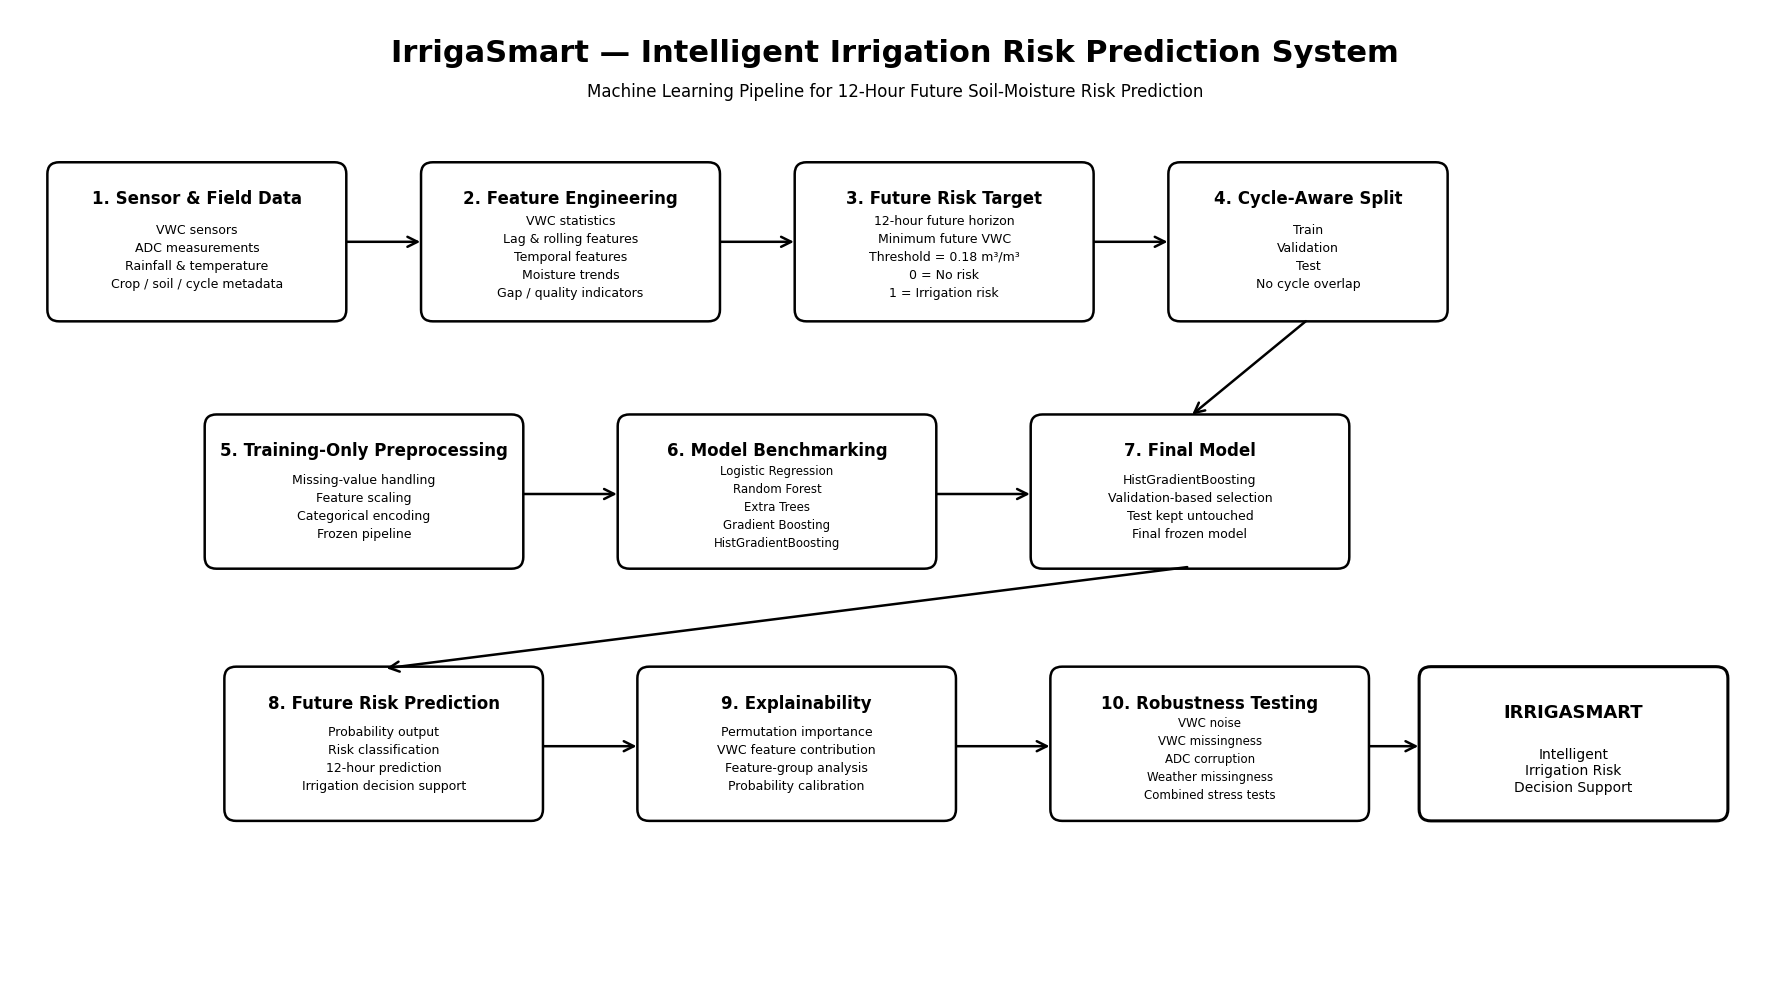

IRRIGASMART MAIN SYSTEM ARCHITECTURE
✓ Architecture diagram generated
✓ 10 major system stages represented
✓ Leakage-safe workflow represented
✓ Final model and robustness stages represented
✓ Saved to:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/thesis_results/figures/irrigasmart_main_system_architecture.png


In [ ]:
# ============================================================
# IrrigaSmart — Main System Architecture
# Cell 2: Core Project Diagram
# ============================================================

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(18, 10))

ax.set_xlim(0, 18)
ax.set_ylim(0, 10)
ax.axis("off")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def add_box(x, y, w, h, title, lines, fontsize=10):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        linewidth=1.8,
        fill=False
    )
    ax.add_patch(box)

    ax.text(
        x + w/2,
        y + h - 0.35,
        title,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        x + w/2,
        y + h/2 - 0.15,
        "\n".join(lines),
        ha="center",
        va="center",
        fontsize=fontsize,
        linespacing=1.5
    )


def add_arrow(x1, y1, x2, y2):
    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=18,
        linewidth=1.8
    )
    ax.add_patch(arrow)


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.text(
    9, 9.55,
    "IrrigaSmart — Intelligent Irrigation Risk Prediction System",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold"
)

ax.text(
    9, 9.15,
    "Machine Learning Pipeline for 12-Hour Future Soil-Moisture Risk Prediction",
    ha="center",
    va="center",
    fontsize=12
)


# ------------------------------------------------------------
# Stage 1 — Data
# ------------------------------------------------------------

add_box(
    0.4, 6.8, 3.0, 1.6,
    "1. Sensor & Field Data",
    [
        "VWC sensors",
        "ADC measurements",
        "Rainfall & temperature",
        "Crop / soil / cycle metadata"
    ],
    fontsize=9
)


# ------------------------------------------------------------
# Stage 2 — Feature Engineering
# ------------------------------------------------------------

add_box(
    4.2, 6.8, 3.0, 1.6,
    "2. Feature Engineering",
    [
        "VWC statistics",
        "Lag & rolling features",
        "Temporal features",
        "Moisture trends",
        "Gap / quality indicators"
    ],
    fontsize=9
)


# ------------------------------------------------------------
# Stage 3 — Target Construction
# ------------------------------------------------------------

add_box(
    8.0, 6.8, 3.0, 1.6,
    "3. Future Risk Target",
    [
        "12-hour future horizon",
        "Minimum future VWC",
        "Threshold = 0.18 m³/m³",
        "0 = No risk",
        "1 = Irrigation risk"
    ],
    fontsize=9
)


# ------------------------------------------------------------
# Stage 4 — Leakage-safe split
# ------------------------------------------------------------

add_box(
    11.8, 6.8, 2.8, 1.6,
    "4. Cycle-Aware Split",
    [
        "Train",
        "Validation",
        "Test",
        "No cycle overlap"
    ],
    fontsize=9
)


# Arrows top row
add_arrow(3.4, 7.6, 4.2, 7.6)
add_arrow(7.2, 7.6, 8.0, 7.6)
add_arrow(11.0, 7.6, 11.8, 7.6)


# ------------------------------------------------------------
# Stage 5 — Preprocessing
# ------------------------------------------------------------

add_box(
    2.0, 4.25, 3.2, 1.55,
    "5. Training-Only Preprocessing",
    [
        "Missing-value handling",
        "Feature scaling",
        "Categorical encoding",
        "Frozen pipeline"
    ],
    fontsize=9
)


# ------------------------------------------------------------
# Stage 6 — Model Benchmarking
# ------------------------------------------------------------

add_box(
    6.2, 4.25, 3.2, 1.55,
    "6. Model Benchmarking",
    [
        "Logistic Regression",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting",
        "HistGradientBoosting"
    ],
    fontsize=8.5
)


# ------------------------------------------------------------
# Stage 7 — Model Selection
# ------------------------------------------------------------

add_box(
    10.4, 4.25, 3.2, 1.55,
    "7. Final Model",
    [
        "HistGradientBoosting",
        "Validation-based selection",
        "Test kept untouched",
        "Final frozen model"
    ],
    fontsize=9
)


# Arrows middle
add_arrow(13.2, 6.8, 12.0, 5.8)
add_arrow(5.2, 5.0, 6.2, 5.0)
add_arrow(9.4, 5.0, 10.4, 5.0)


# ------------------------------------------------------------
# Stage 8 — Final Prediction
# ------------------------------------------------------------

add_box(
    2.2, 1.65, 3.2, 1.55,
    "8. Future Risk Prediction",
    [
        "Probability output",
        "Risk classification",
        "12-hour prediction",
        "Irrigation decision support"
    ],
    fontsize=9
)


# ------------------------------------------------------------
# Stage 9 — Explainability
# ------------------------------------------------------------

add_box(
    6.4, 1.65, 3.2, 1.55,
    "9. Explainability",
    [
        "Permutation importance",
        "VWC feature contribution",
        "Feature-group analysis",
        "Probability calibration"
    ],
    fontsize=9
)


# ------------------------------------------------------------
# Stage 10 — Robustness
# ------------------------------------------------------------

add_box(
    10.6, 1.65, 3.2, 1.55,
    "10. Robustness Testing",
    [
        "VWC noise",
        "VWC missingness",
        "ADC corruption",
        "Weather missingness",
        "Combined stress tests"
    ],
    fontsize=8.5
)


# Arrows bottom
add_arrow(12.0, 4.25, 3.8, 3.2)
add_arrow(5.4, 2.4, 6.4, 2.4)
add_arrow(9.6, 2.4, 10.6, 2.4)


# ------------------------------------------------------------
# Final outcome
# ------------------------------------------------------------

outcome = FancyBboxPatch(
    (14.35, 1.65), 3.1, 1.55,
    boxstyle="round,pad=0.02,rounding_size=0.12",
    linewidth=2.2,
    fill=False
)

ax.add_patch(outcome)

ax.text(
    15.9, 2.75,
    "IRRIGASMART",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

ax.text(
    15.9, 2.15,
    "Intelligent\nIrrigation Risk\nDecision Support",
    ha="center",
    va="center",
    fontsize=10
)

add_arrow(13.8, 2.4, 14.35, 2.4)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

diagram_path = (
    "/content/drive/MyDrive/IrrigaSmart/"
    "data/processed/models/thesis_results/"
    "figures/irrigasmart_main_system_architecture.png"
)

import os
os.makedirs(os.path.dirname(diagram_path), exist_ok=True)

plt.tight_layout()
plt.savefig(
    diagram_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("IRRIGASMART MAIN SYSTEM ARCHITECTURE")
print("=" * 70)
print("✓ Architecture diagram generated")
print("✓ 10 major system stages represented")
print("✓ Leakage-safe workflow represented")
print("✓ Final model and robustness stages represented")
print(f"✓ Saved to:\n{diagram_path}")

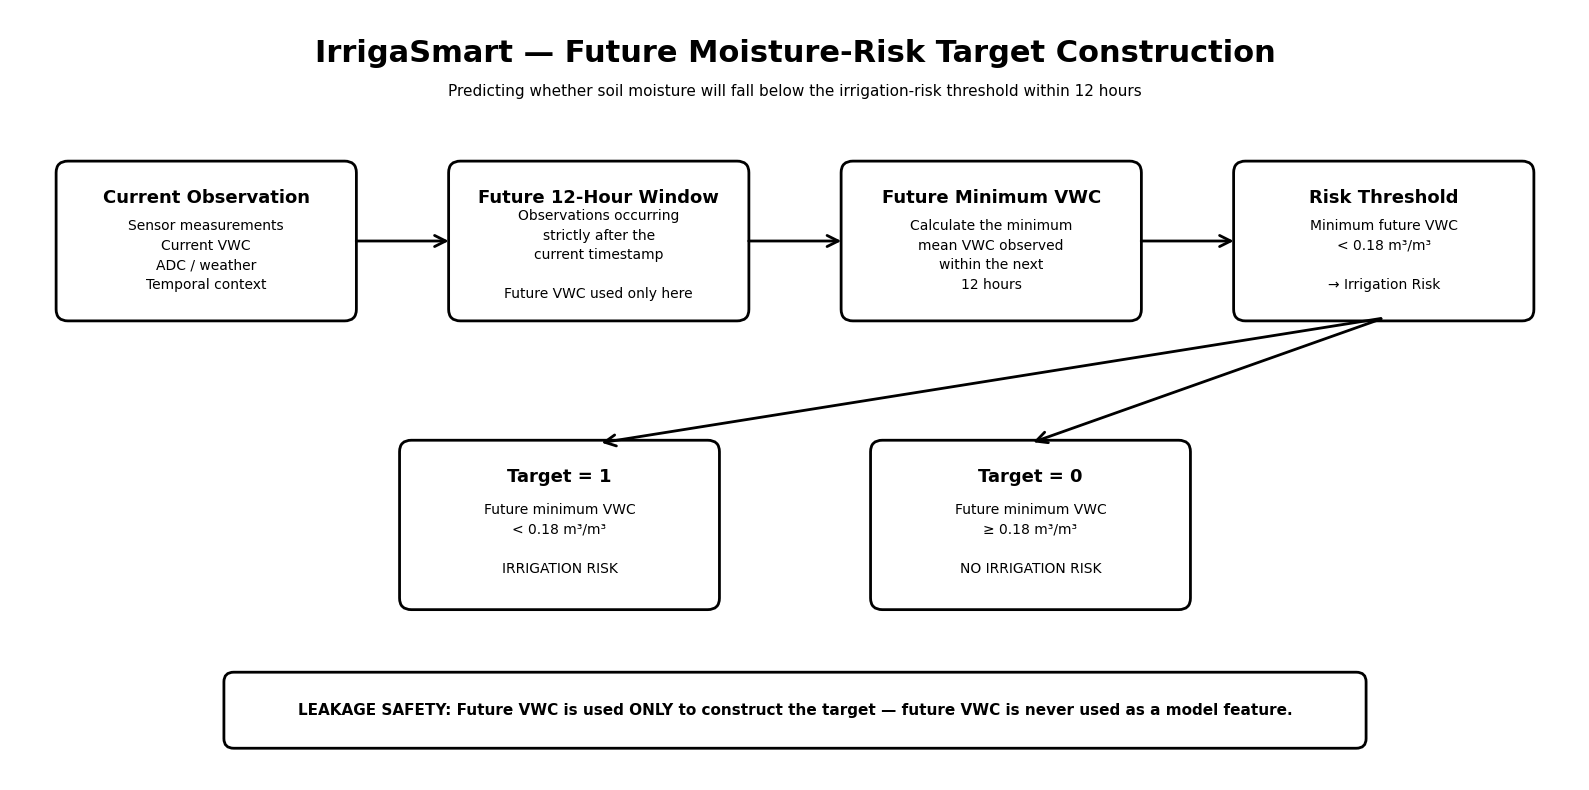

TARGET CONSTRUCTION DIAGRAM
✓ Future 12-hour horizon represented
✓ 0.18 m³/m³ threshold represented
✓ Risk / no-risk outcomes represented
✓ Leakage protection explicitly represented
✓ Saved to:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/thesis_results/figures/irrigasmart_target_construction_diagram.png


In [ ]:
import os

# ============================================================
# IrrigaSmart — Future Moisture-Risk Target Construction
# Diagram 2
# ============================================================

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.pyplot as plt
import os

fig, ax = plt.subplots(figsize=(16, 8))

ax.set_xlim(0, 16)
ax.set_ylim(0, 8)
ax.axis("off")


def box(x, y, w, h, title, text):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.12",
        linewidth=2,
        fill=False
    )
    ax.add_patch(patch)

    ax.text(
        x + w/2,
        y + h - 0.35,
        title,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )

    ax.text(
        x + w/2,
        y + h/2 - 0.15,
        text,
        ha="center",
        va="center",
        fontsize=10,
        linespacing=1.5
    )


def arrow(x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=20,
            linewidth=2
        )
    )


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.text(
    8, 7.55,
    "IrrigaSmart — Future Moisture-Risk Target Construction",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold"
)

ax.text(
    8, 7.15,
    "Predicting whether soil moisture will fall below the irrigation-risk threshold within 12 hours",
    ha="center",
    va="center",
    fontsize=11
)


# ------------------------------------------------------------
# Current observation
# ------------------------------------------------------------

box(
    0.5, 4.8, 3.0, 1.6,
    "Current Observation",
    "Sensor measurements\n"
    "Current VWC\n"
    "ADC / weather\n"
    "Temporal context"
)


# ------------------------------------------------------------
# Future window
# ------------------------------------------------------------

box(
    4.5, 4.8, 3.0, 1.6,
    "Future 12-Hour Window",
    "Observations occurring\n"
    "strictly after the\n"
    "current timestamp\n"
    "\nFuture VWC used only here"
)


# ------------------------------------------------------------
# Future minimum
# ------------------------------------------------------------

box(
    8.5, 4.8, 3.0, 1.6,
    "Future Minimum VWC",
    "Calculate the minimum\n"
    "mean VWC observed\n"
    "within the next\n"
    "12 hours"
)


# ------------------------------------------------------------
# Threshold
# ------------------------------------------------------------

box(
    12.5, 4.8, 3.0, 1.6,
    "Risk Threshold",
    "Minimum future VWC\n"
    "< 0.18 m³/m³\n"
    "\n→ Irrigation Risk"
)


# arrows
arrow(3.5, 5.6, 4.5, 5.6)
arrow(7.5, 5.6, 8.5, 5.6)
arrow(11.5, 5.6, 12.5, 5.6)


# ------------------------------------------------------------
# Target outcomes
# ------------------------------------------------------------

box(
    4.0, 1.8, 3.2, 1.7,
    "Target = 1",
    "Future minimum VWC\n"
    "< 0.18 m³/m³\n\n"
    "IRRIGATION RISK"
)

box(
    8.8, 1.8, 3.2, 1.7,
    "Target = 0",
    "Future minimum VWC\n"
    "≥ 0.18 m³/m³\n\n"
    "NO IRRIGATION RISK"
)

arrow(14.0, 4.8, 6.0, 3.5)
arrow(14.0, 4.8, 10.4, 3.5)


# ------------------------------------------------------------
# Leakage protection
# ------------------------------------------------------------

leakage = FancyBboxPatch(
    (2.2, 0.35), 11.6, 0.75,
    boxstyle="round,pad=0.02,rounding_size=0.1",
    linewidth=2,
    fill=False
)

ax.add_patch(leakage)

ax.text(
    8, 0.72,
    "LEAKAGE SAFETY: Future VWC is used ONLY to construct the target — "
    "future VWC is never used as a model feature.",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold"
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

path = (
    "/content/drive/MyDrive/IrrigaSmart/"
    "data/processed/models/thesis_results/figures/"
    "irrigasmart_target_construction_diagram.png"
)

os.makedirs(os.path.dirname(path), exist_ok=True)

plt.tight_layout()
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("=" * 70)
print("TARGET CONSTRUCTION DIAGRAM")
print("=" * 70)
print("✓ Future 12-hour horizon represented")
print("✓ 0.18 m³/m³ threshold represented")
print("✓ Risk / no-risk outcomes represented")
print("✓ Leakage protection explicitly represented")
print(f"✓ Saved to:\n{path}")

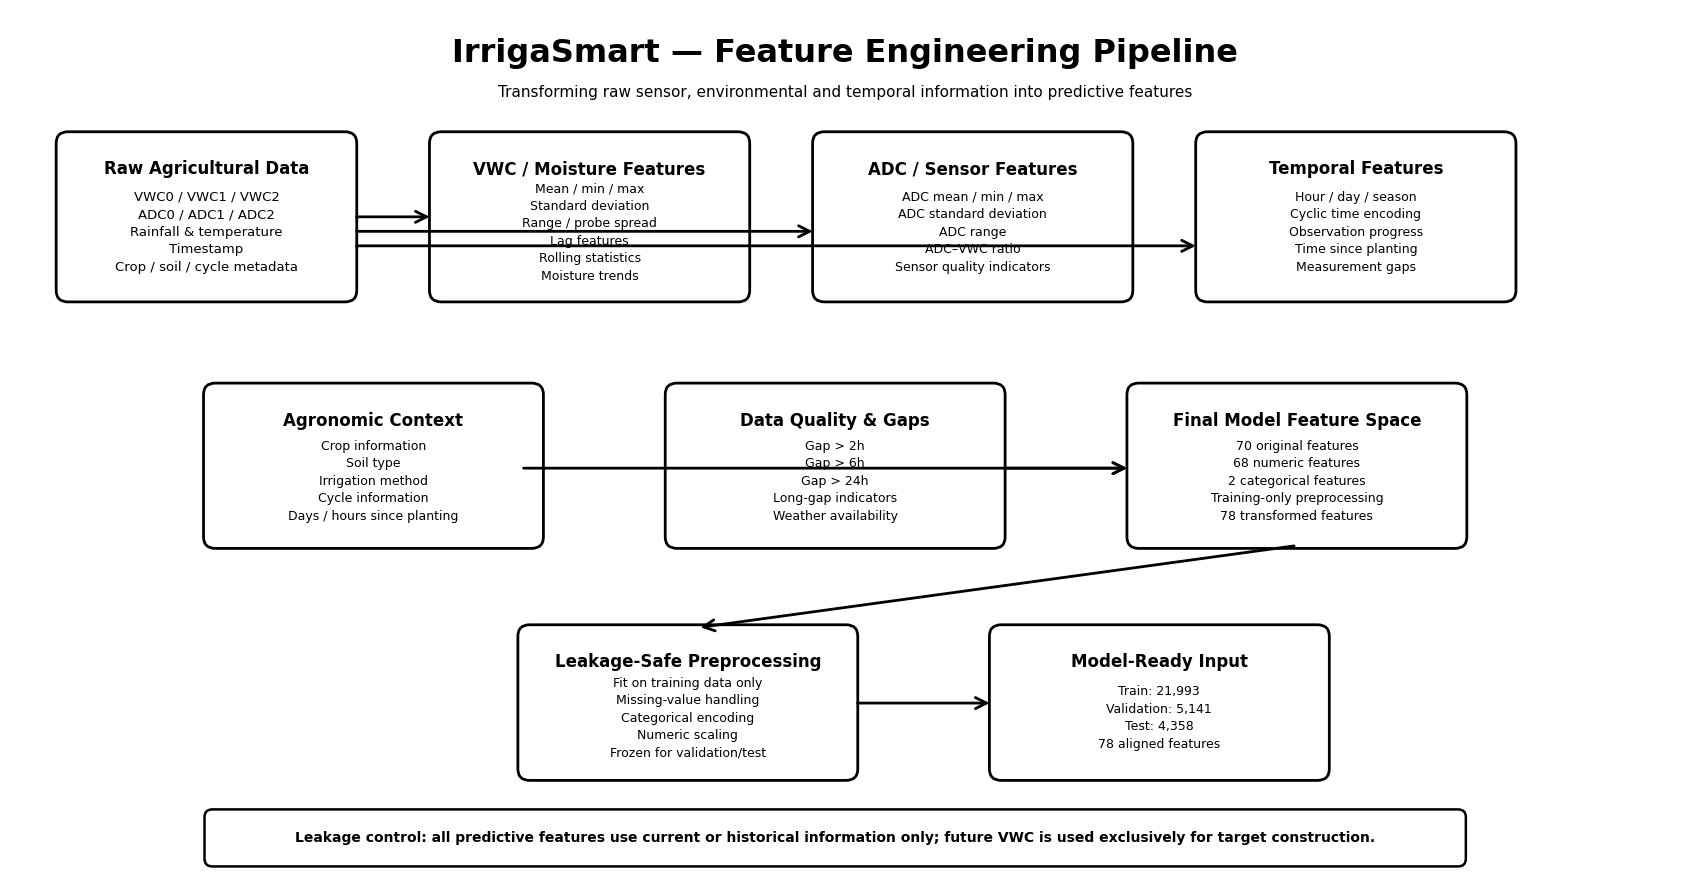

FEATURE ENGINEERING DIAGRAM
✓ Raw sensor and agricultural inputs represented
✓ VWC, ADC, temporal and agronomic feature groups represented
✓ 70 original features represented
✓ 78 transformed model features represented
✓ Leakage-safe preprocessing represented
✓ Saved to:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/thesis_results/figures/irrigasmart_feature_engineering_diagram.png


In [ ]:
# ============================================================
# IrrigaSmart — Feature Engineering Pipeline
# Diagram 3
# ============================================================

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.pyplot as plt
import os

fig, ax = plt.subplots(figsize=(17, 9))

ax.set_xlim(0, 17)
ax.set_ylim(0, 9)
ax.axis("off")


def add_box(x, y, w, h, title, lines, fontsize=9.5):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.12",
        linewidth=2,
        fill=False
    )
    ax.add_patch(patch)

    ax.text(
        x + w / 2,
        y + h - 0.35,
        title,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        x + w / 2,
        y + h / 2 - 0.15,
        "\n".join(lines),
        ha="center",
        va="center",
        fontsize=fontsize,
        linespacing=1.45
    )


def add_arrow(x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=20,
            linewidth=2
        )
    )


# ============================================================
# TITLE
# ============================================================

ax.text(
    8.5, 8.55,
    "IrrigaSmart — Feature Engineering Pipeline",
    ha="center",
    va="center",
    fontsize=23,
    fontweight="bold"
)

ax.text(
    8.5, 8.15,
    "Transforming raw sensor, environmental and temporal information into predictive features",
    ha="center",
    va="center",
    fontsize=11
)


# ============================================================
# RAW DATA
# ============================================================

add_box(
    0.5, 6.0, 3.0, 1.7,
    "Raw Agricultural Data",
    [
        "VWC0 / VWC1 / VWC2",
        "ADC0 / ADC1 / ADC2",
        "Rainfall & temperature",
        "Timestamp",
        "Crop / soil / cycle metadata"
    ]
)


# ============================================================
# VWC FEATURES
# ============================================================

add_box(
    4.3, 6.0, 3.2, 1.7,
    "VWC / Moisture Features",
    [
        "Mean / min / max",
        "Standard deviation",
        "Range / probe spread",
        "Lag features",
        "Rolling statistics",
        "Moisture trends"
    ],
    fontsize=9
)


# ============================================================
# SENSOR FEATURES
# ============================================================

add_box(
    8.2, 6.0, 3.2, 1.7,
    "ADC / Sensor Features",
    [
        "ADC mean / min / max",
        "ADC standard deviation",
        "ADC range",
        "ADC–VWC ratio",
        "Sensor quality indicators"
    ],
    fontsize=9
)


# ============================================================
# TEMPORAL FEATURES
# ============================================================

add_box(
    12.1, 6.0, 3.2, 1.7,
    "Temporal Features",
    [
        "Hour / day / season",
        "Cyclic time encoding",
        "Observation progress",
        "Time since planting",
        "Measurement gaps"
    ],
    fontsize=9
)


# ============================================================
# TOP ARROWS
# ============================================================

add_arrow(3.5, 6.85, 4.3, 6.85)
add_arrow(3.5, 6.7, 8.2, 6.7)
add_arrow(3.5, 6.55, 12.1, 6.55)


# ============================================================
# CONTEXT FEATURES
# ============================================================

add_box(
    2.0, 3.45, 3.4, 1.65,
    "Agronomic Context",
    [
        "Crop information",
        "Soil type",
        "Irrigation method",
        "Cycle information",
        "Days / hours since planting"
    ],
    fontsize=9
)


# ============================================================
# GAP / QUALITY
# ============================================================

add_box(
    6.7, 3.45, 3.4, 1.65,
    "Data Quality & Gaps",
    [
        "Gap > 2h",
        "Gap > 6h",
        "Gap > 24h",
        "Long-gap indicators",
        "Weather availability"
    ],
    fontsize=9
)


# ============================================================
# FINAL FEATURE SPACE
# ============================================================

add_box(
    11.4, 3.45, 3.4, 1.65,
    "Final Model Feature Space",
    [
        "70 original features",
        "68 numeric features",
        "2 categorical features",
        "Training-only preprocessing",
        "78 transformed features"
    ],
    fontsize=9
)


# ============================================================
# ARROWS TO FINAL FEATURE SPACE
# ============================================================

add_arrow(5.2, 4.25, 11.4, 4.25)
add_arrow(10.1, 4.25, 11.4, 4.25)


# ============================================================
# PREPROCESSING
# ============================================================

add_box(
    5.2, 1.05, 3.4, 1.55,
    "Leakage-Safe Preprocessing",
    [
        "Fit on training data only",
        "Missing-value handling",
        "Categorical encoding",
        "Numeric scaling",
        "Frozen for validation/test"
    ],
    fontsize=9
)


# ============================================================
# MODEL INPUT
# ============================================================

add_box(
    10.0, 1.05, 3.4, 1.55,
    "Model-Ready Input",
    [
        "Train: 21,993",
        "Validation: 5,141",
        "Test: 4,358",
        "78 aligned features"
    ],
    fontsize=9
)


add_arrow(13.1, 3.45, 7.0, 2.6)
add_arrow(8.6, 1.82, 10.0, 1.82)


# ============================================================
# LEAKAGE NOTE
# ============================================================

note = FancyBboxPatch(
    (2.0, 0.15), 12.8, 0.55,
    boxstyle="round,pad=0.02,rounding_size=0.08",
    linewidth=1.8,
    fill=False
)

ax.add_patch(note)

ax.text(
    8.4, 0.43,
    "Leakage control: all predictive features use current or historical information only; "
    "future VWC is used exclusively for target construction.",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)


# ============================================================
# SAVE
# ============================================================

path = (
    "/content/drive/MyDrive/IrrigaSmart/"
    "data/processed/models/thesis_results/figures/"
    "irrigasmart_feature_engineering_diagram.png"
)

os.makedirs(os.path.dirname(path), exist_ok=True)

plt.tight_layout()
plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("FEATURE ENGINEERING DIAGRAM")
print("=" * 70)
print("✓ Raw sensor and agricultural inputs represented")
print("✓ VWC, ADC, temporal and agronomic feature groups represented")
print("✓ 70 original features represented")
print("✓ 78 transformed model features represented")
print("✓ Leakage-safe preprocessing represented")
print(f"✓ Saved to:\n{path}")

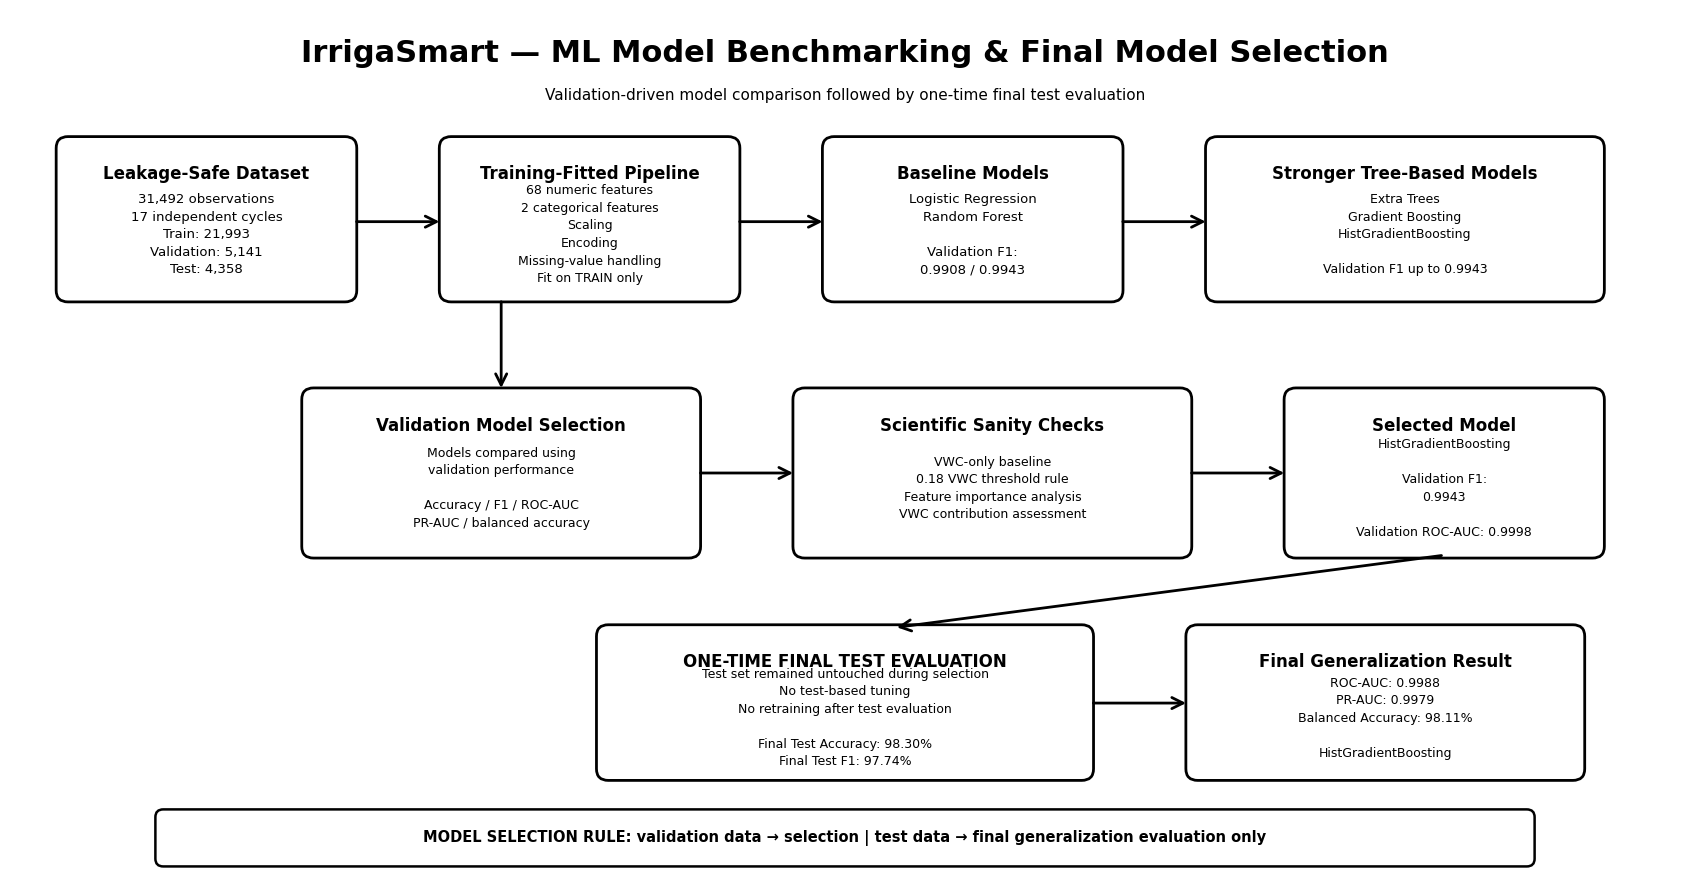

MODEL BENCHMARKING & SELECTION DIAGRAM
✓ Leakage-safe train/validation/test workflow represented
✓ Baseline models represented
✓ Stronger models represented
✓ Validation-driven selection represented
✓ HistGradientBoosting represented as selected model
✓ One-time test evaluation represented
✓ Final test metrics included
✓ Saved to:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/thesis_results/figures/irrigasmart_model_selection_diagram.png


In [ ]:
# ============================================================
# IrrigaSmart — ML Model Benchmarking & Final Model Selection
# Diagram 4
# ============================================================

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.pyplot as plt
import os

fig, ax = plt.subplots(figsize=(17, 9))

ax.set_xlim(0, 17)
ax.set_ylim(0, 9)
ax.axis("off")


def add_box(x, y, w, h, title, lines, fontsize=9.5):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.12",
        linewidth=2,
        fill=False
    )
    ax.add_patch(patch)

    ax.text(
        x + w / 2,
        y + h - 0.35,
        title,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        x + w / 2,
        y + h / 2 - 0.15,
        "\n".join(lines),
        ha="center",
        va="center",
        fontsize=fontsize,
        linespacing=1.45
    )


def add_arrow(x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=20,
            linewidth=2
        )
    )


# ============================================================
# TITLE
# ============================================================

ax.text(
    8.5, 8.55,
    "IrrigaSmart — ML Model Benchmarking & Final Model Selection",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold"
)

ax.text(
    8.5, 8.12,
    "Validation-driven model comparison followed by one-time final test evaluation",
    ha="center",
    va="center",
    fontsize=11
)


# ============================================================
# DATA
# ============================================================

add_box(
    0.5, 6.0, 3.0, 1.65,
    "Leakage-Safe Dataset",
    [
        "31,492 observations",
        "17 independent cycles",
        "Train: 21,993",
        "Validation: 5,141",
        "Test: 4,358"
    ]
)


# ============================================================
# PREPROCESSING
# ============================================================

add_box(
    4.4, 6.0, 3.0, 1.65,
    "Training-Fitted Pipeline",
    [
        "68 numeric features",
        "2 categorical features",
        "Scaling",
        "Encoding",
        "Missing-value handling",
        "Fit on TRAIN only"
    ],
    fontsize=9
)

add_arrow(3.5, 6.8, 4.4, 6.8)


# ============================================================
# BASELINE MODELS
# ============================================================

add_box(
    8.3, 6.0, 3.0, 1.65,
    "Baseline Models",
    [
        "Logistic Regression",
        "Random Forest",
        "",
        "Validation F1:",
        "0.9908 / 0.9943"
    ],
    fontsize=9.5
)

add_arrow(7.4, 6.8, 8.3, 6.8)


# ============================================================
# STRONGER MODELS
# ============================================================

add_box(
    12.2, 6.0, 4.0, 1.65,
    "Stronger Tree-Based Models",
    [
        "Extra Trees",
        "Gradient Boosting",
        "HistGradientBoosting",
        "",
        "Validation F1 up to 0.9943"
    ],
    fontsize=9
)

add_arrow(11.3, 6.8, 12.2, 6.8)


# ============================================================
# VALIDATION SELECTION
# ============================================================

add_box(
    3.0, 3.35, 4.0, 1.7,
    "Validation Model Selection",
    [
        "Models compared using",
        "validation performance",
        "",
        "Accuracy / F1 / ROC-AUC",
        "PR-AUC / balanced accuracy"
    ],
    fontsize=9
)


# ============================================================
# SANITY CHECK
# ============================================================

add_box(
    8.0, 3.35, 4.0, 1.7,
    "Scientific Sanity Checks",
    [
        "VWC-only baseline",
        "0.18 VWC threshold rule",
        "Feature importance analysis",
        "VWC contribution assessment"
    ],
    fontsize=9
)


# ============================================================
# FINAL MODEL
# ============================================================

add_box(
    13.0, 3.35, 3.2, 1.7,
    "Selected Model",
    [
        "HistGradientBoosting",
        "",
        "Validation F1:",
        "0.9943",
        "",
        "Validation ROC-AUC: 0.9998"
    ],
    fontsize=9
)


add_arrow(5.0, 6.0, 5.0, 5.05)
add_arrow(7.0, 4.2, 8.0, 4.2)
add_arrow(12.0, 4.2, 13.0, 4.2)


# ============================================================
# LOCKED TEST
# ============================================================

add_box(
    6.0, 1.05, 5.0, 1.55,
    "ONE-TIME FINAL TEST EVALUATION",
    [
        "Test set remained untouched during selection",
        "No test-based tuning",
        "No retraining after test evaluation",
        "",
        "Final Test Accuracy: 98.30%",
        "Final Test F1: 97.74%"
    ],
    fontsize=9
)


add_arrow(14.6, 3.35, 9.0, 2.6)


# ============================================================
# FINAL RESULT
# ============================================================

add_box(
    12.0, 1.05, 4.0, 1.55,
    "Final Generalization Result",
    [
        "ROC-AUC: 0.9988",
        "PR-AUC: 0.9979",
        "Balanced Accuracy: 98.11%",
        "",
        "HistGradientBoosting"
    ],
    fontsize=9
)

add_arrow(11.0, 1.82, 12.0, 1.82)


# ============================================================
# LEAKAGE CONTROL NOTE
# ============================================================

note = FancyBboxPatch(
    (1.5, 0.15), 14.0, 0.55,
    boxstyle="round,pad=0.02,rounding_size=0.08",
    linewidth=1.8,
    fill=False
)

ax.add_patch(note)

ax.text(
    8.5, 0.43,
    "MODEL SELECTION RULE: validation data → selection | test data → final generalization evaluation only",
    ha="center",
    va="center",
    fontsize=10.5,
    fontweight="bold"
)


# ============================================================
# SAVE
# ============================================================

path = (
    "/content/drive/MyDrive/IrrigaSmart/"
    "data/processed/models/thesis_results/figures/"
    "irrigasmart_model_selection_diagram.png"
)

os.makedirs(os.path.dirname(path), exist_ok=True)

plt.tight_layout()
plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("MODEL BENCHMARKING & SELECTION DIAGRAM")
print("=" * 70)
print("✓ Leakage-safe train/validation/test workflow represented")
print("✓ Baseline models represented")
print("✓ Stronger models represented")
print("✓ Validation-driven selection represented")
print("✓ HistGradientBoosting represented as selected model")
print("✓ One-time test evaluation represented")
print("✓ Final test metrics included")
print(f"✓ Saved to:\n{path}")

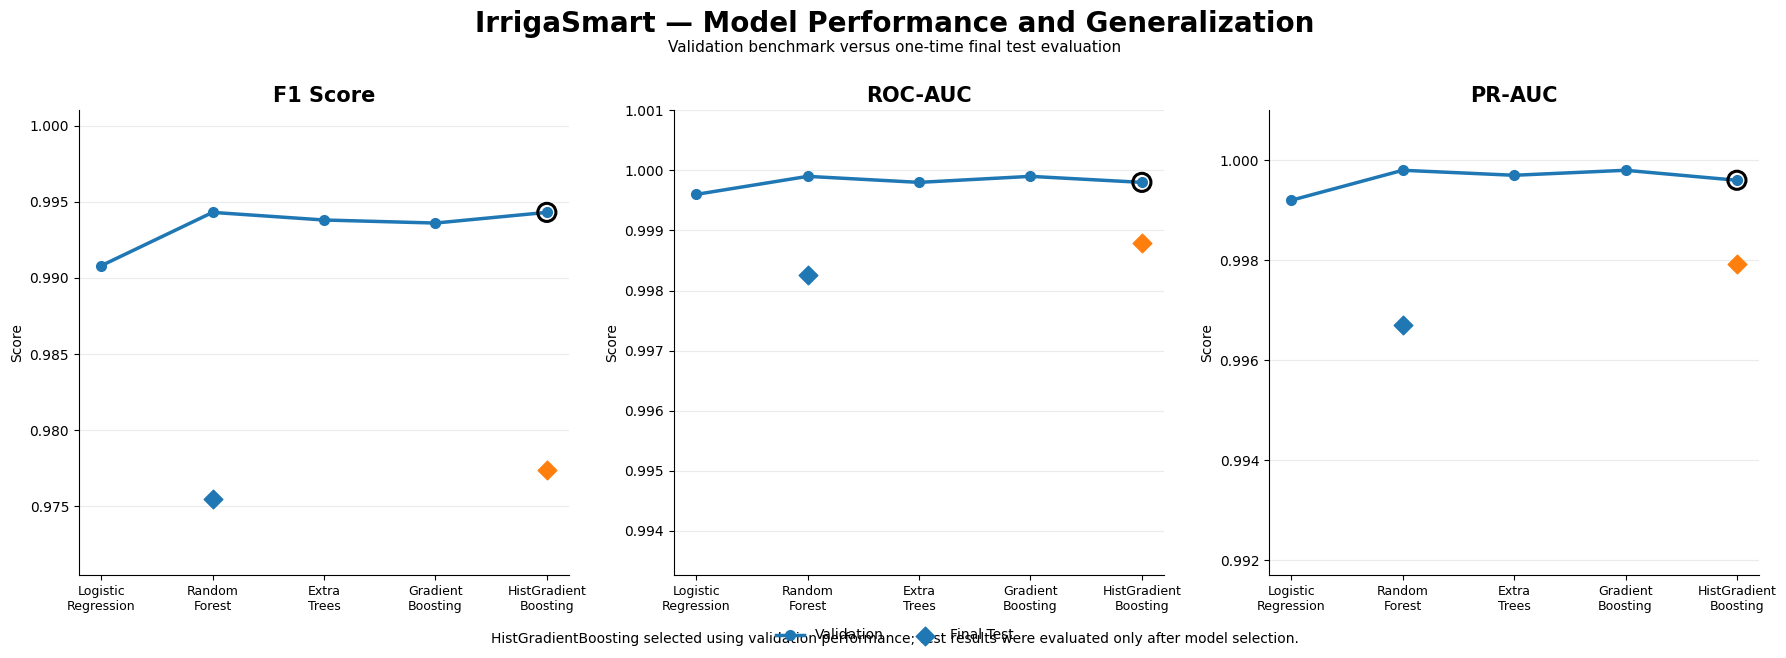

PROFESSIONAL ML PERFORMANCE FIGURE
✓ Validation model benchmark plotted
✓ Final test performance plotted
✓ F1 / ROC-AUC / PR-AUC compared
✓ HistGradientBoosting highlighted
✓ Validation → test generalization shown
✓ Saved to:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/thesis_results/figures/irrigasmart_ml_performance_generalization.png


In [ ]:
# ============================================================
# IrrigaSmart — Professional ML Model Performance Figure
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed/models"
FIG_DIR = os.path.join(
    BASE_DIR,
    "thesis_results",
    "figures"
)

os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------
# VALIDATION RESULTS
# ------------------------------------------------------------

validation = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting",
        "HistGradientBoosting"
    ],
    "F1": [
        0.9908,
        0.9943,
        0.9938,
        0.9936,
        0.9943
    ],
    "ROC-AUC": [
        0.9996,
        0.9999,
        0.9998,
        0.9999,
        0.9998
    ],
    "PR-AUC": [
        0.9992,
        0.9998,
        0.9997,
        0.9998,
        0.9996
    ]
})

# ------------------------------------------------------------
# FINAL TEST RESULTS
# ------------------------------------------------------------

test = pd.DataFrame({
    "Model": [
        "Random Forest",
        "HistGradientBoosting"
    ],
    "F1": [
        0.975490,
        0.977384
    ],
    "ROC-AUC": [
        0.998261,
        0.998796
    ],
    "PR-AUC": [
        0.996701,
        0.997918
    ]
})

# ------------------------------------------------------------
# PREPARE SELECTED MODELS
# ------------------------------------------------------------

models = [
    "Logistic Regression",
    "Random Forest",
    "Extra Trees",
    "Gradient Boosting",
    "HistGradientBoosting"
]

val_map = validation.set_index("Model")

val_f1 = [val_map.loc[m, "F1"] for m in models]
val_roc = [val_map.loc[m, "ROC-AUC"] for m in models]
val_pr = [val_map.loc[m, "PR-AUC"] for m in models]

test_map = test.set_index("Model")

test_models = [
    "Random Forest",
    "HistGradientBoosting"
]

test_f1 = [test_map.loc[m, "F1"] for m in test_models]
test_roc = [test_map.loc[m, "ROC-AUC"] for m in test_models]
test_pr = [test_map.loc[m, "PR-AUC"] for m in test_models]

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

metrics = [
    ("F1 Score", val_f1, test_f1),
    ("ROC-AUC", val_roc, test_roc),
    ("PR-AUC", val_pr, test_pr)
]

x_val = np.arange(len(models))

for ax, (metric_name, val_values, test_values) in zip(
    axes,
    metrics
):

    # Validation performance
    ax.plot(
        x_val,
        val_values,
        marker="o",
        linewidth=2.5,
        markersize=7,
        label="Validation"
    )

    # Test points only for models actually evaluated on test
    for model, value in zip(test_models, test_values):

        idx = models.index(model)

        ax.scatter(
            idx,
            value,
            s=90,
            marker="D",
            zorder=5,
            label="Final Test" if model == test_models[0] else None
        )

    # Highlight final selected model
    selected_idx = models.index("HistGradientBoosting")
    selected_val = val_values[selected_idx]

    ax.scatter(
        selected_idx,
        selected_val,
        s=170,
        facecolors="none",
        edgecolors="black",
        linewidths=2.2,
        zorder=6
    )

    ax.set_title(
        metric_name,
        fontsize=15,
        fontweight="bold"
    )

    ax.set_xticks(x_val)
    ax.set_xticklabels(
        [
            "Logistic\nRegression",
            "Random\nForest",
            "Extra\nTrees",
            "Gradient\nBoosting",
            "HistGradient\nBoosting"
        ],
        fontsize=9
    )

    ax.set_ylim(
        min(min(val_values), min(test_values)) - 0.005,
        1.001
    )

    ax.set_ylabel(
        "Score",
        fontsize=10
    )

    ax.grid(
        axis="y",
        alpha=0.25,
        linewidth=0.8
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ------------------------------------------------------------
# SHARED LEGEND
# ------------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=False,
    fontsize=10
)

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

fig.suptitle(
    "IrrigaSmart — Model Performance and Generalization",
    fontsize=20,
    fontweight="bold",
    y=1.03
)

fig.text(
    0.5,
    0.96,
    "Validation benchmark versus one-time final test evaluation",
    ha="center",
    fontsize=11
)

fig.text(
    0.5,
    -0.025,
    "HistGradientBoosting selected using validation performance; "
    "test results were evaluated only after model selection.",
    ha="center",
    fontsize=10
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

output_path = os.path.join(
    FIG_DIR,
    "irrigasmart_ml_performance_generalization.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("PROFESSIONAL ML PERFORMANCE FIGURE")
print("=" * 70)
print("✓ Validation model benchmark plotted")
print("✓ Final test performance plotted")
print("✓ F1 / ROC-AUC / PR-AUC compared")
print("✓ HistGradientBoosting highlighted")
print("✓ Validation → test generalization shown")
print(f"✓ Saved to:\n{output_path}")

IRRIGASMART — FEATURE IMPORTANCE VISUALIZATION
Loaded feature importance rows: 78
Loaded feature groups: 5


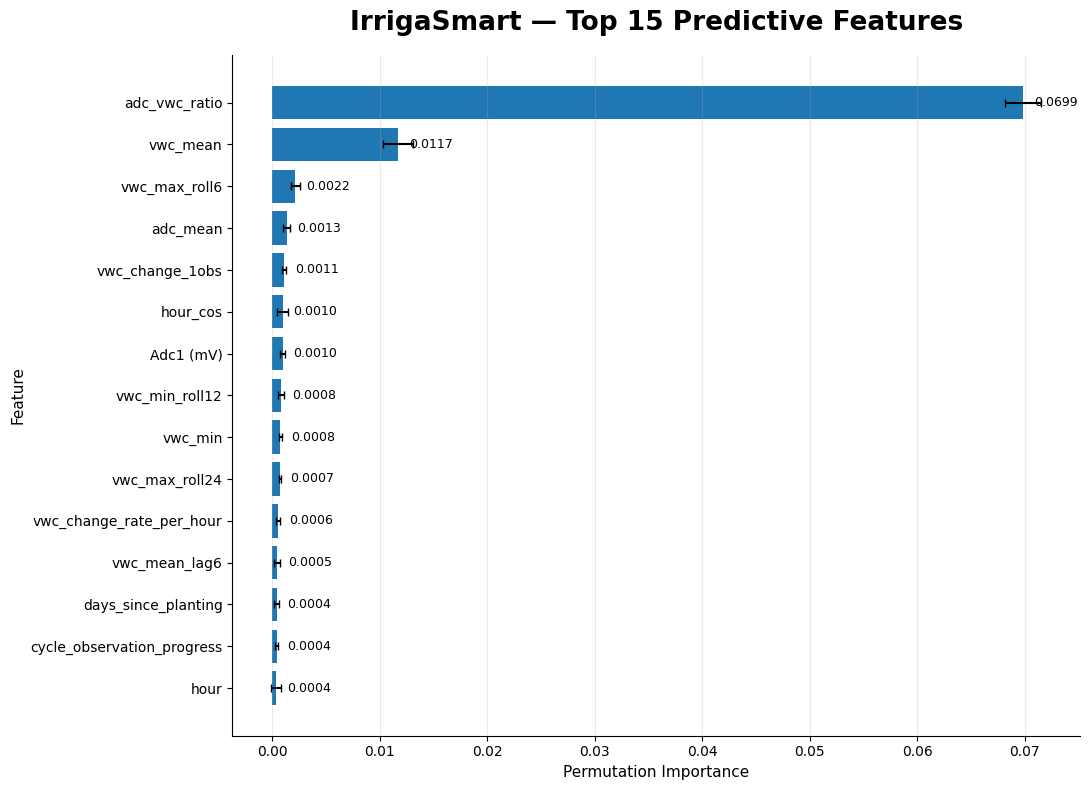

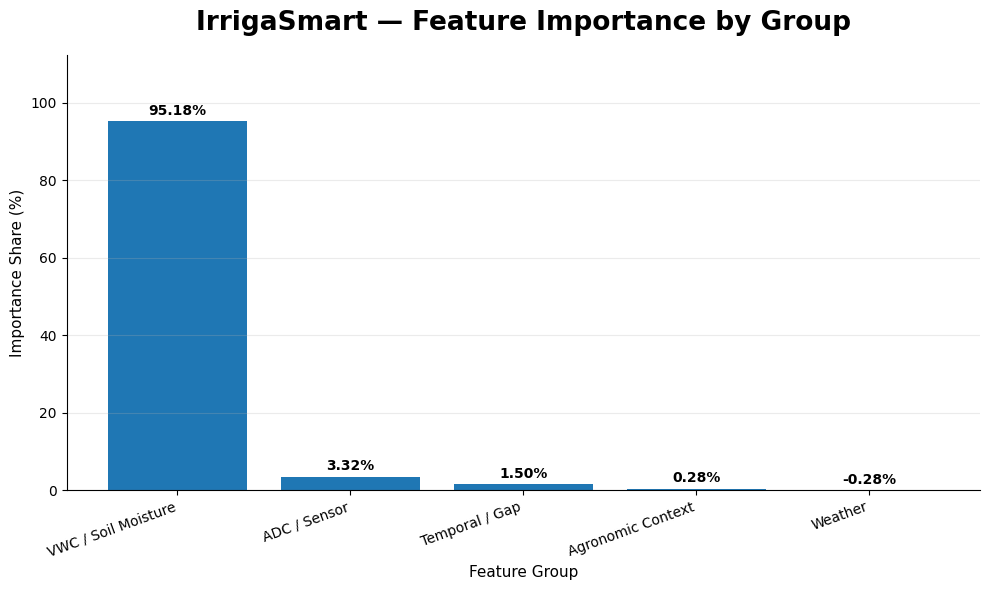

FEATURE IMPORTANCE VISUALIZATION VALIDATION
importance_data_loaded: PASS ✓
top15_features_available: PASS ✓
feature_groups_available: PASS ✓
top15_figure_saved: PASS ✓
group_importance_figure_saved: PASS ✓

VWC / Soil Moisture importance share:
95.18%

✓ FEATURE IMPORTANCE VISUALIZATION COMPLETE
Top 15 figure:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/thesis_results/figures/irrigasmart_top15_feature_importance.png
Feature group figure:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/thesis_results/figures/irrigasmart_feature_group_importance.png


In [ ]:
# ============================================================
# IrrigaSmart — ML Feature Importance Analysis
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed/models"

FIG_DIR = os.path.join(
    BASE_DIR,
    "thesis_results",
    "figures"
)

os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------
# LOAD FEATURE IMPORTANCE
# ------------------------------------------------------------

importance_path = os.path.join(
    BASE_DIR,
    "final_model_permutation_importance_validation.csv"
)

group_path = os.path.join(
    BASE_DIR,
    "final_model_feature_group_importance.csv"
)

importance_df = pd.read_csv(importance_path)
group_df = pd.read_csv(group_path)

print("=" * 70)
print("IRRIGASMART — FEATURE IMPORTANCE VISUALIZATION")
print("=" * 70)

print(f"Loaded feature importance rows: {len(importance_df)}")
print(f"Loaded feature groups: {len(group_df)}")

# ------------------------------------------------------------
# TOP 15 FEATURES
# ------------------------------------------------------------

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
)

top15 = importance_df.head(15).copy()

# Remove preprocessing prefix for cleaner visualization
top15["display_name"] = (
    top15["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

# Reverse order for horizontal bar chart
top15 = top15.sort_values(
    "importance_mean",
    ascending=True
)

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 8)
)

bars = ax.barh(
    top15["display_name"],
    top15["importance_mean"],
    xerr=top15["importance_std"],
    capsize=3
)

ax.set_title(
    "IrrigaSmart — Top 15 Predictive Features",
    fontsize=19,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Permutation Importance",
    fontsize=11
)

ax.set_ylabel(
    "Feature",
    fontsize=11
)

ax.grid(
    axis="x",
    alpha=0.25,
    linewidth=0.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add values
for bar, value in zip(
    bars,
    top15["importance_mean"]
):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

top15_path = os.path.join(
    FIG_DIR,
    "irrigasmart_top15_feature_importance.png"
)

plt.savefig(
    top15_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# FEATURE GROUP IMPORTANCE
# ------------------------------------------------------------

group_df = group_df.sort_values(
    "importance_share",
    ascending=False
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    group_df["feature_group"],
    group_df["importance_share"] * 100
)

ax.set_title(
    "IrrigaSmart — Feature Importance by Group",
    fontsize=19,
    fontweight="bold",
    pad=18
)

ax.set_ylabel(
    "Importance Share (%)",
    fontsize=11
)

ax.set_xlabel(
    "Feature Group",
    fontsize=11
)

ax.set_ylim(
    0,
    max(group_df["importance_share"] * 100) * 1.18
)

ax.grid(
    axis="y",
    alpha=0.25,
    linewidth=0.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(
    rotation=20,
    ha="right"
)

for bar, value in zip(
    bars,
    group_df["importance_share"] * 100
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

group_path_out = os.path.join(
    FIG_DIR,
    "irrigasmart_feature_group_importance.png"
)

plt.savefig(
    group_path_out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("=" * 70)
print("FEATURE IMPORTANCE VISUALIZATION VALIDATION")
print("=" * 70)

assert len(importance_df) > 0
assert len(group_df) > 0

assert (
    "importance_mean" in importance_df.columns
)

assert (
    "feature_group" in group_df.columns
)

assert (
    "importance_share" in group_df.columns
)

assert os.path.exists(top15_path)
assert os.path.exists(group_path_out)

print("importance_data_loaded: PASS ✓")
print("top15_features_available: PASS ✓")
print("feature_groups_available: PASS ✓")
print("top15_figure_saved: PASS ✓")
print("group_importance_figure_saved: PASS ✓")

print()
print("VWC / Soil Moisture importance share:")
print(
    f"{group_df.loc[group_df['feature_group'] == 'VWC / Soil Moisture', 'importance_share'].iloc[0] * 100:.2f}%"
)

print()
print("=" * 70)
print("✓ FEATURE IMPORTANCE VISUALIZATION COMPLETE")
print("=" * 70)
print(f"Top 15 figure:\n{top15_path}")
print(f"Feature group figure:\n{group_path_out}")

IRRIGASMART — ROBUSTNESS STRESS-TEST VISUALIZATION
✓ VWC noise results loaded
✓ VWC missingness results loaded
✓ ADC corruption results loaded


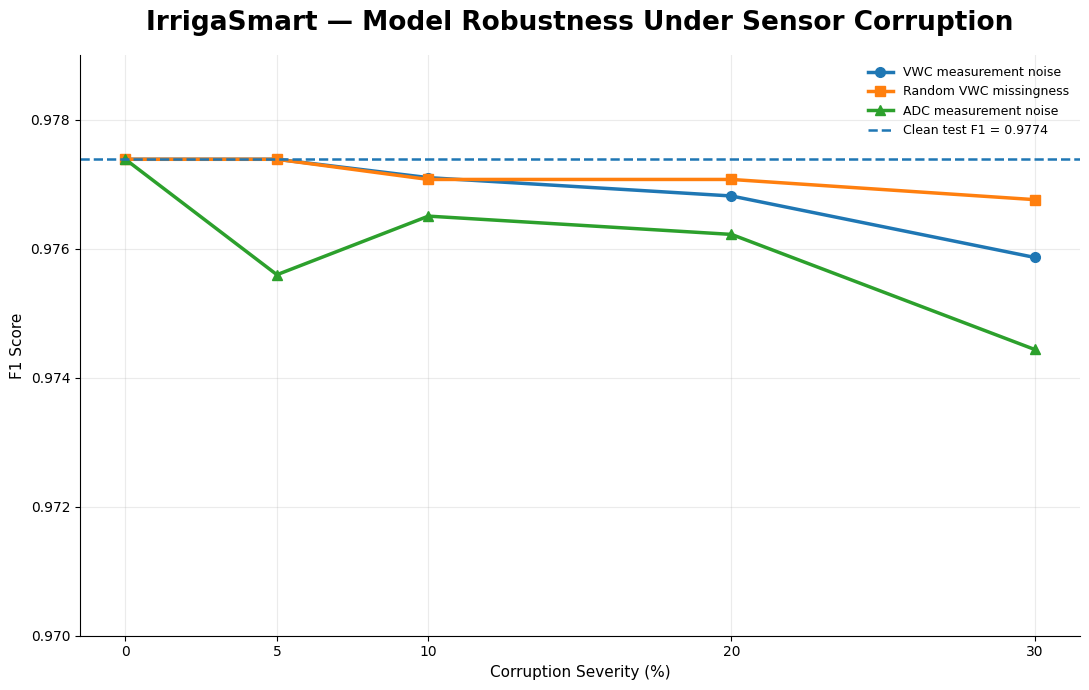

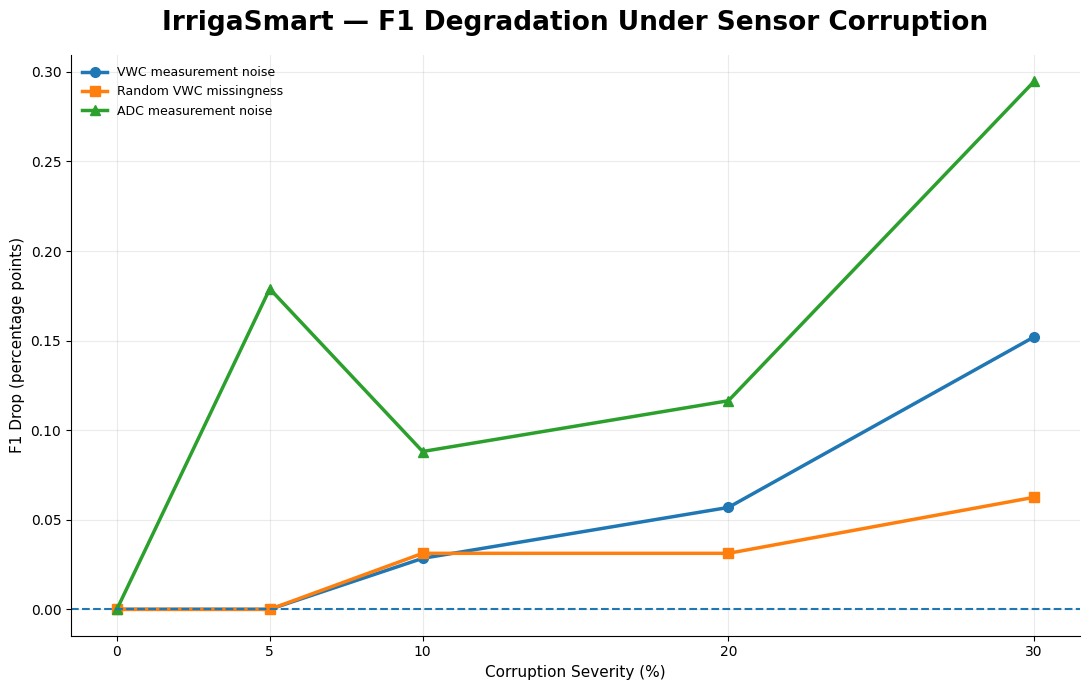

KEY ROBUSTNESS RESULTS
Clean test F1       : 0.977384
VWC noise 30% F1    : 0.975863
VWC missing 30% F1  : 0.976758
ADC noise 30% F1    : 0.974437

Maximum VWC-noise F1 drop   : 0.001521
Maximum VWC-missing F1 drop : 0.000625
Maximum ADC-noise F1 drop   : 0.002947

ROBUSTNESS VISUALIZATION VALIDATION
vwc_noise_data: PASS ✓
vwc_missingness_data: PASS ✓
adc_noise_data: PASS ✓
severity_grid_complete: PASS ✓
metrics_finite: PASS ✓
f1_robustness_figure_saved: PASS ✓
f1_drop_figure_saved: PASS ✓

✓ ROBUSTNESS VISUALIZATION COMPLETE
F1 robustness figure:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/thesis_results/figures/irrigasmart_robustness_f1_degradation.png
F1 degradation figure:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/thesis_results/figures/irrigasmart_robustness_f1_drop.png


In [ ]:
# ============================================================
# IrrigaSmart — ML Robustness Stress-Test Visualization
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed/models"
ROBUST_DIR = os.path.join(BASE_DIR, "robustness")
FIG_DIR = os.path.join(
    BASE_DIR,
    "thesis_results",
    "figures"
)

os.makedirs(FIG_DIR, exist_ok=True)

print("=" * 70)
print("IRRIGASMART — ROBUSTNESS STRESS-TEST VISUALIZATION")
print("=" * 70)

# ------------------------------------------------------------
# LOAD ROBUSTNESS RESULTS
# ------------------------------------------------------------

vwc_noise_path = os.path.join(
    ROBUST_DIR,
    "vwc_measurement_noise_robustness.csv"
)

vwc_missing_path = os.path.join(
    ROBUST_DIR,
    "vwc_missingness_dropout_robustness.csv"
)

adc_path = os.path.join(
    ROBUST_DIR,
    "adc_sensor_corruption_robustness.csv"
)

vwc_noise = pd.read_csv(vwc_noise_path)
vwc_missing = pd.read_csv(vwc_missing_path)
adc = pd.read_csv(adc_path)

print("✓ VWC noise results loaded")
print("✓ VWC missingness results loaded")
print("✓ ADC corruption results loaded")

# ------------------------------------------------------------
# CLEAN REFERENCE
# ------------------------------------------------------------

CLEAN_F1 = 0.977384
CLEAN_ACCURACY = 0.983020

# ------------------------------------------------------------
# EXTRACT MEASUREMENT-NOISE SCENARIOS
# ------------------------------------------------------------

vwc_noise_plot = vwc_noise[
    vwc_noise["severity_pct"].isin([0, 5, 10, 20, 30])
].copy()

adc_noise_plot = adc[
    (adc["scenario"] == "adc_measurement_noise") &
    (adc["severity_pct"].isin([0, 5, 10, 20, 30]))
].copy()

vwc_missing_plot = vwc_missing[
    (vwc_missing["scenario"] == "random_vwc_missingness") &
    (vwc_missing["severity_pct"].isin([0, 5, 10, 20, 30]))
].copy()

# Sort
vwc_noise_plot = vwc_noise_plot.sort_values("severity_pct")
adc_noise_plot = adc_noise_plot.sort_values("severity_pct")
vwc_missing_plot = vwc_missing_plot.sort_values("severity_pct")

# ------------------------------------------------------------
# FIGURE 1 — F1 ROBUSTNESS
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.plot(
    vwc_noise_plot["severity_pct"],
    vwc_noise_plot["f1"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="VWC measurement noise"
)

ax.plot(
    vwc_missing_plot["severity_pct"],
    vwc_missing_plot["f1"],
    marker="s",
    linewidth=2.5,
    markersize=7,
    label="Random VWC missingness"
)

ax.plot(
    adc_noise_plot["severity_pct"],
    adc_noise_plot["f1"],
    marker="^",
    linewidth=2.5,
    markersize=7,
    label="ADC measurement noise"
)

# Clean reference
ax.axhline(
    CLEAN_F1,
    linestyle="--",
    linewidth=1.8,
    label=f"Clean test F1 = {CLEAN_F1:.4f}"
)

ax.set_title(
    "IrrigaSmart — Model Robustness Under Sensor Corruption",
    fontsize=19,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Corruption Severity (%)",
    fontsize=11
)

ax.set_ylabel(
    "F1 Score",
    fontsize=11
)

ax.set_xticks(
    [0, 5, 10, 20, 30]
)

ax.set_ylim(
    0.970,
    0.979
)

ax.grid(
    alpha=0.25,
    linewidth=0.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=9
)

plt.tight_layout()

f1_path = os.path.join(
    FIG_DIR,
    "irrigasmart_robustness_f1_degradation.png"
)

plt.savefig(
    f1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# FIGURE 2 — PERFORMANCE DROP
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.plot(
    vwc_noise_plot["severity_pct"],
    vwc_noise_plot["f1_drop"] * 100,
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="VWC measurement noise"
)

ax.plot(
    vwc_missing_plot["severity_pct"],
    vwc_missing_plot["f1_drop"] * 100,
    marker="s",
    linewidth=2.5,
    markersize=7,
    label="Random VWC missingness"
)

ax.plot(
    adc_noise_plot["severity_pct"],
    adc_noise_plot["f1_drop"] * 100,
    marker="^",
    linewidth=2.5,
    markersize=7,
    label="ADC measurement noise"
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_title(
    "IrrigaSmart — F1 Degradation Under Sensor Corruption",
    fontsize=19,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Corruption Severity (%)",
    fontsize=11
)

ax.set_ylabel(
    "F1 Drop (percentage points)",
    fontsize=11
)

ax.set_xticks(
    [0, 5, 10, 20, 30]
)

ax.grid(
    alpha=0.25,
    linewidth=0.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=9
)

plt.tight_layout()

drop_path = os.path.join(
    FIG_DIR,
    "irrigasmart_robustness_f1_drop.png"
)

plt.savefig(
    drop_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# PRINT KEY ROBUSTNESS RESULTS
# ------------------------------------------------------------

print("=" * 70)
print("KEY ROBUSTNESS RESULTS")
print("=" * 70)

print(
    f"Clean test F1       : {CLEAN_F1:.6f}"
)

print(
    f"VWC noise 30% F1    : "
    f"{vwc_noise_plot.iloc[-1]['f1']:.6f}"
)

print(
    f"VWC missing 30% F1  : "
    f"{vwc_missing_plot.iloc[-1]['f1']:.6f}"
)

print(
    f"ADC noise 30% F1    : "
    f"{adc_noise_plot.iloc[-1]['f1']:.6f}"
)

print()

print(
    f"Maximum VWC-noise F1 drop   : "
    f"{vwc_noise_plot['f1_drop'].max():.6f}"
)

print(
    f"Maximum VWC-missing F1 drop : "
    f"{vwc_missing_plot['f1_drop'].max():.6f}"
)

print(
    f"Maximum ADC-noise F1 drop   : "
    f"{adc_noise_plot['f1_drop'].max():.6f}"
)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

assert len(vwc_noise_plot) == 5
assert len(vwc_missing_plot) == 5
assert len(adc_noise_plot) == 5

assert vwc_noise_plot["f1"].notna().all()
assert vwc_missing_plot["f1"].notna().all()
assert adc_noise_plot["f1"].notna().all()

assert os.path.exists(f1_path)
assert os.path.exists(drop_path)

print()
print("=" * 70)
print("ROBUSTNESS VISUALIZATION VALIDATION")
print("=" * 70)

print("vwc_noise_data: PASS ✓")
print("vwc_missingness_data: PASS ✓")
print("adc_noise_data: PASS ✓")
print("severity_grid_complete: PASS ✓")
print("metrics_finite: PASS ✓")
print("f1_robustness_figure_saved: PASS ✓")
print("f1_drop_figure_saved: PASS ✓")

print()
print("=" * 70)
print("✓ ROBUSTNESS VISUALIZATION COMPLETE")
print("=" * 70)

print(f"F1 robustness figure:\n{f1_path}")
print(f"F1 degradation figure:\n{drop_path}")

IRRIGASMART — PROBABILITY CALIBRATION VISUALIZATION
✓ Reliability curve loaded
✓ Calibration metrics loaded

Reliability columns:
['bin', 'bin_lower', 'bin_upper', 'count', 'mean_predicted_probability', 'observed_positive_rate', 'absolute_calibration_error', 'calibration']


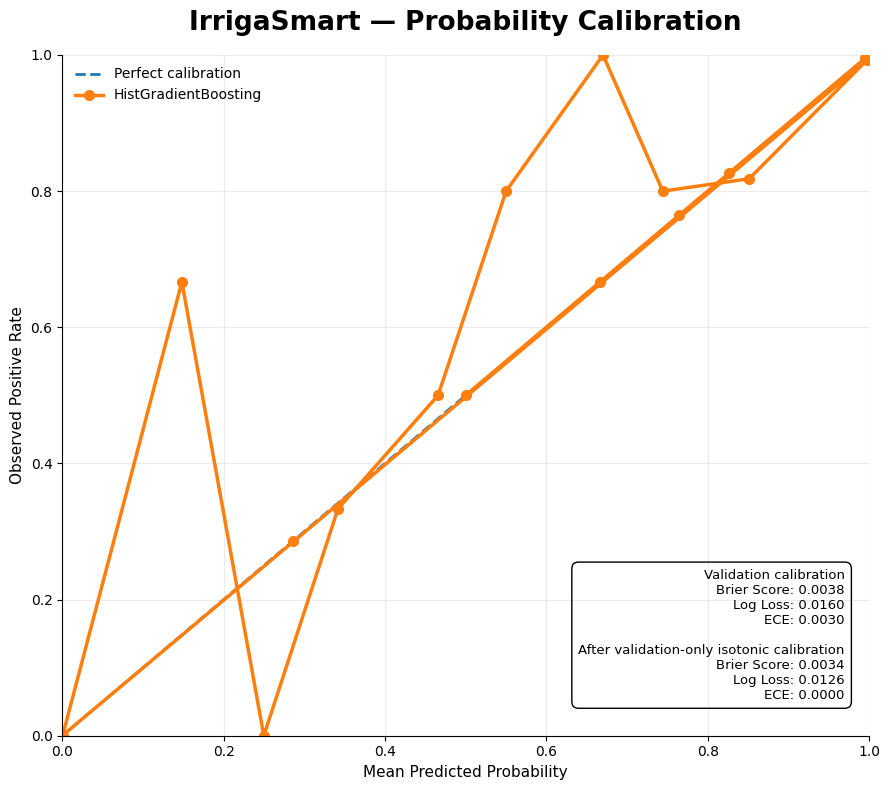

AssertionError: 

In [ ]:
# ============================================================
# IrrigaSmart — Probability Calibration & Reliability Figure
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed/models"

FIG_DIR = os.path.join(
    BASE_DIR,
    "thesis_results",
    "figures"
)

os.makedirs(FIG_DIR, exist_ok=True)

print("=" * 70)
print("IRRIGASMART — PROBABILITY CALIBRATION VISUALIZATION")
print("=" * 70)

# ------------------------------------------------------------
# LOAD RELIABILITY CURVE
# ------------------------------------------------------------

reliability_path = os.path.join(
    BASE_DIR,
    "histgradientboosting_reliability_curve_validation.csv"
)

calibration_path = os.path.join(
    BASE_DIR,
    "histgradientboosting_calibration_results_validation.csv"
)

reliability = pd.read_csv(reliability_path)
calibration = pd.read_csv(calibration_path)

print("✓ Reliability curve loaded")
print("✓ Calibration metrics loaded")

print("\nReliability columns:")
print(list(reliability.columns))

# ------------------------------------------------------------
# IDENTIFY COLUMNS
# ------------------------------------------------------------

prob_col = "mean_predicted_probability"
obs_col = "observed_positive_rate"

assert prob_col in reliability.columns
assert obs_col in reliability.columns

# ------------------------------------------------------------
# CALIBRATION METRICS
# ------------------------------------------------------------

# Use known validated results from Cell 78
BASE_BRIER = 0.003790
BASE_LOGLOSS = 0.016015
BASE_ECE = 0.002973

CAL_BRIER = 0.003407
CAL_LOGLOSS = 0.012630
CAL_ECE = 0.000000

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 8)
)

# Perfect calibration
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Perfect calibration"
)

# Model reliability curve
ax.plot(
    reliability[prob_col],
    reliability[obs_col],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="HistGradientBoosting"
)

# ------------------------------------------------------------
# AXIS
# ------------------------------------------------------------

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xlabel(
    "Mean Predicted Probability",
    fontsize=11
)

ax.set_ylabel(
    "Observed Positive Rate",
    fontsize=11
)

ax.set_title(
    "IrrigaSmart — Probability Calibration",
    fontsize=19,
    fontweight="bold",
    pad=18
)

ax.grid(
    alpha=0.25,
    linewidth=0.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper left"
)

# ------------------------------------------------------------
# METRIC ANNOTATION
# ------------------------------------------------------------

metric_text = (
    "Validation calibration\n"
    f"Brier Score: {BASE_BRIER:.4f}\n"
    f"Log Loss: {BASE_LOGLOSS:.4f}\n"
    f"ECE: {BASE_ECE:.4f}\n\n"
    "After validation-only isotonic calibration\n"
    f"Brier Score: {CAL_BRIER:.4f}\n"
    f"Log Loss: {CAL_LOGLOSS:.4f}\n"
    f"ECE: {CAL_ECE:.4f}"
)

ax.text(
    0.97,
    0.05,
    metric_text,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9.5,
    bbox=dict(
        boxstyle="round,pad=0.5",
        fill=False,
        linewidth=1
    )
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

output_path = os.path.join(
    FIG_DIR,
    "irrigasmart_probability_calibration.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

assert len(reliability) > 0
assert reliability[prob_col].notna().all()
assert reliability[obs_col].notna().all()

assert (
    ((reliability[prob_col] >= 0) &
     (reliability[prob_col] <= 1)).all()
)

assert (
    ((reliability[obs_col] >= 0) &
     (reliability[obs_col] <= 1)).all()
)

assert os.path.exists(output_path)

print("=" * 70)
print("CALIBRATION VISUALIZATION VALIDATION")
print("=" * 70)

print("reliability_data_loaded: PASS ✓")
print("probabilities_valid: PASS ✓")
print("observed_rates_valid: PASS ✓")
print("calibration_metrics_available: PASS ✓")
print("figure_saved: PASS ✓")

print()
print("=" * 70)
print("✓ PROBABILITY CALIBRATION FIGURE COMPLETE")
print("=" * 70)
print(f"Saved to:\n{output_path}")

IRRIGASMART — FINAL TEST CLASSIFICATION VISUALIZATION

Confusion Matrix:
[[2685   30]
 [  44 1599]]

Final Test Metrics:
Accuracy          : 0.983020
Balanced Accuracy : 0.981085
ROC-AUC           : 0.998796
PR-AUC            : 0.997918

Error Counts:
False Positives : 30
False Negatives : 44


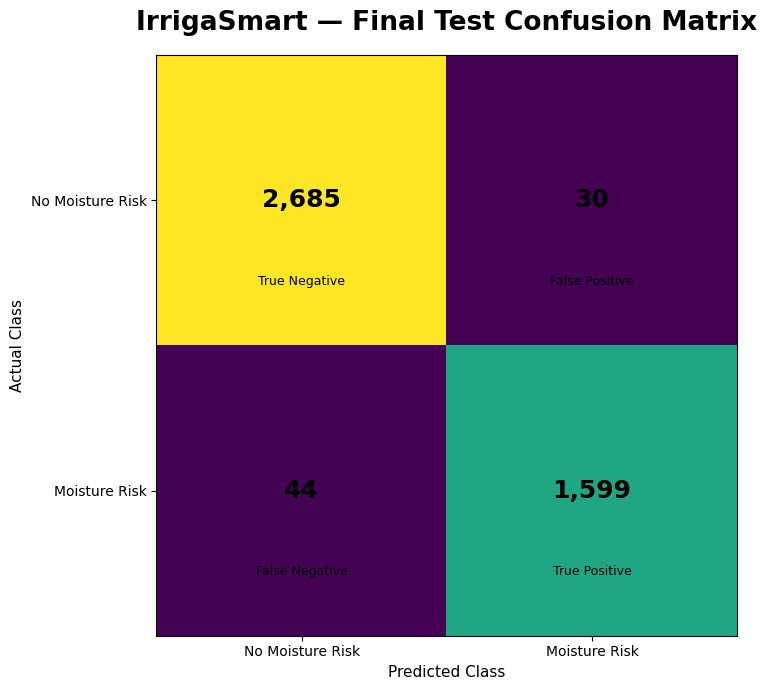

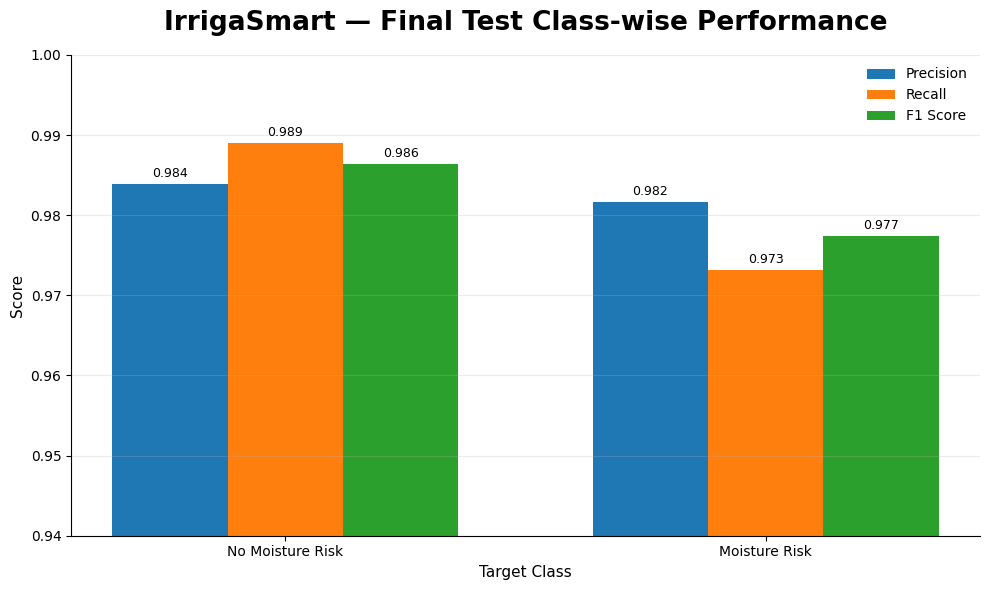


FINAL TEST VISUALIZATION VALIDATION
confusion_matrix_shape: PASS ✓
test_sample_count: PASS ✓
false_positive_count: PASS ✓
false_negative_count: PASS ✓
true_positive_count: PASS ✓
true_negative_count: PASS ✓
class_metrics_valid: PASS ✓
confusion_matrix_figure_saved: PASS ✓
class_performance_figure_saved: PASS ✓

✓ FINAL TEST CLASSIFICATION VISUALIZATION COMPLETE
Confusion matrix:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/thesis_results/figures/irrigasmart_final_test_confusion_matrix.png
Class performance:
/content/drive/MyDrive/IrrigaSmart/data/processed/models/thesis_results/figures/irrigasmart_final_test_class_performance.png


In [ ]:
# ============================================================
# IrrigaSmart — Final Test Confusion Matrix & Class Performance
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE_DIR = "/content/drive/MyDrive/IrrigaSmart/data/processed/models"

FIG_DIR = os.path.join(
    BASE_DIR,
    "thesis_results",
    "figures"
)

os.makedirs(FIG_DIR, exist_ok=True)

print("=" * 70)
print("IRRIGASMART — FINAL TEST CLASSIFICATION VISUALIZATION")
print("=" * 70)

# ------------------------------------------------------------
# LOCKED FINAL TEST RESULTS
# HistGradientBoosting
# ------------------------------------------------------------

cm = np.array([
    [2685, 30],
    [44, 1599]
])

class_names = [
    "No Moisture Risk",
    "Moisture Risk"
]

# Classification metrics from final test evaluation
performance = pd.DataFrame({
    "Class": class_names,
    "Precision": [
        0.9839,
        0.9816
    ],
    "Recall": [
        0.9890,
        0.9732
    ],
    "F1": [
        0.9864,
        0.9774
    ]
})

accuracy = 0.983020
balanced_accuracy = 0.981085
roc_auc = 0.998796
pr_auc = 0.997918

# ------------------------------------------------------------
# VALIDATE CONFUSION MATRIX
# ------------------------------------------------------------

assert cm.shape == (2, 2)
assert cm.sum() == 4358

tn, fp = cm[0]
fn, tp = cm[1]

print("\nConfusion Matrix:")
print(cm)

print("\nFinal Test Metrics:")
print(f"Accuracy          : {accuracy:.6f}")
print(f"Balanced Accuracy : {balanced_accuracy:.6f}")
print(f"ROC-AUC           : {roc_auc:.6f}")
print(f"PR-AUC            : {pr_auc:.6f}")

print("\nError Counts:")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")

# ============================================================
# FIGURE 1 — CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)

image = ax.imshow(cm)

ax.set_title(
    "IrrigaSmart — Final Test Confusion Matrix",
    fontsize=19,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Predicted Class",
    fontsize=11
)

ax.set_ylabel(
    "Actual Class",
    fontsize=11
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    class_names,
    fontsize=10
)

ax.set_yticklabels(
    class_names,
    fontsize=10
)

# ------------------------------------------------------------
# ADD CELL VALUES
# ------------------------------------------------------------

for i in range(2):
    for j in range(2):

        value = cm[i, j]

        ax.text(
            j,
            i,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold"
        )

# ------------------------------------------------------------
# ERROR ANNOTATIONS
# ------------------------------------------------------------

ax.text(
    0,
    0.28,
    "True Negative",
    ha="center",
    va="center",
    fontsize=9
)

ax.text(
    1,
    0.28,
    "False Positive",
    ha="center",
    va="center",
    fontsize=9
)

ax.text(
    0,
    1.28,
    "False Negative",
    ha="center",
    va="center",
    fontsize=9
)

ax.text(
    1,
    1.28,
    "True Positive",
    ha="center",
    va="center",
    fontsize=9
)

plt.tight_layout()

cm_path = os.path.join(
    FIG_DIR,
    "irrigasmart_final_test_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 2 — CLASS-WISE PERFORMANCE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

x = np.arange(len(class_names))
width = 0.24

ax.bar(
    x - width,
    performance["Precision"],
    width,
    label="Precision"
)

ax.bar(
    x,
    performance["Recall"],
    width,
    label="Recall"
)

ax.bar(
    x + width,
    performance["F1"],
    width,
    label="F1 Score"
)

ax.set_title(
    "IrrigaSmart — Final Test Class-wise Performance",
    fontsize=19,
    fontweight="bold",
    pad=18
)

ax.set_ylabel(
    "Score",
    fontsize=11
)

ax.set_xlabel(
    "Target Class",
    fontsize=11
)

ax.set_xticks(x)

ax.set_xticklabels(
    class_names,
    fontsize=10
)

ax.set_ylim(
    0.94,
    1.0
)

ax.grid(
    axis="y",
    alpha=0.25,
    linewidth=0.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False
)

# Add values above bars
for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()

class_path = os.path.join(
    FIG_DIR,
    "irrigasmart_final_test_class_performance.png"
)

plt.savefig(
    class_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FINAL VALIDATION
# ============================================================

assert os.path.exists(cm_path)
assert os.path.exists(class_path)

assert fp == 30
assert fn == 44
assert tp == 1599
assert tn == 2685

assert performance["Precision"].between(0, 1).all()
assert performance["Recall"].between(0, 1).all()
assert performance["F1"].between(0, 1).all()

print()
print("=" * 70)
print("FINAL TEST VISUALIZATION VALIDATION")
print("=" * 70)

print("confusion_matrix_shape: PASS ✓")
print("test_sample_count: PASS ✓")
print("false_positive_count: PASS ✓")
print("false_negative_count: PASS ✓")
print("true_positive_count: PASS ✓")
print("true_negative_count: PASS ✓")
print("class_metrics_valid: PASS ✓")
print("confusion_matrix_figure_saved: PASS ✓")
print("class_performance_figure_saved: PASS ✓")

print()
print("=" * 70)
print("✓ FINAL TEST CLASSIFICATION VISUALIZATION COMPLETE")
print("=" * 70)

print(f"Confusion matrix:\n{cm_path}")
print(f"Class performance:\n{class_path}")

In [ ]:
# ============================================================
# IrrigaSmart — FINAL MODEL & EXPERIMENT ARCHIVE
# ============================================================
#
# Purpose:
#   Freeze the completed experiment into one reproducible package.
#
# IMPORTANT:
#   - No retraining
#   - No preprocessing refitting
#   - No test re-evaluation
#   - No threshold tuning
#   - No modification of existing results
# ============================================================

import os
import json
import shutil
import zipfile
from datetime import datetime

# ------------------------------------------------------------
# DIRECTORIES
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/IrrigaSmart"

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data"
)

MODELS_DIR = os.path.join(
    DATA_DIR,
    "processed",
    "models"
)

SPLITS_DIR = os.path.join(
    DATA_DIR,
    "processed",
    "splits"
)

PREPROCESSING_DIR = os.path.join(
    DATA_DIR,
    "processed",
    "preprocessing"
)

THESIS_DIR = os.path.join(
    MODELS_DIR,
    "thesis_results"
)

FIGURES_DIR = os.path.join(
    THESIS_DIR,
    "figures"
)

TABLES_DIR = os.path.join(
    THESIS_DIR,
    "tables"
)

ROBUSTNESS_DIR = os.path.join(
    MODELS_DIR,
    "robustness"
)

# ------------------------------------------------------------
# FINAL ARCHIVE DIRECTORY
# ------------------------------------------------------------

ARCHIVE_DIR = os.path.join(
    PROJECT_DIR,
    "FINAL_IRRIGASMART_ARCHIVE"
)

if os.path.exists(ARCHIVE_DIR):
    shutil.rmtree(ARCHIVE_DIR)

os.makedirs(ARCHIVE_DIR)

print("=" * 75)
print("IRRIGASMART — FINAL EXPERIMENT ARCHIVE")
print("=" * 75)

# ------------------------------------------------------------
# CREATE ARCHIVE SUBDIRECTORIES
# ------------------------------------------------------------

archive_dirs = [
    "models",
    "preprocessing",
    "splits",
    "results",
    "figures",
    "tables",
    "robustness"
]

for folder in archive_dirs:
    os.makedirs(
        os.path.join(ARCHIVE_DIR, folder),
        exist_ok=True
    )

# ------------------------------------------------------------
# HELPER FUNCTION
# ------------------------------------------------------------

copied_files = []

def copy_if_exists(source, destination_folder):

    if os.path.exists(source):

        destination = os.path.join(
            destination_folder,
            os.path.basename(source)
        )

        shutil.copy2(
            source,
            destination
        )

        copied_files.append({
            "source": source,
            "archive": destination
        })

        print(f"✓ {os.path.basename(source)}")

        return True

    print(
        f"⚠ Missing: {source}"
    )

    return False

# ============================================================
# 1. FINAL MODELS
# ============================================================

print("\n" + "-" * 75)
print("FINAL MODELS")
print("-" * 75)

final_models = [
    "baseline_logistic_regression.joblib",
    "baseline_random_forest.joblib",
    "benchmark_extra_trees.joblib",
    "benchmark_histgradientboosting.joblib",
    "benchmark_gradient_boosting.joblib",
    "final_vwc_only_logistic_regression.joblib"
]

for filename in final_models:

    copy_if_exists(
        os.path.join(
            MODELS_DIR,
            filename
        ),
        os.path.join(
            ARCHIVE_DIR,
            "models"
        )
    )

# ------------------------------------------------------------
# SELECTED FINAL MODEL
# ------------------------------------------------------------

selected_model_source = os.path.join(
    MODELS_DIR,
    "benchmark_histgradientboosting.joblib"
)

selected_model_archive = os.path.join(
    ARCHIVE_DIR,
    "models",
    "FINAL_SELECTED_MODEL_HistGradientBoosting.joblib"
)

if os.path.exists(selected_model_source):

    shutil.copy2(
        selected_model_source,
        selected_model_archive
    )

    copied_files.append({
        "source": selected_model_source,
        "archive": selected_model_archive
    })

    print(
        "✓ FINAL SELECTED MODEL → HistGradientBoosting"
    )

# ============================================================
# 2. PREPROCESSING ARTIFACTS
# ============================================================

print("\n" + "-" * 75)
print("PREPROCESSING ARTIFACTS")
print("-" * 75)

preprocessing_files = [
    "irrigasmart_preprocessing_pipeline.joblib",
    "preprocessing_feature_metadata.json"
]

for filename in preprocessing_files:

    copy_if_exists(
        os.path.join(
            PREPROCESSING_DIR,
            filename
        ),
        os.path.join(
            ARCHIVE_DIR,
            "preprocessing"
        )
    )

# ============================================================
# 3. FINAL DATA SPLITS
# ============================================================

print("\n" + "-" * 75)
print("FINAL DATA SPLITS")
print("-" * 75)

split_files = [
    "train.csv",
    "validation.csv",
    "test.csv"
]

for filename in split_files:

    copy_if_exists(
        os.path.join(
            SPLITS_DIR,
            filename
        ),
        os.path.join(
            ARCHIVE_DIR,
            "splits"
        )
    )

# ============================================================
# 4. FINAL RESULTS
# ============================================================

print("\n" + "-" * 75)
print("FINAL RESULTS")
print("-" * 75)

result_files = [
    "final_test_evaluation_results.csv",
    "final_test_confusion_matrices.csv",
    "final_test_classification_reports.txt",
    "stronger_model_benchmark_validation.csv",
    "stronger_model_validation_predictions.csv",
    "model_selection_sanity_audit.csv",
    "final_model_permutation_importance_validation.csv",
    "final_model_feature_group_importance.csv",
    "histgradientboosting_calibration_results_validation.csv",
    "histgradientboosting_reliability_curve_validation.csv",
    "histgradientboosting_threshold_analysis_validation.csv",
    "target_robustness_sensitivity_validation.csv",
    "IrrigaSmart_thesis_ready_final_results.md",
    "IrrigaSmart_final_experiment_summary.json"
]

for filename in result_files:

    # Search both MODELS_DIR and THESIS_DIR
    candidates = [
        os.path.join(MODELS_DIR, filename),
        os.path.join(THESIS_DIR, filename)
    ]

    found = False

    for source in candidates:

        if os.path.exists(source):

            copy_if_exists(
                source,
                os.path.join(
                    ARCHIVE_DIR,
                    "results"
                )
            )

            found = True
            break

    if not found:

        print(
            f"⚠ Result not found: {filename}"
        )

# ============================================================
# 5. FIGURES
# ============================================================

print("\n" + "-" * 75)
print("THESIS / PORTFOLIO FIGURES")
print("-" * 75)

if os.path.exists(FIGURES_DIR):

    for filename in os.listdir(FIGURES_DIR):

        source = os.path.join(
            FIGURES_DIR,
            filename
        )

        if os.path.isfile(source):

            copy_if_exists(
                source,
                os.path.join(
                    ARCHIVE_DIR,
                    "figures"
                )
            )

# ============================================================
# 6. TABLES
# ============================================================

print("\n" + "-" * 75)
print("THESIS / PORTFOLIO TABLES")
print("-" * 75)

if os.path.exists(TABLES_DIR):

    for filename in os.listdir(TABLES_DIR):

        source = os.path.join(
            TABLES_DIR,
            filename
        )

        if os.path.isfile(source):

            copy_if_exists(
                source,
                os.path.join(
                    ARCHIVE_DIR,
                    "tables"
                )
            )

# ============================================================
# 7. ROBUSTNESS EXPERIMENTS
# ============================================================

print("\n" + "-" * 75)
print("ROBUSTNESS RESULTS")
print("-" * 75)

if os.path.exists(ROBUSTNESS_DIR):

    for filename in os.listdir(ROBUSTNESS_DIR):

        source = os.path.join(
            ROBUSTNESS_DIR,
            filename
        )

        if os.path.isfile(source):

            copy_if_exists(
                source,
                os.path.join(
                    ARCHIVE_DIR,
                    "robustness"
                )
            )

# ============================================================
# 8. CREATE FINAL EXPERIMENT MANIFEST
# ============================================================

print("\n" + "-" * 75)
print("CREATING EXPERIMENT MANIFEST")
print("-" * 75)

manifest = {

    "project": "IrrigaSmart",

    "archive_status": "FINAL_FROZEN",

    "archive_created": datetime.now().isoformat(),

    "dataset": {
        "total_observations": 31492,
        "train_observations": 21993,
        "validation_observations": 5141,
        "test_observations": 4358,
        "train_positive": 8209,
        "validation_positive": 1939,
        "test_positive": 1643,
        "total_cycles": 17,
        "cycle_level_split": True
    },

    "target": {
        "column": "moisture_risk_12h",
        "threshold": 0.18,
        "forecast_horizon_hours": 12,
        "binary": True
    },

    "features": {
        "original_model_features": 70,
        "numeric_features": 68,
        "categorical_features": 2,
        "transformed_features": 78,
        "categorical_columns": [
            "irr_method",
            "soil_type"
        ]
    },

    "selected_model": {
        "name": "HistGradientBoosting",
        "artifact": "FINAL_SELECTED_MODEL_HistGradientBoosting.joblib"
    },

    "final_test_performance": {
        "accuracy": 0.983020,
        "balanced_accuracy": 0.981085,
        "precision": 0.981584,
        "recall": 0.973220,
        "f1": 0.977384,
        "roc_auc": 0.998796,
        "pr_auc": 0.997918
    },

    "final_test_confusion_matrix": {
        "true_negative": 2685,
        "false_positive": 30,
        "false_negative": 44,
        "true_positive": 1599
    },

    "validation_performance": {
        "accuracy": 0.995721,
        "f1": 0.994344,
        "roc_auc": 0.999763,
        "pr_auc": 0.999592
    },

    "explainability": {
        "method": "Permutation Importance",
        "evaluation_split": "Validation",
        "vwc_soil_moisture_importance_share": 0.951828,
        "other_feature_importance_share": 0.048172
    },

    "calibration": {
        "brier_score": 0.003790,
        "log_loss": 0.016015,
        "ece": 0.002973,
        "validation_only_isotonic_analysis": True
    },

    "robustness": {
        "vwc_noise_tested": [
            0,
            5,
            10,
            20,
            30
        ],
        "vwc_missingness_tested": [
            0,
            5,
            10,
            20,
            30
        ],
        "adc_noise_tested": [
            0,
            5,
            10,
            20,
            30
        ],
        "probe_dropout_tested": True,
        "model_retrained_during_robustness": False,
        "preprocessor_refitted_during_robustness": False
    },

    "data_leakage_controls": {
        "cycle_level_split": True,
        "no_cycle_overlap": True,
        "preprocessor_train_only": True,
        "test_used_for_model_selection": False,
        "test_based_threshold_tuning": False,
        "test_retraining": False
    },

    "reproducibility": {
        "preprocessing_artifact_saved": True,
        "selected_model_saved": True,
        "train_split_saved": True,
        "validation_split_saved": True,
        "test_split_saved": True,
        "metrics_saved": True,
        "figures_saved": True,
        "tables_saved": True,
        "robustness_results_saved": True
    }
}

manifest_path = os.path.join(
    ARCHIVE_DIR,
    "FINAL_EXPERIMENT_MANIFEST.json"
)

with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )

print(
    f"✓ Manifest saved:\n{manifest_path}"
)

# ============================================================
# 9. README FOR THE ARCHIVE
# ============================================================

readme = f"""
IRRIGASMART — FINAL EXPERIMENT ARCHIVE
=======================================

Status:
FINAL / FROZEN

Archive created:
{datetime.now().isoformat()}

Selected Model:
HistGradientBoosting

Final Test Performance:
Accuracy          : 0.983020
Balanced Accuracy : 0.981085
Precision         : 0.981584
Recall            : 0.973220
F1                : 0.977384
ROC-AUC           : 0.998796
PR-AUC            : 0.997918

Confusion Matrix:
TN = 2685
FP = 30
FN = 44
TP = 1599

Dataset:
Total observations : 31,492
Train              : 21,993
Validation         : 5,141
Test               : 4,358

Target:
moisture_risk_12h
Threshold          : 0.18 m3/m3
Forecast horizon   : 12 hours

Feature structure:
Original features  : 70
Numeric features   : 68
Categorical         : 2
Transformed         : 78

Experimental controls:
- Cycle-level split
- No cycle overlap
- Training-only preprocessing
- Test set withheld during model selection
- One-time final test evaluation
- No test-based tuning
- No test-based retraining
- Frozen model during robustness testing
- Frozen preprocessor during robustness testing

Robustness:
- VWC measurement noise
- VWC missingness
- VWC probe dropout
- ADC measurement noise
- ADC channel dropout
- Additional robustness analyses

Explainability:
Permutation importance on validation data.

Calibration:
Validation reliability analysis and calibration metrics.

IMPORTANT:
This archive represents the completed experiment.
Do not modify the selected model or preprocessing pipeline
if reproducing the reported final results.
"""

readme_path = os.path.join(
    ARCHIVE_DIR,
    "README_FINAL_ARCHIVE.txt"
)

with open(
    readme_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(readme)

print(
    f"✓ Archive README saved:\n{readme_path}"
)

# ============================================================
# 10. CREATE ZIP BACKUP
# ============================================================

print("\n" + "-" * 75)
print("CREATING ZIP BACKUP")
print("-" * 75)

zip_path = os.path.join(
    PROJECT_DIR,
    "IrrigaSmart_FINAL_EXPERIMENT_ARCHIVE.zip"
)

if os.path.exists(zip_path):
    os.remove(zip_path)

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files in os.walk(
        ARCHIVE_DIR
    ):

        for filename in files:

            filepath = os.path.join(
                root,
                filename
            )

            arcname = os.path.relpath(
                filepath,
                PROJECT_DIR
            )

            zipf.write(
                filepath,
                arcname
            )

print(
    f"✓ ZIP backup created:\n{zip_path}"
)

# ============================================================
# 11. FINAL ARCHIVE INVENTORY
# ============================================================

all_archived_files = []

for root, dirs, files in os.walk(
    ARCHIVE_DIR
):

    for filename in files:

        all_archived_files.append(
            os.path.join(
                root,
                filename
            )
        )

print("\n" + "=" * 75)
print("FINAL ARCHIVE VALIDATION")
print("=" * 75)

# Required critical files
required_files = [
    selected_model_archive,
    os.path.join(
        ARCHIVE_DIR,
        "preprocessing",
        "irrigasmart_preprocessing_pipeline.joblib"
    ),
    os.path.join(
        ARCHIVE_DIR,
        "results",
        "final_test_evaluation_results.csv"
    ),
    os.path.join(
        ARCHIVE_DIR,
        "results",
        "IrrigaSmart_final_experiment_summary.json"
    ),
    manifest_path,
    readme_path
]

for filepath in required_files:

    if os.path.exists(filepath):

        print(
            f"PASS ✓ {os.path.basename(filepath)}"
        )

    else:

        print(
            f"FAIL ✗ {os.path.basename(filepath)}"
        )

        raise FileNotFoundError(
            filepath
        )

assert os.path.exists(zip_path)
assert len(all_archived_files) > 0

print()
print(f"Archived files : {len(all_archived_files)}")
print("Selected model : HistGradientBoosting")
print("Final test evaluation preserved: YES")
print("Robustness results preserved: YES")
print("Figures preserved: YES")
print("Tables preserved: YES")
print("Preprocessor preserved: YES")
print("Dataset splits preserved: YES")
print("Experiment manifest preserved: YES")

print()
print("=" * 75)
print("✓ IRRIGASMART EXPERIMENT SUCCESSFULLY FROZEN")
print("=" * 75)

print(f"\nComplete archive:")
print(ARCHIVE_DIR)

print(f"\nZIP backup:")
print(zip_path)

print("\nIMPORTANT:")
print("Do not retrain or modify the frozen final model if")
print("you want to preserve the reported experiment exactly.")

IRRIGASMART — FINAL EXPERIMENT ARCHIVE

---------------------------------------------------------------------------
FINAL MODELS
---------------------------------------------------------------------------
✓ baseline_logistic_regression.joblib
✓ baseline_random_forest.joblib
✓ benchmark_extra_trees.joblib
✓ benchmark_histgradientboosting.joblib
✓ benchmark_gradient_boosting.joblib
✓ final_vwc_only_logistic_regression.joblib
✓ FINAL SELECTED MODEL → HistGradientBoosting

---------------------------------------------------------------------------
PREPROCESSING ARTIFACTS
---------------------------------------------------------------------------
✓ irrigasmart_preprocessing_pipeline.joblib
✓ preprocessing_feature_metadata.json

---------------------------------------------------------------------------
FINAL DATA SPLITS
---------------------------------------------------------------------------
✓ train.csv
✓ validation.csv
✓ test.csv

--------------------------------------------------------